In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import zipfile

zip_path = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/gtFine_trainvaltest.zip"
)

with zipfile.ZipFile(zip_path) as archive:
    masks = [
        name for name in archive.namelist()
        if name.startswith("gtFine/val/")
        and name.endswith("_gtFine_labelIds.png")
    ]

print("Validation class-ID masks:", len(masks))

Validation class-ID masks: 500


In [ ]:
from PIL import Image
import numpy as np

with zipfile.ZipFile(zip_path) as archive:
    with archive.open(sorted(masks)[0]) as file:
        mask = np.array(Image.open(file))

print("Mask shape:", mask.shape)
print("Data type:", mask.dtype)
print("Class IDs present:", np.unique(mask))

Mask shape: (1024, 2048)
Data type: uint8
Class IDs present: [ 1  2  3  4  7  8 11 13 17 20 21 23 24 26]


In [ ]:
# Original IDs, ordered by their corresponding class IDs 0–18
class_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

id_to_train_id = np.full(256, 255, dtype=np.uint8)

for train_id, original_id in enumerate(class_ids):
    id_to_train_id[original_id] = train_id

mask_train_ids = id_to_train_id[mask]

print("Converted IDs:", np.unique(mask_train_ids))
print("Dimensions unchanged:", mask.shape == mask_train_ids.shape)

Converted IDs: [  0   1   2   4   5   7   8  10  11  13 255]
Dimensions unchanged: True


In [ ]:
from pathlib import Path
import zipfile

data_folder = Path("/content/drive/MyDrive/ONEFORMER_DATA")

checks = [
    ("gtFine_trainvaltest.zip",
     "gtFine/val/", "_gtFine_labelIds.png"),
    ("leftImg8bit_trainvaltest.zip",
     "leftImg8bit/val/", "_leftImg8bit.png"),
]

for filename, prefix, suffix in checks:
    with zipfile.ZipFile(data_folder / filename) as archive:
        count = sum(
            name.startswith(prefix) and name.endswith(suffix)
            for name in archive.namelist()
        )
    print(filename, "— Validation files:", count)

gtFine_trainvaltest.zip — Validation files: 500


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ONEFORMER_DATA/leftImg8bit_trainvaltest.zip'

In [ ]:
from pathlib import Path

folder = Path("/content/drive/MyDrive/ONEFORMER_DATA")

for item in sorted(folder.iterdir()):
    print(item.name)

gtFine_trainvaltest.zip
leftImg8bit_trainvaltest.zip


In [ ]:
import zipfile

data_folder = Path("/content/drive/MyDrive/ONEFORMER_DATA")

checks = [
    ("gtFine_trainvaltest.zip",
     "gtFine/val/", "_gtFine_labelIds.png"),
    ("leftImg8bit_trainvaltest.zip",
     "leftImg8bit/val/", "_leftImg8bit.png"),
]

for filename, prefix, suffix in checks:
    with zipfile.ZipFile(data_folder / filename) as archive:
        count = sum(
            name.startswith(prefix) and name.endswith(suffix)
            for name in archive.namelist()
        )
    print(filename, "— Validation files:", count)

gtFine_trainvaltest.zip — Validation files: 500
leftImg8bit_trainvaltest.zip — Validation files: 500


In [ ]:
from pathlib import Path
import zipfile
from tqdm.auto import tqdm

data_folder = Path("/content/drive/MyDrive/ONEFORMER_DATA")
destination = Path("/content/cityscapes")
destination.mkdir(parents=True, exist_ok=True)

for filename, prefix in [
    ("gtFine_trainvaltest.zip", "gtFine/val/"),
    ("leftImg8bit_trainvaltest.zip", "leftImg8bit/val/"),
]:
    with zipfile.ZipFile(data_folder / filename) as archive:
        files = [
            name for name in archive.namelist()
            if name.startswith(prefix) and not name.endswith("/")
        ]

        for name in tqdm(files, desc=prefix):
            archive.extract(name, destination)

print("Validation data extracted successfully!")

gtFine/val/:   0%|          | 0/2000 [00:00<?, ?it/s]

leftImg8bit/val/:   0%|          | 0/500 [00:00<?, ?it/s]

Validation data extracted successfully!


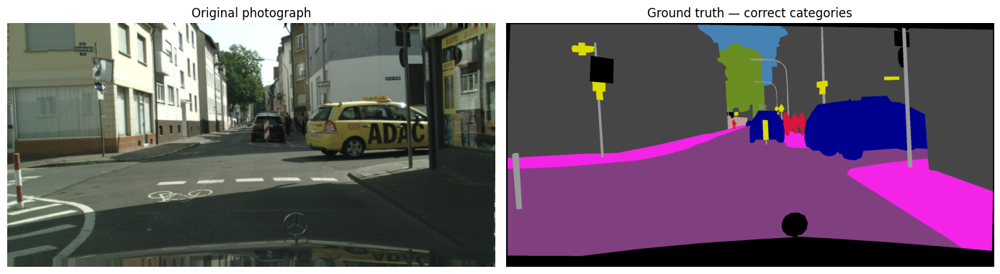

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

root = Path("/content/cityscapes")

image_paths = sorted(
    (root / "leftImg8bit/val").glob("*/*_leftImg8bit.png")
)

image_path = image_paths[0]
scene_name = image_path.name.replace("_leftImg8bit.png", "")

annotation_folder = root / "gtFine/val" / image_path.parent.name
mask_path = annotation_folder / f"{scene_name}_gtFine_labelIds.png"
colour_path = annotation_folder / f"{scene_name}_gtFine_color.png"

image = Image.open(image_path).convert("RGB")
label_mask = Image.open(mask_path)
colour_mask = Image.open(colour_path).convert("RGB")

assert image.size == label_mask.size, "Image and mask sizes differ!"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(image)
axes[0].set_title("Original photograph")

axes[1].imshow(colour_mask)
axes[1].set_title("Ground truth — correct categories")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import transformers
from transformers import (
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

print("Transformers:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())
print("OneFormer imports successful!")

Transformers: 5.16.1
GPU available: True
OneFormer imports successful!


In [ ]:
MODEL_ID = "shi-labs/oneformer_cityscapes_swin_large"

processor = OneFormerProcessor.from_pretrained(MODEL_ID)

model = OneFormerForUniversalSegmentation.from_pretrained(MODEL_ID)
model = model.to("cuda").eval()

print("Model loaded!")
print("Device:", next(model.parameters()).device)
print("Number of classes:", model.config.num_labels)


preprocessor_config.json:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/77.7k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/812 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/802 [00:00<?, ?it/s]

[transformers] OneFormerForUniversalSegmentation LOAD REPORT from: shi-labs/oneformer_cityscapes_swin_large
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Co

model.safetensors: reconstructing file:   0%|          |  0.00B /  879MB            

model.safetensors: downloading bytes:           |  0.00B            

Model loaded!
Device: cuda:0
Number of classes: 19


In [ ]:
import numpy as np
inputs = processor(
    images=image,
    task_inputs=["semantic"],
    return_tensors="pt",
).to("cuda")

with torch.inference_mode():
    outputs = model(**inputs)

prediction = processor.post_process_semantic_segmentation(
    outputs,
    target_sizes=[(image.height, image.width)],
)[0].cpu().numpy()

print("Prediction completed!")
print("Prediction shape:", prediction.shape)
print("Predicted class IDs:", np.unique(prediction))

Prediction completed!
Prediction shape: (1024, 2048)
Predicted class IDs: [ 0  1  2  3  5  7  8  9 10 11 13]


In [ ]:
import numpy as np

print("Prediction shape:", prediction.shape)
print("Predicted class IDs:", np.unique(prediction))

Prediction shape: (1024, 2048)
Predicted class IDs: [ 0  1  2  3  5  7  8  9 10 11 13]


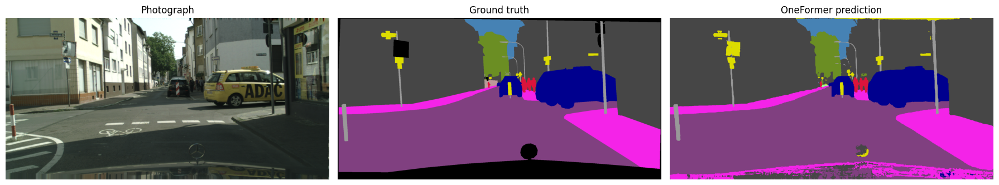

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cityscapes colours for model class IDs 0–18
palette = np.array([
    [128, 64, 128], [244, 35, 232], [70, 70, 70],
    [102, 102, 156], [190, 153, 153], [153, 153, 153],
    [250, 170, 30], [220, 220, 0], [107, 142, 35],
    [152, 251, 152], [70, 130, 180], [220, 20, 60],
    [255, 0, 0], [0, 0, 142], [0, 0, 70],
    [0, 60, 100], [0, 80, 100], [0, 0, 230],
    [119, 11, 32]
], dtype=np.uint8)

prediction_colour = palette[prediction]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, picture, title in zip(
    axes,
    [image, colour_mask, prediction_colour],
    ["Photograph", "Ground truth", "OneFormer prediction"]
):
    ax.imshow(picture)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from PIL import Image

# Read the matching original class-ID mask
ground_truth = np.array(Image.open(mask_path))

class_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

mapping = np.full(256, 255, dtype=np.uint8)
mapping[class_ids] = np.arange(19, dtype=np.uint8)
ground_truth = mapping[ground_truth]

assert prediction.shape == ground_truth.shape
assert np.all((prediction >= 0) & (prediction < 19))

valid = ground_truth != 255
true_ids = ground_truth[valid].astype(np.int64)
pred_ids = prediction[valid].astype(np.int64)

# Rows = correct classes; columns = predicted classes
confusion = np.bincount(
    19 * true_ids + pred_ids, minlength=19 * 19
).reshape(19, 19)

intersection = np.diag(confusion)
union = confusion.sum(axis=0) + confusion.sum(axis=1) - intersection

present = union > 0
ious = intersection[present] / union[present]

print(f"Single-image mIoU: {100 * ious.mean():.2f}%")
print("Classes included:", present.sum())

Single-image mIoU: 68.33%
Classes included: 12


In [ ]:
for class_id in range(19):
    if union[class_id] > 0:
        name = model.config.id2label[class_id]
        score = 100 * intersection[class_id] / union[class_id]
        print(f"{name:15s}: {score:6.2f}%")

road           :  98.89%
sidewalk       :  94.24%
building       :  98.04%
wall           :   0.00%
fence          :   0.00%
pole           :  79.31%
traffic sign   :  80.45%
vegetation     :  92.15%
terrain        :   0.00%
sky            :  95.65%
person         :  84.54%
car            :  96.67%


In [ ]:
import numpy as np
import torch
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

root = Path("/content/cityscapes")
image_paths = sorted(
    (root / "leftImg8bit/val").glob("*/*_leftImg8bit.png")
)
assert len(image_paths) == 500, "Expected 500 validation images."

class_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]
mapping = np.full(256, 255, dtype=np.uint8)
mapping[class_ids] = np.arange(19, dtype=np.uint8)

total_confusion = np.zeros((19, 19), dtype=np.int64)
model.eval()

for path in tqdm(image_paths, desc="Evaluating"):
    scene = path.name.replace("_leftImg8bit.png", "")
    target_path = (
        root / "gtFine/val" / path.parent.name
        / f"{scene}_gtFine_labelIds.png"
    )

    with Image.open(path) as source:
        current_image = source.convert("RGB")
    with Image.open(target_path) as source:
        target = mapping[np.array(source)]

    inputs = processor(
        images=current_image,
        task_inputs=["semantic"],
        return_tensors="pt",
    ).to("cuda")

    with torch.inference_mode():
        outputs = model(**inputs)
        pred = processor.post_process_semantic_segmentation(
            outputs,
            target_sizes=[target.shape],
        )[0].cpu().numpy()

    assert pred.shape == target.shape
    assert np.all((pred >= 0) & (pred < 19))

    valid = target != 255
    pairs = (
        19 * target[valid].astype(np.int64)
        + pred[valid].astype(np.int64)
    )
    total_confusion += np.bincount(
        pairs, minlength=19 * 19
    ).reshape(19, 19)

    del inputs, outputs

intersection = np.diag(total_confusion)
union = (
    total_confusion.sum(axis=0)
    + total_confusion.sum(axis=1)
    - intersection
)

assert np.all(union > 0), "Some evaluation classes have no union."
class_iou = intersection / union

# Save the numerical results in your project Drive
results_folder = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/results"
)
results_folder.mkdir(parents=True, exist_ok=True)

np.save(results_folder / "semantic_confusion.npy", total_confusion)
np.save(results_folder / "semantic_class_iou.npy", class_iou)

print(f"500-image validation mIoU: {100 * class_iou.mean():.2f}%")
print("Results saved to Drive.")

Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

500-image validation mIoU: 82.74%
Results saved to Drive.


In [ ]:
import json
import torch
import transformers
from datetime import datetime, timezone

run_details = {
    "recorded_at": datetime.now(timezone.utc).isoformat(),
    "model": MODEL_ID,
    "checkpoint_commit": getattr(model.config, "_commit_hash", None),
    "dataset": "Cityscapes validation",
    "images_evaluated": len(image_paths),
    "task": "semantic",
    "miou_percent": float(100 * class_iou.mean()),
    "class_iou_percent": {
        model.config.id2label[i]: float(100 * class_iou[i])
        for i in range(19)
    },
    "ignore_label": 255,
    "transformers_version": transformers.__version__,
    "pytorch_version": torch.__version__,
    "gpu": torch.cuda.get_device_name(0),
    "image_processor": processor.image_processor.to_dict(),
}

with open(results_folder / "semantic_run_details.json", "w") as file:
    json.dump(run_details, file, indent=2)

print("Experiment settings saved to Drive.")

Experiment settings saved to Drive.


In [ ]:
from pathlib import Path

instance_masks = sorted(
    Path("/content/cityscapes/gtFine/val").glob(
        "*/*_gtFine_instanceIds.png"
    )
)

print("Instance annotation masks:", len(instance_masks))
assert len(instance_masks) == 500, "Expected 500 instance masks."

Instance annotation masks: 500


In [ ]:
%pip install -q cityscapesscripts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.6/473.6 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.5 MB/s eta 0:00:00


In [ ]:
from importlib.metadata import version
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling as cityscapes_eval
)

print("Cityscapes tools version:", version("cityscapesscripts"))
print("Instance evaluator imported successfully!")

Cityscapes tools version: 2.2.4
Instance evaluator imported successfully!


In [ ]:
import torch
import inspect
from PIL import Image

with Image.open(image_paths[0]) as source:
    instance_image = source.convert("RGB")

instance_inputs = processor(
    images=instance_image,
    task_inputs=["instance"],
    return_tensors="pt",
).to("cuda")

with torch.inference_mode():
    instance_outputs = model(**instance_inputs)

print("Instance prediction completed!")

# Check the available options before exporting object masks
print(inspect.signature(
    processor.post_process_instance_segmentation
))

Instance prediction completed!
(*args, **kwargs)


In [ ]:
import inspect

print(inspect.signature(
    processor.image_processor.post_process_instance_segmentation
))

(outputs, task_type: str = 'instance', is_demo: bool = True, threshold: float = 0.5, mask_threshold: float = 0.5, overlap_mask_area_threshold: float = 0.8, target_sizes: list[tuple[int, int]] | None = None, return_coco_annotation: bool | None = False)


In [ ]:
with torch.inference_mode():
    instance_result = (
        processor.image_processor.post_process_instance_segmentation(
            instance_outputs,
            task_type="instance",
            is_demo=False,
            target_sizes=[
                (instance_image.height, instance_image.width)
            ],
        )[0]
    )

print("Returned fields:", list(instance_result.keys()))

for key, value in instance_result.items():
    if isinstance(value, torch.Tensor):
        print(key, "— shape:", tuple(value.shape))
    elif isinstance(value, list):
        print(key, "— entries:", len(value))
    else:
        print(key, "— type:", type(value).__name__)

Returned fields: ['segmentation', 'segments_info']
segmentation — shape: (1024, 2048)
segments_info — entries: 16


In [ ]:
print(
    "Class prediction shape:",
    tuple(instance_outputs.class_queries_logits.shape)
)

print(
    "Mask prediction shape:",
    tuple(instance_outputs.masks_queries_logits.shape)
)

print(
    "Processed image shape:",
    tuple(instance_inputs["pixel_values"].shape)
)

print("Original image size:", instance_image.size)

Class prediction shape: (1, 250, 20)
Mask prediction shape: (1, 250, 256, 512)
Processed image shape: (1, 3, 1024, 2048)
Original image size: (2048, 1024)


In [ ]:
import inspect

print(inspect.getsource(
    processor.image_processor.post_process_instance_segmentation
))

    def post_process_instance_segmentation(
        self,
        outputs,
        task_type: str = "instance",
        is_demo: bool = True,
        threshold: float = 0.5,
        mask_threshold: float = 0.5,
        overlap_mask_area_threshold: float = 0.8,
        target_sizes: list[tuple[int, int]] | None = None,
        return_coco_annotation: bool | None = False,
    ):
        """
        Converts the output of [`OneFormerForUniversalSegmentationOutput`] into image instance segmentation
        predictions. Only supports PyTorch.

        Args:
            outputs ([`OneFormerForUniversalSegmentationOutput`]):
                The outputs from [`OneFormerForUniversalSegmentationOutput`].
            task_type (`str`, *optional*, defaults to "instance"):
                The post processing depends on the task token input. If the `task_type` is "panoptic", we need to
                ignore the stuff predictions.
            is_demo (`bool`, *optional*, defaults to `True`):
       

In [ ]:
import inspect
from google.colab import files as colab_files

source = inspect.getsource(
    processor.image_processor.post_process_instance_segmentation
)

with open("/content/instance_postprocessing.txt", "w") as text_file:
    text_file.write(source)

colab_files.download("/content/instance_postprocessing.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torch.nn.functional as F
from cityscapesscripts.helpers.labels import labels as cityscapes_labels

# Model class IDs -> original Cityscapes object class IDs
thing_mapping = {
    label.trainId: label.id
    for label in cityscapes_labels
    if label.hasInstances and not label.ignoreInEval
}

@torch.inference_mode()
def prepare_instance_candidates(outputs, target_size):
    class_logits = outputs.class_queries_logits[0]
    mask_logits = outputs.masks_queries_logits[0]

    class_probs = class_logits.softmax(dim=-1)[:, :-1]
    num_queries, num_classes = class_probs.shape

    scores, indices = class_probs.flatten().topk(
        num_queries, sorted=True
    )
    class_ids = indices % num_classes
    query_ids = indices // num_classes

    candidates = []

    for score, class_id, query_id in zip(scores, class_ids, query_ids):
        train_id = int(class_id)
        if train_id not in thing_mapping:
            continue

        # Resize each mask separately to limit GPU memory usage
        logits = F.interpolate(
            mask_logits[int(query_id)][None, None],
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )[0, 0]

        binary_mask = logits > 0
        area = binary_mask.sum()
        if area.item() == 0:
            continue

        mask_confidence = (
            logits.sigmoid()[binary_mask].sum() / (area + 1e-6)
        )

        candidates.append({
            "mask": binary_mask.cpu().numpy(),
            "label_id": thing_mapping[train_id],
            "class_name": model.config.id2label[train_id],
            "score": float(score * mask_confidence),
        })

    return sorted(candidates, key=lambda item: item["score"], reverse=True)

instance_candidates = prepare_instance_candidates(
    instance_outputs,
    (instance_image.height, instance_image.width),
)

print("Nonempty object candidates:", len(instance_candidates))
for candidate in instance_candidates[:10]:
    print(
        candidate["class_name"],
        f"score={candidate['score']:.4f}",
        f"pixels={candidate['mask'].sum()}",
    )

Nonempty object candidates: 243
car score=0.9932 pixels=100869
car score=0.9846 pixels=13787
person score=0.9796 pixels=2345
person score=0.9753 pixels=1513
car score=0.9736 pixels=461
person score=0.9730 pixels=2136
person score=0.9530 pixels=455
person score=0.4416 pixels=348
person score=0.4260 pixels=520
person score=0.4021 pixels=83


In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

export_folder = Path("/content/oneformer_ap_check")
export_folder.mkdir(parents=True, exist_ok=True)

scene = image_paths[0].name.replace("_leftImg8bit.png", "")
prediction_file = export_folder / f"{scene}_pred.txt"

lines = []

for index, candidate in enumerate(instance_candidates):
    mask_name = f"{scene}_mask_{index:03d}.png"
    binary_mask = candidate["mask"].astype(np.uint8)

    Image.fromarray(binary_mask).save(export_folder / mask_name)

    lines.append(
        f"{mask_name} "
        f"{candidate['label_id']} "
        f"{candidate['score']:.10f}\n"
    )

prediction_file.write_text("".join(lines))

print("Object masks exported:", len(lines))
print("Prediction list:", prediction_file.name)
print("First entry:", lines[0].strip() if lines else "No candidates")

Object masks exported: 243
Prediction list: frankfurt_000000_000294_pred.txt
First entry: frankfurt_000000_000294_mask_000.png 26 0.9932346344


In [ ]:
import copy
import os
import tempfile
from pathlib import Path
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling as cityscapes_eval
)

test_image_path = image_paths[0]
scene = test_image_path.name.replace("_leftImg8bit.png", "")

gt_instance_path = (
    Path("/content/cityscapes/gtFine/val")
    / test_image_path.parent.name
    / f"{scene}_gtFine_instanceIds.png"
)

assert prediction_file.is_file()
assert gt_instance_path.is_file()

# Keep this one-image test separate from the full evaluation
test_folder = Path(tempfile.mkdtemp(prefix="ap_check_", dir="/content"))
eval_args = copy.deepcopy(cityscapes_eval.args)
eval_args.gtInstancesFile = str(test_folder / "gt_instances.json")
eval_args.JSONOutput = False
eval_args.quiet = True
eval_args.predictionPath = str(prediction_file.parent.resolve())
previous_folder = Path.cwd()
try:
    os.chdir(test_folder)
    test_result = cityscapes_eval.evaluateImgLists(
        [str(prediction_file.resolve())],
        [str(gt_instance_path.resolve())],
        eval_args,
    )
finally:
    os.chdir(previous_folder)

print("Evaluator test completed!")
print(
    "Single-image diagnostic AP:",
    f"{100 * test_result['averages']['allAp']:.2f}%"
)

Evaluator test completed!
Single-image diagnostic AP: 77.37%


In [ ]:
import copy
import json
import os
import tempfile
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm

# Find and pair the 500 validation images and annotations.
root = Path("/content/cityscapes")
image_paths = sorted(
    (root / "leftImg8bit/val").glob("*/*_leftImg8bit.png")
)
assert len(image_paths) == 500

gt_paths = [
    root / "gtFine/val" / path.parent.name
    / path.name.replace("_leftImg8bit.png", "_gtFine_instanceIds.png")
    for path in image_paths
]
assert all(path.is_file() for path in gt_paths)

# Use a fresh folder so earlier test files cannot affect this run.
run_folder = Path(tempfile.mkdtemp(prefix="oneformer_ap_", dir="/content"))
prediction_folder = run_folder / "predictions"
prediction_folder.mkdir()

prediction_files = []
model.eval()
device = next(model.parameters()).device

for image_path in tqdm(image_paths, desc="Exporting instance predictions"):
    with Image.open(image_path) as source:
        current_image = source.convert("RGB")

    inputs = processor(
        images=current_image,
        task_inputs=["instance"],
        return_tensors="pt",
    ).to(device)

    with torch.inference_mode():
        outputs = model(**inputs)
        candidates = prepare_instance_candidates(
            outputs,
            (current_image.height, current_image.width),
        )

    scene = image_path.name.replace("_leftImg8bit.png", "")
    prediction_file = prediction_folder / f"{scene}_pred.txt"
    lines = []

    for index, candidate in enumerate(candidates):
        mask_name = f"{scene}_mask_{index:03d}.png"
        Image.fromarray(
            candidate["mask"].astype(np.uint8)
        ).save(prediction_folder / mask_name)

        lines.append(
            f"{mask_name} {candidate['label_id']} "
            f"{candidate['score']:.10f}\n"
        )

    prediction_file.write_text("".join(lines), encoding="utf-8")
    prediction_files.append(str(prediction_file.resolve()))
    del inputs, outputs, candidates

# Evaluate all images together, with a fresh ground-truth cache.
eval_args = copy.deepcopy(cityscapes_eval.args)
eval_args.predictionPath = str(prediction_folder.resolve())
eval_args.gtInstancesFile = str(run_folder / "gt_instances.json")
eval_args.JSONOutput = False
eval_args.quiet = True

print("Export completed. Evaluating all 500 images...")
previous_folder = Path.cwd()

try:
    os.chdir(run_folder)
    full_result = cityscapes_eval.evaluateImgLists(
        prediction_files,
        [str(path.resolve()) for path in gt_paths],
        eval_args,
    )
finally:
    os.chdir(previous_folder)

# Save the complete evaluation output to Drive.
results_folder = Path("/content/drive/MyDrive/ONEFORMER_DATA/results")
results_folder.mkdir(parents=True, exist_ok=True)

def json_converter(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Cannot serialize {type(value)}")

result_path = results_folder / "instance_validation_results.json"
result_path.write_text(
    json.dumps(full_result, indent=2, default=json_converter),
    encoding="utf-8",
)

averages = full_result["averages"]
print(f"\n500-image instance AP: {100 * averages['allAp']:.2f}%")
print(f"500-image instance AP50: {100 * averages['allAp50%']:.2f}%")
print("Evaluation results saved to:", result_path)

Exporting instance predictions:   0%|          | 0/500 [00:00<?, ?it/s]

Export completed. Evaluating all 500 images...

500-image instance AP: 45.53%
500-image instance AP50: 72.57%
Evaluation results saved to: /content/drive/MyDrive/ONEFORMER_DATA/results/instance_validation_results.json


In [ ]:
import json
from pathlib import Path

result_path = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/results/"
    "instance_validation_results.json"
)
results = json.loads(result_path.read_text())

print(f"{'Class':15s} {'AP':>8s} {'AP50':>8s}")
for name, scores in results["averages"]["classes"].items():
    print(
        f"{name:15s} "
        f"{100 * scores['ap']:7.2f}% "
        f"{100 * scores['ap50%']:7.2f}%"
    )

Class                 AP     AP50
person            40.08%   74.75%
rider             34.49%   74.35%
car               61.01%   87.45%
truck             46.38%   59.29%
bus               69.05%   83.67%
train             57.92%   79.44%
motorcycle        28.55%   57.59%
bicycle           26.73%   63.98%


In [ ]:
import json
from pathlib import Path
from cityscapesscripts.preparation.createPanopticImgs import convert2panoptic

panoptic_folder = Path("/content/cityscapes/panoptic")
panoptic_folder.mkdir(parents=True, exist_ok=True)

convert2panoptic(
    cityscapesPath="/content/cityscapes/gtFine",
    outputFolder=str(panoptic_folder),
    useTrainId=False,
    setNames=["val"],
)

panoptic_gt_json = panoptic_folder / "cityscapes_panoptic_val.json"
panoptic_gt_folder = panoptic_folder / "cityscapes_panoptic_val"

annotations = json.loads(panoptic_gt_json.read_text())
mask_count = len(list(panoptic_gt_folder.glob("*.png")))

assert len(annotations["annotations"]) == 500
assert mask_count == 500

print("\nPanoptic ground truth ready!")
print("Annotated images:", len(annotations["annotations"]))
print("Panoptic masks:", mask_count)

Converting 500 annotation files for val set.
Json file with the annotations in panoptic format will be saved in /content/cityscapes/panoptic/cityscapes_panoptic_val.json
Creating folder /content/cityscapes/panoptic/cityscapes_panoptic_val for panoptic segmentation PNGs
Corresponding segmentations in .png format will be saved in /content/cityscapes/panoptic/cityscapes_panoptic_val
Progress: 100.00 % 
Saving the json file /content/cityscapes/panoptic/cityscapes_panoptic_val.json

Panoptic ground truth ready!
Annotated images: 500
Panoptic masks: 500


In [ ]:
%pip install -q cityscapesscripts==2.2.4

from pathlib import Path
import torch
from cityscapesscripts.helpers.labels import labels as cityscapes_labels

print("Cityscapes tools imported successfully!")
print("GPU available:", torch.cuda.is_available())
print("Model loaded:", "model" in globals())
print("Processor loaded:", "processor" in globals())

image_folder = Path("/content/cityscapes/leftImg8bit/val")
print("Validation images:", len(list(image_folder.glob("*/*_leftImg8bit.png"))))

print(
    "Panoptic annotations available:",
    Path(
        "/content/cityscapes/panoptic/cityscapes_panoptic_val.json"
    ).is_file(),
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.6/473.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.8 MB/s eta 0:00:00
Cityscapes tools imported successfully!
GPU available: True
Model loaded: False
Processor loaded: False
Validation images: 0
Panoptic annotations available: False


In [ ]:
from google.colab import drive
from pathlib import Path
from tqdm.auto import tqdm
import zipfile

drive.mount("/content/drive")

data_folder = Path("/content/drive/MyDrive/ONEFORMER_DATA")
root = Path("/content/cityscapes")
root.mkdir(parents=True, exist_ok=True)

archives = [
    ("gtFine_trainvaltest.zip", "gtFine/val/"),
    ("leftImg8bit_trainvaltest.zip", "leftImg8bit/val/"),
]

for filename, prefix in archives:
    assert (data_folder / filename).is_file(), f"Missing: {filename}"

    with zipfile.ZipFile(data_folder / filename) as archive:
        members = [
            name for name in archive.namelist()
            if name.startswith(prefix) and not name.endswith("/")
        ]
        for name in tqdm(members, desc=prefix):
            archive.extract(name, root)

image_paths = sorted(
    (root / "leftImg8bit/val").glob("*/*_leftImg8bit.png")
)
assert len(image_paths) == 500
print("Validation images restored:", len(image_paths))

for filename in [
    "semantic_class_iou.npy",
    "instance_validation_results.json",
]:
    print(filename, "saved:", (data_folder / "results" / filename).is_file())

Mounted at /content/drive


gtFine/val/:   0%|          | 0/2000 [00:00<?, ?it/s]

leftImg8bit/val/:   0%|          | 0/500 [00:00<?, ?it/s]

Validation images restored: 500
semantic_class_iou.npy saved: True
instance_validation_results.json saved: True


In [ ]:
%pip install -q transformers==5.16.1

import torch
from transformers import (
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

assert torch.cuda.is_available(), "Please select a GPU runtime."

MODEL_ID = "shi-labs/oneformer_cityscapes_swin_large"

processor = OneFormerProcessor.from_pretrained(MODEL_ID)
model = (
    OneFormerForUniversalSegmentation.from_pretrained(MODEL_ID)
    .to("cuda")
    .eval()
)

print("Model and processor restored!")
print("Device:", next(model.parameters()).device)

preprocessor_config.json:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/77.7k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/812 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  879MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/802 [00:00<?, ?it/s]

[transformers] OneFormerForUniversalSegmentation LOAD REPORT from: shi-labs/oneformer_cityscapes_swin_large
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Co

Model and processor restored!
Device: cuda:0


In [ ]:
from pathlib import Path
from PIL import Image
import torch
from cityscapesscripts.helpers.labels import labels as cityscapes_labels

# 1. Check that the model and data are ready.
assert "model" in globals(), "Run the model-loading cell first."
assert "processor" in globals(), "Run the processor-loading cell first."

image_paths = sorted(
    Path("/content/cityscapes/leftImg8bit/val").glob(
        "*/*_leftImg8bit.png"
    )
)
assert len(image_paths) == 500, "Restore the 500 validation images first."

# 2. Open the first validation image.
panoptic_image_path = image_paths[0]

with Image.open(panoptic_image_path) as source:
    panoptic_image = source.convert("RGB")

# Merge regions of the same background class, such as road or sky.
# Individual cars, people, and other object instances stay separate.
stuff_ids = {
    label.trainId
    for label in cityscapes_labels
    if not label.hasInstances and not label.ignoreInEval
}

# 3. Prepare the image and select the panoptic task.
model.eval()
device = next(model.parameters()).device

panoptic_inputs = processor(
    images=panoptic_image,
    task_inputs=["panoptic"],
    return_tensors="pt",
).to(device)

# 4. Run the model and convert its output into a segment map.
with torch.inference_mode():
    panoptic_outputs = model(**panoptic_inputs)

    panoptic_result = (
        processor.image_processor.post_process_panoptic_segmentation(
            panoptic_outputs,
            threshold=0.5,
            mask_threshold=0.5,
            overlap_mask_area_threshold=0.8,
            label_ids_to_fuse=stuff_ids,
            target_sizes=[
                (panoptic_image.height, panoptic_image.width)
            ],
        )[0]
    )

assert panoptic_result["segmentation"] is not None, (
    "No panoptic segmentation map was returned."
)

panoptic_map = panoptic_result["segmentation"].cpu().numpy()
segments_info = panoptic_result["segments_info"]

# 5. Show the result details.
print("Panoptic prediction completed!")
print("Image:", panoptic_image_path.name)
print("Device:", device)
print("Map shape:", panoptic_map.shape)
print("Number of segments:", len(segments_info))

print("\nFirst 10 segments:")
for segment in segments_info[:10]:
    class_id = int(segment["label_id"])
    class_name = model.config.id2label[class_id]
    print(f"Segment {segment['id']}: {class_name}")

Panoptic prediction completed!
Image: frankfurt_000000_000294_leftImg8bit.png
Device: cuda:0
Map shape: (1024, 2048)
Number of segments: 17

First 10 segments:
Segment 1: pole
Segment 2: car
Segment 3: vegetation
Segment 4: person
Segment 5: sky
Segment 6: person
Segment 7: terrain
Segment 8: car
Segment 9: car
Segment 10: traffic sign


In [ ]:
%pip install -q git+https://github.com/cocodataset/panopticapi.git

  Preparing metadata (setup.py) ... done


In [ ]:
import json
import tempfile
from pathlib import Path

import numpy as np
from PIL import Image
from cityscapesscripts.helpers.labels import labels as cityscapes_labels
from panopticapi.utils import id2rgb
from panopticapi.evaluation import pq_compute_single_core

# Load the ground-truth annotations.
gt_json_path = Path(
    "/content/cityscapes/panoptic/cityscapes_panoptic_val.json"
)
gt_mask_folder = gt_json_path.with_suffix("")
gt_data = json.loads(gt_json_path.read_text())

scene = panoptic_image_path.name.replace("_leftImg8bit.png", "")
gt_annotation = next(
    item for item in gt_data["annotations"]
    if item["image_id"] == scene
)
categories = {item["id"]: item for item in gt_data["categories"]}

# Model labels use train IDs; the ground truth uses original IDs.
train_to_original = {
    label.trainId: label.id
    for label in cityscapes_labels
    if not label.ignoreInEval
}

# Build an evaluation map: 0 means void/unassigned.
source_map = panoptic_result["segmentation"].cpu().numpy()
export_map = np.zeros(source_map.shape, dtype=np.uint32)
export_segments = []

# A fused segment may have multiple metadata entries.
unique_segments = {}
for segment in panoptic_result["segments_info"]:
    segment_id = int(segment["id"])
    label_id = int(segment["label_id"])
    if segment_id in unique_segments:
        assert unique_segments[segment_id] == label_id
    unique_segments[segment_id] = label_id

for source_id, train_id in unique_segments.items():
    mask = source_map == source_id
    area = int(mask.sum())
    if area == 0:
        continue

    export_id = len(export_segments) + 1
    export_map[mask] = export_id
    export_segments.append({
        "id": export_id,
        "category_id": train_to_original[train_id],
        "area": area,
    })

# Save the prediction in the evaluator's RGB-encoded format.
test_folder = Path(tempfile.mkdtemp(prefix="panoptic_check_", dir="/content"))
prediction_name = f"{scene}_prediction.png"
Image.fromarray(id2rgb(export_map)).save(test_folder / prediction_name)

pred_annotation = {
    "image_id": scene,
    "file_name": prediction_name,
    "segments_info": export_segments,
}

# Use the official evaluator on this single image.
pq_stats = pq_compute_single_core(
    0,
    [(gt_annotation, pred_annotation)],
    str(gt_mask_folder),
    str(test_folder),
    categories,
)

single_image_metrics, _ = pq_stats.pq_average(
    categories, isthing=None
)

print("\nSingle-image diagnostic results:")
print(f"PQ: {100 * single_image_metrics['pq']:.2f}%")
print(f"SQ: {100 * single_image_metrics['sq']:.2f}%")
print(f"RQ: {100 * single_image_metrics['rq']:.2f}%")

Core: 0, 0 from 1 images processed
Core: 0, all 1 images processed

Single-image diagnostic results:
PQ: 71.93%
SQ: 73.38%
RQ: 80.00%


In [ ]:
import json
import tempfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from tqdm.auto import tqdm
from cityscapesscripts.helpers.labels import labels as cityscapes_labels
from panopticapi.utils import id2rgb
from panopticapi.evaluation import pq_compute

# 1. Check the validation data.
root = Path("/content/cityscapes")
image_paths = sorted(
    (root / "leftImg8bit/val").glob("*/*_leftImg8bit.png")
)
gt_json_path = root / "panoptic/cityscapes_panoptic_val.json"
gt_mask_folder = gt_json_path.with_suffix("")
gt_data = json.loads(gt_json_path.read_text())

assert len(image_paths) == 500
assert len(gt_data["annotations"]) == 500

image_ids = {
    path.name.replace("_leftImg8bit.png", "")
    for path in image_paths
}
assert image_ids == {
    item["image_id"] for item in gt_data["annotations"]
}
assert all(
    (gt_mask_folder / item["file_name"]).is_file()
    for item in gt_data["annotations"]
)

results_folder = Path("/content/drive/MyDrive/ONEFORMER_DATA/results")
assert results_folder.is_dir(), "Mount your project Google Drive first."

# Keep predictions in a fresh local folder.
run_folder = Path(tempfile.mkdtemp(prefix="panoptic_val_", dir="/content"))
pred_folder = run_folder / "predictions"
pred_folder.mkdir()

train_to_original = {
    label.trainId: label.id
    for label in cityscapes_labels
    if not label.ignoreInEval
}
stuff_ids = {
    label.trainId
    for label in cityscapes_labels
    if not label.hasInstances and not label.ignoreInEval
}

settings = {
    "threshold": 0.5,
    "mask_threshold": 0.5,
    "overlap_mask_area_threshold": 0.8,
}

# 2. Generate and export predictions.
model.eval()
device = next(model.parameters()).device
pred_annotations = []

for image_path in tqdm(image_paths, desc="Panoptic predictions"):
    with Image.open(image_path) as source:
        current_image = source.convert("RGB")

    inputs = processor(
        images=current_image,
        task_inputs=["panoptic"],
        return_tensors="pt",
    ).to(device)

    with torch.inference_mode():
        outputs = model(**inputs)
        result = processor.image_processor.post_process_panoptic_segmentation(
            outputs,
            **settings,
            label_ids_to_fuse=stuff_ids,
            target_sizes=[(current_image.height, current_image.width)],
        )[0]

    # Segment ID 0 is reserved for void/unassigned pixels.
    export_map = np.zeros(
        (current_image.height, current_image.width), dtype=np.uint32
    )
    export_segments = []

    if result["segmentation"] is not None:
        source_map = result["segmentation"].cpu().numpy()

        # Deduplicate metadata for fused background segments.
        unique_segments = {}
        for segment in result["segments_info"]:
            sid = int(segment["id"])
            label_id = int(segment["label_id"])
            if sid in unique_segments:
                assert unique_segments[sid] == label_id
            unique_segments[sid] = label_id

        for sid, train_id in unique_segments.items():
            mask = source_map == sid
            area = int(mask.sum())
            if area == 0:
                continue

            export_id = len(export_segments) + 1
            export_map[mask] = export_id
            export_segments.append({
                "id": export_id,
                "category_id": train_to_original[train_id],
                "area": area,
            })

    scene = image_path.name.replace("_leftImg8bit.png", "")
    filename = f"{scene}_prediction.png"
    Image.fromarray(id2rgb(export_map)).save(pred_folder / filename)

    pred_annotations.append({
        "image_id": scene,
        "file_name": filename,
        "segments_info": export_segments,
    })
    del inputs, outputs, result

pred_json_path = run_folder / "predictions.json"
pred_json_path.write_text(
    json.dumps({"annotations": pred_annotations}),
    encoding="utf-8",
)

# 3. Evaluate all 500 images together.
print("\nPredictions exported. Starting PQ evaluation...")
full_panoptic_results = pq_compute(
    str(gt_json_path),
    str(pred_json_path),
    gt_folder=str(gt_mask_folder),
    pred_folder=str(pred_folder),
)

# 4. Save results and settings to Drive.
def json_converter(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f"Cannot serialize {type(value)}")

result_path = results_folder / "panoptic_validation_results.json"
result_path.write_text(
    json.dumps(full_panoptic_results, indent=2, default=json_converter),
    encoding="utf-8",
)

run_details = {
    "model": model.config._name_or_path,
    "model_revision": getattr(model.config, "_commit_hash", None),
    "transformers_version": transformers.__version__,
    "torch_version": torch.__version__,
    "images": len(image_paths),
    "task": "panoptic",
    "postprocessing": settings,
    "label_ids_to_fuse": sorted(stuff_ids),
    "export_category_ids": "original Cityscapes IDs",
    "image_processor": processor.image_processor.to_dict(),
    "local_prediction_folder": str(pred_folder),
}
(results_folder / "panoptic_run_details.json").write_text(
    json.dumps(run_details, indent=2, default=json_converter),
    encoding="utf-8",
)

overall = full_panoptic_results["All"]
print("\n500-image validation results:")
print(f"PQ: {100 * overall['pq']:.2f}%")
print(f"SQ: {100 * overall['sq']:.2f}%")
print(f"RQ: {100 * overall['rq']:.2f}%")
print("Results saved to:", result_path)

Panoptic predictions:   0%|          | 0/500 [00:00<?, ?it/s]

AssertionError: 

In [ ]:
import torch

@torch.inference_mode()
def post_process_panoptic_safely(
    outputs,
    *,
    label_ids_to_fuse,
    **kwargs,
):
    # First obtain separate segments with unique IDs.
    results = (
        processor.image_processor.post_process_panoptic_segmentation(
            outputs,
            label_ids_to_fuse=set(),
            **kwargs,
        )
    )

    for result in results:
        original_map = result["segmentation"]
        if original_map is None:
            continue

        # Zero is reserved for void/unassigned pixels.
        merged_map = torch.zeros_like(original_map)
        merged_info = []
        background_ids = {}
        seen_ids = set()

        for segment in result["segments_info"]:
            old_id = int(segment["id"])
            class_id = int(segment["label_id"])

            assert old_id not in seen_ids, (
                "Duplicate segment ID even with background fusion disabled."
            )
            seen_ids.add(old_id)

            mask = original_map == old_id
            if not mask.any().item():
                continue

            should_fuse = class_id in label_ids_to_fuse

            if should_fuse and class_id in background_ids:
                new_id = background_ids[class_id]
            else:
                new_id = len(merged_info) + 1
                merged_info.append({
                    "id": new_id,
                    "label_id": class_id,
                    "was_fused": should_fuse,
                    "score": float(segment["score"]),
                })

                if should_fuse:
                    background_ids[class_id] = new_id

            merged_map[mask] = new_id

        result["segmentation"] = merged_map
        result["segments_info"] = merged_info

    return results

print("Panoptic post-processing helper ready!")

Panoptic post-processing helper ready!


In [ ]:
import json
import tempfile
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import torch
import transformers
from PIL import Image
from tqdm.auto import tqdm

from cityscapesscripts.helpers.labels import labels as cityscapes_labels
from panopticapi.utils import id2rgb
from panopticapi.evaluation import pq_compute


# --------------------------------------------------
# 1. Check model, dataset, and Drive
# --------------------------------------------------
assert "model" in globals(), "Run the model-loading cell first."
assert "processor" in globals(), "Run the processor-loading cell first."
assert torch.cuda.is_available(), "Please use a GPU runtime."

root = Path("/content/cityscapes")

image_paths = sorted(
    (root / "leftImg8bit/val").glob("*/*_leftImg8bit.png")
)

gt_json_path = root / "panoptic/cityscapes_panoptic_val.json"
gt_mask_folder = gt_json_path.with_suffix("")

assert len(image_paths) == 500, "Expected 500 validation images."
assert gt_json_path.is_file(), "Run the panoptic conversion cell first."

gt_data = json.loads(gt_json_path.read_text())
assert len(gt_data["annotations"]) == 500

image_ids = {
    path.name.replace("_leftImg8bit.png", "")
    for path in image_paths
}
assert image_ids == {
    item["image_id"] for item in gt_data["annotations"]
}, "Images and ground-truth annotations do not match."

assert all(
    (gt_mask_folder / item["file_name"]).is_file()
    for item in gt_data["annotations"]
), "Some ground-truth masks are missing."

drive_project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
assert drive_project.is_dir(), "Mount your project Google Drive first."

results_folder = drive_project / "results"
results_folder.mkdir(parents=True, exist_ok=True)

# Fresh folder: predictions from the failed run will not be reused.
run_folder = Path(
    tempfile.mkdtemp(prefix="panoptic_fixed_", dir="/content")
)
pred_folder = run_folder / "predictions"
pred_folder.mkdir()


# --------------------------------------------------
# 2. Define class mappings and prediction settings
# --------------------------------------------------
train_to_original = {
    label.trainId: label.id
    for label in cityscapes_labels
    if not label.ignoreInEval
}

stuff_ids = {
    label.trainId
    for label in cityscapes_labels
    if not label.hasInstances and not label.ignoreInEval
}

settings = {
    "threshold": 0.5,
    "mask_threshold": 0.5,
    "overlap_mask_area_threshold": 0.8,
}


def json_converter(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    raise TypeError(f"Cannot serialize {type(value)}")


# --------------------------------------------------
# 3. Export segments with safe background merging
# --------------------------------------------------
def create_export_map(result, image_size):
    export_map = np.zeros(image_size, dtype=np.uint32)
    export_segments = []

    if result["segmentation"] is None:
        return export_map, export_segments

    source_map = result["segmentation"].cpu().numpy()
    assert source_map.shape == image_size

    seen_ids = set()
    background_ids = {}

    for segment in result["segments_info"]:
        source_id = int(segment["id"])
        train_id = int(segment["label_id"])

        # With built-in fusion disabled, each segment must be unique.
        assert source_id not in seen_ids, (
            f"Duplicate source segment ID: {source_id}"
        )
        seen_ids.add(source_id)
        assert train_id in train_to_original

        mask = source_map == source_id
        area = int(mask.sum())

        if area == 0:
            continue

        # Merge only background regions with the SAME class.
        if train_id in stuff_ids and train_id in background_ids:
            export_id = background_ids[train_id]
            export_segments[export_id - 1]["area"] += area
        else:
            export_id = len(export_segments) + 1

            export_segments.append({
                "id": export_id,
                "category_id": train_to_original[train_id],
                "area": area,
            })

            if train_id in stuff_ids:
                background_ids[train_id] = export_id

        export_map[mask] = export_id

    # Zero remains reserved for void/unassigned pixels.
    assert set(np.unique(export_map)) - {0} == {
        segment["id"] for segment in export_segments
    }

    return export_map, export_segments


# --------------------------------------------------
# 4. Save the run settings before starting
# --------------------------------------------------
model = model.to("cuda").eval()
device = next(model.parameters()).device

run_details = {
    "started_utc": datetime.now(timezone.utc).isoformat(),
    "model": model.config._name_or_path,
    "model_revision": getattr(model.config, "_commit_hash", None),
    "transformers_version": transformers.__version__,
    "torch_version": torch.__version__,
    "gpu": torch.cuda.get_device_name(device),
    "images": len(image_paths),
    "task": "panoptic",
    "postprocessing": settings,
    "stuff_train_ids": sorted(stuff_ids),
    "postprocessing_fix": (
        "Disable built-in fusion; merge same-class stuff "
        "during export using unique segment IDs"
    ),
    "export_category_ids": "original Cityscapes IDs",
    "image_processor": processor.image_processor.to_dict(),
    "local_prediction_folder": str(pred_folder),
}

settings_path = results_folder / "panoptic_run_details.json"
settings_path.write_text(
    json.dumps(run_details, indent=2, default=json_converter),
    encoding="utf-8",
)


# --------------------------------------------------
# 5. Predict all 500 validation images
# --------------------------------------------------
pred_annotations = []

for image_path in tqdm(image_paths, desc="Panoptic predictions"):
    with Image.open(image_path) as source:
        current_image = source.convert("RGB")

    image_size = (current_image.height, current_image.width)

    inputs = processor(
        images=current_image,
        task_inputs=["panoptic"],
        return_tensors="pt",
    ).to(device)

    with torch.inference_mode():
        outputs = model(**inputs)

        # IMPORTANT: disable the built-in background fusion.
        result = (
            processor.image_processor.post_process_panoptic_segmentation(
                outputs,
                **settings,
                label_ids_to_fuse=set(),
                target_sizes=[image_size],
            )[0]
        )

    # Merge background classes safely during export.
    export_map, export_segments = create_export_map(
        result, image_size
    )

    scene = image_path.name.replace("_leftImg8bit.png", "")
    filename = f"{scene}_prediction.png"

    Image.fromarray(id2rgb(export_map)).save(pred_folder / filename)

    pred_annotations.append({
        "image_id": scene,
        "file_name": filename,
        "segments_info": export_segments,
    })

    del inputs, outputs, result, export_map

assert len(pred_annotations) == 500

pred_json_path = run_folder / "predictions.json"
pred_json_path.write_text(
    json.dumps({"annotations": pred_annotations}),
    encoding="utf-8",
)


# --------------------------------------------------
# 6. Evaluate all predictions together
# --------------------------------------------------
print("\nAll 500 predictions exported. Starting PQ evaluation...")

full_panoptic_results = pq_compute(
    str(gt_json_path),
    str(pred_json_path),
    gt_folder=str(gt_mask_folder),
    pred_folder=str(pred_folder),
)


# --------------------------------------------------
# 7. Save the final results to Google Drive
# --------------------------------------------------
result_path = results_folder / "panoptic_validation_results.json"

result_path.write_text(
    json.dumps(
        full_panoptic_results,
        indent=2,
        default=json_converter,
    ),
    encoding="utf-8",
)

run_details["completed_utc"] = datetime.now(timezone.utc).isoformat()
settings_path.write_text(
    json.dumps(run_details, indent=2, default=json_converter),
    encoding="utf-8",
)

overall = full_panoptic_results["All"]

print("\n500-image validation results:")
print(f"PQ: {100 * overall['pq']:.2f}%")
print(f"SQ: {100 * overall['sq']:.2f}%")
print(f"RQ: {100 * overall['rq']:.2f}%")
print(f"Things PQ: {100 * full_panoptic_results['Things']['pq']:.2f}%")
print(f"Stuff PQ: {100 * full_panoptic_results['Stuff']['pq']:.2f}%")
print("\nResults saved to:", result_path)
print("Settings saved to:", settings_path)

Panoptic predictions:   0%|          | 0/500 [00:00<?, ?it/s]


All 500 predictions exported. Starting PQ evaluation...
Evaluation panoptic segmentation metrics:
Ground truth:
	Segmentation folder: /content/cityscapes/panoptic/cityscapes_panoptic_val
	JSON file: /content/cityscapes/panoptic/cityscapes_panoptic_val.json
Prediction:
	Segmentation folder: /content/panoptic_fixed_i3h3xjds/predictions
	JSON file: /content/panoptic_fixed_i3h3xjds/predictions.json
Number of cores: 2, images per core: 250
Core: 0, 0 from 250 images processed
Core: 1, 0 from 250 images processed
Core: 1, 100 from 250 images processed
Core: 0, 100 from 250 images processed
Core: 1, 200 from 250 images processed
Core: 0, 200 from 250 images processed
Core: 1, all 250 images processed
Core: 0, all 250 images processed
          |    PQ     SQ     RQ     N
--------------------------------------
All       |  66.6   82.5   79.8    19
Things    |  59.8   81.1   73.3     8
Stuff     |  71.5   83.5   84.6    11
Time elapsed: 50.42 seconds

500-image validation results:
PQ: 66.55%
S

In [ ]:
from google.colab import drive
from pathlib import Path
import json
import shutil

drive.mount("/content/drive")

folder = Path("/content/drive/MyDrive/ONEFORMER_DATA/results")
assert folder.is_dir(), "Check that you mounted the correct Google account."

# Check the important saved results.
for name in [
    "semantic_class_iou.npy",
    "instance_validation_results.json",
    "panoptic_validation_results.json",
    "panoptic_run_details.json",
]:
    print(name, "FOUND" if (folder / name).is_file() else "MISSING")

# Read the completed run's prediction location from its saved settings.
settings_file = folder / "panoptic_run_details.json"

if settings_file.is_file():
    details = json.loads(settings_file.read_text())
    prediction_path = details.get("local_prediction_folder")

    if prediction_path:
        pred_folder = Path(prediction_path)
        run_folder = pred_folder.parent
        backup = folder / f"{run_folder.name}_predictions.zip"

        if backup.is_file():
            print("\nPrediction archive already saved:", backup)

        elif (
            (run_folder / "predictions.json").is_file()
            and len(list(pred_folder.glob("*.png"))) == 500
        ):
            archive = shutil.make_archive(
                str(run_folder.parent / f"{run_folder.name}_backup"),
                "zip",
                root_dir=str(run_folder),
            )
            shutil.copy2(archive, backup)
            print("\nPrediction archive saved:", backup)

        else:
            print("\nThe complete local prediction folder is unavailable.")
            print("Saved evaluation scores can still be used.")


Mounted at /content/drive
semantic_class_iou.npy FOUND
instance_validation_results.json FOUND
panoptic_validation_results.json FOUND
panoptic_run_details.json FOUND

The complete local prediction folder is unavailable.
Saved evaluation scores can still be used.


In [ ]:
from pathlib import Path
from datetime import datetime
import shutil

project = Path("/content/drive/MyDrive/ONEFORMER_DATA")
results_folder = project / "results"
assert results_folder.is_dir(), "Mount your project Drive first."

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
backup_path = shutil.make_archive(
    str(project / f"results_backup_{timestamp}"),
    "zip",
    root_dir=str(results_folder),
)

print("Results backup saved:", backup_path)

Results backup saved: /content/drive/MyDrive/ONEFORMER_DATA/results_backup_20260917_104614.zip


In [ ]:
from pathlib import Path
import json
import torch
from transformers import OneFormerProcessor

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
PREPARED = ROOT / "pilot_data/prepared_train_20260918_215631_453240"

assert PREPARED.is_dir(), (
    f"Prepared training folder not found:\n{PREPARED}\n"
    "Mount Google Drive first."
)

report_path = PREPARED / "preparation_report.json"
assert report_path.is_file(), f"Missing: {report_path}"

report = json.loads(report_path.read_text())
records = report["records"]

processor = OneFormerProcessor.from_pretrained(
    str(PREPARED / "processor"),
    local_files_only=True,
)

metadata = processor.image_processor.metadata

print("SAVED PROCESSOR METADATA")
for class_id in [1, 2, 13, 18]:
    name = metadata.get(str(class_id), metadata.get(class_id))
    print(f"Train ID {class_id}: {name}")

# Match complete token rows using the same preprocessing method
# used to create the original saved training inputs.
descriptions = [
    "a photo with a sidewalk",
    "a photo with a building",
]

reference = torch.as_tensor(
    processor._preprocess_text(descriptions, max_length=77)
).cpu().reshape(2, -1)

totals = {
    "matches_correct_counts_only": 0,
    "matches_swapped_counts_only": 0,
    "ambiguous_equal_counts": 0,
    "matches_neither": 0,
}

print("\nSAVED TRAINING DESCRIPTION COUNTS")
print("Image | GT sidewalk/building | Text sidewalk/building | Check")

for index, record in enumerate(records):
    path = Path(record["prepared_file"])
    assert path.is_file(), f"Missing prepared file: {path}"

    # These are your own previously saved preparation files.
    saved = torch.load(path, map_location="cpu", weights_only=False)
    inputs = saved["inputs"]

    labels = inputs["class_labels"][0].cpu().reshape(-1)
    text = inputs["text_inputs"].cpu()
    rows = text.reshape(-1, text.shape[-1])

    assert rows.shape[1] == reference.shape[1], (
        "Saved and reference token lengths differ."
    )

    expected = (
        int((labels == 1).sum()),
        int((labels == 2).sum()),
    )

    observed = tuple(
        int((rows == ref.to(rows.dtype)).all(dim=1).sum())
        for ref in reference
    )

    correct = observed == expected
    swapped = observed == expected[::-1]

    if correct and swapped:
        status = "ambiguous_equal_counts"
    elif correct:
        status = "matches_correct_counts_only"
    elif swapped:
        status = "matches_swapped_counts_only"
    else:
        status = "matches_neither"

    totals[status] += 1
    print(f"{index:02d} | {expected} | {observed} | {status}")

print("\nSUMMARY")
print(json.dumps(totals, indent=2))
print(
    "\nEqual counts cannot distinguish correct from swapped descriptions."
    "\nThis checks description counts, not individual mask/text alignment."
    "\nNo files changed. No model loaded. No training performed."
)

cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

SAVED PROCESSOR METADATA
Train ID 1: building
Train ID 2: sidewalk
Train ID 13: car
Train ID 18: bicycle

SAVED TRAINING DESCRIPTION COUNTS
Image | GT sidewalk/building | Text sidewalk/building | Check
00 | (1, 1) | (1, 1) | ambiguous_equal_counts
01 | (1, 1) | (1, 1) | ambiguous_equal_counts
02 | (1, 1) | (1, 1) | ambiguous_equal_counts
03 | (1, 0) | (0, 1) | matches_swapped_counts_only
04 | (1, 1) | (1, 1) | ambiguous_equal_counts
05 | (1, 1) | (1, 1) | ambiguous_equal_counts
06 | (1, 1) | (1, 1) | ambiguous_equal_counts
07 | (1, 1) | (1, 1) | ambiguous_equal_counts
08 | (1, 1) | (1, 1) | ambiguous_equal_counts
09 | (1, 1) | (1, 1) | ambiguous_equal_counts
10 | (1, 1) | (1, 1) | ambiguous_equal_counts
11 | (1, 1) | (1, 1) | ambiguous_equal_counts
12 | (1, 1) | (1, 1) | ambiguous_equal_counts
13 | (1, 1) | (1, 1) | ambiguous_equal_counts
14 | (1, 1) | (1, 1) | ambiguous_equal_counts
15 | (1, 1) | (1, 1) | ambiguous_equal_counts
16 | (1, 1) | (1, 1) | ambiguous_equal_counts
17 | (1, 1)

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import copy
import hashlib
import json
import torch
from transformers import OneFormerProcessor

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
SOURCE = ROOT / "pilot_data/prepared_train_20260918_215631_453240"

assert SOURCE.is_dir(), "Mount Google Drive and check the source folder."

source_report = json.loads(
    (SOURCE / "preparation_report.json").read_text()
)
source_records = source_report["records"]
assert len(source_records) == 50

NAMES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]

# Used for tokenization only. We do not regenerate images or masks.
processor = OneFormerProcessor.from_pretrained(
    str(SOURCE / "processor"),
    local_files_only=True,
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
DEST = ROOT / "pilot_data" / f"prepared_train_corrected_{stamp}"
DEST.mkdir(parents=True, exist_ok=False)

def digest(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def assert_same(a, b, location="data"):
    """Exact comparison of saved tensors and their surrounding structure."""
    assert type(a) is type(b), f"Type changed: {location}"
    if torch.is_tensor(a):
        assert a.dtype == b.dtype, f"Dtype changed: {location}"
        assert torch.equal(a, b), f"Tensor changed: {location}"
    elif isinstance(a, dict):
        assert a.keys() == b.keys(), f"Keys changed: {location}"
        for key in a:
            assert_same(a[key], b[key], f"{location}.{key}")
    elif isinstance(a, (list, tuple)):
        assert len(a) == len(b), f"Length changed: {location}"
        for i, (x, y) in enumerate(zip(a, b)):
            assert_same(x, y, f"{location}[{i}]")
    else:
        assert a == b, f"Value changed: {location}"

def count_rows(text, reference):
    rows = text.reshape(-1, text.shape[-1])
    return torch.tensor([
        int((rows == token_row).all(dim=1).sum())
        for token_row in reference
    ])

records = []
total_car_replacements = 0
total_swapped_rows = 0

for index, record in enumerate(source_records):
    source_path = Path(record["prepared_file"])
    assert source_path.is_file(), f"Missing: {source_path}"
    source_hash = digest(source_path)

    old = torch.load(
        source_path, map_location="cpu", weights_only=True
    )
    original_text = old["inputs"]["text_inputs"]
    assert original_text.ndim == 3
    assert original_text.shape[0] == 1

    descriptions = [f"a photo with a {name}" for name in NAMES]
    alternatives = [
        "a photo with an automobile",
        "a photograph containing a car",
        "a photo with a bicycle",
    ]

    tokens = torch.as_tensor(
        processor._preprocess_text(
            descriptions + alternatives,
            max_length=original_text.shape[-1],
        ),
        dtype=original_text.dtype,
    ).cpu()

    reference = tokens[:19]
    alternative_tokens = tokens[19:]

    assert reference.shape == (19, original_text.shape[-1])
    assert torch.unique(reference, dim=0).shape[0] == 19

    labels = old["inputs"]["class_labels"][0].long().reshape(-1)
    assert bool(((labels >= 0) & (labels < 19)).all())
    expected_counts = torch.bincount(labels, minlength=19)

    # Verify the original data matches exactly the known mapping error.
    old_counts = count_rows(original_text, reference)
    expected_old_counts = expected_counts.clone()
    expected_old_counts[1] = expected_counts[2]
    expected_old_counts[2] = expected_counts[1]

    assert torch.equal(old_counts, expected_old_counts), (
        f"Image {index}: another description-count mismatch exists.\n"
        f"Observed: {old_counts.tolist()}\n"
        f"Expected with known swap: {expected_old_counts.tolist()}"
    )

    # Compute both selections BEFORE editing: simultaneous replacement.
    sidewalk_rows = (original_text == reference[1]).all(dim=-1)
    building_rows = (original_text == reference[2]).all(dim=-1)
    affected_rows = sidewalk_rows | building_rows

    corrected_text = original_text.clone()
    corrected_text[sidewalk_rows] = reference[2]
    corrected_text[building_rows] = reference[1]

    assert torch.equal(
        corrected_text[~affected_rows],
        original_text[~affected_rows],
    )
    assert torch.equal(
        count_rows(corrected_text, reference), expected_counts
    ), f"Corrected class counts failed for image {index}"

    new = copy.deepcopy(old)
    new["inputs"]["text_inputs"] = corrected_text

    # Recreate every intervention from corrected C0.
    car_rows = (corrected_text == reference[13]).all(dim=-1)
    car_count = int(car_rows.sum())
    assert car_count == int(expected_counts[13])

    for key, replacement in zip(
        ["s1_text_inputs", "t1_text_inputs", "w1_text_inputs"],
        alternative_tokens,
    ):
        changed = corrected_text.clone()
        changed[car_rows] = replacement

        assert torch.equal(
            changed[~car_rows], corrected_text[~car_rows]
        )
        assert int(
            (changed != corrected_text).any(dim=-1).sum()
        ) == car_count

        new[key] = changed

    # All model inputs other than text must remain exactly identical.
    for key in old["inputs"]:
        if key != "text_inputs":
            assert_same(old["inputs"][key], new["inputs"][key], key)

    assert_same(old["image_name"], new["image_name"], "image_name")

    output_path = DEST / f"train_{index:03d}.pt"
    torch.save(new, output_path)

    checked = torch.load(
        output_path, map_location="cpu", weights_only=True
    )
    assert_same(new, checked, "saved_file")
    assert digest(source_path) == source_hash, "Source file changed."

    updated_record = dict(record)
    updated_record.update({
        "prepared_file": str(output_path),
        "source_prepared_file": str(source_path),
        "source_sha256": source_hash,
        "corrected_sha256": digest(output_path),
        "sidewalk_building_rows_replaced": int(affected_rows.sum()),
        "car_descriptions_replaced": car_count,
        "verified_class_description_counts": expected_counts.tolist(),
    })
    records.append(updated_record)

    total_car_replacements += car_count
    total_swapped_rows += int(affected_rows.sum())

    if (index + 1) % 10 == 0:
        print(f"Corrected and read-checked: {index + 1}/50")

# Preserve the original experiment's reported intervention size.
assert total_car_replacements == source_report["total_replacements"]
assert sum(r["car_descriptions_replaced"] > 0 for r in records) == (
    source_report["images_with_replacements"]
)

report = copy.deepcopy(source_report)
report.update({
    "status": "CORRECTED_PREPARATION_VERIFIED",
    "source_preparation_folder": str(SOURCE),
    "corrected_preparation_folder": str(DEST),
    "correction": "Simultaneous sidewalk/building description-token swap",
    "class_names_by_train_id": dict(enumerate(NAMES)),
    "all_19_class_description_counts_verified": True,
    "non_text_inputs_identical_to_source": True,
    "source_files_unchanged": True,
    "sidewalk_building_rows_replaced": total_swapped_rows,
    "condition_text_fields": {
        "C0": "inputs.text_inputs",
        "S1": "s1_text_inputs",
        "T1": "t1_text_inputs",
        "W1": "w1_text_inputs",
    },
    "T1_description": "a photograph containing a car",
    "W1_description": "a photo with a bicycle",
    "processor_handling": (
        "Original processor used only for tokenization. "
        "Its class metadata was not used to generate corrected descriptions. "
        "No corrected processor is exported by this cell."
    ),
    "verification_scope": (
        "Exact class-description counts and preservation of non-text inputs; "
        "does not establish individual mask/text row alignment."
    ),
    "optimizer_updates_performed": 0,
    "records": records,
})

(DEST / "preparation_report.json").write_text(
    json.dumps(report, indent=2), encoding="utf-8"
)

print("\nCORRECTED PREPARATION PASSED")
print("Images:", len(records))
print("All 19 class-description counts: verified")
print("Images, masks, numerical labels and other inputs: unchanged")
print("Car replacements per condition:", total_car_replacements)
print("Original files: preserved")
print("Saved folder:", DEST)
print("No model loaded. No training performed.")

Corrected and read-checked: 10/50
Corrected and read-checked: 20/50
Corrected and read-checked: 30/50
Corrected and read-checked: 40/50
Corrected and read-checked: 50/50

CORRECTED PREPARATION PASSED
Images: 50
All 19 class-description counts: verified
Images, masks, numerical labels and other inputs: unchanged
Car replacements per condition: 377
Original files: preserved
Saved folder: /content/drive/MyDrive/ONEFORMER_DATA/pilot_data/prepared_train_corrected_20260920_094933_364806
No model loaded. No training performed.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import torch
import transformers
from transformers import OneFormerConfig, OneFormerForUniversalSegmentation

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
OLD_RUN = ROOT / "pilots/matched_50image_20260918_220528_251046"
ORIGINAL = ROOT / "pilots/two_image_optimizer_20260917_211825_497623"

CORRECTED_DATA = ROOT / (
    "pilot_data/prepared_train_corrected_20260920_094933_364806"
)

assert torch.cuda.is_available(), "Select a GPU runtime first."

# Keep the software versions used in the previous experiment.
assert transformers.__version__ == "5.16.1", (
    f"Transformers version changed: {transformers.__version__}. "
    "Send this output before continuing."
)
assert torch.__version__.split("+")[0] == "2.11.0", (
    f"PyTorch version changed: {torch.__version__}. "
    "Send this output before continuing."
)

corrected_preparation = json.loads(
    (CORRECTED_DATA / "preparation_report.json").read_text()
)
assert corrected_preparation["status"] == "CORRECTED_PREPARATION_VERIFIED"
assert corrected_preparation["all_19_class_description_counts_verified"]
assert corrected_preparation["non_text_inputs_identical_to_source"]
assert len(corrected_preparation["records"]) == 50

old_settings = json.loads((OLD_RUN / "settings.json").read_text())
starting_weights = Path(old_settings["common_initial_weights"])
assert starting_weights.is_file()

expected_names = json.loads(
    (
        OLD_RUN
        / "C0_lr1e6_20260918_232001_922343"
        / "trainable_parameter_names.json"
    ).read_text()
)

def sha256_file(path):
    result = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            result.update(chunk)
    return result.hexdigest()

# Verify that the corrected files are still exactly the audited files.
for record in corrected_preparation["records"]:
    path = Path(record["prepared_file"])
    assert path.parent.resolve() == CORRECTED_DATA.resolve()
    assert path.is_file(), f"Missing: {path}"
    assert sha256_file(path) == record["corrected_sha256"], (
        f"Prepared file changed: {path}"
    )

print("All 50 corrected file hashes verified.")

config = OneFormerConfig.from_pretrained(
    str(ORIGINAL / "model_config"),
    local_files_only=True,
)
assert config.is_training is True

names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
for index, name in enumerate(names):
    actual = config.id2label.get(index, config.id2label.get(str(index)))
    assert actual == name, (index, actual, name)

# A fresh model loaded from the common ORIGINAL starting weights.
corrected_model = OneFormerForUniversalSegmentation(config)
state = torch.load(
    starting_weights, map_location="cpu", weights_only=True
)
corrected_model.load_state_dict(state, strict=True)
del state

# Reapply the text-encoder correction used in the original experiments.
def corrected_causal_mask(module, args, kwargs):
    query = args[0]
    length = query.shape[1] if module.batch_first else query.shape[0]
    mask = torch.full(
        (length, length),
        float("-inf"),
        dtype=query.dtype,
        device=query.device,
    ).triu(1)

    kwargs = dict(kwargs)
    kwargs["attn_mask"] = mask
    return args, kwargs

encoder = corrected_model.model.text_mapper.text_encoder
layers = list(encoder.transformer.layers)
assert len(layers) == 6

encoder._project_causal_mask_handles = [
    layer.self_attn.register_forward_pre_hook(
        corrected_causal_mask, with_kwargs=True
    )
    for layer in layers
]

# Match exactly which parameters were trainable before.
expected_set = set(expected_names)
for name, parameter in corrected_model.named_parameters():
    parameter.requires_grad_(name in expected_set)

actual_names = [
    name for name, parameter in corrected_model.named_parameters()
    if parameter.requires_grad
]
assert actual_names == expected_names

corrected_model.to(device="cuda", dtype=torch.float32)
corrected_model.train()
corrected_model.model.pixel_level_module.encoder.eval()

def make_corrected_batch(indices, condition="C0"):
    fields = {
        "C0": None,
        "S1": "s1_text_inputs",
        "T1": "t1_text_inputs",
        "W1": "w1_text_inputs",
    }
    assert condition in fields

    samples = []
    for index in indices:
        record = corrected_preparation["records"][index]
        saved = torch.load(
            record["prepared_file"],
            map_location="cpu",
            weights_only=True,
        )
        inputs = dict(saved["inputs"])
        if fields[condition] is not None:
            inputs["text_inputs"] = saved[fields[condition]]
        samples.append(inputs)

    device = next(corrected_model.parameters()).device
    batch = {}
    for key in samples[0]:
        values = [sample[key] for sample in samples]
        if torch.is_tensor(values[0]):
            batch[key] = torch.cat(values, dim=0).to(device)
        elif key in ("mask_labels", "class_labels"):
            batch[key] = [
                tensor.to(device)
                for tensor_list in values
                for tensor in tensor_list
            ]
        else:
            raise TypeError(f"Unexpected input field: {key}")
    return batch

# Only load a batch: no forward pass or optimizer update.
probe = make_corrected_batch([0, 1], "C0")
assert tuple(probe["pixel_values"].shape) == (2, 3, 256, 512)
assert tuple(probe["text_inputs"].shape) == (2, 234, 77)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
CORRECTED_RUN = ROOT / "pilots" / f"corrected_wording_{stamp}"
CORRECTED_RUN.mkdir(parents=True, exist_ok=False)

restoration = {
    "prepared_folder": str(CORRECTED_DATA),
    "starting_weights": str(starting_weights),
    "starting_weights_sha256": sha256_file(starting_weights),
    "torch_version": str(torch.__version__),
    "transformers_version": transformers.__version__,
    "gpu": torch.cuda.get_device_name(0),
    "corrected_file_hashes_verified": 50,
    "strict_weight_loading": True,
    "causal_mask_hooks": len(layers),
    "trainable_parameter_names_match": True,
    "pixel_shape": list(probe["pixel_values"].shape),
    "text_shape": list(probe["text_inputs"].shape),
    "optimizer_updates_performed": 0,
}
(CORRECTED_RUN / "restoration_report.json").write_text(
    json.dumps(restoration, indent=2), encoding="utf-8"
)

del probe
corrected_model.zero_grad(set_to_none=True)

print("\nCORRECTED TRAINING SETUP READY")
print("GPU:", restoration["gpu"])
print("Starting weights: strictly restored")
print("Causal-mask hooks: 6")
print("Trainable parameters: match previous selection")
print("Corrected training files: 50 verified")
print("Batch shape:", restoration["pixel_shape"])
print("Text shape:", restoration["text_shape"])
print("New run folder:", CORRECTED_RUN)
print("No optimizer created. No training performed.")

Mounted at /content/drive
All 50 corrected file hashes verified.

CORRECTED TRAINING SETUP READY
GPU: Tesla T4
Starting weights: strictly restored
Causal-mask hooks: 6
Trainable parameters: match previous selection
Corrected training files: 50 verified
Batch shape: [2, 3, 256, 512]
Text shape: [2, 234, 77]
New run folder: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509
No optimizer created. No training performed.


In [ ]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import shutil
import tempfile

import numpy as np
import torch


def run_corrected_c0_seed42():
    # ---------- Check the restored session ----------
    for name in [
        "corrected_model", "corrected_preparation",
        "CORRECTED_DATA", "CORRECTED_RUN", "make_corrected_batch"
    ]:
        assert name in globals(), f"Missing {name}. Run the setup cell first."

    assert torch.cuda.is_available()
    assert callable(make_corrected_batch)

    root = Path("/content/drive/MyDrive/ONEFORMER_DATA")
    old_run = root / "pilots/matched_50image_20260918_220528_251046"
    old_c0 = old_run / "C0_lr1e6_20260918_232001_922343"

    run_folder = Path(CORRECTED_RUN) / "C0_seed42"
    assert not run_folder.exists(), (
        f"This run folder already exists:\n{run_folder}\n"
        "Do not overwrite it. Send the output so we can check saved progress."
    )

    def read_json(path):
        return json.loads(Path(path).read_text())

    def write_json(path, value):
        path = Path(path)
        temporary = path.with_name(path.name + ".partial")
        temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
        temporary.replace(path)

    def file_hash(path):
        digest = hashlib.sha256()
        with open(path, "rb") as stream:
            for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
                digest.update(block)
        return digest.hexdigest()

    def cpu_copy(value):
        if torch.is_tensor(value):
            return value.detach().cpu().clone()
        if isinstance(value, dict):
            return {key: cpu_copy(item) for key, item in value.items()}
        if isinstance(value, list):
            return [cpu_copy(item) for item in value]
        if isinstance(value, tuple):
            return tuple(cpu_copy(item) for item in value)
        return copy.deepcopy(value)

    previous_settings = read_json(old_c0 / "settings.json")
    schedule = read_json(old_run / "batch_schedule.json")
    expected_names = read_json(old_c0 / "trainable_parameter_names.json")
    restoration = read_json(Path(CORRECTED_RUN) / "restoration_report.json")

    assert previous_settings["learning_rate"] == 1e-6
    assert previous_settings["weight_decay"] == 0.01
    assert tuple(previous_settings["betas"]) == (0.9, 0.999)
    assert previous_settings["eps"] == 1e-8
    assert previous_settings["foreach"] is False
    assert previous_settings["gradient_clip_max_norm"] == 1.0
    assert previous_settings["training_seed_each_condition"] == 42

    assert schedule == read_json(old_c0 / "batch_schedule.json")
    assert [entry["step"] for entry in schedule] == list(range(1, 51))
    assert all(len(entry["indices"]) == 2 for entry in schedule)

    records = corrected_preparation["records"]
    assert len(records) == 50
    assert Path(restoration["prepared_folder"]).resolve() == (
        Path(CORRECTED_DATA).resolve()
    )

    # Check both file integrity and the identity/order of training images.
    for record in records:
        path = Path(record["prepared_file"])
        assert path.parent.resolve() == Path(CORRECTED_DATA).resolve()
        assert file_hash(path) == record["corrected_sha256"]

    for entry in schedule:
        indices = entry["indices"]
        assert all(0 <= i < 50 for i in indices)
        assert [records[i]["image"] for i in indices] == entry["images"]

    starting_weights = Path(restoration["starting_weights"])
    assert file_hash(starting_weights) == restoration["starting_weights_sha256"]

    model = corrected_model
    assert next(model.parameters()).is_cuda
    assert model.model.is_training
    assert all(p.dtype == torch.float32 for p in model.parameters())

    encoder = model.model.text_mapper.text_encoder
    assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6

    actual_names = [
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == expected_names

    backbone = model.model.pixel_level_module.encoder
    assert not any(p.requires_grad for p in backbone.parameters())

    # Always start from the COMMON INITIAL weights.
    model.zero_grad(set_to_none=True)
    state = torch.load(
        starting_weights, map_location="cpu", weights_only=True
    )
    model.load_state_dict(state, strict=True)
    del state
    gc.collect()

    model.train()
    backbone.eval()

    run_folder.mkdir(parents=True, exist_ok=False)

    settings = {
        "condition": "C0",
        "seed": 42,
        "description": "Corrected original class descriptions",
        "learning_rate": 1e-6,
        "updates": 50,
        "batch_size": 2,
        "optimizer": "AdamW",
        "weight_decay": 0.01,
        "betas": [0.9, 0.999],
        "eps": 1e-8,
        "foreach": False,
        "gradient_clip_max_norm": 1.0,
        "precision": "float32",
        "scheduler": None,
        "checkpoint_steps": [25, 50],
        "common_initial_weights": str(starting_weights),
        "common_initial_weights_sha256": restoration["starting_weights_sha256"],
        "prepared_folder": str(CORRECTED_DATA),
        "source_schedule": str(old_run / "batch_schedule.json"),
        "source_reference_settings": str(old_c0 / "settings.json"),
    }

    write_json(run_folder / "settings.json", settings)
    write_json(run_folder / "batch_schedule.json", schedule)
    write_json(run_folder / "preparation_report.json", corrected_preparation)
    write_json(run_folder / "trainable_parameter_names.json", actual_names)

    parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(
        parameters,
        lr=1e-6,
        weight_decay=0.01,
        betas=(0.9, 0.999),
        eps=1e-8,
        foreach=False,
    )

    history = []

    def save_checkpoint(step):
        cpu_rng = torch.get_rng_state().clone()
        cuda_rng = [state.clone() for state in torch.cuda.get_rng_state_all()]
        python_rng = random.getstate()
        numpy_rng = np.random.get_state()

        destination = run_folder / f"step_{step:03d}.pt"
        partial = destination.with_suffix(".pt.partial")

        try:
            payload = {
                "condition": "C0",
                "seed": 42,
                "completed_steps": step,
                "model": cpu_copy(model.state_dict()),
                "optimizer": cpu_copy(optimizer.state_dict()),
                "torch_rng_state": cpu_rng,
                "cuda_rng_states": cuda_rng,
                "python_rng_state": python_rng,
                "numpy_rng_state": {
                    "generator": numpy_rng[0],
                    "keys": numpy_rng[1].tolist(),
                    "position": int(numpy_rng[2]),
                    "has_gauss": int(numpy_rng[3]),
                    "cached_gaussian": float(numpy_rng[4]),
                },
                "settings": settings,
                "history": copy.deepcopy(history),
                "trainable_parameter_names": actual_names,
            }

            with tempfile.TemporaryDirectory(
                prefix="corrected_C0_", dir="/content"
            ) as temporary_folder:
                local_path = Path(temporary_folder) / destination.name
                torch.save(payload, local_path)
                shutil.copyfile(local_path, partial)

                digest = file_hash(local_path)
                assert file_hash(partial) == digest

                checked = torch.load(
                    partial, map_location="cpu", weights_only=True
                )
                assert checked["completed_steps"] == step
                assert checked["condition"] == "C0"
                assert checked["seed"] == 42
                assert checked["optimizer"]["state"]
                assert checked["model"].keys() == payload["model"].keys()
                assert all(
                    torch.equal(value, checked["model"][name])
                    for name, value in payload["model"].items()
                )

                del checked
                partial.replace(destination)

            write_json(
                run_folder / f"step_{step:03d}_verification.json",
                {
                    "checkpoint": str(destination),
                    "sha256": digest,
                    "file_copy_equal": True,
                    "model_tensor_readback_equal": True,
                },
            )
            del payload
            print(f"Checkpoint {step}: saved and read-checked")

        finally:
            torch.set_rng_state(cpu_rng)
            torch.cuda.set_rng_state_all(cuda_rng)
            random.setstate(python_rng)
            np.random.set_state(numpy_rng)
            gc.collect()

    # Reset randomness immediately before training.
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.cuda.reset_peak_memory_stats()

    write_json(run_folder / "status.json", {"status": "training"})
    print("Starting corrected C0, seed 42.")
    print("50 updates | batch size 2 | learning rate 1e-6")
    print("Saved image order verified.")
    print("Saving to:", run_folder)

    try:
        for entry in schedule:
            step = entry["step"]
            batch = make_corrected_batch(entry["indices"], "C0")
            optimizer.zero_grad(set_to_none=True)

            outputs = model(**batch, return_dict=True)
            loss = outputs.loss
            assert loss is not None and torch.isfinite(loss).item(), (
                f"Non-finite or missing loss at step {step}"
            )

            loss_value = float(loss.detach())
            loss.backward()

            gradient_norm = torch.nn.utils.clip_grad_norm_(
                parameters, max_norm=1.0, error_if_nonfinite=True
            )
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            history.append({
                "step": step,
                "epoch": entry["epoch"],
                "images": entry["images"],
                "total_loss_before_update": loss_value,
                "gradient_norm_before_clipping": float(gradient_norm),
                "peak_gpu_allocated_GiB": (
                    torch.cuda.max_memory_allocated() / 1024**3
                ),
            })
            write_json(run_folder / "history.json", history)

            print(f"C0 seed 42: {step:02d}/50 | loss={loss_value:.4f}")
            del batch, outputs, loss, gradient_norm

            if step in (25, 50):
                save_checkpoint(step)

        write_json(run_folder / "status.json", {
            "status": "training_complete",
            "completed_steps": 50,
            "final_checkpoint": str(run_folder / "step_050.pt"),
            "evaluation_performed": False,
        })

    except Exception as error:
        write_json(run_folder / "status.json", {
            "status": "interrupted",
            "recorded_updates": len(history),
            "error": str(error),
            "note": "Inspect saved checkpoints before attempting recovery.",
        })
        raise

    finally:
        optimizer.zero_grad(set_to_none=True)
        del optimizer
        gc.collect()
        torch.cuda.empty_cache()

    print("\nCORRECTED C0 SEED 42 TRAINING COMPLETE")
    print("Updates: 50")
    print("Final checkpoint:", run_folder / "step_050.pt")
    print("Working model contains corrected C0 seed-42 final weights.")
    print("Evaluation has not been performed yet.")
    return run_folder


corrected_c0_seed42_folder = run_corrected_c0_seed42()

Starting corrected C0, seed 42.
50 updates | batch size 2 | learning rate 1e-6
Saved image order verified.
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/C0_seed42
C0 seed 42: 01/50 | loss=25.9441
C0 seed 42: 02/50 | loss=23.8868
C0 seed 42: 03/50 | loss=24.9926
C0 seed 42: 04/50 | loss=25.3483
C0 seed 42: 05/50 | loss=33.0119
C0 seed 42: 06/50 | loss=29.6691
C0 seed 42: 07/50 | loss=14.6019
C0 seed 42: 08/50 | loss=34.0128
C0 seed 42: 09/50 | loss=29.8571
C0 seed 42: 10/50 | loss=21.1545
C0 seed 42: 11/50 | loss=25.3076
C0 seed 42: 12/50 | loss=22.9236
C0 seed 42: 13/50 | loss=24.0892
C0 seed 42: 14/50 | loss=29.2855
C0 seed 42: 15/50 | loss=20.8936
C0 seed 42: 16/50 | loss=27.1982
C0 seed 42: 17/50 | loss=24.3351
C0 seed 42: 18/50 | loss=27.1090
C0 seed 42: 19/50 | loss=23.4401
C0 seed 42: 20/50 | loss=18.1191
C0 seed 42: 21/50 | loss=34.4745
C0 seed 42: 22/50 | loss=25.4386
C0 seed 42: 23/50 | loss=22.0737
C0 seed 42: 24/50 | loss=24

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import zipfile

import numpy as np
import torch
from PIL import Image
from transformers import OneFormerProcessor

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
OLD_RUN = ROOT / "pilots/matched_50image_20260918_220528_251046"
NEW_RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
C0_FOLDER = NEW_RUN / "C0_seed42"
CHECKPOINT = C0_FOLDER / "step_050.pt"
LOCAL_DATA = Path("/content/cityscapes")

assert "corrected_model" in globals(), "Run the model setup cell first."
assert torch.cuda.is_available(), "A GPU is required."
assert CHECKPOINT.is_file(), f"Missing checkpoint: {CHECKPOINT}"

def read_json(path):
    return json.loads(Path(path).read_text())

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

manifest = read_json(OLD_RUN / "pilot_50_train_20_holdout.json")
assert len(manifest["holdout"]) == 20

previous_report = read_json(
    OLD_RUN / "C0_lr1e6_20260918_232001_922343"
    / "evaluation_and_comparison.json"
)
previous = previous_report["metrics"]
assert previous_report["settings"]["training_seed_each_condition"] == 42

preparation = read_json(C0_FOLDER / "preparation_report.json")
processor_folder = (
    Path(preparation["source_preparation_folder"]) / "processor"
)

# Used only for image/task processing and semantic postprocessing.
# No class descriptions or ground-truth masks are passed to the model.
eval_processor = OneFormerProcessor.from_pretrained(
    str(processor_folder), local_files_only=True
)

class_names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
original_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

# ---------- Find the exact development images ----------
def strings_in(value):
    if isinstance(value, str):
        yield value
    elif isinstance(value, dict):
        for item in value.values():
            yield from strings_in(item)
    elif isinstance(value, list):
        for item in value:
            yield from strings_in(item)

def member_for(record, prefix, suffix):
    matches = set()
    for value in strings_in(record):
        if prefix in value and value.endswith(suffix):
            member = value[value.index(prefix):]
            assert ".." not in Path(member).parts
            matches.add(member)
    assert len(matches) == 1, f"Ambiguous file reference: {record}"
    return matches.pop()

archive_specs = [
    (
        "leftImg8bit_trainvaltest.zip",
        "leftImg8bit/train/",
        "_leftImg8bit.png",
    ),
    (
        "gtFine_trainvaltest.zip",
        "gtFine/train/",
        "_gtFine_instanceIds.png",
    ),
]

# Restore only missing files after a runtime restart.
for archive_name, prefix, suffix in archive_specs:
    members = [
        member_for(record, prefix, suffix)
        for record in manifest["holdout"]
    ]
    missing = [
        member for member in members
        if not (LOCAL_DATA / member).is_file()
    ]

    if missing:
        archives = sorted(ROOT.rglob(archive_name))
        assert len(archives) == 1, (
            f"Expected one {archive_name}; found: {archives}"
        )
        with zipfile.ZipFile(archives[0]) as archive:
            for member in missing:
                destination = LOCAL_DATA / member
                destination.parent.mkdir(parents=True, exist_ok=True)
                with archive.open(member) as source:
                    destination.write_bytes(source.read())

    print(f"{archive_name}: all 20 required files available")

pairs = []
for record in manifest["holdout"]:
    image_path = LOCAL_DATA / member_for(
        record, "leftImg8bit/train/", "_leftImg8bit.png"
    )
    label_path = LOCAL_DATA / member_for(
        record, "gtFine/train/", "_gtFine_instanceIds.png"
    )
    pairs.append((image_path, label_path))

image_names = [image.name for image, _ in pairs]
assert image_names == previous["images"], "Development image order differs."
assert len(set(image_names)) == 20
assert not set(image_names).intersection(
    record["image"] for record in preparation["records"]
), "Development images overlap the 50 fine-tuning images."

# ---------- Verify and load the final corrected checkpoint ----------
verification = read_json(C0_FOLDER / "step_050_verification.json")
checkpoint_hash = file_hash(CHECKPOINT)
assert checkpoint_hash == verification["sha256"]

saved = torch.load(CHECKPOINT, map_location="cpu", weights_only=True)
assert saved["condition"] == "C0"
assert saved["seed"] == 42
assert saved["completed_steps"] == 50

model = corrected_model
model.load_state_dict(saved["model"], strict=True)
del saved

model.to(device="cuda", dtype=torch.float32)
model.zero_grad(set_to_none=True)

for index, name in enumerate(class_names):
    actual = model.config.id2label.get(
        index, model.config.id2label.get(str(index))
    )
    assert actual == name

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
output_folder = C0_FOLDER / f"development_evaluation_{stamp}"
prediction_folder = output_folder / "predictions"
prediction_folder.mkdir(parents=True, exist_ok=False)

previous_modes = [(module, module.training) for module in model.modules()]
branch_flags = [
    (module, module.is_training)
    for module in model.modules()
    if isinstance(getattr(module, "is_training", None), bool)
]

matrices = []
source_files = []

try:
    model.eval()
    for module, _ in branch_flags:
        module.is_training = False

    with torch.inference_mode():
        for index, (image_path, label_path) in enumerate(pairs):
            with Image.open(image_path) as source:
                image = source.convert("RGB")
                width, height = image.size
                resized = image.resize(
                    (512, 256), Image.Resampling.BILINEAR
                )

            with Image.open(label_path) as source:
                raw = np.array(source, dtype=np.int32)

            assert raw.shape == (height, width)

            # Same semantic ground-truth conversion as the original evaluation.
            semantic_ids = np.where(raw >= 1000, raw // 1000, raw)
            target = np.full(raw.shape, 255, dtype=np.int32)
            for train_id, original_id in enumerate(original_ids):
                target[semantic_ids == original_id] = train_id

            encoded = eval_processor(
                images=resized,
                task_inputs=["semantic"],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in ("pixel_values", "task_inputs", "pixel_mask")
            }
            assert tuple(inputs["pixel_values"].shape) == (1, 3, 256, 512)

            outputs = model(**inputs, return_dict=True)
            prediction = (
                eval_processor.post_process_semantic_segmentation(
                    outputs, target_sizes=[(height, width)]
                )[0].cpu().numpy().astype(np.int32)
            )

            assert prediction.shape == target.shape
            assert prediction.min() >= 0 and prediction.max() < 19

            valid = target != 255
            matrix = np.bincount(
                19 * target[valid] + prediction[valid],
                minlength=19 * 19,
            ).reshape(19, 19)
            assert matrix.sum() == valid.sum()
            matrices.append(matrix)

            Image.fromarray(prediction.astype(np.uint8)).save(
                prediction_folder / image_path.name.replace(
                    "_leftImg8bit.png", "_prediction_trainIds.png"
                )
            )
            source_files.append({
                "image": image_path.name,
                "image_sha256": file_hash(image_path),
                "label_sha256": file_hash(label_path),
            })

            del inputs, outputs, encoded, prediction
            print(f"Evaluated {index + 1}/20")

finally:
    for module, flag in branch_flags:
        module.is_training = flag
    for module, mode in previous_modes:
        module.training = mode

# ---------- Compute scores from pooled pixel counts ----------
per_image = np.stack(matrices)
confusion = per_image.sum(axis=0)
intersection = np.diag(confusion).astype(np.float64)
union = confusion.sum(axis=0) + confusion.sum(axis=1) - intersection
assert (union > 0).all(), "Some classes have zero union; inspect before comparing."
iou_percent = 100 * intersection / union

result = {
    "condition": "corrected_C0",
    "seed": 42,
    "completed_steps": 50,
    "checkpoint": str(CHECKPOINT),
    "checkpoint_sha256": checkpoint_hash,
    "images": image_names,
    "number_of_images": 20,
    "input_size_width_height": [512, 256],
    "evaluation_resolution": "original annotation resolution",
    "task": "semantic",
    "ground_truth_ignore_id": 255,
    "confusion_matrix_axes": "rows=ground truth, columns=prediction",
    "aggregation": "pooled pixel confusion matrix across all 20 images",
    "classes_with_nonzero_union": 19,
    "miou_percent": float(iou_percent.mean()),
    "car_iou_percent": float(iou_percent[13]),
    "class_iou_percent": dict(zip(class_names, map(float, iou_percent))),
    "evaluation_folder": str(output_folder),
    "interpretation": (
        "Development result on 20 images from the Cityscapes training split; "
        "not the final 500-image validation result."
    ),
}

for key in [
    "images", "task", "input_size_width_height",
    "evaluation_resolution", "aggregation"
]:
    assert result[key] == previous[key], f"Evaluation setting differs: {key}"

comparison = {
    "comparison": "Corrected C0 minus original C0, seed 42",
    "miou_difference_pp": result["miou_percent"] - previous["miou_percent"],
    "class_iou_difference_pp": {
        name: result["class_iou_percent"][name]
        - previous["class_iou_percent"][name]
        for name in class_names
    },
    "original_metrics": previous,
    "corrected_metrics": result,
    "scope": "One seed, 20 development images; descriptive comparison.",
}

np.save(output_folder / "confusion_matrix.npy", confusion)
np.save(output_folder / "per_image_confusion_matrices.npy", per_image)

for filename, value in [
    ("metrics.json", result),
    ("correction_comparison.json", comparison),
    ("evaluation_source_files.json", source_files),
]:
    (output_folder / filename).write_text(
        json.dumps(value, indent=2, allow_nan=False), encoding="utf-8"
    )

print("\nCORRECTED C0 SEED-42 DEVELOPMENT COMPARISON")
print(f"{'Metric':<16} {'Original':>12} {'Corrected':>12} {'Change (pp)':>14}")

print(
    f"{'mIoU':<16} {previous['miou_percent']:>12.6f} "
    f"{result['miou_percent']:>12.6f} "
    f"{comparison['miou_difference_pp']:>+14.6f}"
)

for name in ["sidewalk", "building", "car", "bicycle", "train"]:
    old_score = previous["class_iou_percent"][name]
    new_score = result["class_iou_percent"][name]
    print(
        f"{name + ' IoU':<16} {old_score:>12.6f} "
        f"{new_score:>12.6f} {new_score - old_score:>+14.6f}"
    )

print("\nSaved:", output_folder)
print("No training performed.")

cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

leftImg8bit_trainvaltest.zip: all 20 required files available
gtFine_trainvaltest.zip: all 20 required files available
Evaluated 1/20
Evaluated 2/20
Evaluated 3/20
Evaluated 4/20
Evaluated 5/20
Evaluated 6/20
Evaluated 7/20
Evaluated 8/20
Evaluated 9/20
Evaluated 10/20
Evaluated 11/20
Evaluated 12/20
Evaluated 13/20
Evaluated 14/20
Evaluated 15/20
Evaluated 16/20
Evaluated 17/20
Evaluated 18/20
Evaluated 19/20
Evaluated 20/20

CORRECTED C0 SEED-42 DEVELOPMENT COMPARISON
Metric               Original    Corrected    Change (pp)
mIoU                68.241869    68.246661      +0.004792
sidewalk IoU        86.407742    86.404523      -0.003219
building IoU        91.080788    91.078945      -0.001843
car IoU             92.033744    92.028671      -0.005074
bicycle IoU         40.819074    40.767156      -0.051918
train IoU           92.489803    92.502143      +0.012341

Saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/C0_seed42/development_eva

In [ ]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import shutil
import tempfile

import numpy as np
import torch


def run_corrected_s1_seed42():
    assert "corrected_model" in globals(), "Run the model setup cell first."
    assert callable(globals().get("make_corrected_batch"))
    assert "corrected_preparation" in globals()
    assert torch.cuda.is_available()

    root = Path("/content/drive/MyDrive/ONEFORMER_DATA")
    experiment = root / "pilots/corrected_wording_20260920_102817_389509"
    control_folder = experiment / "C0_seed42"
    run_folder = experiment / "S1_seed42"

    assert not run_folder.exists(), (
        f"Run folder already exists:\n{run_folder}\n"
        "Send this output before repeating or resuming training."
    )

    def read_json(path):
        return json.loads(Path(path).read_text())

    def write_json(path, value):
        path = Path(path)
        temporary = path.with_name(path.name + ".partial")
        temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
        temporary.replace(path)

    def file_hash(path):
        digest = hashlib.sha256()
        with open(path, "rb") as stream:
            for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
                digest.update(block)
        return digest.hexdigest()

    def cpu_copy(value):
        if torch.is_tensor(value):
            return value.detach().cpu().clone()
        if isinstance(value, dict):
            return {key: cpu_copy(item) for key, item in value.items()}
        if isinstance(value, list):
            return [cpu_copy(item) for item in value]
        if isinstance(value, tuple):
            return tuple(cpu_copy(item) for item in value)
        return copy.deepcopy(value)

    # Match the completed corrected C0 run.
    control_status = read_json(control_folder / "status.json")
    assert control_status["status"] == "training_complete"
    assert control_status["completed_steps"] == 50

    control_settings = read_json(control_folder / "settings.json")
    schedule = read_json(control_folder / "batch_schedule.json")
    preparation = read_json(control_folder / "preparation_report.json")
    expected_names = read_json(
        control_folder / "trainable_parameter_names.json"
    )

    assert control_settings["condition"] == "C0"
    assert control_settings["seed"] == 42
    assert control_settings["learning_rate"] == 1e-6
    assert control_settings["updates"] == 50
    assert control_settings["batch_size"] == 2
    assert preparation == corrected_preparation
    assert preparation["status"] == "CORRECTED_PREPARATION_VERIFIED"
    assert [entry["step"] for entry in schedule] == list(range(1, 51))
    assert all(len(entry["indices"]) == 2 for entry in schedule)

    records = preparation["records"]
    assert len(records) == 50

    # Verify every saved file and the number of changed description rows.
    replacements = 0
    for record in records:
        path = Path(record["prepared_file"])
        assert file_hash(path) == record["corrected_sha256"]

        saved = torch.load(path, map_location="cpu", weights_only=True)
        original = saved["inputs"]["text_inputs"]
        modified = saved["s1_text_inputs"]

        assert original.shape == modified.shape
        changed_rows = int((original != modified).any(dim=-1).sum())
        assert changed_rows == record["car_descriptions_replaced"]
        replacements += changed_rows
        del saved, original, modified

    assert replacements == preparation["total_replacements"] == 377

    for entry in schedule:
        assert all(0 <= i < 50 for i in entry["indices"])
        assert [records[i]["image"] for i in entry["indices"]] == entry["images"]

    initial_path = Path(control_settings["common_initial_weights"])
    assert file_hash(initial_path) == (
        control_settings["common_initial_weights_sha256"]
    )

    model = corrected_model
    assert next(model.parameters()).is_cuda
    assert model.model.is_training
    assert all(p.dtype == torch.float32 for p in model.parameters())

    encoder = model.model.text_mapper.text_encoder
    assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6

    actual_names = [
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == expected_names

    backbone = model.model.pixel_level_module.encoder
    assert not any(p.requires_grad for p in backbone.parameters())

    # Reset weights: S1 must NOT continue from the trained C0 model.
    model.zero_grad(set_to_none=True)
    initial = torch.load(
        initial_path, map_location="cpu", weights_only=True
    )
    model.load_state_dict(initial, strict=True)
    del initial
    gc.collect()

    model.train()
    backbone.eval()

    settings = copy.deepcopy(control_settings)
    settings.update({
        "condition": "S1",
        "description": "a photo with an automobile",
        "control_description": "a photo with a car",
        "matched_control_folder": str(control_folder),
        "changed_factor": "Car descriptions replaced with automobile descriptions",
    })

    run_folder.mkdir(parents=True, exist_ok=False)
    write_json(run_folder / "settings.json", settings)
    write_json(run_folder / "batch_schedule.json", schedule)
    write_json(run_folder / "preparation_report.json", preparation)
    write_json(run_folder / "trainable_parameter_names.json", actual_names)

    parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(
        parameters,
        lr=settings["learning_rate"],
        weight_decay=settings["weight_decay"],
        betas=tuple(settings["betas"]),
        eps=settings["eps"],
        foreach=settings["foreach"],
    )
    history = []

    def save_checkpoint(step):
        cpu_rng = torch.get_rng_state().clone()
        cuda_rng = [state.clone() for state in torch.cuda.get_rng_state_all()]
        python_rng = random.getstate()
        numpy_rng = np.random.get_state()

        destination = run_folder / f"step_{step:03d}.pt"
        partial = destination.with_suffix(".pt.partial")

        try:
            payload = {
                "condition": "S1",
                "seed": 42,
                "completed_steps": step,
                "model": cpu_copy(model.state_dict()),
                "optimizer": cpu_copy(optimizer.state_dict()),
                "torch_rng_state": cpu_rng,
                "cuda_rng_states": cuda_rng,
                "python_rng_state": python_rng,
                "numpy_rng_state": {
                    "generator": numpy_rng[0],
                    "keys": numpy_rng[1].tolist(),
                    "position": int(numpy_rng[2]),
                    "has_gauss": int(numpy_rng[3]),
                    "cached_gaussian": float(numpy_rng[4]),
                },
                "settings": settings,
                "history": copy.deepcopy(history),
                "trainable_parameter_names": actual_names,
            }

            with tempfile.TemporaryDirectory(
                prefix="corrected_S1_", dir="/content"
            ) as temporary_folder:
                local_path = Path(temporary_folder) / destination.name
                torch.save(payload, local_path)
                shutil.copyfile(local_path, partial)

                digest = file_hash(local_path)
                assert file_hash(partial) == digest

                checked = torch.load(
                    partial, map_location="cpu", weights_only=True
                )
                assert checked["condition"] == "S1"
                assert checked["seed"] == 42
                assert checked["completed_steps"] == step
                assert checked["optimizer"]["state"]
                assert checked["model"].keys() == payload["model"].keys()
                assert all(
                    torch.equal(value, checked["model"][name])
                    for name, value in payload["model"].items()
                )
                del checked
                partial.replace(destination)

            write_json(
                run_folder / f"step_{step:03d}_verification.json",
                {
                    "checkpoint": str(destination),
                    "sha256": digest,
                    "file_copy_equal": True,
                    "model_tensor_readback_equal": True,
                },
            )
            del payload
            print(f"Checkpoint {step}: saved and read-checked")

        finally:
            torch.set_rng_state(cpu_rng)
            torch.cuda.set_rng_state_all(cuda_rng)
            random.setstate(python_rng)
            np.random.set_state(numpy_rng)
            gc.collect()

    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.cuda.reset_peak_memory_stats()

    write_json(run_folder / "status.json", {"status": "training"})
    print("Starting corrected S1, seed 42.")
    print("Common starting weights restored independently.")
    print("Car → automobile replacements:", replacements)
    print("Same image order and training settings as corrected C0.")
    print("Saving to:", run_folder)

    try:
        for entry in schedule:
            step = entry["step"]
            batch = make_corrected_batch(entry["indices"], "S1")
            optimizer.zero_grad(set_to_none=True)

            outputs = model(**batch, return_dict=True)
            loss = outputs.loss
            assert loss is not None and torch.isfinite(loss).item(), (
                f"Non-finite or missing loss at step {step}"
            )

            loss_value = float(loss.detach())
            loss.backward()
            gradient_norm = torch.nn.utils.clip_grad_norm_(
                parameters,
                max_norm=settings["gradient_clip_max_norm"],
                error_if_nonfinite=True,
            )
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            history.append({
                "step": step,
                "epoch": entry["epoch"],
                "images": entry["images"],
                "total_loss_before_update": loss_value,
                "gradient_norm_before_clipping": float(gradient_norm),
                "peak_gpu_allocated_GiB": (
                    torch.cuda.max_memory_allocated() / 1024**3
                ),
            })
            write_json(run_folder / "history.json", history)
            print(f"S1 seed 42: {step:02d}/50 | loss={loss_value:.4f}")

            del batch, outputs, loss, gradient_norm
            if step in settings["checkpoint_steps"]:
                save_checkpoint(step)

        write_json(run_folder / "status.json", {
            "status": "training_complete",
            "completed_steps": 50,
            "final_checkpoint": str(run_folder / "step_050.pt"),
            "evaluation_performed": False,
        })

    except Exception as error:
        write_json(run_folder / "status.json", {
            "status": "interrupted",
            "recorded_updates": len(history),
            "error": str(error),
            "note": "Inspect saved checkpoints before attempting recovery.",
        })
        raise

    finally:
        optimizer.zero_grad(set_to_none=True)
        del optimizer
        gc.collect()
        torch.cuda.empty_cache()

    print("\nCORRECTED S1 SEED 42 TRAINING COMPLETE")
    print("Updates: 50")
    print("Final checkpoint:", run_folder / "step_050.pt")
    print("Working model contains corrected S1 seed-42 final weights.")
    print("Evaluation has not been performed yet.")
    return run_folder


corrected_s1_seed42_folder = run_corrected_s1_seed42()

Starting corrected S1, seed 42.
Common starting weights restored independently.
Car → automobile replacements: 377
Same image order and training settings as corrected C0.
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/S1_seed42
S1 seed 42: 01/50 | loss=25.9299
S1 seed 42: 02/50 | loss=23.8952
S1 seed 42: 03/50 | loss=24.9837
S1 seed 42: 04/50 | loss=25.4187
S1 seed 42: 05/50 | loss=33.1386
S1 seed 42: 06/50 | loss=29.7780
S1 seed 42: 07/50 | loss=15.2017
S1 seed 42: 08/50 | loss=33.9605
S1 seed 42: 09/50 | loss=30.0077
S1 seed 42: 10/50 | loss=21.4120
S1 seed 42: 11/50 | loss=25.2964
S1 seed 42: 12/50 | loss=23.0296
S1 seed 42: 13/50 | loss=24.4885
S1 seed 42: 14/50 | loss=29.3214
S1 seed 42: 15/50 | loss=20.9130
S1 seed 42: 16/50 | loss=27.2230
S1 seed 42: 17/50 | loss=24.4094
S1 seed 42: 18/50 | loss=27.1821
S1 seed 42: 19/50 | loss=23.9378
S1 seed 42: 20/50 | loss=18.3491
S1 seed 42: 21/50 | loss=34.3989
S1 seed 42: 22/50 | loss=25.4

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import torch
from PIL import Image
from transformers import OneFormerProcessor

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
S1_FOLDER = RUN / "S1_seed42"
CHECKPOINT = S1_FOLDER / "step_050.pt"

C0_EVALUATION = RUN / (
    "C0_seed42/development_evaluation_20260920_104059_554904"
)

assert "corrected_model" in globals(), "Restore the model first."
assert torch.cuda.is_available()
assert CHECKPOINT.is_file()

def read_json(path):
    return json.loads(Path(path).read_text())

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

control = read_json(C0_EVALUATION / "metrics.json")
control_sources = read_json(C0_EVALUATION / "evaluation_source_files.json")
preparation = read_json(S1_FOLDER / "preparation_report.json")

assert control["condition"] == "corrected_C0"
assert control["seed"] == 42
assert control["number_of_images"] == 20
assert control["input_size_width_height"] == [512, 256]

# Load the same saved processor used for C0 evaluation.
processor = OneFormerProcessor.from_pretrained(
    str(Path(preparation["source_preparation_folder"]) / "processor"),
    local_files_only=True,
)

class_names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
original_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

# Find the same local files used by the preceding C0 evaluation.
local = Path("/content/cityscapes")
source_by_name = {row["image"]: row for row in control_sources}
assert len(source_by_name) == 20

pairs = []
for image_name in control["images"]:
    image_matches = list((local / "leftImg8bit/train").rglob(image_name))
    label_name = image_name.replace(
        "_leftImg8bit.png", "_gtFine_instanceIds.png"
    )
    label_matches = list((local / "gtFine/train").rglob(label_name))

    assert len(image_matches) == len(label_matches) == 1, (
        f"Local development files missing or ambiguous: {image_name}. "
        "If the runtime restarted, restore the development files first."
    )

    image_path = image_matches[0]
    label_path = label_matches[0]
    source = source_by_name[image_name]

    assert file_hash(image_path) == source["image_sha256"]
    assert file_hash(label_path) == source["label_sha256"]
    pairs.append((image_path, label_path))

print("Same 20 images and annotation files: hashes verified.")

# Verify that C0 and S1 used the same training settings and schedule.
c0_settings = read_json(RUN / "C0_seed42/settings.json")
s1_settings = read_json(S1_FOLDER / "settings.json")

for key in [
    "seed", "learning_rate", "updates", "batch_size", "optimizer",
    "weight_decay", "betas", "eps", "foreach", "gradient_clip_max_norm",
    "precision", "scheduler", "common_initial_weights_sha256",
    "prepared_folder"
]:
    assert c0_settings[key] == s1_settings[key], (
        f"Training setting differs: {key}"
    )

assert read_json(RUN / "C0_seed42/batch_schedule.json") == read_json(
    S1_FOLDER / "batch_schedule.json"
)

# Load the verified S1 final checkpoint.
verification = read_json(S1_FOLDER / "step_050_verification.json")
checkpoint_hash = file_hash(CHECKPOINT)
assert checkpoint_hash == verification["sha256"]

saved = torch.load(CHECKPOINT, map_location="cpu", weights_only=True)
assert saved["condition"] == "S1"
assert saved["seed"] == 42
assert saved["completed_steps"] == 50

model = corrected_model
model.load_state_dict(saved["model"], strict=True)
del saved
model.to(device="cuda", dtype=torch.float32)
model.zero_grad(set_to_none=True)

for index, name in enumerate(class_names):
    actual = model.config.id2label.get(
        index, model.config.id2label.get(str(index))
    )
    assert actual == name

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
folder = S1_FOLDER / f"development_evaluation_{stamp}"
prediction_folder = folder / "predictions"
prediction_folder.mkdir(parents=True, exist_ok=False)

modes = [(module, module.training) for module in model.modules()]
flags = [
    (module, module.is_training)
    for module in model.modules()
    if isinstance(getattr(module, "is_training", None), bool)
]

matrices = []

try:
    model.eval()
    for module, _ in flags:
        module.is_training = False

    with torch.inference_mode():
        for index, (image_path, label_path) in enumerate(pairs):
            with Image.open(image_path) as source:
                image = source.convert("RGB")
                width, height = image.size
                resized = image.resize(
                    (512, 256), Image.Resampling.BILINEAR
                )

            with Image.open(label_path) as source:
                raw = np.array(source, dtype=np.int32)

            assert raw.shape == (height, width)
            semantic_ids = np.where(raw >= 1000, raw // 1000, raw)
            target = np.full(raw.shape, 255, dtype=np.int32)
            for train_id, original_id in enumerate(original_ids):
                target[semantic_ids == original_id] = train_id

            encoded = processor(
                images=resized,
                task_inputs=["semantic"],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in ("pixel_values", "task_inputs", "pixel_mask")
            }
            assert tuple(inputs["pixel_values"].shape) == (1, 3, 256, 512)

            outputs = model(**inputs, return_dict=True)
            prediction = (
                processor.post_process_semantic_segmentation(
                    outputs, target_sizes=[(height, width)]
                )[0].cpu().numpy().astype(np.int32)
            )

            assert prediction.shape == target.shape
            assert prediction.min() >= 0 and prediction.max() < 19

            valid = target != 255
            matrix = np.bincount(
                19 * target[valid] + prediction[valid],
                minlength=19 * 19,
            ).reshape(19, 19)
            assert matrix.sum() == valid.sum()
            matrices.append(matrix)

            Image.fromarray(prediction.astype(np.uint8)).save(
                prediction_folder / image_path.name.replace(
                    "_leftImg8bit.png", "_prediction_trainIds.png"
                )
            )

            del inputs, outputs, encoded, prediction
            print(f"Evaluated {index + 1}/20")

finally:
    for module, flag in flags:
        module.is_training = flag
    for module, mode in modes:
        module.training = mode

per_image = np.stack(matrices)
confusion = per_image.sum(axis=0)

# Ground-truth pixel totals must be identical to the C0 evaluation.
control_matrices = np.load(
    C0_EVALUATION / "per_image_confusion_matrices.npy",
    allow_pickle=False,
)
assert control_matrices.shape == per_image.shape == (20, 19, 19)
assert np.array_equal(
    control_matrices.sum(axis=2), per_image.sum(axis=2)
), "Ground-truth class pixel totals differ."

intersection = np.diag(confusion).astype(np.float64)
union = confusion.sum(axis=0) + confusion.sum(axis=1) - intersection
assert (union > 0).all()
iou_percent = 100 * intersection / union

result = {
    "condition": "corrected_S1",
    "seed": 42,
    "completed_steps": 50,
    "checkpoint": str(CHECKPOINT),
    "checkpoint_sha256": checkpoint_hash,
    "images": control["images"],
    "number_of_images": 20,
    "input_size_width_height": [512, 256],
    "evaluation_resolution": "original annotation resolution",
    "task": "semantic",
    "ground_truth_ignore_id": 255,
    "confusion_matrix_axes": "rows=ground truth, columns=prediction",
    "aggregation": "pooled pixel confusion matrix across all 20 images",
    "classes_with_nonzero_union": 19,
    "miou_percent": float(iou_percent.mean()),
    "car_iou_percent": float(iou_percent[13]),
    "class_iou_percent": dict(zip(class_names, map(float, iou_percent))),
    "evaluation_folder": str(folder),
    "interpretation": (
        "One seed on 20 development images from Cityscapes train; "
        "not a final 500-image validation result."
    ),
}

for key in [
    "images", "task", "input_size_width_height",
    "evaluation_resolution", "aggregation"
]:
    assert result[key] == control[key]

comparison = {
    "comparison": "Corrected S1 minus corrected C0",
    "seed": 42,
    "miou_difference_pp": result["miou_percent"] - control["miou_percent"],
    "class_iou_difference_pp": {
        name: result["class_iou_percent"][name]
        - control["class_iou_percent"][name]
        for name in class_names
    },
    "results": {"C0": control, "S1": result},
    "scope": "Matched comparison; one seed; 20 development images.",
}

np.save(folder / "confusion_matrix.npy", confusion)
np.save(folder / "per_image_confusion_matrices.npy", per_image)

for filename, value in [
    ("metrics.json", result),
    ("comparison.json", comparison),
    ("evaluation_source_files.json", control_sources),
]:
    (folder / filename).write_text(
        json.dumps(value, indent=2, allow_nan=False), encoding="utf-8"
    )

print("\nCORRECTED SEED-42 COMPARISON")
print(f"{'Metric':<16} {'C0':>12} {'S1':>12} {'S1 − C0 (pp)':>15}")
print(
    f"{'mIoU':<16} {control['miou_percent']:>12.6f} "
    f"{result['miou_percent']:>12.6f} "
    f"{comparison['miou_difference_pp']:>+15.6f}"
)

for name in ["sidewalk", "building", "car", "bicycle", "train"]:
    c0 = control["class_iou_percent"][name]
    s1 = result["class_iou_percent"][name]
    print(
        f"{name + ' IoU':<16} {c0:>12.6f} "
        f"{s1:>12.6f} {s1 - c0:>+15.6f}"
    )

print("\nSaved:", folder)
print("No training performed.")

cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

Same 20 images and annotation files: hashes verified.
Evaluated 1/20
Evaluated 2/20
Evaluated 3/20
Evaluated 4/20
Evaluated 5/20
Evaluated 6/20
Evaluated 7/20
Evaluated 8/20
Evaluated 9/20
Evaluated 10/20
Evaluated 11/20
Evaluated 12/20
Evaluated 13/20
Evaluated 14/20
Evaluated 15/20
Evaluated 16/20
Evaluated 17/20
Evaluated 18/20
Evaluated 19/20
Evaluated 20/20

CORRECTED SEED-42 COMPARISON
Metric                     C0           S1    S1 − C0 (pp)
mIoU                68.246661    68.105270       -0.141391
sidewalk IoU        86.404523    86.392180       -0.012343
building IoU        91.078945    91.032514       -0.046431
car IoU             92.028671    92.023911       -0.004760
bicycle IoU         40.767156    40.810325       +0.043168
train IoU           92.502143    92.493757       -0.008386

Saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/S1_seed42/development_evaluation_20260920_170956_883506
No training performed.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json
import zipfile
import torch
import transformers
from transformers import OneFormerConfig, OneFormerForUniversalSegmentation

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
OLD_RUN = ROOT / "pilots/matched_50image_20260918_220528_251046"
NEW_RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
ORIGINAL = ROOT / "pilots/two_image_optimizer_20260917_211825_497623"
LOCAL = Path("/content/cityscapes")

S1_CHECKPOINT = NEW_RUN / "S1_seed42/step_050.pt"

assert torch.cuda.is_available(), (
    "Select Runtime → Change runtime type → T4 GPU, then reconnect."
)
assert S1_CHECKPOINT.is_file(), f"Checkpoint not found: {S1_CHECKPOINT}"

assert transformers.__version__ == "5.16.1", (
    f"Transformers version changed: {transformers.__version__}. "
    "Send this output before continuing."
)
assert torch.__version__.split("+")[0] == "2.11.0", (
    f"PyTorch version changed: {torch.__version__}. "
    "Send this output before continuing."
)

# Restore the same architecture. The evaluation cell loads S1 weights.
config = OneFormerConfig.from_pretrained(
    str(ORIGINAL / "model_config"),
    local_files_only=True,
)
assert config.is_training is True

corrected_model = OneFormerForUniversalSegmentation(config)

# Restore the previously verified text-encoder hooks as well.
def supply_causal_mask(module, args, kwargs):
    query = args[0]
    length = query.shape[1] if module.batch_first else query.shape[0]
    mask = torch.full(
        (length, length),
        float("-inf"),
        dtype=query.dtype,
        device=query.device,
    ).triu(1)
    kwargs = dict(kwargs)
    kwargs["attn_mask"] = mask
    return args, kwargs

encoder = corrected_model.model.text_mapper.text_encoder
layers = list(encoder.transformer.layers)
assert len(layers) == 6

encoder._project_causal_mask_handles = [
    layer.self_attn.register_forward_pre_hook(
        supply_causal_mask, with_kwargs=True
    )
    for layer in layers
]

# This recovery prepares evaluation only.
corrected_model.eval()

manifest = json.loads(
    (OLD_RUN / "pilot_50_train_20_holdout.json").read_text()
)
assert len(manifest["holdout"]) == 20

def strings_in(value):
    if isinstance(value, str):
        yield value
    elif isinstance(value, dict):
        for item in value.values():
            yield from strings_in(item)
    elif isinstance(value, list):
        for item in value:
            yield from strings_in(item)

def member_for(record, prefix, suffix):
    matches = set()
    for value in strings_in(record):
        if prefix in value and value.endswith(suffix):
            member = value[value.index(prefix):]
            assert ".." not in Path(member).parts
            matches.add(member)
    assert len(matches) == 1, f"Ambiguous file reference: {record}"
    return matches.pop()

specifications = [
    (
        "leftImg8bit_trainvaltest.zip",
        "leftImg8bit/train/",
        "_leftImg8bit.png",
    ),
    (
        "gtFine_trainvaltest.zip",
        "gtFine/train/",
        "_gtFine_instanceIds.png",
    ),
]

for archive_name, prefix, suffix in specifications:
    members = [
        member_for(record, prefix, suffix)
        for record in manifest["holdout"]
    ]
    missing = [member for member in members if not (LOCAL / member).is_file()]

    if missing:
        archives = sorted(ROOT.rglob(archive_name))
        assert len(archives) == 1, (
            f"Expected one {archive_name}; found: {archives}"
        )
        with zipfile.ZipFile(archives[0]) as archive:
            for member in missing:
                destination = LOCAL / member
                destination.parent.mkdir(parents=True, exist_ok=True)
                with archive.open(member) as source:
                    destination.write_bytes(source.read())

    assert all((LOCAL / member).is_file() for member in members)
    print(f"{archive_name}: all 20 required files available")

print("\nEVALUATION RECOVERY READY")
print("GPU:", torch.cuda.get_device_name(0))
print("Model architecture: restored")
print("Saved S1 checkpoint: found")
print("Development image/label pairs: available")
print("Next: rerun the complete S1 evaluation cell.")
print("That cell verifies and loads the trained S1 weights.")
print("No training performed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
leftImg8bit_trainvaltest.zip: all 20 required files available
gtFine_trainvaltest.zip: all 20 required files available

EVALUATION RECOVERY READY
GPU: Tesla T4
Model architecture: restored
Saved S1 checkpoint: found
Development image/label pairs: available
Next: rerun the complete S1 evaluation cell.
That cell verifies and loads the trained S1 weights.
No training performed.


In [ ]:
from pathlib import Path
import csv
import json
from datetime import datetime, timezone
import numpy as np

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)

FOLDERS = {
    "C0": RUN / (
        "C0_seed42/development_evaluation_20260920_104059_554904"
    ),
    "S1": RUN / (
        "S1_seed42/development_evaluation_20260920_170956_883506"
    ),
}

NAMES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]

metrics = {}
matrices = {}
scores = {}
supports = {}

for condition, folder in FOLDERS.items():
    assert folder.is_dir(), f"Folder not found: {folder}. Mount Drive first."

    result = json.loads((folder / "metrics.json").read_text())
    per_image = np.load(
        folder / "per_image_confusion_matrices.npy",
        allow_pickle=False,
    )
    pooled = np.load(
        folder / "confusion_matrix.npy",
        allow_pickle=False,
    )

    assert result["condition"] == f"corrected_{condition}"
    assert result["seed"] == 42
    assert per_image.shape == (20, 19, 19)
    assert pooled.shape == (19, 19)
    assert np.issubdtype(per_image.dtype, np.integer)
    assert np.issubdtype(pooled.dtype, np.integer)
    assert (per_image >= 0).all()
    assert np.array_equal(per_image.sum(axis=0), pooled)

    intersection = np.diag(pooled).astype(np.float64)
    union = pooled.sum(axis=0) + pooled.sum(axis=1) - intersection
    assert (union > 0).all()

    iou = 100 * intersection / union

    assert np.isclose(
        iou.mean(), result["miou_percent"], rtol=0, atol=1e-9
    ), f"{condition}: saved mIoU does not match its confusion matrix."

    for index, name in enumerate(NAMES):
        assert np.isclose(
            iou[index], result["class_iou_percent"][name],
            rtol=0, atol=1e-9,
        ), f"{condition}: saved {name} IoU does not match."

    metrics[condition] = result
    matrices[condition] = per_image
    scores[condition] = iou
    supports[condition] = pooled.sum(axis=1)

for key in [
    "images", "number_of_images", "task",
    "input_size_width_height", "evaluation_resolution",
    "aggregation", "ground_truth_ignore_id",
]:
    assert metrics["C0"][key] == metrics["S1"][key], key

assert np.array_equal(
    matrices["C0"].sum(axis=2),
    matrices["S1"].sum(axis=2),
), "Ground-truth pixel totals differ."

difference = scores["S1"] - scores["C0"]
contribution = difference / 19
miou_difference = float(difference.mean())

assert np.isclose(
    miou_difference,
    metrics["S1"]["miou_percent"] - metrics["C0"]["miou_percent"],
    rtol=0, atol=1e-9,
)

rows = []
for index in np.argsort(difference):
    rows.append({
        "class": NAMES[index],
        "C0_IoU_percent": float(scores["C0"][index]),
        "S1_IoU_percent": float(scores["S1"][index]),
        "difference_pp": float(difference[index]),
        "contribution_to_mIoU_difference_pp": float(contribution[index]),
        "ground_truth_pixels": int(supports["C0"][index]),
        "images_with_ground_truth_class": int(
            (matrices["C0"].sum(axis=2)[:, index] > 0).sum()
        ),
    })

print("CHECKS PASSED")
print("Saved scores match the pooled confusion matrices.")
print("Same 20 images, evaluation settings and ground-truth pixel totals.")
print("\nALL 19 CLASSES — largest decreases first")
print(
    f"{'Class':<15} {'C0 IoU':>11} {'S1 IoU':>11} "
    f"{'Change pp':>12} {'mIoU part pp':>14} {'GT images':>10}"
)

for row in rows:
    print(
        f"{row['class']:<15} "
        f"{row['C0_IoU_percent']:>11.6f} "
        f"{row['S1_IoU_percent']:>11.6f} "
        f"{row['difference_pp']:>+12.6f} "
        f"{row['contribution_to_mIoU_difference_pp']:>+14.6f} "
        f"{row['images_with_ground_truth_class']:>10}"
    )

negative = float(contribution[contribution < 0].sum())
positive = float(contribution[contribution > 0].sum())

print("\nCONTRIBUTIONS TO THE OVERALL mIoU DIFFERENCE")
print(f"Decreasing classes combined: {negative:+.6f} pp")
print(f"Increasing classes combined: {positive:+.6f} pp")
print(f"Net S1 minus C0:             {miou_difference:+.6f} pp")

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUTPUT = RUN / f"seed42_class_diagnostic_{stamp}"
OUTPUT.mkdir(parents=True, exist_ok=False)

with open(OUTPUT / "all_class_differences.csv", "w", newline="") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)

summary = {
    "comparison": "Corrected S1 minus corrected C0",
    "seed": 42,
    "development_images": 20,
    "source_folders": {key: str(value) for key, value in FOLDERS.items()},
    "scores_recalculated_and_verified": True,
    "miou_difference_pp": miou_difference,
    "negative_contributions_pp": negative,
    "positive_contributions_pp": positive,
    "interpretation": (
        "Each class contributes its IoU difference divided by 19. "
        "This explains the arithmetic of the mIoU change, "
        "not the causal mechanism behind the prediction changes."
    ),
}
(OUTPUT / "diagnostic_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

print("\nSaved:", OUTPUT)
print("No model loaded. No training or inference performed.")

CHECKS PASSED
Saved scores match the pooled confusion matrices.
Same 20 images, evaluation settings and ground-truth pixel totals.

ALL 19 CLASSES — largest decreases first
Class                C0 IoU      S1 IoU    Change pp   mIoU part pp  GT images
bus                5.733611    4.387160    -1.346451      -0.070866          2
motorcycle        53.622507   52.942563    -0.679944      -0.035787          5
wall              60.607279   60.001169    -0.606110      -0.031901         12
rider             48.940414   48.743763    -0.196651      -0.010350          9
truck             92.805309   92.756568    -0.048742      -0.002565          2
building          91.078945   91.032514    -0.046431      -0.002444         19
traffic sign      60.731214   60.717188    -0.014026      -0.000738         20
sidewalk          86.404523   86.392180    -0.012343      -0.000650         18
train             92.502143   92.493757    -0.008386      -0.000441          1
pole              41.296293   41.2909

BUS PIXEL COUNTS ACROSS ALL 20 DEVELOPMENT IMAGES
Model             TP           FP           FN    Bus IoU (%)
C0               551         5348         3711       5.733611
  False bus pixels in images with no ground-truth bus: 0
S1               451         6018         3811       4.387160
  False bus pixels in images with no ground-truth bus: 0


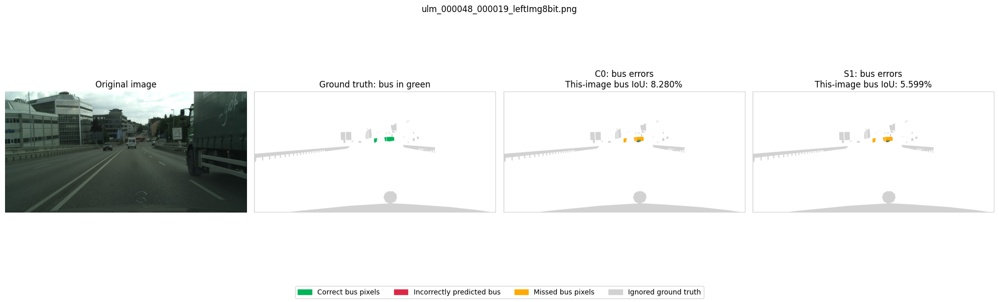

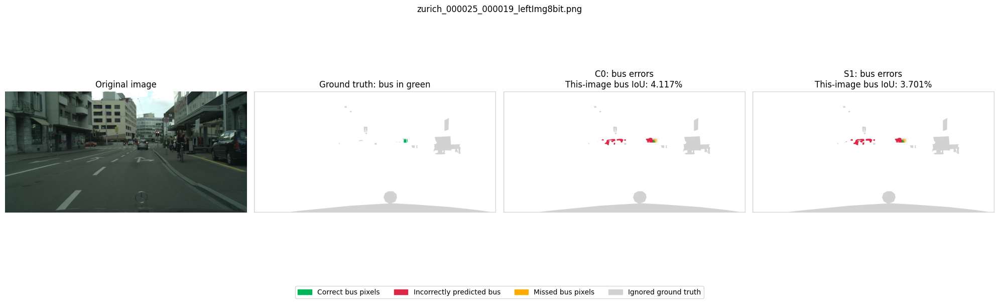


Saved prediction PNGs match their confusion matrices.
Ground-truth bus images inspected: 2
Saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/seed42_bus_visual_check_20260920_172500_323389
No training or inference performed.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json
import hashlib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from PIL import Image

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)

FOLDERS = {
    "C0": RUN / "C0_seed42/development_evaluation_20260920_104059_554904",
    "S1": RUN / "S1_seed42/development_evaluation_20260920_170956_883506",
}
LOCAL = Path("/content/cityscapes")
BUS = 15  # Model train ID. Original Cityscapes bus label ID is 28.

def read_json(path):
    return json.loads(Path(path).read_text())

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

metrics = {
    name: read_json(folder / "metrics.json")
    for name, folder in FOLDERS.items()
}
matrices = {
    name: np.load(
        folder / "per_image_confusion_matrices.npy",
        allow_pickle=False,
    )
    for name, folder in FOLDERS.items()
}

image_names = metrics["C0"]["images"]
assert image_names == metrics["S1"]["images"]
assert len(image_names) == 20
assert all(matrix.shape == (20, 19, 19) for matrix in matrices.values())
assert np.array_equal(
    matrices["C0"].sum(axis=2), matrices["S1"].sum(axis=2)
)

source_records = {
    row["image"]: row
    for row in read_json(FOLDERS["C0"] / "evaluation_source_files.json")
}

gt_bus_pixels = matrices["C0"][:, BUS, :].sum(axis=1)
selected = np.flatnonzero(gt_bus_pixels > 0)
assert len(selected) > 0

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUTPUT = RUN / f"seed42_bus_visual_check_{stamp}"
OUTPUT.mkdir(parents=True, exist_ok=False)

# Include false bus predictions across ALL 20 images.
print("BUS PIXEL COUNTS ACROSS ALL 20 DEVELOPMENT IMAGES")
print(f"{'Model':<7} {'TP':>12} {'FP':>12} {'FN':>12} {'Bus IoU (%)':>14}")

summary = {}
for condition, per_image in matrices.items():
    tp = per_image[:, BUS, BUS]
    fp = per_image[:, :, BUS].sum(axis=1) - tp
    fn = per_image[:, BUS, :].sum(axis=1) - tp

    pooled_iou = 100 * tp.sum() / (tp.sum() + fp.sum() + fn.sum())
    assert np.isclose(
        pooled_iou,
        metrics[condition]["class_iou_percent"]["bus"],
        rtol=0, atol=1e-9,
    )

    summary[condition] = {
        "true_positive_pixels": int(tp.sum()),
        "false_positive_pixels": int(fp.sum()),
        "false_negative_pixels": int(fn.sum()),
        "bus_iou_percent": float(pooled_iou),
        "false_positive_pixels_in_images_without_gt_bus": int(
            fp[gt_bus_pixels == 0].sum()
        ),
        "per_image": [
            {
                "image": name,
                "gt_bus_pixels": int(gt_bus_pixels[i]),
                "TP": int(tp[i]),
                "FP": int(fp[i]),
                "FN": int(fn[i]),
            }
            for i, name in enumerate(image_names)
        ],
    }

    print(
        f"{condition:<7} {tp.sum():>12} {fp.sum():>12} "
        f"{fn.sum():>12} {pooled_iou:>14.6f}"
    )
    print(
        "  False bus pixels in images with no ground-truth bus:",
        summary[condition]["false_positive_pixels_in_images_without_gt_bus"],
    )

original_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

# Colour definitions for the error maps.
TP_COLOUR = np.array([0, 180, 90], dtype=np.uint8)
FP_COLOUR = np.array([220, 40, 70], dtype=np.uint8)
FN_COLOUR = np.array([255, 170, 0], dtype=np.uint8)
IGNORE_COLOUR = np.array([210, 210, 210], dtype=np.uint8)

for index in selected:
    name = image_names[index]
    image_paths = list((LOCAL / "leftImg8bit/train").rglob(name))
    label_name = name.replace("_leftImg8bit.png", "_gtFine_instanceIds.png")
    label_paths = list((LOCAL / "gtFine/train").rglob(label_name))

    assert len(image_paths) == len(label_paths) == 1, (
        f"Local files missing or ambiguous for {name}. "
        "Restore the development files if the runtime restarted."
    )
    assert file_hash(image_paths[0]) == source_records[name]["image_sha256"]
    assert file_hash(label_paths[0]) == source_records[name]["label_sha256"]

    with Image.open(image_paths[0]) as source:
        rgb = np.array(source.convert("RGB"))
    with Image.open(label_paths[0]) as source:
        raw = np.array(source, dtype=np.int32)

    semantic = np.where(raw >= 1000, raw // 1000, raw)
    target = np.full(raw.shape, 255, dtype=np.int32)
    for train_id, original_id in enumerate(original_ids):
        target[semantic == original_id] = train_id

    valid = target != 255
    gt_bus = target == BUS
    assert int(gt_bus.sum()) == int(gt_bus_pixels[index])
    assert rgb.shape[:2] == target.shape

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(rgb)
    axes[0].set_title("Original image")

    gt_display = np.full_like(rgb, 255)
    gt_display[~valid] = IGNORE_COLOUR
    gt_display[gt_bus] = TP_COLOUR
    axes[1].imshow(gt_display)
    axes[1].set_title("Ground truth: bus in green")

    for column, condition in enumerate(["C0", "S1"], start=2):
        prediction_path = (
            FOLDERS[condition] / "predictions"
            / name.replace("_leftImg8bit.png", "_prediction_trainIds.png")
        )
        with Image.open(prediction_path) as source:
            prediction = np.array(source, dtype=np.int32)

        assert prediction.shape == target.shape
        assert prediction.min() >= 0 and prediction.max() < 19

        # Confirm the saved PNG reproduces the evaluated confusion matrix.
        recomputed = np.bincount(
            19 * target[valid] + prediction[valid],
            minlength=19 * 19,
        ).reshape(19, 19)
        assert np.array_equal(recomputed, matrices[condition][index]), (
            f"Saved prediction disagrees with evaluation: {condition}, {name}"
        )

        pred_bus = prediction == BUS
        tp = valid & gt_bus & pred_bus
        fp = valid & ~gt_bus & pred_bus
        fn = valid & gt_bus & ~pred_bus

        display = np.full_like(rgb, 255)
        display[~valid] = IGNORE_COLOUR
        display[tp] = TP_COLOUR
        display[fp] = FP_COLOUR
        display[fn] = FN_COLOUR

        image_iou = 100 * tp.sum() / (tp.sum() + fp.sum() + fn.sum())
        axes[column].imshow(display)
        axes[column].set_title(
            f"{condition}: bus errors\n"
            f"This-image bus IoU: {image_iou:.3f}%"
        )

    for axis in axes:
        axis.axis("off")

    fig.suptitle(name, fontsize=12)
    fig.legend(
        handles=[
            Patch(color=TP_COLOUR / 255, label="Correct bus pixels"),
            Patch(color=FP_COLOUR / 255, label="Incorrectly predicted bus"),
            Patch(color=FN_COLOUR / 255, label="Missed bus pixels"),
            Patch(color=IGNORE_COLOUR / 255, label="Ignored ground truth"),
        ],
        loc="lower center", ncol=4,
    )
    fig.tight_layout(rect=[0, 0.10, 1, 0.94])

    stem = name.replace("_leftImg8bit.png", "")
    fig.savefig(OUTPUT / f"{stem}_bus_comparison.png", dpi=200)
    plt.show()
    plt.close(fig)

(OUTPUT / "bus_pixel_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
(OUTPUT / "scope.txt").write_text(
    "Post-hoc diagnostic for corrected C0 versus S1, seed 42.\n"
    "Pixel counts cover all 20 development images.\n"
    "Figures show all development images containing ground-truth bus.\n"
    "Ignored pixels are excluded from scoring.\n"
    "Per-image IoUs are illustrative; reported class IoU uses pooled counts.\n"
    "This diagnostic does not establish why training changed predictions.\n",
    encoding="utf-8",
)

print("\nSaved prediction PNGs match their confusion matrices.")
print("Ground-truth bus images inspected:", len(selected))
print("Saved:", OUTPUT)
print("No training or inference performed.")

In [ ]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import shutil
import tempfile

import numpy as np
import torch
import transformers


def train_remaining_corrected_pairs():
    assert torch.cuda.is_available(), "Connect to a GPU runtime first."
    assert "corrected_model" in globals(), "Run the model recovery cell first."
    assert transformers.__version__ == "5.16.1"
    assert torch.__version__.split("+")[0] == "2.11.0"

    root = Path("/content/drive/MyDrive/ONEFORMER_DATA")
    experiment = root / "pilots/corrected_wording_20260920_102817_389509"
    reference_folder = experiment / "C0_seed42"

    def read_json(path):
        return json.loads(Path(path).read_text())

    def write_json(path, value):
        path = Path(path)
        temporary = path.with_name(path.name + ".partial")
        temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
        temporary.replace(path)

    def file_hash(path):
        digest = hashlib.sha256()
        with open(path, "rb") as handle:
            for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
                digest.update(block)
        return digest.hexdigest()

    def cpu_copy(value):
        if torch.is_tensor(value):
            return value.detach().cpu().clone()
        if isinstance(value, dict):
            return {key: cpu_copy(item) for key, item in value.items()}
        if isinstance(value, list):
            return [cpu_copy(item) for item in value]
        if isinstance(value, tuple):
            return tuple(cpu_copy(item) for item in value)
        return copy.deepcopy(value)

    # Use the completed corrected C0 run as the protocol reference.
    reference = read_json(reference_folder / "settings.json")
    preparation = read_json(reference_folder / "preparation_report.json")
    schedule = read_json(reference_folder / "batch_schedule.json")
    expected_names = read_json(
        reference_folder / "trainable_parameter_names.json"
    )

    assert reference["learning_rate"] == 1e-6
    assert reference["updates"] == 50
    assert reference["batch_size"] == 2
    assert reference["weight_decay"] == 0.01
    assert reference["betas"] == [0.9, 0.999]
    assert reference["eps"] == 1e-8
    assert reference["foreach"] is False
    assert reference["gradient_clip_max_norm"] == 1.0
    assert reference["scheduler"] is None
    assert reference["precision"] == "float32"
    assert reference["checkpoint_steps"] == [25, 50]

    assert preparation["status"] == "CORRECTED_PREPARATION_VERIFIED"
    records = preparation["records"]
    assert len(records) == 50
    assert [entry["step"] for entry in schedule] == list(range(1, 51))

    initial_path = Path(reference["common_initial_weights"])
    assert file_hash(initial_path) == reference["common_initial_weights_sha256"]

    # Verify the exact corrected data and image order once before training.
    replacements = 0
    for record in records:
        path = Path(record["prepared_file"])
        assert path.parent.resolve() == Path(reference["prepared_folder"]).resolve()
        assert file_hash(path) == record["corrected_sha256"]

        saved = torch.load(path, map_location="cpu", weights_only=True)
        assert saved["image_name"] == record["image"]
        c0_text = saved["inputs"]["text_inputs"]
        s1_text = saved["s1_text_inputs"]
        assert c0_text.shape == s1_text.shape
        changed = int((c0_text != s1_text).any(dim=-1).sum())
        assert changed == record["car_descriptions_replaced"]
        replacements += changed
        del saved, c0_text, s1_text

    assert replacements == 377

    for entry in schedule:
        assert len(entry["indices"]) == 2
        assert all(0 <= i < 50 for i in entry["indices"])
        assert [records[i]["image"] for i in entry["indices"]] == entry["images"]

    jobs = [(43, "C0"), (43, "S1"), (44, "C0"), (44, "S1")]

    # Do not overwrite completed or interrupted runs.
    completed = {}
    for seed, condition in jobs:
        folder = experiment / f"{condition}_seed{seed}"
        if folder.exists():
            status_path = folder / "status.json"
            assert status_path.is_file(), (
                f"Existing run has no status file:\n{folder}\n"
                "Send this output before continuing."
            )
            status = read_json(status_path)
            assert status["status"] == "training_complete", (
                f"An incomplete run exists:\n{folder}\n"
                "Send this output so we can recover its saved progress."
            )

            saved_settings = read_json(folder / "settings.json")
            assert saved_settings["seed"] == seed
            assert saved_settings["condition"] == condition
            for key in [
                "learning_rate", "updates", "batch_size", "weight_decay",
                "betas", "eps", "foreach", "gradient_clip_max_norm",
                "precision", "scheduler", "common_initial_weights_sha256",
                "prepared_folder"
            ]:
                assert saved_settings[key] == reference[key], key

            assert read_json(folder / "batch_schedule.json") == schedule
            assert read_json(folder / "preparation_report.json") == preparation
            assert read_json(folder / "trainable_parameter_names.json") == expected_names

            check = read_json(folder / "step_050_verification.json")
            assert status["completed_steps"] == 50
            assert file_hash(folder / "step_050.pt") == check["sha256"]
            completed[(seed, condition)] = folder

    model = corrected_model
    assert model.config.is_training is True
    assert model.model.text_mapper is not None

    encoder = model.model.text_mapper.text_encoder
    assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6
    assert all(
        len(layer.self_attn._forward_pre_hooks) > 0
        for layer in encoder.transformer.layers
    )

    # Recovery creates a new model; explicitly restore parameter selection.
    parameter_names = set(dict(model.named_parameters()))
    assert set(expected_names).issubset(parameter_names)

    expected_set = set(expected_names)
    for name, parameter in model.named_parameters():
        parameter.requires_grad_(name in expected_set)

    actual_names = [
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == expected_names

    backbone = model.model.pixel_level_module.encoder
    assert not any(p.requires_grad for p in backbone.parameters())

    def make_batch(indices, condition):
        samples = []
        for index in indices:
            saved = torch.load(
                records[index]["prepared_file"],
                map_location="cpu",
                weights_only=True,
            )
            inputs = dict(saved["inputs"])
            if condition == "S1":
                inputs["text_inputs"] = saved["s1_text_inputs"]
            samples.append(inputs)

        batch = {}
        for key in samples[0]:
            values = [sample[key] for sample in samples]
            if torch.is_tensor(values[0]):
                batch[key] = torch.cat(values, dim=0).to("cuda")
            elif key in ("mask_labels", "class_labels"):
                batch[key] = [
                    item.to("cuda")
                    for items in values
                    for item in items
                ]
            else:
                raise TypeError(f"Unexpected field: {key}")
        return batch

    completed_paths = []

    for seed, condition in jobs:
        if (seed, condition) in completed:
            folder = completed[(seed, condition)]
            print(f"Already complete and verified: {condition}, seed {seed}")
            completed_paths.append(str(folder))
            continue

        folder = experiment / f"{condition}_seed{seed}"

        # Every run begins independently from the original common weights.
        model.zero_grad(set_to_none=True)
        initial = torch.load(
            initial_path, map_location="cpu", weights_only=True
        )
        model.load_state_dict(initial, strict=True)
        del initial
        gc.collect()

        model.to(device="cuda", dtype=torch.float32)
        model.train()
        backbone.eval()

        # Restore the training branch after evaluation.
        for module in model.modules():
            if isinstance(getattr(module, "is_training", None), bool):
                module.is_training = True

        settings = copy.deepcopy(reference)
        settings.update({
            "condition": condition,
            "seed": seed,
            "description": (
                "Corrected original class descriptions"
                if condition == "C0"
                else "a photo with an automobile"
            ),
            "reference_corrected_C0_seed42": str(reference_folder),
        })
        if condition == "S1":
            settings["matched_control_folder"] = str(
                experiment / f"C0_seed{seed}"
            )

        folder.mkdir(parents=True, exist_ok=False)
        write_json(folder / "settings.json", settings)
        write_json(folder / "batch_schedule.json", schedule)
        write_json(folder / "preparation_report.json", preparation)
        write_json(folder / "trainable_parameter_names.json", actual_names)

        parameters = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(
            parameters,
            lr=settings["learning_rate"],
            weight_decay=settings["weight_decay"],
            betas=tuple(settings["betas"]),
            eps=settings["eps"],
            foreach=settings["foreach"],
        )
        history = []

        def save_checkpoint(step):
            cpu_rng = torch.get_rng_state().clone()
            cuda_rng = [s.clone() for s in torch.cuda.get_rng_state_all()]
            python_rng = random.getstate()
            numpy_rng = np.random.get_state()

            destination = folder / f"step_{step:03d}.pt"
            partial = destination.with_suffix(".pt.partial")

            try:
                payload = {
                    "condition": condition,
                    "seed": seed,
                    "completed_steps": step,
                    "model": cpu_copy(model.state_dict()),
                    "optimizer": cpu_copy(optimizer.state_dict()),
                    "torch_rng_state": cpu_rng,
                    "cuda_rng_states": cuda_rng,
                    "python_rng_state": python_rng,
                    "numpy_rng_state": {
                        "generator": numpy_rng[0],
                        "keys": numpy_rng[1].tolist(),
                        "position": int(numpy_rng[2]),
                        "has_gauss": int(numpy_rng[3]),
                        "cached_gaussian": float(numpy_rng[4]),
                    },
                    "settings": settings,
                    "history": copy.deepcopy(history),
                    "trainable_parameter_names": actual_names,
                }

                with tempfile.TemporaryDirectory(
                    prefix="corrected_training_", dir="/content"
                ) as temporary_folder:
                    local_path = Path(temporary_folder) / destination.name
                    torch.save(payload, local_path)
                    shutil.copyfile(local_path, partial)

                    digest = file_hash(local_path)
                    assert file_hash(partial) == digest

                    checked = torch.load(
                        partial, map_location="cpu", weights_only=True
                    )
                    assert checked["condition"] == condition
                    assert checked["seed"] == seed
                    assert checked["completed_steps"] == step
                    assert checked["optimizer"]["state"]
                    assert checked["model"].keys() == payload["model"].keys()
                    assert all(
                        torch.equal(value, checked["model"][name])
                        for name, value in payload["model"].items()
                    )
                    del checked
                    partial.replace(destination)

                write_json(
                    folder / f"step_{step:03d}_verification.json",
                    {
                        "checkpoint": str(destination),
                        "sha256": digest,
                        "file_copy_equal": True,
                        "model_tensor_readback_equal": True,
                    },
                )
                del payload
                print(f"{condition} seed {seed}: checkpoint {step} verified")

            finally:
                torch.set_rng_state(cpu_rng)
                torch.cuda.set_rng_state_all(cuda_rng)
                random.setstate(python_rng)
                np.random.set_state(numpy_rng)
                gc.collect()

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.cuda.reset_peak_memory_stats()

        write_json(folder / "status.json", {"status": "training"})
        print(f"\nStarting corrected {condition}, seed {seed}")
        print("Fresh common weights and optimizer; same saved image order.")
        print("Saving to:", folder)

        try:
            for entry in schedule:
                step = entry["step"]
                batch = make_batch(entry["indices"], condition)
                optimizer.zero_grad(set_to_none=True)

                outputs = model(**batch, return_dict=True)
                loss = outputs.loss
                assert loss is not None and torch.isfinite(loss).item(), (
                    f"Invalid loss: {condition}, seed {seed}, step {step}"
                )

                loss_value = float(loss.detach())
                loss.backward()
                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    parameters,
                    max_norm=settings["gradient_clip_max_norm"],
                    error_if_nonfinite=True,
                )
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

                history.append({
                    "step": step,
                    "epoch": entry["epoch"],
                    "images": entry["images"],
                    "total_loss_before_update": loss_value,
                    "gradient_norm_before_clipping": float(gradient_norm),
                    "peak_gpu_allocated_GiB": (
                        torch.cuda.max_memory_allocated() / 1024**3
                    ),
                })
                write_json(folder / "history.json", history)
                print(
                    f"{condition} seed {seed}: {step:02d}/50 "
                    f"| loss={loss_value:.4f}"
                )
                del batch, outputs, loss, gradient_norm

                if step in settings["checkpoint_steps"]:
                    save_checkpoint(step)

            write_json(folder / "status.json", {
                "status": "training_complete",
                "completed_steps": 50,
                "final_checkpoint": str(folder / "step_050.pt"),
                "evaluation_performed": False,
            })
            completed_paths.append(str(folder))
            print(f"COMPLETE: corrected {condition}, seed {seed}")

        except Exception as error:
            write_json(folder / "status.json", {
                "status": "interrupted",
                "recorded_updates": len(history),
                "error": str(error),
                "note": "Inspect saved checkpoints before recovery.",
            })
            raise

        finally:
            optimizer.zero_grad(set_to_none=True)
            del optimizer
            gc.collect()
            torch.cuda.empty_cache()

    print("\nALL FOUR TRAINING RUNS COMPLETE")
    for path in completed_paths:
        print(path)
    print("No evaluation performed by this cell.")
    return completed_paths


remaining_corrected_training_folders = train_remaining_corrected_pairs()


Starting corrected C0, seed 43
Fresh common weights and optimizer; same saved image order.
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/C0_seed43
C0 seed 43: 01/50 | loss=26.0775
C0 seed 43: 02/50 | loss=23.4606
C0 seed 43: 03/50 | loss=25.0202
C0 seed 43: 04/50 | loss=25.8079
C0 seed 43: 05/50 | loss=33.3619
C0 seed 43: 06/50 | loss=29.9844
C0 seed 43: 07/50 | loss=14.5774
C0 seed 43: 08/50 | loss=34.1903
C0 seed 43: 09/50 | loss=30.0566
C0 seed 43: 10/50 | loss=21.0210
C0 seed 43: 11/50 | loss=25.1710
C0 seed 43: 12/50 | loss=22.5340
C0 seed 43: 13/50 | loss=24.4077
C0 seed 43: 14/50 | loss=29.9002
C0 seed 43: 15/50 | loss=20.2707
C0 seed 43: 16/50 | loss=27.9430
C0 seed 43: 17/50 | loss=24.6803
C0 seed 43: 18/50 | loss=29.1748
C0 seed 43: 19/50 | loss=24.3068
C0 seed 43: 20/50 | loss=18.1904
C0 seed 43: 21/50 | loss=32.5153
C0 seed 43: 22/50 | loss=25.5210
C0 seed 43: 23/50 | loss=21.8570
C0 seed 43: 24/50 | loss=24.4359
C0 seed 4

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json

import numpy as np
import pandas as pd
import torch
from PIL import Image
from transformers import OneFormerProcessor

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
LOCAL = Path("/content/cityscapes")

assert "corrected_model" in globals(), "Run the model recovery cell first."
assert torch.cuda.is_available(), "Connect to a GPU runtime first."

SEED42_FOLDERS = {
    "C0": RUN / "C0_seed42/development_evaluation_20260920_104059_554904",
    "S1": RUN / "S1_seed42/development_evaluation_20260920_170956_883506",
}

NAMES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
ORIGINAL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

def read_json(path):
    return json.loads(Path(path).read_text())

def write_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False), encoding="utf-8"
    )
    temporary.replace(path)

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

reference = read_json(SEED42_FOLDERS["C0"] / "metrics.json")
source_records = read_json(
    SEED42_FOLDERS["C0"] / "evaluation_source_files.json"
)
reference_matrices = np.load(
    SEED42_FOLDERS["C0"] / "per_image_confusion_matrices.npy",
    allow_pickle=False,
)
assert reference_matrices.shape == (20, 19, 19)
reference_gt_counts = reference_matrices.sum(axis=2)

preparation = read_json(RUN / "C0_seed42/preparation_report.json")
reference_settings = read_json(RUN / "C0_seed42/settings.json")
reference_schedule = read_json(RUN / "C0_seed42/batch_schedule.json")
reference_names = read_json(RUN / "C0_seed42/trainable_parameter_names.json")

processor = OneFormerProcessor.from_pretrained(
    str(Path(preparation["source_preparation_folder"]) / "processor"),
    local_files_only=True,
)

# ---------- Verify the exact evaluation files ----------
source_by_name = {row["image"]: row for row in source_records}
pairs = []

for name in reference["images"]:
    image_matches = list((LOCAL / "leftImg8bit/train").rglob(name))
    label_name = name.replace("_leftImg8bit.png", "_gtFine_instanceIds.png")
    label_matches = list((LOCAL / "gtFine/train").rglob(label_name))

    assert len(image_matches) == len(label_matches) == 1, (
        f"Missing or ambiguous local files for {name}. "
        "Run the development-file recovery cell if the runtime restarted."
    )

    image_path, label_path = image_matches[0], label_matches[0]
    assert file_hash(image_path) == source_by_name[name]["image_sha256"]
    assert file_hash(label_path) == source_by_name[name]["label_sha256"]
    pairs.append((image_path, label_path))

assert len(pairs) == 20
print("Same 20 development images and labels: hashes verified.")

# Verify every model belongs to the same corrected training protocol.
checkpoint_hashes = {}
for seed in (42, 43, 44):
    for condition in ("C0", "S1"):
        folder = RUN / f"{condition}_seed{seed}"
        settings = read_json(folder / "settings.json")
        status = read_json(folder / "status.json")

        assert settings["condition"] == condition
        assert settings["seed"] == seed
        assert status["status"] == "training_complete"
        assert status["completed_steps"] == 50

        for key in [
            "learning_rate", "updates", "batch_size", "optimizer",
            "weight_decay", "betas", "eps", "foreach",
            "gradient_clip_max_norm", "precision", "scheduler",
            "common_initial_weights_sha256", "prepared_folder"
        ]:
            assert settings[key] == reference_settings[key], key

        assert read_json(folder / "batch_schedule.json") == reference_schedule
        assert read_json(folder / "preparation_report.json") == preparation
        assert read_json(folder / "trainable_parameter_names.json") == reference_names

        digest = file_hash(folder / "step_050.pt")
        assert digest == read_json(
            folder / "step_050_verification.json"
        )["sha256"]
        checkpoint_hashes[(condition, seed)] = digest

print("All six checkpoints and matched training settings: verified.")

def verified_metrics(folder, condition, seed):
    result = read_json(folder / "metrics.json")
    matrices = np.load(
        folder / "per_image_confusion_matrices.npy", allow_pickle=False
    )
    pooled = np.load(folder / "confusion_matrix.npy", allow_pickle=False)

    assert matrices.shape == (20, 19, 19)
    assert np.issubdtype(matrices.dtype, np.integer)
    assert (matrices >= 0).all()
    assert np.array_equal(matrices.sum(axis=0), pooled)
    assert np.array_equal(matrices.sum(axis=2), reference_gt_counts)

    assert result["condition"] == f"corrected_{condition}"
    assert result["seed"] == seed
    assert result["completed_steps"] == 50
    assert result["checkpoint_sha256"] == checkpoint_hashes[(condition, seed)]

    for key in [
        "images", "number_of_images", "input_size_width_height",
        "evaluation_resolution", "task", "ground_truth_ignore_id",
        "confusion_matrix_axes", "aggregation"
    ]:
        assert result[key] == reference[key], key

    diagonal = np.diag(pooled).astype(np.float64)
    union = pooled.sum(axis=0) + pooled.sum(axis=1) - diagonal
    assert (union > 0).all()
    scores = 100 * diagonal / union

    assert np.isclose(
        scores.mean(), result["miou_percent"], rtol=0, atol=1e-9
    )
    for name, score in zip(NAMES, scores):
        assert np.isclose(
            score, result["class_iou_percent"][name],
            rtol=0, atol=1e-9,
        )
    return result

model = corrected_model
model.to(device="cuda", dtype=torch.float32)
model.zero_grad(set_to_none=True)

for index, name in enumerate(NAMES):
    actual = model.config.id2label.get(
        index, model.config.id2label.get(str(index))
    )
    assert actual == name

def evaluate_one(condition, seed):
    training_folder = RUN / f"{condition}_seed{seed}"
    folder = training_folder / "development_evaluation_matched20"

    # Reuse only complete, verified results if this cell is rerun.
    if (folder / "metrics.json").is_file():
        result = verified_metrics(folder, condition, seed)
        print(f"Reused verified evaluation: {condition}, seed {seed}")
        return result, folder

    assert not folder.exists(), (
        f"An incomplete evaluation folder exists:\n{folder}\n"
        "Send this output before continuing."
    )

    checkpoint = training_folder / "step_050.pt"
    saved = torch.load(checkpoint, map_location="cpu", weights_only=True)
    assert saved["condition"] == condition
    assert saved["seed"] == seed
    assert saved["completed_steps"] == 50
    model.load_state_dict(saved["model"], strict=True)
    del saved
    gc.collect()

    predictions = folder / "predictions"
    predictions.mkdir(parents=True, exist_ok=False)
    modes = [(module, module.training) for module in model.modules()]
    flags = [
        (module, module.is_training)
        for module in model.modules()
        if isinstance(getattr(module, "is_training", None), bool)
    ]
    matrices = []

    try:
        model.eval()
        for module, _ in flags:
            module.is_training = False

        with torch.inference_mode():
            for index, (image_path, label_path) in enumerate(pairs):
                with Image.open(image_path) as source:
                    image = source.convert("RGB")
                    width, height = image.size
                    resized = image.resize(
                        (512, 256), Image.Resampling.BILINEAR
                    )
                with Image.open(label_path) as source:
                    raw = np.array(source, dtype=np.int32)

                assert raw.shape == (height, width)
                semantic = np.where(raw >= 1000, raw // 1000, raw)
                target = np.full(raw.shape, 255, dtype=np.int32)
                for train_id, label_id in enumerate(ORIGINAL_IDS):
                    target[semantic == label_id] = train_id

                encoded = processor(
                    images=resized,
                    task_inputs=["semantic"],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to("cuda")
                    for key, value in encoded.items()
                    if key in ("pixel_values", "task_inputs", "pixel_mask")
                }
                assert tuple(inputs["pixel_values"].shape) == (1, 3, 256, 512)

                outputs = model(**inputs, return_dict=True)
                prediction = (
                    processor.post_process_semantic_segmentation(
                        outputs, target_sizes=[(height, width)]
                    )[0].cpu().numpy().astype(np.int32)
                )
                assert prediction.shape == target.shape
                assert prediction.min() >= 0 and prediction.max() < 19

                valid = target != 255
                matrix = np.bincount(
                    19 * target[valid] + prediction[valid],
                    minlength=361,
                ).reshape(19, 19)
                assert np.array_equal(
                    matrix.sum(axis=1), reference_gt_counts[index]
                )
                matrices.append(matrix)

                Image.fromarray(prediction.astype(np.uint8)).save(
                    predictions / image_path.name.replace(
                        "_leftImg8bit.png", "_prediction_trainIds.png"
                    )
                )
                del encoded, inputs, outputs, prediction
                print(f"{condition} seed {seed}: evaluated {index + 1}/20")

    finally:
        for module, flag in flags:
            module.is_training = flag
        for module, mode in modes:
            module.training = mode

    per_image = np.stack(matrices)
    pooled = per_image.sum(axis=0)
    diagonal = np.diag(pooled).astype(np.float64)
    union = pooled.sum(axis=0) + pooled.sum(axis=1) - diagonal
    assert (union > 0).all()
    scores = 100 * diagonal / union

    result = {
        "condition": f"corrected_{condition}",
        "seed": seed,
        "completed_steps": 50,
        "checkpoint": str(checkpoint),
        "checkpoint_sha256": checkpoint_hashes[(condition, seed)],
        "images": reference["images"],
        "number_of_images": 20,
        "input_size_width_height": [512, 256],
        "evaluation_resolution": "original annotation resolution",
        "task": "semantic",
        "ground_truth_ignore_id": 255,
        "confusion_matrix_axes": "rows=ground truth, columns=prediction",
        "aggregation": "pooled pixel confusion matrix across all 20 images",
        "classes_with_nonzero_union": 19,
        "miou_percent": float(scores.mean()),
        "car_iou_percent": float(scores[13]),
        "class_iou_percent": dict(zip(NAMES, map(float, scores))),
        "evaluation_folder": str(folder),
        "interpretation": (
            "20-image development subset from Cityscapes train; "
            "not the final 500-image validation evaluation."
        ),
    }

    np.save(folder / "confusion_matrix.npy", pooled)
    np.save(folder / "per_image_confusion_matrices.npy", per_image)
    write_json(folder / "evaluation_source_files.json", source_records)
    write_json(folder / "metrics.json", result)

    result = verified_metrics(folder, condition, seed)
    print(f"{condition} seed {seed}: mIoU = {result['miou_percent']:.6f}%")
    return result, folder

# ---------- Reuse seed 42; evaluate seeds 43 and 44 ----------
results = {}
evaluation_paths = {}

for condition, folder in SEED42_FOLDERS.items():
    results[(condition, 42)] = verified_metrics(folder, condition, 42)
    evaluation_paths[f"{condition}_seed42"] = str(folder)

for seed in (43, 44):
    for condition in ("C0", "S1"):
        result, folder = evaluate_one(condition, seed)
        results[(condition, seed)] = result
        evaluation_paths[f"{condition}_seed{seed}"] = str(folder)

# ---------- All classes and paired differences ----------
def score_dict(result):
    return {
        "mIoU (%)": result["miou_percent"],
        **{
            f"{name} IoU (%)": result["class_iou_percent"][name]
            for name in NAMES
        },
    }

individual_rows = []
paired_rows = []

for seed in (42, 43, 44):
    c0 = score_dict(results[("C0", seed)])
    s1 = score_dict(results[("S1", seed)])

    individual_rows.extend([
        {"Seed": seed, "Condition": "C0", **c0},
        {"Seed": seed, "Condition": "S1", **s1},
    ])
    paired_rows.append({
        "Seed": seed,
        **{
            metric.replace(" (%)", " difference (pp)"): s1[metric] - c0[metric]
            for metric in c0
        },
    })

individual = pd.DataFrame(individual_rows)
paired = pd.DataFrame(paired_rows)
summary = pd.DataFrame([
    {
        "Metric": metric,
        "Mean paired difference (pp)": float(paired[metric].mean()),
        "Sample SD (pp)": float(paired[metric].std(ddof=1)),
        "Seeds": 3,
    }
    for metric in paired.columns if metric != "Seed"
])

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
SUMMARY = RUN / f"C0_S1_three_seed_development_summary_{stamp}"
SUMMARY.mkdir(parents=True, exist_ok=False)

individual.to_csv(SUMMARY / "individual_results.csv", index=False)
paired.to_csv(SUMMARY / "paired_differences.csv", index=False)
summary.to_csv(SUMMARY / "paired_mean_and_sd.csv", index=False)

write_json(SUMMARY / "scope.json", {
    "comparison": "Corrected S1 minus corrected C0, paired within seed",
    "seeds": [42, 43, 44],
    "training_images": 50,
    "training_updates": 50,
    "learning_rate": 1e-6,
    "development_images": 20,
    "input_size_width_height": [512, 256],
    "evaluation_paths": evaluation_paths,
    "saved_scores_verified_against_confusion_matrices": True,
    "limitations": [
        "Development results, not final 500-image validation results.",
        "Sample SD describes variation across three training seeds.",
        "Sample SD is not a confidence interval or an equivalence test.",
        "All seeds use the same training images and saved image order.",
    ],
})

display_classes = ["car", "bus", "motorcycle", "wall", "bicycle"]

print("\nALL SIX CORRECTED DEVELOPMENT RESULTS")
print(individual[
    ["Seed", "Condition", "mIoU (%)"]
    + [f"{name} IoU (%)" for name in display_classes]
].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nPAIRED DIFFERENCES: S1 MINUS C0")
selected_metrics = ["mIoU difference (pp)"] + [
    f"{name} IoU difference (pp)" for name in display_classes
]
print(paired[
    ["Seed"] + selected_metrics
].to_string(index=False, float_format=lambda x: f"{x:+.6f}"))

print("\nMEAN PAIRED DIFFERENCE AND SAMPLE SD")
print(summary[
    summary["Metric"].isin(selected_metrics)
].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nAll 19 class results are included in the saved CSV files.")
print("Saved:", SUMMARY)
print("No training performed.")

Same 20 development images and labels: hashes verified.
All six checkpoints and matched training settings: verified.
C0 seed 43: evaluated 1/20
C0 seed 43: evaluated 2/20
C0 seed 43: evaluated 3/20
C0 seed 43: evaluated 4/20
C0 seed 43: evaluated 5/20
C0 seed 43: evaluated 6/20
C0 seed 43: evaluated 7/20
C0 seed 43: evaluated 8/20
C0 seed 43: evaluated 9/20
C0 seed 43: evaluated 10/20
C0 seed 43: evaluated 11/20
C0 seed 43: evaluated 12/20
C0 seed 43: evaluated 13/20
C0 seed 43: evaluated 14/20
C0 seed 43: evaluated 15/20
C0 seed 43: evaluated 16/20
C0 seed 43: evaluated 17/20
C0 seed 43: evaluated 18/20
C0 seed 43: evaluated 19/20
C0 seed 43: evaluated 20/20
C0 seed 43: mIoU = 68.220220%
S1 seed 43: evaluated 1/20
S1 seed 43: evaluated 2/20
S1 seed 43: evaluated 3/20
S1 seed 43: evaluated 4/20
S1 seed 43: evaluated 5/20
S1 seed 43: evaluated 6/20
S1 seed 43: evaluated 7/20
S1 seed 43: evaluated 8/20
S1 seed 43: evaluated 9/20
S1 seed 43: evaluated 10/20
S1 seed 43: evaluated 11/20
S1 

In [ ]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import shutil
import tempfile

import numpy as np
import torch
import transformers


def train_corrected_t1():
    assert torch.cuda.is_available(), "Connect to a GPU runtime first."
    assert "corrected_model" in globals(), "Run the model recovery cell first."
    assert transformers.__version__ == "5.16.1"
    assert torch.__version__.split("+")[0] == "2.11.0"

    root = Path("/content/drive/MyDrive/ONEFORMER_DATA")
    experiment = root / "pilots/corrected_wording_20260920_102817_389509"

    def read_json(path):
        return json.loads(Path(path).read_text())

    def write_json(path, value):
        path = Path(path)
        temporary = path.with_name(path.name + ".partial")
        temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
        temporary.replace(path)

    def file_hash(path):
        digest = hashlib.sha256()
        with open(path, "rb") as handle:
            for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
                digest.update(block)
        return digest.hexdigest()

    def cpu_copy(value):
        if torch.is_tensor(value):
            return value.detach().cpu().clone()
        if isinstance(value, dict):
            return {key: cpu_copy(item) for key, item in value.items()}
        if isinstance(value, list):
            return [cpu_copy(item) for item in value]
        if isinstance(value, tuple):
            return tuple(cpu_copy(item) for item in value)
        return copy.deepcopy(value)

    reference_folder = experiment / "C0_seed42"
    reference = read_json(reference_folder / "settings.json")
    preparation = read_json(reference_folder / "preparation_report.json")
    schedule = read_json(reference_folder / "batch_schedule.json")
    expected_names = read_json(
        reference_folder / "trainable_parameter_names.json"
    )

    assert reference["learning_rate"] == 1e-6
    assert reference["updates"] == 50
    assert reference["batch_size"] == 2
    assert reference["precision"] == "float32"
    assert reference["scheduler"] is None
    assert reference["checkpoint_steps"] == [25, 50]
    assert preparation["status"] == "CORRECTED_PREPARATION_VERIFIED"
    assert preparation["T1_description"] == "a photograph containing a car"

    records = preparation["records"]
    assert len(records) == 50
    assert [entry["step"] for entry in schedule] == list(range(1, 51))

    # Verify the previously audited corrected inputs.
    replacements = 0
    for record in records:
        path = Path(record["prepared_file"])
        assert path.parent.resolve() == Path(reference["prepared_folder"]).resolve()
        assert file_hash(path) == record["corrected_sha256"]

        saved = torch.load(path, map_location="cpu", weights_only=True)
        assert saved["image_name"] == record["image"]
        c0_text = saved["inputs"]["text_inputs"]
        t1_text = saved["t1_text_inputs"]
        assert c0_text.shape == t1_text.shape

        changed = int((c0_text != t1_text).any(dim=-1).sum())
        assert changed == record["car_descriptions_replaced"]
        replacements += changed
        del saved, c0_text, t1_text

    assert replacements == 377

    for entry in schedule:
        assert len(entry["indices"]) == 2
        assert all(0 <= i < 50 for i in entry["indices"])
        assert [records[i]["image"] for i in entry["indices"]] == entry["images"]

    initial_path = Path(reference["common_initial_weights"])
    assert file_hash(initial_path) == reference["common_initial_weights_sha256"]

    # Verify matched C0 controls before any new training.
    protocol_keys = [
        "learning_rate", "updates", "batch_size", "optimizer",
        "weight_decay", "betas", "eps", "foreach",
        "gradient_clip_max_norm", "precision", "scheduler",
        "checkpoint_steps", "common_initial_weights_sha256", "prepared_folder"
    ]

    completed = set()
    for seed in (42, 43, 44):
        control_folder = experiment / f"C0_seed{seed}"
        control_settings = read_json(control_folder / "settings.json")
        assert control_settings["condition"] == "C0"
        assert control_settings["seed"] == seed
        assert read_json(control_folder / "status.json")["status"] == (
            "training_complete"
        )
        for key in protocol_keys:
            assert control_settings[key] == reference[key], key
        assert read_json(control_folder / "batch_schedule.json") == schedule
        assert read_json(control_folder / "preparation_report.json") == preparation
        assert read_json(
            control_folder / "trainable_parameter_names.json"
        ) == expected_names

        folder = experiment / f"T1_seed{seed}"
        if folder.exists():
            assert (folder / "status.json").is_file(), (
                f"Existing folder needs inspection: {folder}"
            )
            status = read_json(folder / "status.json")
            assert status["status"] == "training_complete", (
                f"Incomplete run found: {folder}\n"
                "Send this output before attempting recovery."
            )
            old_settings = read_json(folder / "settings.json")
            assert old_settings["condition"] == "T1"
            assert old_settings["seed"] == seed
            assert old_settings["description"] == preparation["T1_description"]
            for key in protocol_keys:
                assert old_settings[key] == reference[key], key
            assert read_json(folder / "batch_schedule.json") == schedule
            assert read_json(folder / "preparation_report.json") == preparation
            assert read_json(
                folder / "trainable_parameter_names.json"
            ) == expected_names
            assert status["completed_steps"] == 50
            assert file_hash(folder / "step_050.pt") == read_json(
                folder / "step_050_verification.json"
            )["sha256"]
            completed.add(seed)

    model = corrected_model
    assert model.config.is_training is True
    encoder = model.model.text_mapper.text_encoder
    assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6
    assert all(
        len(layer.self_attn._forward_pre_hooks) > 0
        for layer in encoder.transformer.layers
    )

    assert set(expected_names).issubset(dict(model.named_parameters()))
    expected_set = set(expected_names)
    for name, parameter in model.named_parameters():
        parameter.requires_grad_(name in expected_set)

    actual_names = [
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == expected_names

    backbone = model.model.pixel_level_module.encoder
    assert not any(p.requires_grad for p in backbone.parameters())

    def make_batch(indices):
        samples = []
        for index in indices:
            saved = torch.load(
                records[index]["prepared_file"],
                map_location="cpu",
                weights_only=True,
            )
            inputs = dict(saved["inputs"])
            inputs["text_inputs"] = saved["t1_text_inputs"]
            samples.append(inputs)

        batch = {}
        for key in samples[0]:
            values = [sample[key] for sample in samples]
            if torch.is_tensor(values[0]):
                batch[key] = torch.cat(values, dim=0).to("cuda")
            elif key in ("mask_labels", "class_labels"):
                batch[key] = [
                    item.to("cuda") for items in values for item in items
                ]
            else:
                raise TypeError(f"Unexpected field: {key}")
        return batch

    output_paths = []

    for seed in (42, 43, 44):
        folder = experiment / f"T1_seed{seed}"
        if seed in completed:
            print(f"T1 seed {seed}: already complete and verified.")
            output_paths.append(str(folder))
            continue

        # Independent starting weights for every seed.
        model.zero_grad(set_to_none=True)
        initial = torch.load(
            initial_path, map_location="cpu", weights_only=True
        )
        model.load_state_dict(initial, strict=True)
        del initial
        gc.collect()

        model.to(device="cuda", dtype=torch.float32)
        model.train()
        backbone.eval()
        for module in model.modules():
            if isinstance(getattr(module, "is_training", None), bool):
                module.is_training = True

        settings = copy.deepcopy(reference)
        settings.update({
            "condition": "T1",
            "seed": seed,
            "description": "a photograph containing a car",
            "control_description": "a photo with a car",
            "changed_factor": "Sentence template; class word car retained",
            "matched_control_folder": str(experiment / f"C0_seed{seed}"),
        })

        folder.mkdir(parents=True, exist_ok=False)
        write_json(folder / "settings.json", settings)
        write_json(folder / "batch_schedule.json", schedule)
        write_json(folder / "preparation_report.json", preparation)
        write_json(folder / "trainable_parameter_names.json", actual_names)

        parameters = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(
            parameters,
            lr=settings["learning_rate"],
            weight_decay=settings["weight_decay"],
            betas=tuple(settings["betas"]),
            eps=settings["eps"],
            foreach=settings["foreach"],
        )
        history = []

        def save_checkpoint(step):
            cpu_rng = torch.get_rng_state().clone()
            cuda_rng = [s.clone() for s in torch.cuda.get_rng_state_all()]
            python_rng = random.getstate()
            numpy_rng = np.random.get_state()
            destination = folder / f"step_{step:03d}.pt"
            partial = destination.with_suffix(".pt.partial")

            try:
                payload = {
                    "condition": "T1",
                    "seed": seed,
                    "completed_steps": step,
                    "model": cpu_copy(model.state_dict()),
                    "optimizer": cpu_copy(optimizer.state_dict()),
                    "torch_rng_state": cpu_rng,
                    "cuda_rng_states": cuda_rng,
                    "python_rng_state": python_rng,
                    "numpy_rng_state": {
                        "generator": numpy_rng[0],
                        "keys": numpy_rng[1].tolist(),
                        "position": int(numpy_rng[2]),
                        "has_gauss": int(numpy_rng[3]),
                        "cached_gaussian": float(numpy_rng[4]),
                    },
                    "settings": settings,
                    "history": copy.deepcopy(history),
                    "trainable_parameter_names": actual_names,
                }

                with tempfile.TemporaryDirectory(
                    prefix="corrected_T1_", dir="/content"
                ) as temporary_folder:
                    local_path = Path(temporary_folder) / destination.name
                    torch.save(payload, local_path)
                    shutil.copyfile(local_path, partial)
                    digest = file_hash(local_path)
                    assert file_hash(partial) == digest

                    checked = torch.load(
                        partial, map_location="cpu", weights_only=True
                    )
                    assert checked["condition"] == "T1"
                    assert checked["seed"] == seed
                    assert checked["completed_steps"] == step
                    assert checked["optimizer"]["state"]
                    assert checked["model"].keys() == payload["model"].keys()
                    assert all(
                        torch.equal(value, checked["model"][name])
                        for name, value in payload["model"].items()
                    )
                    del checked
                    partial.replace(destination)

                write_json(folder / f"step_{step:03d}_verification.json", {
                    "checkpoint": str(destination),
                    "sha256": digest,
                    "file_copy_equal": True,
                    "model_tensor_readback_equal": True,
                })
                del payload
                print(f"T1 seed {seed}: checkpoint {step} verified")

            finally:
                torch.set_rng_state(cpu_rng)
                torch.cuda.set_rng_state_all(cuda_rng)
                random.setstate(python_rng)
                np.random.set_state(numpy_rng)
                gc.collect()

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.cuda.reset_peak_memory_stats()

        write_json(folder / "status.json", {"status": "training"})
        print(f"\nStarting corrected T1, seed {seed}")
        print("Description: a photograph containing a car")
        print("377 replacements; correct car labels retained.")
        print("Fresh common weights and optimizer; same image schedule.")
        print("Saving to:", folder)

        try:
            for entry in schedule:
                step = entry["step"]
                batch = make_batch(entry["indices"])
                optimizer.zero_grad(set_to_none=True)

                outputs = model(**batch, return_dict=True)
                loss = outputs.loss
                assert loss is not None and torch.isfinite(loss).item(), (
                    f"Invalid loss: T1 seed {seed}, step {step}"
                )
                loss_value = float(loss.detach())
                loss.backward()
                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    parameters,
                    max_norm=settings["gradient_clip_max_norm"],
                    error_if_nonfinite=True,
                )
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

                history.append({
                    "step": step,
                    "epoch": entry["epoch"],
                    "images": entry["images"],
                    "total_loss_before_update": loss_value,
                    "gradient_norm_before_clipping": float(gradient_norm),
                    "peak_gpu_allocated_GiB": (
                        torch.cuda.max_memory_allocated() / 1024**3
                    ),
                })
                write_json(folder / "history.json", history)
                print(f"T1 seed {seed}: {step:02d}/50 | loss={loss_value:.4f}")
                del batch, outputs, loss, gradient_norm

                if step in settings["checkpoint_steps"]:
                    save_checkpoint(step)

            write_json(folder / "status.json", {
                "status": "training_complete",
                "completed_steps": 50,
                "final_checkpoint": str(folder / "step_050.pt"),
                "evaluation_performed": False,
            })
            output_paths.append(str(folder))
            print(f"COMPLETE: corrected T1, seed {seed}")

        except Exception as error:
            write_json(folder / "status.json", {
                "status": "interrupted",
                "recorded_updates": len(history),
                "error": str(error),
                "note": "Inspect saved checkpoints before recovery.",
            })
            raise

        finally:
            optimizer.zero_grad(set_to_none=True)
            del optimizer
            gc.collect()
            torch.cuda.empty_cache()

    print("\nALL THREE CORRECTED T1 TRAINING RUNS COMPLETE")
    for path in output_paths:
        print(path)
    print("No evaluation performed by this cell.")
    return output_paths


corrected_t1_training_folders = train_corrected_t1()


Starting corrected T1, seed 42
Description: a photograph containing a car
377 replacements; correct car labels retained.
Fresh common weights and optimizer; same image schedule.
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/T1_seed42
T1 seed 42: 01/50 | loss=25.9428
T1 seed 42: 02/50 | loss=23.8858
T1 seed 42: 03/50 | loss=24.9925
T1 seed 42: 04/50 | loss=25.3513
T1 seed 42: 05/50 | loss=33.0152
T1 seed 42: 06/50 | loss=29.6695
T1 seed 42: 07/50 | loss=14.6048
T1 seed 42: 08/50 | loss=34.0124
T1 seed 42: 09/50 | loss=29.8590
T1 seed 42: 10/50 | loss=21.1599
T1 seed 42: 11/50 | loss=25.3064
T1 seed 42: 12/50 | loss=22.9246
T1 seed 42: 13/50 | loss=24.0939
T1 seed 42: 14/50 | loss=29.2859
T1 seed 42: 15/50 | loss=20.8932
T1 seed 42: 16/50 | loss=27.1987
T1 seed 42: 17/50 | loss=24.3350
T1 seed 42: 18/50 | loss=27.1093
T1 seed 42: 19/50 | loss=23.4444
T1 seed 42: 20/50 | loss=18.1192
T1 seed 42: 21/50 | loss=34.4735
T1 seed 42: 22/50 | l

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json

import numpy as np
import pandas as pd
import torch
import transformers
from PIL import Image
from transformers import OneFormerProcessor

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
LOCAL = Path("/content/cityscapes")

assert "corrected_model" in globals(), "Run the model recovery cell first."
assert torch.cuda.is_available(), "Connect to a GPU runtime first."
assert transformers.__version__ == "5.16.1"
assert torch.__version__.split("+")[0] == "2.11.0"

C0_FOLDERS = {
    42: RUN / "C0_seed42/development_evaluation_20260920_104059_554904",
    43: RUN / "C0_seed43/development_evaluation_matched20",
    44: RUN / "C0_seed44/development_evaluation_matched20",
}

NAMES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
ORIGINAL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

def read_json(path):
    return json.loads(Path(path).read_text())

def write_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False), encoding="utf-8"
    )
    temporary.replace(path)

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

reference = read_json(C0_FOLDERS[42] / "metrics.json")
source_records = read_json(
    C0_FOLDERS[42] / "evaluation_source_files.json"
)
source_by_name = {row["image"]: row for row in source_records}

reference_matrices = np.load(
    C0_FOLDERS[42] / "per_image_confusion_matrices.npy",
    allow_pickle=False,
)
assert reference_matrices.shape == (20, 19, 19)
reference_gt_counts = reference_matrices.sum(axis=2)

preparation = read_json(RUN / "C0_seed42/preparation_report.json")
processor = OneFormerProcessor.from_pretrained(
    str(Path(preparation["source_preparation_folder"]) / "processor"),
    local_files_only=True,
)

# ---------- Verify the same image and annotation files ----------
pairs = []
for name in reference["images"]:
    images = list((LOCAL / "leftImg8bit/train").rglob(name))
    label_name = name.replace("_leftImg8bit.png", "_gtFine_instanceIds.png")
    labels = list((LOCAL / "gtFine/train").rglob(label_name))

    assert len(images) == len(labels) == 1, (
        f"Missing or ambiguous local files for {name}. "
        "Restore the development files if the runtime restarted."
    )
    assert file_hash(images[0]) == source_by_name[name]["image_sha256"]
    assert file_hash(labels[0]) == source_by_name[name]["label_sha256"]
    pairs.append((images[0], labels[0]))

assert len(pairs) == 20
print("Same 20 development images and labels: hashes verified.")

# ---------- Verify matched training protocols and checkpoints ----------
hashes = {}
protocol_keys = [
    "seed", "learning_rate", "updates", "batch_size", "optimizer",
    "weight_decay", "betas", "eps", "foreach", "gradient_clip_max_norm",
    "precision", "scheduler", "checkpoint_steps",
    "common_initial_weights_sha256", "prepared_folder"
]

for seed in (42, 43, 44):
    c0_training = RUN / f"C0_seed{seed}"
    t1_training = RUN / f"T1_seed{seed}"
    c0_settings = read_json(c0_training / "settings.json")
    t1_settings = read_json(t1_training / "settings.json")

    assert c0_settings["condition"] == "C0"
    assert t1_settings["condition"] == "T1"
    assert t1_settings["seed"] == seed
    assert t1_settings["description"] == "a photograph containing a car"

    for key in protocol_keys:
        assert c0_settings[key] == t1_settings[key], key

    for filename in [
        "batch_schedule.json", "preparation_report.json",
        "trainable_parameter_names.json"
    ]:
        assert read_json(c0_training / filename) == read_json(
            t1_training / filename
        ), filename

    for condition, folder in [("C0", c0_training), ("T1", t1_training)]:
        status = read_json(folder / "status.json")
        assert status["status"] == "training_complete"
        assert status["completed_steps"] == 50

        digest = file_hash(folder / "step_050.pt")
        assert digest == read_json(
            folder / "step_050_verification.json"
        )["sha256"]
        hashes[(condition, seed)] = digest

print("All six checkpoints and matched training settings: verified.")

def verified_metrics(folder, condition, seed):
    result = read_json(folder / "metrics.json")
    matrices = np.load(
        folder / "per_image_confusion_matrices.npy", allow_pickle=False
    )
    pooled = np.load(folder / "confusion_matrix.npy", allow_pickle=False)

    assert matrices.shape == (20, 19, 19)
    assert np.issubdtype(matrices.dtype, np.integer)
    assert (matrices >= 0).all()
    assert np.array_equal(matrices.sum(axis=0), pooled)
    assert np.array_equal(matrices.sum(axis=2), reference_gt_counts)

    assert result["condition"] == f"corrected_{condition}"
    assert result["seed"] == seed
    assert result["completed_steps"] == 50
    assert result["checkpoint_sha256"] == hashes[(condition, seed)]

    for key in [
        "images", "number_of_images", "task", "input_size_width_height",
        "evaluation_resolution", "ground_truth_ignore_id",
        "confusion_matrix_axes", "aggregation"
    ]:
        assert result[key] == reference[key], key

    diagonal = np.diag(pooled).astype(np.float64)
    union = pooled.sum(axis=0) + pooled.sum(axis=1) - diagonal
    assert (union > 0).all()
    scores = 100 * diagonal / union

    assert np.isclose(
        scores.mean(), result["miou_percent"], rtol=0, atol=1e-9
    )
    for name, score in zip(NAMES, scores):
        assert np.isclose(
            score, result["class_iou_percent"][name],
            rtol=0, atol=1e-9,
        )
    return result

controls = {
    seed: verified_metrics(folder, "C0", seed)
    for seed, folder in C0_FOLDERS.items()
}

model = corrected_model
model.to(device="cuda", dtype=torch.float32)
model.zero_grad(set_to_none=True)

for index, name in enumerate(NAMES):
    actual = model.config.id2label.get(
        index, model.config.id2label.get(str(index))
    )
    assert actual == name

def evaluate_t1(seed):
    training_folder = RUN / f"T1_seed{seed}"
    checkpoint = training_folder / "step_050.pt"
    folder = training_folder / "development_evaluation_matched20"

    if (folder / "metrics.json").is_file():
        result = verified_metrics(folder, "T1", seed)
        print(f"Reused verified T1 evaluation, seed {seed}")
        return result, folder

    assert not folder.exists(), (
        f"Incomplete evaluation folder found:\n{folder}\n"
        "Send this output before continuing."
    )

    saved = torch.load(checkpoint, map_location="cpu", weights_only=True)
    assert saved["condition"] == "T1"
    assert saved["seed"] == seed
    assert saved["completed_steps"] == 50
    model.load_state_dict(saved["model"], strict=True)
    del saved
    gc.collect()

    predictions = folder / "predictions"
    predictions.mkdir(parents=True, exist_ok=False)

    modes = [(module, module.training) for module in model.modules()]
    flags = [
        (module, module.is_training)
        for module in model.modules()
        if isinstance(getattr(module, "is_training", None), bool)
    ]
    matrices = []

    try:
        model.eval()
        for module, _ in flags:
            module.is_training = False

        with torch.inference_mode():
            for index, (image_path, label_path) in enumerate(pairs):
                with Image.open(image_path) as source:
                    image = source.convert("RGB")
                    width, height = image.size
                    resized = image.resize(
                        (512, 256), Image.Resampling.BILINEAR
                    )
                with Image.open(label_path) as source:
                    raw = np.array(source, dtype=np.int32)

                assert raw.shape == (height, width)
                semantic = np.where(raw >= 1000, raw // 1000, raw)
                target = np.full(raw.shape, 255, dtype=np.int32)
                for train_id, original_id in enumerate(ORIGINAL_IDS):
                    target[semantic == original_id] = train_id

                encoded = processor(
                    images=resized,
                    task_inputs=["semantic"],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to("cuda")
                    for key, value in encoded.items()
                    if key in ("pixel_values", "task_inputs", "pixel_mask")
                }
                assert tuple(inputs["pixel_values"].shape) == (1, 3, 256, 512)

                outputs = model(**inputs, return_dict=True)
                prediction = (
                    processor.post_process_semantic_segmentation(
                        outputs, target_sizes=[(height, width)]
                    )[0].cpu().numpy().astype(np.int32)
                )
                assert prediction.shape == target.shape
                assert prediction.min() >= 0 and prediction.max() < 19

                valid = target != 255
                matrix = np.bincount(
                    19 * target[valid] + prediction[valid],
                    minlength=361,
                ).reshape(19, 19)
                assert np.array_equal(
                    matrix.sum(axis=1), reference_gt_counts[index]
                )
                matrices.append(matrix)

                Image.fromarray(prediction.astype(np.uint8)).save(
                    predictions / image_path.name.replace(
                        "_leftImg8bit.png", "_prediction_trainIds.png"
                    )
                )
                del encoded, inputs, outputs, prediction
                print(f"T1 seed {seed}: evaluated {index + 1}/20")

    finally:
        for module, flag in flags:
            module.is_training = flag
        for module, mode in modes:
            module.training = mode

    per_image = np.stack(matrices)
    pooled = per_image.sum(axis=0)
    diagonal = np.diag(pooled).astype(np.float64)
    union = pooled.sum(axis=0) + pooled.sum(axis=1) - diagonal
    assert (union > 0).all()
    scores = 100 * diagonal / union

    result = {
        "condition": "corrected_T1",
        "seed": seed,
        "completed_steps": 50,
        "checkpoint": str(checkpoint),
        "checkpoint_sha256": hashes[("T1", seed)],
        "images": reference["images"],
        "number_of_images": 20,
        "input_size_width_height": [512, 256],
        "evaluation_resolution": "original annotation resolution",
        "task": "semantic",
        "ground_truth_ignore_id": 255,
        "confusion_matrix_axes": "rows=ground truth, columns=prediction",
        "aggregation": "pooled pixel confusion matrix across all 20 images",
        "classes_with_nonzero_union": 19,
        "miou_percent": float(scores.mean()),
        "car_iou_percent": float(scores[13]),
        "class_iou_percent": dict(zip(NAMES, map(float, scores))),
        "evaluation_folder": str(folder),
        "interpretation": (
            "20-image development subset from Cityscapes train; "
            "not the final 500-image validation evaluation."
        ),
    }

    np.save(folder / "confusion_matrix.npy", pooled)
    np.save(folder / "per_image_confusion_matrices.npy", per_image)
    write_json(folder / "evaluation_source_files.json", source_records)
    write_json(folder / "metrics.json", result)

    result = verified_metrics(folder, "T1", seed)
    print(f"T1 seed {seed}: mIoU = {result['miou_percent']:.6f}%")
    return result, folder

# ---------- Evaluate and summarize ----------
t1_results = {}
evaluation_paths = {}

for seed in (42, 43, 44):
    t1_results[seed], folder = evaluate_t1(seed)
    evaluation_paths[f"T1_seed{seed}"] = str(folder)
    evaluation_paths[f"C0_seed{seed}"] = str(C0_FOLDERS[seed])

def score_dict(result):
    return {
        "mIoU (%)": result["miou_percent"],
        **{
            f"{name} IoU (%)": result["class_iou_percent"][name]
            for name in NAMES
        },
    }

individual_rows = []
paired_rows = []

for seed in (42, 43, 44):
    c0 = score_dict(controls[seed])
    t1 = score_dict(t1_results[seed])
    individual_rows.extend([
        {"Seed": seed, "Condition": "C0", **c0},
        {"Seed": seed, "Condition": "T1", **t1},
    ])
    paired_rows.append({
        "Seed": seed,
        **{
            metric.replace(" (%)", " difference (pp)"): t1[metric] - c0[metric]
            for metric in c0
        },
    })

individual = pd.DataFrame(individual_rows)
paired = pd.DataFrame(paired_rows)
summary = pd.DataFrame([
    {
        "Metric": metric,
        "Mean paired difference (pp)": float(paired[metric].mean()),
        "Sample SD (pp)": float(paired[metric].std(ddof=1)),
        "Seeds": 3,
    }
    for metric in paired.columns if metric != "Seed"
])

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
SUMMARY = RUN / f"C0_T1_three_seed_development_summary_{stamp}"
SUMMARY.mkdir(parents=True, exist_ok=False)

individual.to_csv(SUMMARY / "individual_results.csv", index=False)
paired.to_csv(SUMMARY / "paired_differences.csv", index=False)
summary.to_csv(SUMMARY / "paired_mean_and_sd.csv", index=False)

write_json(SUMMARY / "scope.json", {
    "comparison": "Corrected T1 minus corrected C0, paired within seed",
    "control_description": "a photo with a car",
    "T1_description": "a photograph containing a car",
    "class_word_retained": "car",
    "seeds": [42, 43, 44],
    "training_images": 50,
    "updates_per_run": 50,
    "learning_rate": 1e-6,
    "development_images": 20,
    "evaluation_paths": evaluation_paths,
    "saved_scores_verified_against_confusion_matrices": True,
    "limitations": [
        "Development results, not final 500-image validation results.",
        "Sample SD describes variation across three training seeds.",
        "Sample SD is not a confidence interval or an equivalence test.",
        "This tests the whole sentence change, not one isolated word.",
    ],
})

display_classes = ["car", "bus", "motorcycle", "wall", "bicycle"]
display_metrics = ["mIoU difference (pp)"] + [
    f"{name} IoU difference (pp)" for name in display_classes
]

print("\nALL SIX CORRECTED DEVELOPMENT RESULTS")
print(individual[
    ["Seed", "Condition", "mIoU (%)"]
    + [f"{name} IoU (%)" for name in display_classes]
].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nPAIRED DIFFERENCES: T1 MINUS C0")
print(paired[
    ["Seed"] + display_metrics
].to_string(index=False, float_format=lambda x: f"{x:+.6f}"))

print("\nMEAN PAIRED DIFFERENCE AND SAMPLE SD")
print(summary[
    summary["Metric"].isin(display_metrics)
].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nAll 19 class results are included in the saved CSV files.")
print("Saved:", SUMMARY)
print("No training performed.")

Same 20 development images and labels: hashes verified.
All six checkpoints and matched training settings: verified.
T1 seed 42: evaluated 1/20
T1 seed 42: evaluated 2/20
T1 seed 42: evaluated 3/20
T1 seed 42: evaluated 4/20
T1 seed 42: evaluated 5/20
T1 seed 42: evaluated 6/20
T1 seed 42: evaluated 7/20
T1 seed 42: evaluated 8/20
T1 seed 42: evaluated 9/20
T1 seed 42: evaluated 10/20
T1 seed 42: evaluated 11/20
T1 seed 42: evaluated 12/20
T1 seed 42: evaluated 13/20
T1 seed 42: evaluated 14/20
T1 seed 42: evaluated 15/20
T1 seed 42: evaluated 16/20
T1 seed 42: evaluated 17/20
T1 seed 42: evaluated 18/20
T1 seed 42: evaluated 19/20
T1 seed 42: evaluated 20/20
T1 seed 42: mIoU = 68.246640%
T1 seed 43: evaluated 1/20
T1 seed 43: evaluated 2/20
T1 seed 43: evaluated 3/20
T1 seed 43: evaluated 4/20
T1 seed 43: evaluated 5/20
T1 seed 43: evaluated 6/20
T1 seed 43: evaluated 7/20
T1 seed 43: evaluated 8/20
T1 seed 43: evaluated 9/20
T1 seed 43: evaluated 10/20
T1 seed 43: evaluated 11/20
T1 

In [ ]:
from pathlib import Path
import copy
import gc
import hashlib
import json
import random
import shutil
import tempfile

import numpy as np
import torch
import transformers


def train_corrected_w1():
    assert torch.cuda.is_available(), "Connect to a GPU runtime first."
    assert "corrected_model" in globals(), "Run the model recovery cell first."
    assert transformers.__version__ == "5.16.1"
    assert torch.__version__.split("+")[0] == "2.11.0"

    root = Path("/content/drive/MyDrive/ONEFORMER_DATA")
    experiment = root / "pilots/corrected_wording_20260920_102817_389509"
    reference_folder = experiment / "C0_seed42"

    def read_json(path):
        return json.loads(Path(path).read_text())

    def write_json(path, value):
        path = Path(path)
        temporary = path.with_name(path.name + ".partial")
        temporary.write_text(json.dumps(value, indent=2), encoding="utf-8")
        temporary.replace(path)

    def file_hash(path):
        digest = hashlib.sha256()
        with open(path, "rb") as handle:
            for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
                digest.update(block)
        return digest.hexdigest()

    def cpu_copy(value):
        if torch.is_tensor(value):
            return value.detach().cpu().clone()
        if isinstance(value, dict):
            return {key: cpu_copy(item) for key, item in value.items()}
        if isinstance(value, list):
            return [cpu_copy(item) for item in value]
        if isinstance(value, tuple):
            return tuple(cpu_copy(item) for item in value)
        return copy.deepcopy(value)

    reference = read_json(reference_folder / "settings.json")
    preparation = read_json(reference_folder / "preparation_report.json")
    schedule = read_json(reference_folder / "batch_schedule.json")
    expected_names = read_json(
        reference_folder / "trainable_parameter_names.json"
    )

    assert reference["learning_rate"] == 1e-6
    assert reference["updates"] == 50
    assert reference["batch_size"] == 2
    assert reference["precision"] == "float32"
    assert reference["scheduler"] is None
    assert reference["checkpoint_steps"] == [25, 50]
    assert preparation["status"] == "CORRECTED_PREPARATION_VERIFIED"
    assert preparation["W1_description"] == "a photo with a bicycle"

    records = preparation["records"]
    assert len(records) == 50
    assert [entry["step"] for entry in schedule] == list(range(1, 51))

    # Confirm that the saved, previously audited files are unchanged.
    replacements = 0
    for record in records:
        path = Path(record["prepared_file"])
        assert path.parent.resolve() == Path(reference["prepared_folder"]).resolve()
        assert file_hash(path) == record["corrected_sha256"]

        saved = torch.load(path, map_location="cpu", weights_only=True)
        assert saved["image_name"] == record["image"]

        original = saved["inputs"]["text_inputs"]
        modified = saved["w1_text_inputs"]
        assert original.shape == modified.shape

        changed_rows = int((original != modified).any(dim=-1).sum())
        assert changed_rows == record["car_descriptions_replaced"]
        assert int((saved["inputs"]["class_labels"][0] == 13).sum()) == (
            changed_rows
        )
        replacements += changed_rows
        del saved, original, modified

    assert replacements == 377

    for entry in schedule:
        assert len(entry["indices"]) == 2
        assert all(0 <= i < 50 for i in entry["indices"])
        assert [records[i]["image"] for i in entry["indices"]] == entry["images"]

    initial_path = Path(reference["common_initial_weights"])
    assert file_hash(initial_path) == reference["common_initial_weights_sha256"]

    protocol_keys = [
        "learning_rate", "updates", "batch_size", "optimizer",
        "weight_decay", "betas", "eps", "foreach", "gradient_clip_max_norm",
        "precision", "scheduler", "checkpoint_steps",
        "common_initial_weights_sha256", "prepared_folder"
    ]

    # Check controls and protect any existing W1 results.
    completed = set()
    for seed in (42, 43, 44):
        control_folder = experiment / f"C0_seed{seed}"
        control_settings = read_json(control_folder / "settings.json")
        control_status = read_json(control_folder / "status.json")
        assert control_settings["condition"] == "C0"
        assert control_settings["seed"] == seed
        assert control_status["status"] == "training_complete"
        assert control_status["completed_steps"] == 50

        for key in protocol_keys:
            assert control_settings[key] == reference[key], key

        for filename, expected in [
            ("batch_schedule.json", schedule),
            ("preparation_report.json", preparation),
            ("trainable_parameter_names.json", expected_names),
        ]:
            assert read_json(control_folder / filename) == expected

        folder = experiment / f"W1_seed{seed}"
        if folder.exists():
            assert (folder / "status.json").is_file(), (
                f"Existing folder needs inspection: {folder}"
            )
            status = read_json(folder / "status.json")
            assert status["status"] == "training_complete", (
                f"Incomplete run found:\n{folder}\n"
                "Send this output before attempting recovery."
            )
            old_settings = read_json(folder / "settings.json")
            assert old_settings["condition"] == "W1"
            assert old_settings["seed"] == seed
            assert old_settings["description"] == preparation["W1_description"]

            for key in protocol_keys:
                assert old_settings[key] == reference[key], key
            for filename, expected in [
                ("batch_schedule.json", schedule),
                ("preparation_report.json", preparation),
                ("trainable_parameter_names.json", expected_names),
            ]:
                assert read_json(folder / filename) == expected

            assert status["completed_steps"] == 50
            assert file_hash(folder / "step_050.pt") == read_json(
                folder / "step_050_verification.json"
            )["sha256"]
            completed.add(seed)

    model = corrected_model
    assert model.config.is_training is True
    encoder = model.model.text_mapper.text_encoder
    assert len(getattr(encoder, "_project_causal_mask_handles", [])) == 6
    assert all(
        len(layer.self_attn._forward_pre_hooks) > 0
        for layer in encoder.transformer.layers
    )

    assert set(expected_names).issubset(dict(model.named_parameters()))
    expected_set = set(expected_names)
    for name, parameter in model.named_parameters():
        parameter.requires_grad_(name in expected_set)

    actual_names = [
        name for name, parameter in model.named_parameters()
        if parameter.requires_grad
    ]
    assert actual_names == expected_names

    backbone = model.model.pixel_level_module.encoder
    assert not any(p.requires_grad for p in backbone.parameters())

    def make_batch(indices):
        samples = []
        for index in indices:
            saved = torch.load(
                records[index]["prepared_file"],
                map_location="cpu",
                weights_only=True,
            )
            inputs = dict(saved["inputs"])
            # Only the text tensor changes. Masks and class labels are reused.
            inputs["text_inputs"] = saved["w1_text_inputs"]
            samples.append(inputs)

        batch = {}
        for key in samples[0]:
            values = [sample[key] for sample in samples]
            if torch.is_tensor(values[0]):
                batch[key] = torch.cat(values, dim=0).to("cuda")
            elif key in ("mask_labels", "class_labels"):
                batch[key] = [
                    item.to("cuda") for items in values for item in items
                ]
            else:
                raise TypeError(f"Unexpected field: {key}")
        return batch

    output_paths = []

    for seed in (42, 43, 44):
        folder = experiment / f"W1_seed{seed}"
        if seed in completed:
            print(f"W1 seed {seed}: already complete and verified.")
            output_paths.append(str(folder))
            continue

        model.zero_grad(set_to_none=True)
        initial = torch.load(
            initial_path, map_location="cpu", weights_only=True
        )
        model.load_state_dict(initial, strict=True)
        del initial
        gc.collect()

        model.to(device="cuda", dtype=torch.float32)
        model.train()
        backbone.eval()
        for module in model.modules():
            if isinstance(getattr(module, "is_training", None), bool):
                module.is_training = True

        settings = copy.deepcopy(reference)
        settings.update({
            "condition": "W1",
            "seed": seed,
            "description": "a photo with a bicycle",
            "control_description": "a photo with a car",
            "changed_factor": "Incorrect bicycle description for car targets",
            "ground_truth_car_train_id": 13,
            "ground_truth_labels_changed": False,
            "matched_control_folder": str(experiment / f"C0_seed{seed}"),
        })

        folder.mkdir(parents=True, exist_ok=False)
        write_json(folder / "settings.json", settings)
        write_json(folder / "batch_schedule.json", schedule)
        write_json(folder / "preparation_report.json", preparation)
        write_json(folder / "trainable_parameter_names.json", actual_names)

        parameters = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(
            parameters,
            lr=settings["learning_rate"],
            weight_decay=settings["weight_decay"],
            betas=tuple(settings["betas"]),
            eps=settings["eps"],
            foreach=settings["foreach"],
        )
        history = []

        def save_checkpoint(step):
            cpu_rng = torch.get_rng_state().clone()
            cuda_rng = [s.clone() for s in torch.cuda.get_rng_state_all()]
            python_rng = random.getstate()
            numpy_rng = np.random.get_state()
            destination = folder / f"step_{step:03d}.pt"
            partial = destination.with_suffix(".pt.partial")

            try:
                payload = {
                    "condition": "W1",
                    "seed": seed,
                    "completed_steps": step,
                    "model": cpu_copy(model.state_dict()),
                    "optimizer": cpu_copy(optimizer.state_dict()),
                    "torch_rng_state": cpu_rng,
                    "cuda_rng_states": cuda_rng,
                    "python_rng_state": python_rng,
                    "numpy_rng_state": {
                        "generator": numpy_rng[0],
                        "keys": numpy_rng[1].tolist(),
                        "position": int(numpy_rng[2]),
                        "has_gauss": int(numpy_rng[3]),
                        "cached_gaussian": float(numpy_rng[4]),
                    },
                    "settings": settings,
                    "history": copy.deepcopy(history),
                    "trainable_parameter_names": actual_names,
                }

                with tempfile.TemporaryDirectory(
                    prefix="corrected_W1_", dir="/content"
                ) as temporary_folder:
                    local_path = Path(temporary_folder) / destination.name
                    torch.save(payload, local_path)
                    shutil.copyfile(local_path, partial)
                    digest = file_hash(local_path)
                    assert file_hash(partial) == digest

                    checked = torch.load(
                        partial, map_location="cpu", weights_only=True
                    )
                    assert checked["condition"] == "W1"
                    assert checked["seed"] == seed
                    assert checked["completed_steps"] == step
                    assert checked["optimizer"]["state"]
                    assert checked["model"].keys() == payload["model"].keys()
                    assert all(
                        torch.equal(value, checked["model"][name])
                        for name, value in payload["model"].items()
                    )
                    del checked
                    partial.replace(destination)

                write_json(folder / f"step_{step:03d}_verification.json", {
                    "checkpoint": str(destination),
                    "sha256": digest,
                    "file_copy_equal": True,
                    "model_tensor_readback_equal": True,
                })
                del payload
                print(f"W1 seed {seed}: checkpoint {step} verified")

            finally:
                torch.set_rng_state(cpu_rng)
                torch.cuda.set_rng_state_all(cuda_rng)
                random.setstate(python_rng)
                np.random.set_state(numpy_rng)
                gc.collect()

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.cuda.reset_peak_memory_stats()

        write_json(folder / "status.json", {"status": "training"})
        print(f"\nStarting corrected W1, seed {seed}")
        print("Incorrect description: a photo with a bicycle")
        print("377 car-description replacements; correct car labels retained.")
        print("Fresh common weights and optimizer; same image schedule.")
        print("Saving to:", folder)

        try:
            for entry in schedule:
                step = entry["step"]
                batch = make_batch(entry["indices"])
                optimizer.zero_grad(set_to_none=True)

                outputs = model(**batch, return_dict=True)
                loss = outputs.loss
                assert loss is not None and torch.isfinite(loss).item(), (
                    f"Invalid loss: W1 seed {seed}, step {step}"
                )
                loss_value = float(loss.detach())
                loss.backward()
                gradient_norm = torch.nn.utils.clip_grad_norm_(
                    parameters,
                    max_norm=settings["gradient_clip_max_norm"],
                    error_if_nonfinite=True,
                )
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)

                history.append({
                    "step": step,
                    "epoch": entry["epoch"],
                    "images": entry["images"],
                    "total_loss_before_update": loss_value,
                    "gradient_norm_before_clipping": float(gradient_norm),
                    "peak_gpu_allocated_GiB": (
                        torch.cuda.max_memory_allocated() / 1024**3
                    ),
                })
                write_json(folder / "history.json", history)
                print(f"W1 seed {seed}: {step:02d}/50 | loss={loss_value:.4f}")
                del batch, outputs, loss, gradient_norm

                if step in settings["checkpoint_steps"]:
                    save_checkpoint(step)

            write_json(folder / "status.json", {
                "status": "training_complete",
                "completed_steps": 50,
                "final_checkpoint": str(folder / "step_050.pt"),
                "evaluation_performed": False,
            })
            output_paths.append(str(folder))
            print(f"COMPLETE: corrected W1, seed {seed}")

        except Exception as error:
            write_json(folder / "status.json", {
                "status": "interrupted",
                "recorded_updates": len(history),
                "error": str(error),
                "note": "Inspect saved checkpoints before recovery.",
            })
            raise

        finally:
            optimizer.zero_grad(set_to_none=True)
            del optimizer
            gc.collect()
            torch.cuda.empty_cache()

    print("\nALL THREE CORRECTED W1 TRAINING RUNS COMPLETE")
    for path in output_paths:
        print(path)
    print("No evaluation performed by this cell.")
    return output_paths


corrected_w1_training_folders = train_corrected_w1()


Starting corrected W1, seed 42
Incorrect description: a photo with a bicycle
377 car-description replacements; correct car labels retained.
Fresh common weights and optimizer; same image schedule.
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/W1_seed42
W1 seed 42: 01/50 | loss=25.9422
W1 seed 42: 02/50 | loss=24.0075
W1 seed 42: 03/50 | loss=25.0184
W1 seed 42: 04/50 | loss=25.7475
W1 seed 42: 05/50 | loss=33.1115
W1 seed 42: 06/50 | loss=29.7215
W1 seed 42: 07/50 | loss=15.2289
W1 seed 42: 08/50 | loss=34.0112
W1 seed 42: 09/50 | loss=29.9289
W1 seed 42: 10/50 | loss=21.4114
W1 seed 42: 11/50 | loss=25.2665
W1 seed 42: 12/50 | loss=23.3546
W1 seed 42: 13/50 | loss=24.7883
W1 seed 42: 14/50 | loss=29.3177
W1 seed 42: 15/50 | loss=21.1345
W1 seed 42: 16/50 | loss=27.1952
W1 seed 42: 17/50 | loss=25.0249
W1 seed 42: 18/50 | loss=27.1265
W1 seed 42: 19/50 | loss=24.2932
W1 seed 42: 20/50 | loss=18.9915
W1 seed 42: 21/50 | loss=34.5373
W1

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json

import numpy as np
import pandas as pd
import torch
import transformers
from PIL import Image
from transformers import OneFormerProcessor

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
LOCAL = Path("/content/cityscapes")

assert "corrected_model" in globals(), "Run the model recovery cell first."
assert torch.cuda.is_available(), "Connect to a GPU runtime first."
assert transformers.__version__ == "5.16.1"
assert torch.__version__.split("+")[0] == "2.11.0"

NAMES = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
ORIGINAL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

def read_json(path):
    return json.loads(Path(path).read_text())

def write_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False), encoding="utf-8"
    )
    temporary.replace(path)

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

# Exact previously completed evaluation folders.
folders = {
    ("C0", 42): RUN / (
        "C0_seed42/development_evaluation_20260920_104059_554904"
    ),
    ("S1", 42): RUN / (
        "S1_seed42/development_evaluation_20260920_170956_883506"
    ),
}
for condition in ("C0", "S1", "T1", "W1"):
    for seed in (42, 43, 44):
        folders.setdefault(
            (condition, seed),
            RUN / f"{condition}_seed{seed}/development_evaluation_matched20"
        )

reference_folder = folders[("C0", 42)]
reference = read_json(reference_folder / "metrics.json")
sources = read_json(reference_folder / "evaluation_source_files.json")
source_by_name = {row["image"]: row for row in sources}

reference_matrices = np.load(
    reference_folder / "per_image_confusion_matrices.npy",
    allow_pickle=False,
)
assert reference_matrices.shape == (20, 19, 19)
reference_gt = reference_matrices.sum(axis=2)

preparation = read_json(RUN / "C0_seed42/preparation_report.json")
reference_settings = read_json(RUN / "C0_seed42/settings.json")
reference_schedule = read_json(RUN / "C0_seed42/batch_schedule.json")
reference_names = read_json(RUN / "C0_seed42/trainable_parameter_names.json")

processor = OneFormerProcessor.from_pretrained(
    str(Path(preparation["source_preparation_folder"]) / "processor"),
    local_files_only=True,
)

# ---------- Check evaluation files ----------
pairs = []
for name in reference["images"]:
    images = list((LOCAL / "leftImg8bit/train").rglob(name))
    label_name = name.replace("_leftImg8bit.png", "_gtFine_instanceIds.png")
    labels = list((LOCAL / "gtFine/train").rglob(label_name))
    assert len(images) == len(labels) == 1, (
        f"Missing or ambiguous files for {name}. "
        "Restore development files if the runtime restarted."
    )
    assert file_hash(images[0]) == source_by_name[name]["image_sha256"]
    assert file_hash(labels[0]) == source_by_name[name]["label_sha256"]
    pairs.append((images[0], labels[0]))

assert len(pairs) == 20
print("Same 20 development images and labels: hashes verified.")

# ---------- Check all twelve training runs ----------
hashes = {}
for condition in ("C0", "S1", "T1", "W1"):
    for seed in (42, 43, 44):
        training_folder = RUN / f"{condition}_seed{seed}"
        settings = read_json(training_folder / "settings.json")
        status = read_json(training_folder / "status.json")

        assert settings["condition"] == condition
        assert settings["seed"] == seed
        assert status["status"] == "training_complete"
        assert status["completed_steps"] == 50

        for key in [
            "learning_rate", "updates", "batch_size", "optimizer",
            "weight_decay", "betas", "eps", "foreach",
            "gradient_clip_max_norm", "precision", "scheduler",
            "checkpoint_steps", "common_initial_weights_sha256",
            "prepared_folder"
        ]:
            assert settings[key] == reference_settings[key], key

        for filename, expected in [
            ("batch_schedule.json", reference_schedule),
            ("preparation_report.json", preparation),
            ("trainable_parameter_names.json", reference_names),
        ]:
            assert read_json(training_folder / filename) == expected

        if condition == "W1":
            assert settings["description"] == "a photo with a bicycle"
            assert settings["ground_truth_labels_changed"] is False

        digest = file_hash(training_folder / "step_050.pt")
        assert digest == read_json(
            training_folder / "step_050_verification.json"
        )["sha256"]
        hashes[(condition, seed)] = digest

print("All 12 checkpoints and matched training settings: verified.")

def scores_from_matrix(pooled):
    diagonal = np.diag(pooled).astype(np.float64)
    union = pooled.sum(axis=0) + pooled.sum(axis=1) - diagonal
    assert (union > 0).all()
    return 100 * diagonal / union

def verify_evaluation(condition, seed):
    folder = folders[(condition, seed)]
    result = read_json(folder / "metrics.json")
    matrices = np.load(
        folder / "per_image_confusion_matrices.npy", allow_pickle=False
    )
    pooled = np.load(folder / "confusion_matrix.npy", allow_pickle=False)

    assert matrices.shape == (20, 19, 19)
    assert np.issubdtype(matrices.dtype, np.integer)
    assert (matrices >= 0).all()
    assert np.array_equal(matrices.sum(axis=0), pooled)
    assert np.array_equal(matrices.sum(axis=2), reference_gt)
    assert result["condition"] == f"corrected_{condition}"
    assert result["seed"] == seed
    assert result["completed_steps"] == 50
    assert result["checkpoint_sha256"] == hashes[(condition, seed)]

    for key in [
        "images", "number_of_images", "task", "input_size_width_height",
        "evaluation_resolution", "ground_truth_ignore_id",
        "confusion_matrix_axes", "aggregation"
    ]:
        assert result[key] == reference[key], key

    scores = scores_from_matrix(pooled)
    assert np.isclose(
        scores.mean(), result["miou_percent"], rtol=0, atol=1e-9
    )
    for name, score in zip(NAMES, scores):
        assert np.isclose(
            score, result["class_iou_percent"][name],
            rtol=0, atol=1e-9,
        )
    return result

# Verify all nine existing results before starting new inference.
results = {}
for condition in ("C0", "S1", "T1"):
    for seed in (42, 43, 44):
        results[(condition, seed)] = verify_evaluation(condition, seed)

model = corrected_model
model.to(device="cuda", dtype=torch.float32)
model.zero_grad(set_to_none=True)

for index, name in enumerate(NAMES):
    actual = model.config.id2label.get(
        index, model.config.id2label.get(str(index))
    )
    assert actual == name

# ---------- Evaluate W1 ----------
for seed in (42, 43, 44):
    folder = folders[("W1", seed)]
    checkpoint = RUN / f"W1_seed{seed}/step_050.pt"

    if (folder / "metrics.json").is_file():
        results[("W1", seed)] = verify_evaluation("W1", seed)
        print(f"Reused verified W1 evaluation, seed {seed}")
        continue

    assert not folder.exists(), (
        f"Incomplete evaluation folder found:\n{folder}\n"
        "Send this output before continuing."
    )

    saved = torch.load(checkpoint, map_location="cpu", weights_only=True)
    assert saved["condition"] == "W1"
    assert saved["seed"] == seed
    assert saved["completed_steps"] == 50
    model.load_state_dict(saved["model"], strict=True)
    del saved
    gc.collect()

    prediction_folder = folder / "predictions"
    prediction_folder.mkdir(parents=True, exist_ok=False)
    modes = [(module, module.training) for module in model.modules()]
    flags = [
        (module, module.is_training)
        for module in model.modules()
        if isinstance(getattr(module, "is_training", None), bool)
    ]
    matrices = []

    try:
        model.eval()
        for module, _ in flags:
            module.is_training = False

        with torch.inference_mode():
            for index, (image_path, label_path) in enumerate(pairs):
                with Image.open(image_path) as source:
                    image = source.convert("RGB")
                    width, height = image.size
                    resized = image.resize(
                        (512, 256), Image.Resampling.BILINEAR
                    )
                with Image.open(label_path) as source:
                    raw = np.array(source, dtype=np.int32)

                assert raw.shape == (height, width)
                semantic = np.where(raw >= 1000, raw // 1000, raw)
                target = np.full(raw.shape, 255, dtype=np.int32)
                for train_id, original_id in enumerate(ORIGINAL_IDS):
                    target[semantic == original_id] = train_id

                encoded = processor(
                    images=resized,
                    task_inputs=["semantic"],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to("cuda")
                    for key, value in encoded.items()
                    if key in ("pixel_values", "task_inputs", "pixel_mask")
                }
                assert tuple(inputs["pixel_values"].shape) == (1, 3, 256, 512)

                outputs = model(**inputs, return_dict=True)
                prediction = (
                    processor.post_process_semantic_segmentation(
                        outputs, target_sizes=[(height, width)]
                    )[0].cpu().numpy().astype(np.int32)
                )
                assert prediction.shape == target.shape
                assert prediction.min() >= 0 and prediction.max() < 19

                valid = target != 255
                matrix = np.bincount(
                    19 * target[valid] + prediction[valid],
                    minlength=361,
                ).reshape(19, 19)
                assert np.array_equal(matrix.sum(axis=1), reference_gt[index])
                matrices.append(matrix)

                Image.fromarray(prediction.astype(np.uint8)).save(
                    prediction_folder / image_path.name.replace(
                        "_leftImg8bit.png", "_prediction_trainIds.png"
                    )
                )
                del encoded, inputs, outputs, prediction
                print(f"W1 seed {seed}: evaluated {index + 1}/20")

    finally:
        for module, flag in flags:
            module.is_training = flag
        for module, mode in modes:
            module.training = mode

    per_image = np.stack(matrices)
    pooled = per_image.sum(axis=0)
    scores = scores_from_matrix(pooled)

    result = {
        "condition": "corrected_W1",
        "seed": seed,
        "completed_steps": 50,
        "checkpoint": str(checkpoint),
        "checkpoint_sha256": hashes[("W1", seed)],
        "images": reference["images"],
        "number_of_images": 20,
        "input_size_width_height": [512, 256],
        "evaluation_resolution": "original annotation resolution",
        "task": "semantic",
        "ground_truth_ignore_id": 255,
        "confusion_matrix_axes": "rows=ground truth, columns=prediction",
        "aggregation": "pooled pixel confusion matrix across all 20 images",
        "classes_with_nonzero_union": 19,
        "miou_percent": float(scores.mean()),
        "car_iou_percent": float(scores[13]),
        "class_iou_percent": dict(zip(NAMES, map(float, scores))),
        "evaluation_folder": str(folder),
        "interpretation": (
            "20-image development subset from Cityscapes train; "
            "not the final 500-image validation evaluation."
        ),
    }

    np.save(folder / "confusion_matrix.npy", pooled)
    np.save(folder / "per_image_confusion_matrices.npy", per_image)
    write_json(folder / "evaluation_source_files.json", sources)
    write_json(folder / "metrics.json", result)

    results[("W1", seed)] = verify_evaluation("W1", seed)
    print(f"W1 seed {seed}: mIoU = {result['miou_percent']:.6f}%")

# ---------- Summarize all four conditions ----------
def score_dict(result):
    return {
        "mIoU (%)": result["miou_percent"],
        **{
            f"{name} IoU (%)": result["class_iou_percent"][name]
            for name in NAMES
        },
    }

individual_rows = []
paired_rows = []

for seed in (42, 43, 44):
    control = score_dict(results[("C0", seed)])
    for condition in ("C0", "S1", "T1", "W1"):
        current = score_dict(results[(condition, seed)])
        individual_rows.append({
            "Seed": seed, "Condition": condition, **current
        })
        if condition != "C0":
            paired_rows.append({
                "Comparison": f"{condition} minus C0",
                "Seed": seed,
                **{
                    metric.replace(" (%)", " difference (pp)"):
                    current[metric] - control[metric]
                    for metric in control
                },
            })

individual = pd.DataFrame(individual_rows)
paired = pd.DataFrame(paired_rows)
summary_rows = []

for comparison, group in paired.groupby("Comparison", sort=False):
    for metric in paired.columns:
        if metric not in ("Comparison", "Seed"):
            summary_rows.append({
                "Comparison": comparison,
                "Metric": metric,
                "Mean paired difference (pp)": float(group[metric].mean()),
                "Sample SD (pp)": float(group[metric].std(ddof=1)),
                "Seeds": len(group),
            })
summary = pd.DataFrame(summary_rows)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
SUMMARY = RUN / f"all_conditions_development_summary_{stamp}"
SUMMARY.mkdir(parents=True, exist_ok=False)

individual.to_csv(SUMMARY / "individual_results.csv", index=False)
paired.to_csv(SUMMARY / "paired_differences.csv", index=False)
summary.to_csv(SUMMARY / "paired_mean_and_sd.csv", index=False)

write_json(SUMMARY / "scope.json", {
    "conditions": {
        "C0": "a photo with a car",
        "S1": "a photo with an automobile",
        "T1": "a photograph containing a car",
        "W1": "a photo with a bicycle",
    },
    "seeds": [42, 43, 44],
    "training_images": 50,
    "updates_per_run": 50,
    "learning_rate": 1e-6,
    "development_images": 20,
    "input_size_width_height": [512, 256],
    "ground_truth_labels_unchanged_between_conditions": True,
    "all_scores_verified_against_confusion_matrices": True,
    "evaluation_paths": {
        f"{condition}_seed{seed}": str(folder)
        for (condition, seed), folder in folders.items()
    },
    "limitations": [
        "Development results, not final 500-image validation results.",
        "Sample SD describes variation across three matched training seeds.",
        "Sample SD is not a confidence interval or an equivalence test.",
        "Class IoU changes do not directly measure car-to-bicycle confusion.",
    ],
})

display_classes = ["car", "bicycle", "bus", "wall"]
display_metrics = ["mIoU difference (pp)"] + [
    f"{name} IoU difference (pp)" for name in display_classes
]

print("\nALL 12 CORRECTED DEVELOPMENT RESULTS")
print(individual[
    ["Seed", "Condition", "mIoU (%)"]
    + [f"{name} IoU (%)" for name in display_classes]
].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nW1 MINUS C0 — MATCHED SEEDS")
print(paired.loc[
    paired["Comparison"] == "W1 minus C0",
    ["Seed"] + display_metrics
].to_string(index=False, float_format=lambda x: f"{x:+.6f}"))

print("\nALL COMPARISONS — MEAN PAIRED DIFFERENCE AND SAMPLE SD")
print(summary[
    summary["Metric"].isin(display_metrics)
].to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\nAll 19 class results are included in the saved CSV files.")
print("Saved:", SUMMARY)
print("No training performed.")

Same 20 development images and labels: hashes verified.
All 12 checkpoints and matched training settings: verified.
W1 seed 42: evaluated 1/20
W1 seed 42: evaluated 2/20
W1 seed 42: evaluated 3/20
W1 seed 42: evaluated 4/20
W1 seed 42: evaluated 5/20
W1 seed 42: evaluated 6/20
W1 seed 42: evaluated 7/20
W1 seed 42: evaluated 8/20
W1 seed 42: evaluated 9/20
W1 seed 42: evaluated 10/20
W1 seed 42: evaluated 11/20
W1 seed 42: evaluated 12/20
W1 seed 42: evaluated 13/20
W1 seed 42: evaluated 14/20
W1 seed 42: evaluated 15/20
W1 seed 42: evaluated 16/20
W1 seed 42: evaluated 17/20
W1 seed 42: evaluated 18/20
W1 seed 42: evaluated 19/20
W1 seed 42: evaluated 20/20
W1 seed 42: mIoU = 68.196571%
W1 seed 43: evaluated 1/20
W1 seed 43: evaluated 2/20
W1 seed 43: evaluated 3/20
W1 seed 43: evaluated 4/20
W1 seed 43: evaluated 5/20
W1 seed 43: evaluated 6/20
W1 seed 43: evaluated 7/20
W1 seed 43: evaluated 8/20
W1 seed 43: evaluated 9/20
W1 seed 43: evaluated 10/20
W1 seed 43: evaluated 11/20
W1 s

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import copy
import hashlib
import json
import zipfile

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
OLD_RUN = ROOT / "pilots/matched_50image_20260918_220528_251046"
NEW_RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"

OLD_PROTOCOL_PATH = OLD_RUN / "validation_500/evaluation_protocol.json"
VALIDATION_FOLDER = NEW_RUN / "validation_500"
PROTOCOL_PATH = VALIDATION_FOLDER / "evaluation_protocol.json"

def read_json(path):
    path = Path(path)
    assert path.is_file(), f"Missing file: {path}. Check that Drive is mounted."
    return json.loads(path.read_text())

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

old_protocol = read_json(OLD_PROTOCOL_PATH)
reference_settings = read_json(NEW_RUN / "C0_seed42/settings.json")
preparation = read_json(NEW_RUN / "C0_seed42/preparation_report.json")
reference_schedule = read_json(NEW_RUN / "C0_seed42/batch_schedule.json")
reference_names = read_json(
    NEW_RUN / "C0_seed42/trainable_parameter_names.json"
)

assert preparation["status"] == "CORRECTED_PREPARATION_VERIFIED"
assert old_protocol["number_of_images"] == 500
assert old_protocol["split"] == "val"
assert old_protocol["task"] == "semantic"
assert old_protocol["input_size_width_height"] == [512, 256]
assert old_protocol["ground_truth_source"] == "gtFine_labelIds"
assert old_protocol["ignore_train_id"] == 255

expected_names = [
    "road", "sidewalk", "building", "wall", "fence",
    "pole", "traffic light", "traffic sign", "vegetation",
    "terrain", "sky", "person", "rider", "car", "truck",
    "bus", "train", "motorcycle", "bicycle"
]
expected_ids = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]
assert old_protocol["class_names"] == expected_names
assert old_protocol["original_label_ids_in_train_id_order"] == expected_ids

# Preserve the exact previous validation image order.
manifest = copy.deepcopy(old_protocol["manifest"])
assert len(manifest) == 500
assert [row["index"] for row in manifest] == list(range(500))
assert len({row["image_name"] for row in manifest}) == 500
assert len({row["image_member"] for row in manifest}) == 500
assert len({row["label_member"] for row in manifest}) == 500

image_archive = Path(old_protocol["image_archive"])
label_archive = Path(old_protocol["label_archive"])
assert image_archive.is_file(), f"Missing: {image_archive}"
assert label_archive.is_file(), f"Missing: {label_archive}"

print("Checking validation archive entries...")
archive_entries = []

with zipfile.ZipFile(image_archive) as images_zip, \
     zipfile.ZipFile(label_archive) as labels_zip:

    actual_images = {
        info.filename for info in images_zip.infolist()
        if not info.is_dir()
        and info.filename.startswith("leftImg8bit/val/")
        and info.filename.endswith("_leftImg8bit.png")
    }
    actual_labels = {
        info.filename for info in labels_zip.infolist()
        if not info.is_dir()
        and info.filename.startswith("gtFine/val/")
        and info.filename.endswith("_gtFine_labelIds.png")
    }

    assert actual_images == {row["image_member"] for row in manifest}
    assert actual_labels == {row["label_member"] for row in manifest}

    for row in manifest:
        image_info = images_zip.getinfo(row["image_member"])
        label_info = labels_zip.getinfo(row["label_member"])
        assert image_info.file_size > 0 and label_info.file_size > 0

        image_path = Path(row["image_member"])
        label_path = Path(row["label_member"])
        assert image_path.name == row["image_name"]
        assert image_path.parent.name == label_path.parent.name == row["city"]
        assert image_path.name.removesuffix("_leftImg8bit.png") == (
            label_path.name.removesuffix("_gtFine_labelIds.png")
        )

        archive_entries.append({
            "image_name": row["image_name"],
            "image_crc32": image_info.CRC,
            "image_bytes": image_info.file_size,
            "label_crc32": label_info.CRC,
            "label_bytes": label_info.file_size,
        })

validation_names = {row["image_name"] for row in manifest}
training_names = {row["image"] for row in preparation["records"]}
development = read_json(
    NEW_RUN / "C0_seed42"
    / "development_evaluation_20260920_104059_554904/metrics.json"
)
assert len(training_names) == 50
assert len(development["images"]) == 20
assert validation_names.isdisjoint(training_names)
assert validation_names.isdisjoint(development["images"])

print("500 image/label pairs match the previous validation manifest.")
print("No filename overlap with the 50 training or 20 development images.")

# ---------- B0: same common starting weights ----------
initial_path = Path(reference_settings["common_initial_weights"])
initial_hash = file_hash(initial_path)
assert initial_hash == reference_settings["common_initial_weights_sha256"]

old_b0 = [model for model in old_protocol["models"] if model["name"] == "B0"]
assert len(old_b0) == 1
assert Path(old_b0[0]["checkpoint"]).resolve() == initial_path.resolve()

models = [{
    "name": "B0",
    "condition": "B0",
    "seed": None,
    "updates": 0,
    "checkpoint": str(initial_path),
    "checkpoint_bytes": initial_path.stat().st_size,
    "checkpoint_sha256": initial_hash,
}]

# ---------- Corrected final checkpoints only ----------
descriptions = {
    "C0": "a photo with a car",
    "S1": "a photo with an automobile",
    "T1": "a photograph containing a car",
    "W1": "a photo with a bicycle",
}

for condition in ("C0", "S1", "T1", "W1"):
    for seed in (42, 43, 44):
        folder = NEW_RUN / f"{condition}_seed{seed}"
        settings = read_json(folder / "settings.json")
        status = read_json(folder / "status.json")
        verification = read_json(folder / "step_050_verification.json")
        checkpoint = folder / "step_050.pt"

        assert settings["condition"] == condition
        assert settings["seed"] == seed
        assert status["status"] == "training_complete"
        assert status["completed_steps"] == 50

        for key in [
            "learning_rate", "updates", "batch_size", "optimizer",
            "weight_decay", "betas", "eps", "foreach",
            "gradient_clip_max_norm", "precision", "scheduler",
            "checkpoint_steps", "common_initial_weights_sha256",
            "prepared_folder"
        ]:
            assert settings[key] == reference_settings[key], key

        assert read_json(folder / "preparation_report.json") == preparation
        assert read_json(folder / "batch_schedule.json") == reference_schedule
        assert read_json(folder / "trainable_parameter_names.json") == reference_names

        if condition != "C0":
            assert settings["description"] == descriptions[condition]

        digest = file_hash(checkpoint)
        assert digest == verification["sha256"]

        models.append({
            "name": f"{condition}_seed{seed}",
            "condition": condition,
            "seed": seed,
            "updates": 50,
            "checkpoint": str(checkpoint),
            "checkpoint_bytes": checkpoint.stat().st_size,
            "checkpoint_sha256": digest,
        })
        print(f"Verified: {condition}, seed {seed}, final checkpoint")

assert len(models) == 13
assert len({model["checkpoint"] for model in models}) == 13

# Preserve the original scoring protocol; replace model references.
protocol = copy.deepcopy(old_protocol)
protocol.pop("created_at", None)
protocol.update({
    "evaluation_name": "Corrected wording experiment: Cityscapes validation",
    "models": models,
    "manifest": manifest,
    "source_protocol": str(OLD_PROTOCOL_PATH),
    "source_protocol_sha256": file_hash(OLD_PROTOCOL_PATH),
    "corrected_experiment_folder": str(NEW_RUN),
    "corrected_preparation_folder": preparation["corrected_preparation_folder"],
    "training_descriptions": descriptions,
    "validation_archive_entries": archive_entries,
    "baseline_action": "Reevaluate B0 and compare with the previous B0 result",
    "previous_B0_evaluation": str(
        OLD_RUN / "validation_500/evaluations/B0"
    ),
    "selection_rule": (
        "Evaluate B0 and every corrected update-50 checkpoint; "
        "no selection by development score."
    ),
    "checkpoint_check": (
        "SHA-256 matches verified training checkpoints. "
        "Checkpoint contents and strict weight loading are checked during evaluation."
    ),
    "limitations": [
        "Inputs are 512 x 256; this is not the full-resolution benchmark setup.",
        "Fine-tuning used 50 images and 50 updates.",
        "These same 500 validation images were evaluated in the earlier experiment.",
        "This is a repeated validation evaluation, not an untouched test set.",
        "The preparation error was corrected; the scoring settings remain fixed.",
    ],
})

VALIDATION_FOLDER.mkdir(parents=True, exist_ok=True)

if PROTOCOL_PATH.exists():
    existing = read_json(PROTOCOL_PATH)
    existing.pop("created_at", None)
    assert existing == protocol, (
        "An existing corrected protocol differs. It has not been overwritten."
    )
    print("\nExisting identical protocol retained.")
else:
    protocol["created_at"] = datetime.now(timezone.utc).isoformat()
    temporary = PROTOCOL_PATH.with_suffix(".json.partial")
    temporary.write_text(
        json.dumps(protocol, indent=2), encoding="utf-8"
    )
    temporary.replace(PROTOCOL_PATH)
    print("\nCorrected evaluation protocol saved.")

print("\nCORRECTED VALIDATION PREPARATION PASSED")
print("Validation images: 500")
print("Models: 13 — B0 plus 12 corrected checkpoints")
print("Planned image predictions: 6,500")
print("Input resolution: 512 × 256")
print("Scoring: original label-map resolution")
print("Old experiment results: preserved")
print("Protocol:", PROTOCOL_PATH)
print("No training or inference performed.")

Checking validation archive entries...
500 image/label pairs match the previous validation manifest.
No filename overlap with the 50 training or 20 development images.
Verified: C0, seed 42, final checkpoint
Verified: C0, seed 43, final checkpoint
Verified: C0, seed 44, final checkpoint
Verified: S1, seed 42, final checkpoint
Verified: S1, seed 43, final checkpoint
Verified: S1, seed 44, final checkpoint
Verified: T1, seed 42, final checkpoint
Verified: T1, seed 43, final checkpoint
Verified: T1, seed 44, final checkpoint
Verified: W1, seed 42, final checkpoint
Verified: W1, seed 43, final checkpoint
Verified: W1, seed 44, final checkpoint

Corrected evaluation protocol saved.

CORRECTED VALIDATION PREPARATION PASSED
Validation images: 500
Models: 13 — B0 plus 12 corrected checkpoints
Planned image predictions: 6,500
Input resolution: 512 × 256
Scoring: original label-map resolution
Old experiment results: preserved
Protocol: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wordi

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
from io import BytesIO
import gc
import hashlib
import json
import time
import zipfile

import numpy as np
import pandas as pd
import torch
import transformers
from PIL import Image
from transformers import OneFormerProcessor

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VALIDATION = RUN / "validation_500"
PROTOCOL_PATH = VALIDATION / "evaluation_protocol.json"

assert "corrected_model" in globals(), "Run the model recovery cell first."
assert torch.cuda.is_available(), "Connect to a GPU runtime first."
assert transformers.__version__ == "5.16.1"
assert torch.__version__.split("+")[0] == "2.11.0"

def val_read(path):
    return json.loads(Path(path).read_text())

def val_write(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False), encoding="utf-8"
    )
    temporary.replace(path)

def val_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def val_save_npz(path, **arrays):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    with open(temporary, "wb") as handle:
        np.savez_compressed(handle, **arrays)
    temporary.replace(path)

protocol = val_read(PROTOCOL_PATH)
preparation = val_read(RUN / "C0_seed42/preparation_report.json")
validation_processor = OneFormerProcessor.from_pretrained(
    str(Path(preparation["source_preparation_folder"]) / "processor"),
    local_files_only=True,
)

def evaluate_corrected_validation(model_name):
    protocol = val_read(PROTOCOL_PATH)
    manifest = protocol["manifest"]
    names = protocol["class_names"]

    assert len(manifest) == 500
    assert len(names) == 19
    assert protocol["task"] == "semantic"
    assert protocol["input_size_width_height"] == [512, 256]
    assert protocol["ignore_train_id"] == 255

    matches = [item for item in protocol["models"] if item["name"] == model_name]
    assert len(matches) == 1
    record = matches[0]
    checkpoint = Path(record["checkpoint"])
    checkpoint_hash = val_hash(checkpoint)
    assert checkpoint_hash == record["checkpoint_sha256"]
    assert checkpoint.stat().st_size == record["checkpoint_bytes"]

    model = corrected_model
    model.zero_grad(set_to_none=True)
    for index, name in enumerate(names):
        actual = model.config.id2label.get(
            index, model.config.id2label.get(str(index))
        )
        assert actual == name

    # Verify ZIP entry metadata against the frozen preparation record.
    with zipfile.ZipFile(protocol["image_archive"]) as iz, \
         zipfile.ZipFile(protocol["label_archive"]) as lz:
        for item, expected in zip(
            manifest, protocol["validation_archive_entries"], strict=True
        ):
            image_info = iz.getinfo(item["image_member"])
            label_info = lz.getinfo(item["label_member"])
            assert item["image_name"] == expected["image_name"]
            assert image_info.CRC == expected["image_crc32"]
            assert image_info.file_size == expected["image_bytes"]
            assert label_info.CRC == expected["label_crc32"]
            assert label_info.file_size == expected["label_bytes"]

    output = VALIDATION / "evaluations" / model_name
    predictions = output / "predictions"
    individual = output / "per_image"
    predictions.mkdir(parents=True, exist_ok=True)
    individual.mkdir(parents=True, exist_ok=True)

    identity = {
        "model_name": model_name,
        "checkpoint_sha256": checkpoint_hash,
        "protocol_sha256": val_hash(PROTOCOL_PATH),
        "implementation": "corrected_semantic_validation_v1",
        "torch_version": str(torch.__version__),
        "transformers_version": transformers.__version__,
        "processor_class": type(validation_processor).__name__,
        "image_processor_config": json.loads(
            validation_processor.image_processor.to_json_string()
        ),
    }
    identity_path = output / "evaluation_identity.json"
    if identity_path.exists():
        assert val_read(identity_path) == identity, (
            "Evaluation identity changed. Do not mix results."
        )
    else:
        assert not list(individual.glob("*.npz"))
        assert not list(predictions.glob("*.png"))
        val_write(identity_path, identity)

    matrices = [None] * 500
    pending = []

    for index, item in enumerate(manifest):
        assert item["index"] == index
        saved_path = individual / f"{index:04d}.npz"
        png_path = predictions / item["image_name"].replace(
            "_leftImg8bit.png", "_prediction_trainIds.png"
        )

        if saved_path.exists() and png_path.exists():
            with np.load(saved_path, allow_pickle=False) as saved:
                assert int(saved["index"]) == index
                assert str(saved["image_name"].item()) == item["image_name"]
                assert str(saved["prediction_sha256"].item()) == val_hash(png_path)
                matrix = saved["confusion_matrix"].copy()
                valid_pixels = int(saved["valid_pixels"])

            assert matrix.shape == (19, 19)
            assert np.issubdtype(matrix.dtype, np.integer)
            assert (matrix >= 0).all()
            assert int(matrix.sum()) == valid_pixels
            matrices[index] = matrix
        else:
            pending.append(index)

    print(f"\nModel: {model_name}")
    print(f"Already completed: {500 - len(pending)}/500")
    print("Saving to:", output)

    if pending:
        saved = torch.load(checkpoint, map_location="cpu", weights_only=True)
        if model_name == "B0":
            state = saved
        else:
            assert saved["condition"] == record["condition"]
            assert saved["seed"] == record["seed"]
            assert saved["completed_steps"] == 50
            state = saved["model"]

        model.load_state_dict(state, strict=True)
        del state, saved
        gc.collect()
        model.to(device="cuda", dtype=torch.float32)

        modes = [(module, module.training) for module in model.modules()]
        flags = [
            (module, module.is_training)
            for module in model.modules()
            if isinstance(getattr(module, "is_training", None), bool)
        ]

        lookup = np.full(256, 255, dtype=np.uint8)
        for train_id, original_id in enumerate(
            protocol["original_label_ids_in_train_id_order"]
        ):
            lookup[original_id] = train_id

        start = time.monotonic()
        try:
            model.eval()
            for module, _ in flags:
                module.is_training = False

            with zipfile.ZipFile(protocol["image_archive"]) as iz, \
                 zipfile.ZipFile(protocol["label_archive"]) as lz, \
                 torch.inference_mode():

                for completed_now, index in enumerate(pending, start=1):
                    item = manifest[index]
                    with Image.open(BytesIO(iz.read(item["image_member"]))) as source:
                        original_size = source.size
                        image = source.convert("RGB").resize(
                            (512, 256), Image.Resampling.BILINEAR
                        )
                    with Image.open(BytesIO(lz.read(item["label_member"]))) as source:
                        raw = np.array(source)

                    assert raw.ndim == 2
                    height, width = raw.shape
                    assert original_size == (width, height)
                    assert raw.min() >= 0 and raw.max() < 256
                    target = lookup[raw]
                    valid = target != 255

                    encoded = validation_processor(
                        images=image,
                        task_inputs=["semantic"],
                        do_resize=False,
                        return_tensors="pt",
                    )
                    inputs = {
                        key: value.to("cuda")
                        for key, value in encoded.items()
                        if key in ("pixel_values", "task_inputs", "pixel_mask")
                    }
                    assert tuple(inputs["pixel_values"].shape) == (1, 3, 256, 512)

                    outputs = model(**inputs, return_dict=True)
                    prediction = (
                        validation_processor.post_process_semantic_segmentation(
                            outputs, target_sizes=[(height, width)]
                        )[0].cpu().numpy().astype(np.int64)
                    )
                    assert prediction.shape == target.shape
                    assert prediction.min() >= 0 and prediction.max() < 19

                    matrix = np.bincount(
                        19 * target[valid].astype(np.int64) + prediction[valid],
                        minlength=361,
                    ).reshape(19, 19)
                    assert int(matrix.sum()) == int(valid.sum())

                    png_path = predictions / item["image_name"].replace(
                        "_leftImg8bit.png", "_prediction_trainIds.png"
                    )
                    temporary_png = png_path.with_name(png_path.name + ".partial")
                    Image.fromarray(prediction.astype(np.uint8)).save(
                        temporary_png, format="PNG"
                    )
                    temporary_png.replace(png_path)

                    val_save_npz(
                        individual / f"{index:04d}.npz",
                        index=np.array(index, dtype=np.int64),
                        image_name=np.array(item["image_name"]),
                        confusion_matrix=matrix.astype(np.int64),
                        valid_pixels=np.array(valid.sum(), dtype=np.int64),
                        prediction_sha256=np.array(val_hash(png_path)),
                    )
                    matrices[index] = matrix

                    count = 500 - len(pending) + completed_now
                    if completed_now == 1 or count % 25 == 0:
                        print(
                            f"{model_name}: {count}/500 | "
                            f"this session {(time.monotonic() - start)/60:.1f} min"
                        )
                    del outputs, inputs, encoded, prediction

        finally:
            for module, flag in flags:
                module.is_training = flag
            for module, mode in modes:
                module.training = mode
            gc.collect()
            torch.cuda.empty_cache()

    assert all(matrix is not None for matrix in matrices)
    per_image = np.stack(matrices).astype(np.int64)
    pooled = per_image.sum(axis=0)
    diagonal = np.diag(pooled).astype(np.float64)
    union = pooled.sum(axis=0) + pooled.sum(axis=1) - diagonal
    assert (union > 0).all()
    scores = 100 * diagonal / union

    val_save_npz(
        output / "confusion_matrices.npz",
        pooled=pooled, per_image=per_image
    )
    table = pd.DataFrame({
        "Class": names,
        "IoU (%)": scores,
        "Ground-truth pixels": pooled.sum(axis=1),
        "Predicted pixels": pooled.sum(axis=0),
        "True-positive pixels": np.diag(pooled),
    })
    table.to_csv(output / "per_class_results.csv", index=False)

    metrics = {
        "model_name": model_name,
        "condition": record["condition"],
        "seed": record["seed"],
        "number_of_images": 500,
        "images": [item["image_name"] for item in manifest],
        "input_size_width_height": [512, 256],
        "evaluation_resolution": "Original annotation resolution",
        "task": "semantic",
        "aggregation": "Pooled pixel confusion matrix across all 500 images",
        "confusion_matrix_axes": "rows=ground truth, columns=prediction",
        "classes_with_nonzero_union": 19,
        "miou_percent": float(scores.mean()),
        "car_iou_percent": float(scores[names.index("car")]),
        "class_iou_percent": dict(zip(names, map(float, scores))),
        "checkpoint_sha256": checkpoint_hash,
        "protocol_sha256": identity["protocol_sha256"],
        "completed_at": datetime.now(timezone.utc).isoformat(),
        "evaluation_folder": str(output),
    }
    val_write(output / "metrics.json", metrics)

    print(f"\n{model_name}: mIoU = {metrics['miou_percent']:.6f}%")
    print("Results saved:", output)
    return metrics


# ---------- Evaluate ONLY B0 ----------
b0_corrected_validation = evaluate_corrected_validation("B0")

# ---------- Compare with the original B0 evaluation ----------
old_folder = Path(protocol["previous_B0_evaluation"])
new_folder = Path(b0_corrected_validation["evaluation_folder"])
old_metrics = val_read(old_folder / "metrics.json")

for key in [
    "images", "number_of_images", "input_size_width_height",
    "evaluation_resolution", "task", "aggregation", "checkpoint_sha256"
]:
    assert old_metrics[key] == b0_corrected_validation[key], key

with np.load(old_folder / "confusion_matrices.npz", allow_pickle=False) as saved:
    old_per_image = saved["per_image"].copy()
    old_pooled = saved["pooled"].copy()

with np.load(new_folder / "confusion_matrices.npz", allow_pickle=False) as saved:
    new_per_image = saved["per_image"].copy()
    new_pooled = saved["pooled"].copy()

assert old_per_image.shape == new_per_image.shape == (500, 19, 19)
assert np.array_equal(old_per_image.sum(axis=0), old_pooled)
assert np.array_equal(new_per_image.sum(axis=0), new_pooled)

# Independently verify the earlier stored mIoU.
old_tp = np.diag(old_pooled).astype(np.float64)
old_union = old_pooled.sum(axis=0) + old_pooled.sum(axis=1) - old_tp
assert (old_union > 0).all()
assert np.isclose(
    (100 * old_tp / old_union).mean(),
    old_metrics["miou_percent"],
    rtol=0, atol=1e-9,
)

identical = bool(np.array_equal(old_per_image, new_per_image))
comparison = {
    "previous_miou_percent": old_metrics["miou_percent"],
    "repeated_miou_percent": b0_corrected_validation["miou_percent"],
    "difference_pp": (
        b0_corrected_validation["miou_percent"] - old_metrics["miou_percent"]
    ),
    "all_per_image_confusion_matrices_identical": identical,
    "images_with_different_confusion_matrices": int(
        np.any(old_per_image != new_per_image, axis=(1, 2)).sum()
    ),
    "previous_evaluation": str(old_folder),
    "repeated_evaluation": str(new_folder),
}
val_write(VALIDATION / "B0_repeat_comparison.json", comparison)

print("\nB0 REPEAT COMPARISON")
print(json.dumps(comparison, indent=2))
print("\nNo training performed.")

if identical:
    print("B0 reproducibility check PASSED.")
else:
    print(
        "B0 results differ. Send this output before evaluating "
        "the corrected fine-tuned models."
    )


Model: B0
Already completed: 0/500
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/B0
B0: 1/500 | this session 0.1 min
B0: 25/500 | this session 0.4 min
B0: 50/500 | this session 0.6 min
B0: 75/500 | this session 0.8 min
B0: 100/500 | this session 0.9 min
B0: 125/500 | this session 1.1 min
B0: 150/500 | this session 1.3 min
B0: 175/500 | this session 1.4 min
B0: 200/500 | this session 1.6 min
B0: 225/500 | this session 1.8 min
B0: 250/500 | this session 1.9 min
B0: 275/500 | this session 2.2 min
B0: 300/500 | this session 2.3 min
B0: 325/500 | this session 2.5 min
B0: 350/500 | this session 2.7 min
B0: 375/500 | this session 2.9 min
B0: 400/500 | this session 3.0 min
B0: 425/500 | this session 3.2 min
B0: 450/500 | this session 3.4 min
B0: 475/500 | this session 3.5 min
B0: 500/500 | this session 3.7 min

B0: mIoU = 69.020680%
Results saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_202609

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import json

import numpy as np
import pandas as pd
import torch

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)
VALIDATION = RUN / "validation_500"

assert torch.cuda.is_available(), "Connect to a GPU runtime first."
assert callable(globals().get("evaluate_corrected_validation")), (
    "The evaluator is missing from this session. "
    "Rerun the previous B0 evaluation cell to restore it; "
    "that cell reuses saved B0 results."
)
assert Path(PROTOCOL_PATH).resolve() == (
    VALIDATION / "evaluation_protocol.json"
).resolve()
assert evaluate_corrected_validation.__globals__["VALIDATION"] == VALIDATION

def read_saved_json(path):
    return json.loads(Path(path).read_text())

repeat_check = read_saved_json(VALIDATION / "B0_repeat_comparison.json")
assert repeat_check["all_per_image_confusion_matrices_identical"] is True
assert repeat_check["images_with_different_confusion_matrices"] == 0

protocol = read_saved_json(VALIDATION / "evaluation_protocol.json")
protocol_hash = val_hash(VALIDATION / "evaluation_protocol.json")
model_records = {row["name"]: row for row in protocol["models"]}

expected_models = [
    f"{condition}_seed{seed}"
    for condition in ("C0", "S1", "T1", "W1")
    for seed in (42, 43, 44)
]
assert set(model_records) == {"B0", *expected_models}

# ---------- Evaluate all corrected models ----------
for index, model_name in enumerate(expected_models, start=1):
    print(f"\n===== MODEL {index}/12: {model_name} =====")
    evaluate_corrected_validation(model_name)

# ---------- Verify all saved scores ----------
results = {}
reference_images = [row["image_name"] for row in protocol["manifest"]]
reference_gt = None

for model_name in ["B0"] + expected_models:
    folder = VALIDATION / "evaluations" / model_name
    metrics = read_saved_json(folder / "metrics.json")
    record = model_records[model_name]

    assert metrics["model_name"] == model_name
    assert metrics["condition"] == record["condition"]
    assert metrics["seed"] == record["seed"]
    assert metrics["number_of_images"] == 500
    assert metrics["images"] == reference_images
    assert metrics["input_size_width_height"] == [512, 256]
    assert metrics["task"] == "semantic"
    assert metrics["evaluation_resolution"] == "Original annotation resolution"
    assert metrics["aggregation"] == (
        "Pooled pixel confusion matrix across all 500 images"
    )
    assert metrics["confusion_matrix_axes"] == (
        "rows=ground truth, columns=prediction"
    )
    assert metrics["checkpoint_sha256"] == record["checkpoint_sha256"]
    assert metrics["protocol_sha256"] == protocol_hash

    with np.load(folder / "confusion_matrices.npz", allow_pickle=False) as saved:
        per_image = saved["per_image"].copy()
        pooled = saved["pooled"].copy()

    assert per_image.shape == (500, 19, 19)
    assert pooled.shape == (19, 19)
    assert np.issubdtype(per_image.dtype, np.integer)
    assert (per_image >= 0).all()
    assert np.array_equal(per_image.sum(axis=0), pooled)

    gt_counts = per_image.sum(axis=2)
    if reference_gt is None:
        reference_gt = gt_counts
    else:
        assert np.array_equal(gt_counts, reference_gt), (
            f"Ground-truth pixel totals differ: {model_name}"
        )

    tp = np.diag(pooled).astype(np.float64)
    union = pooled.sum(axis=0) + pooled.sum(axis=1) - tp
    assert (union > 0).all()
    scores = 100 * tp / union

    assert np.isclose(
        scores.mean(), metrics["miou_percent"], rtol=0, atol=1e-9
    ), f"Saved mIoU mismatch: {model_name}"

    for name, score in zip(protocol["class_names"], scores):
        assert np.isclose(
            score, metrics["class_iou_percent"][name],
            rtol=0, atol=1e-9,
        ), f"Saved class IoU mismatch: {model_name}, {name}"

    results[model_name] = metrics

print("\nCHECKS PASSED: 13 evaluations, 500 images each.")
print("Stored scores match saved confusion matrices.")
print("All models have identical ground-truth pixel totals per image.")

# ---------- Individual results ----------
def extract_scores(metrics):
    return {
        "mIoU (%)": metrics["miou_percent"],
        **{
            f"{name} IoU (%)": metrics["class_iou_percent"][name]
            for name in protocol["class_names"]
        },
    }

individual_rows = []
for model_name in ["B0"] + expected_models:
    metrics = results[model_name]
    individual_rows.append({
        "Model": model_name,
        "Condition": metrics["condition"],
        "Seed": metrics["seed"],
        **extract_scores(metrics),
    })

individual = pd.DataFrame(individual_rows)
individual["Seed"] = individual["Seed"].astype("Int64")

# ---------- Paired effects: compare matching seeds ----------
paired_rows = []
for condition in ("S1", "T1", "W1"):
    for seed in (42, 43, 44):
        control = extract_scores(results[f"C0_seed{seed}"])
        changed = extract_scores(results[f"{condition}_seed{seed}"])

        paired_rows.append({
            "Comparison": f"{condition} minus C0",
            "Seed": seed,
            **{
                metric.replace(" (%)", " difference (pp)"):
                changed[metric] - control[metric]
                for metric in control
            },
        })

paired = pd.DataFrame(paired_rows)
summary_rows = []

for comparison, group in paired.groupby("Comparison", sort=False):
    assert sorted(group["Seed"].tolist()) == [42, 43, 44]
    for metric in paired.columns:
        if metric not in ("Comparison", "Seed"):
            summary_rows.append({
                "Comparison": comparison,
                "Metric": metric,
                "Mean paired difference (pp)": float(group[metric].mean()),
                "Sample SD (pp)": float(group[metric].std(ddof=1)),
                "Seeds": 3,
            })

paired_summary = pd.DataFrame(summary_rows)

# ---------- Condition means and comparisons with B0 ----------
baseline = results["B0"]["miou_percent"]
condition_rows = []

for condition in ("B0", "C0", "S1", "T1", "W1"):
    values = individual.loc[
        individual["Condition"] == condition, "mIoU (%)"
    ].to_numpy()

    condition_rows.append({
        "Condition": condition,
        "Mean mIoU (%)": float(values.mean()),
        "Sample SD (pp)": (
            float(values.std(ddof=1)) if len(values) > 1 else np.nan
        ),
        "Runs": len(values),
        "Mean mIoU minus B0 (pp)": float(values.mean() - baseline),
    })

condition_summary = pd.DataFrame(condition_rows)

# ---------- Save the complete results ----------
stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
SUMMARY = VALIDATION / f"corrected_all_conditions_summary_{stamp}"
SUMMARY.mkdir(parents=True, exist_ok=False)

individual.to_csv(SUMMARY / "individual_results_all_classes.csv", index=False)
condition_summary.to_csv(SUMMARY / "condition_miou_summary.csv", index=False)
paired.to_csv(SUMMARY / "paired_differences_all_classes.csv", index=False)
paired_summary.to_csv(SUMMARY / "paired_mean_and_sd.csv", index=False)

scope = {
    "experiment": "Corrected training-description experiment",
    "validation_images": 500,
    "models": 13,
    "seeds": [42, 43, 44],
    "training_images": 50,
    "updates_per_fine_tuned_model": 50,
    "learning_rate": 1e-6,
    "input_size_width_height": [512, 256],
    "scoring_resolution": "Original annotation resolution",
    "B0_repeat_confusion_matrices_identical": True,
    "all_saved_scores_verified_against_confusion_matrices": True,
    "protocol": str(VALIDATION / "evaluation_protocol.json"),
    "protocol_sha256": protocol_hash,
    "evaluation_paths": {
        name: str(VALIDATION / "evaluations" / name)
        for name in ["B0"] + expected_models
    },
    "limitations": [
        "These validation images were also used in the earlier experiment.",
        "This is not an untouched official test-set result.",
        "Reduced-resolution inputs; not the full-resolution benchmark setup.",
        "Sample SD describes three-seed variation, not a confidence interval.",
        "Car/bicycle confusion requires a separate analysis of matrix entries.",
        "AP and PQ have not been calculated for these corrected models.",
    ],
}
(SUMMARY / "scope.json").write_text(
    json.dumps(scope, indent=2), encoding="utf-8"
)

print("\nCONDITION mIoU SUMMARY")
print(condition_summary.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nPAIRED mIoU DIFFERENCES — S1/T1/W1 MINUS C0")
print(paired[
    ["Comparison", "Seed", "mIoU difference (pp)"]
].to_string(index=False, float_format=lambda value: f"{value:+.6f}"))

print("\nPAIRED EFFECTS — MEAN AND SAMPLE SD")
display_metrics = [
    "mIoU difference (pp)",
    "car IoU difference (pp)",
    "bicycle IoU difference (pp)",
]
print(paired_summary[
    paired_summary["Metric"].isin(display_metrics)
].to_string(index=False, float_format=lambda value: f"{value:.6f}"))

print("\nSaved:", SUMMARY)
print("All 19 class results are included in the CSV files.")
print("No training performed.")


===== MODEL 1/12: C0_seed42 =====

Model: C0_seed42
Already completed: 500/500
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed42

C0_seed42: mIoU = 68.858981%
Results saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed42

===== MODEL 2/12: C0_seed43 =====

Model: C0_seed43
Already completed: 500/500
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed43

C0_seed43: mIoU = 68.905925%
Results saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed43

===== MODEL 3/12: C0_seed44 =====

Model: C0_seed44
Already completed: 500/500
Saving to: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44

C0_seed44: mIoU = 68.

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)
VALIDATION = RUN / "validation_500"
PROTOCOL_PATH = VALIDATION / "evaluation_protocol.json"

assert PROTOCOL_PATH.is_file(), "Mount Google Drive first."

def read_json(path):
    return json.loads(Path(path).read_text())

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

protocol = read_json(PROTOCOL_PATH)
protocol_hash = file_hash(PROTOCOL_PATH)
names = protocol["class_names"]
CAR = names.index("car")
BICYCLE = names.index("bicycle")
assert CAR == 13 and BICYCLE == 18
assert protocol["number_of_images"] == 500

expected_images = [item["image_name"] for item in protocol["manifest"]]
model_records = {item["name"]: item for item in protocol["models"]}

rows = []
reference_gt = None
source_paths = {}

for seed in (42, 43, 44):
    for condition in ("C0", "W1"):
        model_name = f"{condition}_seed{seed}"
        folder = VALIDATION / "evaluations" / model_name
        metrics = read_json(folder / "metrics.json")

        assert metrics["model_name"] == model_name
        assert metrics["condition"] == condition
        assert metrics["seed"] == seed
        assert metrics["number_of_images"] == 500
        assert metrics["images"] == expected_images
        assert metrics["task"] == "semantic"
        assert metrics["input_size_width_height"] == [512, 256]
        assert metrics["confusion_matrix_axes"] == (
            "rows=ground truth, columns=prediction"
        )
        assert metrics["protocol_sha256"] == protocol_hash
        assert metrics["checkpoint_sha256"] == (
            model_records[model_name]["checkpoint_sha256"]
        )

        with np.load(
            folder / "confusion_matrices.npz", allow_pickle=False
        ) as saved:
            per_image = saved["per_image"].copy()
            pooled = saved["pooled"].copy()

        assert per_image.shape == (500, 19, 19)
        assert pooled.shape == (19, 19)
        assert np.issubdtype(per_image.dtype, np.integer)
        assert (per_image >= 0).all()
        assert np.array_equal(per_image.sum(axis=0), pooled)

        gt_per_image = per_image.sum(axis=2)
        if reference_gt is None:
            reference_gt = gt_per_image
        else:
            assert np.array_equal(gt_per_image, reference_gt), (
                f"Ground-truth pixel totals differ: {model_name}"
            )

        # Independently check the saved mIoU and class IoUs.
        tp = np.diag(pooled).astype(np.float64)
        union = pooled.sum(axis=0) + pooled.sum(axis=1) - tp
        assert (union > 0).all()
        iou = 100 * tp / union

        assert np.isclose(
            iou.mean(), metrics["miou_percent"], rtol=0, atol=1e-9
        )
        for name, score in zip(names, iou):
            assert np.isclose(
                score, metrics["class_iou_percent"][name],
                rtol=0, atol=1e-9,
            )

        # Rows = actual class; columns = predicted class.
        gt_car = int(pooled[CAR, :].sum())
        gt_bicycle = int(pooled[BICYCLE, :].sum())
        car_to_bicycle = int(pooled[CAR, BICYCLE])
        bicycle_to_car = int(pooled[BICYCLE, CAR])
        assert gt_car > 0 and gt_bicycle > 0

        rows.append({
            "Model": model_name,
            "Condition": condition,
            "Seed": seed,
            "GT car pixels": gt_car,
            "Car predicted bicycle pixels": car_to_bicycle,
            "Car predicted bicycle (%)": 100 * car_to_bicycle / gt_car,
            "GT bicycle pixels": gt_bicycle,
            "Bicycle predicted car pixels": bicycle_to_car,
            "Bicycle predicted car (%)": 100 * bicycle_to_car / gt_bicycle,
        })
        source_paths[model_name] = str(folder)

individual = pd.DataFrame(rows)

# Compare W1 with C0 within the same seed.
paired_rows = []
for seed in (42, 43, 44):
    c0 = individual[
        (individual["Condition"] == "C0") & (individual["Seed"] == seed)
    ].iloc[0]
    w1 = individual[
        (individual["Condition"] == "W1") & (individual["Seed"] == seed)
    ].iloc[0]

    paired_rows.append({
        "Seed": seed,
        "Car-to-bicycle pixel difference": int(
            w1["Car predicted bicycle pixels"]
            - c0["Car predicted bicycle pixels"]
        ),
        "Car-to-bicycle rate difference (pp)": float(
            w1["Car predicted bicycle (%)"]
            - c0["Car predicted bicycle (%)"]
        ),
        "Bicycle-to-car pixel difference": int(
            w1["Bicycle predicted car pixels"]
            - c0["Bicycle predicted car pixels"]
        ),
        "Bicycle-to-car rate difference (pp)": float(
            w1["Bicycle predicted car (%)"]
            - c0["Bicycle predicted car (%)"]
        ),
    })

paired = pd.DataFrame(paired_rows)
rate_columns = [
    "Car-to-bicycle rate difference (pp)",
    "Bicycle-to-car rate difference (pp)",
]

summary = pd.DataFrame([
    {
        "Metric": column,
        "Mean difference (pp)": float(paired[column].mean()),
        "Sample SD (pp)": float(paired[column].std(ddof=1)),
        "Seeds": 3,
        "Seeds with increased errors": int((paired[column] > 0).sum()),
        "Seeds with decreased errors": int((paired[column] < 0).sum()),
        "Seeds with unchanged errors": int((paired[column] == 0).sum()),
    }
    for column in rate_columns
])

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUTPUT = VALIDATION / f"corrected_car_bicycle_confusion_{stamp}"
OUTPUT.mkdir(parents=True, exist_ok=False)

individual.to_csv(OUTPUT / "car_bicycle_confusion.csv", index=False)
paired.to_csv(OUTPUT / "W1_minus_C0_paired_differences.csv", index=False)
summary.to_csv(OUTPUT / "paired_mean_and_sd.csv", index=False)

method = {
    "comparison": "Corrected W1 minus corrected C0, paired within seed",
    "validation_images": 500,
    "seeds": [42, 43, 44],
    "car_train_id": CAR,
    "bicycle_train_id": BICYCLE,
    "car_to_bicycle_formula": (
        "100 * CM[car, bicycle] / sum(CM[car, :])"
    ),
    "bicycle_to_car_formula": (
        "100 * CM[bicycle, car] / sum(CM[bicycle, :])"
    ),
    "aggregation": (
        "Sum confusion matrices across 500 images before calculating rates"
    ),
    "difference_direction": (
        "W1 minus C0: positive means more errors; negative means fewer errors"
    ),
    "source_evaluations": source_paths,
    "protocol_sha256": protocol_hash,
    "limitations": [
        "Post-hoc diagnostic of pixel errors, not counts of whole objects.",
        "Sample SD describes three-seed variation, not a confidence interval.",
        "These validation images were also used in the earlier experiment.",
        "The rates do not establish the internal cause of prediction changes.",
    ],
}
(OUTPUT / "method.json").write_text(
    json.dumps(method, indent=2), encoding="utf-8"
)

print("CHECKS PASSED: six corrected evaluations, 500 images each.")
print("Scores match matrices; ground-truth pixel totals match across models.")

print("\nCAR/BICYCLE CONFUSION RATES")
print(individual.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nW1 MINUS C0 — MATCHED DIFFERENCES")
print(paired.to_string(
    index=False, float_format=lambda value: f"{value:+.6f}"
))

print("\nMEAN DIFFERENCE AND SAMPLE SD")
print(summary.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))

print("\nPositive difference = more errors with W1.")
print("Negative difference = fewer errors with W1.")
print("Saved:", OUTPUT)
print("No model loaded. No training or inference performed.")

CHECKS PASSED: six corrected evaluations, 500 images each.
Scores match matrices; ground-truth pixel totals match across models.

CAR/BICYCLE CONFUSION RATES
    Model Condition  Seed  GT car pixels  Car predicted bicycle pixels  Car predicted bicycle (%)  GT bicycle pixels  Bicycle predicted car pixels  Bicycle predicted car (%)
C0_seed42        C0    42       59731217                        106780                   0.178767            6504475                        110960                   1.705902
W1_seed42        W1    42       59731217                        106889                   0.178950            6504475                        111044                   1.707194
C0_seed43        C0    43       59731217                        107604                   0.180147            6504475                        110955                   1.705826
W1_seed43        W1    43       59731217                        106999                   0.179134            6504475                        111008

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json

import numpy as np
import pandas as pd

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)
VALIDATION = RUN / "validation_500"
PROTOCOL_PATH = VALIDATION / "evaluation_protocol.json"

assert PROTOCOL_PATH.is_file(), "Mount Google Drive first."

REPLICATES = 2000
BOOTSTRAP_SEED = 20260919
BATCH_SIZE = 25

CONDITIONS = ["C0", "S1", "T1", "W1"]
SEEDS = [42, 43, 44]
COMPARISONS = ["S1 minus C0", "T1 minus C0", "W1 minus C0"]
METRICS = [
    "mIoU",
    "Car IoU",
    "Bicycle IoU",
    "Car-to-bicycle error rate",
    "Bicycle-to-car error rate",
]

def read_json(path):
    return json.loads(Path(path).read_text())

def file_hash(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

protocol = read_json(PROTOCOL_PATH)
protocol_hash = file_hash(PROTOCOL_PATH)
expected_images = [row["image_name"] for row in protocol["manifest"]]
model_records = {row["name"]: row for row in protocol["models"]}

assert len(expected_images) == 500
assert protocol["class_names"].index("car") == 13
assert protocol["class_names"].index("bicycle") == 18
CAR, BICYCLE = 13, 18

# Shape: condition × seed × image × actual class × predicted class.
all_matrices = np.empty((4, 3, 500, 19, 19), dtype=np.int64)
reference_gt = None
source_hashes = {}

print("Reading and checking saved confusion matrices...")

for ci, condition in enumerate(CONDITIONS):
    for si, seed in enumerate(SEEDS):
        model_name = f"{condition}_seed{seed}"
        folder = VALIDATION / "evaluations" / model_name
        metrics = read_json(folder / "metrics.json")
        matrix_path = folder / "confusion_matrices.npz"

        assert metrics["model_name"] == model_name
        assert metrics["condition"] == condition
        assert metrics["seed"] == seed
        assert metrics["images"] == expected_images
        assert metrics["number_of_images"] == 500
        assert metrics["task"] == "semantic"
        assert metrics["input_size_width_height"] == [512, 256]
        assert metrics["confusion_matrix_axes"] == (
            "rows=ground truth, columns=prediction"
        )
        assert metrics["protocol_sha256"] == protocol_hash
        assert metrics["checkpoint_sha256"] == (
            model_records[model_name]["checkpoint_sha256"]
        )

        with np.load(matrix_path, allow_pickle=False) as saved:
            per_image = saved["per_image"].copy()
            pooled = saved["pooled"].copy()

        assert per_image.shape == (500, 19, 19)
        assert np.issubdtype(per_image.dtype, np.integer)
        assert (per_image >= 0).all()
        assert np.array_equal(per_image.sum(axis=0), pooled)

        gt_counts = per_image.sum(axis=2)
        if reference_gt is None:
            reference_gt = gt_counts
        else:
            assert np.array_equal(gt_counts, reference_gt)

        tp = np.diag(pooled).astype(np.float64)
        union = pooled.sum(axis=0) + pooled.sum(axis=1) - tp
        assert (union > 0).all()
        iou = 100 * tp / union

        assert np.isclose(
            iou.mean(), metrics["miou_percent"], rtol=0, atol=1e-9
        )
        for name, score in zip(protocol["class_names"], iou):
            assert np.isclose(
                score, metrics["class_iou_percent"][name],
                rtol=0, atol=1e-9,
            )

        all_matrices[ci, si] = per_image
        source_hashes[model_name] = file_hash(matrix_path)

def calculate_metrics(matrices):
    """Input ends in [actual class, predicted class]; output ends in 5 metrics."""
    tp = np.diagonal(matrices, axis1=-2, axis2=-1)
    gt = matrices.sum(axis=-1)
    predicted = matrices.sum(axis=-2)
    union = gt + predicted - tp

    assert (union > 0).all(), (
        "A resample has a class with zero union. "
        "Stop and review rather than silently changing the mIoU definition."
    )
    assert (gt[..., CAR] > 0).all()
    assert (gt[..., BICYCLE] > 0).all()

    iou = 100.0 * tp / union
    return np.stack([
        iou.mean(axis=-1),
        iou[..., CAR],
        iou[..., BICYCLE],
        100.0 * matrices[..., CAR, BICYCLE] / gt[..., CAR],
        100.0 * matrices[..., BICYCLE, CAR] / gt[..., BICYCLE],
    ], axis=-1)

# Point estimates: pool pixels first, then calculate each model's scores.
pooled = all_matrices.sum(axis=2)
point_scores = calculate_metrics(pooled)          # [4, 3, 5]
point_paired = point_scores[1:] - point_scores[0] # [3 comparisons, 3 seeds, 5]
point_mean = point_paired.mean(axis=1)            # [3 comparisons, 5]

# Flatten model/class dimensions for efficient weighted summation.
flat = np.ascontiguousarray(
    all_matrices.transpose(2, 0, 1, 3, 4).reshape(500, -1),
    dtype=np.float64,
)

rng = np.random.default_rng(BOOTSTRAP_SEED)
draws = np.empty((REPLICATES, 3, 3, 5), dtype=np.float64)
resample_counts = np.empty((REPLICATES, 500), dtype=np.int32)

print("Checks passed.")
print(f"Running {REPLICATES} shared image resamples...")

for start in range(0, REPLICATES, BATCH_SIZE):
    stop = min(start + BATCH_SIZE, REPLICATES)
    count = stop - start

    # Each row describes 500 draws, with replacement, from the 500 images.
    weights = rng.multinomial(500, np.full(500, 1 / 500), size=count)
    assert (weights.sum(axis=1) == 500).all()
    resample_counts[start:stop] = weights

    # The SAME weights are applied to all conditions and seeds.
    sampled_matrices = (weights.astype(np.float64) @ flat).reshape(
        count, 4, 3, 19, 19
    )
    sampled_scores = calculate_metrics(sampled_matrices)
    draws[start:stop] = sampled_scores[:, 1:] - sampled_scores[:, :1]

    if stop % 250 == 0 or stop == REPLICATES:
        print(f"Bootstrap replicates: {stop}/{REPLICATES}")

# Average paired effects over the same three fixed trained seeds.
mean_draws = draws.mean(axis=2)  # [replicate, comparison, metric]
mean_lower, mean_upper = np.quantile(
    mean_draws, [0.025, 0.975], axis=0
)
seed_lower, seed_upper = np.quantile(
    draws, [0.025, 0.975], axis=0
)

mean_rows = []
seed_rows = []

for ci, comparison in enumerate(COMPARISONS):
    for mi, metric in enumerate(METRICS):
        # Report IoU comparisons for all conditions, and direct confusion
        # specifically for the planned W1-versus-C0 diagnostic.
        if mi >= 3 and comparison != "W1 minus C0":
            continue

        lower = float(mean_lower[ci, mi])
        upper = float(mean_upper[ci, mi])
        mean_rows.append({
            "Comparison": comparison,
            "Metric": metric,
            "Mean paired difference (pp)": float(point_mean[ci, mi]),
            "95% interval lower (pp)": lower,
            "95% interval upper (pp)": upper,
            "Interval includes zero": lower <= 0 <= upper,
        })

        for si, seed in enumerate(SEEDS):
            lower = float(seed_lower[ci, si, mi])
            upper = float(seed_upper[ci, si, mi])
            seed_rows.append({
                "Comparison": comparison,
                "Seed": seed,
                "Metric": metric,
                "Paired difference (pp)": float(point_paired[ci, si, mi]),
                "95% interval lower (pp)": lower,
                "95% interval upper (pp)": upper,
                "Interval includes zero": lower <= 0 <= upper,
            })

mean_table = pd.DataFrame(mean_rows)
seed_table = pd.DataFrame(seed_rows)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUTPUT = VALIDATION / f"corrected_paired_image_bootstrap_{stamp}"
OUTPUT.mkdir(parents=True, exist_ok=False)

mean_table.to_csv(OUTPUT / "fixed_three_seed_mean_intervals.csv", index=False)
seed_table.to_csv(OUTPUT / "per_seed_intervals.csv", index=False)

np.savez_compressed(
    OUTPUT / "bootstrap_draws.npz",
    paired_differences_pp=draws,
    mean_paired_differences_pp=mean_draws,
    image_resample_counts=resample_counts,
    comparisons=np.array(COMPARISONS),
    seeds=np.array(SEEDS),
    metrics=np.array(METRICS),
    image_names=np.array(expected_images),
)

method = {
    "replicates": REPLICATES,
    "random_seed": BOOTSTRAP_SEED,
    "sampling_unit": "Validation image",
    "images_per_resample": 500,
    "sampling": "Uniform image sampling with replacement",
    "pairing": "Identical image resampling counts for all conditions and seeds",
    "calculation": (
        "Pool resampled confusion matrices, calculate model metrics, "
        "subtract matching-seed C0, then average over the three fixed seeds."
    ),
    "interval": "Pointwise percentile interval, 2.5th to 97.5th percentiles",
    "seeds_resampled": False,
    "protocol_sha256": protocol_hash,
    "source_confusion_matrix_sha256": source_hashes,
    "interpretation": {
        "IoU": "Positive difference means higher IoU than C0",
        "error_rate": "Positive difference means more errors than C0",
    },
    "limitations": [
        "Conditional on these three trained seeds; training seeds are not resampled.",
        "Images are treated as independent; correlated scenes may limit this assumption.",
        "Intervals are pointwise and not adjusted for multiple comparisons.",
        "Including zero does not establish equivalence or absence of an effect.",
        "Excluding zero does not by itself establish practical importance.",
        "The validation set was previously evaluated; this is not an untouched test set.",
    ],
}

(OUTPUT / "bootstrap_method.json").write_text(
    json.dumps(method, indent=2), encoding="utf-8"
)

print("\nPAIRED IMAGE-BOOTSTRAP RESULTS")
print("Mean effects across the three fixed trained seeds:")
print(mean_table.to_string(
    index=False, float_format=lambda value: f"{value:.6f}"
))
print("\nSaved:", OUTPUT)
print("No model loaded. No training or inference performed.")

Reading and checking saved confusion matrices...
Checks passed.
Running 2000 shared image resamples...
Bootstrap replicates: 250/2000
Bootstrap replicates: 500/2000
Bootstrap replicates: 750/2000
Bootstrap replicates: 1000/2000
Bootstrap replicates: 1250/2000
Bootstrap replicates: 1500/2000
Bootstrap replicates: 1750/2000
Bootstrap replicates: 2000/2000

PAIRED IMAGE-BOOTSTRAP RESULTS
Mean effects across the three fixed trained seeds:
 Comparison                    Metric  Mean paired difference (pp)  95% interval lower (pp)  95% interval upper (pp)  Interval includes zero
S1 minus C0                      mIoU                     0.024213                -0.002528                 0.060295                    True
S1 minus C0                   Car IoU                    -0.000365                -0.003222                 0.001992                    True
S1 minus C0               Bicycle IoU                     0.078768                -0.015294                 0.247646                    Tr

In [ ]:
from pathlib import Path
import json
from google.colab import drive

drive.mount("/content/drive")

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)

protocol_path = RUN / "validation_500/evaluation_protocol.json"
assert protocol_path.is_file(), f"Missing protocol: {protocol_path}"

with protocol_path.open() as f:
    protocol = json.load(f)

print("SAVED VALIDATION PROTOCOL")
print(json.dumps(protocol, indent=2))

print("\nCORRECTED FINAL CHECKPOINTS")
missing = []

for condition in ["C0", "S1", "T1", "W1"]:
    for seed in [42, 43, 44]:
        checkpoint = RUN / f"{condition}_seed{seed}" / "step_050.pt"
        exists = checkpoint.is_file()
        print(f"{condition}, seed {seed}: {'FOUND' if exists else 'MISSING'}")
        if not exists:
            missing.append(str(checkpoint))

assert not missing, "Missing checkpoints:\n" + "\n".join(missing)

print("\nAll 12 corrected checkpoints are available.")
print("No files changed. No model loaded. No training or inference performed.")

Streaming output truncated to the last 5000 lines.
    },
    {
      "index": 292,
      "city": "lindau",
      "image_name": "lindau_000025_000019_leftImg8bit.png",
      "image_member": "leftImg8bit/val/lindau/lindau_000025_000019_leftImg8bit.png",
      "label_member": "gtFine/val/lindau/lindau_000025_000019_gtFine_labelIds.png"
    },
    {
      "index": 293,
      "city": "lindau",
      "image_name": "lindau_000026_000019_leftImg8bit.png",
      "image_member": "leftImg8bit/val/lindau/lindau_000026_000019_leftImg8bit.png",
      "label_member": "gtFine/val/lindau/lindau_000026_000019_gtFine_labelIds.png"
    },
    {
      "index": 294,
      "city": "lindau",
      "image_name": "lindau_000027_000019_leftImg8bit.png",
      "image_member": "leftImg8bit/val/lindau/lindau_000027_000019_leftImg8bit.png",
      "label_member": "gtFine/val/lindau/lindau_000027_000019_gtFine_labelIds.png"
    },
    {
      "index": 295,
      "city": "lindau",
      "image_name": "lindau_000028_00

In [ ]:
from pathlib import Path
import json
import zipfile

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
PROTOCOL = RUN / "validation_500/evaluation_protocol.json"

assert PROTOCOL.is_file(), "Mount Google Drive and check the protocol path."

with PROTOCOL.open() as f:
    protocol = json.load(f)

# Avoid printing hundreds of image records.
def compact(value, depth=0):
    if isinstance(value, list):
        return {
            "number_of_entries": len(value),
            "first_entry": compact(value[0], depth + 1) if value else None
        }
    if isinstance(value, dict):
        if depth >= 3:
            return {"keys": list(value)}
        return {k: compact(v, depth + 1) for k, v in value.items()}
    return value

print("COMPACT PROTOCOL")
print(json.dumps(compact(protocol), indent=2))

# Collect validation image names recorded in the protocol.
image_names = set()

def collect_names(value):
    if isinstance(value, dict):
        name = value.get("image_name")
        if isinstance(name, str) and name.endswith("_leftImg8bit.png"):
            image_names.add(name)
        for item in value.values():
            collect_names(item)
    elif isinstance(value, list):
        for item in value:
            collect_names(item)

collect_names(protocol)
assert len(image_names) == 500, (
    f"Expected 500 unique validation images; found {len(image_names)}."
)

archives = sorted(ROOT.rglob("gtFine_trainvaltest.zip"))
assert archives, "gtFine_trainvaltest.zip was not found under ONEFORMER_DATA."

print("\nINSTANCE ANNOTATION AVAILABILITY")
for archive in archives:
    with zipfile.ZipFile(archive) as z:
        available = {
            Path(name).name
            for name in z.namelist()
            if "/val/" in name and name.endswith("_gtFine_instanceIds.png")
        }

    required = {
        name.replace("_leftImg8bit.png", "_gtFine_instanceIds.png")
        for name in image_names
    }
    missing = sorted(required - available)

    print("Archive:", archive)
    print(f"Matched instance-label files: {len(required) - len(missing)}/500")
    print("Missing examples:", missing[:5])

print("\nNo files changed. No model loaded.")
print("No training or inference performed.")

COMPACT PROTOCOL
{
  "evaluation_name": "Corrected wording experiment: Cityscapes validation",
  "split": "val",
  "number_of_images": 500,
  "image_archive": "/content/drive/MyDrive/ONEFORMER_DATA/leftImg8bit_trainvaltest.zip",
  "label_archive": "/content/drive/MyDrive/ONEFORMER_DATA/gtFine_trainvaltest.zip",
  "input_size_width_height": {
    "number_of_entries": 2,
    "first_entry": 512
  },
  "image_resize": "RGB bilinear, matching the development evaluator",
  "task": "semantic",
  "prediction_output_size": "Original label-map height and width",
  "postprocessing": "Same semantic postprocessing as development evaluation",
  "ground_truth_source": "gtFine_labelIds",
  "original_label_ids_in_train_id_order": {
    "number_of_entries": 19,
    "first_entry": 7
  },
  "class_names": {
    "number_of_entries": 19,
    "first_entry": "road"
  },
  "ignore_train_id": 255,
  "aggregation": "Pooled pixel confusion matrix across all 500 images",
  "primary_metric": "19-class semantic mIoU

In [ ]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import io
import json
import zipfile
import hashlib
import numpy as np
from PIL import Image

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)

PROTOCOL = RUN / "validation_500/evaluation_protocol.json"
assert PROTOCOL.is_file(), "Mount Google Drive first."

with PROTOCOL.open() as f:
    protocol = json.load(f)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert len({r["image_name"] for r in manifest}) == 500

archive = Path(protocol["label_archive"])
assert archive.is_file(), f"Missing archive: {archive}"

DEST = RUN / "validation_500/ap_pq/ground_truth"
valid_ids = np.array(protocol["original_label_ids_in_train_id_order"])
assert len(valid_ids) == 19

records = []

with zipfile.ZipFile(archive) as z:
    for i, row in enumerate(manifest, start=1):
        semantic_member = row["label_member"]
        instance_member = semantic_member.replace(
            "_gtFine_labelIds.png", "_gtFine_instanceIds.png"
        )
        assert instance_member != semantic_member

        semantic_bytes = z.read(semantic_member)
        instance_bytes = z.read(instance_member)

        with Image.open(io.BytesIO(semantic_bytes)) as im:
            semantic = np.array(im, dtype=np.int64)
        with Image.open(io.BytesIO(instance_bytes)) as im:
            instances = np.array(im, dtype=np.int64)

        assert semantic.shape == instances.shape, row["image_name"]

        # Original Cityscapes IDs: individual instances encode
        # class_id * 1000 + instance_number.
        decoded_classes = np.where(
            instances >= 1000, instances // 1000, instances
        )

        evaluated_pixels = np.isin(semantic, valid_ids)
        mismatch = np.count_nonzero(
            evaluated_pixels & (decoded_classes != semantic)
        )
        assert mismatch == 0, (
            f"{row['image_name']}: {mismatch} mismatched evaluated pixels"
        )

        # Preserve the original archive directory structure and bytes.
        relative = Path(instance_member)
        assert not relative.is_absolute() and ".." not in relative.parts
        target = DEST / relative
        target.parent.mkdir(parents=True, exist_ok=True)

        if target.exists():
            assert target.read_bytes() == instance_bytes, (
                f"Existing file differs; refusing to overwrite: {target}"
            )
        else:
            target.write_bytes(instance_bytes)

        assert target.read_bytes() == instance_bytes

        records.append({
            "image_name": row["image_name"],
            "instance_member": instance_member,
            "height": int(semantic.shape[0]),
            "width": int(semantic.shape[1]),
            "sha256": hashlib.sha256(instance_bytes).hexdigest(),
            "evaluated_pixel_class_mismatches": int(mismatch),
        })

        if i == 1 or i % 50 == 0:
            print(f"Verified and prepared: {i}/500")

report = {
    "source_archive": str(archive),
    "source_protocol": str(PROTOCOL),
    "images": len(records),
    "check_scope": (
        "Decoded instance classes match semantic labels on evaluated pixels. "
        "Ignored pixels are excluded from this comparison."
    ),
    "records": records,
}

report_path = DEST / "instance_annotation_verification.json"
report_text = json.dumps(report, indent=2)

if report_path.exists():
    assert json.loads(report_path.read_text()) == report, (
        "Existing verification report differs; refusing to overwrite."
    )
else:
    report_path.write_text(report_text)

print("\nANNOTATION PREPARATION PASSED")
print("Images:", len(records))
print("Class mismatches on evaluated pixels: 0")
print("Original annotation bytes preserved.")
print("Saved folder:", DEST)
print("Verification report:", report_path)

print("\nINSTALLED PACKAGE VERSIONS")
for package in ["torch", "transformers", "cityscapesScripts", "panopticapi"]:
    try:
        print(f"{package}: {version(package)}")
    except PackageNotFoundError:
        print(f"{package}: distribution metadata not found")

print("\nNo model loaded. No training or inference performed.")
print("Panoptic conversion and AP/PQ evaluation have not run yet.")

Verified and prepared: 1/500
Verified and prepared: 50/500
Verified and prepared: 100/500
Verified and prepared: 150/500
Verified and prepared: 200/500
Verified and prepared: 250/500
Verified and prepared: 300/500
Verified and prepared: 350/500
Verified and prepared: 400/500
Verified and prepared: 450/500
Verified and prepared: 500/500

ANNOTATION PREPARATION PASSED
Images: 500
Class mismatches on evaluated pixels: 0
Original annotation bytes preserved.
Saved folder: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/ground_truth
Verification report: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/ground_truth/instance_annotation_verification.json

INSTALLED PACKAGE VERSIONS
torch: 2.11.0+cpu
transformers: 5.16.1
cityscapesScripts: distribution metadata not found
panopticapi: distribution metadata not found

No model loaded. No training or inference performed.
Panoptic con

In [ ]:
%pip install -q cityscapesScripts==2.2.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.6/473.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
import hashlib
import inspect
import json
import numpy as np
from PIL import Image

from cityscapesscripts.preparation import createPanopticImgs
from cityscapesscripts.helpers.labels import labels

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)
AP_PQ = RUN / "validation_500/ap_pq"
GT = AP_PQ / "ground_truth"

protocol_path = RUN / "validation_500/evaluation_protocol.json"
verification_path = GT / "instance_annotation_verification.json"

assert protocol_path.is_file(), "Mount Google Drive first."
assert verification_path.is_file(), "Run annotation preparation first."

protocol = json.loads(protocol_path.read_text())
verification = json.loads(verification_path.read_text())

assert version("cityscapesScripts") == "2.2.4"
assert verification["images"] == 500

expected_ids = {
    row["image_name"].removesuffix("_leftImg8bit.png")
    for row in protocol["manifest"]
}
assert len(expected_ids) == 500

# Check the actual installed official label mapping.
evaluated_labels = sorted(
    [label for label in labels if not label.ignoreInEval],
    key=lambda label: label.trainId
)

assert [label.id for label in evaluated_labels] == (
    protocol["original_label_ids_in_train_id_order"]
)
assert [label.name for label in evaluated_labels] == protocol["class_names"]

# Recheck that the converter will read the verified annotation bytes.
for record in verification["records"]:
    source = GT / record["instance_member"]
    assert source.is_file(), f"Missing: {source}"
    assert hashlib.sha256(source.read_bytes()).hexdigest() == record["sha256"], (
        f"Annotation changed: {source}"
    )

input_files = list((GT / "gtFine/val").glob("*/*_gtFine_instanceIds.png"))
actual_ids = {
    path.name.removesuffix("_gtFine_instanceIds.png")
    for path in input_files
}
assert len(input_files) == 500 and actual_ids == expected_ids

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUT = AP_PQ / f"panoptic_ground_truth_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)

print("Converting the 500 verified validation annotations...")

# Important: the explicit input path is the gtFine folder.
createPanopticImgs.convert2panoptic(
    cityscapesPath=str(GT / "gtFine"),
    outputFolder=str(OUT),
    useTrainId=False,
    setNames=["val"],
)

json_path = OUT / "cityscapes_panoptic_val.json"
png_folder = OUT / "cityscapes_panoptic_val"
panoptic = json.loads(json_path.read_text())

assert len(panoptic["images"]) == 500
assert len(panoptic["annotations"]) == 500
assert {im["id"] for im in panoptic["images"]} == expected_ids
assert {ann["image_id"] for ann in panoptic["annotations"]} == expected_ids

expected_categories = {
    label.id: (label.name, int(label.hasInstances))
    for label in evaluated_labels
}
actual_categories = {
    cat["id"]: (cat["name"], cat["isthing"])
    for cat in panoptic["categories"]
}
assert len(panoptic["categories"]) == 19
assert actual_categories == expected_categories

image_info = {im["id"]: im for im in panoptic["images"]}

print("\nChecking PNG segment IDs, dimensions and JSON areas...")

for i, annotation in enumerate(panoptic["annotations"], start=1):
    png_path = png_folder / annotation["file_name"]
    assert png_path.is_file(), f"Missing: {png_path}"

    with Image.open(png_path) as im:
        assert im.mode == "RGB", f"Unexpected PNG mode: {png_path}"
        rgb = np.array(im, dtype=np.uint32)

    info = image_info[annotation["image_id"]]
    assert rgb.shape == (info["height"], info["width"], 3)

    # Decode the official RGB segment-ID encoding.
    segment_map = rgb[..., 0] + 256 * rgb[..., 1] + 65536 * rgb[..., 2]
    ids, counts = np.unique(segment_map, return_counts=True)
    areas = dict(zip(ids.tolist(), counts.tolist()))

    segments = annotation["segments_info"]
    listed_ids = [segment["id"] for segment in segments]

    assert len(listed_ids) == len(set(listed_ids))
    assert set(areas) - {0} == set(listed_ids)

    for segment in segments:
        assert segment["category_id"] in expected_categories
        assert segment["iscrowd"] in (0, 1)
        assert areas[segment["id"]] == segment["area"]

    if i == 1 or i % 50 == 0:
        print(f"Verified converted annotations: {i}/500")

# Record the installed converter and exact output identity.
converter_source = Path(inspect.getsourcefile(createPanopticImgs))
source_bytes = converter_source.read_bytes()
(OUT / "installed_createPanopticImgs.py").write_bytes(source_bytes)

report = {
    "images": 500,
    "categories": 19,
    "category_id_system": "Original Cityscapes label IDs",
    "useTrainId": False,
    "cityscapesScripts_version": version("cityscapesScripts"),
    "converter_sha256": hashlib.sha256(source_bytes).hexdigest(),
    "source_protocol": str(protocol_path),
    "source_verification": str(verification_path),
    "panoptic_json": str(json_path),
    "panoptic_json_sha256": hashlib.sha256(
        json_path.read_bytes()
    ).hexdigest(),
    "panoptic_png_folder": str(png_folder),
    "checks": [
        "Source annotation hashes unchanged",
        "All 500 image IDs match the validation manifest",
        "All 19 category IDs and names match the semantic protocol",
        "PNG dimensions and segment IDs match JSON",
        "Segment pixel areas match JSON",
    ],
}

report_path = OUT / "conversion_verification.json"
report_path.write_text(json.dumps(report, indent=2))

print("\nPANOPTIC GROUND-TRUTH PREPARATION PASSED")
print("Images: 500")
print("Categories: 19")
print("Category IDs: original Cityscapes IDs")
print("JSON:", json_path)
print("PNG folder:", png_folder)
print("Verification:", report_path)
print("No model loaded. No training or inference performed.")
print("AP and PQ scores have not been calculated.")

Converting the 500 verified validation annotations...
Converting 500 annotation files for val set.
Json file with the annotations in panoptic format will be saved in /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/panoptic_ground_truth_20260920_221034_897191/cityscapes_panoptic_val.json
Creating folder /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/panoptic_ground_truth_20260920_221034_897191/cityscapes_panoptic_val for panoptic segmentation PNGs
Corresponding segmentations in .png format will be saved in /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/panoptic_ground_truth_20260920_221034_897191/cityscapes_panoptic_val
Progress: 100.00 % 
Saving the json file /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/panoptic_ground_truth_20260920_221034_897191/c

In [ ]:
from google.colab import drive
from importlib.metadata import version
import torch

drive.mount("/content/drive")

print("PyTorch:", torch.__version__)
print("Transformers:", version("transformers"))
print("PyTorch CUDA build:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("\nGPU runtime is available.")
else:
    print("\nGPU setup needs attention.")
    if torch.version.cuda is None:
        print("This PyTorch installation is CPU-only.")
    else:
        print("PyTorch supports CUDA, but no GPU is currently accessible.")

print("\nNo model loaded. No training or inference performed.")

Mounted at /content/drive
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
PyTorch CUDA build: 12.8
GPU available: True
GPU: Tesla T4

GPU runtime is available.

No model loaded. No training or inference performed.


In [ ]:
from pathlib import Path
from io import BytesIO
import gc
import hashlib
import inspect
import json
import zipfile

import numpy as np
from PIL import Image
import torch
import transformers
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

assert torch.cuda.is_available(), "Connect to the GPU runtime."
assert transformers.__version__ == "5.16.1"

protocol = json.loads((VAL / "evaluation_protocol.json").read_text())
b0_records = [r for r in protocol["models"] if r["name"] == "B0"]
assert len(b0_records) == 1
b0_record = b0_records[0]

checkpoint = Path(b0_record["checkpoint"])
config_folder = checkpoint.parent / "model_config"
processor_folder = (
    ROOT / "pilot_data/prepared_train_20260918_215631_453240/processor"
)

assert checkpoint.is_file()
assert config_folder.is_dir()
assert processor_folder.is_dir(), f"Saved processor missing: {processor_folder}"
assert protocol["input_size_width_height"] == [512, 256]

# Verify checkpoint identity before loading.
digest = hashlib.sha256()
with checkpoint.open("rb") as f:
    for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
        digest.update(block)

assert digest.hexdigest() == b0_record["checkpoint_sha256"]
print("B0 checkpoint SHA-256: verified")

# Release this cell's previous model if the cell is rerun.
if "ap_pq_model" in globals():
    del ap_pq_model
gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    config_folder, local_files_only=True
)

# Construct the full saved architecture before strict loading.
ap_pq_model = OneFormerForUniversalSegmentation(config)
saved = torch.load(checkpoint, map_location="cpu", weights_only=True)

expected_keys = set(ap_pq_model.state_dict())
candidates = [saved]
if isinstance(saved, dict):
    candidates += [
        saved[k] for k in ("model", "model_state_dict", "state_dict")
        if isinstance(saved.get(k), dict)
    ]

matches = [
    state for state in candidates
    if isinstance(state, dict)
    and set(state) == expected_keys
    and all(torch.is_tensor(value) for value in state.values())
]
assert len(matches) == 1, "Cannot uniquely identify the complete B0 state."

ap_pq_model.load_state_dict(matches[0], strict=True)
del saved, candidates, matches
gc.collect()

# Disable training-only text/loss branches for evaluation.
ap_pq_model.eval()
for module in ap_pq_model.modules():
    if isinstance(getattr(module, "is_training", None), bool):
        module.is_training = False
ap_pq_model.requires_grad_(False)
ap_pq_model.to(device="cuda", dtype=torch.float32)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    processor_folder, local_files_only=True
)

# No ground-truth masks or class-description text is supplied to inference.
# The archived processor's description mapping is not used here.
print("B0 weights: strictly loaded")
print("Model mode: evaluation")

test_images = protocol["manifest"][:2]
checks = []

with zipfile.ZipFile(protocol["image_archive"]) as image_zip:
    for row in test_images:
        with Image.open(BytesIO(image_zip.read(row["image_member"]))) as im:
            width, height = im.size
            image = im.convert("RGB").resize(
                (512, 256), Image.Resampling.BILINEAR
            )

        print("\nImage:", row["image_name"])

        for task in ["semantic", "instance", "panoptic"]:
            processed = ap_pq_processor(
                images=image,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in processed.items()
                if key in ("pixel_values", "pixel_mask", "task_inputs")
            }

            with torch.inference_mode():
                outputs = ap_pq_model(**inputs, return_dict=True)

            assert torch.isfinite(outputs.class_queries_logits).all().item()
            assert torch.isfinite(outputs.masks_queries_logits).all().item()

            if task == "semantic":
                prediction = (
                    ap_pq_processor.post_process_semantic_segmentation(
                        outputs, target_sizes=[(height, width)]
                    )[0].cpu().numpy()
                )

                saved_png = (
                    VAL / "evaluations/B0/predictions"
                    / row["image_name"].replace(
                        "_leftImg8bit.png", "_prediction_trainIds.png"
                    )
                )
                assert saved_png.is_file(), f"Missing reference: {saved_png}"

                with Image.open(saved_png) as im:
                    reference = np.array(im)

                assert prediction.shape == reference.shape
                changed_pixels = int(np.count_nonzero(prediction != reference))
                print("Semantic prediction differences:", changed_pixels)
                assert changed_pixels == 0, (
                    "B0 prediction differs from the saved evaluation. "
                    "Stop before AP/PQ export."
                )
            else:
                print(
                    f"{task}: finite outputs | "
                    f"class logits {tuple(outputs.class_queries_logits.shape)} | "
                    f"mask logits {tuple(outputs.masks_queries_logits.shape)}"
                )

            checks.append((row["image_name"], task))
            del outputs, inputs, processed

assert len(checks) == 6

print("\nINSTALLED POSTPROCESSING INTERFACES")
for method_name in [
    "post_process_instance_segmentation",
    "post_process_panoptic_segmentation",
]:
    method = getattr(ap_pq_processor, method_name)
    print(method_name, inspect.signature(method))

print("\nB0 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved B0 PNGs.")
print("Instance and panoptic forward passes produced finite outputs.")
print("No files changed. No optimizer created. No training performed.")
print("Prediction export and AP/PQ scoring are still pending.")

B0 checkpoint SHA-256: verified


cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

B0 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

INSTALLED POSTPROCESSING INTERFACES
post_process_instance_segmentation (*args, **kwargs)
post_process_panoptic_segmentation (*args, **kwargs)

B0 INFERENCE CHECK PASSED
Two semantic predictions exactly match saved B0 PNGs.
Instance and panoptic forward passes produced finite outputs.
No files changed. No optimizer created. No training performed.
Prediction export and AP/PQ scoring are still pending.


In [ ]:
from pathlib import Path
import inspect
import hashlib
import json
from importlib.metadata import version

assert "ap_pq_processor" in globals(), "Restore the processor first."

RUN = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)
OUT = RUN / "validation_500/ap_pq/implementation_audit"
OUT.mkdir(parents=True, exist_ok=True)

image_processor = ap_pq_processor.image_processor
sections = []
signatures = {}

for name in [
    "post_process_instance_segmentation",
    "post_process_panoptic_segmentation",
]:
    method = getattr(image_processor, name)
    function = inspect.unwrap(method)
    signature = str(inspect.signature(function))
    source = inspect.getsource(function)

    signatures[name] = signature
    sections.append(f"## {name}\n\n```python\n{source}\n```\n")

    print(name)
    print(signature)
    print()

    # Include segmentation helpers used by the installed implementation.
    namespace = getattr(function, "__globals__", {})
    for helper_name in ["compute_segments", "check_segment_validity"]:
        helper = namespace.get(helper_name)
        heading = f"## Helper: {helper_name}\n"
        if inspect.isfunction(helper) and not any(
            section.startswith(heading) for section in sections
        ):
            sections.append(
                heading + "\n```python\n"
                + inspect.getsource(helper) + "\n```\n"
            )

text = (
    "# Installed OneFormer postprocessing\n\n"
    f"Transformers: {version('transformers')}\n\n"
    f"Image processor: {type(image_processor).__name__}\n\n"
    + "\n".join(sections)
)

# Content-derived filename preserves different implementation snapshots.
digest = hashlib.sha256(text.encode()).hexdigest()
source_path = OUT / f"postprocessing_source_{digest[:12]}.md"

if source_path.exists():
    assert source_path.read_text() == text
else:
    source_path.write_text(text)

print("Source saved:", source_path)
print("Source SHA-256:", digest)
print("No model weights changed. No training or inference performed.")

# Download the source so it can be attached here for review.
from google.colab import files
files.download(str(source_path))

post_process_instance_segmentation
(outputs, task_type: str = 'instance', is_demo: bool = True, threshold: float = 0.5, mask_threshold: float = 0.5, overlap_mask_area_threshold: float = 0.8, target_sizes: list[tuple[int, int]] | None = None, return_coco_annotation: bool | None = False)

post_process_panoptic_segmentation
(outputs, threshold: float = 0.5, mask_threshold: float = 0.5, overlap_mask_area_threshold: float = 0.8, label_ids_to_fuse: set[int] | None = None, target_sizes: list[tuple[int, int]] | None = None) -> list[dict]

Source saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/implementation_audit/postprocessing_source_346f6213e7c8.md
Source SHA-256: 346f6213e7c8e48e316d721cc82dcd517d277f4ae46951a55612cbe6033f4276
No model weights changed. No training or inference performed.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import importlib.metadata as metadata
import json
import torch

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "evaluation_protocol.json"
PANOPTIC_GT = (
    VAL / "ap_pq"
    / "panoptic_ground_truth_20260920_221034_897191"
)
AUDIT = (
    VAL / "ap_pq/implementation_audit"
    / "postprocessing_source_346f6213e7c8.md"
)

assert PROTOCOL_PATH.is_file(), (
    f"Saved protocol not found: {PROTOCOL_PATH}"
)
protocol = json.loads(PROTOCOL_PATH.read_text())

b0_record = next(
    item for item in protocol["models"] if item["name"] == "B0"
)

required_files = {
    "B0 checkpoint": Path(b0_record["checkpoint"]),
    "Image archive": Path(protocol["image_archive"]),
    "Label archive": Path(protocol["label_archive"]),
    "Panoptic ground-truth JSON":
        PANOPTIC_GT / "cityscapes_panoptic_val.json",
    "Panoptic conversion verification":
        PANOPTIC_GT / "conversion_verification.json",
    "Saved postprocessing source": AUDIT,
}

print("SAVED FILE CHECK")
missing = []
for name, path in required_files.items():
    exists = path.is_file()
    print(f"{name}: {'FOUND' if exists else 'MISSING'}")
    if not exists:
        missing.append(str(path))

print("\nRUNTIME")
for package in ("torch", "transformers", "cityscapesScripts", "panopticapi"):
    try:
        print(f"{package}: {metadata.version(package)}")
    except metadata.PackageNotFoundError:
        print(f"{package}: distribution metadata not found")

gpu_available = torch.cuda.is_available()
print("GPU available:", gpu_available)
if gpu_available:
    print("GPU:", torch.cuda.get_device_name(0))

print("\nOBJECTS REMAINING IN MEMORY")
for name in ("ap_pq_model", "ap_pq_processor"):
    print(f"{name}: {'present' if name in globals() else 'not present'}")

assert not missing, "Missing saved files:\n" + "\n".join(missing)

if gpu_available:
    print("\nRecovery checks passed.")
else:
    print("\nConnect a GPU runtime before restoring the model.")

print("No model loaded by this cell.")
print("No files changed. No training or inference performed.")

Mounted at /content/drive
SAVED FILE CHECK
B0 checkpoint: FOUND
Image archive: FOUND
Label archive: FOUND
Panoptic ground-truth JSON: FOUND
Panoptic conversion verification: FOUND
Saved postprocessing source: FOUND

RUNTIME
torch: 2.11.0+cu128
transformers: 5.16.1
cityscapesScripts: distribution metadata not found
panopticapi: distribution metadata not found
GPU available: True
GPU: Tesla T4

OBJECTS REMAINING IN MEMORY
ap_pq_model: not present
ap_pq_processor: not present

Recovery checks passed.
No model loaded by this cell.
No files changed. No training or inference performed.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import io
import json
import zipfile
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

assert "ap_pq_model" in globals(), "Run the successful B0 recovery cell first."
assert "ap_pq_processor" in globals(), "Restore the saved processor first."
assert torch.cuda.is_available(), "Connect the GPU."
assert not ap_pq_model.training, "The model must be in evaluation mode."

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"
protocol = json.loads((VAL / "evaluation_protocol.json").read_text())

GT_FOLDER = (
    VAL / "ap_pq"
    / "panoptic_ground_truth_20260920_221034_897191"
)
gt = json.loads((GT_FOLDER / "cityscapes_panoptic_val.json").read_text())

# Explicit mapping: model train IDs -> original Cityscapes category IDs.
LABEL_IDS = [7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
             23, 24, 25, 26, 27, 28, 31, 32, 33]
assert list(protocol["original_label_ids_in_train_id_order"]) == LABEL_IDS

categories = {int(c["id"]): c for c in gt["categories"]}
assert set(categories) == set(LABEL_IDS)
THING_IDS = {cid for cid, c in categories.items() if c["isthing"]}

# Fixed settings for this export check.
TOP_K = 250
PQ_CLASS_THRESHOLD = 0.5
PQ_OVERLAP_THRESHOLD = 0.8
CHUNK = 8

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUT = VAL / "ap_pq" / f"B0_two_image_export_{stamp}"
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
AP_DIR.mkdir(parents=True, exist_ok=False)
PQ_DIR.mkdir()

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

def dump_json(path, value):
    path.write_text(json.dumps(value, indent=2, allow_nan=False))

def resized_chunks(raw_masks, query_ids, target_hw):
    """Resize logits to model input size, then original image size.
    Process a few queries at a time to limit GPU memory use.
    """
    for start in range(0, len(query_ids), CHUNK):
        ids = query_ids[start:start + CHUNK]
        masks = raw_masks[ids, None].float()
        masks = F.interpolate(
            masks, size=(256, 512),
            mode="bilinear", align_corners=False
        )
        masks = F.interpolate(
            masks, size=target_hw,
            mode="bilinear", align_corners=False
        )[:, 0]
        yield start, masks

def export_instances(outputs, target_hw, image_id):
    cls = outputs.class_queries_logits[0].float()
    raw = outputs.masks_queries_logits[0]
    scores = cls.softmax(-1)[:, :-1]
    assert scores.shape[1] == 19

    # Select globally, then retain only evaluated thing categories.
    values, flat_ids = scores.flatten().topk(
        min(TOP_K, scores.numel()), sorted=True
    )
    labels = flat_ids % 19
    queries = flat_ids // 19
    keep = torch.tensor(
        [LABEL_IDS[int(x)] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool, device=device
    )
    values, labels, queries = values[keep], labels[keep], queries[keep]

    lines, records = [], []
    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())
            if area == 0:
                continue

            mask_quality = (
                mask_logits.sigmoid()[binary].sum() / (area + 1e-6)
            )
            confidence = float((values[j] * mask_quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{image_id}_instance_{len(records):03d}.png"
            array = binary.cpu().numpy().astype(np.uint8) * 255
            Image.fromarray(array).save(AP_DIR / filename)

            # Read back and verify the actual exported mask.
            with Image.open(AP_DIR / filename) as im:
                restored = np.asarray(im)
            assert restored.shape == target_hw
            assert np.array_equal(restored, array)

            lines.append(f"{filename} {category_id} {confidence:.10f}")
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "query_id": int(queries[j].item()),
            })

    # Cityscapes AP format: mask path, original class ID, confidence.
    text_path = AP_DIR / f"{image_id}_pred.txt"
    text_path.write_text("\n".join(lines) + ("\n" if lines else ""))
    assert len(text_path.read_text().splitlines()) == len(records)
    return records

def export_panoptic(outputs, target_hw, image_id):
    cls = outputs.class_queries_logits[0].float()
    raw = outputs.masks_queries_logits[0]
    scores, labels = cls.softmax(-1).max(-1)
    keep = (labels != 19) & (scores > PQ_CLASS_THRESHOLD)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    # First pass: determine each pixel's highest-scoring query.
    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(target_hw, -1, dtype=torch.long, device=device)
    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = logits.sigmoid() * scores[
            start:start + len(logits), None, None
        ]
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    # Second pass: validate masks and merge stuff without resetting IDs.
    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < PQ_OVERLAP_THRESHOLD:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments_info = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments_info.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()), int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    # Panoptic segment IDs are encoded in RGB. Zero represents void.
    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)
    filename = f"{image_id}_panoptic.png"
    Image.fromarray(rgb).save(PQ_DIR / filename)

    with Image.open(PQ_DIR / filename) as im:
        saved_rgb = np.asarray(im.convert("RGB")).astype(np.int32)
    decoded = (
        saved_rgb[..., 0]
        + 256 * saved_rgb[..., 1]
        + 65536 * saved_rgb[..., 2]
    )
    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        s["id"] for s in segments_info
    }
    assert len({s["id"] for s in segments_info}) == len(segments_info)
    for segment in segments_info:
        assert segment["category_id"] in categories
        assert int((decoded == segment["id"]).sum()) == segment["area"]

    return {
        "image_id": image_id,
        "file_name": filename,
        "segments_info": segments_info,
    }

records = protocol["manifest"][:2]
gt_images = {item["id"]: item for item in gt["images"]}
selected_images, annotations, checks = [], [], []

with zipfile.ZipFile(protocol["image_archive"]) as archive:
    for record in records:
        image_id = record["image_name"].removesuffix("_leftImg8bit.png")
        assert image_id in gt_images

        with Image.open(io.BytesIO(archive.read(record["image_member"]))) as im:
            width, height = im.size
            image = im.convert("RGB").resize(
                (512, 256), Image.Resampling.BILINEAR
            )
        target_hw = (height, width)
        assert (gt_images[image_id]["height"],
                gt_images[image_id]["width"]) == target_hw

        print("\nImage:", record["image_name"])
        result = {"image_id": image_id}

        for task in ("instance", "panoptic"):
            processed = ap_pq_processor(
                images=image, task_inputs=[task],
                do_resize=False, return_tensors="pt"
            )
            inputs = {
                key: value.to(device)
                for key, value in processed.items()
                if key in ("pixel_values", "pixel_mask", "task_inputs")
            }
            assert tuple(inputs["pixel_values"].shape[-2:]) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(**inputs, return_dict=True)
                assert torch.isfinite(outputs.class_queries_logits).all()
                assert torch.isfinite(outputs.masks_queries_logits).all()

                if task == "instance":
                    instances = export_instances(outputs, target_hw, image_id)
                    dump_json(AP_DIR / f"{image_id}_details.json", instances)
                    result["instance_masks"] = len(instances)
                    print("Verified instance masks:", len(instances))
                else:
                    annotation = export_panoptic(outputs, target_hw, image_id)
                    annotations.append(annotation)
                    result["panoptic_segments"] = len(annotation["segments_info"])
                    print("Verified panoptic segments:",
                          len(annotation["segments_info"]))

            del outputs, inputs, processed

        selected_images.append(gt_images[image_id])
        checks.append(result)

prediction_json = {
    "images": selected_images,
    "annotations": annotations,
    "categories": gt["categories"],
}
dump_json(OUT / "panoptic_predictions.json", prediction_json)

# A matching two-image GT JSON for the subsequent evaluator check.
selected_ids = {item["id"] for item in selected_images}
dump_json(OUT / "panoptic_ground_truth_subset.json", {
    "images": selected_images,
    "annotations": [
        a for a in gt["annotations"] if a["image_id"] in selected_ids
    ],
    "categories": gt["categories"],
})

dump_json(OUT / "export_check.json", {
    "model": "B0",
    "scope": "Two-image export check; not a final evaluation",
    "source_protocol": str(VAL / "evaluation_protocol.json"),
    "panoptic_ground_truth_png_folder":
        str(GT_FOLDER / "cityscapes_panoptic_val"),
    "input_width_height": [512, 256],
    "output_resolution": "Original image resolution",
    "mask_resize": "Bilinear logits: 64x128 -> 256x512 -> original HxW; align_corners=False",
    "instance_top_k_before_thing_filter": TOP_K,
    "instance_confidence_threshold": None,
    "instance_mask_rule": "logit > 0",
    "instance_score": "class probability times mean foreground mask probability",
    "panoptic_class_threshold": PQ_CLASS_THRESHOLD,
    "panoptic_mask_threshold": 0.5,
    "panoptic_overlap_threshold": PQ_OVERLAP_THRESHOLD,
    "category_ids": "Original Cityscapes IDs",
    "checks": checks,
})

print("\nTWO-IMAGE EXPORT CHECK PASSED")
print("Saved:", OUT)
print("Instance masks and prediction lists:", AP_DIR)
print("Panoptic PNGs:", PQ_DIR)
print("Panoptic JSON:", OUT / "panoptic_predictions.json")
print("No training performed.")
print("AP/PQ evaluator checks and scores are still pending.")


Image: frankfurt_000000_000294_leftImg8bit.png
Verified instance masks: 127
Verified panoptic segments: 13

Image: frankfurt_000000_000576_leftImg8bit.png
Verified instance masks: 210
Verified panoptic segments: 24

TWO-IMAGE EXPORT CHECK PASSED
Saved: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/B0_two_image_export_20260921_080918_094080
Instance masks and prediction lists: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/B0_two_image_export_20260921_080918_094080/instance
Panoptic PNGs: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/B0_two_image_export_20260921_080918_094080/panoptic
Panoptic JSON: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/B0_two_image_export_20260921_080918_094080/panoptic_predictions.json
No training performed.
AP/PQ evalua

In [ ]:
from pathlib import Path
import os
import subprocess
import sys

# Install the environment-management tool into a separate directory.
TOOLS = Path("/content/oneformer_eval_tools")
TOOLS.mkdir(exist_ok=True)

def run_checked(command, **kwargs):
    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        **kwargs
    )
    print(result.stdout, flush=True)
    if result.returncode != 0:
        raise RuntimeError(
            "Setup stopped. Share the output printed above."
        )

run_checked([
    sys.executable, "-m", "pip", "install",
    "--quiet", "--target", str(TOOLS), "uv"
])

tool_env = os.environ.copy()
tool_env["PYTHONPATH"] = str(TOOLS)
tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

uv_command = [sys.executable, "-m", "uv"]

# Use a new path rather than the failed environment.
ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

if not PYTHON.is_file():
    run_checked(
        uv_command + [
            "venv", "--python", "3.11", str(ENV)
        ],
        env=tool_env
    )

# Include pip so the previous evaluator cell can use this environment.
run_checked(
    uv_command + [
        "pip", "install", "--python", str(PYTHON),
        "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4"
    ],
    env=tool_env
)

run_checked([
    str(PYTHON), "-c",
    """
import sys
import numpy
import importlib.metadata as metadata
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling,
    evalPanopticSemanticLabeling,
)

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert metadata.version("cityscapesScripts") == "2.2.4"

print("EVALUATOR ENVIRONMENT READY")
print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", metadata.version("cityscapesScripts"))
print("Both evaluator modules imported successfully.")
"""
])

print("No training or inference performed.")
print("Saved predictions unchanged.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 23.9 MB/s eta 0:00:00

Using CPython 3.11.16
Creating virtual environment at: oneformer_cityscapes_eval_py311
Activate with: source oneformer_cityscapes_eval_py311/bin/activate

Using Python 3.11.16 environment at: oneformer_cityscapes_eval_py311
Resolved 24 packages in 548ms
Prepared 24 packages in 1.46s
Installed 24 packages in 96ms
 + appdirs==1.4.4
 + certifi==2026.7.22
 + charset-normalizer==3.5.1
 + cityscapesscripts==2.2.4
 + coloredlogs==15.0.1
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.65.0
 + humanfriendly==10.0
 + idna==3.20
 + kiwisolver==1.5.1
 + matplotlib==3.11.2
 + numpy==1.26.4
 + packaging==26.3
 + pillow==12.3.0
 + pip==26.2.1
 + pyparsing==3.3.3
 + pyquaternion==0.9.9
 + python-dateutil==2.9.0.post0
 + requests==2.34.2
 + six==1.17.0
 + tqdm==4.70.1
 + typing==3.10.0.0
 + urllib3==2.8.0

EVALUATOR ENVIRONMENT READY
Python: 3.11.16
NumPy: 1.26.4
cityscapesScripts: 2.2.4
Both evaluator modules importe

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import subprocess
import textwrap

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
EXPORT = (
    VAL / "ap_pq"
    / "B0_two_image_export_20260921_080918_094080"
)

# Repaired evaluator environment.
ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

assert PYTHON.is_file(), (
    "Evaluator environment not found. Run the environment repair cell first."
)

for filename in (
    "export_check.json",
    "panoptic_ground_truth_subset.json",
    "panoptic_predictions.json",
):
    assert (EXPORT / filename).is_file(), (
        f"Required file missing: {EXPORT / filename}"
    )

assert (EXPORT / "instance").is_dir()
assert (EXPORT / "panoptic").is_dir()

# Verify the environment without changing installed packages.
verification = subprocess.run(
    [
        str(PYTHON), "-c",
        """
import sys
import numpy
import importlib.metadata as metadata
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling,
    evalPanopticSemanticLabeling,
)

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert metadata.version("cityscapesScripts") == "2.2.4"
print("Evaluator environment verified.")
"""
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)
print(verification.stdout, flush=True)
assert verification.returncode == 0, (
    "Environment verification failed. Share the output above."
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = EXPORT / f"evaluator_check_{stamp}"
RESULTS.mkdir(exist_ok=False)

worker = textwrap.dedent(r'''
import copy
import hashlib
import importlib.metadata as metadata
import json
from pathlib import Path
import sys

from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling as ap_eval,
    evalPanopticSemanticLabeling as pq_eval,
)


def main():
    export = Path(sys.argv[1]).resolve()
    val = Path(sys.argv[2]).resolve()
    results = Path(sys.argv[3]).resolve()

    check = json.loads(
        (export / "export_check.json").read_text()
    )
    assert check["model"] == "B0"

    gt_json_path = export / "panoptic_ground_truth_subset.json"
    pred_json_path = export / "panoptic_predictions.json"

    gt_json = json.loads(gt_json_path.read_text())
    pred_json = json.loads(pred_json_path.read_text())

    image_ids = [image["id"] for image in gt_json["images"]]

    assert len(image_ids) == 2
    assert len(set(image_ids)) == 2
    assert len(gt_json["annotations"]) == 2
    assert len(pred_json["annotations"]) == 2

    assert {
        a["image_id"] for a in gt_json["annotations"]
    } == set(image_ids)

    assert {
        a["image_id"] for a in pred_json["annotations"]
    } == set(image_ids)

    gt_png_folder = Path(
        check["panoptic_ground_truth_png_folder"]
    )
    assert gt_png_folder.is_dir(), str(gt_png_folder)

    for annotation in gt_json["annotations"]:
        path = gt_png_folder / annotation["file_name"]
        assert path.is_file(), str(path)

    for annotation in pred_json["annotations"]:
        path = export / "panoptic" / annotation["file_name"]
        assert path.is_file(), str(path)

    prediction_list = []
    ground_truth_list = []

    for image_id in image_ids:
        city = image_id.split("_")[0]

        prediction = (
            export / "instance" / f"{image_id}_pred.txt"
        )
        ground_truth = (
            val / "ap_pq/ground_truth/gtFine/val"
            / city
            / f"{image_id}_gtFine_instanceIds.png"
        )

        assert prediction.is_file(), str(prediction)
        assert ground_truth.is_file(), str(ground_truth)

        prediction_list.append(str(prediction))
        ground_truth_list.append(str(ground_truth))

    print("Two-image prediction and annotation paths verified.",
          flush=True)

    # Preserve the evaluator source files used for this check.
    source_hashes = {}
    for module, filename in (
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ):
        source = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(source)
        source_hashes[filename] = hashlib.sha256(source).hexdigest()

    print("\nRUNNING TWO-IMAGE CITYSCAPES AP CHECK", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(
        results / "gtInstances_two_images.json"
    )
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    # Keep the official evaluation thresholds and ignore handling.
    ap_eval.evaluateImgLists(
        prediction_list,
        ground_truth_list,
        args,
    )

    print("\nRUNNING TWO-IMAGE CITYSCAPES PQ CHECK", flush=True)

    pq_eval.evaluatePanoptic(
        str(gt_json_path),
        str(gt_png_folder),
        str(pred_json_path),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )

    assert (results / "AP_results.json").is_file()
    assert (results / "PQ_results.json").is_file()

    report = {
        "status": "Both evaluators completed",
        "scope": "Two-image pipeline check, not final project results",
        "image_ids": image_ids,
        "prediction_export": str(export),
        "python": sys.version,
        "cityscapesScripts": metadata.version("cityscapesScripts"),
        "numpy": metadata.version("numpy"),
        "evaluator_source_sha256": source_hashes,
        "AP_results": str(results / "AP_results.json"),
        "PQ_results": str(results / "PQ_results.json"),
    }

    (results / "evaluator_check.json").write_text(
        json.dumps(report, indent=2)
    )

    print("\nTWO-IMAGE EVALUATOR CHECK PASSED")
    print("Both evaluators accepted and scored the saved predictions.")
    print("These scores are diagnostic only: two images were evaluated.")
    print("No model loaded. No training or inference performed.")


if __name__ == "__main__":
    main()
''')

WORKER = RESULTS / "run_evaluator_check.py"
WORKER.write_text(worker)

# Save all dependency versions for reproducibility.
frozen = subprocess.run(
    [str(PYTHON), "-m", "pip", "freeze"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    check=True,
)
(RESULTS / "evaluator_requirements.txt").write_text(frozen.stdout)

command = [
    str(PYTHON), "-u", str(WORKER),
    str(EXPORT), str(VAL), str(RESULTS)
]

print("Starting evaluator checks...", flush=True)

# Run inside the new folder so evaluator caches and matches.json
# cannot overwrite files from earlier evaluations.
with (RESULTS / "evaluator_log.txt").open("w") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

assert return_code == 0, (
    "Evaluator check stopped. Share the error output.\n"
    f"Saved log: {RESULTS / 'evaluator_log.txt'}"
)

print("\nSaved results:", RESULTS)
print("AP:", RESULTS / "AP_results.json")
print("PQ:", RESULTS / "PQ_results.json")
print("Log:", RESULTS / "evaluator_log.txt")

Evaluator environment verified.

Starting evaluator checks...
Two-image prediction and annotation paths verified.

RUNNING TWO-IMAGE CITYSCAPES AP CHECK
Creating ground truth instances from png files.
Processing 2 images...

Images Processed: 1 
Images Processed: 2 
Matching 2 pairs of images...

Images Processed: 1 
Images Processed: 2 

##################################################
what           :             AP         AP_50%
##################################################
person         :          0.131          0.500
rider          :          0.200          0.500
car            :          0.415          0.686
truck          :            nan            nan
bus            :            nan            nan
train          :            nan            nan
motorcycle     :            nan            nan
bicycle        :          0.100          0.500
--------------------------------------------------
average        :          0.212          0.547


RUNNING TWO-IMAGE CITYSCAPES PQ CH

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import subprocess
import textwrap

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
EXPORT = (
    VAL / "ap_pq"
    / "B0_two_image_export_20260921_080918_094080"
)

# Repaired evaluator environment.
ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

assert PYTHON.is_file(), (
    "Evaluator environment not found. Run the environment repair cell first."
)

for filename in (
    "export_check.json",
    "panoptic_ground_truth_subset.json",
    "panoptic_predictions.json",
):
    assert (EXPORT / filename).is_file(), (
        f"Required file missing: {EXPORT / filename}"
    )

assert (EXPORT / "instance").is_dir()
assert (EXPORT / "panoptic").is_dir()

# Verify the environment without changing installed packages.
verification = subprocess.run(
    [
        str(PYTHON), "-c",
        """
import sys
import numpy
import importlib.metadata as metadata
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling,
    evalPanopticSemanticLabeling,
)

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert metadata.version("cityscapesScripts") == "2.2.4"
print("Evaluator environment verified.")
"""
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)
print(verification.stdout, flush=True)
assert verification.returncode == 0, (
    "Environment verification failed. Share the output above."
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = EXPORT / f"evaluator_check_{stamp}"
RESULTS.mkdir(exist_ok=False)

worker = textwrap.dedent(r'''
import copy
import hashlib
import importlib.metadata as metadata
import json
from pathlib import Path
import sys

from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling as ap_eval,
    evalPanopticSemanticLabeling as pq_eval,
)


def main():
    export = Path(sys.argv[1]).resolve()
    val = Path(sys.argv[2]).resolve()
    results = Path(sys.argv[3]).resolve()

    check = json.loads(
        (export / "export_check.json").read_text()
    )
    assert check["model"] == "B0"

    gt_json_path = export / "panoptic_ground_truth_subset.json"
    pred_json_path = export / "panoptic_predictions.json"

    gt_json = json.loads(gt_json_path.read_text())
    pred_json = json.loads(pred_json_path.read_text())

    image_ids = [image["id"] for image in gt_json["images"]]

    assert len(image_ids) == 2
    assert len(set(image_ids)) == 2
    assert len(gt_json["annotations"]) == 2
    assert len(pred_json["annotations"]) == 2

    assert {
        a["image_id"] for a in gt_json["annotations"]
    } == set(image_ids)

    assert {
        a["image_id"] for a in pred_json["annotations"]
    } == set(image_ids)

    gt_png_folder = Path(
        check["panoptic_ground_truth_png_folder"]
    )
    assert gt_png_folder.is_dir(), str(gt_png_folder)

    for annotation in gt_json["annotations"]:
        path = gt_png_folder / annotation["file_name"]
        assert path.is_file(), str(path)

    for annotation in pred_json["annotations"]:
        path = export / "panoptic" / annotation["file_name"]
        assert path.is_file(), str(path)

    prediction_list = []
    ground_truth_list = []

    for image_id in image_ids:
        city = image_id.split("_")[0]

        prediction = (
            export / "instance" / f"{image_id}_pred.txt"
        )
        ground_truth = (
            val / "ap_pq/ground_truth/gtFine/val"
            / city
            / f"{image_id}_gtFine_instanceIds.png"
        )

        assert prediction.is_file(), str(prediction)
        assert ground_truth.is_file(), str(ground_truth)

        prediction_list.append(str(prediction))
        ground_truth_list.append(str(ground_truth))

    print("Two-image prediction and annotation paths verified.",
          flush=True)

    # Preserve the evaluator source files used for this check.
    source_hashes = {}
    for module, filename in (
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ):
        source = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(source)
        source_hashes[filename] = hashlib.sha256(source).hexdigest()

    print("\nRUNNING TWO-IMAGE CITYSCAPES AP CHECK", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(
        results / "gtInstances_two_images.json"
    )
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    # Keep the official evaluation thresholds and ignore handling.
    ap_eval.evaluateImgLists(
        prediction_list,
        ground_truth_list,
        args,
    )

    print("\nRUNNING TWO-IMAGE CITYSCAPES PQ CHECK", flush=True)

    pq_eval.evaluatePanoptic(
        str(gt_json_path),
        str(gt_png_folder),
        str(pred_json_path),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )

    assert (results / "AP_results.json").is_file()
    assert (results / "PQ_results.json").is_file()

    report = {
        "status": "Both evaluators completed",
        "scope": "Two-image pipeline check, not final project results",
        "image_ids": image_ids,
        "prediction_export": str(export),
        "python": sys.version,
        "cityscapesScripts": metadata.version("cityscapesScripts"),
        "numpy": metadata.version("numpy"),
        "evaluator_source_sha256": source_hashes,
        "AP_results": str(results / "AP_results.json"),
        "PQ_results": str(results / "PQ_results.json"),
    }

    (results / "evaluator_check.json").write_text(
        json.dumps(report, indent=2)
    )

    print("\nTWO-IMAGE EVALUATOR CHECK PASSED")
    print("Both evaluators accepted and scored the saved predictions.")
    print("These scores are diagnostic only: two images were evaluated.")
    print("No model loaded. No training or inference performed.")


if __name__ == "__main__":
    main()
''')

WORKER = RESULTS / "run_evaluator_check.py"
WORKER.write_text(worker)

# Save all dependency versions for reproducibility.
frozen = subprocess.run(
    [str(PYTHON), "-m", "pip", "freeze"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    check=True,
)
(RESULTS / "evaluator_requirements.txt").write_text(frozen.stdout)

command = [
    str(PYTHON), "-u", str(WORKER),
    str(EXPORT), str(VAL), str(RESULTS)
]

print("Starting evaluator checks...", flush=True)

# Run inside the new folder so evaluator caches and matches.json
# cannot overwrite files from earlier evaluations.
with (RESULTS / "evaluator_log.txt").open("w") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

assert return_code == 0, (
    "Evaluator check stopped. Share the error output.\n"
    f"Saved log: {RESULTS / 'evaluator_log.txt'}"
)

print("\nSaved results:", RESULTS)
print("AP:", RESULTS / "AP_results.json")
print("PQ:", RESULTS / "PQ_results.json")
print("Log:", RESULTS / "evaluator_log.txt")

Evaluator environment verified.

Starting evaluator checks...
Two-image prediction and annotation paths verified.

RUNNING TWO-IMAGE CITYSCAPES AP CHECK
Creating ground truth instances from png files.
Processing 2 images...

Images Processed: 1 
Images Processed: 2 
Matching 2 pairs of images...

Images Processed: 1 
Images Processed: 2 

##################################################
what           :             AP         AP_50%
##################################################
person         :          0.131          0.500
rider          :          0.200          0.500
car            :          0.415          0.686
truck          :            nan            nan
bus            :            nan            nan
train          :            nan            nan
motorcycle     :            nan            nan
bicycle        :          0.100          0.500
--------------------------------------------------
average        :          0.212          0.547


RUNNING TWO-IMAGE CITYSCAPES PQ CH

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import subprocess
import sys

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")

VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

PREVIOUS_CHECK = (
    VAL
    / "ap_pq"
    / "B0_two_image_export_20260921_080918_094080"
    / "evaluator_check_20260921_081858_254208"
)

print("CHECKING SAVED TWO-IMAGE RESULTS")

required_files = (
    "AP_results.json",
    "PQ_results.json",
    "evaluator_check.json",
    "evaluator_log.txt",
)

for name in required_files:
    path = PREVIOUS_CHECK / name
    exists = path.is_file()
    print(f"{name}: {'FOUND' if exists else 'MISSING'}")
    assert exists, f"Required saved file missing: {path}"


def run_checked(command, environment=None):
    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        env=environment,
    )
    print(result.stdout, flush=True)

    if result.returncode != 0:
        raise RuntimeError(
            "Setup stopped. Share the error output printed above."
        )


ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"
TOOLS = Path("/content/oneformer_eval_tools")

if not PYTHON.is_file():
    print("\nRESTORING EVALUATOR ENVIRONMENT")
    TOOLS.mkdir(parents=True, exist_ok=True)

    install_uv = [
        sys.executable,
        "-m", "pip", "install",
        "--quiet",
        "--target", str(TOOLS),
        "--upgrade",
        "uv",
    ]
    run_checked(install_uv)

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(TOOLS)
    tool_env["UV_PYTHON_INSTALL_DIR"] = (
        "/content/oneformer_eval_python"
    )

    create_environment = [
        sys.executable,
        "-m", "uv", "venv",
        "--python", "3.11",
        str(ENV),
    ]
    run_checked(create_environment, environment=tool_env)

    install_packages = [
        sys.executable,
        "-m", "uv", "pip", "install",
        "--python", str(PYTHON),
        "pip",
        "numpy==1.26.4",
        "cityscapesScripts==2.2.4",
    ]
    run_checked(install_packages, environment=tool_env)

print("\nVERIFYING EVALUATOR")

verification_code = """
import sys
import numpy
import importlib.metadata as metadata

from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling,
    evalPanopticSemanticLabeling,
)

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert metadata.version("cityscapesScripts") == "2.2.4"

print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", metadata.version("cityscapesScripts"))
print("Both evaluator modules imported successfully.")
"""

verification_command = [
    str(PYTHON),
    "-c",
    verification_code,
]
run_checked(verification_command)

print("\nMODEL RUNTIME STATUS")

import torch

gpu_available = torch.cuda.is_available()
print("GPU available:", gpu_available)

if gpu_available:
    print("GPU:", torch.cuda.get_device_name(0))

for name in ("ap_pq_model", "ap_pq_processor"):
    status = "present" if name in globals() else "not present"
    print(f"{name}: {status}")

print("\nRECOVERY CHECK PASSED")
print("Saved two-image evaluation files found.")
print("Evaluator environment ready.")
print("No model loaded by this cell.")
print("No training, inference, or evaluation performed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CHECKING SAVED TWO-IMAGE RESULTS
AP_results.json: FOUND
PQ_results.json: FOUND
evaluator_check.json: FOUND
evaluator_log.txt: FOUND

RESTORING EVALUATOR ENVIRONMENT
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 74.2 MB/s eta 0:00:00

Using CPython 3.11.16
Creating virtual environment at: oneformer_cityscapes_eval_py311
Activate with: source oneformer_cityscapes_eval_py311/bin/activate

Using Python 3.11.16 environment at: oneformer_cityscapes_eval_py311
Resolved 24 packages in 826ms
Prepared 24 packages in 1.66s
Installed 24 packages in 121ms
 + appdirs==1.4.4
 + certifi==2026.7.22
 + charset-normalizer==3.5.1
 + cityscapesscripts==2.2.4
 + coloredlogs==15.0.1
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.65.0
 + humanfriendly==10.0
 + idna==3.20
 + kiwisolver==1.5.1
 + matplotlib==3.11.2
 + numpy==1.26.4
 + packaging==26.3
 + pillow==12.3.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from collections.abc import Mapping
import gc
import hashlib
import io
import json
import zipfile

import numpy as np
from PIL import Image
import torch
import transformers
from transformers import (
    OneFormerConfig,
    OneFormerForUniversalSegmentation,
    OneFormerProcessor,
)

# --------------------------------------------------
# 1. Runtime and saved paths
# --------------------------------------------------
assert torch.cuda.is_available(), "Connect a GPU runtime first."

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU:", torch.cuda.get_device_name(0))

assert torch.__version__.split("+")[0] == "2.11.0", (
    "PyTorch version differs from the verified setup. Share this output."
)
assert transformers.__version__ == "5.16.1", (
    "Transformers version differs from the verified setup. Share this output."
)

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "evaluation_protocol.json"
assert PROTOCOL_PATH.is_file(), str(PROTOCOL_PATH)
protocol = json.loads(PROTOCOL_PATH.read_text())

b0_record = next(
    item for item in protocol["models"]
    if item["name"] == "B0"
)

checkpoint = Path(b0_record["checkpoint"])
config_folder = checkpoint.parent / "model_config"
processor_folder = (
    ROOT / "pilot_data"
    / "prepared_train_20260918_215631_453240"
    / "processor"
)
prediction_folder = VAL / "evaluations/B0/predictions"

assert checkpoint.is_file(), str(checkpoint)
assert (config_folder / "config.json").is_file(), str(config_folder)
assert processor_folder.is_dir(), str(processor_folder)
assert prediction_folder.is_dir(), str(prediction_folder)
assert list(protocol["input_size_width_height"]) == [512, 256]

# --------------------------------------------------
# 2. Verify the original B0 checkpoint
# --------------------------------------------------
hasher = hashlib.sha256()
with checkpoint.open("rb") as file:
    for chunk in iter(lambda: file.read(8 * 1024 * 1024), b""):
        hasher.update(chunk)

checkpoint_sha256 = hasher.hexdigest()
assert checkpoint_sha256 == b0_record["checkpoint_sha256"], (
    "Checkpoint hash does not match the saved protocol."
)
assert checkpoint.stat().st_size == b0_record["checkpoint_bytes"]

print("\nB0 checkpoint SHA-256: verified")

# Release a previous recovery model if this cell is rerun.
globals().pop("ap_pq_model", None)
globals().pop("ap_pq_processor", None)
globals().pop("ap_pq_b0_verified", None)
gc.collect()
torch.cuda.empty_cache()

# --------------------------------------------------
# 3. Reconstruct the complete saved architecture
# --------------------------------------------------
config = OneFormerConfig.from_pretrained(
    str(config_folder),
    local_files_only=True,
)

# Preserve the architecture used by the saved state dictionary.
ap_pq_model = OneFormerForUniversalSegmentation(config)

saved = torch.load(
    checkpoint,
    map_location="cpu",
    weights_only=True,
)

expected_keys = set(ap_pq_model.state_dict().keys())

# Accept a direct state dictionary or an explicitly named wrapper.
candidates = [saved]
if isinstance(saved, Mapping):
    for key in ("model", "model_state_dict", "state_dict"):
        candidate = saved.get(key)
        if isinstance(candidate, Mapping):
            candidates.append(candidate)

matching = [
    candidate
    for candidate in candidates
    if isinstance(candidate, Mapping)
    and set(candidate.keys()) == expected_keys
    and all(torch.is_tensor(value) for value in candidate.values())
]
assert matching, (
    "No complete matching model state found. Do not use partial loading."
)

state = matching[0]
ap_pq_model.load_state_dict(state, strict=True)

del state, matching, candidates, saved
gc.collect()

# Disable training-only branches after constructing/loading the
# complete architecture. No training hooks or optimizer are needed.
ap_pq_model.eval()
for module in ap_pq_model.modules():
    if isinstance(getattr(module, "is_training", None), bool):
        module.is_training = False

ap_pq_model.requires_grad_(False)
ap_pq_model.to(device="cuda", dtype=torch.float32)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(processor_folder),
    local_files_only=True,
)

print("B0 weights: strictly loaded")
print("Model mode: evaluation")

# --------------------------------------------------
# 4. Check the same two images
# --------------------------------------------------
test_images = protocol["manifest"][:2]
checks = []

with zipfile.ZipFile(protocol["image_archive"]) as image_zip:
    for record in test_images:
        with Image.open(
            io.BytesIO(image_zip.read(record["image_member"]))
        ) as source:
            width, height = source.size
            image = source.convert("RGB").resize(
                (512, 256),
                Image.Resampling.BILINEAR,
            )

        saved_prediction_path = (
            prediction_folder
            / record["image_name"].replace(
                "_leftImg8bit.png",
                "_prediction_trainIds.png",
            )
        )
        assert saved_prediction_path.is_file(), str(saved_prediction_path)

        with Image.open(saved_prediction_path) as source:
            saved_prediction = np.array(source)

        assert saved_prediction.shape == (height, width)
        print("\nImage:", record["image_name"])

        for task in ("semantic", "instance", "panoptic"):
            processed = ap_pq_processor(
                images=image,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )

            inputs = {
                key: value.to("cuda")
                for key, value in processed.items()
                if key in ("pixel_values", "pixel_mask", "task_inputs")
            }
            assert tuple(inputs["pixel_values"].shape[-2:]) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(**inputs, return_dict=True)

                assert torch.isfinite(
                    outputs.class_queries_logits
                ).all().item(), f"Non-finite {task} class logits."

                assert torch.isfinite(
                    outputs.masks_queries_logits
                ).all().item(), f"Non-finite {task} mask logits."

                if task == "semantic":
                    prediction = (
                        ap_pq_processor.post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                    differences = int(
                        np.count_nonzero(prediction != saved_prediction)
                    )
                    print("Semantic prediction differences:", differences)
                    assert differences == 0, (
                        "Semantic predictions differ from saved B0. "
                        "Stop here and share the output."
                    )

                    checks.append({
                        "image": record["image_name"],
                        "task": task,
                        "different_pixels": differences,
                    })
                    del prediction

                else:
                    class_shape = tuple(outputs.class_queries_logits.shape)
                    mask_shape = tuple(outputs.masks_queries_logits.shape)

                    print(
                        f"{task}: finite outputs | "
                        f"class logits {class_shape} | "
                        f"mask logits {mask_shape}"
                    )
                    checks.append({
                        "image": record["image_name"],
                        "task": task,
                        "class_shape": class_shape,
                        "mask_shape": mask_shape,
                    })

            del outputs, inputs, processed

assert len(checks) == 6
ap_pq_b0_verified = {
    "checkpoint": str(checkpoint),
    "checkpoint_sha256": checkpoint_sha256,
    "checks": checks,
}

print("\nB0 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved B0 PNGs.")
print("Instance and panoptic forward passes produced finite outputs.")
print("B0 model and processor are ready in memory.")
print("No result files changed. No optimizer created. No training performed.")
print("Full 500-image AP/PQ evaluation has not run in this cell.")

Mounted at /content/drive
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
GPU: Tesla T4

B0 checkpoint SHA-256: verified


cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

B0 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

B0 INFERENCE CHECK PASSED
Two semantic predictions exactly match saved B0 PNGs.
Instance and panoptic forward passes produced finite outputs.
B0 model and processor are ready in memory.
No result files changed. No optimizer created. No training performed.
Full 500-image AP/PQ evaluation has not run in this cell.


In [ ]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import subprocess

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"
AP_PQ = VAL / "ap_pq"

SEMANTIC_PROTOCOL = VAL / "evaluation_protocol.json"

EXPORT = AP_PQ / "B0_two_image_export_20260921_080918_094080"
CHECK = EXPORT / "evaluator_check_20260921_081858_254208"

GT_FOLDER = (
    AP_PQ / "panoptic_ground_truth_20260920_221034_897191"
)
GT_JSON = GT_FOLDER / "cityscapes_panoptic_val.json"
GT_PNG = GT_FOLDER / "cityscapes_panoptic_val"
INSTANCE_GT = AP_PQ / "ground_truth/gtFine/val"

EVALUATOR_PYTHON = Path(
    "/content/oneformer_cityscapes_eval_py311/bin/python"
)

required_files = [
    SEMANTIC_PROTOCOL,
    EXPORT / "export_check.json",
    CHECK / "evaluator_check.json",
    CHECK / "AP_results.json",
    CHECK / "PQ_results.json",
    GT_JSON,
    GT_FOLDER / "conversion_verification.json",
    AP_PQ / "ground_truth/instance_annotation_verification.json",
    EVALUATOR_PYTHON,
]

for path in required_files:
    assert path.is_file(), f"Missing required file: {path}"

assert GT_PNG.is_dir()
assert INSTANCE_GT.is_dir()

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for chunk in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

semantic = json.loads(SEMANTIC_PROTOCOL.read_text())
export_check = json.loads((EXPORT / "export_check.json").read_text())
evaluator_check = json.loads((CHECK / "evaluator_check.json").read_text())
ground_truth = json.loads(GT_JSON.read_text())

assert evaluator_check["status"] == "Both evaluators completed"
assert export_check["model"] == "B0"
assert len(semantic["manifest"]) == 500
assert len(semantic["models"]) == 13
assert list(semantic["input_size_width_height"]) == [512, 256]

expected_settings = {
    "input_width_height": [512, 256],
    "instance_top_k_before_thing_filter": 250,
    "instance_confidence_threshold": None,
    "instance_mask_rule": "logit > 0",
    "panoptic_class_threshold": 0.5,
    "panoptic_mask_threshold": 0.5,
    "panoptic_overlap_threshold": 0.8,
}

for key, expected in expected_settings.items():
    assert export_check[key] == expected, (
        f"Two-image export setting differs: {key}"
    )

# Verify that the full annotation set matches the same 500 images.
manifest_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in semantic["manifest"]
]
assert len(set(manifest_ids)) == 500

gt_images = {item["id"]: item for item in ground_truth["images"]}
gt_annotations = {
    item["image_id"]: item for item in ground_truth["annotations"]
}
assert len(ground_truth["images"]) == 500
assert len(ground_truth["annotations"]) == 500
assert set(gt_images) == set(manifest_ids)
assert set(gt_annotations) == set(manifest_ids)

for record, image_id in zip(semantic["manifest"], manifest_ids):
    instance_path = (
        INSTANCE_GT / record["city"]
        / f"{image_id}_gtFine_instanceIds.png"
    )
    panoptic_path = GT_PNG / gt_annotations[image_id]["file_name"]
    assert instance_path.is_file(), str(instance_path)
    assert panoptic_path.is_file(), str(panoptic_path)

# Check checkpoint availability and size.
# Full SHA-256 verification remains required before each model is loaded.
for model in semantic["models"]:
    checkpoint = Path(model["checkpoint"])
    assert checkpoint.is_file(), str(checkpoint)
    assert checkpoint.stat().st_size == model["checkpoint_bytes"], (
        f"Checkpoint size mismatch: {model['name']}"
    )
    print("Checkpoint available:", model["name"])

# Verify evaluator versions in their separate environment.
version_code = """
import json
import sys
import importlib.metadata as metadata
import numpy
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling,
    evalPanopticSemanticLabeling,
)
assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert metadata.version("cityscapesScripts") == "2.2.4"
print(json.dumps({
    "python": sys.version.split()[0],
    "numpy": numpy.__version__,
    "cityscapesScripts": metadata.version("cityscapesScripts")
}))
"""
result = subprocess.run(
    [str(EVALUATOR_PYTHON), "-c", version_code],
    capture_output=True,
    text=True,
)
assert result.returncode == 0, result.stdout + result.stderr
versions = json.loads(result.stdout)

fixed_protocol = {
    "evaluation_name": "Corrected wording experiment: AP and PQ",
    "split": "Cityscapes validation",
    "number_of_images": 500,
    "models": semantic["models"],
    "manifest": semantic["manifest"],
    "input_width_height": [512, 256],
    "image_resize": "RGB bilinear, matching verified B0 recovery",
    "prediction_resolution": "Original annotation resolution",
    "mask_resize": export_check["mask_resize"],
    "inference": {
        "mode": "eval",
        "precision": "float32",
        "separate_task_inputs": ["instance", "panoptic"],
        "training_text_branch": "disabled",
    },
    "instance_export": {
        "top_k_before_thing_filter": 250,
        "candidate_selection": (
            "Top class-query scores across all 19 classes, "
            "excluding the no-object class"
        ),
        "classes": "Evaluated Cityscapes thing classes only",
        "confidence_threshold": None,
        "binary_mask": "Resized mask logit > 0",
        "empty_masks": "discard",
        "confidence": (
            "Class probability multiplied by mean foreground "
            "mask probability; denominator area + 1e-6"
        ),
        "confidence_text_format": "10 decimal places",
        "overlapping_masks": "preserved as separate predictions",
        "category_ids": "Original Cityscapes IDs",
    },
    "panoptic_export": {
        "class_threshold": 0.5,
        "class_filter": "Exclude no-object; class probability > 0.5",
        "assignment": "Highest class-score-weighted mask probability",
        "mask_threshold": 0.5,
        "overlap_threshold": 0.8,
        "overlap_rule": (
            "Discard if assigned area / foreground area < 0.8"
        ),
        "final_mask": "Assigned pixels intersect foreground pixels",
        "stuff": "Merge regions of the same category",
        "segment_ids": "Unique positive IDs; 0 is void",
        "category_ids": "Original Cityscapes IDs",
    },
    "evaluation": {
        "AP": "Official Cityscapes instance evaluator",
        "PQ": "Official Cityscapes panoptic evaluator",
        "settings": (
            "Retain official matching thresholds, region-size "
            "rules, crowd handling, and ignore handling"
        ),
        "versions": versions,
    },
    "comparisons": [
        "C0 versus B0: effect of fine-tuning",
        "S1 versus C0, paired by seed: synonym wording",
        "T1 versus C0, paired by seed: template wording",
        "W1 versus C0, paired by seed: incorrect wording",
        "Every condition versus B0 under the same evaluation settings",
    ],
    "checkpoint_selection": (
        "B0 and all 12 corrected update-50 checkpoints; "
        "no selection by evaluation score"
    ),
    "checkpoint_verification": (
        "Verify SHA-256 against model records before strict loading"
    ),
    "ground_truth": {
        "instance_folder": str(INSTANCE_GT),
        "panoptic_json": str(GT_JSON),
        "panoptic_png_folder": str(GT_PNG),
        "panoptic_json_sha256": sha256_file(GT_JSON),
    },
    "source_semantic_protocol": str(SEMANTIC_PROTOCOL),
    "source_semantic_protocol_sha256": sha256_file(SEMANTIC_PROTOCOL),
    "successful_two_image_check": str(CHECK),
    "two_image_export_settings_sha256": sha256_file(
        EXPORT / "export_check.json"
    ),
    "limitations": [
        "Reduced-resolution inputs; not the original benchmark setup",
        "Fine-tuning used 50 images and 50 updates",
        "Three training seeds per condition",
        "Validation images were previously used for semantic analysis",
        "Two-image checks establish operability, not complete correctness",
    ],
}

# Preserve an existing protocol rather than silently replacing it.
PROTOCOL_PATH = AP_PQ / "evaluation_protocol_500.json"

if PROTOCOL_PATH.exists():
    existing = json.loads(PROTOCOL_PATH.read_text())
    existing_settings = {
        key: value
        for key, value in existing.items()
        if key != "created_at"
    }
    assert existing_settings == fixed_protocol, (
        "A different AP/PQ protocol already exists. "
        "Do not overwrite it; share this message."
    )
    print("\nExisting matching AP/PQ protocol preserved.")
else:
    document = dict(fixed_protocol)
    document["created_at"] = datetime.now(timezone.utc).isoformat()
    with PROTOCOL_PATH.open("x") as file:
        json.dump(document, file, indent=2, allow_nan=False)
    assert json.loads(PROTOCOL_PATH.read_text()) == document
    print("\nAP/PQ protocol saved and read-checked.")

print("Validation images: 500")
print("Models: 13 — B0 plus 12 corrected checkpoints")
print("Tasks per model: instance and panoptic")
print("Protocol:", PROTOCOL_PATH)
print("No model loaded. No training or inference performed.")

AssertionError: Missing required file: /content/oneformer_cityscapes_eval_py311/bin/python

In [ ]:
from pathlib import Path
import hashlib
import io
import json
import zipfile
import time
import gc

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

assert torch.cuda.is_available(), "Connect a GPU runtime first."
assert "ap_pq_model" in globals(), "Run the B0 recovery cell first."
assert "ap_pq_processor" in globals(), "Run the B0 recovery cell first."
assert "ap_pq_b0_verified" in globals(), "Run the B0 inference check first."

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
protocol = json.loads(PROTOCOL_PATH.read_text())
semantic = json.loads(Path(protocol["source_semantic_protocol"]).read_text())

OUT = VAL / "ap_pq/evaluations/B0"
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"

for folder in (AP_DIR, PQ_DIR, DONE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def save_json(path, data):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(json.dumps(data, indent=2, allow_nan=False))
    temporary.replace(path)

def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)

b0 = next(m for m in protocol["models"] if m["name"] == "B0")

# Reload B0 explicitly to prevent accidentally exporting another model.
checkpoint = Path(b0["checkpoint"])
assert sha_file(checkpoint) == b0["checkpoint_sha256"]

state = torch.load(checkpoint, map_location="cpu", weights_only=True)
# The verified B0 checkpoint contains the complete state dictionary.
ap_pq_model.load_state_dict(state, strict=True)
del state
gc.collect()

ap_pq_model.eval()
for module in ap_pq_model.modules():
    if isinstance(getattr(module, "is_training", None), bool):
        module.is_training = False
ap_pq_model.requires_grad_(False)
ap_pq_model.to(device="cuda", dtype=torch.float32)

print("B0 checkpoint verified and strictly reloaded.", flush=True)

# Prevent mixing predictions from different protocols.
identity = {
    "model": "B0",
    "checkpoint_sha256": b0["checkpoint_sha256"],
    "protocol_sha256": sha_file(PROTOCOL_PATH),
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

identity_path = OUT / "export_identity.json"
if identity_path.exists():
    assert json.loads(identity_path.read_text()) == identity, (
        "Existing export identity differs. Stop and share this message."
    )
else:
    assert not list(DONE_DIR.glob("*.json")), (
        "Completed-image records exist without an export identity."
    )
    save_json(identity_path, identity)

LABEL_IDS = [7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
             23, 24, 25, 26, 27, 28, 31, 32, 33]
assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS

gt = json.loads(Path(protocol["ground_truth"]["panoptic_json"]).read_text())
assert sha_file(protocol["ground_truth"]["panoptic_json"]) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
categories = {int(c["id"]): c for c in gt["categories"]}
assert set(categories) == set(LABEL_IDS)
THING_IDS = {cid for cid, c in categories.items() if c["isthing"]}
gt_images = {im["id"]: im for im in gt["images"]}

instance_settings = protocol["instance_export"]
panoptic_settings = protocol["panoptic_export"]
assert instance_settings["top_k_before_thing_filter"] == 250
assert instance_settings["confidence_threshold"] is None
assert panoptic_settings["class_threshold"] == 0.5
assert panoptic_settings["mask_threshold"] == 0.5
assert panoptic_settings["overlap_threshold"] == 0.8

CHUNK = 8
device = torch.device("cuda")

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks, size=(256, 512),
            mode="bilinear", align_corners=False
        )
        masks = F.interpolate(
            masks, size=target_hw,
            mode="bilinear", align_corners=False
        )[:, 0]
        yield start, masks

def export_instances(outputs, target_hw, image_id):
    scores = outputs.class_queries_logits[0].float().softmax(-1)[:, :-1]
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()), sorted=True
    )
    labels = flat_ids % 19
    queries = flat_ids // 19
    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool, device=device
    )
    values, labels, queries = values[keep], labels[keep], queries[keep]

    records, lines = [], []
    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())
            if area == 0:
                continue

            quality = mask_logits.sigmoid()[binary].sum() / (area + 1e-6)
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1
            category_id = LABEL_IDS[int(labels[j].item())]

            filename = f"{image_id}_instance_{len(records):03d}.png"
            path = AP_DIR / filename
            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            # Verify each saved mask before marking the image complete.
            with Image.open(path) as im:
                restored = np.asarray(im)
            assert np.array_equal(restored, array)

            lines.append(f"{filename} {category_id} {confidence:.10f}")
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{image_id}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text("\n".join(lines) + ("\n" if lines else ""))
    temporary.replace(text_path)

    return records, sha_file(text_path)

def export_panoptic(outputs, target_hw, image_id):
    scores, labels = (
        outputs.class_queries_logits[0].float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]
    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(target_hw, -1, dtype=torch.long, device=device)

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j
            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()), int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{image_id}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as im:
        restored = np.asarray(im.convert("RGB")).astype(np.int32)
    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )
    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {s["id"] for s in segments}
    assert len({s["id"] for s in segments}) == len(segments)

    for segment in segments:
        assert segment["category_id"] in categories
        assert int((decoded == segment["id"]).sum()) == segment["area"]

    return {
        "image_id": image_id,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)

def completed_record_is_valid(record, image_id):
    assert record["image_id"] == image_id
    assert record["identity"] == identity

    text_path = AP_DIR / f"{image_id}_pred.txt"
    files = [(text_path, record["instance_text_sha256"])]
    files += [
        (AP_DIR / item["mask"], item["sha256"])
        for item in record["instances"]
    ]
    files.append((
        PQ_DIR / record["panoptic"]["file_name"],
        record["panoptic_sha256"],
    ))
    return all(
        path.is_file() and sha_file(path) == expected
        for path, expected in files
    )

manifest = protocol["manifest"]
assert len(manifest) == 500
all_records = {}
pending = []

print("Checking saved progress...", flush=True)
for item in manifest:
    image_id = item["image_name"].removesuffix("_leftImg8bit.png")
    marker = DONE_DIR / f"{image_id}.json"
    if marker.is_file():
        record = json.loads(marker.read_text())
        if completed_record_is_valid(record, image_id):
            all_records[image_id] = record
            continue
        print("Incomplete or damaged export; regenerating:", image_id)
    pending.append(item)

print(f"Already verified: {len(all_records)}/500", flush=True)
start_time = time.time()

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for item in pending:
        image_id = item["image_name"].removesuffix("_leftImg8bit.png")

        with Image.open(io.BytesIO(archive.read(item["image_member"]))) as im:
            width, height = im.size
            image = im.convert("RGB").resize(
                (512, 256), Image.Resampling.BILINEAR
            )

        target_hw = (height, width)
        assert (
            gt_images[image_id]["height"],
            gt_images[image_id]["width"]
        ) == target_hw

        record = {"image_id": image_id, "identity": identity}

        for task in ("instance", "panoptic"):
            processed = ap_pq_processor(
                images=image, task_inputs=[task],
                do_resize=False, return_tensors="pt"
            )
            inputs = {
                key: value.to(device)
                for key, value in processed.items()
                if key in ("pixel_values", "pixel_mask", "task_inputs")
            }
            assert tuple(inputs["pixel_values"].shape[-2:]) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(**inputs, return_dict=True)
                assert torch.isfinite(outputs.class_queries_logits).all()
                assert torch.isfinite(outputs.masks_queries_logits).all()

                if task == "instance":
                    instances, text_hash = export_instances(
                        outputs, target_hw, image_id
                    )
                    record["instances"] = instances
                    record["instance_text_sha256"] = text_hash
                else:
                    annotation, png_hash = export_panoptic(
                        outputs, target_hw, image_id
                    )
                    record["panoptic"] = annotation
                    record["panoptic_sha256"] = png_hash

            del outputs, inputs, processed

        # Save completion only after BOTH tasks have been verified.
        save_json(DONE_DIR / f"{image_id}.json", record)
        all_records[image_id] = record

        completed = len(all_records)
        elapsed = (time.time() - start_time) / 60
        print(
            f"B0: {completed}/500 | "
            f"instances={len(record['instances'])} | "
            f"segments={len(record['panoptic']['segments_info'])} | "
            f"this session {elapsed:.1f} min",
            flush=True
        )

assert len(all_records) == 500

ordered_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
save_json(OUT / "panoptic_predictions.json", {
    "images": [gt_images[x] for x in ordered_ids],
    "annotations": [all_records[x]["panoptic"] for x in ordered_ids],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": "B0",
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(all_records[x]["instances"]) for x in ordered_ids
    ),
    "panoptic_segments": sum(
        len(all_records[x]["panoptic"]["segments_info"])
        for x in ordered_ids
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

print("\nB0 500-IMAGE EXPORT COMPLETE")
print("Saved:", OUT)
print("Instance predictions:", AP_DIR)
print("Panoptic predictions:", PQ_DIR)
print("No training performed.")
print("AP/PQ scoring is the next step.")

B0 checkpoint verified and strictly reloaded.
Checking saved progress...
Already verified: 0/500
B0: 1/500 | instances=127 | segments=13 | this session 0.2 min
B0: 2/500 | instances=210 | segments=24 | this session 0.3 min
B0: 3/500 | instances=231 | segments=18 | this session 0.5 min
B0: 4/500 | instances=195 | segments=31 | this session 0.7 min
B0: 5/500 | instances=211 | segments=25 | this session 0.9 min
B0: 6/500 | instances=171 | segments=28 | this session 1.0 min
B0: 7/500 | instances=187 | segments=29 | this session 1.2 min
B0: 8/500 | instances=229 | segments=23 | this session 1.4 min
B0: 9/500 | instances=227 | segments=19 | this session 1.6 min
B0: 10/500 | instances=207 | segments=17 | this session 1.8 min
B0: 11/500 | instances=218 | segments=17 | this session 2.0 min
B0: 12/500 | instances=188 | segments=25 | this session 2.2 min
B0: 13/500 | instances=218 | segments=21 | this session 2.3 min
B0: 14/500 | instances=221 | segments=18 | this session 2.5 min
B0: 15/500 | ins

In [ ]:
from pathlib import Path
import os
import subprocess
import sys

TOOLS = Path("/content/oneformer_eval_tools")
ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

def run_checked(command, environment=None):
    result = subprocess.run(
        command,
        env=environment,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    print(result.stdout, flush=True)
    if result.returncode != 0:
        raise RuntimeError("Setup failed. Share the output above.")

TOOLS.mkdir(parents=True, exist_ok=True)

run_checked([
    sys.executable, "-m", "pip", "install",
    "--quiet", "--upgrade", "--target", str(TOOLS), "uv",
])

tool_env = os.environ.copy()
tool_env["PYTHONPATH"] = str(TOOLS)
tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

if not PYTHON.is_file():
    run_checked(
        [
            sys.executable, "-m", "uv", "venv",
            "--python", "3.11", str(ENV),
        ],
        environment=tool_env,
    )

run_checked(
    [
        sys.executable, "-m", "uv", "pip", "install",
        "--python", str(PYTHON),
        "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4",
    ],
    environment=tool_env,
)

check_code = """
import sys
import numpy
import importlib.metadata as metadata
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling,
    evalPanopticSemanticLabeling,
)
assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert metadata.version("cityscapesScripts") == "2.2.4"
print("EVALUATOR READY")
print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", metadata.version("cityscapesScripts"))
"""

run_checked([str(PYTHON), "-c", check_code])

print("Next: rerun the 500-image B0 scoring cell.")
print("No model loading or GPU is required for scoring.")
print("No saved predictions changed.")


Using Python 3.11.16 environment at: oneformer_cityscapes_eval_py311
Checked 3 packages in 32ms

EVALUATOR READY
Python: 3.11.16
NumPy: 1.26.4
cityscapesScripts: 2.2.4

Next: rerun the 500-image B0 scoring cell.
No model loading or GPU is required for scoring.
No saved predictions changed.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from datetime import datetime, timezone
import os
import subprocess
import sys
import textwrap

# ============================================================
# 1. Exact saved paths
# ============================================================
ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL = VAL / "ap_pq/evaluation_protocol_500.json"
EXPORT = VAL / "ap_pq/evaluations/B0"

ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

required = (
    PROTOCOL,
    EXPORT / "export_summary.json",
    EXPORT / "export_identity.json",
    EXPORT / "panoptic_predictions.json",
)

print("\nCHECKING SAVED FILES")
missing = []
for path in required:
    exists = path.is_file()
    print(f"{path.name}: {'FOUND' if exists else 'MISSING'}")
    if not exists:
        missing.append(str(path))

if missing:
    print("\nExpected export folder:", EXPORT)
    if EXPORT.is_dir():
        print("JSON files actually present:")
        for path in sorted(EXPORT.glob("*.json")):
            print(" ", path.name)
    raise FileNotFoundError(
        "Required files are missing. Share this output; "
        "do not repeat prediction export yet.\n"
        + "\n".join(missing)
    )

# ============================================================
# 2. Verify or restore the separate evaluator environment
# ============================================================
def run_checked(command, environment=None):
    result = subprocess.run(
        command,
        env=environment,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    print(result.stdout, flush=True)
    if result.returncode != 0:
        raise RuntimeError("Command failed. Share the output above.")
    return result.stdout

check_code = """
import sys
import numpy
import importlib.metadata as metadata
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling,
    evalPanopticSemanticLabeling,
)
assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert metadata.version("cityscapesScripts") == "2.2.4"
print("Evaluator ready: Python 3.11, NumPy 1.26.4, Cityscapes Scripts 2.2.4")
"""

ready = False
if PYTHON.is_file():
    probe = subprocess.run(
        [str(PYTHON), "-c", check_code],
        capture_output=True,
        text=True,
    )
    ready = probe.returncode == 0

if not ready:
    print("\nRESTORING EVALUATOR ENVIRONMENT", flush=True)
    TOOLS = Path("/content/oneformer_eval_tools")
    TOOLS.mkdir(parents=True, exist_ok=True)

    run_checked([
        sys.executable, "-m", "pip", "install",
        "--quiet", "--upgrade", "--target", str(TOOLS), "uv",
    ])

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(TOOLS)
    tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

    if not PYTHON.is_file():
        run_checked(
            [
                sys.executable, "-m", "uv", "venv",
                "--python", "3.11", str(ENV),
            ],
            environment=tool_env,
        )

    run_checked(
        [
            sys.executable, "-m", "uv", "pip", "install",
            "--python", str(PYTHON),
            "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4",
        ],
        environment=tool_env,
    )

run_checked([str(PYTHON), "-c", check_code])

# ============================================================
# 3. New results folder; preserve earlier results
# ============================================================
stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = EXPORT / f"scoring_500_{stamp}"
RESULTS.mkdir(exist_ok=False)

worker_code = textwrap.dedent(r'''
import copy
import hashlib
import importlib.metadata as metadata
import json
import math
from pathlib import Path
import sys

from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling as ap_eval,
    evalPanopticSemanticLabeling as pq_eval,
)


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def main():
    protocol_path = Path(sys.argv[1]).resolve()
    export = Path(sys.argv[2]).resolve()
    results = Path(sys.argv[3]).resolve()

    protocol = json.loads(protocol_path.read_text())
    summary = json.loads((export / "export_summary.json").read_text())
    identity = json.loads((export / "export_identity.json").read_text())

    assert summary["model"] == "B0"
    assert summary["images"] == 500
    assert summary["identity"] == identity
    assert identity["model"] == "B0"
    assert identity["protocol_sha256"] == sha_file(protocol_path)

    b0 = next(m for m in protocol["models"] if m["name"] == "B0")
    assert identity["checkpoint_sha256"] == b0["checkpoint_sha256"]

    manifest = protocol["manifest"]
    image_ids = [
        item["image_name"].removesuffix("_leftImg8bit.png")
        for item in manifest
    ]
    assert len(image_ids) == 500
    assert len(set(image_ids)) == 500

    gt_json_path = Path(protocol["ground_truth"]["panoptic_json"])
    gt_png_folder = Path(protocol["ground_truth"]["panoptic_png_folder"])
    instance_gt = Path(protocol["ground_truth"]["instance_folder"])
    pred_json_path = export / "panoptic_predictions.json"

    assert gt_json_path.is_file(), str(gt_json_path)
    assert gt_png_folder.is_dir(), str(gt_png_folder)
    assert instance_gt.is_dir(), str(instance_gt)
    assert sha_file(gt_json_path) == (
        protocol["ground_truth"]["panoptic_json_sha256"]
    )

    gt_json = json.loads(gt_json_path.read_text())
    pred_json = json.loads(pred_json_path.read_text())

    for document in (gt_json, pred_json):
        assert len(document["images"]) == 500
        assert len(document["annotations"]) == 500
        assert {x["id"] for x in document["images"]} == set(image_ids)
        assert {
            x["image_id"] for x in document["annotations"]
        } == set(image_ids)

    gt_annotations = {
        a["image_id"]: a for a in gt_json["annotations"]
    }
    pred_annotations = {
        a["image_id"]: a for a in pred_json["annotations"]
    }

    prediction_list = []
    ground_truth_list = []
    mask_count = 0
    segment_count = 0

    print("\nCHECKING ALL 500 EXPORT RECORDS", flush=True)

    for index, (item, image_id) in enumerate(
        zip(manifest, image_ids), start=1
    ):
        marker = export / "completed_images" / f"{image_id}.json"
        assert marker.is_file(), f"Missing completion record: {marker}"
        record = json.loads(marker.read_text())

        assert record["image_id"] == image_id
        assert record["identity"] == identity
        assert record["panoptic"] == pred_annotations[image_id]

        prediction = export / "instance" / f"{image_id}_pred.txt"
        ground_truth = (
            instance_gt / item["city"]
            / f"{image_id}_gtFine_instanceIds.png"
        )
        assert prediction.is_file(), str(prediction)
        assert ground_truth.is_file(), str(ground_truth)
        assert sha_file(prediction) == record["instance_text_sha256"]

        lines = prediction.read_text().splitlines()
        assert len(lines) == len(record["instances"])

        for line, instance in zip(lines, record["instances"]):
            parts = line.split()
            assert len(parts) == 3
            assert parts[0] == instance["mask"]
            assert int(parts[1]) == instance["category_id"]
            assert parts[2] == f"{instance['confidence']:.10f}"
            assert 0 <= float(parts[2]) <= 1
            assert (export / "instance" / parts[0]).is_file()

        gt_png = gt_png_folder / gt_annotations[image_id]["file_name"]
        pred_png = export / "panoptic" / record["panoptic"]["file_name"]
        assert gt_png.is_file(), str(gt_png)
        assert pred_png.is_file(), str(pred_png)
        assert sha_file(pred_png) == record["panoptic_sha256"]

        prediction_list.append(str(prediction))
        ground_truth_list.append(str(ground_truth))
        mask_count += len(record["instances"])
        segment_count += len(record["panoptic"]["segments_info"])

        if index == 1 or index % 50 == 0:
            print(f"Checked: {index}/500", flush=True)

    assert mask_count == summary["instance_masks"]
    assert segment_count == summary["panoptic_segments"]

    source_hashes = {}
    for module, filename in (
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ):
        source = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(source)
        source_hashes[filename] = hashlib.sha256(source).hexdigest()

    print("\nRUNNING B0 AP — 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_results = ap_eval.evaluateImgLists(
        prediction_list, ground_truth_list, args
    )

    print("\nRUNNING B0 PQ — 500 IMAGES", flush=True)

    pq_results = pq_eval.evaluatePanoptic(
        str(gt_json_path),
        str(gt_png_folder),
        str(pred_json_path),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )

    scores = {
        "AP_percent": 100 * float(ap_results["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap_results["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq_results["All"]["pq"]),
        "SQ_percent": 100 * float(pq_results["All"]["sq"]),
        "RQ_percent": 100 * float(pq_results["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq_results["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq_results["Stuff"]["pq"]),
    }

    for name, value in scores.items():
        assert math.isfinite(value), f"Non-finite overall metric: {name}"
        assert 0 <= value <= 100, f"Unexpected metric range: {name}"

    report = {
        "model": "B0",
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq_results["All"]["n"]),
        "protocol": str(protocol_path),
        "protocol_sha256": sha_file(protocol_path),
        "export_identity": identity,
        "cityscapesScripts": metadata.version("cityscapesScripts"),
        "numpy": metadata.version("numpy"),
        "python": sys.version,
        "evaluator_source_sha256": source_hashes,
        "AP_results": str(results / "AP_results.json"),
        "PQ_results": str(results / "PQ_results.json"),
    }

    report_path = results / "B0_500_image_summary.json"
    report_path.write_text(
        json.dumps(report, indent=2, allow_nan=False)
    )
    assert json.loads(report_path.read_text()) == report

    print("\nB0 500-IMAGE AP/PQ EVALUATION COMPLETE")
    for name, value in scores.items():
        print(f"{name}: {value:.6f}")
    print("PQ categories evaluated:", pq_results["All"]["n"])
    print("Summary saved:", report_path)
    print("No model loaded. No training or inference performed.")


if __name__ == "__main__":
    main()
''')

WORKER = RESULTS / "run_B0_scoring.py"
WORKER.write_text(worker_code)

# Verify the generated script's syntax before running it.
compile(worker_code, str(WORKER), "exec")

frozen = subprocess.run(
    [str(PYTHON), "-m", "pip", "freeze"],
    capture_output=True,
    text=True,
    check=True,
)
(RESULTS / "evaluator_requirements.txt").write_text(frozen.stdout)

# ============================================================
# 4. Run scoring and save the complete log
# ============================================================
command = [
    str(PYTHON), "-u", str(WORKER),
    str(PROTOCOL), str(EXPORT), str(RESULTS),
]

print("\nSTARTING B0 SCORING", flush=True)
print("Results folder:", RESULTS, flush=True)

with (RESULTS / "evaluator_log.txt").open("w") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        "Scoring stopped. Share the last error lines printed above.\n"
        f"Log: {RESULTS / 'evaluator_log.txt'}\n"
        "Saved predictions have not been changed."
    )

print("\nRESULTS SAVED")
print("Summary:", RESULTS / "B0_500_image_summary.json")
print("AP:", RESULTS / "AP_results.json")
print("PQ:", RESULTS / "PQ_results.json")
print("Log:", RESULTS / "evaluator_log.txt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

CHECKING SAVED FILES
evaluation_protocol_500.json: FOUND
export_summary.json: MISSING
export_identity.json: FOUND
panoptic_predictions.json: MISSING

Expected export folder: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/evaluations/B0
JSON files actually present:
  export_identity.json


FileNotFoundError: Required files are missing. Share this output; do not repeat prediction export yet.
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/evaluations/B0/export_summary.json
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/evaluations/B0/panoptic_predictions.json

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import json

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
EXPORT = VAL / "ap_pq/evaluations/B0"

assert PROTOCOL_PATH.is_file(), str(PROTOCOL_PATH)
protocol = json.loads(PROTOCOL_PATH.read_text())

manifest = protocol["manifest"]
assert len(manifest) == 500

folders = {
    "Completion records": EXPORT / "completed_images",
    "Instance predictions": EXPORT / "instance",
    "Panoptic predictions": EXPORT / "panoptic",
}

print("EXPORT FOLDER:", EXPORT)
for name, folder in folders.items():
    print(f"{name}: {'FOUND' if folder.is_dir() else 'MISSING'}")

valid_records = 0
missing_records = []
unreadable_records = []
missing_files = []
invalid_records = []

for index, item in enumerate(manifest, start=1):
    image_id = item["image_name"].removesuffix("_leftImg8bit.png")
    marker = EXPORT / "completed_images" / f"{image_id}.json"

    if not marker.is_file():
        missing_records.append(image_id)
        continue

    try:
        record = json.loads(marker.read_text())
    except Exception as error:
        unreadable_records.append((image_id, str(error)))
        continue

    if (
        record.get("image_id") != image_id
        or not isinstance(record.get("instances"), list)
        or not isinstance(record.get("panoptic"), dict)
        or "file_name" not in record["panoptic"]
    ):
        invalid_records.append(image_id)
        continue

    valid_records += 1

    required = [
        EXPORT / "instance" / f"{image_id}_pred.txt",
        EXPORT / "panoptic" / record["panoptic"]["file_name"],
    ]

    for instance in record["instances"]:
        if "mask" not in instance:
            invalid_records.append(image_id)
            continue
        required.append(EXPORT / "instance" / instance["mask"])

    for path in required:
        if not path.is_file():
            missing_files.append(str(path))

    if index % 50 == 0:
        print(f"Checked through image {index}/500", flush=True)

print("\nRECOVERY DIAGNOSTIC")
print("Readable records with expected fields:", valid_records, "/ 500")
print("Missing completion records:", len(missing_records))
print("Unreadable completion records:", len(unreadable_records))
print("Invalid record entries:", len(invalid_records))
print("Missing referenced prediction files:", len(missing_files))

for title, entries in (
    ("Missing record examples", missing_records),
    ("Unreadable record examples", unreadable_records),
    ("Invalid record examples", invalid_records),
    ("Missing prediction examples", missing_files),
):
    if entries:
        print(f"\n{title}:")
        for entry in entries[:5]:
            print(entry)

if (
    valid_records == 500
    and not missing_records
    and not unreadable_records
    and not invalid_records
    and not missing_files
):
    print("\nAll 500 records and referenced prediction files are present.")
    print("The final JSON files may be recoverable after integrity checks.")
else:
    print("\nSome export data is missing or incomplete.")
    print("Do not restart the full export yet; share this output.")

print("\nRead-only check: no files changed.")
print("No model loaded. No training or inference performed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EXPORT FOLDER: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/evaluations/B0
Completion records: FOUND
Instance predictions: FOUND
Panoptic predictions: FOUND


OSError: [Errno 5] Input/output error: '/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/evaluations/B0/instance/frankfurt_000000_000294_pred.txt'

In [ ]:
from pathlib import Path
import json

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
EXPORT = VAL / "ap_pq/evaluations/B0"

def read_json_safely(path):
    try:
        return json.loads(path.read_text()), None
    except Exception as error:
        return None, f"{type(error).__name__}: {error}"

protocol, error = read_json_safely(
    VAL / "ap_pq/evaluation_protocol_500.json"
)
if error:
    raise RuntimeError(f"Cannot read protocol:\n{error}")

identity, error = read_json_safely(EXPORT / "export_identity.json")
if error:
    raise RuntimeError(f"Cannot read export identity:\n{error}")

readable = 0
mask_count = 0
segment_count = 0
problems = []

print("Reading completion records only.")
print("The large instance folder will not be accessed.", flush=True)

for index, item in enumerate(protocol["manifest"], start=1):
    image_id = item["image_name"].removesuffix("_leftImg8bit.png")
    path = EXPORT / "completed_images" / f"{image_id}.json"
    record, error = read_json_safely(path)

    if error:
        problems.append((image_id, error))
    else:
        try:
            assert record["image_id"] == image_id
            assert record["identity"] == identity
            assert record["panoptic"]["image_id"] == image_id
            mask_count += len(record["instances"])
            segment_count += len(record["panoptic"]["segments_info"])
            readable += 1
        except Exception as error:
            problems.append((
                image_id,
                f"Record validation failed: {type(error).__name__}: {error}"
            ))

    if index % 50 == 0:
        print(f"Checked records: {index}/500", flush=True)

print("\nCOMPLETION-RECORD CHECK")
print("Readable and matching records:", readable)
print("Problem records:", len(problems))
print("Instance masks described by readable records:", mask_count)
print("Panoptic segments described by readable records:", segment_count)

for image_id, error in problems[:5]:
    print("\nProblem:", image_id)
    print(error)

print("\nThis checks records only—not prediction-file integrity.")
print("No files changed. No training or inference performed.")

Reading completion records only.
The large instance folder will not be accessed.
Checked records: 50/500
Checked records: 100/500
Checked records: 150/500
Checked records: 200/500
Checked records: 250/500
Checked records: 300/500
Checked records: 350/500
Checked records: 400/500
Checked records: 450/500
Checked records: 500/500

COMPLETION-RECORD CHECK
Readable and matching records: 263
Problem records: 237
Instance masks described by readable records: 51611
Panoptic segments described by readable records: 6294

Problem: frankfurt_000001_082466
FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/evaluations/B0/completed_images/frankfurt_000001_082466.json'

Problem: frankfurt_000001_083029
FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/evaluations/B0/completed_

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from pathlib import Path
from collections import Counter
import shutil
import zipfile

LOCAL = Path("/content")
archives = sorted(
    p for p in LOCAL.iterdir()
    if p.is_file() and p.suffix.lower() == ".zip"
)

if not archives:
    raise FileNotFoundError(
        "No ZIP found directly under /content. "
        "Send a screenshot of the Colab Files panel."
    )

print("LOCAL ZIP FILES")
for path in archives:
    print(f"{path.name}: {path.stat().st_size / 1024**2:.1f} MB")

print(
    "\nFree local disk space:",
    f"{shutil.disk_usage(LOCAL).free / 1024**3:.2f} GB"
)

for path in archives:
    print(f"\nINSPECTING: {path.name}")

    try:
        with zipfile.ZipFile(path) as archive:
            entries = [
                entry for entry in archive.infolist()
                if not entry.is_dir()
            ]
            counts = Counter()
            final_files = []

            for entry in entries:
                parts = Path(entry.filename).parts

                for folder in ("completed_images", "instance", "panoptic"):
                    if folder in parts:
                        counts[folder] += 1

                if Path(entry.filename).name in (
                    "export_identity.json",
                    "export_summary.json",
                    "panoptic_predictions.json",
                ):
                    final_files.append(entry.filename)

            unpacked = sum(entry.file_size for entry in entries)

            print("Total files:", len(entries))
            print("Uncompressed size:", f"{unpacked / 1024**3:.2f} GB")
            print("Completion-record files:", counts["completed_images"])
            print("Instance-folder files:", counts["instance"])
            print("Panoptic-folder files:", counts["panoptic"])

            print("Export metadata found:")
            for name in final_files:
                print(" ", name)
            if not final_files:
                print("  None")

            if any(counts.values()):
                print("Checking ZIP integrity; this may take a while...",
                      flush=True)
                bad_member = archive.testzip()
                if bad_member is None:
                    print("ZIP integrity check: PASSED")
                else:
                    print("ZIP integrity check FAILED:", bad_member)
            else:
                print("No expected AP/PQ folders found in this archive.")

    except (zipfile.BadZipFile, OSError, RuntimeError) as error:
        print("Archive could not be fully checked:", error)

print("\nNo files extracted or changed.")
print("No training, inference, or scoring performed.")

FileNotFoundError: No ZIP found directly under /content. Send a screenshot of the Colab Files panel.

In [ ]:
from pathlib import Path
from collections import Counter
import zipfile

archives = []
for folder in (Path("/"), Path("/content")):
    archives.extend(
        path for path in folder.glob("B0*")
        if path.is_file() and path.suffix.lower() == ".zip"
    )

archives = sorted(set(archives))
assert archives, (
    "No B0 ZIP found. Show the full filename from the Files panel."
)

for path in archives:
    print("\nArchive:", path)
    print("Size:", round(path.stat().st_size / 1024**2, 1), "MB")

    with zipfile.ZipFile(path) as archive:
        entries = [item for item in archive.infolist() if not item.is_dir()]
        counts = Counter()

        for item in entries:
            parts = Path(item.filename).parts
            for folder in ("completed_images", "instance", "panoptic"):
                if folder in parts:
                    counts[folder] += 1

        print("Total files:", len(entries))
        print("Completion-record files:", counts["completed_images"])
        print("Instance-folder files:", counts["instance"])
        print("Panoptic-folder files:", counts["panoptic"])
        print(
            "Uncompressed size:",
            round(sum(item.file_size for item in entries) / 1024**3, 2),
            "GB"
        )

        print("Checking ZIP integrity...", flush=True)
        bad_file = archive.testzip()
        assert bad_file is None, f"Damaged archive entry: {bad_file}"
        print("ZIP integrity: PASSED")

print("\nNo files extracted or changed.")


Archive: /B0-20260921T210810Z-1-001.zip
Size: 148.0 MB
Total files: 52564
Completion-record files: 263
Instance-folder files: 52037
Panoptic-folder files: 263
Uncompressed size: 0.14 GB
Checking ZIP integrity...
ZIP integrity: PASSED

No files extracted or changed.


In [ ]:
from pathlib import Path, PurePosixPath
from datetime import datetime, timezone
import hashlib
import json
import shutil
import zipfile

# Locate the uploaded B0 archive.
archives = sorted(set(
    list(Path("/").glob("B0*.zip"))
    + list(Path("/content").glob("B0*.zip"))
))
assert len(archives) == 1, (
    f"Expected one B0 archive, found {len(archives)}. "
    "Share the archive filenames before continuing."
)
ARCHIVE = archives[0]

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
LOCAL = Path("/content") / f"B0_recovery_{stamp}"
LOCAL.mkdir(exist_ok=False)

def sha_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

print("Archive:", ARCHIVE)
print("Extracting to:", LOCAL, flush=True)

with zipfile.ZipFile(ARCHIVE) as archive:
    entries = archive.infolist()
    needed = sum(entry.file_size for entry in entries)
    assert shutil.disk_usage(LOCAL).free > needed + 1024**3, (
        "Insufficient local disk space."
    )

    # Check archive paths before extraction.
    for entry in entries:
        name = PurePosixPath(entry.filename)
        assert not name.is_absolute()
        assert ".." not in name.parts
        assert "\\" not in entry.filename
        assert (entry.external_attr >> 16) & 0o170000 != 0o120000, (
            "Unexpected symbolic link in archive."
        )

    archive.extractall(LOCAL)

identity_paths = list(LOCAL.rglob("export_identity.json"))
assert len(identity_paths) == 1, (
    "Expected exactly one export identity file."
)
B0_LOCAL = identity_paths[0].parent
identity = json.loads(identity_paths[0].read_text())
assert identity["model"] == "B0"

records = sorted((B0_LOCAL / "completed_images").glob("*.json"))
assert records, "No completion records found."

valid_ids = []
problems = []
seen_ids = set()
verified_masks = 0
verified_segments = 0

def safe_file(folder, filename):
    assert isinstance(filename, str)
    assert Path(filename).name == filename, (
        f"Unexpected filename in record: {filename}"
    )
    return folder / filename

print("\nVerifying prediction hashes...", flush=True)

for index, marker in enumerate(records, start=1):
    image_id = marker.stem
    try:
        record = json.loads(marker.read_text())
        assert record["image_id"] == image_id
        assert image_id not in seen_ids, "Duplicate image record."
        seen_ids.add(image_id)
        assert record["identity"] == identity

        text_path = B0_LOCAL / "instance" / f"{image_id}_pred.txt"
        assert text_path.is_file(), f"Missing: {text_path.name}"
        assert sha_file(text_path) == record["instance_text_sha256"], (
            f"Hash mismatch: {text_path.name}"
        )

        lines = text_path.read_text().splitlines()
        assert len(lines) == len(record["instances"])

        for line, instance in zip(lines, record["instances"]):
            parts = line.split()
            assert len(parts) == 3
            assert parts[0] == instance["mask"]
            assert int(parts[1]) == instance["category_id"]
            assert parts[2] == f"{instance['confidence']:.10f}"

            mask_path = safe_file(
                B0_LOCAL / "instance", instance["mask"]
            )
            assert mask_path.is_file(), f"Missing: {mask_path.name}"
            assert sha_file(mask_path) == instance["sha256"], (
                f"Hash mismatch: {mask_path.name}"
            )

        panoptic = record["panoptic"]
        assert panoptic["image_id"] == image_id
        panoptic_path = safe_file(
            B0_LOCAL / "panoptic", panoptic["file_name"]
        )
        assert panoptic_path.is_file(), (
            f"Missing: {panoptic_path.name}"
        )
        assert sha_file(panoptic_path) == record["panoptic_sha256"], (
            f"Hash mismatch: {panoptic_path.name}"
        )

        segments = panoptic["segments_info"]
        assert len({s["id"] for s in segments}) == len(segments)

        valid_ids.append(image_id)
        verified_masks += len(record["instances"])
        verified_segments += len(segments)

    except Exception as error:
        problems.append({
            "image_id": image_id,
            "error": f"{type(error).__name__}: {error}",
        })

    if index == 1 or index % 25 == 0 or index == len(records):
        print(
            f"Checked {index}/{len(records)} records | "
            f"verified images: {len(valid_ids)}",
            flush=True,
        )

report = {
    "archive": str(ARCHIVE),
    "local_export_folder": str(B0_LOCAL),
    "identity": identity,
    "completion_records": len(records),
    "verified_images": len(valid_ids),
    "verified_image_ids": valid_ids,
    "verified_instance_masks": verified_masks,
    "verified_panoptic_segments": verified_segments,
    "problems": problems,
    "scope": (
        "Prediction files matched saved record hashes. "
        "This is not AP/PQ scoring or a complete 500-image verification."
    ),
}

REPORT = LOCAL / "recovery_verification.json"
REPORT.write_text(json.dumps(report, indent=2, allow_nan=False))

print("\nLOCAL RECOVERY VERIFICATION COMPLETE")
print("Completion records:", len(records))
print("Fully verified images:", len(valid_ids))
print("Images with problems:", len(problems))
print("Verified instance masks:", verified_masks)
print("Local export folder:", B0_LOCAL)
print("Recovery report:", REPORT)

for problem in problems[:5]:
    print(problem)

print("\nOriginal ZIP unchanged.")
print("No training, inference, or AP/PQ scoring performed.")
print("Keep this runtime connected; local storage is temporary.")

Archive: /B0-20260921T210810Z-1-001.zip
Extracting to: /content/B0_recovery_20260921_215626_486974

Verifying prediction hashes...
Checked 1/263 records | verified images: 1
Checked 25/263 records | verified images: 25
Checked 50/263 records | verified images: 50
Checked 75/263 records | verified images: 75
Checked 100/263 records | verified images: 100
Checked 125/263 records | verified images: 125
Checked 150/263 records | verified images: 150
Checked 175/263 records | verified images: 175
Checked 200/263 records | verified images: 200
Checked 225/263 records | verified images: 225
Checked 250/263 records | verified images: 250
Checked 263/263 records | verified images: 263

LOCAL RECOVERY VERIFICATION COMPLETE
Completion records: 263
Fully verified images: 263
Images with problems: 0
Verified instance masks: 51611
Local export folder: /content/B0_recovery_20260921_215626_486974/B0
Recovery report: /content/B0_recovery_20260921_215626_486974/recovery_verification.json

Original ZIP u

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import hashlib
import json
import shutil

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

RECOVERY = Path("/content/B0_recovery_20260921_215626_486974")
REPORT_PATH = RECOVERY / "recovery_verification.json"
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

assert REPORT_PATH.is_file(), (
    "Local recovery report is missing. Do not restart inference; "
    "share this message."
)
assert PROTOCOL_PATH.is_file(), str(PROTOCOL_PATH)

def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

report = json.loads(REPORT_PATH.read_text())
protocol = json.loads(PROTOCOL_PATH.read_text())

ARCHIVE = Path(report["archive"])
LOCAL_EXPORT = Path(report["local_export_folder"])

assert ARCHIVE.is_file(), str(ARCHIVE)
assert LOCAL_EXPORT.is_dir(), str(LOCAL_EXPORT)
assert not report["problems"], "Recovery report contains problems."
assert report["verified_images"] == 263

identity = report["identity"]
assert identity["model"] == "B0"
assert identity["protocol_sha256"] == sha_file(PROTOCOL_PATH), (
    "The protocol differs from the one used for these predictions."
)

b0 = next(model for model in protocol["models"] if model["name"] == "B0")
assert identity["checkpoint_sha256"] == b0["checkpoint_sha256"]

# --------------------------------------------------
# Compare verified IDs with the exact saved manifest.
# --------------------------------------------------
manifest = protocol["manifest"]
assert len(manifest) == 500

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")

expected_ids = {image_id(item) for item in manifest}
verified_ids = set(report["verified_image_ids"])

assert len(expected_ids) == 500
assert len(verified_ids) == report["verified_images"]
assert verified_ids <= expected_ids, (
    "Recovery contains image IDs outside the evaluation manifest."
)

remaining = [
    item for item in manifest
    if image_id(item) not in verified_ids
]
assert len(remaining) + len(verified_ids) == 500

# --------------------------------------------------
# Create a small Drive backup folder.
# Do not copy individual masks into mounted Drive.
# --------------------------------------------------
BACKUP = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974"
)
BACKUP.mkdir(parents=True, exist_ok=True)

def copy_verified(source, destination):
    source = Path(source)
    destination = Path(destination)
    source_hash = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == source_hash, (
            f"Existing backup differs: {destination}"
        )
        print("Matching backup already present:", destination.name)
        return source_hash

    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)

    assert sha_file(temporary) == source_hash, (
        f"Backup verification failed: {temporary}"
    )
    temporary.replace(destination)
    assert sha_file(destination) == source_hash
    print("Copied and hash-verified:", destination.name, flush=True)
    return source_hash

print("Backing up the archive. This may take a few minutes.", flush=True)

archive_backup = BACKUP / ARCHIVE.name
archive_hash = copy_verified(ARCHIVE, archive_backup)

copy_verified(
    REPORT_PATH,
    BACKUP / "recovery_verification.json"
)
copy_verified(
    PROTOCOL_PATH,
    BACKUP / "evaluation_protocol_500.json"
)

# --------------------------------------------------
# Save the recovery plan locally and in Drive.
# --------------------------------------------------
plan = {
    "model": "B0",
    "total_validation_images": 500,
    "verified_images": len(verified_ids),
    "verified_image_ids": sorted(verified_ids),
    "remaining_images": len(remaining),
    "remaining_manifest": remaining,
    "checkpoint": b0["checkpoint"],
    "checkpoint_sha256": b0["checkpoint_sha256"],
    "protocol_sha256": identity["protocol_sha256"],
    "local_export_folder": str(LOCAL_EXPORT),
    "backup_archive": str(archive_backup),
    "backup_archive_sha256": archive_hash,
    "status": "Recovery backed up; remaining inference not started",
    "storage_plan": (
        "Write predictions locally. Back up completed batches "
        "as ZIP archives, with hash verification."
    ),
}

PLAN_PATH = RECOVERY / "B0_remaining_images_plan.json"
plan_text = json.dumps(plan, indent=2, allow_nan=False)

if PLAN_PATH.exists():
    assert json.loads(PLAN_PATH.read_text()) == plan, (
        "An existing recovery plan differs. Stop and share this message."
    )
else:
    PLAN_PATH.write_text(plan_text)

copy_verified(
    PLAN_PATH,
    BACKUP / "B0_remaining_images_plan.json"
)

print("\nRECOVERY BACKUP AND MANIFEST CHECK PASSED")
print("Verified images to reuse:", len(verified_ids))
print("Images still needing complete verified exports:", len(remaining))
print("Verified instance masks:", report["verified_instance_masks"])
print("Backup folder:", BACKUP)
print("Local remaining-image plan:", PLAN_PATH)

print("\nFirst five remaining images:")
for item in remaining[:5]:
    print(item["image_name"])

print("\nNo original export files changed.")
print("No training or inference performed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backing up the archive. This may take a few minutes.
Copied and hash-verified: B0-20260921T210810Z-1-001.zip
Copied and hash-verified: recovery_verification.json
Copied and hash-verified: evaluation_protocol_500.json
Copied and hash-verified: B0_remaining_images_plan.json

RECOVERY BACKUP AND MANIFEST CHECK PASSED
Verified images to reuse: 263
Images still needing complete verified exports: 237
Verified instance masks: 51611
Backup folder: /content/drive/MyDrive/ONEFORMER_DATA/recovery_archives/B0/verified_20260921_215626_486974
Local remaining-image plan: /content/B0_recovery_20260921_215626_486974/B0_remaining_images_plan.json

First five remaining images:
frankfurt_000001_082466_leftImg8bit.png
frankfurt_000001_083029_leftImg8bit.png
frankfurt_000001_083199_leftImg8bit.png
frankfurt_000001_083852_leftImg8bit.png
lindau_000000_000019_leftImg8bit.png

No ori

In [ ]:
from pathlib import Path
import gc
import hashlib
import json

import torch
import transformers
from transformers import (
    OneFormerConfig,
    OneFormerForUniversalSegmentation,
    OneFormerProcessor,
)

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RECOVERY = Path("/content/B0_recovery_20260921_215626_486974")
PLAN_PATH = RECOVERY / "B0_remaining_images_plan.json"

assert PLAN_PATH.is_file(), (
    "Local recovery plan is missing. Share this message "
    "before running any inference."
)
plan = json.loads(PLAN_PATH.read_text())

assert plan["verified_images"] == 263
assert plan["remaining_images"] == 237
assert len(plan["remaining_manifest"]) == 237
assert torch.cuda.is_available(), "Connect a GPU runtime first."

print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

assert torch.__version__.split("+")[0] == "2.11.0"
assert transformers.__version__ == "5.16.1"

checkpoint = Path(plan["checkpoint"])
config_folder = checkpoint.parent / "model_config"
processor_folder = (
    ROOT / "pilot_data"
    / "prepared_train_20260918_215631_453240"
    / "processor"
)

assert checkpoint.is_file(), str(checkpoint)
assert (config_folder / "config.json").is_file()
assert processor_folder.is_dir()

digest = hashlib.sha256()
with checkpoint.open("rb") as file:
    for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
        digest.update(block)

assert digest.hexdigest() == plan["checkpoint_sha256"], (
    "B0 checkpoint hash mismatch."
)
print("B0 checkpoint hash verified.", flush=True)

# Clear a previous model before constructing the recovery model.
globals().pop("ap_pq_model", None)
globals().pop("ap_pq_processor", None)
globals().pop("ap_pq_b0_verified", None)
gc.collect()
torch.cuda.empty_cache()

# Construct the full saved architecture before strict loading.
config = OneFormerConfig.from_pretrained(
    str(config_folder),
    local_files_only=True,
)
ap_pq_model = OneFormerForUniversalSegmentation(config)

state = torch.load(
    checkpoint,
    map_location="cpu",
    weights_only=True,
)
ap_pq_model.load_state_dict(state, strict=True)
del state
gc.collect()

ap_pq_model.eval()
for module in ap_pq_model.modules():
    if isinstance(getattr(module, "is_training", None), bool):
        module.is_training = False

ap_pq_model.requires_grad_(False)
ap_pq_model.to(device="cuda", dtype=torch.float32)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(processor_folder),
    local_files_only=True,
)

B0_RECOVERY_READY = {
    "checkpoint_sha256": plan["checkpoint_sha256"],
    "protocol_sha256": plan["protocol_sha256"],
    "plan_path": str(PLAN_PATH),
    "verified_images": 263,
    "remaining_images": 237,
}

print("\nB0 READY FOR REMAINING-IMAGE RECOVERY")
print("Starting weights: strictly loaded")
print("Model mode: evaluation")
print("Verified images to reuse: 263")
print("Remaining images: 237")
print("Next export will write locally and back up ZIP batches.")
print("No predictions overwritten.")
print("No training or inference performed.")

GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
B0 checkpoint hash verified.



B0 READY FOR REMAINING-IMAGE RECOVERY
Starting weights: strictly loaded
Model mode: evaluation
Verified images to reuse: 263
Remaining images: 237
Next export will write locally and back up ZIP batches.
No predictions overwritten.
No training or inference performed.


In [ ]:
from pathlib import Path
import hashlib
import io
import json
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

# ============================================================
# 1. Recovery paths and identity
# ============================================================
assert "B0_RECOVERY_READY" in globals(), "Run the B0 recovery cell first."
assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available()
assert not ap_pq_model.training

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
RECOVERY = Path("/content/B0_recovery_20260921_215626_486974")
PLAN_PATH = RECOVERY / "B0_remaining_images_plan.json"
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

plan = json.loads(PLAN_PATH.read_text())
protocol = json.loads(PROTOCOL_PATH.read_text())
semantic = json.loads(
    Path(protocol["source_semantic_protocol"]).read_text()
)

OUT = Path(plan["local_export_folder"])
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = RECOVERY / "backup_batches"
DRIVE_BATCHES = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974/remaining_batches"
)

for folder in (AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, DRIVE_BATCHES):
    folder.mkdir(parents=True, exist_ok=True)

def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def save_json(path, value):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False))
    temporary.replace(path)

def save_png(path, value):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(value).save(temporary, format="PNG")
    temporary.replace(path)

identity = json.loads((OUT / "export_identity.json").read_text())

assert identity["model"] == "B0"
assert sha_file(PROTOCOL_PATH) == plan["protocol_sha256"]
assert identity["protocol_sha256"] == plan["protocol_sha256"]
assert identity["checkpoint_sha256"] == plan["checkpoint_sha256"]
assert B0_RECOVERY_READY["checkpoint_sha256"] == plan["checkpoint_sha256"]
assert B0_RECOVERY_READY["protocol_sha256"] == plan["protocol_sha256"]

remaining = plan["remaining_manifest"]
protected_ids = set(plan["verified_image_ids"])

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")

assert len(remaining) == 237
assert len(protected_ids) == 263
assert not protected_ids.intersection(image_id(x) for x in remaining)
assert len({image_id(x) for x in remaining}) == 237

LABEL_IDS = [7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
             23, 24, 25, 26, 27, 28, 31, 32, 33]
assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == protocol["ground_truth"]["panoptic_json_sha256"]
gt = json.loads(gt_path.read_text())
categories = {int(c["id"]): c for c in gt["categories"]}
THING_IDS = {cid for cid, c in categories.items() if c["isthing"]}
gt_images = {item["id"]: item for item in gt["images"]}
assert set(categories) == set(LABEL_IDS)

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"
CHUNK = 8
BATCH_SIZE = 25

# ============================================================
# 2. Same export calculations as the verified original exporter
# ============================================================
def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks, size=(256, 512),
            mode="bilinear", align_corners=False
        )
        masks = F.interpolate(
            masks, size=target_hw,
            mode="bilinear", align_corners=False
        )[:, 0]
        yield start, masks

def export_instances(outputs, target_hw, name):
    scores = outputs.class_queries_logits[0].float().softmax(-1)[:, :-1]
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()), sorted=True
    )
    labels = flat_ids % 19
    queries = flat_ids // 19
    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool, device=device
    )
    values, labels, queries = values[keep], labels[keep], queries[keep]

    records, lines = [], []
    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())
            if area == 0:
                continue

            quality = mask_logits.sigmoid()[binary].sum() / (area + 1e-6)
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1
            category_id = LABEL_IDS[int(labels[j].item())]

            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename
            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as im:
                assert np.array_equal(np.asarray(im), array)

            lines.append(f"{filename} {category_id} {confidence:.10f}")
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text("\n".join(lines) + ("\n" if lines else ""))
    temporary.replace(text_path)
    return records, sha_file(text_path)

def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0].float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]
    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(target_hw, -1, dtype=torch.long, device=device)

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j
            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()), int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as im:
        restored = np.asarray(im.convert("RGB")).astype(np.int32)
    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )
    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {s["id"] for s in segments}
    assert len({s["id"] for s in segments}) == len(segments)

    for segment in segments:
        assert int((decoded == segment["id"]).sum()) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)

# ============================================================
# 3. Validate local completion records and back up ZIP batches
# ============================================================
def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt": record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files

def verify_record(name):
    marker = DONE_DIR / f"{name}.json"
    record = json.loads(marker.read_text())
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected_hash in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected_hash, f"Hash mismatch: {path}"
    return record

def copy_verified(source, destination):
    expected = sha_file(source)
    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. "
            "Stop and share this message."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected
    return expected

def backup_batch(batch_number, batch):
    # Include only completed files referenced by these image records.
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = LOCAL_BATCHES / f"B0_remaining_batch_{batch_number:03d}.zip"
    temporary = local_zip.with_name(local_zip.name + ".partial")

    # Fixed ZIP timestamps make identical reruns produce identical archives.
    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"B0/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None, "Local batch archive is damaged."

    temporary.replace(local_zip)
    destination = DRIVE_BATCHES / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": batch_number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = LOCAL_BATCHES / f"B0_remaining_batch_{batch_number:03d}.json"
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, DRIVE_BATCHES / receipt_path.name)
    print(
        f"BATCH {batch_number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True
    )

# ============================================================
# 4. Process only the 237 remaining images
# ============================================================
assert shutil.disk_usage(RECOVERY).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free."
)

start_time = time.time()
processed = 0
batches = [
    remaining[start:start + BATCH_SIZE]
    for start in range(0, len(remaining), BATCH_SIZE)
]

print("Verified images preserved: 263", flush=True)
print("Remaining images: 237", flush=True)
print("ZIP backup batches:", len(batches), flush=True)

with zipfile.ZipFile(semantic["image_archive"]) as image_archive:
    for batch_number, batch in enumerate(batches, start=1):
        print(f"\nSTARTING BATCH {batch_number}/{len(batches)}", flush=True)

        for item in batch:
            name = image_id(item)
            assert name not in protected_ids
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                # Supports rerunning after an interruption in this runtime.
                verify_record(name)
                processed += 1
                print(f"Reusing recovered image: {processed}/237", flush=True)
                continue

            with Image.open(
                io.BytesIO(image_archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256), Image.Resampling.BILINEAR
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"]
            ) == target_hw

            record = {"image_id": name, "identity": identity}

            for task in ("instance", "panoptic"):
                prepared = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in prepared.items()
                    if key in ("pixel_values", "pixel_mask", "task_inputs")
                }
                assert tuple(inputs["pixel_values"].shape[-2:]) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(**inputs, return_dict=True)
                    assert torch.isfinite(outputs.class_queries_logits).all()
                    assert torch.isfinite(outputs.masks_queries_logits).all()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, prepared

            save_json(marker, record)
            processed += 1
            elapsed = (time.time() - start_time) / 60
            print(
                f"Recovered {processed}/237 | total {263 + processed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True
            )

        # Stop here if backup verification fails.
        backup_batch(batch_number, batch)

# ============================================================
# 5. Rebuild final metadata from all verified local records
# ============================================================
print("\nVerifying the complete local 500-image export...", flush=True)
all_records = []
for index, item in enumerate(protocol["manifest"], start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [gt_images[r["image_id"]] for r in all_records],
    "annotations": [r["panoptic"] for r in all_records],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": "B0",
    "images": 500,
    "identity": identity,
    "instance_masks": sum(len(r["instances"]) for r in all_records),
    "panoptic_segments": sum(
        len(r["panoptic"]["segments_info"]) for r in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = DRIVE_BATCHES / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)
for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

print("\nB0 RECOVERY COMPLETE — ALL 500 IMAGES VERIFIED")
print("Original verified images reused: 263")
print("Remaining images completed: 237")
print("Local predictions:", OUT)
print("New ZIP backups:", DRIVE_BATCHES)
print("Final metadata backup:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring has not run yet.")

Verified images preserved: 263
Remaining images: 237
ZIP backup batches: 10

STARTING BATCH 1/10
Recovered 1/237 | total 264/500 | this session 0.2 min
Recovered 2/237 | total 265/500 | this session 0.5 min
Recovered 3/237 | total 266/500 | this session 0.6 min
Recovered 4/237 | total 267/500 | this session 0.7 min
Recovered 5/237 | total 268/500 | this session 0.8 min
Recovered 6/237 | total 269/500 | this session 1.0 min
Recovered 7/237 | total 270/500 | this session 1.1 min
Recovered 8/237 | total 271/500 | this session 1.2 min
Recovered 9/237 | total 272/500 | this session 1.3 min
Recovered 10/237 | total 273/500 | this session 1.4 min
Recovered 11/237 | total 274/500 | this session 1.5 min
Recovered 12/237 | total 275/500 | this session 1.6 min
Recovered 13/237 | total 276/500 | this session 1.7 min
Recovered 14/237 | total 277/500 | this session 1.8 min
Recovered 15/237 | total 278/500 | this session 1.9 min
Recovered 16/237 | total 279/500 | this session 2.0 min
Recovered 17/237

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import os
import shutil
import subprocess
import sys
import textwrap
import zipfile

# ============================================================
# 1. Paths
# ============================================================
ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
RECOVERY = Path("/content/B0_recovery_20260921_215626_486974")
EXPORT = RECOVERY / "B0"
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
PYTHON = Path("/content/oneformer_cityscapes_eval_py311/bin/python")

required_files = [
    PROTOCOL_PATH,
    EXPORT / "export_summary.json",
    EXPORT / "export_identity.json",
    EXPORT / "panoptic_predictions.json",
]

for path in required_files:
    assert path.is_file(), (
        f"Missing file: {path}\n"
        "Stop and share this message. Do not repeat inference."
    )

def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def run_checked(command, environment=None):
    result = subprocess.run(
        command,
        env=environment,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    print(result.stdout, flush=True)
    if result.returncode != 0:
        raise RuntimeError("Command failed. Share the output above.")
    return result.stdout

protocol = json.loads(PROTOCOL_PATH.read_text())
identity = json.loads((EXPORT / "export_identity.json").read_text())
summary = json.loads((EXPORT / "export_summary.json").read_text())

assert summary["model"] == "B0"
assert summary["images"] == 500
assert summary["identity"] == identity
assert identity["protocol_sha256"] == sha_file(PROTOCOL_PATH)

b0 = next(model for model in protocol["models"] if model["name"] == "B0")
assert identity["checkpoint_sha256"] == b0["checkpoint_sha256"]

print("Local B0 export identity verified.", flush=True)

# ============================================================
# 2. Check or restore the evaluator environment
# ============================================================
environment_check = """
import sys
import numpy
import importlib.metadata as metadata
from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling,
    evalPanopticSemanticLabeling,
)
assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert metadata.version("cityscapesScripts") == "2.2.4"
print("Evaluator environment verified.")
"""

ready = False
if PYTHON.is_file():
    probe = subprocess.run(
        [str(PYTHON), "-c", environment_check],
        capture_output=True,
        text=True,
    )
    ready = probe.returncode == 0

if not ready:
    TOOLS = Path("/content/oneformer_eval_tools")
    TOOLS.mkdir(parents=True, exist_ok=True)

    install_tool = [
        sys.executable, "-m", "pip", "install",
        "--quiet", "--upgrade", "--target", str(TOOLS), "uv",
    ]
    run_checked(install_tool)

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(TOOLS)
    tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

    if not PYTHON.is_file():
        create_environment = [
            sys.executable, "-m", "uv", "venv",
            "--python", "3.11", str(PYTHON.parent.parent),
        ]
        run_checked(create_environment, environment=tool_env)

    install_packages = [
        sys.executable, "-m", "uv", "pip", "install",
        "--python", str(PYTHON),
        "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4",
    ]
    run_checked(install_packages, environment=tool_env)

run_checked([str(PYTHON), "-c", environment_check])

# ============================================================
# 3. Prepare local ground truth
# ============================================================
stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = RECOVERY / f"B0_scoring_500_{stamp}"
RESULTS.mkdir(exist_ok=False)

LOCAL_GT = RECOVERY / "scoring_ground_truth"
INSTANCE_GT = LOCAL_GT / "instance"
PANOPTIC_GT = LOCAL_GT / "panoptic"

INSTANCE_GT.mkdir(parents=True, exist_ok=True)
PANOPTIC_GT.mkdir(parents=True, exist_ok=True)

def write_verified_bytes(destination, data):
    expected = hashlib.sha256(data).hexdigest()
    if destination.is_file() and sha_file(destination) == expected:
        return
    temporary = destination.with_name(destination.name + ".partial")
    temporary.write_bytes(data)
    assert sha_file(temporary) == expected
    temporary.replace(destination)

gt_source = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_source) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)

gt_document = json.loads(gt_source.read_text())
write_verified_bytes(
    LOCAL_GT / "panoptic_ground_truth.json",
    gt_source.read_bytes(),
)
write_verified_bytes(
    RESULTS / "evaluation_protocol_500.json",
    PROTOCOL_PATH.read_bytes(),
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

manifest = protocol["manifest"]
image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(image_ids) == 500
assert len(set(image_ids)) == 500

gt_annotations = {
    item["image_id"]: item for item in gt_document["annotations"]
}
assert len(gt_document["annotations"]) == 500
assert set(gt_annotations) == set(image_ids)

print("\nPreparing ground truth on local disk...", flush=True)

with zipfile.ZipFile(semantic["label_archive"]) as archive:
    for index, (item, name) in enumerate(
        zip(manifest, image_ids), start=1
    ):
        member = (
            f"gtFine/val/{item['city']}/"
            f"{name}_gtFine_instanceIds.png"
        )
        write_verified_bytes(
            INSTANCE_GT / f"{name}_gtFine_instanceIds.png",
            archive.read(member),
        )

        filename = gt_annotations[name]["file_name"]
        assert Path(filename).name == filename

        source_png = (
            Path(protocol["ground_truth"]["panoptic_png_folder"])
            / filename
        )
        write_verified_bytes(
            PANOPTIC_GT / filename,
            source_png.read_bytes(),
        )

        if index == 1 or index % 50 == 0:
            print(f"Local ground truth: {index}/500", flush=True)

# ============================================================
# 4. Separate CPU evaluator script
# ============================================================
worker_code = textwrap.dedent(r'''
import copy
import hashlib
import importlib.metadata as metadata
import json
import math
from pathlib import Path
import sys

from cityscapesscripts.evaluation import (
    evalInstanceLevelSemanticLabeling as ap_eval,
    evalPanopticSemanticLabeling as pq_eval,
)


def main():
    export = Path(sys.argv[1])
    local_gt = Path(sys.argv[2])
    results = Path(sys.argv[3])

    protocol_path = results / "evaluation_protocol_500.json"
    protocol = json.loads(protocol_path.read_text())
    identity = json.loads((export / "export_identity.json").read_text())
    gt = json.loads((local_gt / "panoptic_ground_truth.json").read_text())
    pred = json.loads((export / "panoptic_predictions.json").read_text())

    ids = [
        item["image_name"].removesuffix("_leftImg8bit.png")
        for item in protocol["manifest"]
    ]
    assert len(ids) == 500 and len(set(ids)) == 500

    for document in (gt, pred):
        assert len(document["images"]) == 500
        assert len(document["annotations"]) == 500
        assert {x["id"] for x in document["images"]} == set(ids)
        assert {
            x["image_id"] for x in document["annotations"]
        } == set(ids)

    pred_by_id = {x["image_id"]: x for x in pred["annotations"]}
    prediction_list = []
    ground_truth_list = []

    print("\nChecking local records...", flush=True)

    for index, name in enumerate(ids, start=1):
        marker = export / "completed_images" / f"{name}.json"
        record = json.loads(marker.read_text())

        assert record["identity"] == identity
        assert record["image_id"] == name
        assert record["panoptic"] == pred_by_id[name]

        text_path = export / "instance" / f"{name}_pred.txt"
        gt_path = local_gt / "instance" / f"{name}_gtFine_instanceIds.png"
        assert gt_path.is_file(), str(gt_path)

        text_bytes = text_path.read_bytes()
        assert hashlib.sha256(text_bytes).hexdigest() == (
            record["instance_text_sha256"]
        )

        lines = text_bytes.decode().splitlines()
        assert len(lines) == len(record["instances"])

        for line, instance in zip(lines, record["instances"]):
            fields = line.split()
            assert len(fields) == 3
            assert fields[0] == instance["mask"]
            assert int(fields[1]) == instance["category_id"]
            assert fields[2] == f"{instance['confidence']:.10f}"
            assert (export / "instance" / fields[0]).is_file()

        panoptic_path = (
            export / "panoptic" / record["panoptic"]["file_name"]
        )
        assert panoptic_path.is_file(), str(panoptic_path)

        prediction_list.append(str(text_path))
        ground_truth_list.append(str(gt_path))

        if index % 100 == 0:
            print(f"Checked: {index}/500", flush=True)

    source_hashes = {}
    for module, filename in (
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ):
        source = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(source)
        source_hashes[filename] = hashlib.sha256(source).hexdigest()

    print("\nRUNNING AP ON 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap = ap_eval.evaluateImgLists(
        prediction_list,
        ground_truth_list,
        args,
    )

    print("\nRUNNING PQ ON 500 IMAGES", flush=True)

    pq = pq_eval.evaluatePanoptic(
        str(local_gt / "panoptic_ground_truth.json"),
        str(local_gt / "panoptic"),
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    for name, value in scores.items():
        assert math.isfinite(value), (name, value)
        assert 0 <= value <= 100, (name, value)

    report = {
        "model": "B0",
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": identity,
        "local_predictions": str(export),
        "protocol_sha256": hashlib.sha256(
            protocol_path.read_bytes()
        ).hexdigest(),
        "python": sys.version,
        "numpy": metadata.version("numpy"),
        "cityscapesScripts": metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }

    report_path = results / "B0_500_image_summary.json"
    report_path.write_text(
        json.dumps(report, indent=2, allow_nan=False)
    )
    assert json.loads(report_path.read_text()) == report

    print("\nB0 500-IMAGE AP/PQ SCORING COMPLETE")
    for name, value in scores.items():
        print(f"{name}: {value:.6f}")
    print("PQ categories evaluated:", pq["All"]["n"])
    print("No model loaded. No training or inference performed.")


if __name__ == "__main__":
    main()
''')

WORKER = RESULTS / "run_local_scoring.py"
compile(worker_code, str(WORKER), "exec")
WORKER.write_text(worker_code)

frozen = subprocess.run(
    [str(PYTHON), "-m", "pip", "freeze"],
    capture_output=True,
    text=True,
    check=True,
)
(RESULTS / "evaluator_requirements.txt").write_text(frozen.stdout)

# ============================================================
# 5. Run scoring and preserve the log
# ============================================================
command = [
    str(PYTHON),
    "-u",
    str(WORKER),
    str(EXPORT),
    str(LOCAL_GT),
    str(RESULTS),
]

print("\nStarting CPU scoring from local predictions...", flush=True)
print("Local results folder:", RESULTS, flush=True)

with (RESULTS / "evaluator_log.txt").open("w") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        "Scoring stopped. Share the final error lines.\n"
        f"Local log: {RESULTS / 'evaluator_log.txt'}\n"
        "Recovered predictions are unchanged."
    )

# ============================================================
# 6. Back up results to Drive
# ============================================================
BACKUP = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974"
    / RESULTS.name
)
BACKUP.mkdir(parents=True, exist_ok=True)

def backup_file(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}"
        )
        return

    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha_file(temporary) == expected
    temporary.replace(destination)
    assert sha_file(destination) == expected

important_files = [
    "B0_500_image_summary.json",
    "AP_results.json",
    "PQ_results.json",
    "evaluator_log.txt",
]

for filename in important_files:
    backup_file(RESULTS / filename, BACKUP / filename)
    print("Backed up:", filename, flush=True)

archive_name = shutil.make_archive(
    str(RESULTS),
    "zip",
    root_dir=str(RESULTS.parent),
    base_dir=RESULTS.name,
)
RESULT_ARCHIVE = Path(archive_name)

with zipfile.ZipFile(RESULT_ARCHIVE) as archive:
    assert archive.testzip() is None, "Results archive failed verification."

backup_file(RESULT_ARCHIVE, BACKUP / RESULT_ARCHIVE.name)

receipt = {
    "archive": str(BACKUP / RESULT_ARCHIVE.name),
    "sha256": sha_file(RESULT_ARCHIVE),
    "bytes": RESULT_ARCHIVE.stat().st_size,
}
receipt_path = RECOVERY / f"{RESULTS.name}_backup_receipt.json"
receipt_path.write_text(json.dumps(receipt, indent=2))
backup_file(receipt_path, BACKUP / "backup_receipt.json")

print("\nSCORING AND DRIVE BACKUP COMPLETE")
print("Local results:", RESULTS)
print("Verified Drive backup:", BACKUP)
print("Summary:", BACKUP / "B0_500_image_summary.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local B0 export identity verified.
Evaluator environment verified.


Preparing ground truth on local disk...
Local ground truth: 1/500
Local ground truth: 50/500
Local ground truth: 100/500
Local ground truth: 150/500
Local ground truth: 200/500
Local ground truth: 250/500
Local ground truth: 300/500
Local ground truth: 350/500
Local ground truth: 400/500
Local ground truth: 450/500
Local ground truth: 500/500

Starting CPU scoring from local predictions...
Local results folder: /content/B0_recovery_20260921_215626_486974/B0_scoring_500_20260921_231514_674667

Checking local records...
Checked: 100/500
Checked: 200/500
Checked: 300/500
Checked: 400/500
Checked: 500/500

RUNNING AP ON 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4 
Images Pr

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from collections.abc import Mapping
import gc
import hashlib
import io
import json
import zipfile

import numpy as np
from PIL import Image
import torch
import transformers
from transformers import (
    OneFormerConfig,
    OneFormerForUniversalSegmentation,
    OneFormerProcessor,
)

# --------------------------------------------------
# 1. Fixed protocol and selected model
# --------------------------------------------------
ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

assert PROTOCOL_PATH.is_file(), str(PROTOCOL_PATH)
protocol = json.loads(PROTOCOL_PATH.read_text())

MODEL_NAME = "C0_seed42"
model_record = next(
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
)
assert model_record["condition"] == "C0"
assert model_record["seed"] == 42
assert model_record["updates"] == 50

assert torch.cuda.is_available(), "Connect a GPU runtime first."
assert torch.__version__.split("+")[0] == "2.11.0"
assert transformers.__version__ == "5.16.1"

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("Training description: a photo with a car")
print("Saved training updates:", model_record["updates"])

def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

checkpoint = Path(model_record["checkpoint"])
assert checkpoint.is_file(), str(checkpoint)
assert checkpoint.stat().st_size == model_record["checkpoint_bytes"]
assert sha_file(checkpoint) == model_record["checkpoint_sha256"]

print("Corrected C0 checkpoint SHA-256: verified", flush=True)

b0_record = next(
    item for item in protocol["models"] if item["name"] == "B0"
)
config_folder = Path(b0_record["checkpoint"]).parent / "model_config"
processor_folder = (
    ROOT / "pilot_data"
    / "prepared_train_20260918_215631_453240"
    / "processor"
)

assert (config_folder / "config.json").is_file()
assert processor_folder.is_dir()

# --------------------------------------------------
# 2. Restore the complete corrected C0 model
# --------------------------------------------------
# Remove stale readiness markers so the model cannot be
# mistaken for B0 by a later cell.
for name in (
    "ap_pq_model",
    "ap_pq_processor",
    "ap_pq_b0_verified",
    "B0_RECOVERY_READY",
    "AP_PQ_MODEL_READY",
):
    globals().pop(name, None)

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(config_folder), local_files_only=True
)
ap_pq_model = OneFormerForUniversalSegmentation(config)

saved = torch.load(
    checkpoint, map_location="cpu", weights_only=True
)

# Check checkpoint metadata when present.
if isinstance(saved, Mapping):
    for key, expected in (
        ("condition", "C0"),
        ("seed", 42),
        ("completed_steps", 50),
    ):
        if key in saved:
            assert saved[key] == expected, (
                f"Checkpoint metadata mismatch: {key}"
            )

expected_keys = set(ap_pq_model.state_dict().keys())
candidates = [saved]

if isinstance(saved, Mapping):
    for key in ("model", "model_state_dict", "state_dict"):
        candidate = saved.get(key)
        if isinstance(candidate, Mapping):
            candidates.append(candidate)

matching = [
    candidate for candidate in candidates
    if isinstance(candidate, Mapping)
    and set(candidate.keys()) == expected_keys
    and all(torch.is_tensor(value) for value in candidate.values())
]
assert len(matching) == 1, (
    "Could not uniquely identify the complete model state."
)

ap_pq_model.load_state_dict(matching[0], strict=True)
del matching, candidates, saved
gc.collect()

ap_pq_model.eval()
for module in ap_pq_model.modules():
    if isinstance(getattr(module, "is_training", None), bool):
        module.is_training = False

ap_pq_model.requires_grad_(False)
ap_pq_model.to(device="cuda", dtype=torch.float32)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(processor_folder), local_files_only=True
)

print("Corrected C0 weights: strictly loaded")
print("Model mode: evaluation")

# --------------------------------------------------
# 3. Verify two predictions against saved corrected C0
# --------------------------------------------------
semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

prediction_folder = VAL / "evaluations" / MODEL_NAME / "predictions"
checks = []

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for item in protocol["manifest"][:2]:
        with Image.open(
            io.BytesIO(archive.read(item["image_member"]))
        ) as source:
            width, height = source.size
            image = source.convert("RGB").resize(
                (512, 256), Image.Resampling.BILINEAR
            )

        saved_path = prediction_folder / item["image_name"].replace(
            "_leftImg8bit.png", "_prediction_trainIds.png"
        )
        assert saved_path.is_file(), str(saved_path)

        with Image.open(saved_path) as source:
            expected_prediction = np.array(source)
        assert expected_prediction.shape == (height, width)

        print("\nImage:", item["image_name"])

        for task in ("semantic", "instance", "panoptic"):
            processed = ap_pq_processor(
                images=image,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in processed.items()
                if key in ("pixel_values", "pixel_mask", "task_inputs")
            }
            assert tuple(inputs["pixel_values"].shape[-2:]) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(**inputs, return_dict=True)
                assert torch.isfinite(outputs.class_queries_logits).all()
                assert torch.isfinite(outputs.masks_queries_logits).all()

                if task == "semantic":
                    prediction = (
                        ap_pq_processor.post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0].cpu().numpy()
                    )
                    differences = int(np.count_nonzero(
                        prediction != expected_prediction
                    ))
                    print("Semantic prediction differences:", differences)
                    assert differences == 0, (
                        "Predictions differ from saved corrected C0. "
                        "Stop here and share the output."
                    )
                    checks.append({
                        "image": item["image_name"],
                        "different_pixels": differences,
                    })
                    del prediction
                else:
                    print(f"{task}: finite outputs")

            del outputs, inputs, processed

AP_PQ_MODEL_READY = {
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": sha_file(PROTOCOL_PATH),
    "semantic_checks": checks,
}

print("\nCORRECTED C0 SEED-42 INFERENCE CHECK PASSED")
print("Two semantic predictions match the saved corrected C0 results.")
print("Instance and panoptic outputs are finite.")
print("No training performed. No prediction files overwritten.")
print("C0 500-image AP/PQ export and scoring are still pending.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: C0_seed42
GPU: Tesla T4
Training description: a photo with a car
Saved training updates: 50
Corrected C0 checkpoint SHA-256: verified
Corrected C0 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs
panoptic: finite outputs

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs
panoptic: finite outputs

CORRECTED C0 SEED-42 INFERENCE CHECK PASSED
Two semantic predictions match the saved corrected C0 results.
Instance and panoptic outputs are finite.
No training performed. No prediction files overwritten.
C0 500-image AP/PQ export and scoring are still pending.


In [ ]:
from pathlib import Path
import hashlib
import json
import io
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

# ============================================================
# 1. Verify the selected model and protocol
# ============================================================
MODEL_NAME = "C0_seed42"

assert "AP_PQ_MODEL_READY" in globals(), "Run the C0 recovery cell first."
assert AP_PQ_MODEL_READY["model_name"] == MODEL_NAME
assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available()
assert not ap_pq_model.training

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
protocol = json.loads(PROTOCOL_PATH.read_text())

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"

# Drive receives archives and small metadata files only.
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME

for folder in (AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP):
    folder.mkdir(parents=True, exist_ok=True)

def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def save_json(path, value):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False))
    temporary.replace(path)

def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)

model_record = next(
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
)
assert model_record["condition"] == "C0"
assert model_record["seed"] == 42
assert model_record["updates"] == 50

protocol_hash = sha_file(PROTOCOL_PATH)
assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

identity_path = OUT / "export_identity.json"
if identity_path.exists():
    assert json.loads(identity_path.read_text()) == identity, (
        "Local export identity differs. Stop and share this message."
    )
else:
    save_json(identity_path, identity)

remote_identity = BACKUP / "export_identity.json"
if remote_identity.exists():
    assert json.loads(remote_identity.read_text()) == identity, (
        "Drive backup identity differs. Stop and share this message."
    )
else:
    save_json(remote_identity, identity)

LABEL_IDS = [7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
             23, 24, 25, 26, 27, 28, 31, 32, 33]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == protocol["ground_truth"]["panoptic_json_sha256"]
gt = json.loads(gt_path.read_text())

categories = {int(item["id"]): item for item in gt["categories"]}
THING_IDS = {cid for cid, item in categories.items() if item["isthing"]}
gt_images = {item["id"]: item for item in gt["images"]}

assert set(categories) == set(LABEL_IDS)
manifest = protocol["manifest"]
assert len(manifest) == 500

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"
CHUNK = 8
BATCH_SIZE = 25

# ============================================================
# 2. Same mask resizing and export calculations as B0
# ============================================================
def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks, size=(256, 512),
            mode="bilinear", align_corners=False
        )
        masks = F.interpolate(
            masks, size=target_hw,
            mode="bilinear", align_corners=False
        )[:, 0]
        yield start, masks

def export_instances(outputs, target_hw, name):
    scores = outputs.class_queries_logits[0].float().softmax(-1)[:, :-1]
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()), sorted=True
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool, device=device
    )
    values, labels, queries = values[keep], labels[keep], queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = mask_logits.sigmoid()[binary].sum() / (area + 1e-6)
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)
            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(f"{filename} {category_id} {confidence:.10f}")
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text("\n".join(lines) + ("\n" if lines else ""))
    temporary.replace(text_path)

    return records, sha_file(text_path)

def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0].float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]
    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(target_hw, -1, dtype=torch.long, device=device)

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()), int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(image.convert("RGB")).astype(np.int32)
    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {s["id"] for s in segments}
    assert len({s["id"] for s in segments}) == len(segments)

    for segment in segments:
        assert int((decoded == segment["id"]).sum()) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)

# ============================================================
# 3. Completion verification and batch backups
# ============================================================
def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")

def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt": record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files

def verify_record(name):
    record = json.loads((DONE_DIR / f"{name}.json").read_text())
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record

def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected

def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True
    )

# ============================================================
# 4. Export 500 images locally
# ============================================================
assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]

# If the runtime was reset after earlier batches were backed up,
# restore those archives before running this exporter.
for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"
    if remote_zip.is_file():
        missing_local = [
            image_id(item) for item in batch
            if not (DONE_DIR / f"{image_id(item)}.json").is_file()
        ]
        assert not missing_local, (
            f"Batch {number} already exists in Drive but is missing locally. "
            "Stop and share this message so we can restore its archive "
            "instead of repeating inference."
        )

print("\nModel:", MODEL_NAME)
print("Images: 500")
print("Backup batches:", len(batches))
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(f"\nSTARTING BATCH {number}/{len(batches)}", flush=True)

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(f"Verified existing: {completed}/500", flush=True)
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256), Image.Resampling.BILINEAR
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"], gt_images[name]["width"]
            ) == target_hw

            record = {"image_id": name, "identity": identity}

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in ("pixel_values", "pixel_mask", "task_inputs")
                }
                assert tuple(inputs["pixel_values"].shape[-2:]) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(**inputs, return_dict=True)
                    assert torch.isfinite(outputs.class_queries_logits).all()
                    assert torch.isfinite(outputs.masks_queries_logits).all()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True
            )

        # No next batch begins until the backup passes.
        backup_batch(number, batch)

# ============================================================
# 5. Final verification and metadata backup
# ============================================================
all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [gt_images[r["image_id"]] for r in all_records],
    "annotations": [r["panoptic"] for r in all_records],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(len(r["instances"]) for r in all_records),
    "panoptic_segments": sum(
        len(r["panoptic"]["segments_info"]) for r in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json"
)

print("\nCORRECTED C0 SEED-42 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: C0_seed42
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/C0_seed42
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/C0_seed42

STARTING BATCH 1/20
C0_seed42: 1/500 | this session 0.1 min
C0_seed42: 2/500 | this session 0.3 min
C0_seed42: 3/500 | this session 0.5 min
C0_seed42: 4/500 | this session 0.6 min
C0_seed42: 5/500 | this session 0.7 min
C0_seed42: 6/500 | this session 0.8 min
C0_seed42: 7/500 | this session 0.9 min
C0_seed42: 8/500 | this session 1.0 min
C0_seed42: 9/500 | this session 1.2 min
C0_seed42: 10/500 | this session 1.3 min
C0_seed42: 11/500 | this session 1.4 min
C0_seed42: 12/500 | this session 1.5 min
C0_seed42: 13/500 | this session 1.6 min
C0_seed42: 14/500 | this session 1.7 min
C0_seed42: 15/500 | this session 1.8 min
C0_seed42: 16/500 | this session 2.0 min
C0_seed42: 17/500 | this session 2.1 min
C0_seed42: 18/500 | this session 2.2 mi

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path, PurePosixPath
from datetime import datetime, timezone
import hashlib
import json
import shutil
import zipfile

# --------------------------------------------------
# 1. Saved paths
# --------------------------------------------------
MODEL_NAME = "C0_seed42"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME
METADATA = BACKUP / "final_metadata"
PROTOCOL_PATH = METADATA / "evaluation_protocol_500.json"

LOCAL_ROOT = Path("/content/oneformer_ap_pq")
OUT = LOCAL_ROOT / MODEL_NAME
LOCAL_ZIPS = LOCAL_ROOT / "restore_archives" / MODEL_NAME

OUT.mkdir(parents=True, exist_ok=True)
LOCAL_ZIPS.mkdir(parents=True, exist_ok=True)

def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def write_local(path, data):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_bytes(data)
    temporary.replace(path)

assert PROTOCOL_PATH.is_file(), str(PROTOCOL_PATH)
protocol = json.loads(PROTOCOL_PATH.read_text())

identity = json.loads((METADATA / "export_identity.json").read_text())
assert identity["model"] == MODEL_NAME
assert identity["protocol_sha256"] == sha_file(PROTOCOL_PATH)

model_record = next(
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
)
assert identity["checkpoint_sha256"] == model_record["checkpoint_sha256"]

manifest = protocol["manifest"]
expected_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(expected_ids) == 500
assert len(set(expected_ids)) == 500

print("Model:", MODEL_NAME)
print("Saved protocol and checkpoint identity: matched")
print("Restoring prediction archives locally...", flush=True)

# --------------------------------------------------
# 2. Restore and verify each ZIP batch
# --------------------------------------------------
restored_ids = set()

for number in range(1, 21):
    zip_name = f"{MODEL_NAME}_batch_{number:03d}.zip"
    receipt_path = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.json"

    assert receipt_path.is_file(), str(receipt_path)
    receipt = json.loads(receipt_path.read_text())

    assert receipt["batch"] == number
    assert receipt["identity"] == identity

    batch_ids = expected_ids[(number - 1) * 25:number * 25]
    assert receipt["images"] == batch_ids
    assert not restored_ids.intersection(batch_ids)

    source_zip = BACKUP / zip_name
    local_zip = LOCAL_ZIPS / zip_name
    expected_hash = receipt["archive_sha256"]

    assert source_zip.is_file(), str(source_zip)

    local_matches = (
        local_zip.is_file()
        and sha_file(local_zip) == expected_hash
    )

    if not local_matches:
        assert shutil.disk_usage(LOCAL_ROOT).free > (
            receipt["archive_bytes"] + 1024**3
        ), "Insufficient free local disk space."

        temporary = local_zip.with_name(local_zip.name + ".partial")
        shutil.copyfile(source_zip, temporary)
        assert sha_file(temporary) == expected_hash, (
            f"Archive hash mismatch: {zip_name}"
        )
        temporary.replace(local_zip)

    assert local_zip.stat().st_size == receipt["archive_bytes"]

    with zipfile.ZipFile(local_zip) as archive:
        entries = archive.infolist()
        filenames = [entry.filename for entry in entries]
        assert len(filenames) == len(set(filenames)), (
            f"Duplicate archive entries: {zip_name}"
        )

        unpacked_bytes = sum(entry.file_size for entry in entries)
        assert shutil.disk_usage(LOCAL_ROOT).free > (
            unpacked_bytes + 512 * 1024**2
        ), "Insufficient space to extract this batch."

        # Validate archive paths before extracting.
        for entry in entries:
            path = PurePosixPath(entry.filename)
            assert not path.is_absolute()
            assert ".." not in path.parts
            assert "\\" not in entry.filename
            assert path.parts[0] == MODEL_NAME
            assert (
                (entry.external_attr >> 16) & 0o170000
            ) != 0o120000, "Unexpected symbolic link."

        archive_identity = json.loads(
            archive.read(f"{MODEL_NAME}/export_identity.json")
        )
        assert archive_identity == identity

        archive_record_ids = {
            PurePosixPath(name).stem
            for name in filenames
            if name.startswith(f"{MODEL_NAME}/completed_images/")
            and name.endswith(".json")
        }
        assert archive_record_ids == set(batch_ids)

        # Reading every extracted entry also checks its ZIP CRC.
        archive.extractall(LOCAL_ROOT)

    restored_ids.update(batch_ids)
    print(
        f"Batch {number}/20 restored | "
        f"{len(restored_ids)}/500 image records",
        flush=True,
    )

assert restored_ids == set(expected_ids)

# Copy the small final metadata files locally.
for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
    "evaluation_protocol_500.json",
):
    source = METADATA / filename
    assert source.is_file(), str(source)
    data = source.read_bytes()
    write_local(OUT / filename, data)
    assert sha_file(OUT / filename) == hashlib.sha256(data).hexdigest()

# --------------------------------------------------
# 3. Verify individual prediction files against records
# --------------------------------------------------
summary = json.loads((OUT / "export_summary.json").read_text())
predictions = json.loads((OUT / "panoptic_predictions.json").read_text())

assert summary["model"] == MODEL_NAME
assert summary["images"] == 500
assert summary["identity"] == identity
assert len(predictions["annotations"]) == 500
assert len(predictions["images"]) == 500
assert {x["id"] for x in predictions["images"]} == set(expected_ids)

annotations = {
    item["image_id"]: item for item in predictions["annotations"]
}
assert set(annotations) == set(expected_ids)

def checked_filename(folder, filename):
    assert isinstance(filename, str)
    assert Path(filename).name == filename
    return folder / filename

mask_count = 0
segment_count = 0

print("\nChecking all prediction-file hashes...", flush=True)

for index, name in enumerate(expected_ids, start=1):
    marker = OUT / "completed_images" / f"{name}.json"
    record = json.loads(marker.read_text())

    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"] == annotations[name]

    text_path = OUT / "instance" / f"{name}_pred.txt"
    assert sha_file(text_path) == record["instance_text_sha256"]

    lines = text_path.read_text().splitlines()
    assert len(lines) == len(record["instances"])

    for line, instance in zip(lines, record["instances"]):
        fields = line.split()
        assert len(fields) == 3
        assert fields[0] == instance["mask"]
        assert int(fields[1]) == instance["category_id"]
        assert fields[2] == f"{instance['confidence']:.10f}"

        mask_path = checked_filename(
            OUT / "instance", instance["mask"]
        )
        assert sha_file(mask_path) == instance["sha256"], (
            f"Mask hash mismatch: {mask_path}"
        )

    panoptic_path = checked_filename(
        OUT / "panoptic", record["panoptic"]["file_name"]
    )
    assert sha_file(panoptic_path) == record["panoptic_sha256"]

    mask_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 50 == 0:
        print(f"Verified predictions: {index}/500", flush=True)

assert mask_count == summary["instance_masks"]
assert segment_count == summary["panoptic_segments"]

verification = {
    "model": MODEL_NAME,
    "images_verified": 500,
    "archive_batches_verified": 20,
    "instance_masks_verified": mask_count,
    "panoptic_segments_verified": segment_count,
    "identity": identity,
    "local_predictions": str(OUT),
    "verified_at": datetime.now(timezone.utc).isoformat(),
}
write_local(
    OUT / "local_restore_verification.json",
    json.dumps(verification, indent=2).encode(),
)

print("\nC0 SEED-42 RESTORATION PASSED")
print("Images verified: 500")
print("Archive batches verified: 20")
print("Local predictions:", OUT)
print("Original Drive backups unchanged.")
print("No model loaded. No training or inference performed.")
print("Next step: AP/PQ scoring and comparison with B0.")

Mounted at /content/drive
Model: C0_seed42
Saved protocol and checkpoint identity: matched
Restoring prediction archives locally...
Batch 1/20 restored | 25/500 image records
Batch 2/20 restored | 50/500 image records
Batch 3/20 restored | 75/500 image records
Batch 4/20 restored | 100/500 image records
Batch 5/20 restored | 125/500 image records
Batch 6/20 restored | 150/500 image records
Batch 7/20 restored | 175/500 image records
Batch 8/20 restored | 200/500 image records
Batch 9/20 restored | 225/500 image records
Batch 10/20 restored | 250/500 image records
Batch 11/20 restored | 275/500 image records
Batch 12/20 restored | 300/500 image records
Batch 13/20 restored | 325/500 image records
Batch 14/20 restored | 350/500 image records
Batch 15/20 restored | 375/500 image records
Batch 16/20 restored | 400/500 image records
Batch 17/20 restored | 425/500 image records
Batch 18/20 restored | 450/500 image records
Batch 19/20 restored | 475/500 image records
Batch 20/20 restored | 50

In [ ]:
# C0 seed-42: full 500-image AP/PQ scoring, B0 comparison, and Drive backup.

from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import json
import math
import shutil
import hashlib
import subprocess
import zipfile
from pathlib import Path
from datetime import datetime, timezone

MODEL = "C0_seed42"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

LOCAL = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL / MODEL
GT = LOCAL / "scoring_ground_truth"

ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

PANOPTIC_SOURCE = (
    VAL / "ap_pq"
    / "panoptic_ground_truth_20260920_221034_897191"
)
B0_FOLDER = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974"
    / "B0_scoring_500_20260921_231514_674667"
)
B0_SUMMARY = B0_FOLDER / "B0_500_image_summary.json"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL / f"{MODEL}_scoring_500_{STAMP}"
BACKUP = (
    VAL / "ap_pq/archive_exports" / MODEL
    / f"scoring_500_{STAMP}"
)

def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)

def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".partial")
    with temporary.open("w", encoding="utf-8") as f:
        json.dump(value, f, indent=2, allow_nan=False)
    temporary.replace(path)

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

def copy_verified(source, destination):
    source, destination = Path(source), Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    expected = sha256(source)

    if destination.is_file() and sha256(destination) == expected:
        return expected

    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    if sha256(temporary) != expected:
        raise RuntimeError(f"Copy verification failed: {destination}")
    temporary.replace(destination)
    return expected

# ------------------------------------------------------------
# 1. Confirm restored predictions and matched baseline.
# ------------------------------------------------------------

required = [
    EXPORT / "local_restore_verification.json",
    EXPORT / "export_identity.json",
    EXPORT / "export_summary.json",
    EXPORT / "evaluation_protocol_500.json",
    EXPORT / "panoptic_predictions.json",
    VAL / "evaluation_protocol.json",
    PANOPTIC_SOURCE / "cityscapes_panoptic_val.json",
    B0_SUMMARY,
]

for path in required:
    if not path.is_file():
        raise FileNotFoundError(f"Required file missing: {path}")

restored = read_json(EXPORT / "local_restore_verification.json")
identity = read_json(EXPORT / "export_identity.json")
summary = read_json(EXPORT / "export_summary.json")
protocol_path = EXPORT / "evaluation_protocol_500.json"
protocol = read_json(protocol_path)
protocol_hash = sha256(protocol_path)

semantic_protocol = read_json(VAL / "evaluation_protocol.json")
manifest = semantic_protocol["manifest"]
b0 = read_json(B0_SUMMARY)

assert restored["model"] == MODEL
# Verify all 500 completion records directly instead of relying
# on the recovery report's field names.
assert len(manifest) == 500, "Expected 500 validation images."

for entry in manifest:
    image_id = entry["image_name"].removesuffix("_leftImg8bit.png")
    record_path = EXPORT / "completed_images" / f"{image_id}.json"

    if not record_path.is_file():
        raise FileNotFoundError(f"Missing completion record: {record_path}")

    record = read_json(record_path)
    assert record["image_id"] == image_id, (
        f"Image identity mismatch: {record_path}"
    )
    assert record["identity"] == identity, (
        f"Export identity mismatch: {record_path}"
    )

print("All 500 completion records found and identities matched.")
assert identity["model"] == MODEL
assert summary["model"] == MODEL
assert summary["images"] == 500
assert identity["protocol_sha256"] == protocol_hash
assert summary["identity"] == identity
assert len(manifest) == 500

model_entries = [
    entry for entry in protocol["models"]
    if entry["name"] == MODEL
]
assert len(model_entries) == 1, "Model not uniquely identified in protocol."
assert (
    model_entries[0]["checkpoint_sha256"]
    == identity["checkpoint_sha256"]
), "Checkpoint identity mismatch."

assert b0["model"] == "B0"
assert b0["images"] == 500
assert b0["input_width_height"] == [512, 256]
assert b0["protocol_sha256"] == protocol_hash
assert b0["cityscapesScripts"] == "2.2.4"

image_ids = [
    entry["image_name"].removesuffix("_leftImg8bit.png")
    for entry in manifest
]
assert len(set(image_ids)) == 500

prediction_json = read_json(EXPORT / "panoptic_predictions.json")
pred_annotations = {
    entry["image_id"]: entry
    for entry in prediction_json["annotations"]
}
assert len(prediction_json["annotations"]) == 500
assert set(pred_annotations) == set(image_ids)

# Restoration already verified every mask hash.
# Recheck completion identities, AP lists, and panoptic files.
for index, image_id in enumerate(image_ids, 1):
    record = read_json(EXPORT / "completed_images" / f"{image_id}.json")
    assert record["identity"] == identity

    prediction_list = EXPORT / "instance" / f"{image_id}_pred.txt"
    assert sha256(prediction_list) == record["instance_text_sha256"]
    assert record["panoptic"] == pred_annotations[image_id]

    panoptic_file = (
        EXPORT / "panoptic" / record["panoptic"]["file_name"]
    )
    assert sha256(panoptic_file) == record["panoptic_sha256"]

    if index % 100 == 0:
        print(f"Scoring inputs checked: {index}/500", flush=True)

RESULTS.mkdir(parents=True, exist_ok=False)
copy_verified(protocol_path, RESULTS / "evaluation_protocol_500.json")
copy_verified(B0_SUMMARY, RESULTS / "B0_500_image_summary.json")
copy_verified(
    EXPORT / "local_restore_verification.json",
    RESULTS / "local_restore_verification.json",
)

print("\nPrediction identity and B0 comparison settings: verified")

# ------------------------------------------------------------
# 2. Restore isolated CPU evaluator, if necessary.
#    Main notebook packages are not changed.
# ------------------------------------------------------------

verify_environment = """
import sys
import numpy
import importlib.metadata
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling
assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert importlib.metadata.version("cityscapesScripts") == "2.2.4"
print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", importlib.metadata.version("cityscapesScripts"))
"""

environment_ready = False
if PYTHON.is_file():
    check = subprocess.run(
        [str(PYTHON), "-c", verify_environment],
        capture_output=True,
        text=True,
    )
    environment_ready = check.returncode == 0

if not environment_ready:
    print("\nRestoring evaluator environment...", flush=True)

    tools_folder = Path("/content/oneformer_eval_tools")
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet", "--upgrade", "--target", str(tools_folder), "uv",
        ],
        check=True,
    )

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(tools_folder)
    tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

    # Use a fresh directory if an existing environment is broken.
    if ENV.exists():
        ENV = Path(f"/content/oneformer_cityscapes_eval_py311_{STAMP}")
        PYTHON = ENV / "bin/python"

    subprocess.run(
        [
            sys.executable, "-m", "uv", "venv",
            "--python", "3.11", str(ENV),
        ],
        env=tool_env,
        check=True,
    )

    subprocess.run(
        [
            sys.executable, "-m", "uv", "pip", "install",
            "--python", str(PYTHON),
            "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4",
        ],
        env=tool_env,
        check=True,
    )

subprocess.run(
    [str(PYTHON), "-c", verify_environment],
    check=True,
)

# ------------------------------------------------------------
# 3. Stage original ground truth locally.
# ------------------------------------------------------------

GT.mkdir(parents=True, exist_ok=True)
instance_gt = GT / "instance"
panoptic_gt = GT / "panoptic"
instance_gt.mkdir(exist_ok=True)
panoptic_gt.mkdir(exist_ok=True)

local_label_archive = GT / "gtFine_trainvaltest.zip"
print("\nPreparing local ground truth...", flush=True)
copy_verified(
    ROOT / "gtFine_trainvaltest.zip",
    local_label_archive,
)

ground_truth_lists = []

with zipfile.ZipFile(local_label_archive, "r") as archive:
    for index, (entry, image_id) in enumerate(
        zip(manifest, image_ids), 1
    ):
        member = entry["label_member"].replace(
            "_gtFine_labelIds.png", "_gtFine_instanceIds.png"
        )
        destination = (
            instance_gt / entry["city"]
            / f"{image_id}_gtFine_instanceIds.png"
        )
        destination.parent.mkdir(parents=True, exist_ok=True)

        data = archive.read(member)
        expected_hash = hashlib.sha256(data).hexdigest()

        if (
            not destination.is_file()
            or sha256(destination) != expected_hash
        ):
            destination.write_bytes(data)

        assert sha256(destination) == expected_hash
        ground_truth_lists.append(str(destination))

        if index % 100 == 0:
            print(f"Instance ground truth: {index}/500", flush=True)

local_gt_json = GT / "cityscapes_panoptic_val.json"
copy_verified(
    PANOPTIC_SOURCE / "cityscapes_panoptic_val.json",
    local_gt_json,
)

gt_json = read_json(local_gt_json)
gt_annotations = {
    entry["image_id"]: entry for entry in gt_json["annotations"]
}
assert len(gt_json["annotations"]) == 500
assert set(gt_annotations) == set(image_ids)

for index, image_id in enumerate(image_ids, 1):
    filename = gt_annotations[image_id]["file_name"]
    copy_verified(
        PANOPTIC_SOURCE / "cityscapes_panoptic_val" / filename,
        panoptic_gt / filename,
    )
    if index % 100 == 0:
        print(f"Panoptic ground truth: {index}/500", flush=True)

print("Local ground truth ready.", flush=True)

# ------------------------------------------------------------
# 4. Run both official evaluators in the isolated environment.
# ------------------------------------------------------------

configuration = {
    "model": MODEL,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{image_id}_pred.txt")
        for image_id in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(panoptic_gt),
    "protocol_sha256": protocol_hash,
    "identity": identity,
    "b0_summary": str(RESULTS / "B0_500_image_summary.json"),
}

write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import sys
import json
import copy
import math
import hashlib
import platform
import subprocess
import importlib.metadata
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval

def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )

def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    b0 = read_json(cfg["b0_summary"])

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(data)
        source_hashes[filename] = hashlib.sha256(data).hexdigest()

    # Require the same official evaluator source used for B0.
    assert source_hashes == b0["evaluator_source_sha256"], (
        "Evaluator source differs from B0. Stop before scoring."
    )

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING C0 SEED-42 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING C0 SEED-42 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": cfg["model"],
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version(
            "cityscapesScripts"
        ),
        "evaluator_source_sha256": source_hashes,
    }

    comparison = {
        "comparison": cfg["model"] + " minus B0",
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
        "interpretation": (
            "Single-seed comparison of correct-description fine-tuning "
            "against starting weights. Not a wording-intervention comparison."
        ),
    }

    print("\nC0 SEED-42 VERSUS B0", flush=True)
    print(
        f"{'Metric':<22} {'B0 (%)':>12} "
        f"{'C0 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        baseline = float(b0["scores"][metric])
        difference = value - baseline
        comparison["metrics"][metric] = {
            "B0_percent": baseline,
            "C0_percent": value,
            "difference_pp": difference,
        }
        print(
            f"{metric:<22} {baseline:12.6f} "
            f"{value:12.6f} {difference:+14.6f}"
        )

    write_json(
        results / (cfg["model"] + "_500_image_summary.json"),
        summary,
    )
    write_json(results / "C0_seed42_minus_B0.json", comparison)
    print("\nAP/PQ SCORING PASSED", flush=True)

if __name__ == "__main__":
    main()
'''

# Catch syntax errors before launching the evaluator.
compile(worker_code, "score_saved_predictions.py", "exec")
worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

command = [
    str(PYTHON),
    "-u",
    str(worker_path),
    str(RESULTS / "scoring_configuration.json"),
]

log_path = RESULTS / "evaluator_log.txt"
with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()
    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Evaluator stopped with exit code {return_code}. "
        f"Predictions remain unchanged. Share the final log lines: {log_path}"
    )

# ------------------------------------------------------------
# 5. Back up small result files and one complete results archive.
#    Individual prediction masks are NOT copied to Drive.
# ------------------------------------------------------------

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

important_files = [
    f"{MODEL}_500_image_summary.json",
    "C0_seed42_minus_B0.json",
    "AP_results.json",
    "PQ_results.json",
    "evaluator_log.txt",
    "evaluation_protocol_500.json",
    "requirements.txt",
]

print("\nBacking up results to Drive...", flush=True)
for filename in important_files:
    backup_hashes[filename] = copy_verified(
        RESULTS / filename,
        BACKUP / filename,
    )
    print(f"Copied and hash-verified: {filename}", flush=True)

archive_path = RESULTS.with_suffix(".zip")
with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(Path(RESULTS.name) / path.relative_to(RESULTS)),
            )

with zipfile.ZipFile(archive_path, "r") as archive:
    bad_file = archive.testzip()
    assert bad_file is None, f"Results archive failed CRC check: {bad_file}"

backup_hashes[archive_path.name] = copy_verified(
    archive_path,
    BACKUP / archive_path.name,
)

receipt = {
    "model": MODEL,
    "images": 500,
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}

write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nC0 SEED-42 SCORING AND VERIFIED BACKUP COMPLETE")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("Summary:", BACKUP / f"{MODEL}_500_image_summary.json")
print("Comparison:", BACKUP / "C0_seed42_minus_B0.json")
print("No model loaded. No training or inference performed.")
print("Saved prediction files unchanged.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All 500 completion records found and identities matched.
Scoring inputs checked: 100/500
Scoring inputs checked: 200/500
Scoring inputs checked: 300/500
Scoring inputs checked: 400/500
Scoring inputs checked: 500/500

Prediction identity and B0 comparison settings: verified

Restoring evaluator environment...

Preparing local ground truth...
Instance ground truth: 100/500
Instance ground truth: 200/500
Instance ground truth: 300/500
Instance ground truth: 400/500
Instance ground truth: 500/500
Panoptic ground truth: 100/500
Panoptic ground truth: 200/500
Panoptic ground truth: 300/500
Panoptic ground truth: 400/500
Panoptic ground truth: 500/500
Local ground truth ready.

RUNNING C0 SEED-42 AP: 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import io
import json
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "C0_seed43"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)
PROCESSOR_FOLDER = (
    ROOT / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)
SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# Clear readiness markers so a failed check cannot leave a stale success.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False

def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

assert torch.cuda.is_available(), (
    "Select a GPU runtime, then rerun this cell."
)
assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)
assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

for path in [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "preprocessor_config.json",
]:
    if not path.is_file():
        raise FileNotFoundError(f"Required file missing: {path}")

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(entries) == 1, "Checkpoint identity is ambiguous or missing."
model_entry = entries[0]

semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(semantic_entries) == 1
assert (
    model_entry["checkpoint_sha256"]
    == semantic_entries[0]["checkpoint_sha256"]
), "AP/PQ and semantic protocols reference different checkpoints."

checkpoint_path = Path(model_entry["checkpoint"])
if not checkpoint_path.is_file():
    raise FileNotFoundError(checkpoint_path)

assert model_entry["condition"] == "C0"
assert model_entry["seed"] == 43
assert model_entry["updates"] == 50
assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint hash mismatch."
)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500

image_archive = Path(semantic_protocol["image_archive"])
if not image_archive.is_file():
    raise FileNotFoundError(image_archive)

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description: a photo with a car")
print("Saved training updates: 50")
print("Checkpoint SHA-256: verified", flush=True)

# Release the previous AP/PQ model, if it remains in memory.
if "ap_pq_model" in globals():
    del ap_pq_model
gc.collect()
torch.cuda.empty_cache()

# Recreate the saved architecture before strictly loading all weights.
config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)
ap_pq_model = OneFormerForUniversalSegmentation(config)

# This is your own previously saved, hash-verified training checkpoint.
payload = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

expected_keys = set(ap_pq_model.state_dict().keys())
candidates = []

if isinstance(payload, dict):
    candidates.append(payload)
    for key in ("model", "model_state_dict", "state_dict"):
        value = payload.get(key)
        if isinstance(value, dict):
            candidates.append(value)

matching_states = [
    candidate for candidate in candidates
    if set(candidate.keys()) == expected_keys
]
assert len(matching_states) == 1, (
    "Could not uniquely identify a complete model state dictionary. "
    "No partial weight loading was attempted."
)

ap_pq_model.load_state_dict(matching_states[0], strict=True)
del matching_states, candidates, payload
gc.collect()

# OneFormer has an internal training-text flag as well as .eval().
for module in ap_pq_model.modules():
    if isinstance(getattr(module, "is_training", None), bool):
        module.is_training = False

ap_pq_model.config.is_training = False
ap_pq_model.eval()
ap_pq_model.requires_grad_(False)
ap_pq_model = ap_pq_model.float().to("cuda")

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER)
)

print("Corrected C0 seed-43 weights: strictly loaded")
print("Model mode: evaluation", flush=True)

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        with Image.open(
            io.BytesIO(archive.read(entry["image_member"]))
        ) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in ("pixel_values", "task_inputs", "pixel_mask")
            }

            with torch.inference_mode():
                outputs = ap_pq_model(**inputs, return_dict=True)

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class outputs: {task}"
            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask outputs: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor
                        .post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = SAVED_SEMANTIC / entry[
                    "image_name"
                ].replace(
                    "_leftImg8bit.png",
                    "_prediction_trainIds.png",
                )
                if not saved_path.is_file():
                    raise FileNotFoundError(saved_path)

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape
                differences = int(
                    np.count_nonzero(prediction != previous)
                )
                print("Semantic prediction differences:", differences)

                assert differences == 0, (
                    "Semantic predictions differ from the saved C0 "
                    "seed-43 results. Stop before AP/PQ export."
                )
                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })
                del prediction, previous
            else:
                print(f"{task}: finite outputs")

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nCORRECTED C0 SEED-43 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved C0 seed-43 PNGs.")
print("Instance and panoptic outputs are finite.")
print("C0 seed-43 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: Required file missing: /content/drive/MyDrive/ONEFORMER_DATA/pilot_data/prepared_train_20260918_215631_453240/processor/preprocessor_config.json

In [ ]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")

folders = [
    ROOT / "pilot_data/prepared_train_20260918_215631_453240",
    ROOT / "pilot_data/prepared_train_corrected_20260920_094933_364806",
]

for folder in folders:
    print("\nPREPARATION FOLDER:", folder)

    if not folder.is_dir():
        print("Folder not found.")
        continue

    print("Files and folders directly inside:")
    for item in sorted(folder.iterdir()):
        print(" ", "[folder]" if item.is_dir() else "[file]", item.name)

    processor_folder = folder / "processor"
    if processor_folder.is_dir():
        print("\nFiles inside processor:")
        for item in sorted(processor_folder.iterdir()):
            print(" ", item.name)

print("\nNo files changed. No model loaded.")


PREPARATION FOLDER: /content/drive/MyDrive/ONEFORMER_DATA/pilot_data/prepared_train_20260918_215631_453240
Files and folders directly inside:
  [file] batch_check.json
  [file] installed_mask_loss_source.txt
  [file] preparation_report.json
  [folder] processor
  [file] train_000.pt
  [file] train_001.pt
  [file] train_002.pt
  [file] train_003.pt
  [file] train_004.pt
  [file] train_005.pt
  [file] train_006.pt
  [file] train_007.pt
  [file] train_008.pt
  [file] train_009.pt
  [file] train_010.pt
  [file] train_011.pt
  [file] train_012.pt
  [file] train_013.pt
  [file] train_014.pt
  [file] train_015.pt
  [file] train_016.pt
  [file] train_017.pt
  [file] train_018.pt
  [file] train_019.pt
  [file] train_020.pt
  [file] train_021.pt
  [file] train_022.pt
  [file] train_023.pt
  [file] train_024.pt
  [file] train_025.pt
  [file] train_026.pt
  [file] train_027.pt
  [file] train_028.pt
  [file] train_029.pt
  [file] train_030.pt
  [file] train_031.pt
  [file] train_032.pt
  [file] tr

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import io
import json
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "C0_seed43"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)

PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)

SAVED_SEMANTIC = (
    VAL / "evaluations" / MODEL_NAME / "predictions"
)

# Clear any previous readiness marker.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(
            lambda: f.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


# ------------------------------------------------------------
# 1. Check runtime and saved configuration files.
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "GPU unavailable. Select a T4 GPU runtime and rerun this cell."
)

assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)

assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

required_files = [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]

for path in required_files:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required saved file missing: {path}"
        )

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

entries = [
    item
    for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
model_entry = entries[0]

semantic_entries = [
    item
    for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

assert (
    model_entry["checkpoint_sha256"]
    == semantic_entries[0]["checkpoint_sha256"]
), "AP/PQ and semantic protocols reference different checkpoints."

assert model_entry["condition"] == "C0"
assert model_entry["seed"] == 43
assert model_entry["updates"] == 50

checkpoint_path = Path(model_entry["checkpoint"])
if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {checkpoint_path}"
    )

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description: a photo with a car")
print("Saved training updates: 50")
print("Checking checkpoint SHA-256...", flush=True)

assert (
    sha256(checkpoint_path)
    == model_entry["checkpoint_sha256"]
), "Checkpoint SHA-256 mismatch."

print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500

image_archive = Path(semantic_protocol["image_archive"])
if not image_archive.is_file():
    raise FileNotFoundError(
        f"Image archive missing: {image_archive}"
    )

# Check the two reference predictions before loading the model.
for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png",
    )
    if not saved_path.is_file():
        raise FileNotFoundError(
            f"Saved semantic prediction missing: {saved_path}"
        )

# ------------------------------------------------------------
# 2. Load the saved processor and complete model checkpoint.
# ------------------------------------------------------------

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER)
)

# Release the previous AP/PQ model if it remains in memory.
if "ap_pq_model" in globals():
    del ap_pq_model

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)

# Preserve the saved architecture for strict checkpoint loading.
ap_pq_model = OneFormerForUniversalSegmentation(config)

# Load only your own saved checkpoint, after verifying its hash.
payload = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

expected_keys = set(ap_pq_model.state_dict().keys())
candidates = []

if isinstance(payload, dict):
    candidates.append(payload)

    for key in ("model", "model_state_dict", "state_dict"):
        value = payload.get(key)
        if isinstance(value, dict):
            candidates.append(value)

matching_states = [
    candidate
    for candidate in candidates
    if set(candidate.keys()) == expected_keys
]

assert len(matching_states) == 1, (
    "Could not uniquely identify the complete model state. "
    "No partial weight loading was attempted."
)

ap_pq_model.load_state_dict(
    matching_states[0],
    strict=True,
)

# Remove checkpoint references before moving the model to GPU.
del matching_states, candidates, payload
if "value" in globals():
    del value

gc.collect()

# .eval() alone does not disable OneFormer's training-text branch.
for module in ap_pq_model.modules():
    if isinstance(getattr(module, "is_training", None), bool):
        module.is_training = False

ap_pq_model.config.is_training = False
ap_pq_model.eval()
ap_pq_model.requires_grad_(False)
ap_pq_model = ap_pq_model.float().to("cuda")

print("Corrected C0 seed-43 weights: strictly loaded")
print("Model mode: evaluation", flush=True)

# ------------------------------------------------------------
# 3. Verify semantic reproducibility and finite AP/PQ outputs.
# ------------------------------------------------------------

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        image_bytes = archive.read(entry["image_member"])

        with Image.open(io.BytesIO(image_bytes)) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )

            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), (
                f"Nonfinite class logits for task: {task}"
            )

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), (
                f"Nonfinite mask logits for task: {task}"
            )

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor
                        .post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )

                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from the saved "
                    "C0 seed-43 results. Stop before AP/PQ export."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })

                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

# Set readiness only after every check has passed.
AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nCORRECTED C0 SEED-43 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved C0 seed-43 PNGs.")
print("Instance and panoptic outputs are finite.")
print("C0 seed-43 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: C0_seed43
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Training description: a photo with a car
Saved training updates: 50
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
Corrected C0 seed-43 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

CORRECTED C0 SEED-43 INFERENCE CHECK PASSED
Two semantic predictio

In [ ]:
from pathlib import Path
import hashlib
import json
import io
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

# ============================================================
# 1. Verify the selected model and protocol
# ============================================================
MODEL_NAME = "C0_seed43"

assert "AP_PQ_MODEL_READY" in globals(), "Run the C0 recovery cell first."
assert isinstance(AP_PQ_MODEL_READY, dict), "Run the C0 seed-43 preparation cell first."
assert AP_PQ_MODEL_READY.get("model", AP_PQ_MODEL_READY.get("model_name")) == MODEL_NAME, "The loaded model must be C0_seed43."
assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available()
assert not ap_pq_model.training

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
protocol = json.loads(PROTOCOL_PATH.read_text())

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"

# Drive receives archives and small metadata files only.
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME

for folder in (AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP):
    folder.mkdir(parents=True, exist_ok=True)

def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def save_json(path, value):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False))
    temporary.replace(path)

def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)

model_record = next(
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
)
assert model_record["condition"] == "C0"
assert model_record["seed"] == 43
assert model_record["updates"] == 50

protocol_hash = sha_file(PROTOCOL_PATH)
assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

identity_path = OUT / "export_identity.json"
if identity_path.exists():
    assert json.loads(identity_path.read_text()) == identity, (
        "Local export identity differs. Stop and share this message."
    )
else:
    save_json(identity_path, identity)

remote_identity = BACKUP / "export_identity.json"
if remote_identity.exists():
    assert json.loads(remote_identity.read_text()) == identity, (
        "Drive backup identity differs. Stop and share this message."
    )
else:
    save_json(remote_identity, identity)

LABEL_IDS = [7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
             23, 24, 25, 26, 27, 28, 31, 32, 33]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == protocol["ground_truth"]["panoptic_json_sha256"]
gt = json.loads(gt_path.read_text())

categories = {int(item["id"]): item for item in gt["categories"]}
THING_IDS = {cid for cid, item in categories.items() if item["isthing"]}
gt_images = {item["id"]: item for item in gt["images"]}

assert set(categories) == set(LABEL_IDS)
manifest = protocol["manifest"]
assert len(manifest) == 500

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"
CHUNK = 8
BATCH_SIZE = 25

# ============================================================
# 2. Same mask resizing and export calculations as B0
# ============================================================
def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks, size=(256, 512),
            mode="bilinear", align_corners=False
        )
        masks = F.interpolate(
            masks, size=target_hw,
            mode="bilinear", align_corners=False
        )[:, 0]
        yield start, masks

def export_instances(outputs, target_hw, name):
    scores = outputs.class_queries_logits[0].float().softmax(-1)[:, :-1]
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()), sorted=True
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool, device=device
    )
    values, labels, queries = values[keep], labels[keep], queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = mask_logits.sigmoid()[binary].sum() / (area + 1e-6)
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)
            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(f"{filename} {category_id} {confidence:.10f}")
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text("\n".join(lines) + ("\n" if lines else ""))
    temporary.replace(text_path)

    return records, sha_file(text_path)

def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0].float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]
    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(target_hw, -1, dtype=torch.long, device=device)

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()), int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(image.convert("RGB")).astype(np.int32)
    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {s["id"] for s in segments}
    assert len({s["id"] for s in segments}) == len(segments)

    for segment in segments:
        assert int((decoded == segment["id"]).sum()) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)

# ============================================================
# 3. Completion verification and batch backups
# ============================================================
def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")

def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt": record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files

def verify_record(name):
    record = json.loads((DONE_DIR / f"{name}.json").read_text())
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record

def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected

def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True
    )

# ============================================================
# 4. Export 500 images locally
# ============================================================
assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]

# If the runtime was reset after earlier batches were backed up,
# restore those archives before running this exporter.
for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"
    if remote_zip.is_file():
        missing_local = [
            image_id(item) for item in batch
            if not (DONE_DIR / f"{image_id(item)}.json").is_file()
        ]
        assert not missing_local, (
            f"Batch {number} already exists in Drive but is missing locally. "
            "Stop and share this message so we can restore its archive "
            "instead of repeating inference."
        )

print("\nModel:", MODEL_NAME)
print("Images: 500")
print("Backup batches:", len(batches))
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(f"\nSTARTING BATCH {number}/{len(batches)}", flush=True)

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(f"Verified existing: {completed}/500", flush=True)
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256), Image.Resampling.BILINEAR
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"], gt_images[name]["width"]
            ) == target_hw

            record = {"image_id": name, "identity": identity}

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in ("pixel_values", "pixel_mask", "task_inputs")
                }
                assert tuple(inputs["pixel_values"].shape[-2:]) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(**inputs, return_dict=True)
                    assert torch.isfinite(outputs.class_queries_logits).all()
                    assert torch.isfinite(outputs.masks_queries_logits).all()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True
            )

        # No next batch begins until the backup passes.
        backup_batch(number, batch)

# ============================================================
# 5. Final verification and metadata backup
# ============================================================
all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [gt_images[r["image_id"]] for r in all_records],
    "annotations": [r["panoptic"] for r in all_records],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(len(r["instances"]) for r in all_records),
    "panoptic_segments": sum(
        len(r["panoptic"]["segments_info"]) for r in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json"
)

print("\nCORRECTED C0 SEED-43 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: C0_seed43
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/C0_seed43
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/C0_seed43

STARTING BATCH 1/20
C0_seed43: 1/500 | this session 0.1 min
C0_seed43: 2/500 | this session 0.2 min
C0_seed43: 3/500 | this session 0.3 min
C0_seed43: 4/500 | this session 0.5 min
C0_seed43: 5/500 | this session 0.5 min
C0_seed43: 6/500 | this session 0.6 min
C0_seed43: 7/500 | this session 0.7 min
C0_seed43: 8/500 | this session 0.9 min
C0_seed43: 9/500 | this session 1.0 min
C0_seed43: 10/500 | this session 1.1 min
C0_seed43: 11/500 | this session 1.2 min
C0_seed43: 12/500 | this session 1.4 min
C0_seed43: 13/500 | this session 1.5 min
C0_seed43: 14/500 | this session 1.6 min
C0_seed43: 15/500 | this session 1.7 min
C0_seed43: 16/500 | this session 1.8 min
C0_seed43: 17/500 | this session 1.9 min
C0_seed43: 18/500 | this session 2.0 mi

In [ ]:
# C0 seed-43: score 500 saved predictions, compare results, and back up.

from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import json
import shutil
import hashlib
import subprocess
import zipfile
from pathlib import Path
from datetime import datetime, timezone

MODEL = "C0_seed43"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

LOCAL = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL / MODEL
GT = LOCAL / "scoring_ground_truth"

ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

PANOPTIC_SOURCE = (
    VAL / "ap_pq"
    / "panoptic_ground_truth_20260920_221034_897191"
)

B0_SUMMARY = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974"
    / "B0_scoring_500_20260921_231514_674667"
    / "B0_500_image_summary.json"
)

SEED42_SUMMARY = (
    VAL / "ap_pq/archive_exports/C0_seed42"
    / "scoring_500_20260922_090857_079212"
    / "C0_seed42_500_image_summary.json"
)

PROTOCOL_PATH = (
    VAL / "ap_pq/archive_exports" / MODEL
    / "final_metadata/evaluation_protocol_500.json"
)

STAMP = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL / f"{MODEL}_scoring_500_{STAMP}"
BACKUP = (
    VAL / "ap_pq/archive_exports" / MODEL
    / f"scoring__500_{STAMP}"
)


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".partial")
    with temporary.open("w", encoding="utf-8") as f:
        json.dump(value, f, indent=2, allow_nan=False)
    temporary.replace(path)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source = Path(source)
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    expected = sha256(source)

    if destination.is_file() and sha256(destination) == expected:
        return expected

    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)

    if sha256(temporary) != expected:
        raise RuntimeError(f"Copy verification failed: {destination}")

    temporary.replace(destination)
    return expected


# ============================================================
# 1. Verify saved predictions and comparison settings.
# ============================================================

required_files = [
    EXPORT / "export_identity.json",
    EXPORT / "export_summary.json",
    EXPORT / "panoptic_predictions.json",
    PROTOCOL_PATH,
    VAL / "evaluation_protocol.json",
    PANOPTIC_SOURCE / "cityscapes_panoptic_val.json",
    B0_SUMMARY,
    SEED42_SUMMARY,
]

for path in required_files:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required file missing: {path}\n"
            "If the runtime restarted, restore the saved prediction "
            "archives before scoring. Do not repeat inference."
        )

identity = read_json(EXPORT / "export_identity.json")
summary = read_json(EXPORT / "export_summary.json")
protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha256(PROTOCOL_PATH)

semantic_protocol = read_json(VAL / "evaluation_protocol.json")
manifest = semantic_protocol["manifest"]

b0 = read_json(B0_SUMMARY)
seed42 = read_json(SEED42_SUMMARY)

assert identity["model"] == MODEL
assert summary["model"] == MODEL
assert summary["images"] == 500
assert summary["identity"] == identity
assert identity["protocol_sha256"] == protocol_hash

assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert (
    sha256(VAL / "evaluation_protocol.json")
    == protocol["source_semantic_protocol_sha256"]
)

model_entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL
]
assert len(model_entries) == 1
assert model_entries[0]["condition"] == "C0"
assert model_entries[0]["seed"] == 43
assert model_entries[0]["updates"] == 50
assert (
    model_entries[0]["checkpoint_sha256"]
    == identity["checkpoint_sha256"]
)

for previous, expected_name in [
    (b0, "B0"),
    (seed42, "C0_seed42"),
]:
    assert previous["model"] == expected_name
    assert previous["images"] == 500
    assert previous["input_width_height"] == [512, 256]
    assert previous["protocol_sha256"] == protocol_hash
    assert previous["cityscapesScripts"] == "2.2.4"

assert (
    seed42["evaluator_source_sha256"]
    == b0["evaluator_source_sha256"]
)

image_ids = [
    entry["image_name"].removesuffix("_leftImg8bit.png")
    for entry in manifest
]
assert len(set(image_ids)) == 500

prediction_json = read_json(EXPORT / "panoptic_predictions.json")
pred_annotations = {
    entry["image_id"]: entry
    for entry in prediction_json["annotations"]
}
assert len(prediction_json["annotations"]) == 500
assert set(pred_annotations) == set(image_ids)

print("Model:", MODEL)
print("Checking all 500 saved prediction sets...", flush=True)

mask_count = 0
segment_count = 0

for index, image_id in enumerate(image_ids, 1):
    record_path = EXPORT / "completed_images" / f"{image_id}.json"
    if not record_path.is_file():
        raise FileNotFoundError(f"Completion record missing: {record_path}")

    record = read_json(record_path)
    assert record["image_id"] == image_id
    assert record["identity"] == identity

    prediction_list = EXPORT / "instance" / f"{image_id}_pred.txt"
    assert sha256(prediction_list) == record["instance_text_sha256"]

    for instance in record["instances"]:
        mask_path = EXPORT / "instance" / instance["mask"]
        assert sha256(mask_path) == instance["sha256"], (
            f"Mask hash mismatch: {mask_path}"
        )

    expected_lines = [
        f"{item['mask']} {item['category_id']} {item['confidence']:.10f}"
        for item in record["instances"]
    ]
    assert prediction_list.read_text().splitlines() == expected_lines
    assert record["panoptic"] == pred_annotations[image_id]

    panoptic_file = (
        EXPORT / "panoptic" / record["panoptic"]["file_name"]
    )
    assert sha256(panoptic_file) == record["panoptic_sha256"]

    mask_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 50 == 0:
        print(f"Prediction hashes verified: {index}/500", flush=True)

assert mask_count == summary["instance_masks"]
assert segment_count == summary["panoptic_segments"]

RESULTS.mkdir(parents=True, exist_ok=False)

copy_verified(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")
copy_verified(B0_SUMMARY, RESULTS / "B0_500_image_summary.json")
copy_verified(SEED42_SUMMARY, RESULTS / "C0_seed42_500_image_summary.json")

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "instance_masks": mask_count,
    "panoptic_segments": segment_count,
    "all_prediction_hashes_verified": True,
    "identity": identity,
})

print("\nPrediction files and comparison settings: verified", flush=True)


# ============================================================
# 2. Restore isolated evaluator environment if necessary.
# ============================================================

verify_environment = """
import sys
import numpy
import importlib.metadata
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert importlib.metadata.version("cityscapesScripts") == "2.2.4"

print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", importlib.metadata.version("cityscapesScripts"))
"""

environment_ready = False

if PYTHON.is_file():
    check = subprocess.run(
        [str(PYTHON), "-c", verify_environment],
        capture_output=True,
        text=True,
    )
    environment_ready = check.returncode == 0

if not environment_ready:
    print("\nRestoring isolated evaluator environment...", flush=True)

    tools_folder = Path("/content/oneformer_eval_tools")
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet", "--upgrade",
            "--target", str(tools_folder), "uv",
        ],
        check=True,
    )

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(tools_folder)
    tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

    if ENV.exists():
        ENV = Path(f"/content/oneformer_cityscapes_eval_py311_{STAMP}")
        PYTHON = ENV / "bin/python"

    subprocess.run(
        [
            sys.executable, "-m", "uv", "venv",
            "--python", "3.11", str(ENV),
        ],
        env=tool_env,
        check=True,
    )

    subprocess.run(
        [
            sys.executable, "-m", "uv", "pip", "install",
            "--python", str(PYTHON),
            "pip",
            "numpy==1.26.4",
            "cityscapesScripts==2.2.4",
        ],
        env=tool_env,
        check=True,
    )

subprocess.run(
    [str(PYTHON), "-c", verify_environment],
    check=True,
)


# ============================================================
# 3. Prepare original ground truth locally.
# ============================================================

GT.mkdir(parents=True, exist_ok=True)
instance_gt = GT / "instance"
panoptic_gt = GT / "panoptic"
instance_gt.mkdir(exist_ok=True)
panoptic_gt.mkdir(exist_ok=True)

local_label_archive = GT / "gtFine_trainvaltest.zip"

print("\nPreparing local ground truth...", flush=True)
copy_verified(
    ROOT / "gtFine_trainvaltest.zip",
    local_label_archive,
)

ground_truth_lists = []

with zipfile.ZipFile(local_label_archive, "r") as archive:
    for index, (entry, image_id) in enumerate(
        zip(manifest, image_ids), 1
    ):
        member = entry["label_member"].replace(
            "_gtFine_labelIds.png",
            "_gtFine_instanceIds.png",
        )
        destination = (
            instance_gt / entry["city"]
            / f"{image_id}_gtFine_instanceIds.png"
        )
        destination.parent.mkdir(parents=True, exist_ok=True)

        data = archive.read(member)
        expected_hash = hashlib.sha256(data).hexdigest()

        if (
            not destination.is_file()
            or sha256(destination) != expected_hash
        ):
            destination.write_bytes(data)

        assert sha256(destination) == expected_hash
        ground_truth_lists.append(str(destination))

        if index % 100 == 0:
            print(f"Instance ground truth: {index}/500", flush=True)

local_gt_json = GT / "cityscapes_panoptic_val.json"

assert (
    sha256(PANOPTIC_SOURCE / "cityscapes_panoptic_val.json")
    == protocol["ground_truth"]["panoptic_json_sha256"]
)

copy_verified(
    PANOPTIC_SOURCE / "cityscapes_panoptic_val.json",
    local_gt_json,
)

gt_json = read_json(local_gt_json)
gt_annotations = {
    entry["image_id"]: entry
    for entry in gt_json["annotations"]
}

assert len(gt_json["annotations"]) == 500
assert set(gt_annotations) == set(image_ids)

for index, image_id in enumerate(image_ids, 1):
    filename = gt_annotations[image_id]["file_name"]
    copy_verified(
        PANOPTIC_SOURCE / "cityscapes_panoptic_val" / filename,
        panoptic_gt / filename,
    )
    if index % 100 == 0:
        print(f"Panoptic ground truth: {index}/500", flush=True)

print("Local ground truth ready.", flush=True)


# ============================================================
# 4. Run official AP/PQ evaluators in a separate process.
# ============================================================

configuration = {
    "model": MODEL,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{image_id}_pred.txt")
        for image_id in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(panoptic_gt),
    "protocol_sha256": protocol_hash,
    "identity": identity,
    "b0_summary": str(RESULTS / "B0_500_image_summary.json"),
    "seed42_summary": str(RESULTS / "C0_seed42_500_image_summary.json"),
}

write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import sys
import json
import copy
import math
import hashlib
import platform
import subprocess
import importlib.metadata
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    b0 = read_json(cfg["b0_summary"])
    seed42 = read_json(cfg["seed42_summary"])

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(data)
        source_hashes[filename] = hashlib.sha256(data).hexdigest()

    assert source_hashes == b0["evaluator_source_sha256"], (
        "Evaluator source differs from B0. Stop before scoring."
    )
    assert source_hashes == seed42["evaluator_source_sha256"]

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"],
        text=True,
    )
    (results / "requirements.txt").write_text(
        requirements,
        encoding="utf-8",
    )

    print("\nRUNNING C0 SEED-43 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING C0 SEED-43 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": cfg["model"],
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version(
            "cityscapesScripts"
        ),
        "evaluator_source_sha256": source_hashes,
    }

    write_json(
        results / (cfg["model"] + "_500_image_summary.json"),
        summary,
    )

    comparison = {
        "comparison": "C0 seed 43 minus B0",
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
        "interpretation": (
            "Single-seed comparison of correct-description fine-tuning "
            "against starting weights. Not a wording-intervention comparison."
        ),
    }

    print("\nC0 SEED-43 VERSUS B0", flush=True)
    print(
        f"{'Metric':<22} {'B0 (%)':>12} "
        f"{'C0 seed43 (%)':>14} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        baseline = float(b0["scores"][metric])
        difference = value - baseline
        comparison["metrics"][metric] = {
            "B0_percent": baseline,
            "C0_percent": value,
            "difference_pp": difference,
        }
        print(
            f"{metric:<22} {baseline:12.6f} "
            f"{value:14.6f} {difference:+14.6f}"
        )

    write_json(
        results / "C0_seed43_minus_B0.json",
        comparison,
    )

    between_seeds = {
        "comparison": "C0 seed 43 minus C0 seed 42",
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "interpretation": (
            "Variation between training seeds under the same condition; "
            "not a wording effect."
        ),
        "metrics": {},
    }

    print("\nC0 SEED-43 VERSUS C0 SEED-42", flush=True)
    print(
        f"{'Metric':<22} {'Seed 42 (%)':>12} "
        f"{'Seed 43 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        previous = float(seed42["scores"][metric])
        difference = value - previous
        between_seeds["metrics"][metric] = {
            "seed42_percent": previous,
            "seed43_percent": value,
            "difference_pp": difference,
        }
        print(
            f"{metric:<22} {previous:12.6f} "
            f"{value:12.6f} {difference:+14.6f}"
        )

    write_json(
        results / "C0_seed43_minus_C0_seed42.json",
        between_seeds,
    )

    print("\nAP/PQ SCORING PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")

worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

command = [
    str(PYTHON),
    "-u",
    str(worker_path),
    str(RESULTS / "scoring_configuration.json"),
]

log_path = RESULTS / "evaluator_log.txt"

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Evaluator stopped with exit code {return_code}. "
        f"Predictions remain unchanged. Share the final log lines: {log_path}"
    )


# ============================================================
# 5. Back up results and verify the backup.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

important_files = [
    f"{MODEL}_500_image_summary.json",
    "C0_seed43_minus_B0.json",
    "C0_seed43_minus_C0_seed42.json",
    "prediction_verification.json",
    "AP_results.json",
    "PQ_results.json",
    "evaluator_log.txt",
    "evaluation_protocol_500.json",
    "requirements.txt",
]

print("\nBacking up results to Drive...", flush=True)

for filename in important_files:
    backup_hashes[filename] = copy_verified(
        RESULTS / filename,
        BACKUP / filename,
    )
    print(f"Copied and hash-verified: {filename}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path, "r") as archive:
    bad_file = archive.testzip()
    assert bad_file is None, (
        f"Results archive failed CRC check: {bad_file}"
    )

backup_hashes[archive_path.name] = copy_verified(
    archive_path,
    BACKUP / archive_path.name,
)

receipt = {
    "model": MODEL,
    "images": 500,
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}

write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nC0 SEED-43 SCORING AND VERIFIED BACKUP COMPLETE")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("Summary:", BACKUP / f"{MODEL}_500_image_summary.json")
print("B0 comparison:", BACKUP / "C0_seed43_minus_B0.json")
print("Seed comparison:", BACKUP / "C0_seed43_minus_C0_seed42.json")
print("No model loaded. No training or inference performed.")
print("Saved prediction files unchanged.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: C0_seed43
Checking all 500 saved prediction sets...
Prediction hashes verified: 50/500
Prediction hashes verified: 100/500
Prediction hashes verified: 150/500
Prediction hashes verified: 200/500
Prediction hashes verified: 250/500
Prediction hashes verified: 300/500
Prediction hashes verified: 350/500
Prediction hashes verified: 400/500
Prediction hashes verified: 450/500
Prediction hashes verified: 500/500

Prediction files and comparison settings: verified

Restoring isolated evaluator environment...

Preparing local ground truth...
Instance ground truth: 100/500
Instance ground truth: 200/500
Instance ground truth: 300/500
Instance ground truth: 400/500
Instance ground truth: 500/500
Panoptic ground truth: 100/500
Panoptic ground truth: 200/500
Panoptic ground truth: 300/500
Panoptic ground truth: 400/500
Panoptic ground truth: 500/500
Local ground 

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import io
import json
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "C0_seed44"
SEED = 44

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)

PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)

SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# A failed preparation must not leave an earlier success marker.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(
            lambda: f.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Check runtime and saved files.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Select a T4 GPU runtime and rerun this cell."
)

assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)

assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

required_files = [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]

for path in required_files:
    if not path.is_file():
        raise FileNotFoundError(f"Required saved file missing: {path}")

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
model_entry = entries[0]

semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

assert (
    model_entry["checkpoint_sha256"]
    == semantic_entries[0]["checkpoint_sha256"]
), "AP/PQ and semantic protocols reference different checkpoints."

assert model_entry["condition"] == "C0"
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50

checkpoint_path = Path(model_entry["checkpoint"])
if not checkpoint_path.is_file():
    raise FileNotFoundError(f"Checkpoint missing: {checkpoint_path}")

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description: a photo with a car")
print("Saved training updates: 50")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)

print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest

image_archive = Path(semantic_protocol["image_archive"])
if not image_archive.is_file():
    raise FileNotFoundError(f"Image archive missing: {image_archive}")

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png",
    )
    if not saved_path.is_file():
        raise FileNotFoundError(
            f"Saved semantic prediction missing: {saved_path}"
        )

# ============================================================
# 2. Load processor and complete checkpoint.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER)
)

# Release the previous AP/PQ model.
if "ap_pq_model" in globals():
    del ap_pq_model

# A loop variable from an earlier preparation may retain a module.
if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)

ap_pq_model = OneFormerForUniversalSegmentation(config)

# Load your own checkpoint only after verifying its saved hash.
def load_complete_checkpoint(model, path):
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    expected_keys = set(model.state_dict().keys())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)
        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate.keys()) == expected_keys
    ]

    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )

    model.load_state_dict(matching_states[0], strict=True)


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()

# Disable OneFormer's training-text branch as well as training mode.
def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("Corrected C0 seed-44 weights: strictly loaded")
print("Model mode: evaluation", flush=True)

# ============================================================
# 3. Check semantic reproducibility and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        image_bytes = archive.read(entry["image_member"])

        with Image.open(io.BytesIO(image_bytes)) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )

            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(inputs["pixel_values"].shape[-2:]) == (
                256, 512
            )

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor
                        .post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )
                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from the saved "
                    "C0 seed-44 results. Stop before AP/PQ export."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })

                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

# Set readiness only after all checks pass.
# Both names are provided for compatibility with earlier exporters.
AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nCORRECTED C0 SEED-44 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved C0 seed-44 PNGs.")
print("Instance and panoptic outputs are finite.")
print("C0 seed-44 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: C0_seed44
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Training description: a photo with a car
Saved training updates: 50
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
Corrected C0 seed-44 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

CORRECTED C0 SEED-44 INFERENCE CHECK PASSED
Two semantic predictio

In [ ]:
from pathlib import Path
import hashlib
import json
import io
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

# ============================================================
# 1. Verify the loaded model and frozen evaluation protocol.
# ============================================================

MODEL_NAME = "C0_seed44"

assert "AP_PQ_MODEL_READY" in globals(), (
    "Run the C0 seed-44 preparation cell first."
)
assert isinstance(AP_PQ_MODEL_READY, dict), (
    "Run the C0 seed-44 preparation cell first."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, "The loaded model must be C0_seed44."

assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available()
assert not ap_pq_model.training

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
protocol = json.loads(PROTOCOL_PATH.read_text())

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"

# Only archives and small metadata files are written to Drive.
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False)
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


model_record = next(
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
)

assert model_record["condition"] == "C0"
assert model_record["seed"] == 44
assert model_record["updates"] == 50

protocol_hash = sha_file(PROTOCOL_PATH)

assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

identity_path = OUT / "export_identity.json"

if identity_path.exists():
    assert json.loads(identity_path.read_text()) == identity, (
        "Local export identity differs. Stop and share this message."
    )
else:
    save_json(identity_path, identity)

remote_identity = BACKUP / "export_identity.json"

if remote_identity.exists():
    assert json.loads(remote_identity.read_text()) == identity, (
        "Drive backup identity differs. Stop and share this message."
    )
else:
    save_json(remote_identity, identity)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = json.loads(gt_path.read_text())

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    cid for cid, item in categories.items()
    if item["isthing"]
}
gt_images = {
    item["id"]: item for item in gt["images"]
}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

# ============================================================
# 2. Same prediction-processing calculations as earlier exports.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()

        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]

        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values = values[keep]
    labels = labels[keep]
    queries = queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())

            assert np.isfinite(confidence)
            assert 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else "")
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores = scores[keep]
    labels = labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw,
        -1,
        dtype=torch.long,
        device=device,
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best

        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id

                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []

    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0

        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(
            image.convert("RGB")
        ).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({
        segment["id"] for segment in segments
    }) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and back up ZIP batches.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }

    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = (
            instance["sha256"]
        )

    return files


def verify_record(name):
    record = json.loads(
        (DONE_DIR / f"{name}.json").read_text()
    )
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, (
            f"Hash mismatch: {path}"
        )

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(
            destination.name + ".partial"
        )
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = (
        LOCAL_BATCHES
        / f"{MODEL_NAME}_batch_{number:03d}.zip"
    )
    temporary = local_zip.with_name(
        local_zip.name + ".partial"
    )

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(
                f"{MODEL_NAME}/{relative}"
            )
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(
                info,
                (OUT / relative).read_bytes(),
            )

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)

    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }

    receipt_path = (
        LOCAL_BATCHES
        / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(
        receipt_path,
        BACKUP / receipt_path.name,
    )

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export all 500 images.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]

# Avoid repeating inference after a runtime reset when archives exist.
for number, batch in enumerate(batches, start=1):
    remote_zip = (
        BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"
    )

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (
                DONE_DIR / f"{image_id(item)}.json"
            ).is_file()
        ]

        assert not missing_local, (
            f"Batch {number} already exists in Drive "
            "but is missing locally. Stop and share this message "
            "so we can restore its archive instead of repeating inference."
        )

print("\nModel:", MODEL_NAME)
print("Images: 500")
print("Backup batches:", len(batches))
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(
            f"\nSTARTING BATCH {number}/{len(batches)}",
            flush=True,
        )

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )

                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )

                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs,
                            target_hw,
                            name,
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs,
                            target_hw,
                            name,
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        # Proceed only after this batch is safely backed up.
        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and save final metadata.
# ============================================================

all_records = []

print(
    "\nVerifying all 500 local prediction sets...",
    flush=True,
)

for index, item in enumerate(manifest, start=1):
    all_records.append(
        verify_record(image_id(item))
    )

    if index % 100 == 0:
        print(
            f"Final verification: {index}/500",
            flush=True,
        )

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(
        OUT / filename,
        FINAL_BACKUP / filename,
    )

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nCORRECTED C0 SEED-44 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: C0_seed44
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/C0_seed44
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/C0_seed44

STARTING BATCH 1/20
C0_seed44: 1/500 | this session 0.2 min
C0_seed44: 2/500 | this session 0.5 min
C0_seed44: 3/500 | this session 0.7 min
C0_seed44: 4/500 | this session 0.8 min
C0_seed44: 5/500 | this session 1.0 min
C0_seed44: 6/500 | this session 1.0 min
C0_seed44: 7/500 | this session 1.1 min
C0_seed44: 8/500 | this session 1.2 min
C0_seed44: 9/500 | this session 1.4 min
C0_seed44: 10/500 | this session 1.5 min
C0_seed44: 11/500 | this session 1.6 min
C0_seed44: 12/500 | this session 1.7 min
C0_seed44: 13/500 | this session 1.8 min
C0_seed44: 14/500 | this session 1.9 min
C0_seed44: 15/500 | this session 2.0 min
C0_seed44: 16/500 | this session 2.1 min
C0_seed44: 17/500 | this session 2.2 min
C0_seed44: 18/500 | this session 2.3 mi

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import json
import hashlib
import shutil
import subprocess
import zipfile
from pathlib import Path
from datetime import datetime, timezone

MODEL = "C0_seed44"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
LOCAL = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL / MODEL
GT = LOCAL / "scoring_ground_truth"

PROTOCOL_PATH = (
    VAL / "ap_pq/archive_exports" / MODEL
    / "final_metadata/evaluation_protocol_500.json"
)
SEMANTIC_PROTOCOL = VAL / "evaluation_protocol.json"

B0_SUMMARY = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974"
    / "B0_scoring_500_20260921_231514_674667"
    / "B0_500_image_summary.json"
)
SEED42_SUMMARY = (
    VAL / "ap_pq/archive_exports/C0_seed42"
    / "scoring_500_20260922_090857_079212"
    / "C0_seed42_500_image_summary.json"
)

# Double underscore matches your seed-43 scoring output.
SEED43_SUMMARY = (
    VAL / "ap_pq/archive_exports/C0_seed43"
    / "scoring__500_20260922_111909_021616"
    / "C0_seed43_500_image_summary.json"
)

ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL / f"{MODEL}_scoring_500_{STAMP}"
BACKUP = (
    VAL / "ap_pq/archive_exports" / MODEL
    / f"scoring_500_{STAMP}"
)


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".partial")
    with temporary.open("w", encoding="utf-8") as f:
        json.dump(value, f, indent=2, allow_nan=False)
    temporary.replace(path)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source, destination = Path(source), Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    expected = sha256(source)

    if destination.is_file():
        if sha256(destination) == expected:
            return expected

    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected, (
        f"Copy verification failed: {destination}"
    )
    temporary.replace(destination)
    return expected


# ============================================================
# 1. Verify saved predictions and previous results.
# ============================================================

required = [
    EXPORT / "export_identity.json",
    EXPORT / "export_summary.json",
    EXPORT / "panoptic_predictions.json",
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL,
    B0_SUMMARY,
    SEED42_SUMMARY,
    SEED43_SUMMARY,
]

for path in required:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required file missing: {path}\n"
            "Stop and share this message. Do not repeat inference."
        )

protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha256(PROTOCOL_PATH)
semantic = read_json(SEMANTIC_PROTOCOL)

assert sha256(SEMANTIC_PROTOCOL) == (
    protocol["source_semantic_protocol_sha256"]
)

manifest = protocol["manifest"]
assert manifest == semantic["manifest"]
assert len(manifest) == 500
assert protocol["input_width_height"] == [512, 256]

identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity

selected = [
    item for item in protocol["models"]
    if item["name"] == MODEL
]
assert len(selected) == 1
assert selected[0]["condition"] == "C0"
assert selected[0]["seed"] == 44
assert selected[0]["updates"] == 50
assert selected[0]["checkpoint_sha256"] == identity["checkpoint_sha256"]

previous_paths = {
    "B0": B0_SUMMARY,
    "C0_seed42": SEED42_SUMMARY,
    "C0_seed43": SEED43_SUMMARY,
}
previous_results = {}

for name, path in previous_paths.items():
    result = read_json(path)
    assert result["model"] == name
    assert result["images"] == 500
    assert result["input_width_height"] == [512, 256]
    assert result["protocol_sha256"] == protocol_hash
    assert result["cityscapesScripts"] == "2.2.4"
    previous_results[name] = result

for name in ("C0_seed42", "C0_seed43"):
    assert previous_results[name]["evaluator_source_sha256"] == (
        previous_results["B0"]["evaluator_source_sha256"]
    )

image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(set(image_ids)) == 500

pred_json = read_json(EXPORT / "panoptic_predictions.json")
annotations = {
    item["image_id"]: item for item in pred_json["annotations"]
}
assert len(pred_json["annotations"]) == 500
assert set(annotations) == set(image_ids)

print("Model:", MODEL)
print("Verifying all saved prediction hashes...", flush=True)

mask_count = 0
segment_count = 0

for index, image_id in enumerate(image_ids, 1):
    record = read_json(
        EXPORT / "completed_images" / f"{image_id}.json"
    )
    assert record["image_id"] == image_id
    assert record["identity"] == identity

    text_path = EXPORT / "instance" / f"{image_id}_pred.txt"
    assert sha256(text_path) == record["instance_text_sha256"]

    expected_lines = []
    for instance in record["instances"]:
        mask_path = EXPORT / "instance" / instance["mask"]
        assert sha256(mask_path) == instance["sha256"], (
            f"Mask hash mismatch: {mask_path}"
        )
        expected_lines.append(
            f"{instance['mask']} {instance['category_id']} "
            f"{instance['confidence']:.10f}"
        )

    assert text_path.read_text().splitlines() == expected_lines
    assert record["panoptic"] == annotations[image_id]

    png_path = EXPORT / "panoptic" / record["panoptic"]["file_name"]
    assert sha256(png_path) == record["panoptic_sha256"]

    mask_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 50 == 0:
        print(f"Verified predictions: {index}/500", flush=True)

assert mask_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

RESULTS.mkdir(parents=True, exist_ok=False)
copy_verified(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")

for name, path in previous_paths.items():
    copy_verified(path, RESULTS / f"{name}_500_image_summary.json")

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "instance_masks": mask_count,
    "panoptic_segments": segment_count,
    "all_prediction_hashes_verified": True,
    "identity": identity,
})

print("Prediction and comparison checks passed.", flush=True)


# ============================================================
# 2. Prepare isolated CPU evaluator if necessary.
# ============================================================

environment_check = """
import sys
import numpy
import importlib.metadata
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert importlib.metadata.version("cityscapesScripts") == "2.2.4"

print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", importlib.metadata.version("cityscapesScripts"))
"""

ready = False
if PYTHON.is_file():
    check = subprocess.run(
        [str(PYTHON), "-c", environment_check],
        capture_output=True,
        text=True,
    )
    ready = check.returncode == 0

if not ready:
    print("\nRestoring isolated evaluator environment...", flush=True)

    tools_folder = Path("/content/oneformer_eval_tools")
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet", "--upgrade",
            "--target", str(tools_folder), "uv",
        ],
        check=True,
    )

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(tools_folder)
    tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

    if ENV.exists():
        ENV = Path(f"/content/oneformer_cityscapes_eval_py311_{STAMP}")
        PYTHON = ENV / "bin/python"

    subprocess.run(
        [
            sys.executable, "-m", "uv", "venv",
            "--python", "3.11", str(ENV),
        ],
        env=tool_env,
        check=True,
    )
    subprocess.run(
        [
            sys.executable, "-m", "uv", "pip", "install",
            "--python", str(PYTHON),
            "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4",
        ],
        env=tool_env,
        check=True,
    )

subprocess.run(
    [str(PYTHON), "-c", environment_check],
    check=True,
)


# ============================================================
# 3. Prepare ground truth locally.
# ============================================================

GT.mkdir(parents=True, exist_ok=True)
instance_gt = GT / "instance"
panoptic_gt = GT / "panoptic"
instance_gt.mkdir(exist_ok=True)
panoptic_gt.mkdir(exist_ok=True)

label_archive = GT / "gtFine_trainvaltest.zip"

print("\nPreparing local ground truth...", flush=True)
copy_verified(Path(semantic["label_archive"]), label_archive)

ground_truth_lists = []

with zipfile.ZipFile(label_archive) as archive:
    for index, (item, image_id) in enumerate(
        zip(manifest, image_ids), 1
    ):
        member = item["label_member"].replace(
            "_gtFine_labelIds.png",
            "_gtFine_instanceIds.png",
        )
        destination = (
            instance_gt / item["city"]
            / f"{image_id}_gtFine_instanceIds.png"
        )
        destination.parent.mkdir(parents=True, exist_ok=True)

        data = archive.read(member)
        expected = hashlib.sha256(data).hexdigest()

        if not destination.is_file() or sha256(destination) != expected:
            destination.write_bytes(data)

        assert sha256(destination) == expected
        ground_truth_lists.append(str(destination))

        if index % 100 == 0:
            print(f"Instance ground truth: {index}/500", flush=True)

gt_source_json = Path(protocol["ground_truth"]["panoptic_json"])
gt_source_png = Path(protocol["ground_truth"]["panoptic_png_folder"])

assert sha256(gt_source_json) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)

local_gt_json = GT / "cityscapes_panoptic_val.json"
copy_verified(gt_source_json, local_gt_json)

gt_json = read_json(local_gt_json)
gt_annotations = {
    item["image_id"]: item for item in gt_json["annotations"]
}
assert len(gt_json["annotations"]) == 500
assert set(gt_annotations) == set(image_ids)

for index, image_id in enumerate(image_ids, 1):
    filename = gt_annotations[image_id]["file_name"]
    copy_verified(
        gt_source_png / filename,
        panoptic_gt / filename,
    )
    if index % 100 == 0:
        print(f"Panoptic ground truth: {index}/500", flush=True)

print("Local ground truth ready.", flush=True)


# ============================================================
# 4. Run AP/PQ scoring and calculate the three-seed summary.
# ============================================================

configuration = {
    "model": MODEL,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{image_id}_pred.txt")
        for image_id in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(panoptic_gt),
    "protocol_sha256": protocol_hash,
    "identity": identity,
}

write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import sys
import json
import copy
import math
import csv
import hashlib
import platform
import statistics
import subprocess
import importlib.metadata
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def write_csv(path, rows):
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])

    b0 = read_json(results / "B0_500_image_summary.json")
    seed42 = read_json(results / "C0_seed42_500_image_summary.json")
    seed43 = read_json(results / "C0_seed43_500_image_summary.json")

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(data)
        source_hashes[filename] = hashlib.sha256(data).hexdigest()

    for earlier in (b0, seed42, seed43):
        assert source_hashes == earlier["evaluator_source_sha256"], (
            "Evaluator source differs from previous runs. Stop before scoring."
        )

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"],
        text=True,
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING C0 SEED-44 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING C0 SEED-44 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": cfg["model"],
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }
    write_json(results / "C0_seed44_500_image_summary.json", summary)

    comparison = {
        "comparison": "C0 seed 44 minus B0",
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
    }

    print("\nC0 SEED-44 VERSUS B0", flush=True)
    print(
        f"{'Metric':<22} {'B0 (%)':>12} "
        f"{'Seed 44 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        baseline = float(b0["scores"][metric])
        delta = value - baseline
        comparison["metrics"][metric] = {
            "B0_percent": baseline,
            "C0_percent": value,
            "difference_pp": delta,
        }
        print(
            f"{metric:<22} {baseline:12.6f} "
            f"{value:12.6f} {delta:+14.6f}"
        )

    write_json(results / "C0_seed44_minus_B0.json", comparison)

    runs = [seed42, seed43, summary]
    per_seed_rows = []
    aggregate_rows = []

    for seed, run in zip((42, 43, 44), runs):
        row = {"seed": seed}
        row.update(run["scores"])
        per_seed_rows.append(row)

    print("\nALL THREE C0 SEEDS", flush=True)
    print(
        f"{'Metric':<22} {'Seed 42':>12} "
        f"{'Seed 43':>12} {'Seed 44':>12}"
    )
    for metric in scores:
        values = [float(run["scores"][metric]) for run in runs]
        print(
            f"{metric:<22} {values[0]:12.6f} "
            f"{values[1]:12.6f} {values[2]:12.6f}"
        )

        baseline = float(b0["scores"][metric])
        deltas = [value - baseline for value in values]

        aggregate_rows.append({
            "metric": metric,
            "B0_percent": baseline,
            "C0_mean_percent": statistics.mean(values),
            "C0_sample_SD_pp": statistics.stdev(values),
            "mean_C0_minus_B0_pp": statistics.mean(deltas),
            "seeds": 3,
            "seeds_above_B0": sum(delta > 0 for delta in deltas),
            "seeds_below_B0": sum(delta < 0 for delta in deltas),
        })

    print("\nC0 THREE-SEED MEAN AND SAMPLE SD", flush=True)
    print(
        f"{'Metric':<22} {'B0 (%)':>12} {'C0 mean (%)':>13} "
        f"{'SD (pp)':>12} {'Mean change (pp)':>17}"
    )
    for row in aggregate_rows:
        print(
            f"{row['metric']:<22} "
            f"{row['B0_percent']:12.6f} "
            f"{row['C0_mean_percent']:13.6f} "
            f"{row['C0_sample_SD_pp']:12.6f} "
            f"{row['mean_C0_minus_B0_pp']:+17.6f}"
        )

    write_csv(results / "C0_three_seed_scores.csv", per_seed_rows)
    write_csv(results / "C0_three_seed_summary.csv", aggregate_rows)

    write_json(results / "C0_three_seed_summary.json", {
        "condition": "C0",
        "seeds": [42, 43, 44],
        "images_per_run": 500,
        "protocol_sha256": cfg["protocol_sha256"],
        "per_seed": per_seed_rows,
        "summary": aggregate_rows,
        "interpretation": (
            "Descriptive variation across three trained seeds on the same "
            "500 images. Sample SD is not a confidence interval. "
            "B0 is one fixed starting model. These comparisons measure "
            "correct-description fine-tuning, not wording interventions."
        ),
    })

    print("\nAP/PQ SCORING AND THREE-SEED SUMMARY PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")

worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

command = [
    str(PYTHON),
    "-u",
    str(worker_path),
    str(RESULTS / "scoring_configuration.json"),
]

log_path = RESULTS / "evaluator_log.txt"

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Scoring stopped with exit code {return_code}. "
        f"Predictions remain unchanged. Share the last log lines: {log_path}"
    )


# ============================================================
# 5. Back up scores, comparisons, and the complete result folder.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

important_files = [
    "C0_seed44_500_image_summary.json",
    "C0_seed44_minus_B0.json",
    "C0_three_seed_scores.csv",
    "C0_three_seed_summary.csv",
    "C0_three_seed_summary.json",
    "prediction_verification.json",
    "AP_results.json",
    "PQ_results.json",
    "evaluator_log.txt",
    "evaluation_protocol_500.json",
    "requirements.txt",
]

print("\nBacking up results to Drive...", flush=True)

for filename in important_files:
    backup_hashes[filename] = copy_verified(
        RESULTS / filename,
        BACKUP / filename,
    )
    print(f"Copied and hash-verified: {filename}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    bad_file = archive.testzip()
    assert bad_file is None, (
        f"Results ZIP failed verification: {bad_file}"
    )

backup_hashes[archive_path.name] = copy_verified(
    archive_path,
    BACKUP / archive_path.name,
)

receipt = {
    "model": MODEL,
    "images": 500,
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}

write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nC0 SEED-44 SCORING AND VERIFIED BACKUP COMPLETE")
print("All three C0 seeds now have AP/PQ scores.")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("Seed-44 summary:", BACKUP / "C0_seed44_500_image_summary.json")
print("Three-seed summary:", BACKUP / "C0_three_seed_summary.csv")
print("No model loaded. No training or inference performed.")
print("Saved prediction files unchanged.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: C0_seed44
Verifying all saved prediction hashes...
Verified predictions: 50/500
Verified predictions: 100/500
Verified predictions: 150/500
Verified predictions: 200/500
Verified predictions: 250/500
Verified predictions: 300/500
Verified predictions: 350/500
Verified predictions: 400/500
Verified predictions: 450/500
Verified predictions: 500/500
Prediction and comparison checks passed.

Preparing local ground truth...
Instance ground truth: 100/500
Instance ground truth: 200/500
Instance ground truth: 300/500
Instance ground truth: 400/500
Instance ground truth: 500/500
Panoptic ground truth: 100/500
Panoptic ground truth: 200/500
Panoptic ground truth: 300/500
Panoptic ground truth: 400/500
Panoptic ground truth: 500/500
Local ground truth ready.

RUNNING C0 SEED-44 AP: 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import io
import json
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "S1_seed42"
CONDITION = "S1"
SEED = 42
DESCRIPTION = "a photo with an automobile"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)

PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)

SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# Clear the previous model's readiness marker.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(
            lambda: f.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Select a T4 GPU runtime and rerun this cell."
)

assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)

assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

required_files = [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]

for path in required_files:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required saved file missing: {path}"
        )

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
model_entry = entries[0]

semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

assert (
    model_entry["checkpoint_sha256"]
    == semantic_entries[0]["checkpoint_sha256"]
), "AP/PQ and semantic protocols reference different checkpoints."

assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50

assert (
    semantic_protocol["training_descriptions"][CONDITION]
    == DESCRIPTION
), "Saved training description differs from the expected condition."

checkpoint_path = Path(model_entry["checkpoint"])
if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {checkpoint_path}"
    )

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)

print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest

image_archive = Path(semantic_protocol["image_archive"])
if not image_archive.is_file():
    raise FileNotFoundError(
        f"Image archive missing: {image_archive}"
    )

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png",
    )
    if not saved_path.is_file():
        raise FileNotFoundError(
            f"Saved semantic prediction missing: {saved_path}"
        )


# ============================================================
# 2. Load the saved processor and complete S1 checkpoint.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER)
)

# Release the previous AP/PQ model.
if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)

ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # This is your own saved checkpoint, verified by SHA-256.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    expected_keys = set(model.state_dict().keys())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)
        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate.keys()) == expected_keys
    ]

    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )

    model.load_state_dict(
        matching_states[0],
        strict=True,
    )


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("Corrected S1 seed-42 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Verify semantic reproducibility and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        image_bytes = archive.read(entry["image_member"])

        with Image.open(io.BytesIO(image_bytes)) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )

            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(
                inputs["pixel_values"].shape[-2:]
            ) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor
                        .post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )

                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from the saved "
                    "S1 seed-42 results. Stop before AP/PQ export."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })

                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

# Mark the model ready only after every check passes.
AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nCORRECTED S1 SEED-42 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved S1 seed-42 PNGs.")
print("Instance and panoptic outputs are finite.")
print("S1 seed-42 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: S1_seed42
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Training description: a photo with an automobile
Saved training updates: 50
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
Corrected S1 seed-42 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

CORRECTED S1 SEED-42 INFERENCE CHECK PASSED
Two semantic p

In [ ]:
from pathlib import Path
import hashlib
import json
import io
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

# ============================================================
# 1. Verify S1 seed 42 and the saved evaluation protocol.
# ============================================================

MODEL_NAME = "S1_seed42"

assert "AP_PQ_MODEL_READY" in globals(), (
    "Run the S1 seed-42 preparation cell first."
)
assert isinstance(AP_PQ_MODEL_READY, dict), (
    "Run the S1 seed-42 preparation cell first."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, "The loaded model must be S1_seed42."

assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available()
assert not ap_pq_model.training

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
protocol = json.loads(PROTOCOL_PATH.read_text())

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"

# Drive receives ZIP archives and small metadata files only.
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False)
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "S1"
assert model_record["seed"] == 42
assert model_record["updates"] == 50

protocol_hash = sha_file(PROTOCOL_PATH)

assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

assert semantic["training_descriptions"]["S1"] == (
    "a photo with an automobile"
)

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

identity_path = OUT / "export_identity.json"

if identity_path.exists():
    assert json.loads(identity_path.read_text()) == identity, (
        "Local export identity differs. Stop and share this message."
    )
else:
    save_json(identity_path, identity)

remote_identity = BACKUP / "export_identity.json"

if remote_identity.exists():
    assert json.loads(remote_identity.read_text()) == identity, (
        "Drive backup identity differs. Stop and share this message."
    )
else:
    save_json(remote_identity, identity)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = json.loads(gt_path.read_text())

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    cid for cid, item in categories.items()
    if item["isthing"]
}
gt_images = {
    item["id"]: item for item in gt["images"]
}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

# ============================================================
# 2. Same prediction-processing calculations as B0 and C0.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()

        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]

        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values = values[keep]
    labels = labels[keep]
    queries = queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())

            assert np.isfinite(confidence)
            assert 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else "")
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores = scores[keep]
    labels = labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw,
        -1,
        dtype=torch.long,
        device=device,
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best

        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id

                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []

    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0

        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(
            image.convert("RGB")
        ).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({
        segment["id"] for segment in segments
    }) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and back up ZIP batches.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }

    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]

    return files


def verify_record(name):
    record = json.loads(
        (DONE_DIR / f"{name}.json").read_text()
    )
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(
            destination.name + ".partial"
        )
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    )
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(
                info,
                (OUT / relative).read_bytes(),
            )

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)

    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )

    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]

# Do not repeat inference if a previous archive needs restoration.
for number, batch in enumerate(batches, start=1):
    remote_zip = (
        BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"
    )

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (
                DONE_DIR / f"{image_id(item)}.json"
            ).is_file()
        ]

        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore its archive "
            "instead of repeating inference."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photo with an automobile")
print("Images: 500")
print("Backup batches:", len(batches))
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(
            f"\nSTARTING BATCH {number}/{len(batches)}",
            flush=True,
        )

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )

                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )

                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        # Continue only after this batch has a verified Drive backup.
        backup_batch(number, batch)


# ============================================================
# 5. Verify the full export and save final metadata.
# ============================================================

all_records = []
print(
    "\nVerifying all 500 local prediction sets...",
    flush=True,
)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))

    if index % 100 == 0:
        print(
            f"Final verification: {index}/500",
            flush=True,
        )

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(
        OUT / filename,
        FINAL_BACKUP / filename,
    )

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nCORRECTED S1 SEED-42 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: S1_seed42
Training description: a photo with an automobile
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/S1_seed42
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/S1_seed42

STARTING BATCH 1/20
S1_seed42: 1/500 | this session 0.2 min
S1_seed42: 2/500 | this session 0.4 min
S1_seed42: 3/500 | this session 0.8 min
S1_seed42: 4/500 | this session 1.0 min
S1_seed42: 5/500 | this session 1.3 min
S1_seed42: 6/500 | this session 1.5 min
S1_seed42: 7/500 | this session 1.6 min
S1_seed42: 8/500 | this session 1.7 min
S1_seed42: 9/500 | this session 1.8 min
S1_seed42: 10/500 | this session 1.9 min
S1_seed42: 11/500 | this session 2.0 min
S1_seed42: 12/500 | this session 2.1 min
S1_seed42: 13/500 | this session 2.2 min
S1_seed42: 14/500 | this session 2.3 min
S1_seed42: 15/500 | this session 2.5 min
S1_seed42: 16/500 | this session 2.5 min
S1_seed42: 17/500 | this sessio

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import json
import hashlib
import shutil
import subprocess
import zipfile
from pathlib import Path
from datetime import datetime, timezone

MODEL = "S1_seed42"
CONTROL = "C0_seed42"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

LOCAL = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL / MODEL
GT = LOCAL / "scoring_ground_truth"

PROTOCOL_PATH = (
    VAL / "ap_pq/archive_exports" / MODEL
    / "final_metadata/evaluation_protocol_500.json"
)
SEMANTIC_PROTOCOL = VAL / "evaluation_protocol.json"

B0_SUMMARY = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974"
    / "B0_scoring_500_20260921_231514_674667"
    / "B0_500_image_summary.json"
)

CONTROL_SUMMARY = (
    VAL / "ap_pq/archive_exports/C0_seed42"
    / "scoring_500_20260922_090857_079212"
    / "C0_seed42_500_image_summary.json"
)

ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL / f"{MODEL}_scoring_500_{STAMP}"
BACKUP = (
    VAL / "ap_pq/archive_exports" / MODEL
    / f"scoring_500_{STAMP}"
)


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".partial")
    with temporary.open("w", encoding="utf-8") as f:
        json.dump(value, f, indent=2, allow_nan=False)
    temporary.replace(path)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source = Path(source)
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    expected = sha256(source)

    if destination.is_file() and sha256(destination) == expected:
        return expected

    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)

    assert sha256(temporary) == expected, (
        f"Copy verification failed: {destination}"
    )
    temporary.replace(destination)
    return expected


# ============================================================
# 1. Verify predictions, protocol, and matched control.
# ============================================================

required = [
    EXPORT / "export_identity.json",
    EXPORT / "export_summary.json",
    EXPORT / "panoptic_predictions.json",
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL,
    B0_SUMMARY,
    CONTROL_SUMMARY,
]

for path in required:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required file missing: {path}\n"
            "Stop and share this message. Do not repeat inference."
        )

protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha256(PROTOCOL_PATH)
semantic = read_json(SEMANTIC_PROTOCOL)

assert sha256(SEMANTIC_PROTOCOL) == (
    protocol["source_semantic_protocol_sha256"]
)

manifest = protocol["manifest"]
assert manifest == semantic["manifest"]
assert len(manifest) == 500
assert protocol["input_width_height"] == [512, 256]

assert semantic["training_descriptions"]["S1"] == (
    "a photo with an automobile"
)
assert semantic["training_descriptions"]["C0"] == (
    "a photo with a car"
)

identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity

selected = [
    item for item in protocol["models"]
    if item["name"] == MODEL
]
controls = [
    item for item in protocol["models"]
    if item["name"] == CONTROL
]

assert len(selected) == 1
assert len(controls) == 1

assert selected[0]["condition"] == "S1"
assert controls[0]["condition"] == "C0"
assert selected[0]["seed"] == controls[0]["seed"] == 42
assert selected[0]["updates"] == controls[0]["updates"] == 50
assert selected[0]["checkpoint_sha256"] == identity["checkpoint_sha256"]

b0 = read_json(B0_SUMMARY)
control = read_json(CONTROL_SUMMARY)

for result, expected_name in [(b0, "B0"), (control, CONTROL)]:
    assert result["model"] == expected_name
    assert result["images"] == 500
    assert result["input_width_height"] == [512, 256]
    assert result["protocol_sha256"] == protocol_hash
    assert result["cityscapesScripts"] == "2.2.4"

assert control["export_identity"]["checkpoint_sha256"] == (
    controls[0]["checkpoint_sha256"]
)
assert control["evaluator_source_sha256"] == (
    b0["evaluator_source_sha256"]
)

image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(set(image_ids)) == 500

pred_json = read_json(EXPORT / "panoptic_predictions.json")
annotations = {
    item["image_id"]: item for item in pred_json["annotations"]
}
assert len(pred_json["annotations"]) == 500
assert set(annotations) == set(image_ids)

print("Model:", MODEL)
print("Matched control:", CONTROL)
print("Verifying all saved prediction hashes...", flush=True)

mask_count = 0
segment_count = 0

for index, image_id in enumerate(image_ids, 1):
    record = read_json(
        EXPORT / "completed_images" / f"{image_id}.json"
    )
    assert record["image_id"] == image_id
    assert record["identity"] == identity

    text_path = EXPORT / "instance" / f"{image_id}_pred.txt"
    assert sha256(text_path) == record["instance_text_sha256"]

    expected_lines = []

    for instance in record["instances"]:
        mask_path = EXPORT / "instance" / instance["mask"]
        assert sha256(mask_path) == instance["sha256"], (
            f"Mask hash mismatch: {mask_path}"
        )
        expected_lines.append(
            f"{instance['mask']} {instance['category_id']} "
            f"{instance['confidence']:.10f}"
        )

    assert text_path.read_text().splitlines() == expected_lines
    assert record["panoptic"] == annotations[image_id]

    png_path = EXPORT / "panoptic" / record["panoptic"]["file_name"]
    assert sha256(png_path) == record["panoptic_sha256"]

    mask_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 50 == 0:
        print(f"Verified predictions: {index}/500", flush=True)

assert mask_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

RESULTS.mkdir(parents=True, exist_ok=False)

copy_verified(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")
copy_verified(B0_SUMMARY, RESULTS / "B0_500_image_summary.json")
copy_verified(CONTROL_SUMMARY, RESULTS / "C0_seed42_500_image_summary.json")

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "instance_masks": mask_count,
    "panoptic_segments": segment_count,
    "all_prediction_hashes_verified": True,
    "identity": identity,
})

print("Prediction and matched-control checks passed.", flush=True)


# ============================================================
# 2. Prepare the same isolated evaluator environment.
# ============================================================

environment_check = """
import sys
import numpy
import importlib.metadata
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert importlib.metadata.version("cityscapesScripts") == "2.2.4"

print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", importlib.metadata.version("cityscapesScripts"))
"""

ready = False

if PYTHON.is_file():
    check = subprocess.run(
        [str(PYTHON), "-c", environment_check],
        capture_output=True,
        text=True,
    )
    ready = check.returncode == 0

if not ready:
    print("\nRestoring isolated evaluator environment...", flush=True)

    tools_folder = Path("/content/oneformer_eval_tools")

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet", "--upgrade",
            "--target", str(tools_folder), "uv",
        ],
        check=True,
    )

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(tools_folder)
    tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

    if ENV.exists():
        ENV = Path(f"/content/oneformer_cityscapes_eval_py311_{STAMP}")
        PYTHON = ENV / "bin/python"

    subprocess.run(
        [
            sys.executable, "-m", "uv", "venv",
            "--python", "3.11", str(ENV),
        ],
        env=tool_env,
        check=True,
    )

    subprocess.run(
        [
            sys.executable, "-m", "uv", "pip", "install",
            "--python", str(PYTHON),
            "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4",
        ],
        env=tool_env,
        check=True,
    )

subprocess.run(
    [str(PYTHON), "-c", environment_check],
    check=True,
)


# ============================================================
# 3. Prepare ground truth locally.
# ============================================================

GT.mkdir(parents=True, exist_ok=True)
instance_gt = GT / "instance"
panoptic_gt = GT / "panoptic"
instance_gt.mkdir(exist_ok=True)
panoptic_gt.mkdir(exist_ok=True)

label_archive = GT / "gtFine_trainvaltest.zip"

print("\nPreparing local ground truth...", flush=True)
copy_verified(Path(semantic["label_archive"]), label_archive)

ground_truth_lists = []

with zipfile.ZipFile(label_archive) as archive:
    for index, (item, image_id) in enumerate(
        zip(manifest, image_ids), 1
    ):
        member = item["label_member"].replace(
            "_gtFine_labelIds.png",
            "_gtFine_instanceIds.png",
        )

        destination = (
            instance_gt / item["city"]
            / f"{image_id}_gtFine_instanceIds.png"
        )
        destination.parent.mkdir(parents=True, exist_ok=True)

        data = archive.read(member)
        expected = hashlib.sha256(data).hexdigest()

        if not destination.is_file() or sha256(destination) != expected:
            destination.write_bytes(data)

        assert sha256(destination) == expected
        ground_truth_lists.append(str(destination))

        if index % 100 == 0:
            print(f"Instance ground truth: {index}/500", flush=True)

gt_source_json = Path(protocol["ground_truth"]["panoptic_json"])
gt_source_png = Path(protocol["ground_truth"]["panoptic_png_folder"])

assert sha256(gt_source_json) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)

local_gt_json = GT / "cityscapes_panoptic_val.json"
copy_verified(gt_source_json, local_gt_json)

gt_json = read_json(local_gt_json)
gt_annotations = {
    item["image_id"]: item for item in gt_json["annotations"]
}

assert len(gt_json["annotations"]) == 500
assert set(gt_annotations) == set(image_ids)

for index, image_id in enumerate(image_ids, 1):
    filename = gt_annotations[image_id]["file_name"]
    copy_verified(
        gt_source_png / filename,
        panoptic_gt / filename,
    )

    if index % 100 == 0:
        print(f"Panoptic ground truth: {index}/500", flush=True)

print("Local ground truth ready.", flush=True)


# ============================================================
# 4. Run official AP/PQ evaluators and matched comparisons.
# ============================================================

configuration = {
    "model": MODEL,
    "control": CONTROL,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{image_id}_pred.txt")
        for image_id in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(panoptic_gt),
    "protocol_sha256": protocol_hash,
    "identity": identity,
}

write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import sys
import json
import copy
import math
import csv
import hashlib
import platform
import subprocess
import importlib.metadata
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])

    b0 = read_json(results / "B0_500_image_summary.json")
    control = read_json(results / "C0_seed42_500_image_summary.json")

    source_hashes = {}

    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(data)
        source_hashes[filename] = hashlib.sha256(data).hexdigest()

    for earlier in (b0, control):
        assert source_hashes == earlier["evaluator_source_sha256"], (
            "Evaluator source differs from previous runs. Stop before scoring."
        )

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"],
        text=True,
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING S1 SEED-42 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING S1 SEED-42 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": cfg["model"],
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }

    write_json(results / "S1_seed42_500_image_summary.json", summary)

    comparisons = [
        (
            "S1_seed42_minus_C0_seed42",
            control,
            "Matched seed-42 wording comparison: automobile versus car.",
        ),
        (
            "S1_seed42_minus_B0",
            b0,
            "Comparison with starting weights; includes fine-tuning and wording effects.",
        ),
    ]

    all_rows = []

    for comparison_name, reference, interpretation in comparisons:
        comparison = {
            "comparison": comparison_name,
            "images": 500,
            "seed": 42,
            "units": "percentage points",
            "protocol_sha256": cfg["protocol_sha256"],
            "interpretation": interpretation,
            "metrics": {},
        }

        print("\n" + comparison_name.upper(), flush=True)
        print(
            f"{'Metric':<22} {'Reference (%)':>14} "
            f"{'S1 (%)':>12} {'Change (pp)':>14}"
        )

        for metric, value in scores.items():
            baseline = float(reference["scores"][metric])
            difference = value - baseline

            comparison["metrics"][metric] = {
                "reference_percent": baseline,
                "S1_percent": value,
                "difference_pp": difference,
            }

            all_rows.append({
                "comparison": comparison_name,
                "seed": 42,
                "metric": metric,
                "reference_percent": baseline,
                "S1_percent": value,
                "difference_pp": difference,
            })

            print(
                f"{metric:<22} {baseline:14.6f} "
                f"{value:12.6f} {difference:+14.6f}"
            )

        write_json(
            results / (comparison_name + ".json"),
            comparison,
        )

    with (results / "S1_seed42_comparisons.csv").open(
        "w", newline="", encoding="utf-8"
    ) as f:
        writer = csv.DictWriter(f, fieldnames=list(all_rows[0]))
        writer.writeheader()
        writer.writerows(all_rows)

    print("\nAP/PQ SCORING AND MATCHED COMPARISON PASSED", flush=True)
    print("This is one seed. Three-seed conclusions are still pending.")


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")

worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

command = [
    str(PYTHON),
    "-u",
    str(worker_path),
    str(RESULTS / "scoring_configuration.json"),
]

log_path = RESULTS / "evaluator_log.txt"

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Scoring stopped with exit code {return_code}. "
        f"Predictions remain unchanged. Share the last log lines: {log_path}"
    )


# ============================================================
# 5. Back up results and verify the backup.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

important_files = [
    "S1_seed42_500_image_summary.json",
    "S1_seed42_minus_C0_seed42.json",
    "S1_seed42_minus_B0.json",
    "S1_seed42_comparisons.csv",
    "prediction_verification.json",
    "AP_results.json",
    "PQ_results.json",
    "evaluator_log.txt",
    "evaluation_protocol_500.json",
    "requirements.txt",
]

print("\nBacking up results to Drive...", flush=True)

for filename in important_files:
    backup_hashes[filename] = copy_verified(
        RESULTS / filename,
        BACKUP / filename,
    )
    print(f"Copied and hash-verified: {filename}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    bad_file = archive.testzip()
    assert bad_file is None, (
        f"Results ZIP failed verification: {bad_file}"
    )

backup_hashes[archive_path.name] = copy_verified(
    archive_path,
    BACKUP / archive_path.name,
)

receipt = {
    "model": MODEL,
    "images": 500,
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}

write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nS1 SEED-42 SCORING AND VERIFIED BACKUP COMPLETE")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("Summary:", BACKUP / "S1_seed42_500_image_summary.json")
print("Matched comparison:", BACKUP / "S1_seed42_minus_C0_seed42.json")
print("No model loaded. No training or inference performed.")
print("Saved prediction files unchanged.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: S1_seed42
Matched control: C0_seed42
Verifying all saved prediction hashes...
Verified predictions: 50/500
Verified predictions: 100/500
Verified predictions: 150/500
Verified predictions: 200/500
Verified predictions: 250/500
Verified predictions: 300/500
Verified predictions: 350/500
Verified predictions: 400/500
Verified predictions: 450/500
Verified predictions: 500/500
Prediction and matched-control checks passed.

Preparing local ground truth...
Instance ground truth: 100/500
Instance ground truth: 200/500
Instance ground truth: 300/500
Instance ground truth: 400/500
Instance ground truth: 500/500
Panoptic ground truth: 100/500
Panoptic ground truth: 200/500
Panoptic ground truth: 300/500
Panoptic ground truth: 400/500
Panoptic ground truth: 500/500
Local ground truth ready.

RUNNING S1 SEED-42 AP: 500 IMAGES
Creating ground truth instances from 

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import io
import json
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "S1_seed43"
CONDITION = "S1"
SEED = 43
DESCRIPTION = "a photo with an automobile"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)

PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)

SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# Clear the previous model's readiness marker.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(
            lambda: f.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Select a T4 GPU runtime and rerun this cell."
)

assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)

assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

required_files = [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]

for path in required_files:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required saved file missing: {path}"
        )

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
model_entry = entries[0]

semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

assert (
    model_entry["checkpoint_sha256"]
    == semantic_entries[0]["checkpoint_sha256"]
), "AP/PQ and semantic protocols reference different checkpoints."

assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50

assert (
    semantic_protocol["training_descriptions"][CONDITION]
    == DESCRIPTION
), "Saved training description differs from the expected condition."

checkpoint_path = Path(model_entry["checkpoint"])

if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {checkpoint_path}"
    )

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)

print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert protocol["input_width_height"] == [512, 256]

image_archive = Path(semantic_protocol["image_archive"])

if not image_archive.is_file():
    raise FileNotFoundError(
        f"Image archive missing: {image_archive}"
    )

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png",
    )
    if not saved_path.is_file():
        raise FileNotFoundError(
            f"Saved semantic prediction missing: {saved_path}"
        )


# ============================================================
# 2. Load processor and complete S1 seed-43 checkpoint.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER)
)

# Release the previous AP/PQ model.
if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)

ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # Your own checkpoint, verified by SHA-256 above.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    expected_keys = set(model.state_dict().keys())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)

        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate.keys()) == expected_keys
    ]

    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )

    model.load_state_dict(
        matching_states[0],
        strict=True,
    )


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("Corrected S1 seed-43 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Verify semantic predictions and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        image_bytes = archive.read(entry["image_member"])

        with Image.open(io.BytesIO(image_bytes)) as source:
            image = source.convert("RGB")

        width, height = image.size

        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )

            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(
                inputs["pixel_values"].shape[-2:]
            ) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor
                        .post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )

                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from the saved "
                    "S1 seed-43 results. Stop before AP/PQ export."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })

                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nCORRECTED S1 SEED-43 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved S1 seed-43 PNGs.")
print("Instance and panoptic outputs are finite.")
print("S1 seed-43 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: S1_seed43
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Training description: a photo with an automobile
Saved training updates: 50
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
Corrected S1 seed-43 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

CORRECTED S1 SEED-43 INFERENCE CHECK PASSED
Two semantic p

In [ ]:
from pathlib import Path
import hashlib
import json
import io
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

# ============================================================
# 1. Verify the loaded S1 seed-43 model and frozen protocol.
# ============================================================

MODEL_NAME = "S1_seed43"

assert "AP_PQ_MODEL_READY" in globals(), (
    "Run the S1 seed-43 preparation cell first."
)
assert isinstance(AP_PQ_MODEL_READY, dict), (
    "Run the S1 seed-43 preparation cell first."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, "The loaded model must be S1_seed43."

assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available()
assert not ap_pq_model.training

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
protocol = json.loads(PROTOCOL_PATH.read_text())

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False)
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "S1"
assert model_record["seed"] == 43
assert model_record["updates"] == 50

protocol_hash = sha_file(PROTOCOL_PATH)
assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

assert semantic["training_descriptions"]["S1"] == (
    "a photo with an automobile"
)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = json.loads(gt_path.read_text())

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    cid for cid, item in categories.items()
    if item["isthing"]
}
gt_images = {item["id"]: item for item in gt["images"]}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)

for identity_path in (
    OUT / "export_identity.json",
    BACKUP / "export_identity.json",
):
    if identity_path.exists():
        assert json.loads(identity_path.read_text()) == identity, (
            f"Export identity mismatch: {identity_path}. Stop here."
        )
    else:
        save_json(identity_path, identity)

# ============================================================
# 2. Same prediction processing as earlier exports.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks, size=(256, 512),
            mode="bilinear", align_corners=False,
        )
        masks = F.interpolate(
            masks, size=target_hw,
            mode="bilinear", align_corners=False,
        )[:, 0]
        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()), sorted=True
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool, device=device,
    )
    values, labels, queries = (
        values[keep], labels[keep], queries[keep]
    )

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else "")
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw, -1, dtype=torch.long, device=device
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()), int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(
            image.convert("RGB")
        ).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({
        segment["id"] for segment in segments
    }) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completion records and create ZIP backups.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files


def verify_record(name):
    record = json.loads(
        (DONE_DIR / f"{name}.json").read_text()
    )
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(
            destination.name + ".partial"
        )
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    )
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export all 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]

for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (
                DONE_DIR / f"{image_id(item)}.json"
            ).is_file()
        ]
        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore the archive "
            "instead of repeating inference."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photo with an automobile")
print("Images: 500")
print("Backup batches:", len(batches))
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(
            f"\nSTARTING BATCH {number}/{len(batches)}",
            flush=True,
        )

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256), Image.Resampling.BILINEAR
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values", "pixel_mask", "task_inputs"
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(**inputs, return_dict=True)
                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        # No next batch starts until this backup is verified.
        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and save final metadata.
# ============================================================

all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"]) for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nCORRECTED S1 SEED-43 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: S1_seed43
Training description: a photo with an automobile
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/S1_seed43
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/S1_seed43

STARTING BATCH 1/20
S1_seed43: 1/500 | this session 0.2 min
S1_seed43: 2/500 | this session 0.4 min
S1_seed43: 3/500 | this session 0.7 min
S1_seed43: 4/500 | this session 0.9 min
S1_seed43: 5/500 | this session 1.2 min
S1_seed43: 6/500 | this session 1.3 min
S1_seed43: 7/500 | this session 1.4 min
S1_seed43: 8/500 | this session 1.5 min
S1_seed43: 9/500 | this session 1.7 min
S1_seed43: 10/500 | this session 1.8 min
S1_seed43: 11/500 | this session 1.9 min
S1_seed43: 12/500 | this session 2.0 min
S1_seed43: 13/500 | this session 2.1 min
S1_seed43: 14/500 | this session 2.2 min
S1_seed43: 15/500 | this session 2.3 min
S1_seed43: 16/500 | this session 2.4 min
S1_seed43: 17/500 | this sessio

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import json
import hashlib
import shutil
import subprocess
import zipfile
from pathlib import Path
from datetime import datetime, timezone

MODEL = "S1_seed43"
CONTROL = "C0_seed43"
SEED = 43

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

LOCAL = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL / MODEL
GT = LOCAL / "scoring_ground_truth"

PROTOCOL_PATH = (
    VAL / "ap_pq/archive_exports" / MODEL
    / "final_metadata/evaluation_protocol_500.json"
)
SEMANTIC_PROTOCOL = VAL / "evaluation_protocol.json"

B0_SUMMARY = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974"
    / "B0_scoring_500_20260921_231514_674667"
    / "B0_500_image_summary.json"
)

# Double underscore matches your saved C0 seed-43 output.
CONTROL_SUMMARY = (
    VAL / "ap_pq/archive_exports/C0_seed43"
    / "scoring__500_20260922_111909_021616"
    / "C0_seed43_500_image_summary.json"
)

ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL / f"{MODEL}_scoring_500_{STAMP}"
BACKUP = (
    VAL / "ap_pq/archive_exports" / MODEL
    / f"scoring_500_{STAMP}"
)


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".partial")
    with temporary.open("w", encoding="utf-8") as f:
        json.dump(value, f, indent=2, allow_nan=False)
    temporary.replace(path)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source, destination = Path(source), Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    expected = sha256(source)

    if destination.is_file() and sha256(destination) == expected:
        return expected

    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected, (
        f"Copy verification failed: {destination}"
    )
    temporary.replace(destination)
    return expected


# ============================================================
# 1. Verify predictions and the matched control.
# ============================================================

required = [
    EXPORT / "export_identity.json",
    EXPORT / "export_summary.json",
    EXPORT / "panoptic_predictions.json",
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL,
    B0_SUMMARY,
    CONTROL_SUMMARY,
]

for path in required:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required file missing: {path}\n"
            "Stop and share this message. Do not repeat inference."
        )

protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha256(PROTOCOL_PATH)
semantic = read_json(SEMANTIC_PROTOCOL)

assert sha256(SEMANTIC_PROTOCOL) == (
    protocol["source_semantic_protocol_sha256"]
)

manifest = protocol["manifest"]
assert manifest == semantic["manifest"]
assert len(manifest) == 500
assert protocol["input_width_height"] == [512, 256]
assert semantic["training_descriptions"]["S1"] == (
    "a photo with an automobile"
)
assert semantic["training_descriptions"]["C0"] == (
    "a photo with a car"
)

identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity

selected = [
    item for item in protocol["models"]
    if item["name"] == MODEL
]
controls = [
    item for item in protocol["models"]
    if item["name"] == CONTROL
]

assert len(selected) == len(controls) == 1
assert selected[0]["condition"] == "S1"
assert controls[0]["condition"] == "C0"
assert selected[0]["seed"] == controls[0]["seed"] == SEED
assert selected[0]["updates"] == controls[0]["updates"] == 50
assert selected[0]["checkpoint_sha256"] == identity["checkpoint_sha256"]

b0 = read_json(B0_SUMMARY)
control = read_json(CONTROL_SUMMARY)

for result, expected_name in [(b0, "B0"), (control, CONTROL)]:
    assert result["model"] == expected_name
    assert result["images"] == 500
    assert result["input_width_height"] == [512, 256]
    assert result["protocol_sha256"] == protocol_hash
    assert result["cityscapesScripts"] == "2.2.4"

assert control["export_identity"]["checkpoint_sha256"] == (
    controls[0]["checkpoint_sha256"]
)
assert control["evaluator_source_sha256"] == (
    b0["evaluator_source_sha256"]
)

image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(set(image_ids)) == 500

pred_json = read_json(EXPORT / "panoptic_predictions.json")
annotations = {
    item["image_id"]: item for item in pred_json["annotations"]
}
assert len(pred_json["annotations"]) == 500
assert set(annotations) == set(image_ids)

print("Model:", MODEL)
print("Matched control:", CONTROL)
print("Verifying all saved prediction hashes...", flush=True)

mask_count = 0
segment_count = 0

for index, image_id in enumerate(image_ids, 1):
    record = read_json(
        EXPORT / "completed_images" / f"{image_id}.json"
    )
    assert record["image_id"] == image_id
    assert record["identity"] == identity

    text_path = EXPORT / "instance" / f"{image_id}_pred.txt"
    assert sha256(text_path) == record["instance_text_sha256"]

    expected_lines = []
    for instance in record["instances"]:
        mask_path = EXPORT / "instance" / instance["mask"]
        assert sha256(mask_path) == instance["sha256"], (
            f"Mask hash mismatch: {mask_path}"
        )
        expected_lines.append(
            f"{instance['mask']} {instance['category_id']} "
            f"{instance['confidence']:.10f}"
        )

    assert text_path.read_text().splitlines() == expected_lines
    assert record["panoptic"] == annotations[image_id]

    png_path = EXPORT / "panoptic" / record["panoptic"]["file_name"]
    assert sha256(png_path) == record["panoptic_sha256"]

    mask_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 50 == 0:
        print(f"Verified predictions: {index}/500", flush=True)

assert mask_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

RESULTS.mkdir(parents=True, exist_ok=False)
copy_verified(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")
copy_verified(B0_SUMMARY, RESULTS / "B0_500_image_summary.json")
copy_verified(
    CONTROL_SUMMARY,
    RESULTS / f"{CONTROL}_500_image_summary.json",
)

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "instance_masks": mask_count,
    "panoptic_segments": segment_count,
    "all_prediction_hashes_verified": True,
    "identity": identity,
})

print("Prediction and matched-control checks passed.", flush=True)


# ============================================================
# 2. Prepare the isolated evaluator environment if necessary.
# ============================================================

environment_check = """
import sys
import numpy
import importlib.metadata
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert importlib.metadata.version("cityscapesScripts") == "2.2.4"

print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", importlib.metadata.version("cityscapesScripts"))
"""

ready = False
if PYTHON.is_file():
    check = subprocess.run(
        [str(PYTHON), "-c", environment_check],
        capture_output=True, text=True,
    )
    ready = check.returncode == 0

if not ready:
    print("\nRestoring isolated evaluator environment...", flush=True)

    tools_folder = Path("/content/oneformer_eval_tools")
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet", "--upgrade",
            "--target", str(tools_folder), "uv",
        ],
        check=True,
    )

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(tools_folder)
    tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

    if ENV.exists():
        ENV = Path(f"/content/oneformer_cityscapes_eval_py311_{STAMP}")
        PYTHON = ENV / "bin/python"

    subprocess.run(
        [
            sys.executable, "-m", "uv", "venv",
            "--python", "3.11", str(ENV),
        ],
        env=tool_env, check=True,
    )
    subprocess.run(
        [
            sys.executable, "-m", "uv", "pip", "install",
            "--python", str(PYTHON),
            "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4",
        ],
        env=tool_env, check=True,
    )

subprocess.run(
    [str(PYTHON), "-c", environment_check],
    check=True,
)


# ============================================================
# 3. Prepare ground truth locally.
# ============================================================

GT.mkdir(parents=True, exist_ok=True)
instance_gt = GT / "instance"
panoptic_gt = GT / "panoptic"
instance_gt.mkdir(exist_ok=True)
panoptic_gt.mkdir(exist_ok=True)

label_archive = GT / "gtFine_trainvaltest.zip"
print("\nPreparing local ground truth...", flush=True)
copy_verified(Path(semantic["label_archive"]), label_archive)

ground_truth_lists = []

with zipfile.ZipFile(label_archive) as archive:
    for index, (item, image_id) in enumerate(
        zip(manifest, image_ids), 1
    ):
        member = item["label_member"].replace(
            "_gtFine_labelIds.png", "_gtFine_instanceIds.png"
        )
        destination = (
            instance_gt / item["city"]
            / f"{image_id}_gtFine_instanceIds.png"
        )
        destination.parent.mkdir(parents=True, exist_ok=True)

        data = archive.read(member)
        expected = hashlib.sha256(data).hexdigest()

        if not destination.is_file() or sha256(destination) != expected:
            destination.write_bytes(data)

        assert sha256(destination) == expected
        ground_truth_lists.append(str(destination))

        if index % 100 == 0:
            print(f"Instance ground truth: {index}/500", flush=True)

gt_source_json = Path(protocol["ground_truth"]["panoptic_json"])
gt_source_png = Path(protocol["ground_truth"]["panoptic_png_folder"])

assert sha256(gt_source_json) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)

local_gt_json = GT / "cityscapes_panoptic_val.json"
copy_verified(gt_source_json, local_gt_json)

gt_json = read_json(local_gt_json)
gt_annotations = {
    item["image_id"]: item for item in gt_json["annotations"]
}
assert len(gt_json["annotations"]) == 500
assert set(gt_annotations) == set(image_ids)

for index, image_id in enumerate(image_ids, 1):
    filename = gt_annotations[image_id]["file_name"]
    copy_verified(
        gt_source_png / filename,
        panoptic_gt / filename,
    )
    if index % 100 == 0:
        print(f"Panoptic ground truth: {index}/500", flush=True)

print("Local ground truth ready.", flush=True)


# ============================================================
# 4. Run official AP/PQ scoring and matched comparisons.
# ============================================================

configuration = {
    "model": MODEL,
    "control": CONTROL,
    "seed": SEED,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{image_id}_pred.txt")
        for image_id in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(panoptic_gt),
    "protocol_sha256": protocol_hash,
    "identity": identity,
}

write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import sys
import json
import copy
import math
import csv
import hashlib
import platform
import subprocess
import importlib.metadata
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    model = cfg["model"]
    control_name = cfg["control"]

    b0 = read_json(results / "B0_500_image_summary.json")
    control = read_json(
        results / f"{control_name}_500_image_summary.json"
    )

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(data)
        source_hashes[filename] = hashlib.sha256(data).hexdigest()

    for earlier in (b0, control):
        assert source_hashes == earlier["evaluator_source_sha256"], (
            "Evaluator source differs from previous runs. Stop before scoring."
        )

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print(f"\nRUNNING {model} AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print(f"\nRUNNING {model} PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": model,
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }

    write_json(
        results / f"{model}_500_image_summary.json",
        summary,
    )

    references = [
        (
            control_name, control,
            "Matched-seed wording comparison: automobile versus car."
        ),
        (
            "B0", b0,
            "Comparison with starting weights; includes fine-tuning and wording effects."
        ),
    ]

    all_rows = []

    for reference_name, reference, interpretation in references:
        comparison_name = f"{model}_minus_{reference_name}"
        comparison = {
            "comparison": comparison_name,
            "images": 500,
            "seed": cfg["seed"],
            "units": "percentage points",
            "protocol_sha256": cfg["protocol_sha256"],
            "interpretation": interpretation,
            "metrics": {},
        }

        print("\n" + comparison_name.upper(), flush=True)
        print(
            f"{'Metric':<22} {'Reference (%)':>14} "
            f"{'S1 (%)':>12} {'Change (pp)':>14}"
        )

        for metric, value in scores.items():
            baseline = float(reference["scores"][metric])
            difference = value - baseline

            comparison["metrics"][metric] = {
                "reference_percent": baseline,
                "S1_percent": value,
                "difference_pp": difference,
            }
            all_rows.append({
                "comparison": comparison_name,
                "seed": cfg["seed"],
                "metric": metric,
                "reference_percent": baseline,
                "S1_percent": value,
                "difference_pp": difference,
            })

            print(
                f"{metric:<22} {baseline:14.6f} "
                f"{value:12.6f} {difference:+14.6f}"
            )

        write_json(
            results / f"{comparison_name}.json",
            comparison,
        )

    with (results / f"{model}_comparisons.csv").open(
        "w", newline="", encoding="utf-8"
    ) as f:
        writer = csv.DictWriter(f, fieldnames=list(all_rows[0]))
        writer.writeheader()
        writer.writerows(all_rows)

    print("\nAP/PQ SCORING AND MATCHED COMPARISON PASSED", flush=True)
    print("Three-seed S1 conclusions remain pending until seed 44 is evaluated.")


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")

worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

command = [
    str(PYTHON),
    "-u",
    str(worker_path),
    str(RESULTS / "scoring_configuration.json"),
]

log_path = RESULTS / "evaluator_log.txt"

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()
    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Scoring stopped with exit code {return_code}. "
        f"Predictions remain unchanged. Share the last log lines: {log_path}"
    )


# ============================================================
# 5. Back up results and verify the backup.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

important_files = [
    f"{MODEL}_500_image_summary.json",
    f"{MODEL}_minus_{CONTROL}.json",
    f"{MODEL}_minus_B0.json",
    f"{MODEL}_comparisons.csv",
    "prediction_verification.json",
    "AP_results.json",
    "PQ_results.json",
    "evaluator_log.txt",
    "evaluation_protocol_500.json",
    "requirements.txt",
]

print("\nBacking up results to Drive...", flush=True)

for filename in important_files:
    backup_hashes[filename] = copy_verified(
        RESULTS / filename, BACKUP / filename
    )
    print(f"Copied and hash-verified: {filename}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    bad_file = archive.testzip()
    assert bad_file is None, (
        f"Results ZIP failed verification: {bad_file}"
    )

backup_hashes[archive_path.name] = copy_verified(
    archive_path, BACKUP / archive_path.name
)

receipt = {
    "model": MODEL,
    "images": 500,
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}

write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nS1 SEED-43 SCORING AND VERIFIED BACKUP COMPLETE")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("Summary:", BACKUP / f"{MODEL}_500_image_summary.json")
print("Matched comparison:", BACKUP / f"{MODEL}_minus_{CONTROL}.json")
print("No model loaded. No training or inference performed.")
print("Saved prediction files unchanged.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: S1_seed43
Matched control: C0_seed43
Verifying all saved prediction hashes...
Verified predictions: 50/500
Verified predictions: 100/500
Verified predictions: 150/500
Verified predictions: 200/500
Verified predictions: 250/500
Verified predictions: 300/500
Verified predictions: 350/500
Verified predictions: 400/500
Verified predictions: 450/500
Verified predictions: 500/500
Prediction and matched-control checks passed.

Preparing local ground truth...
Instance ground truth: 100/500
Instance ground truth: 200/500
Instance ground truth: 300/500
Instance ground truth: 400/500
Instance ground truth: 500/500
Panoptic ground truth: 100/500
Panoptic ground truth: 200/500
Panoptic ground truth: 300/500
Panoptic ground truth: 400/500
Panoptic ground truth: 500/500
Local ground truth ready.

RUNNING S1_seed43 AP: 500 IMAGES
Creating ground truth instances from p

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import io
import json
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "S1_seed44"
CONDITION = "S1"
SEED = 44
DESCRIPTION = "a photo with an automobile"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)

PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)

SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# Clear readiness before starting a new preparation.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(
            lambda: f.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Select a T4 GPU runtime and rerun this cell."
)

assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)

assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

required_files = [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]

for path in required_files:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required saved file missing: {path}"
        )

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
model_entry = entries[0]

semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

assert (
    model_entry["checkpoint_sha256"]
    == semantic_entries[0]["checkpoint_sha256"]
), "AP/PQ and semantic protocols reference different checkpoints."

assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50

assert (
    semantic_protocol["training_descriptions"][CONDITION]
    == DESCRIPTION
), "Saved training description differs from the expected condition."

checkpoint_path = Path(model_entry["checkpoint"])

if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {checkpoint_path}"
    )

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)

print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert protocol["input_width_height"] == [512, 256]

image_archive = Path(semantic_protocol["image_archive"])

if not image_archive.is_file():
    raise FileNotFoundError(
        f"Image archive missing: {image_archive}"
    )

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png",
    )
    if not saved_path.is_file():
        raise FileNotFoundError(
            f"Saved semantic prediction missing: {saved_path}"
        )


# ============================================================
# 2. Load the processor and complete S1 seed-44 checkpoint.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER)
)

# Release the previous AP/PQ model.
if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)

ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # Your own checkpoint, verified by SHA-256 above.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    expected_keys = set(model.state_dict().keys())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)

        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate.keys()) == expected_keys
    ]

    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )

    model.load_state_dict(
        matching_states[0],
        strict=True,
    )


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("Corrected S1 seed-44 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Verify semantic predictions and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        image_bytes = archive.read(entry["image_member"])

        with Image.open(io.BytesIO(image_bytes)) as source:
            image = source.convert("RGB")

        width, height = image.size

        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )

            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(
                inputs["pixel_values"].shape[-2:]
            ) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor
                        .post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )

                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from the saved "
                    "S1 seed-44 results. Stop before AP/PQ export."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })

                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nCORRECTED S1 SEED-44 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved S1 seed-44 PNGs.")
print("Instance and panoptic outputs are finite.")
print("S1 seed-44 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: S1_seed44
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Training description: a photo with an automobile
Saved training updates: 50
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
Corrected S1 seed-44 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

CORRECTED S1 SEED-44 INFERENCE CHECK PASSED
Two semantic p

In [ ]:
from pathlib import Path
import hashlib
import json
import io
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

# ============================================================
# 1. Verify the loaded model and frozen evaluation protocol.
# ============================================================

MODEL_NAME = "S1_seed44"

assert "AP_PQ_MODEL_READY" in globals(), (
    "Run the S1 seed-44 preparation cell first."
)
assert isinstance(AP_PQ_MODEL_READY, dict), (
    "Run the S1 seed-44 preparation cell first."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, "The loaded model must be S1_seed44."

assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available()
assert not ap_pq_model.training

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
protocol = json.loads(PROTOCOL_PATH.read_text())

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False)
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "S1"
assert model_record["seed"] == 44
assert model_record["updates"] == 50

protocol_hash = sha_file(PROTOCOL_PATH)
assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

assert semantic["training_descriptions"]["S1"] == (
    "a photo with an automobile"
)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = json.loads(gt_path.read_text())

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    cid for cid, item in categories.items()
    if item["isthing"]
}
gt_images = {
    item["id"]: item for item in gt["images"]
}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)

for identity_path in (
    OUT / "export_identity.json",
    BACKUP / "export_identity.json",
):
    if identity_path.exists():
        assert json.loads(identity_path.read_text()) == identity, (
            f"Export identity mismatch: {identity_path}. Stop here."
        )
    else:
        save_json(identity_path, identity)


# ============================================================
# 2. Same prediction processing as earlier exports.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]
        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values, labels, queries = (
        values[keep], labels[keep], queries[keep]
    )

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else "")
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw,
        -1,
        dtype=torch.long,
        device=device,
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []

    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(
            image.convert("RGB")
        ).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({
        segment["id"] for segment in segments
    }) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and create ZIP backups.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files


def verify_record(name):
    record = json.loads(
        (DONE_DIR / f"{name}.json").read_text()
    )
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(
            destination.name + ".partial"
        )
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    )
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]

for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (
                DONE_DIR / f"{image_id(item)}.json"
            ).is_file()
        ]
        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore the archive "
            "instead of repeating inference."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photo with an automobile")
print("Images: 500")
print("Backup batches:", len(batches))
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(
            f"\nSTARTING BATCH {number}/{len(batches)}",
            flush=True,
        )

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )
                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        # Proceed only after this batch has a verified Drive backup.
        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and save final metadata.
# ============================================================

all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nCORRECTED S1 SEED-44 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: S1_seed44
Training description: a photo with an automobile
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/S1_seed44
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/S1_seed44

STARTING BATCH 1/20
S1_seed44: 1/500 | this session 0.2 min
S1_seed44: 2/500 | this session 0.5 min
S1_seed44: 3/500 | this session 0.7 min
S1_seed44: 4/500 | this session 0.9 min
S1_seed44: 5/500 | this session 1.3 min
S1_seed44: 6/500 | this session 1.4 min
S1_seed44: 7/500 | this session 1.6 min
S1_seed44: 8/500 | this session 1.7 min
S1_seed44: 9/500 | this session 1.9 min
S1_seed44: 10/500 | this session 2.0 min
S1_seed44: 11/500 | this session 2.1 min
S1_seed44: 12/500 | this session 2.2 min
S1_seed44: 13/500 | this session 2.3 min
S1_seed44: 14/500 | this session 2.4 min
S1_seed44: 15/500 | this session 2.6 min
S1_seed44: 16/500 | this session 2.7 min
S1_seed44: 17/500 | this sessio

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import json
import hashlib
import shutil
import subprocess
import zipfile
from pathlib import Path
from datetime import datetime, timezone

MODEL = "S1_seed44"
ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

LOCAL = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL / MODEL
GT = LOCAL / "scoring_ground_truth"
ARCHIVES = VAL / "ap_pq/archive_exports"

PROTOCOL_PATH = (
    ARCHIVES / MODEL
    / "final_metadata/evaluation_protocol_500.json"
)
SEMANTIC_PROTOCOL = VAL / "evaluation_protocol.json"

B0_SUMMARY = (
    ROOT / "recovery_archives/B0"
    / "verified_20260921_215626_486974"
    / "B0_scoring_500_20260921_231514_674667"
    / "B0_500_image_summary.json"
)

# Exact folders reported by your successful scoring runs.
PREVIOUS_SUMMARIES = {
    "B0": B0_SUMMARY,
    "C0_seed42": (
        ARCHIVES / "C0_seed42"
        / "scoring_500_20260922_090857_079212"
        / "C0_seed42_500_image_summary.json"
    ),
    "C0_seed43": (
        ARCHIVES / "C0_seed43"
        / "scoring__500_20260922_111909_021616"
        / "C0_seed43_500_image_summary.json"
    ),
    "C0_seed44": (
        ARCHIVES / "C0_seed44"
        / "scoring_500_20260922_131114_593566"
        / "C0_seed44_500_image_summary.json"
    ),
    "S1_seed42": (
        ARCHIVES / "S1_seed42"
        / "scoring_500_20260922_145658_802951"
        / "S1_seed42_500_image_summary.json"
    ),
    "S1_seed43": (
        ARCHIVES / "S1_seed43"
        / "scoring_500_20260922_164153_313442"
        / "S1_seed43_500_image_summary.json"
    ),
}

ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"

STAMP = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL / f"{MODEL}_scoring_500_{STAMP}"
BACKUP = ARCHIVES / MODEL / f"scoring_500_{STAMP}"


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + ".partial")
    with temporary.open("w", encoding="utf-8") as f:
        json.dump(value, f, indent=2, allow_nan=False)
    temporary.replace(path)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source, destination = Path(source), Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    expected = sha256(source)

    if destination.is_file() and sha256(destination) == expected:
        return expected

    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected, (
        f"Copy verification failed: {destination}"
    )
    temporary.replace(destination)
    return expected


# ============================================================
# 1. Verify saved predictions and all comparison identities.
# ============================================================

required = [
    EXPORT / "export_identity.json",
    EXPORT / "export_summary.json",
    EXPORT / "panoptic_predictions.json",
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL,
    *PREVIOUS_SUMMARIES.values(),
]

for path in required:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required file missing: {path}\n"
            "Stop and share this message. Do not repeat inference."
        )

protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha256(PROTOCOL_PATH)
semantic = read_json(SEMANTIC_PROTOCOL)

assert sha256(SEMANTIC_PROTOCOL) == (
    protocol["source_semantic_protocol_sha256"]
)

manifest = protocol["manifest"]
assert manifest == semantic["manifest"]
assert len(manifest) == 500
assert protocol["input_width_height"] == [512, 256]
assert semantic["training_descriptions"]["S1"] == (
    "a photo with an automobile"
)
assert semantic["training_descriptions"]["C0"] == (
    "a photo with a car"
)

protocol_models = {
    item["name"]: item for item in protocol["models"]
}

identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity
assert protocol_models[MODEL]["condition"] == "S1"
assert protocol_models[MODEL]["seed"] == 44
assert protocol_models[MODEL]["updates"] == 50
assert identity["checkpoint_sha256"] == (
    protocol_models[MODEL]["checkpoint_sha256"]
)

previous_results = {}

for name, path in PREVIOUS_SUMMARIES.items():
    result = read_json(path)
    assert result["model"] == name
    assert result["images"] == 500
    assert result["input_width_height"] == [512, 256]
    assert result["protocol_sha256"] == protocol_hash
    assert result["cityscapesScripts"] == "2.2.4"
    assert result["export_identity"]["checkpoint_sha256"] == (
        protocol_models[name]["checkpoint_sha256"]
    )
    previous_results[name] = result

for result in previous_results.values():
    assert result["evaluator_source_sha256"] == (
        previous_results["B0"]["evaluator_source_sha256"]
    )

for seed in (42, 43, 44):
    for condition in ("C0", "S1"):
        item = protocol_models[f"{condition}_seed{seed}"]
        assert item["condition"] == condition
        assert item["seed"] == seed
        assert item["updates"] == 50

image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(set(image_ids)) == 500

pred_json = read_json(EXPORT / "panoptic_predictions.json")
annotations = {
    item["image_id"]: item for item in pred_json["annotations"]
}
assert len(pred_json["annotations"]) == 500
assert set(annotations) == set(image_ids)

print("Model:", MODEL)
print("Matched control: C0_seed44")
print("Verifying all saved prediction hashes...", flush=True)

mask_count = 0
segment_count = 0

for index, image_id in enumerate(image_ids, 1):
    record = read_json(
        EXPORT / "completed_images" / f"{image_id}.json"
    )
    assert record["image_id"] == image_id
    assert record["identity"] == identity

    text_path = EXPORT / "instance" / f"{image_id}_pred.txt"
    assert sha256(text_path) == record["instance_text_sha256"]

    expected_lines = []
    for instance in record["instances"]:
        mask_path = EXPORT / "instance" / instance["mask"]
        assert sha256(mask_path) == instance["sha256"], (
            f"Mask hash mismatch: {mask_path}"
        )
        expected_lines.append(
            f"{instance['mask']} {instance['category_id']} "
            f"{instance['confidence']:.10f}"
        )

    assert text_path.read_text().splitlines() == expected_lines
    assert record["panoptic"] == annotations[image_id]

    png_path = EXPORT / "panoptic" / record["panoptic"]["file_name"]
    assert sha256(png_path) == record["panoptic_sha256"]

    mask_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 50 == 0:
        print(f"Verified predictions: {index}/500", flush=True)

assert mask_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

RESULTS.mkdir(parents=True, exist_ok=False)
copy_verified(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")

for name, path in PREVIOUS_SUMMARIES.items():
    copy_verified(path, RESULTS / f"{name}_500_image_summary.json")

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "instance_masks": mask_count,
    "panoptic_segments": segment_count,
    "all_prediction_hashes_verified": True,
    "identity": identity,
})

print("Prediction and comparison checks passed.", flush=True)


# ============================================================
# 2. Prepare the isolated evaluator environment if necessary.
# ============================================================

environment_check = """
import sys
import numpy
import importlib.metadata
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling

assert sys.version_info[:2] == (3, 11)
assert numpy.__version__ == "1.26.4"
assert importlib.metadata.version("cityscapesScripts") == "2.2.4"

print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("cityscapesScripts:", importlib.metadata.version("cityscapesScripts"))
"""

ready = False

if PYTHON.is_file():
    check = subprocess.run(
        [str(PYTHON), "-c", environment_check],
        capture_output=True, text=True,
    )
    ready = check.returncode == 0

if not ready:
    print("\nRestoring isolated evaluator environment...", flush=True)

    tools_folder = Path("/content/oneformer_eval_tools")
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "--quiet", "--upgrade",
            "--target", str(tools_folder), "uv",
        ],
        check=True,
    )

    tool_env = os.environ.copy()
    tool_env["PYTHONPATH"] = str(tools_folder)
    tool_env["UV_PYTHON_INSTALL_DIR"] = "/content/oneformer_eval_python"

    if ENV.exists():
        ENV = Path(f"/content/oneformer_cityscapes_eval_py311_{STAMP}")
        PYTHON = ENV / "bin/python"

    subprocess.run(
        [
            sys.executable, "-m", "uv", "venv",
            "--python", "3.11", str(ENV),
        ],
        env=tool_env, check=True,
    )
    subprocess.run(
        [
            sys.executable, "-m", "uv", "pip", "install",
            "--python", str(PYTHON),
            "pip", "numpy==1.26.4", "cityscapesScripts==2.2.4",
        ],
        env=tool_env, check=True,
    )

subprocess.run(
    [str(PYTHON), "-c", environment_check],
    check=True,
)


# ============================================================
# 3. Prepare ground truth locally.
# ============================================================

GT.mkdir(parents=True, exist_ok=True)
instance_gt = GT / "instance"
panoptic_gt = GT / "panoptic"
instance_gt.mkdir(exist_ok=True)
panoptic_gt.mkdir(exist_ok=True)

label_archive = GT / "gtFine_trainvaltest.zip"
print("\nPreparing local ground truth...", flush=True)
copy_verified(Path(semantic["label_archive"]), label_archive)

ground_truth_lists = []

with zipfile.ZipFile(label_archive) as archive:
    for index, (item, image_id) in enumerate(
        zip(manifest, image_ids), 1
    ):
        member = item["label_member"].replace(
            "_gtFine_labelIds.png", "_gtFine_instanceIds.png"
        )
        destination = (
            instance_gt / item["city"]
            / f"{image_id}_gtFine_instanceIds.png"
        )
        destination.parent.mkdir(parents=True, exist_ok=True)

        data = archive.read(member)
        expected = hashlib.sha256(data).hexdigest()

        if not destination.is_file() or sha256(destination) != expected:
            destination.write_bytes(data)

        assert sha256(destination) == expected
        ground_truth_lists.append(str(destination))

        if index % 100 == 0:
            print(f"Instance ground truth: {index}/500", flush=True)

gt_source_json = Path(protocol["ground_truth"]["panoptic_json"])
gt_source_png = Path(protocol["ground_truth"]["panoptic_png_folder"])

assert sha256(gt_source_json) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)

local_gt_json = GT / "cityscapes_panoptic_val.json"
copy_verified(gt_source_json, local_gt_json)

gt_json = read_json(local_gt_json)
gt_annotations = {
    item["image_id"]: item for item in gt_json["annotations"]
}
assert len(gt_json["annotations"]) == 500
assert set(gt_annotations) == set(image_ids)

for index, image_id in enumerate(image_ids, 1):
    filename = gt_annotations[image_id]["file_name"]
    copy_verified(
        gt_source_png / filename,
        panoptic_gt / filename,
    )
    if index % 100 == 0:
        print(f"Panoptic ground truth: {index}/500", flush=True)

print("Local ground truth ready.", flush=True)


# ============================================================
# 4. Score S1 seed 44 and summarize the three matched seeds.
# ============================================================

configuration = {
    "model": MODEL,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{image_id}_pred.txt")
        for image_id in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(panoptic_gt),
    "protocol_sha256": protocol_hash,
    "identity": identity,
    "previous_models": list(PREVIOUS_SUMMARIES),
}

write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import sys
import json
import copy
import math
import csv
import hashlib
import platform
import statistics
import subprocess
import importlib.metadata
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def write_csv(path, rows):
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    model = cfg["model"]

    saved = {
        name: read_json(results / f"{name}_500_image_summary.json")
        for name in cfg["previous_models"]
    }

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        (results / filename).write_bytes(data)
        source_hashes[filename] = hashlib.sha256(data).hexdigest()

    for earlier in saved.values():
        assert source_hashes == earlier["evaluator_source_sha256"], (
            "Evaluator source differs from previous runs. Stop before scoring."
        )

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING S1 SEED-44 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING S1 SEED-44 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": model,
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }

    write_json(results / f"{model}_500_image_summary.json", summary)
    saved[model] = summary

    # New seed-44 comparisons.
    for reference_name in ("C0_seed44", "B0"):
        comparison_name = f"{model}_minus_{reference_name}"
        comparison = {
            "comparison": comparison_name,
            "seed": 44,
            "images": 500,
            "units": "percentage points",
            "protocol_sha256": cfg["protocol_sha256"],
            "metrics": {},
        }

        print("\n" + comparison_name.upper(), flush=True)
        print(
            f"{'Metric':<22} {'Reference (%)':>14} "
            f"{'S1 (%)':>12} {'Change (pp)':>14}"
        )

        for metric, value in scores.items():
            baseline = float(saved[reference_name]["scores"][metric])
            delta = value - baseline
            comparison["metrics"][metric] = {
                "reference_percent": baseline,
                "S1_percent": value,
                "difference_pp": delta,
            }
            print(
                f"{metric:<22} {baseline:14.6f} "
                f"{value:12.6f} {delta:+14.6f}"
            )

        write_json(results / f"{comparison_name}.json", comparison)

    # Full scores for all six C0/S1 runs.
    run_rows = []
    for seed in (42, 43, 44):
        for condition in ("C0", "S1"):
            name = f"{condition}_seed{seed}"
            row = {
                "model": name,
                "condition": condition,
                "seed": seed,
            }
            row.update(saved[name]["scores"])
            run_rows.append(row)

    # Paired differences: calculate S1 minus C0 within each seed.
    paired_rows = []
    for seed in (42, 43, 44):
        for metric in scores:
            c0 = float(saved[f"C0_seed{seed}"]["scores"][metric])
            s1 = float(saved[f"S1_seed{seed}"]["scores"][metric])
            paired_rows.append({
                "seed": seed,
                "metric": metric,
                "C0_percent": c0,
                "S1_percent": s1,
                "S1_minus_C0_pp": s1 - c0,
            })

    print("\nMATCHED S1 MINUS C0 DIFFERENCES", flush=True)
    print(
        f"{'Metric':<22} {'Seed 42 (pp)':>14} "
        f"{'Seed 43 (pp)':>14} {'Seed 44 (pp)':>14}"
    )

    aggregate_rows = []
    for metric in scores:
        c0_values = [
            float(saved[f"C0_seed{seed}"]["scores"][metric])
            for seed in (42, 43, 44)
        ]
        s1_values = [
            float(saved[f"S1_seed{seed}"]["scores"][metric])
            for seed in (42, 43, 44)
        ]
        differences = [
            s1 - c0 for s1, c0 in zip(s1_values, c0_values)
        ]

        print(
            f"{metric:<22} {differences[0]:+14.6f} "
            f"{differences[1]:+14.6f} {differences[2]:+14.6f}"
        )

        aggregate_rows.append({
            "metric": metric,
            "C0_mean_percent": statistics.mean(c0_values),
            "S1_mean_percent": statistics.mean(s1_values),
            "mean_paired_difference_pp": statistics.mean(differences),
            "paired_difference_sample_SD_pp": statistics.stdev(differences),
            "seeds": 3,
            "seeds_with_positive_difference": sum(d > 0 for d in differences),
            "seeds_with_negative_difference": sum(d < 0 for d in differences),
            "seeds_with_zero_difference": sum(d == 0 for d in differences),
        })

    print("\nTHREE-SEED S1 MINUS C0 SUMMARY", flush=True)
    print(
        f"{'Metric':<22} {'C0 mean (%)':>13} {'S1 mean (%)':>13} "
        f"{'Mean change (pp)':>17} {'Paired SD (pp)':>16}"
    )

    for row in aggregate_rows:
        print(
            f"{row['metric']:<22} "
            f"{row['C0_mean_percent']:13.6f} "
            f"{row['S1_mean_percent']:13.6f} "
            f"{row['mean_paired_difference_pp']:+17.6f} "
            f"{row['paired_difference_sample_SD_pp']:16.6f}"
        )

    write_csv(results / "C0_S1_all_six_AP_PQ_scores.csv", run_rows)
    write_csv(results / "S1_minus_C0_paired_AP_PQ.csv", paired_rows)
    write_csv(results / "S1_minus_C0_three_seed_AP_PQ_summary.csv", aggregate_rows)

    write_json(results / "S1_minus_C0_three_seed_AP_PQ_summary.json", {
        "comparison": "S1 minus C0, paired by training seed",
        "seeds": [42, 43, 44],
        "images_per_run": 500,
        "protocol_sha256": cfg["protocol_sha256"],
        "run_scores": run_rows,
        "paired_differences": paired_rows,
        "summary": aggregate_rows,
        "interpretation": (
            "Descriptive results for the synonym intervention on the same "
            "500 validation images. SD is computed across the three paired "
            "seed differences; it is not a confidence interval or a "
            "statistical-significance test."
        ),
    })

    print("\nAP/PQ SCORING AND THREE-SEED COMPARISON PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")

worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

command = [
    str(PYTHON),
    "-u",
    str(worker_path),
    str(RESULTS / "scoring_configuration.json"),
]

log_path = RESULTS / "evaluator_log.txt"

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        command,
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Scoring stopped with exit code {return_code}. "
        f"Predictions remain unchanged. Share the final log lines: {log_path}"
    )


# ============================================================
# 5. Back up scores and the three-seed comparison.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

important_files = [
    "S1_seed44_500_image_summary.json",
    "S1_seed44_minus_C0_seed44.json",
    "S1_seed44_minus_B0.json",
    "C0_S1_all_six_AP_PQ_scores.csv",
    "S1_minus_C0_paired_AP_PQ.csv",
    "S1_minus_C0_three_seed_AP_PQ_summary.csv",
    "S1_minus_C0_three_seed_AP_PQ_summary.json",
    "prediction_verification.json",
    "AP_results.json",
    "PQ_results.json",
    "evaluator_log.txt",
    "evaluation_protocol_500.json",
    "requirements.txt",
]

print("\nBacking up results to Drive...", flush=True)

for filename in important_files:
    backup_hashes[filename] = copy_verified(
        RESULTS / filename,
        BACKUP / filename,
    )
    print(f"Copied and hash-verified: {filename}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    bad_file = archive.testzip()
    assert bad_file is None, (
        f"Results ZIP failed verification: {bad_file}"
    )

backup_hashes[archive_path.name] = copy_verified(
    archive_path,
    BACKUP / archive_path.name,
)

receipt = {
    "model": MODEL,
    "images": 500,
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}

write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nS1 SEED-44 SCORING AND VERIFIED BACKUP COMPLETE")
print("All three S1 seeds now have AP/PQ scores.")
print("Matched three-seed S1-minus-C0 comparison saved.")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print(
    "Three-seed summary:",
    BACKUP / "S1_minus_C0_three_seed_AP_PQ_summary.csv",
)
print("No model loaded. No training or inference performed.")
print("Saved prediction files unchanged.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: S1_seed44
Matched control: C0_seed44
Verifying all saved prediction hashes...
Verified predictions: 50/500
Verified predictions: 100/500
Verified predictions: 150/500
Verified predictions: 200/500
Verified predictions: 250/500
Verified predictions: 300/500
Verified predictions: 350/500
Verified predictions: 400/500
Verified predictions: 450/500
Verified predictions: 500/500
Prediction and comparison checks passed.

Preparing local ground truth...
Instance ground truth: 100/500
Instance ground truth: 200/500
Instance ground truth: 300/500
Instance ground truth: 400/500
Instance ground truth: 500/500
Panoptic ground truth: 100/500
Panoptic ground truth: 200/500
Panoptic ground truth: 300/500
Panoptic ground truth: 400/500
Panoptic ground truth: 500/500
Local ground truth ready.

RUNNING S1 SEED-44 AP: 500 IMAGES
Creating ground truth instances from png f

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import io
import json
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "T1_seed42"
CONDITION = "T1"
SEED = 42
DESCRIPTION = "a photograph containing a car"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)

PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)

SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# Clear the previous model's readiness marker.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(
            lambda: f.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Select a T4 GPU runtime and rerun this cell."
)

assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)

assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

required_files = [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]

for path in required_files:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required saved file missing: {path}"
        )

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
model_entry = entries[0]

semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

assert (
    model_entry["checkpoint_sha256"]
    == semantic_entries[0]["checkpoint_sha256"]
), "AP/PQ and semantic protocols reference different checkpoints."

assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50

assert (
    semantic_protocol["training_descriptions"][CONDITION]
    == DESCRIPTION
), "Saved training description differs from the expected condition."

# Use the checkpoint path recorded in the protocol.
checkpoint_path = Path(model_entry["checkpoint"])

if not checkpoint_path.is_file():
    raise FileNotFoundError(
        f"Checkpoint missing: {checkpoint_path}"
    )

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)

print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert protocol["input_width_height"] == [512, 256]

image_archive = Path(semantic_protocol["image_archive"])

if not image_archive.is_file():
    raise FileNotFoundError(
        f"Image archive missing: {image_archive}"
    )

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png",
    )
    if not saved_path.is_file():
        raise FileNotFoundError(
            f"Saved semantic prediction missing: {saved_path}"
        )


# ============================================================
# 2. Load the processor and complete T1 seed-42 checkpoint.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER)
)

if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)

ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # Your own saved checkpoint, verified by SHA-256 above.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    expected_keys = set(model.state_dict().keys())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)

        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate.keys()) == expected_keys
    ]

    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )

    model.load_state_dict(
        matching_states[0],
        strict=True,
    )


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("Corrected T1 seed-42 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Verify semantic predictions and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        image_bytes = archive.read(entry["image_member"])

        with Image.open(io.BytesIO(image_bytes)) as source:
            image = source.convert("RGB")

        width, height = image.size

        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )

            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(
                inputs["pixel_values"].shape[-2:]
            ) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor
                        .post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )

                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from the saved "
                    "T1 seed-42 results. Stop before AP/PQ export."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })

                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nCORRECTED T1 SEED-42 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved T1 seed-42 PNGs.")
print("Instance and panoptic outputs are finite.")
print("T1 seed-42 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: T1_seed42
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Training description: a photograph containing a car
Saved training updates: 50
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
Corrected T1 seed-42 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

CORRECTED T1 SEED-42 INFERENCE CHECK PASSED
Two semanti

In [ ]:
from pathlib import Path
import hashlib
import json
import io
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F

# ============================================================
# 1. Verify the loaded model and frozen evaluation protocol.
# ============================================================

MODEL_NAME = "T1_seed42"

assert "AP_PQ_MODEL_READY" in globals(), (
    "Run the T1 seed-42 preparation cell first."
)
assert isinstance(AP_PQ_MODEL_READY, dict), (
    "Run the T1 seed-42 preparation cell first."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, "The loaded model must be T1_seed42."

assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available()
assert not ap_pq_model.training

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
protocol = json.loads(PROTOCOL_PATH.read_text())

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False)
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "T1"
assert model_record["seed"] == 42
assert model_record["updates"] == 50

protocol_hash = sha_file(PROTOCOL_PATH)

assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = json.loads(semantic_path.read_text())

assert semantic["training_descriptions"]["T1"] == (
    "a photograph containing a car"
)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = json.loads(gt_path.read_text())

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    cid for cid, item in categories.items()
    if item["isthing"]
}
gt_images = {
    item["id"]: item for item in gt["images"]
}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)

for identity_path in (
    OUT / "export_identity.json",
    BACKUP / "export_identity.json",
):
    if identity_path.exists():
        assert json.loads(identity_path.read_text()) == identity, (
            f"Export identity mismatch: {identity_path}. Stop here."
        )
    else:
        save_json(identity_path, identity)


# ============================================================
# 2. Same prediction processing as B0, C0, and S1.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]
        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[x] in THING_IDS for x in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values, labels, queries = (
        values[keep], labels[keep], queries[keep]
    )

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else "")
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw,
        -1,
        dtype=torch.long,
        device=device,
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []

    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(
            image.convert("RGB")
        ).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({
        segment["id"] for segment in segments
    }) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and create ZIP backups.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files


def verify_record(name):
    record = json.loads(
        (DONE_DIR / f"{name}.json").read_text()
    )
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(
            destination.name + ".partial"
        )
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    )
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]

for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (
                DONE_DIR / f"{image_id(item)}.json"
            ).is_file()
        ]
        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore the archive "
            "instead of repeating inference."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photograph containing a car")
print("Images: 500")
print("Backup batches:", len(batches))
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(
            f"\nSTARTING BATCH {number}/{len(batches)}",
            flush=True,
        )

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )
                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        # Continue only after this batch has a verified Drive backup.
        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and save final metadata.
# ============================================================

all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nCORRECTED T1 SEED-42 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: T1_seed42
Training description: a photograph containing a car
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/T1_seed42
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/T1_seed42

STARTING BATCH 1/20
T1_seed42: 1/500 | this session 0.3 min
T1_seed42: 2/500 | this session 0.5 min
T1_seed42: 3/500 | this session 0.7 min
T1_seed42: 4/500 | this session 0.9 min
T1_seed42: 5/500 | this session 1.1 min
T1_seed42: 6/500 | this session 1.3 min
T1_seed42: 7/500 | this session 1.4 min
T1_seed42: 8/500 | this session 1.6 min
T1_seed42: 9/500 | this session 1.8 min
T1_seed42: 10/500 | this session 2.0 min
T1_seed42: 11/500 | this session 2.1 min
T1_seed42: 12/500 | this session 2.2 min
T1_seed42: 13/500 | this session 2.3 min
T1_seed42: 14/500 | this session 2.4 min
T1_seed42: 15/500 | this session 2.5 min
T1_seed42: 16/500 | this session 2.6 min
T1_seed42: 17/500 | this ses

In [ ]:
import json
import os
from pathlib import Path

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
EXPORT = Path("/content/oneformer_ap_pq/T1_seed42")

for filename in ("export_identity.json", "export_summary.json"):
    path = EXPORT / filename
    assert path.is_file(), f"Missing local export file: {path}"
    print(f"\n{filename}")
    print(json.dumps(json.loads(path.read_text()), indent=2))

protocol = json.loads(
    (VAL / "ap_pq/evaluation_protocol_500.json").read_text()
)
print("\nFROZEN GROUND-TRUTH SETTINGS")
print(json.dumps(protocol["ground_truth"], indent=2))

print("\nPREVIOUS SCORING PYTHON")
previous_python = globals().get("PYTHON")
print("PYTHON:", str(previous_python) if previous_python else "Not in memory")
if previous_python:
    print("Exists:", Path(previous_python).is_file())

# Look only in Colab's local files; skip mounted Drive.
configs = []
for folder, directories, files in os.walk("/content"):
    directories[:] = [
        name for name in directories
        if name not in ("drive", ".git", "__pycache__", "node_modules")
    ]
    if "scoring_configuration.json" in files:
        configs.append(Path(folder) / "scoring_configuration.json")

print("\nLOCAL SCORING CONFIGURATIONS")
if not configs:
    print("No previous local scoring configuration found.")

for path in sorted(configs):
    cfg = json.loads(path.read_text())
    gt_lists = cfg.get("ground_truth_lists", [])
    print(json.dumps({
        "configuration": str(path),
        "model": cfg.get("model"),
        "results": cfg.get("results"),
        "ground_truth_list_count": len(gt_lists),
        "ground_truth_files_present": sum(
            Path(item).is_file() for item in gt_lists
        ),
        "panoptic_gt_json": cfg.get("panoptic_gt_json"),
        "panoptic_gt_folder": cfg.get("panoptic_gt_folder"),
        "protocol_sha256": cfg.get("protocol_sha256"),
    }, indent=2))

print("\nSAVED C0 SEED-42 SUMMARIES")
baseline_folder = VAL / "ap_pq/archive_exports/C0_seed42"
summaries = sorted(
    baseline_folder.rglob("C0_seed42_500_image_summary.json")
)
for path in summaries:
    print(path)
if not summaries:
    print("No standalone summary found in the C0_seed42 archive folder.")

print("\nSETUP CHECK COMPLETE — no files changed.")


export_identity.json
{
  "model": "T1_seed42",
  "checkpoint_sha256": "227aa6cce2e905807f52c1cccdc11b1b58fa35d02bc70e2f60b7fdb57cc4c001",
  "protocol_sha256": "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc",
  "export_implementation": "chunked_reference_export_v1",
  "torch": "2.11.0+cu128"
}

export_summary.json
{
  "model": "T1_seed42",
  "images": 500,
  "identity": {
    "model": "T1_seed42",
    "checkpoint_sha256": "227aa6cce2e905807f52c1cccdc11b1b58fa35d02bc70e2f60b7fdb57cc4c001",
    "protocol_sha256": "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc",
    "export_implementation": "chunked_reference_export_v1",
    "torch": "2.11.0+cu128"
  },
  "instance_masks": 104671,
  "panoptic_segments": 11107,
  "status": "Both prediction types exported for all 500 images",
  "scoring_status": "AP/PQ scoring pending"
}

FROZEN GROUND-TRUTH SETTINGS
{
  "instance_folder": "/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_3

In [ ]:
import hashlib
import json
import shutil
import subprocess
import zipfile
from datetime import datetime, timezone
from pathlib import Path

MODEL = "T1_seed42"
ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = ROOT / "pilots/corrected_wording_20260920_102817_389509/validation_500"
EXPORT = Path("/content/oneformer_ap_pq") / MODEL
PYTHON = Path("/content/oneformer_cityscapes_eval_py311/bin/python")

PREVIOUS_CONFIG = Path(
    "/content/oneformer_ap_pq/"
    "S1_seed44_scoring_500_20260922_184225_513600/"
    "scoring_configuration.json"
)
BASELINE_PATH = (
    VAL / "ap_pq/archive_exports/C0_seed42/"
    "scoring_500_20260922_090857_079212/"
    "C0_seed42_500_image_summary.json"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = EXPORT.parent / f"{MODEL}_scoring_500_{stamp}"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL / f"scoring_500_{stamp}"


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source, destination = Path(source), Path(destination)
    expected = sha256(source)
    assert not destination.exists(), f"Destination already exists: {destination}"
    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected, f"Copy verification failed: {destination}"
    temporary.replace(destination)
    assert sha256(destination) == expected
    return expected


# ============================================================
# 1. Verify model, protocol, and matched baseline.
# ============================================================

assert PYTHON.is_file(), f"Missing evaluator Python: {PYTHON}"

protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha256(PROTOCOL_PATH)
identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")
baseline = read_json(BASELINE_PATH)
previous = read_json(PREVIOUS_CONFIG)

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert identity["export_implementation"] == "chunked_reference_export_v1"
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity

entries = [item for item in protocol["models"] if item["name"] == MODEL]
assert len(entries) == 1
entry = entries[0]
assert entry["condition"] == "T1"
assert entry["seed"] == 42
assert entry["updates"] == 50
assert entry["checkpoint_sha256"] == identity["checkpoint_sha256"]

assert baseline["model"] == "C0_seed42"
assert baseline["images"] == 500
assert baseline["protocol_sha256"] == protocol_hash
assert baseline["input_width_height"] == [512, 256]
assert previous["protocol_sha256"] == protocol_hash

baseline_entries = [
    item for item in protocol["models"] if item["name"] == "C0_seed42"
]
assert len(baseline_entries) == 1
assert baseline["export_identity"]["checkpoint_sha256"] == (
    baseline_entries[0]["checkpoint_sha256"]
)
assert baseline["export_identity"]["export_implementation"] == (
    identity["export_implementation"]
)

manifest = protocol["manifest"]
image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(image_ids) == len(set(image_ids)) == 500

print("Model:", MODEL)
print("Matched baseline: C0_seed42")
print("Protocol and checkpoint identities: verified")


# ============================================================
# 2. Verify all saved predictions before scoring.
# ============================================================

panoptic_predictions = read_json(EXPORT / "panoptic_predictions.json")
annotations = panoptic_predictions["annotations"]
assert len(annotations) == 500

annotation_map = {item["image_id"]: item for item in annotations}
assert set(annotation_map) == set(image_ids)

prediction_images = panoptic_predictions["images"]
assert len(prediction_images) == 500
assert {item["id"] for item in prediction_images} == set(image_ids)

prediction_hashes = {}
instance_count = 0
segment_count = 0

print("\nVerifying 500 saved prediction sets...", flush=True)

for index, name in enumerate(image_ids, start=1):
    record_path = EXPORT / "completed_images" / f"{name}.json"
    record = read_json(record_path)

    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"] == annotation_map[name]

    expected_files = {
        f"instance/{name}_pred.txt": record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}": record["panoptic_sha256"],
    }
    for item in record["instances"]:
        expected_files[f"instance/{item['mask']}"] = item["sha256"]

    for relative, expected_hash in expected_files.items():
        path = EXPORT / relative
        assert path.is_file(), f"Missing prediction: {path}"
        assert sha256(path) == expected_hash, f"Prediction hash mismatch: {path}"
        prediction_hashes[relative] = expected_hash

    prediction_hashes[str(record_path.relative_to(EXPORT))] = sha256(record_path)
    instance_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 100 == 0:
        print(f"Predictions verified: {index}/500", flush=True)

assert instance_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    prediction_hashes[filename] = sha256(EXPORT / filename)


# ============================================================
# 3. Reuse and verify the existing local ground truth.
# ============================================================

gt_settings = protocol["ground_truth"]
source_gt_json = Path(gt_settings["panoptic_json"])
assert sha256(source_gt_json) == gt_settings["panoptic_json_sha256"]

source_gt = read_json(source_gt_json)
local_gt_json = Path(previous["panoptic_gt_json"])
local_gt_folder = Path(previous["panoptic_gt_folder"])
local_gt = read_json(local_gt_json)

assert local_gt["categories"] == source_gt["categories"]
assert panoptic_predictions["categories"] == source_gt["categories"]

source_annotations = {
    item["image_id"]: item for item in source_gt["annotations"]
}
local_annotations = {
    item["image_id"]: item for item in local_gt["annotations"]
}
assert len(local_gt["annotations"]) == 500
assert set(local_annotations) == set(image_ids)

source_images = {item["id"]: item for item in source_gt["images"]}
local_images = {item["id"]: item for item in local_gt["images"]}
assert len(local_gt["images"]) == 500
assert set(local_images) == set(image_ids)
assert {
    item["id"]: item for item in prediction_images
} == local_images

ground_truth_lists = previous["ground_truth_lists"]
assert len(ground_truth_lists) == 500

print("\nVerifying cached ground truth against Drive...", flush=True)

for index, (name, local_instance) in enumerate(
    zip(image_ids, ground_truth_lists), start=1
):
    local_instance = Path(local_instance)
    expected_name = f"{name}_gtFine_instanceIds.png"
    assert local_instance.name == expected_name, (
        f"Ground-truth ordering mismatch for {name}"
    )

    city = name.split("_", 1)[0]
    source_instance = (
        Path(gt_settings["instance_folder"]) / city / expected_name
    )
    assert local_instance.is_file(), f"Missing: {local_instance}"
    assert source_instance.is_file(), f"Missing: {source_instance}"
    assert sha256(local_instance) == sha256(source_instance)

    assert local_annotations[name] == source_annotations[name]
    assert local_images[name] == source_images[name]

    filename = local_annotations[name]["file_name"]
    local_png = local_gt_folder / filename
    source_png = Path(gt_settings["panoptic_png_folder"]) / filename
    assert local_png.is_file(), f"Missing: {local_png}"
    assert source_png.is_file(), f"Missing: {source_png}"
    assert sha256(local_png) == sha256(source_png)

    if index % 100 == 0:
        print(f"Ground truth verified: {index}/500", flush=True)


# ============================================================
# 4. Score using the existing isolated evaluator environment.
# ============================================================

RESULTS.mkdir(parents=True, exist_ok=False)
shutil.copyfile(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")
shutil.copyfile(BASELINE_PATH, RESULTS / BASELINE_PATH.name)

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "identity": identity,
    "files_sha256": prediction_hashes,
})

configuration = {
    "model": MODEL,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{name}_pred.txt")
        for name in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(local_gt_folder),
    "protocol_sha256": protocol_hash,
    "identity": identity,
    "baseline": str(RESULTS / BASELINE_PATH.name),
}
write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import copy
import csv
import hashlib
import importlib.metadata
import json
import math
import platform
import subprocess
import sys
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    baseline = read_json(cfg["baseline"])

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        source_hashes[filename] = hashlib.sha256(data).hexdigest()
        (results / filename).write_bytes(data)

    assert source_hashes == baseline["evaluator_source_sha256"], (
        "Evaluator source differs from C0 seed 42. Stopping before scoring."
    )

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING T1 SEED-42 AP: 500 IMAGES", flush=True)
    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING T1 SEED-42 PQ: 500 IMAGES", flush=True)
    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": cfg["model"],
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }
    write_json(results / "T1_seed42_500_image_summary.json", summary)

    comparison = {
        "comparison": "T1_seed42_minus_C0_seed42",
        "seed": 42,
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
        "interpretation": (
            "Single-seed descriptive comparison on the same 500 validation "
            "images. This does not establish a three-seed effect or "
            "statistical significance."
        ),
    }

    rows = []
    print("\nT1 SEED-42 MINUS C0 SEED-42", flush=True)
    print(
        f"{'Metric':<22} {'C0 (%)':>12} "
        f"{'T1 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        reference = float(baseline["scores"][metric])
        assert math.isfinite(reference) and 0 <= reference <= 100
        difference = value - reference
        comparison["metrics"][metric] = {
            "reference_percent": reference,
            "T1_percent": value,
            "difference_pp": difference,
        }
        rows.append({
            "metric": metric,
            "C0_percent": reference,
            "T1_percent": value,
            "T1_minus_C0_pp": difference,
        })
        print(
            f"{metric:<22} {reference:12.6f} "
            f"{value:12.6f} {difference:+14.6f}"
        )

    write_json(results / "T1_seed42_minus_C0_seed42.json", comparison)
    with (results / "T1_seed42_minus_C0_seed42.csv").open(
        "w", newline="", encoding="utf-8"
    ) as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

    print("\nT1 SEED-42 AP/PQ SCORING PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")
worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

log_path = RESULTS / "evaluator_log.txt"
with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [
            str(PYTHON),
            "-u",
            str(worker_path),
            str(RESULTS / "scoring_configuration.json"),
        ],
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()
    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Scoring stopped with exit code {return_code}. "
        f"Share the final log lines. Log: {log_path}"
    )


# ============================================================
# 5. Save and hash-verify the results backup.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

important_files = [
    "T1_seed42_500_image_summary.json",
    "T1_seed42_minus_C0_seed42.json",
    "T1_seed42_minus_C0_seed42.csv",
    "C0_seed42_500_image_summary.json",
    "AP_results.json",
    "PQ_results.json",
    "prediction_verification.json",
    "scoring_configuration.json",
    "evaluation_protocol_500.json",
    "score_saved_predictions.py",
    "installed_AP_evaluator.py",
    "installed_PQ_evaluator.py",
    "requirements.txt",
    "evaluator_log.txt",
]

print("\nBacking up results to Drive...", flush=True)
for filename in important_files:
    backup_hashes[filename] = copy_verified(
        RESULTS / filename, BACKUP / filename
    )
    print(f"Copied and hash-verified: {filename}", flush=True)

archive_path = RESULTS.with_suffix(".zip")
with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(Path(RESULTS.name) / path.relative_to(RESULTS)),
            )

with zipfile.ZipFile(archive_path) as archive:
    assert archive.testzip() is None, "Results ZIP verification failed."

backup_hashes[archive_path.name] = copy_verified(
    archive_path, BACKUP / archive_path.name
)

receipt = {
    "model": MODEL,
    "images": 500,
    "comparison": "T1_seed42_minus_C0_seed42",
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}
write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nT1 SEED-42 SCORING AND VERIFIED BACKUP COMPLETE")
print("Images scored: 500")
print("Matched comparison: T1 seed 42 minus C0 seed 42")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("No training or inference performed.")

Model: T1_seed42
Matched baseline: C0_seed42
Protocol and checkpoint identities: verified

Verifying 500 saved prediction sets...
Predictions verified: 100/500
Predictions verified: 200/500
Predictions verified: 300/500
Predictions verified: 400/500
Predictions verified: 500/500

Verifying cached ground truth against Drive...
Ground truth verified: 100/500
Ground truth verified: 200/500
Ground truth verified: 300/500
Ground truth verified: 400/500
Ground truth verified: 500/500

RUNNING T1 SEED-42 AP: 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4 
Images Processed: 5 
Images Processed: 6 
Images Processed: 7 
Images Processed: 8 
Images Processed: 9 
Images Processed: 10 
Images Processed: 11 
Images Processed: 12 
Images Processed: 13 
Images Processed: 14 
Images Processed: 15 
Images Processed: 16 
Images Processed: 17 
Images Processed: 18 
Images Processed: 19 

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import hashlib
import io
import json
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "T1_seed43"
CONDITION = "T1"
SEED = 43
DESCRIPTION = "a photograph containing a car"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)
PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)
SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# Mark the model ready only after every check passes.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Select a T4 GPU runtime and rerun this cell."
)
assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)
assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

for path in [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]:
    assert path.is_file(), f"Required saved file missing: {path}"

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

model_entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]

assert len(model_entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

model_entry = model_entries[0]
assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50
assert model_entry["checkpoint_sha256"] == (
    semantic_entries[0]["checkpoint_sha256"]
), "Protocols reference different checkpoints."

assert semantic_protocol["training_descriptions"][CONDITION] == (
    DESCRIPTION
), "Saved training description differs from the expected condition."

checkpoint_path = Path(model_entry["checkpoint"])
assert checkpoint_path.is_file(), f"Checkpoint missing: {checkpoint_path}"

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)
print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert protocol["input_width_height"] == [512, 256]

image_archive = Path(semantic_protocol["image_archive"])
assert image_archive.is_file(), f"Image archive missing: {image_archive}"

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png", "_prediction_trainIds.png"
    )
    assert saved_path.is_file(), (
        f"Saved semantic prediction missing: {saved_path}"
    )


# ============================================================
# 2. Load the saved processor and complete checkpoint.
# ============================================================

print("Loading saved processor...", flush=True)
ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER),
    local_files_only=True,
)

if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)
ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # Load your own saved checkpoint after verifying its SHA-256.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )
    expected_keys = set(model.state_dict())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)
        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate) == expected_keys
    ]
    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )
    model.load_state_dict(matching_states[0], strict=True)


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False
    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("Corrected T1 seed-43 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Check two saved semantic predictions and task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        with Image.open(
            io.BytesIO(archive.read(entry["image_member"]))
        ) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in ("pixel_values", "task_inputs", "pixel_mask")
            }

            assert tuple(inputs["pixel_values"].shape[-2:]) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(**inputs, return_dict=True)

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"
            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor.post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
                    "_leftImg8bit.png", "_prediction_trainIds.png"
                )
                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )
                differences = int(
                    np.count_nonzero(prediction != previous)
                )
                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )
                assert differences == 0, (
                    "Semantic predictions differ from saved T1 seed-43 "
                    "results. Stop before AP/PQ export."
                )
                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })
                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nCORRECTED T1 SEED-43 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved T1 seed-43 PNGs.")
print("Instance and panoptic outputs are finite.")
print("T1 seed-43 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: T1_seed43
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Training description: a photograph containing a car
Saved training updates: 50
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
Corrected T1 seed-43 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

CORRECTED T1 SEED-43 INFERENCE CHECK PASSED
Two semanti

In [ ]:
MODEL_NAME = "T1_seed42"

In [ ]:
from pathlib import Path
import hashlib
import io
import json
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F


# ============================================================
# 1. Verify the loaded T1 seed-43 model and saved protocol.
# ============================================================

MODEL_NAME = "T1_seed43"

assert isinstance(globals().get("AP_PQ_MODEL_READY"), dict), (
    "The verified model is not ready. Stop and share this message."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, (
    "The verified model must be T1_seed43. Stop and share this message."
)
assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available(), "GPU disconnected."
assert not ap_pq_model.training
assert torch.__version__ == "2.11.0+cu128"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha_file(PROTOCOL_PATH)

model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "T1"
assert model_record["seed"] == 43
assert model_record["updates"] == 50

assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = read_json(semantic_path)

assert semantic["training_descriptions"]["T1"] == (
    "a photograph containing a car"
)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33,
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = read_json(gt_path)

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    category_id
    for category_id, item in categories.items()
    if item["isthing"]
}
gt_images = {item["id"]: item for item in gt["images"]}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)

for identity_path in (
    OUT / "export_identity.json",
    BACKUP / "export_identity.json",
):
    if identity_path.exists():
        assert read_json(identity_path) == identity, (
            f"Export identity mismatch: {identity_path}. Stop here."
        )
    else:
        save_json(identity_path, identity)


# ============================================================
# 2. Use the same prediction processing as previous runs.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]
        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[label] in THING_IDS for label in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values = values[keep]
    labels = labels[keep]
    queries = queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else ""),
        encoding="utf-8",
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw, -1, dtype=torch.long, device=device
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(image.convert("RGB")).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({segment["id"] for segment in segments}) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and create verified ZIP backups.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files


def verify_record(name):
    record = read_json(DONE_DIR / f"{name}.json")
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export all 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free. "
    "Stop and share this message."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]
assert len(batches) == 20

for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (DONE_DIR / f"{image_id(item)}.json").is_file()
        ]
        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore it."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photograph containing a car")
print("Images: 500")
print("Backup batches: 20")
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(f"\nSTARTING BATCH {number}/20", flush=True)

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )
                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all().item()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all().item()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        # Finish this backup before starting the next batch.
        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and back up final metadata.
# ============================================================

all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nCORRECTED T1 SEED-43 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: T1_seed43
Training description: a photograph containing a car
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/T1_seed43
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/T1_seed43

STARTING BATCH 1/20
T1_seed43: 1/500 | this session 0.1 min
T1_seed43: 2/500 | this session 0.2 min
T1_seed43: 3/500 | this session 0.3 min
T1_seed43: 4/500 | this session 0.4 min
T1_seed43: 5/500 | this session 0.5 min
T1_seed43: 6/500 | this session 0.6 min
T1_seed43: 7/500 | this session 0.7 min
T1_seed43: 8/500 | this session 0.8 min
T1_seed43: 9/500 | this session 0.9 min
T1_seed43: 10/500 | this session 1.0 min
T1_seed43: 11/500 | this session 1.1 min
T1_seed43: 12/500 | this session 1.2 min
T1_seed43: 13/500 | this session 1.3 min
T1_seed43: 14/500 | this session 1.4 min
T1_seed43: 15/500 | this session 1.5 min
T1_seed43: 16/500 | this session 1.6 min
T1_seed43: 17/500 | this ses

In [ ]:
import hashlib
import json
import shutil
import subprocess
import zipfile
from datetime import datetime, timezone
from pathlib import Path

MODEL = "T1_seed43"
BASELINE = "C0_seed43"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
LOCAL_ROOT = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL_ROOT / MODEL
PYTHON = Path("/content/oneformer_cityscapes_eval_py311/bin/python")
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

PREVIOUS_CONFIG = (
    LOCAL_ROOT
    / "S1_seed44_scoring_500_20260922_184225_513600"
    / "scoring_configuration.json"
)
BASELINE_PATH = (
    LOCAL_ROOT
    / "C0_seed43_scoring_500_20260922_111909_021616"
    / "C0_seed43_500_image_summary.json"
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL_ROOT / f"{MODEL}_scoring_500_{stamp}"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL / f"scoring_500_{stamp}"


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source, destination = Path(source), Path(destination)
    expected = sha256(source)
    assert not destination.exists(), (
        f"Destination already exists: {destination}"
    )
    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected
    temporary.replace(destination)
    assert sha256(destination) == expected
    return expected


# ============================================================
# 1. Verify the export, protocol, and matched baseline.
# ============================================================

assert PYTHON.is_file(), f"Missing evaluator Python: {PYTHON}"
assert PREVIOUS_CONFIG.is_file(), (
    f"Missing previous scoring configuration: {PREVIOUS_CONFIG}"
)

# If the local baseline summary is missing, use its Drive backup.
if not BASELINE_PATH.is_file():
    candidates = sorted(
        (VAL / "ap_pq/archive_exports" / BASELINE).rglob(
            f"{BASELINE}_500_image_summary.json"
        )
    )
    assert candidates, "C0 seed-43 summary missing. Share this message."
    assert len({sha256(path) for path in candidates}) == 1, (
        "Different C0 seed-43 summaries found. Share this message."
    )
    BASELINE_PATH = candidates[0]

protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha256(PROTOCOL_PATH)
identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")
baseline = read_json(BASELINE_PATH)
previous = read_json(PREVIOUS_CONFIG)

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert identity["export_implementation"] == "chunked_reference_export_v1"
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity
assert protocol["input_width_height"] == [512, 256]

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL
]
assert len(entries) == 1
entry = entries[0]
assert entry["condition"] == "T1"
assert entry["seed"] == 43
assert entry["updates"] == 50
assert entry["checkpoint_sha256"] == identity["checkpoint_sha256"]

assert baseline["model"] == BASELINE
assert baseline["images"] == 500
assert baseline["protocol_sha256"] == protocol_hash
assert baseline["input_width_height"] == [512, 256]
assert previous["protocol_sha256"] == protocol_hash

baseline_entries = [
    item for item in protocol["models"]
    if item["name"] == BASELINE
]
assert len(baseline_entries) == 1
assert baseline_entries[0]["condition"] == "C0"
assert baseline_entries[0]["seed"] == 43
assert baseline_entries[0]["updates"] == 50
assert baseline["export_identity"]["checkpoint_sha256"] == (
    baseline_entries[0]["checkpoint_sha256"]
)
assert baseline["export_identity"]["export_implementation"] == (
    identity["export_implementation"]
)

manifest = protocol["manifest"]
image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(image_ids) == len(set(image_ids)) == 500

print("Model:", MODEL)
print("Matched baseline:", BASELINE)
print("Protocol and checkpoint identities: verified")


# ============================================================
# 2. Verify all 500 saved prediction sets.
# ============================================================

panoptic_predictions = read_json(EXPORT / "panoptic_predictions.json")
annotations = panoptic_predictions["annotations"]
assert len(annotations) == 500

annotation_map = {item["image_id"]: item for item in annotations}
assert set(annotation_map) == set(image_ids)

prediction_images = panoptic_predictions["images"]
assert len(prediction_images) == 500
assert {item["id"] for item in prediction_images} == set(image_ids)

prediction_hashes = {}
instance_count = 0
segment_count = 0

print("\nVerifying saved predictions...", flush=True)

for index, name in enumerate(image_ids, start=1):
    record_path = EXPORT / "completed_images" / f"{name}.json"
    record = read_json(record_path)

    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"] == annotation_map[name]

    expected_files = {
        f"instance/{name}_pred.txt": record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }

    for item in record["instances"]:
        expected_files[f"instance/{item['mask']}"] = item["sha256"]

    for relative, expected_hash in expected_files.items():
        path = EXPORT / relative
        assert path.is_file(), f"Missing prediction: {path}"
        assert sha256(path) == expected_hash, (
            f"Prediction hash mismatch: {path}"
        )
        prediction_hashes[relative] = expected_hash

    prediction_hashes[str(record_path.relative_to(EXPORT))] = (
        sha256(record_path)
    )
    instance_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 100 == 0:
        print(f"Predictions verified: {index}/500", flush=True)

assert instance_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    prediction_hashes[filename] = sha256(EXPORT / filename)


# ============================================================
# 3. Verify the existing local ground truth.
# ============================================================

gt_settings = protocol["ground_truth"]
source_gt_json = Path(gt_settings["panoptic_json"])
assert sha256(source_gt_json) == (
    gt_settings["panoptic_json_sha256"]
)

source_gt = read_json(source_gt_json)
local_gt_json = Path(previous["panoptic_gt_json"])
local_gt_folder = Path(previous["panoptic_gt_folder"])
local_gt = read_json(local_gt_json)

assert local_gt["categories"] == source_gt["categories"]
assert panoptic_predictions["categories"] == source_gt["categories"]

source_annotations = {
    item["image_id"]: item for item in source_gt["annotations"]
}
local_annotations = {
    item["image_id"]: item for item in local_gt["annotations"]
}
assert len(local_gt["annotations"]) == 500
assert set(local_annotations) == set(image_ids)

source_images = {
    item["id"]: item for item in source_gt["images"]
}
local_images = {
    item["id"]: item for item in local_gt["images"]
}
assert len(local_gt["images"]) == 500
assert set(local_images) == set(image_ids)
assert {
    item["id"]: item for item in prediction_images
} == local_images

ground_truth_lists = previous["ground_truth_lists"]
assert len(ground_truth_lists) == 500

print("\nVerifying cached ground truth against Drive...", flush=True)

for index, (name, local_instance) in enumerate(
    zip(image_ids, ground_truth_lists), start=1
):
    local_instance = Path(local_instance)
    expected_name = f"{name}_gtFine_instanceIds.png"
    assert local_instance.name == expected_name, (
        f"Ground-truth ordering mismatch: {name}"
    )

    city = name.split("_", 1)[0]
    source_instance = (
        Path(gt_settings["instance_folder"]) / city / expected_name
    )
    assert local_instance.is_file(), f"Missing: {local_instance}"
    assert source_instance.is_file(), f"Missing: {source_instance}"
    assert sha256(local_instance) == sha256(source_instance)

    assert local_annotations[name] == source_annotations[name]
    assert local_images[name] == source_images[name]

    filename = local_annotations[name]["file_name"]
    local_png = local_gt_folder / filename
    source_png = Path(gt_settings["panoptic_png_folder"]) / filename

    assert local_png.is_file(), f"Missing: {local_png}"
    assert source_png.is_file(), f"Missing: {source_png}"
    assert sha256(local_png) == sha256(source_png)

    if index % 100 == 0:
        print(f"Ground truth verified: {index}/500", flush=True)


# ============================================================
# 4. Run AP/PQ scoring in the existing evaluator environment.
# ============================================================

RESULTS.mkdir(parents=True, exist_ok=False)
shutil.copyfile(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")
shutil.copyfile(BASELINE_PATH, RESULTS / BASELINE_PATH.name)

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "identity": identity,
    "files_sha256": prediction_hashes,
})

configuration = {
    "model": MODEL,
    "baseline_model": BASELINE,
    "seed": 43,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{name}_pred.txt")
        for name in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(local_gt_folder),
    "protocol_sha256": protocol_hash,
    "identity": identity,
    "baseline": str(RESULTS / BASELINE_PATH.name),
}
write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import copy
import csv
import hashlib
import importlib.metadata
import json
import math
import platform
import subprocess
import sys
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    model = cfg["model"]
    baseline_model = cfg["baseline_model"]
    baseline = read_json(cfg["baseline"])

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        source_hashes[filename] = hashlib.sha256(data).hexdigest()
        (results / filename).write_bytes(data)

    assert source_hashes == baseline["evaluator_source_sha256"], (
        "Evaluator source differs from C0 seed 43. "
        "Stopping before scoring."
    )

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING T1 SEED-43 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING T1 SEED-43 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": model,
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }
    write_json(
        results / f"{model}_500_image_summary.json",
        summary,
    )

    comparison_name = f"{model}_minus_{baseline_model}"
    comparison = {
        "comparison": comparison_name,
        "seed": cfg["seed"],
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
        "interpretation": (
            "Single-seed descriptive comparison on the same "
            "500 validation images. This does not establish "
            "a three-seed effect or statistical significance."
        ),
    }

    rows = []
    print("\nT1 SEED-43 MINUS C0 SEED-43", flush=True)
    print(
        f"{'Metric':<22} {'C0 (%)':>12} "
        f"{'T1 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        reference = float(baseline["scores"][metric])
        assert math.isfinite(reference) and 0 <= reference <= 100
        difference = value - reference

        comparison["metrics"][metric] = {
            "reference_percent": reference,
            "T1_percent": value,
            "difference_pp": difference,
        }
        rows.append({
            "metric": metric,
            "C0_percent": reference,
            "T1_percent": value,
            "T1_minus_C0_pp": difference,
        })
        print(
            f"{metric:<22} {reference:12.6f} "
            f"{value:12.6f} {difference:+14.6f}"
        )

    write_json(results / f"{comparison_name}.json", comparison)

    with (results / f"{comparison_name}.csv").open(
        "w", newline="", encoding="utf-8"
    ) as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

    print("\nT1 SEED-43 AP/PQ SCORING PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")
worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

log_path = RESULTS / "evaluator_log.txt"

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [
            str(PYTHON),
            "-u",
            str(worker_path),
            str(RESULTS / "scoring_configuration.json"),
        ],
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Scoring stopped with exit code {return_code}. "
        f"Share the final log lines. Log: {log_path}"
    )


# ============================================================
# 5. Back up and hash-verify the results.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}
comparison_name = f"{MODEL}_minus_{BASELINE}"

important_files = [
    f"{MODEL}_500_image_summary.json",
    f"{comparison_name}.json",
    f"{comparison_name}.csv",
    f"{BASELINE}_500_image_summary.json",
    "AP_results.json",
    "PQ_results.json",
    "prediction_verification.json",
    "scoring_configuration.json",
    "evaluation_protocol_500.json",
    "score_saved_predictions.py",
    "installed_AP_evaluator.py",
    "installed_PQ_evaluator.py",
    "requirements.txt",
    "evaluator_log.txt",
]

print("\nBacking up results to Drive...", flush=True)

for filename in important_files:
    backup_hashes[filename] = copy_verified(
        RESULTS / filename,
        BACKUP / filename,
    )
    print(f"Copied and hash-verified: {filename}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    assert archive.testzip() is None, (
        "Results ZIP verification failed."
    )

backup_hashes[archive_path.name] = copy_verified(
    archive_path,
    BACKUP / archive_path.name,
)

receipt = {
    "model": MODEL,
    "images": 500,
    "comparison": comparison_name,
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}

write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nT1 SEED-43 SCORING AND VERIFIED BACKUP COMPLETE")
print("Images scored: 500")
print("Matched comparison: T1 seed 43 minus C0 seed 43")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("No training or inference performed.")

Model: T1_seed43
Matched baseline: C0_seed43
Protocol and checkpoint identities: verified

Verifying saved predictions...
Predictions verified: 100/500
Predictions verified: 200/500
Predictions verified: 300/500
Predictions verified: 400/500
Predictions verified: 500/500

Verifying cached ground truth against Drive...
Ground truth verified: 100/500
Ground truth verified: 200/500
Ground truth verified: 300/500
Ground truth verified: 400/500
Ground truth verified: 500/500

RUNNING T1 SEED-43 AP: 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4 
Images Processed: 5 
Images Processed: 6 
Images Processed: 7 
Images Processed: 8 
Images Processed: 9 
Images Processed: 10 
Images Processed: 11 
Images Processed: 12 
Images Processed: 13 
Images Processed: 14 
Images Processed: 15 
Images Processed: 16 
Images Processed: 17 
Images Processed: 18 
Images Processed: 19 
Images 

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import hashlib
import io
import json
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "T1_seed44"
CONDITION = "T1"
SEED = 44
DESCRIPTION = "a photograph containing a car"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)
PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)
SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# Mark the model ready only after every check passes.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Stop and share this message."
)
assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)
assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

for path in [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]:
    assert path.is_file(), f"Required saved file missing: {path}"

protocol = read_json(PROTOCOL_PATH)
semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)
protocol_sha = sha256(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

model_entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]

assert len(model_entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

model_entry = model_entries[0]

assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50
assert model_entry["checkpoint_sha256"] == (
    semantic_entries[0]["checkpoint_sha256"]
), "Protocols reference different checkpoints."

assert semantic_protocol["training_descriptions"][CONDITION] == (
    DESCRIPTION
), "Saved training description differs from the expected condition."

checkpoint_path = Path(model_entry["checkpoint"])
assert checkpoint_path.is_file(), (
    f"Checkpoint missing: {checkpoint_path}"
)

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)
print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert protocol["input_width_height"] == [512, 256]

image_archive = Path(semantic_protocol["image_archive"])
assert image_archive.is_file(), (
    f"Image archive missing: {image_archive}"
)

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png", "_prediction_trainIds.png"
    )
    assert saved_path.is_file(), (
        f"Saved semantic prediction missing: {saved_path}"
    )


# ============================================================
# 2. Load the saved processor and complete T1 seed-44 model.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER),
    local_files_only=True,
)

if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)
ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # Your own saved checkpoint, verified by SHA-256 above.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )
    expected_keys = set(model.state_dict())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)
        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate) == expected_keys
    ]
    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )

    model.load_state_dict(matching_states[0], strict=True)


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("T1 seed-44 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Check two semantic predictions and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        with Image.open(
            io.BytesIO(archive.read(entry["image_member"]))
        ) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(
                inputs["pixel_values"].shape[-2:]
            ) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor.post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )
                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from saved T1 seed-44 "
                    "results. Stop and share this output."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })
                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nT1 SEED-44 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved T1 seed-44 PNGs.")
print("Instance and panoptic outputs are finite.")
print("T1 seed-44 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: T1_seed44
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Training description: a photograph containing a car
Saved training updates: 50
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
T1 seed-44 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

T1 SEED-44 INFERENCE CHECK PASSED
Two semantic predictions exactl

In [ ]:
from pathlib import Path
import hashlib
import io
import json
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F


# ============================================================
# 1. Verify the loaded T1 seed-44 model and frozen protocol.
# ============================================================

MODEL_NAME = "T1_seed44"

assert isinstance(globals().get("AP_PQ_MODEL_READY"), dict), (
    "The verified model is not ready. Stop and share this message."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, (
    "The verified model must be T1_seed44. Stop and share this message."
)
assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available(), "GPU disconnected."
assert not ap_pq_model.training
assert torch.__version__ == "2.11.0+cu128"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha_file(PROTOCOL_PATH)

model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "T1"
assert model_record["seed"] == 44
assert model_record["updates"] == 50

assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = read_json(semantic_path)

assert semantic["training_descriptions"]["T1"] == (
    "a photograph containing a car"
)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33,
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = read_json(gt_path)

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    category_id
    for category_id, item in categories.items()
    if item["isthing"]
}
gt_images = {item["id"]: item for item in gt["images"]}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)

for identity_path in (
    OUT / "export_identity.json",
    BACKUP / "export_identity.json",
):
    if identity_path.exists():
        assert read_json(identity_path) == identity, (
            f"Export identity mismatch: {identity_path}. Stop here."
        )
    else:
        save_json(identity_path, identity)


# ============================================================
# 2. Use the same prediction processing as previous runs.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]
        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[label] in THING_IDS for label in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values = values[keep]
    labels = labels[keep]
    queries = queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else ""),
        encoding="utf-8",
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw, -1, dtype=torch.long, device=device
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(image.convert("RGB")).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({segment["id"] for segment in segments}) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and create verified ZIP backups.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files


def verify_record(name):
    record = read_json(DONE_DIR / f"{name}.json")
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export all 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free. "
    "Stop and share this message."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]
assert len(batches) == 20

for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (DONE_DIR / f"{image_id(item)}.json").is_file()
        ]
        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore it."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photograph containing a car")
print("Images: 500")
print("Backup batches: 20")
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(f"\nSTARTING BATCH {number}/20", flush=True)

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )
                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all().item()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all().item()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        # Finish this backup before starting the next batch.
        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and back up final metadata.
# ============================================================

all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nT1 SEED-44 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: T1_seed44
Training description: a photograph containing a car
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/T1_seed44
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/T1_seed44

STARTING BATCH 1/20
T1_seed44: 1/500 | this session 0.1 min
T1_seed44: 2/500 | this session 0.2 min
T1_seed44: 3/500 | this session 0.3 min
T1_seed44: 4/500 | this session 0.4 min
T1_seed44: 5/500 | this session 0.5 min
T1_seed44: 6/500 | this session 0.6 min
T1_seed44: 7/500 | this session 0.6 min
T1_seed44: 8/500 | this session 0.8 min
T1_seed44: 9/500 | this session 0.9 min
T1_seed44: 10/500 | this session 1.0 min
T1_seed44: 11/500 | this session 1.1 min
T1_seed44: 12/500 | this session 1.1 min
T1_seed44: 13/500 | this session 1.2 min
T1_seed44: 14/500 | this session 1.3 min
T1_seed44: 15/500 | this session 1.4 min
T1_seed44: 16/500 | this session 1.5 min
T1_seed44: 17/500 | this ses

In [ ]:
import hashlib
import json
import shutil
import subprocess
import zipfile
from datetime import datetime, timezone
from pathlib import Path

MODEL = "T1_seed44"
ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
LOCAL_ROOT = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL_ROOT / MODEL
PYTHON = Path("/content/oneformer_cityscapes_eval_py311/bin/python")
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

PREVIOUS_CONFIG = (
    LOCAL_ROOT
    / "S1_seed44_scoring_500_20260922_184225_513600"
    / "scoring_configuration.json"
)

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL_ROOT / f"{MODEL}_scoring_500_{stamp}"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL / f"scoring_500_{stamp}"


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source, destination = Path(source), Path(destination)
    expected = sha256(source)
    assert not destination.exists(), (
        f"Destination already exists: {destination}"
    )
    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected
    temporary.replace(destination)
    assert sha256(destination) == expected
    return expected


# ============================================================
# 1. Verify the export and locate the five previous summaries.
# ============================================================

assert PYTHON.is_file(), f"Missing evaluator Python: {PYTHON}"
assert PREVIOUS_CONFIG.is_file(), (
    f"Missing scoring configuration: {PREVIOUS_CONFIG}"
)

protocol = read_json(PROTOCOL_PATH)
protocol_hash = sha256(PROTOCOL_PATH)
identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")
previous = read_json(PREVIOUS_CONFIG)

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert identity["export_implementation"] == "chunked_reference_export_v1"
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity
assert protocol["input_width_height"] == [512, 256]
assert previous["protocol_sha256"] == protocol_hash


def protocol_entry(name):
    entries = [
        item for item in protocol["models"]
        if item["name"] == name
    ]
    assert len(entries) == 1, f"Missing or duplicated protocol entry: {name}"
    return entries[0]


entry = protocol_entry(MODEL)
assert entry["condition"] == "T1"
assert entry["seed"] == 44
assert entry["updates"] == 50
assert entry["checkpoint_sha256"] == identity["checkpoint_sha256"]

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha256(semantic_path) == protocol["source_semantic_protocol_sha256"]
semantic = read_json(semantic_path)
assert semantic["training_descriptions"]["T1"] == (
    "a photograph containing a car"
)

previous_names = [
    "C0_seed42", "C0_seed43", "C0_seed44",
    "T1_seed42", "T1_seed43",
]
previous_paths = {}
previous_summaries = {}

for name in previous_names:
    filename = f"{name}_500_image_summary.json"

    # Prefer each run's own local scoring folder.
    candidates = sorted(
        LOCAL_ROOT.glob(f"{name}_scoring_500_*/{filename}")
    )

    if not candidates:
        candidates = sorted(
            (VAL / "ap_pq/archive_exports" / name).rglob(filename)
        )

    assert candidates, f"Saved summary missing: {name}"

    summaries = [read_json(path) for path in candidates]
    assert all(item == summaries[0] for item in summaries), (
        f"Different saved summaries found for {name}. "
        "Stop and share this message."
    )

    summary = summaries[0]
    saved_entry = protocol_entry(name)

    assert summary["model"] == name
    assert summary["images"] == 500
    assert summary["protocol_sha256"] == protocol_hash
    assert summary["input_width_height"] == [512, 256]
    assert saved_entry["condition"] == name.split("_seed")[0]
    assert saved_entry["seed"] == int(name.split("_seed")[1])
    assert saved_entry["updates"] == 50
    assert summary["export_identity"]["model"] == name
    assert summary["export_identity"]["protocol_sha256"] == protocol_hash
    assert summary["export_identity"]["checkpoint_sha256"] == (
        saved_entry["checkpoint_sha256"]
    )
    assert summary["export_identity"]["export_implementation"] == (
        identity["export_implementation"]
    )

    previous_paths[name] = candidates[0]
    previous_summaries[name] = summary
    print(f"Previous summary verified: {name}", flush=True)

manifest = protocol["manifest"]
assert manifest == semantic["manifest"]
image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in manifest
]
assert len(image_ids) == len(set(image_ids)) == 500

print("\nModel:", MODEL)
print("Matched baseline: C0_seed44")
print("Three-seed comparison: T1 minus C0, seeds 42, 43, 44")


# ============================================================
# 2. Verify all 500 saved prediction sets.
# ============================================================

panoptic_predictions = read_json(EXPORT / "panoptic_predictions.json")
annotations = panoptic_predictions["annotations"]
assert len(annotations) == 500

annotation_map = {item["image_id"]: item for item in annotations}
assert set(annotation_map) == set(image_ids)

prediction_images = panoptic_predictions["images"]
assert len(prediction_images) == 500
assert {item["id"] for item in prediction_images} == set(image_ids)

prediction_hashes = {}
instance_count = 0
segment_count = 0

print("\nVerifying saved predictions...", flush=True)

for index, name in enumerate(image_ids, start=1):
    record_path = EXPORT / "completed_images" / f"{name}.json"
    record = read_json(record_path)

    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"] == annotation_map[name]

    expected_files = {
        f"instance/{name}_pred.txt": record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for item in record["instances"]:
        expected_files[f"instance/{item['mask']}"] = item["sha256"]

    for relative, expected_hash in expected_files.items():
        path = EXPORT / relative
        assert path.is_file(), f"Missing prediction: {path}"
        assert sha256(path) == expected_hash, (
            f"Prediction hash mismatch: {path}"
        )
        prediction_hashes[relative] = expected_hash

    prediction_hashes[str(record_path.relative_to(EXPORT))] = (
        sha256(record_path)
    )
    instance_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 100 == 0:
        print(f"Predictions verified: {index}/500", flush=True)

assert instance_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    prediction_hashes[filename] = sha256(EXPORT / filename)


# ============================================================
# 3. Verify the existing local ground truth.
# ============================================================

gt_settings = protocol["ground_truth"]
source_gt_json = Path(gt_settings["panoptic_json"])
assert sha256(source_gt_json) == gt_settings["panoptic_json_sha256"]

source_gt = read_json(source_gt_json)
local_gt_json = Path(previous["panoptic_gt_json"])
local_gt_folder = Path(previous["panoptic_gt_folder"])
local_gt = read_json(local_gt_json)

assert local_gt["categories"] == source_gt["categories"]
assert panoptic_predictions["categories"] == source_gt["categories"]

source_annotations = {
    item["image_id"]: item for item in source_gt["annotations"]
}
local_annotations = {
    item["image_id"]: item for item in local_gt["annotations"]
}
assert len(local_gt["annotations"]) == 500
assert set(local_annotations) == set(image_ids)

source_images = {item["id"]: item for item in source_gt["images"]}
local_images = {item["id"]: item for item in local_gt["images"]}
assert len(local_gt["images"]) == 500
assert set(local_images) == set(image_ids)
assert {
    item["id"]: item for item in prediction_images
} == local_images

ground_truth_lists = previous["ground_truth_lists"]
assert len(ground_truth_lists) == 500

print("\nVerifying cached ground truth against Drive...", flush=True)

for index, (name, local_instance) in enumerate(
    zip(image_ids, ground_truth_lists), start=1
):
    local_instance = Path(local_instance)
    expected_name = f"{name}_gtFine_instanceIds.png"
    assert local_instance.name == expected_name, (
        f"Ground-truth ordering mismatch: {name}"
    )

    city = name.split("_", 1)[0]
    source_instance = (
        Path(gt_settings["instance_folder"]) / city / expected_name
    )
    assert local_instance.is_file(), f"Missing: {local_instance}"
    assert source_instance.is_file(), f"Missing: {source_instance}"
    assert sha256(local_instance) == sha256(source_instance)

    assert local_annotations[name] == source_annotations[name]
    assert local_images[name] == source_images[name]

    filename = local_annotations[name]["file_name"]
    local_png = local_gt_folder / filename
    source_png = Path(gt_settings["panoptic_png_folder"]) / filename

    assert local_png.is_file(), f"Missing: {local_png}"
    assert source_png.is_file(), f"Missing: {source_png}"
    assert sha256(local_png) == sha256(source_png)

    if index % 100 == 0:
        print(f"Ground truth verified: {index}/500", flush=True)


# ============================================================
# 4. Score seed 44 and summarize all three matched seeds.
# ============================================================

RESULTS.mkdir(parents=True, exist_ok=False)
copy_verified(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")

for name, path in previous_paths.items():
    copy_verified(path, RESULTS / f"{name}_500_image_summary.json")

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "identity": identity,
    "files_sha256": prediction_hashes,
})

configuration = {
    "model": MODEL,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{name}_pred.txt")
        for name in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(local_gt_folder),
    "protocol_sha256": protocol_hash,
    "identity": identity,
    "previous_models": previous_names,
}
write_json(RESULTS / "scoring_configuration.json", configuration)

worker_code = r'''
import copy
import csv
import hashlib
import importlib.metadata
import json
import math
import platform
import statistics
import subprocess
import sys
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def write_csv(path, rows):
    with Path(path).open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    model = cfg["model"]

    saved = {
        name: read_json(results / f"{name}_500_image_summary.json")
        for name in cfg["previous_models"]
    }

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        source_hashes[filename] = hashlib.sha256(data).hexdigest()
        (results / filename).write_bytes(data)

    for name, summary in saved.items():
        assert source_hashes == summary["evaluator_source_sha256"], (
            f"Evaluator source differs from {name}. Stopping before scoring."
        )
        assert all(
            math.isfinite(float(value)) and 0 <= float(value) <= 100
            for value in summary["scores"].values()
        ), f"Invalid saved scores: {name}"

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING T1 SEED-44 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING T1 SEED-44 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": model,
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }
    write_json(results / f"{model}_500_image_summary.json", summary)
    saved[model] = summary

    comparison = {
        "comparison": "T1_seed44_minus_C0_seed44",
        "seed": 44,
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
    }
    comparison_rows = []

    print("\nT1 SEED-44 MINUS C0 SEED-44", flush=True)
    print(
        f"{'Metric':<22} {'C0 (%)':>12} "
        f"{'T1 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        reference = float(saved["C0_seed44"]["scores"][metric])
        difference = value - reference
        comparison["metrics"][metric] = {
            "reference_percent": reference,
            "T1_percent": value,
            "difference_pp": difference,
        }
        comparison_rows.append({
            "metric": metric,
            "C0_percent": reference,
            "T1_percent": value,
            "T1_minus_C0_pp": difference,
        })
        print(
            f"{metric:<22} {reference:12.6f} "
            f"{value:12.6f} {difference:+14.6f}"
        )

    write_json(results / "T1_seed44_minus_C0_seed44.json", comparison)
    write_csv(results / "T1_seed44_minus_C0_seed44.csv", comparison_rows)

    run_rows = []
    for seed in (42, 43, 44):
        for condition in ("C0", "T1"):
            name = f"{condition}_seed{seed}"
            row = {
                "model": name,
                "condition": condition,
                "seed": seed,
            }
            row.update(saved[name]["scores"])
            run_rows.append(row)

    paired_rows = []
    for seed in (42, 43, 44):
        for metric in scores:
            c0 = float(saved[f"C0_seed{seed}"]["scores"][metric])
            t1 = float(saved[f"T1_seed{seed}"]["scores"][metric])
            paired_rows.append({
                "seed": seed,
                "metric": metric,
                "C0_percent": c0,
                "T1_percent": t1,
                "T1_minus_C0_pp": t1 - c0,
            })

    aggregate_rows = []

    print("\nMATCHED T1 MINUS C0 DIFFERENCES", flush=True)
    print(
        f"{'Metric':<22} {'Seed 42 (pp)':>14} "
        f"{'Seed 43 (pp)':>14} {'Seed 44 (pp)':>14}"
    )

    for metric in scores:
        c0_values = [
            float(saved[f"C0_seed{seed}"]["scores"][metric])
            for seed in (42, 43, 44)
        ]
        t1_values = [
            float(saved[f"T1_seed{seed}"]["scores"][metric])
            for seed in (42, 43, 44)
        ]
        differences = [
            t1 - c0 for t1, c0 in zip(t1_values, c0_values)
        ]

        print(
            f"{metric:<22} {differences[0]:+14.6f} "
            f"{differences[1]:+14.6f} {differences[2]:+14.6f}"
        )

        aggregate_rows.append({
            "metric": metric,
            "C0_mean_percent": statistics.mean(c0_values),
            "T1_mean_percent": statistics.mean(t1_values),
            "mean_paired_difference_pp": statistics.mean(differences),
            "paired_difference_sample_SD_pp": statistics.stdev(differences),
            "seeds": 3,
            "seeds_with_positive_difference": sum(d > 0 for d in differences),
            "seeds_with_negative_difference": sum(d < 0 for d in differences),
            "seeds_with_zero_difference": sum(d == 0 for d in differences),
        })

    print("\nTHREE-SEED T1 MINUS C0 SUMMARY", flush=True)
    print(
        f"{'Metric':<22} {'C0 mean (%)':>13} {'T1 mean (%)':>13} "
        f"{'Mean change (pp)':>17} {'Paired SD (pp)':>16}"
    )

    for row in aggregate_rows:
        print(
            f"{row['metric']:<22} "
            f"{row['C0_mean_percent']:13.6f} "
            f"{row['T1_mean_percent']:13.6f} "
            f"{row['mean_paired_difference_pp']:+17.6f} "
            f"{row['paired_difference_sample_SD_pp']:16.6f}"
        )

    write_csv(results / "C0_T1_all_six_AP_PQ_scores.csv", run_rows)
    write_csv(results / "T1_minus_C0_paired_AP_PQ.csv", paired_rows)
    write_csv(
        results / "T1_minus_C0_three_seed_AP_PQ_summary.csv",
        aggregate_rows,
    )
    write_json(results / "T1_minus_C0_three_seed_AP_PQ_summary.json", {
        "comparison": "T1 minus C0, paired by training seed",
        "seeds": [42, 43, 44],
        "images_per_run": 500,
        "protocol_sha256": cfg["protocol_sha256"],
        "run_scores": run_rows,
        "paired_differences": paired_rows,
        "summary": aggregate_rows,
        "interpretation": (
            "Descriptive results for the rephrasing intervention on the "
            "same 500 validation images. SD is computed across the three "
            "paired seed differences; it is not a confidence interval "
            "or a statistical-significance test."
        ),
    })

    print("\nT1 AP/PQ SCORING AND THREE-SEED COMPARISON PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")
worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")

log_path = RESULTS / "evaluator_log.txt"

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [
            str(PYTHON),
            "-u",
            str(worker_path),
            str(RESULTS / "scoring_configuration.json"),
        ],
        cwd=str(RESULTS),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)
        log.write(line)
        log.flush()

    return_code = process.wait()

if return_code != 0:
    raise RuntimeError(
        f"Scoring stopped with exit code {return_code}. "
        f"Share the final log lines. Log: {log_path}"
    )


# ============================================================
# 5. Back up scores and the three-seed comparison.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

print("\nBacking up results to Drive...", flush=True)

# Copy the result files individually.
# The evaluator's ground-truth cache is included in the ZIP below.
for path in sorted(RESULTS.iterdir()):
    if path.is_file() and path.name != "gtInstances_500.json":
        backup_hashes[path.name] = copy_verified(
            path, BACKUP / path.name
        )
        print(f"Copied and hash-verified: {path.name}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    assert archive.testzip() is None, "Results ZIP verification failed."

backup_hashes[archive_path.name] = copy_verified(
    archive_path, BACKUP / archive_path.name
)

receipt = {
    "model": MODEL,
    "images": 500,
    "comparison": "T1 minus C0, seeds 42, 43, 44",
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}

write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nT1 SEED-44 SCORING AND VERIFIED BACKUP COMPLETE")
print("All three T1 seeds now have AP/PQ scores.")
print("Matched three-seed T1-minus-C0 comparison saved.")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print(
    "Three-seed summary:",
    BACKUP / "T1_minus_C0_three_seed_AP_PQ_summary.csv",
)
print("No training or inference performed.")

Previous summary verified: C0_seed42
Previous summary verified: C0_seed43
Previous summary verified: C0_seed44
Previous summary verified: T1_seed42
Previous summary verified: T1_seed43

Model: T1_seed44
Matched baseline: C0_seed44
Three-seed comparison: T1 minus C0, seeds 42, 43, 44

Verifying saved predictions...
Predictions verified: 100/500
Predictions verified: 200/500
Predictions verified: 300/500
Predictions verified: 400/500
Predictions verified: 500/500

Verifying cached ground truth against Drive...
Ground truth verified: 100/500
Ground truth verified: 200/500
Ground truth verified: 300/500
Ground truth verified: 400/500
Ground truth verified: 500/500

RUNNING T1 SEED-44 AP: 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4 
Images Processed: 5 
Images Processed: 6 
Images Processed: 7 
Images Processed: 8 
Images Processed: 9 
Images Processed: 10 
Images Proc

KeyboardInterrupt: 

In [ ]:
from pathlib import Path

p = globals().get("process")

if p is None:
    print("Scoring process reference is unavailable.")
else:
    status = p.poll()
    print(
        "Scoring process:",
        "STILL RUNNING" if status is None else f"EXITED with code {status}"
    )

results = globals().get("RESULTS")

if results is not None:
    results = Path(results)
    print("\nResults folder:", results)

    for filename in [
        "AP_results.json",
        "PQ_results.json",
        "T1_seed44_500_image_summary.json",
        "T1_minus_C0_three_seed_AP_PQ_summary.csv",
        "backup_receipt.json",
    ]:
        path = results / filename
        print(filename, "— exists" if path.is_file() else "— not created")

    log = results / "evaluator_log.txt"
    if log.is_file():
        with log.open("rb") as file:
            file.seek(max(0, log.stat().st_size - 2500))
            tail = file.read().decode("utf-8", errors="replace")
        print("\nLAST SAVED LOG LINES:")
        print("\n".join(tail.splitlines()[-15:]))
else:
    print("Results folder reference is unavailable.")

Scoring process: EXITED with code -2

Results folder: /content/oneformer_ap_pq/T1_seed44_scoring_500_20260922_234358_271988
AP_results.json — not created
PQ_results.json — not created
T1_seed44_500_image_summary.json — not created
T1_minus_C0_three_seed_AP_PQ_summary.csv — not created
backup_receipt.json — not created

LAST SAVED LOG LINES:
Images Processed: 414 
Images Processed: 415 
Images Processed: 416 
Images Processed: 417 
Images Processed: 418 
Images Processed: 419 
Images Processed: 420 
Images Processed: 421 
Images Processed: 422 
Images Processed: 423 
Images Processed: 424 
Images Processed: 425 
Images Processed: 426 
Images Processed: 427 
Images Processed: 428 


In [ ]:
import hashlib
import json
import shutil
import subprocess
import time
import zipfile
from datetime import datetime, timezone
from pathlib import Path

RESULTS = Path(
    "/content/oneformer_ap_pq/"
    "T1_seed44_scoring_500_20260922_234358_271988"
)
PYTHON = Path("/content/oneformer_cityscapes_eval_py311/bin/python")
WORKER = RESULTS / "score_saved_predictions.py"
CONFIG = RESULTS / "scoring_configuration.json"

BACKUP = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500/ap_pq/archive_exports/T1_seed44/"
    "scoring_500_20260922_234358_271988"
)


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    expected = sha256(source)

    if destination.exists():
        assert sha256(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha256(temporary) == expected
        temporary.replace(destination)
        assert sha256(destination) == expected

    return expected


# 1. Confirm the saved scoring setup is available.

old_process = globals().get("process")
assert old_process is None or old_process.poll() is not None, (
    "A scoring process is still running. Do not start another."
)

for path in (PYTHON, WORKER, CONFIG):
    assert path.is_file(), f"Required file missing: {path}"

cfg = json.loads(CONFIG.read_text(encoding="utf-8"))
assert cfg["model"] == "T1_seed44"
assert Path(cfg["results"]) == RESULTS

export = Path(cfg["export"])
assert (export / "panoptic_predictions.json").is_file()
assert len(cfg["prediction_lists"]) == 500
assert all(Path(path).is_file() for path in cfg["prediction_lists"])

# Preserve the interrupted log.
log_path = RESULTS / "evaluator_log.txt"
if log_path.exists():
    stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
    shutil.copyfile(
        log_path,
        RESULTS / f"interrupted_evaluator_log_{stamp}.txt",
    )

print("Restarting T1 seed-44 scoring from image 1.")
print("Saved predictions will be reused.")
print("No training or prediction export will run.")
print("Keep this cell running until the backup finishes.\n", flush=True)


# 2. Run the saved scoring script.
# Write directly to disk so a notebook display interruption
# does not break the worker's output pipe.

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [str(PYTHON), "-u", str(WORKER), str(CONFIG)],
        cwd=str(RESULTS),
        stdout=log,
        stderr=subprocess.STDOUT,
        start_new_session=True,
    )

try:
    with log_path.open("r", encoding="utf-8") as reader:
        while True:
            output = reader.read()
            if output:
                print(output, end="", flush=True)

            return_code = process.poll()
            if return_code is not None:
                output = reader.read()
                if output:
                    print(output, end="", flush=True)
                break

            time.sleep(2)

except KeyboardInterrupt:
    print(
        "\nDisplay monitoring interrupted. The scoring worker may "
        "still be running. Do not rerun this cell; share this output."
    )
    raise

assert return_code == 0, (
    f"Scoring stopped with exit code {return_code}. "
    f"Share the final output. Log: {log_path}"
)


# 3. Confirm scoring and the three-seed summary finished.

required_outputs = [
    "AP_results.json",
    "PQ_results.json",
    "T1_seed44_500_image_summary.json",
    "T1_seed44_minus_C0_seed44.json",
    "C0_T1_all_six_AP_PQ_scores.csv",
    "T1_minus_C0_paired_AP_PQ.csv",
    "T1_minus_C0_three_seed_AP_PQ_summary.csv",
    "T1_minus_C0_three_seed_AP_PQ_summary.json",
]

for filename in required_outputs:
    path = RESULTS / filename
    assert path.is_file() and path.stat().st_size > 0, (
        f"Expected result missing or empty: {path}"
    )

summary = json.loads(
    (RESULTS / "T1_minus_C0_three_seed_AP_PQ_summary.json")
    .read_text(encoding="utf-8")
)
assert summary["seeds"] == [42, 43, 44]
assert summary["images_per_run"] == 500
assert summary["protocol_sha256"] == cfg["protocol_sha256"]


# 4. Back up results with hash verification.

BACKUP.mkdir(parents=True, exist_ok=True)
backup_hashes = {}

print("\nBacking up results to Drive...", flush=True)

for path in sorted(RESULTS.iterdir()):
    if path.is_file() and path.name not in (
        "gtInstances_500.json",
        "backup_receipt.json",
    ):
        backup_hashes[path.name] = copy_verified(
            path, BACKUP / path.name
        )
        print(f"Copied and hash-verified: {path.name}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file() and path.name != "backup_receipt.json":
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    assert archive.testzip() is None, "Results ZIP verification failed."

backup_hashes[archive_path.name] = copy_verified(
    archive_path, BACKUP / archive_path.name
)

receipt = {
    "model": "T1_seed44",
    "images": 500,
    "comparison": "T1 minus C0, seeds 42, 43, 44",
    "protocol_sha256": cfg["protocol_sha256"],
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}
receipt_path = RESULTS / "backup_receipt.json"
receipt_path.write_text(
    json.dumps(receipt, indent=2, allow_nan=False),
    encoding="utf-8",
)
copy_verified(receipt_path, BACKUP / "backup_receipt.json")

print("\nTHREE-SEED T1 MINUS C0 SUMMARY")
print(
    (RESULTS / "T1_minus_C0_three_seed_AP_PQ_summary.csv")
    .read_text(encoding="utf-8")
)

print("\nT1 SEED-44 SCORING AND VERIFIED BACKUP COMPLETE")
print("All three T1 seeds now have AP/PQ scores.")
print("Drive backup:", BACKUP)
print("No training or prediction export performed.")

Restarting T1 seed-44 scoring from image 1.
Saved predictions will be reused.
No training or prediction export will run.
Keep this cell running until the backup finishes.


RUNNING T1 SEED-44 AP: 500 IMAGES
Loading ground truth instances from JSON.
Matching 500 pairs of images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4 
Images Processed: 5 
Images Processed: 6 
Images Processed: 7 
Images Processed: 8 
Images Processed: 9 
Images Processed: 10 
Images Processed: 11 
Images Processed: 12 
Images Processed: 13 
Images Processed: 14 
Images Processed: 15 
Images Processed: 16 
Images Processed: 17 
Images Processed: 18 
Images Processed: 19 
Images Processed: 20 
Images Processed: 21 
Images Processed: 22 
Images Processed: 23 
Images Processed: 24 
Images Processed: 25 
Images Processed: 26 
Images Processed: 27 
Images Processed: 28 
Images Processed: 29 
Images Processed: 30 
Images Processed: 31 
Images Processed: 32 
Images Processed: 33 
I

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import gc
import hashlib
import io
import json
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "W1_seed42"
CONDITION = "W1"
SEED = 42

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)
PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)
SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, frozen protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Stop and share this message."
)
assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}. "
    "Share this output before changing packages."
)
assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}. "
    "Share this output before changing packages."
)

for path in [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]:
    assert path.is_file(), f"Required saved file missing: {path}"

protocol_sha = sha256(PROTOCOL_PATH)
assert protocol_sha == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "The frozen AP/PQ protocol has changed. Stop and share this message."

protocol = read_json(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)

model_entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]

assert len(model_entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

model_entry = model_entries[0]

assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50
assert model_entry["checkpoint_sha256"] == (
    semantic_entries[0]["checkpoint_sha256"]
), "Protocols reference different checkpoints."

DESCRIPTION = semantic_protocol["training_descriptions"][CONDITION]
assert isinstance(DESCRIPTION, str) and DESCRIPTION.strip(), (
    "W1 training description is missing or invalid."
)

checkpoint_path = Path(model_entry["checkpoint"])
assert checkpoint_path.is_file(), (
    f"Checkpoint missing: {checkpoint_path}"
)

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Saved W1 training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Frozen evaluation protocol: verified")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)
print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert protocol["input_width_height"] == [512, 256]

image_archive = Path(semantic_protocol["image_archive"])
assert image_archive.is_file(), (
    f"Image archive missing: {image_archive}"
)

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png", "_prediction_trainIds.png"
    )
    assert saved_path.is_file(), (
        f"Saved semantic prediction missing: {saved_path}"
    )


# ============================================================
# 2. Load the saved processor and complete W1 seed-42 model.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER),
    local_files_only=True,
)

if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)
ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # Your own saved checkpoint, verified by SHA-256 above.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )
    expected_keys = set(model.state_dict())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)
        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate) == expected_keys
    ]

    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )
    model.load_state_dict(matching_states[0], strict=True)


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("W1 seed-42 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Check two semantic predictions and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        with Image.open(
            io.BytesIO(archive.read(entry["image_member"]))
        ) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(
                inputs["pixel_values"].shape[-2:]
            ) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor.post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )
                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from saved W1 seed-42 "
                    "results. Stop and share this output."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })
                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nW1 SEED-42 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved W1 seed-42 PNGs.")
print("Instance and panoptic outputs are finite.")
print("W1 seed-42 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model: W1_seed42
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Saved W1 training description: a photo with a bicycle
Saved training updates: 50
Frozen evaluation protocol: verified
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
W1 seed-42 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

W1 SEED-42 INFERENCE CHECK

In [ ]:
from pathlib import Path
import hashlib
import io
import json
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F


# ============================================================
# 1. Verify the loaded W1 seed-42 model and frozen protocol.
# ============================================================

MODEL_NAME = "W1_seed42"

assert isinstance(globals().get("AP_PQ_MODEL_READY"), dict), (
    "The verified model is not ready. Stop and share this message."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, (
    "The verified model must be W1_seed42. Stop and share this message."
)
assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available(), "GPU disconnected."
assert not ap_pq_model.training
assert torch.__version__ == "2.11.0+cu128"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


protocol_hash = sha_file(PROTOCOL_PATH)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "The frozen evaluation protocol has changed. Stop here."

protocol = read_json(PROTOCOL_PATH)

model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "W1"
assert model_record["seed"] == 42
assert model_record["updates"] == 50

assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = read_json(semantic_path)

assert semantic["training_descriptions"]["W1"] == (
    "a photo with a bicycle"
)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33,
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = read_json(gt_path)

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    category_id
    for category_id, item in categories.items()
    if item["isthing"]
}
gt_images = {item["id"]: item for item in gt["images"]}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)

for identity_path in (
    OUT / "export_identity.json",
    BACKUP / "export_identity.json",
):
    if identity_path.exists():
        assert read_json(identity_path) == identity, (
            f"Export identity mismatch: {identity_path}. Stop here."
        )
    else:
        save_json(identity_path, identity)


# ============================================================
# 2. Use the same prediction processing as previous runs.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]
        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[label] in THING_IDS for label in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values = values[keep]
    labels = labels[keep]
    queries = queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else ""),
        encoding="utf-8",
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw, -1, dtype=torch.long, device=device
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(image.convert("RGB")).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({segment["id"] for segment in segments}) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and create verified ZIP backups.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files


def verify_record(name):
    record = read_json(DONE_DIR / f"{name}.json")
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export all 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free. "
    "Stop and share this message."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]
assert len(batches) == 20

for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (DONE_DIR / f"{image_id(item)}.json").is_file()
        ]
        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore it."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photo with a bicycle")
print("Images: 500")
print("Backup batches: 20")
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(f"\nSTARTING BATCH {number}/20", flush=True)

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )
                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all().item()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all().item()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        # Finish this backup before starting the next batch.
        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and back up final metadata.
# ============================================================

all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nW1 SEED-42 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: W1_seed42
Training description: a photo with a bicycle
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/W1_seed42
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/W1_seed42

STARTING BATCH 1/20
W1_seed42: 1/500 | this session 0.2 min
W1_seed42: 2/500 | this session 0.4 min
W1_seed42: 3/500 | this session 0.7 min
W1_seed42: 4/500 | this session 1.0 min
W1_seed42: 5/500 | this session 1.2 min
W1_seed42: 6/500 | this session 1.4 min
W1_seed42: 7/500 | this session 1.6 min
W1_seed42: 8/500 | this session 1.8 min
W1_seed42: 9/500 | this session 2.1 min
W1_seed42: 10/500 | this session 2.3 min
W1_seed42: 11/500 | this session 2.6 min
W1_seed42: 12/500 | this session 2.8 min
W1_seed42: 13/500 | this session 3.1 min
W1_seed42: 14/500 | this session 3.3 min
W1_seed42: 15/500 | this session 3.5 min
W1_seed42: 16/500 | this session 3.7 min
W1_seed42: 17/500 | this session 4.

In [ ]:
from pathlib import Path

print(
    "Local predictions available:",
    Path("/content/oneformer_ap_pq/W1_seed42/panoptic_predictions.json").is_file()
)
print(
    "Scoring environment available:",
    Path("/content/oneformer_cityscapes_eval_py311/bin/python").is_file()
)

Local predictions available: False
Scoring environment available: False


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
from pathlib import Path

BACKUP = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500/ap_pq/archive_exports/W1_seed42"
)

missing = []

for number in range(1, 21):
    for extension in ("zip", "json"):
        filename = f"W1_seed42_batch_{number:03d}.{extension}"
        if not (BACKUP / filename).is_file():
            missing.append(filename)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
    "evaluation_protocol_500.json",
):
    if not (BACKUP / "final_metadata" / filename).is_file():
        missing.append(f"final_metadata/{filename}")

if missing:
    print("Missing backup files:")
    for filename in missing:
        print(filename)
else:
    print("All 20 ZIP backups and 20 receipts are present.")
    print("All four final metadata files are present.")
    print("Ready to restore and verify the predictions.")

All 20 ZIP backups and 20 receipts are present.
All four final metadata files are present.
Ready to restore and verify the predictions.


In [ ]:
from pathlib import Path, PurePosixPath
import hashlib
import json
import shutil
import zipfile

MODEL = "W1_seed42"

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
BACKUP = VAL / "ap_pq/archive_exports" / MODEL
METADATA = BACKUP / "final_metadata"

OUT = Path("/content/oneformer_ap_pq") / MODEL
STAGING = Path("/content/oneformer_restore") / MODEL

OUT.mkdir(parents=True, exist_ok=True)
STAGING.mkdir(parents=True, exist_ok=True)


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def safe_relative(name):
    path = PurePosixPath(name)
    assert not path.is_absolute()
    assert ".." not in path.parts
    assert "\\" not in name
    return path


def restore_file(archive, member, destination, expected_hash=None):
    """Restore atomically; never replace a different existing file."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_name(destination.name + ".restoring")

    with archive.open(member) as source, temporary.open("wb") as target:
        shutil.copyfileobj(source, target, length=8 * 1024 * 1024)

    restored_hash = sha256(temporary)
    if expected_hash is not None:
        assert restored_hash == expected_hash, (
            f"Restored file hash mismatch: {member}"
        )

    if destination.exists():
        assert sha256(destination) == restored_hash, (
            f"Existing local file differs: {destination}. Stop here."
        )
        temporary.unlink()
    else:
        temporary.replace(destination)

    assert sha256(destination) == restored_hash


def copy_verified(source, destination):
    expected = sha256(source)

    if destination.exists():
        assert sha256(destination) == expected, (
            f"Existing local file differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".restoring")
        shutil.copyfile(source, temporary)
        assert sha256(temporary) == expected
        temporary.replace(destination)

    assert sha256(destination) == expected


# ============================================================
# 1. Verify the saved model identity and frozen protocol.
# ============================================================

identity = read_json(METADATA / "export_identity.json")
summary = read_json(METADATA / "export_summary.json")
protocol_path = METADATA / "evaluation_protocol_500.json"
protocol = read_json(protocol_path)

protocol_hash = sha256(protocol_path)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "Frozen protocol hash mismatch."

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert identity["export_implementation"] == "chunked_reference_export_v1"
assert summary["model"] == MODEL
assert summary["images"] == 500
assert summary["identity"] == identity

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL
]
assert len(entries) == 1
entry = entries[0]

assert entry["condition"] == "W1"
assert entry["seed"] == 42
assert entry["updates"] == 50
assert entry["checkpoint_sha256"] == identity["checkpoint_sha256"]

image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in protocol["manifest"]
]
assert len(image_ids) == len(set(image_ids)) == 500

saved_predictions = read_json(METADATA / "panoptic_predictions.json")
assert len(saved_predictions["annotations"]) == 500

annotations = {
    item["image_id"]: item
    for item in saved_predictions["annotations"]
}
assert set(annotations) == set(image_ids)

assert len(saved_predictions["images"]) == 500
assert {item["id"] for item in saved_predictions["images"]} == set(image_ids)

print("Model and frozen protocol: verified")
print("Restoring 20 prediction batches...", flush=True)


# ============================================================
# 2. Verify each ZIP against its receipt and restore its files.
# ============================================================

all_records = []

for number in range(1, 21):
    filename = f"{MODEL}_batch_{number:03d}.zip"
    receipt = read_json(
        BACKUP / f"{MODEL}_batch_{number:03d}.json"
    )
    expected_images = image_ids[(number - 1) * 25:number * 25]

    assert receipt["batch"] == number
    assert receipt["identity"] == identity
    assert receipt["images"] == expected_images
    assert Path(receipt["archive"]).name == filename

    source_zip = BACKUP / filename
    local_zip = STAGING / filename

    assert source_zip.stat().st_size == receipt["archive_bytes"]
    assert shutil.disk_usage(STAGING).free > (
        source_zip.stat().st_size + 1024**3
    ), "Insufficient local disk space. Stop and share this message."

    print(f"\nBatch {number}/20: copying and checking ZIP...", flush=True)
    shutil.copyfile(source_zip, local_zip)

    assert sha256(local_zip) == receipt["archive_sha256"], (
        f"Archive hash mismatch: {filename}"
    )

    with zipfile.ZipFile(local_zip) as archive:
        members = archive.namelist()
        assert len(members) == len(set(members)), (
            f"Duplicate archive members: {filename}"
        )

        for member in members:
            relative = safe_relative(member)
            assert relative.parts[0] == MODEL
            assert len(relative.parts) >= 2

        assert archive.testzip() is None, (
            f"ZIP integrity check failed: {filename}"
        )
        assert json.loads(
            archive.read(f"{MODEL}/export_identity.json")
        ) == identity

        required_members = {f"{MODEL}/export_identity.json"}
        expected_hashes = {}
        batch_records = []

        for name in expected_images:
            marker = f"{MODEL}/completed_images/{name}.json"
            record = json.loads(archive.read(marker))

            assert record["image_id"] == name
            assert record["identity"] == identity
            assert record["panoptic"] == annotations[name]
            assert record["panoptic"]["file_name"] == (
                f"{name}_panoptic.png"
            )

            required_members.add(marker)

            text_member = f"{MODEL}/instance/{name}_pred.txt"
            png_member = f"{MODEL}/panoptic/{name}_panoptic.png"
            expected_hashes[text_member] = record["instance_text_sha256"]
            expected_hashes[png_member] = record["panoptic_sha256"]

            mask_names = set()
            for instance in record["instances"]:
                mask = instance["mask"]
                assert PurePosixPath(mask).name == mask
                assert mask.startswith(f"{name}_instance_")
                assert mask.endswith(".png")
                assert mask not in mask_names
                mask_names.add(mask)

                expected_hashes[f"{MODEL}/instance/{mask}"] = (
                    instance["sha256"]
                )

            batch_records.append(record)

        required_members.update(expected_hashes)
        assert set(members) == required_members, (
            f"Unexpected or missing files in batch {number}."
        )

        uncompressed_bytes = sum(
            item.file_size for item in archive.infolist()
        )
        assert shutil.disk_usage(OUT).free > (
            uncompressed_bytes + 512 * 1024**2
        ), "Insufficient space to restore this batch."

        for member in sorted(required_members):
            relative = PurePosixPath(member).relative_to(MODEL)
            destination = OUT.joinpath(*relative.parts)
            restore_file(
                archive,
                member,
                destination,
                expected_hashes.get(member),
            )

        all_records.extend(batch_records)

    # This is only the temporary local ZIP copy.
    # The original verified Drive ZIP remains untouched.
    local_zip.unlink()

    print(
        f"Batch {number}/20 restored and hash-verified "
        f"({len(all_records)}/500 images).",
        flush=True,
    )


# ============================================================
# 3. Restore final metadata and verify totals.
# ============================================================

assert len(all_records) == 500
assert [item["image_id"] for item in all_records] == image_ids

assert sum(
    len(item["instances"]) for item in all_records
) == summary["instance_masks"]

assert sum(
    len(item["panoptic"]["segments_info"]) for item in all_records
) == summary["panoptic_segments"]

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
    "evaluation_protocol_500.json",
):
    copy_verified(METADATA / filename, OUT / filename)

for name in image_ids:
    assert (OUT / "instance" / f"{name}_pred.txt").is_file()
    assert (OUT / "panoptic" / f"{name}_panoptic.png").is_file()
    assert (OUT / "completed_images" / f"{name}.json").is_file()

print("\nW1 SEED-42 RESTORATION COMPLETE")
print("Images restored and verified: 500")
print("ZIP batches hash-verified: 20")
print("Instance masks:", summary["instance_masks"])
print("Panoptic segments:", summary["panoptic_segments"])
print("Local predictions:", OUT)
print("Drive backups unchanged.")
print("No training or inference performed.")
print("Next: rebuild the scoring environment.")

Model and frozen protocol: verified
Restoring 20 prediction batches...

Batch 1/20: copying and checking ZIP...
Batch 1/20 restored and hash-verified (25/500 images).

Batch 2/20: copying and checking ZIP...
Batch 2/20 restored and hash-verified (50/500 images).

Batch 3/20: copying and checking ZIP...
Batch 3/20 restored and hash-verified (75/500 images).

Batch 4/20: copying and checking ZIP...
Batch 4/20 restored and hash-verified (100/500 images).

Batch 5/20: copying and checking ZIP...
Batch 5/20 restored and hash-verified (125/500 images).

Batch 6/20: copying and checking ZIP...
Batch 6/20 restored and hash-verified (150/500 images).

Batch 7/20: copying and checking ZIP...
Batch 7/20 restored and hash-verified (175/500 images).

Batch 8/20: copying and checking ZIP...
Batch 8/20 restored and hash-verified (200/500 images).

Batch 9/20: copying and checking ZIP...
Batch 9/20 restored and hash-verified (225/500 images).

Batch 10/20: copying and checking ZIP...
Batch 10/20 resto

In [ ]:
import hashlib
import json
import shutil
import sys
from pathlib import Path

SAVED = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500/ap_pq/archive_exports/T1_seed44/"
    "scoring_500_20260922_234358_271988"
)


def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


receipt_path = SAVED / "backup_receipt.json"
assert receipt_path.is_file(), "Saved backup receipt is missing."

receipt = json.loads(receipt_path.read_text())

for filename in (
    "requirements.txt",
    "T1_seed44_500_image_summary.json",
    "installed_AP_evaluator.py",
    "installed_PQ_evaluator.py",
):
    path = SAVED / filename
    assert path.is_file(), f"Missing saved file: {filename}"
    assert sha256(path) == receipt["files_sha256"][filename], (
        f"Saved file hash mismatch: {filename}"
    )

summary = json.loads(
    (SAVED / "T1_seed44_500_image_summary.json").read_text()
)

print("SAVED SCORING ENVIRONMENT")
print("Python:", summary["python"])
print("NumPy:", summary["numpy"])
print("CityscapesScripts:", summary["cityscapesScripts"])
print("Saved setup files: hash-verified")

print("\nSAVED PACKAGE VERSIONS")
print((SAVED / "requirements.txt").read_text())

print("\nCURRENT RUNTIME")
print("Notebook Python:", sys.version.split()[0])
print("Python 3.11 executable:", shutil.which("python3.11"))
print("uv executable:", shutil.which("uv"))

print("\nSETUP CHECK COMPLETE — no packages changed.")

SAVED SCORING ENVIRONMENT
Python: 3.11.16
NumPy: 1.26.4
CityscapesScripts: 2.2.4
Saved setup files: hash-verified

SAVED PACKAGE VERSIONS
appdirs==1.4.4
certifi==2026.7.22
charset-normalizer==3.5.1
cityscapesScripts==2.2.4
coloredlogs==15.0.1
contourpy==1.3.3
cycler==0.12.1
fonttools==4.65.0
humanfriendly==10.0
idna==3.20
kiwisolver==1.5.1
matplotlib==3.11.2
numpy==1.26.4
packaging==26.3
pillow==12.3.0
pyparsing==3.3.3
pyquaternion==0.9.9
python-dateutil==2.9.0.post0
requests==2.34.2
six==1.17.0
tqdm==4.70.1
typing==3.10.0.0
urllib3==2.8.0


CURRENT RUNTIME
Notebook Python: 3.13.15
Python 3.11 executable: None
uv executable: /usr/local/bin/uv

SETUP CHECK COMPLETE — no packages changed.


In [ ]:
import hashlib
import json
import shutil
import subprocess
from pathlib import Path

SAVED = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500/ap_pq/archive_exports/T1_seed44/"
    "scoring_500_20260922_234358_271988"
)

ENV = Path("/content/oneformer_cityscapes_eval_py311")
PYTHON = ENV / "bin/python"
UV = shutil.which("uv")

assert UV is not None, "uv is unavailable. Share this message."


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def run(command):
    result = subprocess.run(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    print(result.stdout, flush=True)
    if result.returncode != 0:
        raise RuntimeError(
            "Setup stopped. Share the output above before continuing."
        )


# 1. Recheck the saved setup files.

receipt = json.loads(
    (SAVED / "backup_receipt.json").read_text()
)

for filename in (
    "requirements.txt",
    "T1_seed44_500_image_summary.json",
    "installed_AP_evaluator.py",
    "installed_PQ_evaluator.py",
):
    path = SAVED / filename
    assert path.is_file(), f"Missing saved file: {filename}"
    assert sha256(path) == receipt["files_sha256"][filename], (
        f"Saved file hash mismatch: {filename}"
    )

summary = json.loads(
    (SAVED / "T1_seed44_500_image_summary.json").read_text()
)
assert summary["python"] == "3.11.16"
assert summary["numpy"] == "1.26.4"
assert summary["cityscapesScripts"] == "2.2.4"


# 2. Create the separate Python 3.11.16 environment.

if not PYTHON.is_file():
    assert not ENV.exists(), (
        "An incomplete environment folder exists. "
        "Share this message before continuing."
    )

    print("Installing Python 3.11.16...", flush=True)
    run([UV, "python", "install", "3.11.16"])

    print("Creating the scoring environment...", flush=True)
    run([
        UV, "venv",
        "--python", "3.11.16",
        "--seed",
        str(ENV),
    ])

version = subprocess.check_output(
    [str(PYTHON), "-c", "import platform; print(platform.python_version())"],
    text=True,
).strip()
assert version == "3.11.16", (
    f"Unexpected scoring Python version: {version}"
)


# 3. Install the exact saved package versions.

print("Installing saved scoring packages...", flush=True)
run([
    UV, "pip", "install",
    "--python", str(PYTHON),
    "-r", str(SAVED / "requirements.txt"),
])


# 4. Verify every saved package version and evaluator source hash.

verification_code = r'''
import hashlib
import importlib.metadata
import json
import platform
import sys
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval

saved = Path(sys.argv[1])
summary = json.loads(
    (saved / "T1_seed44_500_image_summary.json").read_text()
)

assert platform.python_version() == summary["python"]
assert numpy.__version__ == summary["numpy"]

checked = 0
for line in (saved / "requirements.txt").read_text().splitlines():
    line = line.strip()
    if not line or line.startswith("#"):
        continue

    assert "==" in line, f"Unexpected requirement format: {line}"
    package, expected = line.split("==", 1)
    actual = importlib.metadata.version(package)
    assert actual == expected, (
        f"Package mismatch: {package}: expected {expected}, found {actual}"
    )
    checked += 1

for module, filename in [
    (ap_eval, "installed_AP_evaluator.py"),
    (pq_eval, "installed_PQ_evaluator.py"),
]:
    installed_hash = hashlib.sha256(
        Path(module.__file__).read_bytes()
    ).hexdigest()
    saved_hash = hashlib.sha256(
        (saved / filename).read_bytes()
    ).hexdigest()

    assert installed_hash == saved_hash
    assert installed_hash == summary["evaluator_source_sha256"][filename]
    print(f"Evaluator source verified: {filename}")

print("\nSCORING ENVIRONMENT READY")
print("Python:", platform.python_version())
print("NumPy:", numpy.__version__)
print("CityscapesScripts:", importlib.metadata.version("cityscapesScripts"))
print("Saved package versions verified:", checked)
print("AP and PQ evaluator source hashes: exact match")
'''

run([str(PYTHON), "-c", verification_code, str(SAVED)])

print("Scoring Python:", PYTHON)
print("No training or inference performed.")

Installing Python 3.11.16...
Installed Python 3.11.16 in 3.19s
 + cpython-3.11.16-linux-x86_64-gnu (python3.11)

Creating the scoring environment...
Using CPython 3.11.16
Creating virtual environment with seed packages at: oneformer_cityscapes_eval_py311
 + packaging==26.3
 + pip==26.2.1
 + setuptools==84.0.0
 + wheel==0.48.0
Activate with: source oneformer_cityscapes_eval_py311/bin/activate

Installing saved scoring packages...
Using Python 3.11.16 environment at: oneformer_cityscapes_eval_py311
Resolved 23 packages in 820ms
Prepared 22 packages in 1.65s
Installed 22 packages in 178ms
 + appdirs==1.4.4
 + certifi==2026.7.22
 + charset-normalizer==3.5.1
 + cityscapesscripts==2.2.4
 + coloredlogs==15.0.1
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.65.0
 + humanfriendly==10.0
 + idna==3.20
 + kiwisolver==1.5.1
 + matplotlib==3.11.2
 + numpy==1.26.4
 + pillow==12.3.0
 + pyparsing==3.3.3
 + pyquaternion==0.9.9
 + python-dateutil==2.9.0.post0
 + requests==2.34.2
 + six==1.17.0
 + 

In [ ]:
import hashlib
import json
import shutil
from pathlib import Path

MODEL = "W1_seed42"

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
LOCAL_ROOT = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL_ROOT / MODEL
GT_ROOT = LOCAL_ROOT / "scoring_ground_truth"
INSTANCE_GT = GT_ROOT / "instance"
PANOPTIC_GT = GT_ROOT / "panoptic"
LOCAL_GT_JSON = GT_ROOT / "cityscapes_panoptic_val.json"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
BASELINE_FOLDER = (
    VAL / "ap_pq/archive_exports/C0_seed42"
    / "scoring_500_20260922_090857_079212"
)
BASELINE_NAME = "C0_seed42_500_image_summary.json"

SETUP_FOLDER = LOCAL_ROOT / "W1_seed42_scoring_setup"
SETUP_FOLDER.mkdir(parents=True, exist_ok=True)
INSTANCE_GT.mkdir(parents=True, exist_ok=True)
PANOPTIC_GT.mkdir(parents=True, exist_ok=True)


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    source, destination = Path(source), Path(destination)
    assert source.is_file(), f"Source file missing: {source}"
    destination.parent.mkdir(parents=True, exist_ok=True)
    expected = sha256(source)

    if destination.exists():
        assert sha256(destination) == expected, (
            f"Existing local file differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha256(temporary) == expected
        temporary.replace(destination)

    assert sha256(destination) == expected
    return expected


def save_json_checked(path, value):
    if path.exists():
        assert read_json(path) == value, (
            f"Existing metadata differs: {path}. Stop here."
        )
    else:
        temporary = path.with_name(path.name + ".partial")
        temporary.write_text(
            json.dumps(value, indent=2, allow_nan=False),
            encoding="utf-8",
        )
        temporary.replace(path)


# ============================================================
# 1. Verify the frozen protocol and restored predictions.
# ============================================================

protocol_hash = sha256(PROTOCOL_PATH)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "Frozen protocol hash mismatch."

protocol = read_json(PROTOCOL_PATH)
identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity

entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL
]
assert len(entries) == 1
assert entries[0]["condition"] == "W1"
assert entries[0]["seed"] == 42
assert entries[0]["checkpoint_sha256"] == identity["checkpoint_sha256"]

image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in protocol["manifest"]
]
assert len(image_ids) == len(set(image_ids)) == 500

prediction_lists = [
    str(EXPORT / "instance" / f"{name}_pred.txt")
    for name in image_ids
]
assert all(Path(path).is_file() for path in prediction_lists)

predictions = read_json(EXPORT / "panoptic_predictions.json")
assert len(predictions["annotations"]) == 500
assert {
    item["image_id"] for item in predictions["annotations"]
} == set(image_ids)

print("Frozen protocol and restored export identity: verified")


# ============================================================
# 2. Restore the matched C0 seed-42 summary.
# ============================================================

baseline_source = BASELINE_FOLDER / BASELINE_NAME
baseline_receipt = read_json(BASELINE_FOLDER / "backup_receipt.json")

assert sha256(baseline_source) == (
    baseline_receipt["files_sha256"][BASELINE_NAME]
), "C0 seed-42 backup hash mismatch."

baseline = read_json(baseline_source)
assert baseline["model"] == "C0_seed42"
assert baseline["images"] == 500
assert baseline["protocol_sha256"] == protocol_hash
assert baseline["input_width_height"] == [512, 256]

baseline_entries = [
    item for item in protocol["models"]
    if item["name"] == "C0_seed42"
]
assert len(baseline_entries) == 1
assert baseline["export_identity"]["checkpoint_sha256"] == (
    baseline_entries[0]["checkpoint_sha256"]
)

LOCAL_BASELINE = SETUP_FOLDER / BASELINE_NAME
copy_verified(baseline_source, LOCAL_BASELINE)
copy_verified(
    PROTOCOL_PATH,
    SETUP_FOLDER / "evaluation_protocol_500.json",
)

print("C0 seed-42 summary: restored and hash-verified")


# ============================================================
# 3. Restore the 500 instance and 500 panoptic GT images.
# ============================================================

gt_settings = protocol["ground_truth"]
source_gt_json = Path(gt_settings["panoptic_json"])

assert sha256(source_gt_json) == (
    gt_settings["panoptic_json_sha256"]
), "Panoptic ground-truth JSON hash mismatch."

source_gt = read_json(source_gt_json)
source_images = {item["id"]: item for item in source_gt["images"]}
source_annotations = {
    item["image_id"]: item for item in source_gt["annotations"]
}

assert len(source_images) == len(source_gt["images"])
assert len(source_annotations) == len(source_gt["annotations"])
assert set(image_ids).issubset(source_images)
assert set(image_ids).issubset(source_annotations)
assert predictions["categories"] == source_gt["categories"]

assert len(predictions["images"]) == 500
assert {
    item["id"]: item for item in predictions["images"]
} == {
    name: source_images[name] for name in image_ids
}

ground_truth_lists = []
ground_truth_hashes = {}

print("\nRestoring ground-truth images from Drive...", flush=True)

for index, name in enumerate(image_ids, start=1):
    city = name.split("_", 1)[0]
    instance_filename = f"{name}_gtFine_instanceIds.png"

    source_instance = (
        Path(gt_settings["instance_folder"])
        / city
        / instance_filename
    )
    local_instance = INSTANCE_GT / city / instance_filename

    ground_truth_hashes[str(local_instance.relative_to(GT_ROOT))] = (
        copy_verified(source_instance, local_instance)
    )
    ground_truth_lists.append(str(local_instance))

    panoptic_filename = source_annotations[name]["file_name"]
    assert Path(panoptic_filename).name == panoptic_filename, (
        "Unexpected panoptic filename."
    )

    source_panoptic = (
        Path(gt_settings["panoptic_png_folder"]) / panoptic_filename
    )
    local_panoptic = PANOPTIC_GT / panoptic_filename

    ground_truth_hashes[str(local_panoptic.relative_to(GT_ROOT))] = (
        copy_verified(source_panoptic, local_panoptic)
    )

    if index % 100 == 0:
        print(
            f"Ground truth restored and verified: {index}/500",
            flush=True,
        )

local_gt = dict(source_gt)
local_gt["images"] = [source_images[name] for name in image_ids]
local_gt["annotations"] = [
    source_annotations[name] for name in image_ids
]
save_json_checked(LOCAL_GT_JSON, local_gt)

assert len(ground_truth_lists) == 500
assert all(Path(path).is_file() for path in ground_truth_lists)


# ============================================================
# 4. Save the verified paths for the scoring step.
# ============================================================

setup = {
    "model": MODEL,
    "export": str(EXPORT),
    "identity": identity,
    "protocol_sha256": protocol_hash,
    "protocol_path": str(SETUP_FOLDER / "evaluation_protocol_500.json"),
    "baseline": str(LOCAL_BASELINE),
    "prediction_lists": prediction_lists,
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(LOCAL_GT_JSON),
    "panoptic_gt_folder": str(PANOPTIC_GT),
}

save_json_checked(SETUP_FOLDER / "scoring_setup.json", setup)
save_json_checked(SETUP_FOLDER / "ground_truth_verification.json", {
    "images": 500,
    "protocol_sha256": protocol_hash,
    "source_panoptic_json_sha256": gt_settings["panoptic_json_sha256"],
    "local_panoptic_json_sha256": sha256(LOCAL_GT_JSON),
    "files_sha256": ground_truth_hashes,
})

print("\nW1 SEED-42 GROUND TRUTH READY")
print("Instance ground-truth images verified: 500")
print("Panoptic ground-truth images verified: 500")
print("Matched C0 seed-42 summary: verified")
print("Setup saved:", SETUP_FOLDER / "scoring_setup.json")
print("No training or inference performed.")
print("Next: calculate AP/PQ and back up the comparison.")

Frozen protocol and restored export identity: verified
C0 seed-42 summary: restored and hash-verified

Restoring ground-truth images from Drive...
Ground truth restored and verified: 100/500
Ground truth restored and verified: 200/500
Ground truth restored and verified: 300/500
Ground truth restored and verified: 400/500
Ground truth restored and verified: 500/500

W1 SEED-42 GROUND TRUTH READY
Instance ground-truth images verified: 500
Panoptic ground-truth images verified: 500
Matched C0 seed-42 summary: verified
Setup saved: /content/oneformer_ap_pq/W1_seed42_scoring_setup/scoring_setup.json
No training or inference performed.
Next: calculate AP/PQ and back up the comparison.


In [ ]:
import hashlib
import json
import shutil
import subprocess
import time
import zipfile
from datetime import datetime, timezone
from pathlib import Path

MODEL = "W1_seed42"
BASELINE = "C0_seed42"

LOCAL_ROOT = Path("/content/oneformer_ap_pq")
SETUP_FOLDER = LOCAL_ROOT / "W1_seed42_scoring_setup"
PYTHON = Path("/content/oneformer_cityscapes_eval_py311/bin/python")

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    expected = sha256(source)
    assert not destination.exists(), (
        f"Destination already exists: {destination}"
    )
    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected
    temporary.replace(destination)
    assert sha256(destination) == expected
    return expected


# ============================================================
# 1. Check the saved scoring setup.
# ============================================================

old_process = globals().get("process")
assert old_process is None or old_process.poll() is not None, (
    "Another scoring process is still running. "
    "Do not start a second scoring run."
)

assert PYTHON.is_file(), "Scoring environment is missing."
assert (SETUP_FOLDER / "scoring_setup.json").is_file(), (
    "Scoring setup is missing. Share this message."
)
assert (VAL / "ap_pq/archive_exports" / MODEL).is_dir(), (
    "Drive backup folder is unavailable. Check that Drive is mounted."
)

cfg = read_json(SETUP_FOLDER / "scoring_setup.json")
assert cfg["model"] == MODEL

protocol_path = Path(cfg["protocol_path"])
assert sha256(protocol_path) == cfg["protocol_sha256"]
assert cfg["protocol_sha256"] == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
)

export = Path(cfg["export"])
assert read_json(export / "export_identity.json") == cfg["identity"]
assert cfg["identity"]["model"] == MODEL

baseline = read_json(cfg["baseline"])
assert baseline["model"] == BASELINE
assert baseline["images"] == 500
assert baseline["protocol_sha256"] == cfg["protocol_sha256"]
assert baseline["input_width_height"] == [512, 256]

assert len(cfg["prediction_lists"]) == 500
assert len(cfg["ground_truth_lists"]) == 500

for path in cfg["prediction_lists"] + cfg["ground_truth_lists"]:
    assert Path(path).is_file(), f"Required file missing: {path}"

assert Path(cfg["panoptic_gt_json"]).is_file()
assert Path(cfg["panoptic_gt_folder"]).is_dir()
assert (export / "panoptic_predictions.json").is_file()

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL_ROOT / f"{MODEL}_scoring_500_{stamp}"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL / f"scoring_500_{stamp}"

RESULTS.mkdir(parents=True, exist_ok=False)

copy_verified(
    protocol_path,
    RESULTS / "evaluation_protocol_500.json",
)
copy_verified(
    Path(cfg["baseline"]),
    RESULTS / f"{BASELINE}_500_image_summary.json",
)
copy_verified(
    SETUP_FOLDER / "ground_truth_verification.json",
    RESULTS / "ground_truth_verification.json",
)
copy_verified(
    export / "export_identity.json",
    RESULTS / "export_identity.json",
)
copy_verified(
    export / "export_summary.json",
    RESULTS / "export_summary.json",
)

cfg["results"] = str(RESULTS)
cfg["baseline"] = str(RESULTS / f"{BASELINE}_500_image_summary.json")
cfg["protocol_path"] = str(RESULTS / "evaluation_protocol_500.json")
write_json(RESULTS / "scoring_configuration.json", cfg)


# ============================================================
# 2. Prepare the AP/PQ scoring worker.
# ============================================================

worker_code = r'''
import copy
import csv
import hashlib
import importlib.metadata
import json
import math
import platform
import subprocess
import sys
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    baseline = read_json(cfg["baseline"])

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        source_hashes[filename] = hashlib.sha256(data).hexdigest()
        (results / filename).write_bytes(data)

    assert source_hashes == baseline["evaluator_source_sha256"], (
        "Evaluator source differs from C0 seed 42. Stopping before scoring."
    )
    assert platform.python_version() == baseline["python"], (
        "Scoring Python version differs from the baseline."
    )
    assert numpy.__version__ == baseline["numpy"], (
        "NumPy version differs from the baseline."
    )
    assert importlib.metadata.version("cityscapesScripts") == (
        baseline["cityscapesScripts"]
    ), "CityscapesScripts version differs from the baseline."

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING W1 SEED-42 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"],
        cfg["ground_truth_lists"],
        args,
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING W1 SEED-42 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": cfg["model"],
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }
    write_json(results / "W1_seed42_500_image_summary.json", summary)

    comparison = {
        "comparison": "W1_seed42_minus_C0_seed42",
        "seed": 42,
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
        "interpretation": (
            "Single-seed descriptive comparison on the same 500 "
            "validation images. This does not establish a three-seed "
            "effect or statistical significance."
        ),
    }

    rows = []
    print("\nW1 SEED-42 MINUS C0 SEED-42", flush=True)
    print(
        f"{'Metric':<22} {'C0 (%)':>12} "
        f"{'W1 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        reference = float(baseline["scores"][metric])
        assert math.isfinite(reference) and 0 <= reference <= 100
        difference = value - reference

        comparison["metrics"][metric] = {
            "reference_percent": reference,
            "W1_percent": value,
            "difference_pp": difference,
        }
        rows.append({
            "metric": metric,
            "C0_percent": reference,
            "W1_percent": value,
            "W1_minus_C0_pp": difference,
        })
        print(
            f"{metric:<22} {reference:12.6f} "
            f"{value:12.6f} {difference:+14.6f}"
        )

    write_json(results / "W1_seed42_minus_C0_seed42.json", comparison)

    with (results / "W1_seed42_minus_C0_seed42.csv").open(
        "w", newline="", encoding="utf-8"
    ) as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

    print("\nW1 SEED-42 AP/PQ SCORING PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")
worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")


# ============================================================
# 3. Run scoring and display progress.
# ============================================================

log_path = RESULTS / "evaluator_log.txt"

print("Scoring W1 seed 42 using saved predictions.")
print("No training or prediction export will run.")
print("Keep this cell running until the backup finishes.", flush=True)

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [
            str(PYTHON),
            "-u",
            str(worker_path),
            str(RESULTS / "scoring_configuration.json"),
        ],
        cwd=str(RESULTS),
        stdout=log,
        stderr=subprocess.STDOUT,
        start_new_session=True,
    )

try:
    with log_path.open("r", encoding="utf-8") as reader:
        while True:
            output = reader.read()
            if output:
                print(output, end="", flush=True)

            return_code = process.poll()
            if return_code is not None:
                output = reader.read()
                if output:
                    print(output, end="", flush=True)
                break

            time.sleep(2)

except KeyboardInterrupt:
    print(
        "\nDisplay monitoring interrupted. The scoring worker may "
        "still be running. Do not rerun this cell; share this output."
    )
    raise

assert return_code == 0, (
    f"Scoring stopped with exit code {return_code}. "
    f"Share the final output. Log: {log_path}"
)

for filename in (
    "AP_results.json",
    "PQ_results.json",
    "W1_seed42_500_image_summary.json",
    "W1_seed42_minus_C0_seed42.json",
    "W1_seed42_minus_C0_seed42.csv",
):
    assert (RESULTS / filename).is_file(), (
        f"Expected scoring output missing: {filename}"
    )


# ============================================================
# 4. Back up and hash-verify the scores.
# ============================================================

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

print("\nBacking up results to Drive...", flush=True)

for path in sorted(RESULTS.iterdir()):
    if path.is_file() and path.name != "gtInstances_500.json":
        backup_hashes[path.name] = copy_verified(
            path, BACKUP / path.name
        )
        print(f"Copied and hash-verified: {path.name}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    assert archive.testzip() is None, "Results ZIP verification failed."

backup_hashes[archive_path.name] = copy_verified(
    archive_path, BACKUP / archive_path.name
)

receipt = {
    "model": MODEL,
    "images": 500,
    "comparison": "W1_seed42_minus_C0_seed42",
    "protocol_sha256": cfg["protocol_sha256"],
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}
write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nW1 SEED-42 SCORING AND VERIFIED BACKUP COMPLETE")
print("Images scored: 500")
print("Matched comparison: W1 seed 42 minus C0 seed 42")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("No training or inference performed.")

Scoring W1 seed 42 using saved predictions.
No training or prediction export will run.
Keep this cell running until the backup finishes.

RUNNING W1 SEED-42 AP: 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4 
Images Processed: 5 
Images Processed: 6 
Images Processed: 7 
Images Processed: 8 
Images Processed: 9 
Images Processed: 10 
Images Processed: 11 
Images Processed: 12 
Images Processed: 13 
Images Processed: 14 
Images Processed: 15 
Images Processed: 16 
Images Processed: 17 
Images Processed: 18 
Images Processed: 19 
Images Processed: 20 
Images Processed: 21 
Images Processed: 22 
Images Processed: 23 
Images Processed: 24 
Images Processed: 25 
Images Processed: 26 
Images Processed: 27 
Images Processed: 28 
Images Processed: 29 
Images Processed: 30 
Images Processed: 31 
Images Processed: 32 
Images Processed: 33 
Images Processed: 34 
Images Processe

In [ ]:
import sys
import importlib.metadata

print("Notebook Python:", sys.version.split()[0])

for package in ("torch", "transformers"):
    try:
        print(f"{package}:", importlib.metadata.version(package))
    except importlib.metadata.PackageNotFoundError:
        print(f"{package}: NOT INSTALLED")

try:
    import torch
    print("GPU available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as error:
    print("PyTorch import error:", str(error))

Notebook Python: 3.13.15
torch: 2.11.0+cu128
transformers: 5.16.1
GPU available: True
GPU: Tesla T4


In [ ]:
import gc
import hashlib
import io
import json
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "W1_seed43"
CONDITION = "W1"
SEED = 43
DESCRIPTION = "a photo with a bicycle"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)
PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)
SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, frozen protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Stop and share this message."
)
assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}."
)
assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}."
)

for path in [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]:
    assert path.is_file(), f"Required saved file missing: {path}"

protocol_sha = sha256(PROTOCOL_PATH)
assert protocol_sha == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "The frozen AP/PQ protocol has changed. Stop here."

protocol = read_json(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)

model_entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]

assert len(model_entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

model_entry = model_entries[0]

assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50
assert model_entry["checkpoint_sha256"] == (
    semantic_entries[0]["checkpoint_sha256"]
), "Protocols reference different checkpoints."

assert semantic_protocol["training_descriptions"][CONDITION] == (
    DESCRIPTION
), "Saved W1 training description differs from the expected wording."

checkpoint_path = Path(model_entry["checkpoint"])
assert checkpoint_path.is_file(), (
    f"Checkpoint missing: {checkpoint_path}"
)

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Saved W1 training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Frozen evaluation protocol: verified")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)
print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert protocol["input_width_height"] == [512, 256]

image_archive = Path(semantic_protocol["image_archive"])
assert image_archive.is_file(), (
    f"Image archive missing: {image_archive}"
)

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png", "_prediction_trainIds.png"
    )
    assert saved_path.is_file(), (
        f"Saved semantic prediction missing: {saved_path}"
    )


# ============================================================
# 2. Load the saved processor and complete W1 seed-43 model.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER),
    local_files_only=True,
)

if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)
ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # Your own saved checkpoint, verified by SHA-256 above.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )
    expected_keys = set(model.state_dict())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)
        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate) == expected_keys
    ]

    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )
    model.load_state_dict(matching_states[0], strict=True)


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("W1 seed-43 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Check two semantic predictions and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        with Image.open(
            io.BytesIO(archive.read(entry["image_member"]))
        ) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(
                inputs["pixel_values"].shape[-2:]
            ) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor.post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )
                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from saved W1 seed-43 "
                    "results. Stop and share this output."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })
                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nW1 SEED-43 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved W1 seed-43 PNGs.")
print("Instance and panoptic outputs are finite.")
print("W1 seed-43 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Model: W1_seed43
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Saved W1 training description: a photo with a bicycle
Saved training updates: 50
Frozen evaluation protocol: verified
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...


cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

W1 seed-43 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

W1 SEED-43 INFERENCE CHECK PASSED
Two semantic predictions exactly match saved W1 seed-43 PNGs.
Instance and panoptic outputs are finite.
W1 seed-43 model and processor are ready in memory.
No training performed. No saved predictions overwritten.
Next: export 500 images locally with verified ZIP backups.


In [ ]:
from pathlib import Path
import hashlib
import io
import json
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F


# ============================================================
# 1. Verify the loaded W1 seed-43 model and frozen protocol.
# ============================================================

MODEL_NAME = "W1_seed43"

assert isinstance(globals().get("AP_PQ_MODEL_READY"), dict), (
    "The verified model is not ready. Stop and share this message."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, (
    "The verified model must be W1_seed43. Stop and share this message."
)
assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available(), "GPU disconnected."
assert not ap_pq_model.training
assert torch.__version__ == "2.11.0+cu128"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


protocol_hash = sha_file(PROTOCOL_PATH)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "The frozen evaluation protocol has changed. Stop here."

protocol = read_json(PROTOCOL_PATH)

model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "W1"
assert model_record["seed"] == 43
assert model_record["updates"] == 50

assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = read_json(semantic_path)

assert semantic["training_descriptions"]["W1"] == (
    "a photo with a bicycle"
)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33,
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = read_json(gt_path)

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    category_id
    for category_id, item in categories.items()
    if item["isthing"]
}
gt_images = {item["id"]: item for item in gt["images"]}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)

for identity_path in (
    OUT / "export_identity.json",
    BACKUP / "export_identity.json",
):
    if identity_path.exists():
        assert read_json(identity_path) == identity, (
            f"Export identity mismatch: {identity_path}. Stop here."
        )
    else:
        save_json(identity_path, identity)


# ============================================================
# 2. Use the same prediction processing as previous runs.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]
        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[label] in THING_IDS for label in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values = values[keep]
    labels = labels[keep]
    queries = queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else ""),
        encoding="utf-8",
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw, -1, dtype=torch.long, device=device
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(image.convert("RGB")).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({segment["id"] for segment in segments}) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and create verified ZIP backups.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files


def verify_record(name):
    record = read_json(DONE_DIR / f"{name}.json")
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export all 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free. "
    "Stop and share this message."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]
assert len(batches) == 20

for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (DONE_DIR / f"{image_id(item)}.json").is_file()
        ]
        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore it."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photo with a bicycle")
print("Images: 500")
print("Backup batches: 20")
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(f"\nSTARTING BATCH {number}/20", flush=True)

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )
                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all().item()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all().item()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and back up final metadata.
# ============================================================

all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nW1 SEED-43 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: W1_seed43
Training description: a photo with a bicycle
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/W1_seed43
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/W1_seed43

STARTING BATCH 1/20
W1_seed43: 1/500 | this session 0.1 min
W1_seed43: 2/500 | this session 0.3 min
W1_seed43: 3/500 | this session 0.5 min
W1_seed43: 4/500 | this session 0.7 min
W1_seed43: 5/500 | this session 0.9 min
W1_seed43: 6/500 | this session 1.1 min
W1_seed43: 7/500 | this session 1.2 min
W1_seed43: 8/500 | this session 1.4 min
W1_seed43: 9/500 | this session 1.7 min
W1_seed43: 10/500 | this session 1.9 min
W1_seed43: 11/500 | this session 2.1 min
W1_seed43: 12/500 | this session 2.3 min
W1_seed43: 13/500 | this session 2.5 min
W1_seed43: 14/500 | this session 2.7 min
W1_seed43: 15/500 | this session 2.9 min
W1_seed43: 16/500 | this session 3.1 min
W1_seed43: 17/500 | this session 3.

In [ ]:
import hashlib
import json
import shutil
import subprocess
import time
import zipfile
from datetime import datetime, timezone
from pathlib import Path

MODEL = "W1_seed43"
BASELINE = "C0_seed43"

LOCAL_ROOT = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL_ROOT / MODEL
PYTHON = Path("/content/oneformer_cityscapes_eval_py311/bin/python")
SETUP_FOLDER = LOCAL_ROOT / "W1_seed42_scoring_setup"

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    expected = sha256(source)
    assert not destination.exists(), (
        f"Destination already exists: {destination}"
    )
    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected
    temporary.replace(destination)
    assert sha256(destination) == expected
    return expected


# ============================================================
# 1. Verify the model, protocol, and matched baseline.
# ============================================================

old_process = globals().get("process")
assert old_process is None or old_process.poll() is not None, (
    "Another scoring process is still running."
)
assert PYTHON.is_file(), "Scoring environment is missing."

protocol_hash = sha256(PROTOCOL_PATH)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "Frozen protocol hash mismatch."

protocol = read_json(PROTOCOL_PATH)
identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert identity["export_implementation"] == "chunked_reference_export_v1"
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity
assert protocol["input_width_height"] == [512, 256]


def model_entry(name):
    entries = [
        item for item in protocol["models"]
        if item["name"] == name
    ]
    assert len(entries) == 1, f"Missing or duplicated model: {name}"
    return entries[0]


entry = model_entry(MODEL)
assert entry["condition"] == "W1"
assert entry["seed"] == 43
assert entry["updates"] == 50
assert entry["checkpoint_sha256"] == identity["checkpoint_sha256"]

baseline_candidates = sorted(
    (VAL / "ap_pq/archive_exports" / BASELINE).rglob(
        f"{BASELINE}_500_image_summary.json"
    )
)
assert baseline_candidates, "C0 seed-43 summary missing."

baseline_values = []
for path in baseline_candidates:
    receipt = read_json(path.parent / "backup_receipt.json")
    assert sha256(path) == receipt["files_sha256"][path.name], (
        f"Baseline backup hash mismatch: {path}"
    )
    baseline_values.append(read_json(path))

assert all(
    value == baseline_values[0] for value in baseline_values
), "Different C0 seed-43 summaries found. Stop and share this message."

baseline_path = baseline_candidates[0]
baseline = baseline_values[0]
baseline_entry = model_entry(BASELINE)

assert baseline["model"] == BASELINE
assert baseline["images"] == 500
assert baseline["protocol_sha256"] == protocol_hash
assert baseline["input_width_height"] == [512, 256]
assert baseline_entry["condition"] == "C0"
assert baseline_entry["seed"] == 43
assert baseline_entry["updates"] == 50
assert baseline["export_identity"]["checkpoint_sha256"] == (
    baseline_entry["checkpoint_sha256"]
)
assert baseline["export_identity"]["export_implementation"] == (
    identity["export_implementation"]
)

image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in protocol["manifest"]
]
assert len(image_ids) == len(set(image_ids)) == 500

print("Model:", MODEL)
print("Matched baseline:", BASELINE)
print("Protocol and checkpoint identities: verified")


# ============================================================
# 2. Verify all saved W1 seed-43 predictions.
# ============================================================

predictions = read_json(EXPORT / "panoptic_predictions.json")
assert len(predictions["annotations"]) == 500
annotation_map = {
    item["image_id"]: item for item in predictions["annotations"]
}
assert set(annotation_map) == set(image_ids)

prediction_hashes = {}
instance_count = 0
segment_count = 0

print("\nVerifying predictions...", flush=True)

for index, name in enumerate(image_ids, start=1):
    marker = EXPORT / "completed_images" / f"{name}.json"
    record = read_json(marker)

    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"] == annotation_map[name]

    expected_files = {
        f"instance/{name}_pred.txt": record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        expected_files[f"instance/{instance['mask']}"] = instance["sha256"]

    for relative, expected in expected_files.items():
        path = EXPORT / relative
        assert path.is_file(), f"Missing prediction: {path}"
        assert sha256(path) == expected, f"Hash mismatch: {path}"
        prediction_hashes[relative] = expected

    prediction_hashes[str(marker.relative_to(EXPORT))] = sha256(marker)
    instance_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 100 == 0:
        print(f"Predictions verified: {index}/500", flush=True)

assert instance_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    prediction_hashes[filename] = sha256(EXPORT / filename)


# ============================================================
# 3. Verify and reuse the restored local ground truth.
# ============================================================

previous_setup = read_json(SETUP_FOLDER / "scoring_setup.json")
gt_verification = read_json(
    SETUP_FOLDER / "ground_truth_verification.json"
)

assert previous_setup["protocol_sha256"] == protocol_hash
assert gt_verification["protocol_sha256"] == protocol_hash

ground_truth_lists = previous_setup["ground_truth_lists"]
local_gt_json = Path(previous_setup["panoptic_gt_json"])
local_gt_folder = Path(previous_setup["panoptic_gt_folder"])
gt_root = local_gt_json.parent

assert len(ground_truth_lists) == 500
assert sha256(local_gt_json) == (
    gt_verification["local_panoptic_json_sha256"]
)

print("\nChecking restored ground-truth hashes...", flush=True)
for relative, expected in gt_verification["files_sha256"].items():
    path = gt_root / relative
    assert path.is_file(), f"Missing ground truth: {path}"
    assert sha256(path) == expected, f"Ground-truth hash mismatch: {path}"

for name, path in zip(image_ids, ground_truth_lists):
    assert Path(path).name == f"{name}_gtFine_instanceIds.png"
    assert Path(path).is_file()

local_gt = read_json(local_gt_json)
assert predictions["categories"] == local_gt["categories"]
assert len(predictions["images"]) == 500
assert {
    item["id"]: item for item in predictions["images"]
} == {
    item["id"]: item for item in local_gt["images"]
}
assert len(local_gt["annotations"]) == 500
assert {
    item["image_id"] for item in local_gt["annotations"]
} == set(image_ids)

print("All 500 instance and panoptic ground-truth sets verified.")


# ============================================================
# 4. Save the scoring configuration.
# ============================================================

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL_ROOT / f"{MODEL}_scoring_500_{stamp}"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL / f"scoring_500_{stamp}"
RESULTS.mkdir(parents=True, exist_ok=False)

copy_verified(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")
copy_verified(
    baseline_path,
    RESULTS / f"{BASELINE}_500_image_summary.json",
)
copy_verified(
    SETUP_FOLDER / "ground_truth_verification.json",
    RESULTS / "ground_truth_verification.json",
)

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "identity": identity,
    "files_sha256": prediction_hashes,
})

cfg = {
    "model": MODEL,
    "baseline_model": BASELINE,
    "seed": 43,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "identity": identity,
    "protocol_sha256": protocol_hash,
    "baseline": str(RESULTS / f"{BASELINE}_500_image_summary.json"),
    "prediction_lists": [
        str(EXPORT / "instance" / f"{name}_pred.txt")
        for name in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(local_gt_folder),
}
write_json(RESULTS / "scoring_configuration.json", cfg)


# ============================================================
# 5. Run AP/PQ scoring and calculate the comparison.
# ============================================================

worker_code = r'''
import copy
import csv
import hashlib
import importlib.metadata
import json
import math
import platform
import subprocess
import sys
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    baseline = read_json(cfg["baseline"])
    model = cfg["model"]
    comparison_name = f"{model}_minus_{cfg['baseline_model']}"

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        source_hashes[filename] = hashlib.sha256(data).hexdigest()
        (results / filename).write_bytes(data)

    assert source_hashes == baseline["evaluator_source_sha256"], (
        "Evaluator source differs from the matched baseline."
    )
    assert platform.python_version() == baseline["python"]
    assert numpy.__version__ == baseline["numpy"]
    assert importlib.metadata.version("cityscapesScripts") == (
        baseline["cityscapesScripts"]
    )

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING W1 SEED-43 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"], cfg["ground_truth_lists"], args
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING W1 SEED-43 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": model,
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }
    write_json(results / f"{model}_500_image_summary.json", summary)

    comparison = {
        "comparison": comparison_name,
        "seed": cfg["seed"],
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
        "interpretation": (
            "Single-seed descriptive comparison on the same 500 "
            "validation images. This does not establish a three-seed "
            "effect or statistical significance."
        ),
    }

    rows = []
    print("\nW1 SEED-43 MINUS C0 SEED-43", flush=True)
    print(
        f"{'Metric':<22} {'C0 (%)':>12} "
        f"{'W1 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        reference = float(baseline["scores"][metric])
        assert math.isfinite(reference) and 0 <= reference <= 100
        difference = value - reference
        comparison["metrics"][metric] = {
            "reference_percent": reference,
            "W1_percent": value,
            "difference_pp": difference,
        }
        rows.append({
            "metric": metric,
            "C0_percent": reference,
            "W1_percent": value,
            "W1_minus_C0_pp": difference,
        })
        print(
            f"{metric:<22} {reference:12.6f} "
            f"{value:12.6f} {difference:+14.6f}"
        )

    write_json(results / f"{comparison_name}.json", comparison)

    with (results / f"{comparison_name}.csv").open(
        "w", newline="", encoding="utf-8"
    ) as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

    print("\nW1 SEED-43 AP/PQ SCORING PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")
worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")
log_path = RESULTS / "evaluator_log.txt"

print("\nStarting scoring. No training or inference will run.", flush=True)

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [
            str(PYTHON), "-u", str(worker_path),
            str(RESULTS / "scoring_configuration.json"),
        ],
        cwd=str(RESULTS),
        stdout=log,
        stderr=subprocess.STDOUT,
        start_new_session=True,
    )

try:
    with log_path.open("r", encoding="utf-8") as reader:
        while True:
            output = reader.read()
            if output:
                print(output, end="", flush=True)

            return_code = process.poll()
            if return_code is not None:
                output = reader.read()
                if output:
                    print(output, end="", flush=True)
                break

            time.sleep(2)

except KeyboardInterrupt:
    print(
        "\nDisplay monitoring interrupted. The scoring worker may "
        "still be running. Do not rerun this cell; share this output."
    )
    raise

assert return_code == 0, (
    f"Scoring stopped with exit code {return_code}. "
    f"Share the final output. Log: {log_path}"
)


# ============================================================
# 6. Back up and hash-verify the scores.
# ============================================================

for filename in (
    "AP_results.json",
    "PQ_results.json",
    f"{MODEL}_500_image_summary.json",
    f"{MODEL}_minus_{BASELINE}.json",
    f"{MODEL}_minus_{BASELINE}.csv",
):
    assert (RESULTS / filename).is_file(), (
        f"Expected scoring output missing: {filename}"
    )

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

print("\nBacking up results to Drive...", flush=True)

for path in sorted(RESULTS.iterdir()):
    if path.is_file() and path.name != "gtInstances_500.json":
        backup_hashes[path.name] = copy_verified(
            path, BACKUP / path.name
        )
        print(f"Copied and hash-verified: {path.name}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    assert archive.testzip() is None, "Results ZIP verification failed."

backup_hashes[archive_path.name] = copy_verified(
    archive_path, BACKUP / archive_path.name
)

receipt = {
    "model": MODEL,
    "images": 500,
    "comparison": f"{MODEL}_minus_{BASELINE}",
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}
write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nW1 SEED-43 SCORING AND VERIFIED BACKUP COMPLETE")
print("Images scored: 500")
print("Matched comparison: W1 seed 43 minus C0 seed 43")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print("No training or inference performed.")

Model: W1_seed43
Matched baseline: C0_seed43
Protocol and checkpoint identities: verified

Verifying predictions...
Predictions verified: 100/500
Predictions verified: 200/500
Predictions verified: 300/500
Predictions verified: 400/500
Predictions verified: 500/500

Checking restored ground-truth hashes...
All 500 instance and panoptic ground-truth sets verified.

Starting scoring. No training or inference will run.

RUNNING W1 SEED-43 AP: 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4 
Images Processed: 5 
Images Processed: 6 
Images Processed: 7 
Images Processed: 8 
Images Processed: 9 
Images Processed: 10 
Images Processed: 11 
Images Processed: 12 
Images Processed: 13 
Images Processed: 14 
Images Processed: 15 
Images Processed: 16 
Images Processed: 17 
Images Processed: 18 
Images Processed: 19 
Images Processed: 20 
Images Processed: 21 
Images Processed: 

In [ ]:
import gc
import hashlib
import io
import json
import zipfile
from pathlib import Path

import numpy as np
import torch
import transformers
from PIL import Image
from transformers import (
    OneFormerConfig,
    OneFormerProcessor,
    OneFormerForUniversalSegmentation,
)

MODEL_NAME = "W1_seed44"
CONDITION = "W1"
SEED = 44
DESCRIPTION = "a photo with a bicycle"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
RUN = ROOT / "pilots/corrected_wording_20260920_102817_389509"
VAL = RUN / "validation_500"

PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"
SEMANTIC_PROTOCOL_PATH = VAL / "evaluation_protocol.json"

CONFIG_FOLDER = (
    ROOT
    / "pilots/two_image_optimizer_20260917_211825_497623"
    / "model_config"
)
PROCESSOR_FOLDER = (
    ROOT
    / "pilot_data/prepared_train_20260918_215631_453240"
    / "processor"
)
SAVED_SEMANTIC = VAL / "evaluations" / MODEL_NAME / "predictions"

# Mark the model ready only after every check passes.
AP_PQ_MODEL_READY = None
ap_pq_b0_verified = False


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# ============================================================
# 1. Verify runtime, frozen protocols, and checkpoint identity.
# ============================================================

assert torch.cuda.is_available(), (
    "GPU unavailable. Stop and share this message."
)
assert torch.__version__ == "2.11.0+cu128", (
    f"Different PyTorch version: {torch.__version__}."
)
assert transformers.__version__ == "5.16.1", (
    f"Different Transformers version: {transformers.__version__}."
)

for path in [
    PROTOCOL_PATH,
    SEMANTIC_PROTOCOL_PATH,
    CONFIG_FOLDER / "config.json",
    PROCESSOR_FOLDER / "processor_config.json",
    PROCESSOR_FOLDER / "tokenizer.json",
    PROCESSOR_FOLDER / "tokenizer_config.json",
]:
    assert path.is_file(), f"Required saved file missing: {path}"

protocol_sha = sha256(PROTOCOL_PATH)
assert protocol_sha == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "The frozen AP/PQ protocol has changed. Stop here."

protocol = read_json(PROTOCOL_PATH)

assert sha256(SEMANTIC_PROTOCOL_PATH) == (
    protocol["source_semantic_protocol_sha256"]
), "Semantic protocol hash mismatch."

semantic_protocol = read_json(SEMANTIC_PROTOCOL_PATH)

model_entries = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
semantic_entries = [
    item for item in semantic_protocol["models"]
    if item["name"] == MODEL_NAME
]

assert len(model_entries) == 1, (
    "Model entry missing or duplicated in the AP/PQ protocol."
)
assert len(semantic_entries) == 1, (
    "Model entry missing or duplicated in the semantic protocol."
)

model_entry = model_entries[0]

assert model_entry["condition"] == CONDITION
assert model_entry["seed"] == SEED
assert model_entry["updates"] == 50
assert model_entry["checkpoint_sha256"] == (
    semantic_entries[0]["checkpoint_sha256"]
), "Protocols reference different checkpoints."

assert semantic_protocol["training_descriptions"][CONDITION] == (
    DESCRIPTION
), "Saved W1 training description differs from the expected wording."

checkpoint_path = Path(model_entry["checkpoint"])
assert checkpoint_path.is_file(), (
    f"Checkpoint missing: {checkpoint_path}"
)

print("Model:", MODEL_NAME)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Saved W1 training description:", DESCRIPTION)
print("Saved training updates: 50")
print("Frozen evaluation protocol: verified")
print("Checking checkpoint SHA-256...", flush=True)

assert sha256(checkpoint_path) == model_entry["checkpoint_sha256"], (
    "Checkpoint SHA-256 mismatch."
)
print("Checkpoint SHA-256: verified", flush=True)

manifest = semantic_protocol["manifest"]
assert len(manifest) == 500
assert protocol["manifest"] == manifest
assert protocol["input_width_height"] == [512, 256]

image_archive = Path(semantic_protocol["image_archive"])
assert image_archive.is_file(), (
    f"Image archive missing: {image_archive}"
)

for entry in manifest[:2]:
    saved_path = SAVED_SEMANTIC / entry["image_name"].replace(
        "_leftImg8bit.png", "_prediction_trainIds.png"
    )
    assert saved_path.is_file(), (
        f"Saved semantic prediction missing: {saved_path}"
    )


# ============================================================
# 2. Load the saved processor and complete W1 seed-44 model.
# ============================================================

print("Loading saved processor...", flush=True)

ap_pq_processor = OneFormerProcessor.from_pretrained(
    str(PROCESSOR_FOLDER),
    local_files_only=True,
)

if "ap_pq_model" in globals():
    del ap_pq_model

if "module" in globals() and isinstance(module, torch.nn.Module):
    del module

gc.collect()
torch.cuda.empty_cache()

config = OneFormerConfig.from_pretrained(
    str(CONFIG_FOLDER),
    local_files_only=True,
)
ap_pq_model = OneFormerForUniversalSegmentation(config)


def load_complete_checkpoint(model, path):
    # Your own saved checkpoint, verified by SHA-256 above.
    payload = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )
    expected_keys = set(model.state_dict())
    candidates = []

    if isinstance(payload, dict):
        candidates.append(payload)
        for key in ("model", "model_state_dict", "state_dict"):
            value = payload.get(key)
            if isinstance(value, dict):
                candidates.append(value)

    matching_states = [
        candidate for candidate in candidates
        if set(candidate) == expected_keys
    ]

    assert len(matching_states) == 1, (
        "Could not uniquely identify the complete model state. "
        "No partial weight loading was attempted."
    )
    model.load_state_dict(matching_states[0], strict=True)


load_complete_checkpoint(ap_pq_model, checkpoint_path)
gc.collect()


def set_inference_mode(model):
    for child in model.modules():
        if isinstance(getattr(child, "is_training", None), bool):
            child.is_training = False

    model.config.is_training = False
    model.eval()
    model.requires_grad_(False)


set_inference_mode(ap_pq_model)
ap_pq_model = ap_pq_model.float().to("cuda")

print("W1 seed-44 weights: strictly loaded")
print("Model mode: evaluation", flush=True)


# ============================================================
# 3. Check two semantic predictions and finite task outputs.
# ============================================================

semantic_checks = []

with zipfile.ZipFile(image_archive, "r") as archive:
    for entry in manifest[:2]:
        with Image.open(
            io.BytesIO(archive.read(entry["image_member"]))
        ) as source:
            image = source.convert("RGB")

        width, height = image.size
        resized = image.resize(
            (512, 256),
            Image.Resampling.BILINEAR,
        )

        print("\nImage:", entry["image_name"], flush=True)

        for task in ("semantic", "instance", "panoptic"):
            encoded = ap_pq_processor(
                images=resized,
                task_inputs=[task],
                do_resize=False,
                return_tensors="pt",
            )
            inputs = {
                key: value.to("cuda")
                for key, value in encoded.items()
                if key in (
                    "pixel_values",
                    "task_inputs",
                    "pixel_mask",
                )
            }

            assert tuple(
                inputs["pixel_values"].shape[-2:]
            ) == (256, 512)

            with torch.inference_mode():
                outputs = ap_pq_model(
                    **inputs,
                    return_dict=True,
                )

            assert torch.isfinite(
                outputs.class_queries_logits
            ).all().item(), f"Nonfinite class logits: {task}"

            assert torch.isfinite(
                outputs.masks_queries_logits
            ).all().item(), f"Nonfinite mask logits: {task}"

            if task == "semantic":
                with torch.inference_mode():
                    prediction = (
                        ap_pq_processor.post_process_semantic_segmentation(
                            outputs,
                            target_sizes=[(height, width)],
                        )[0]
                        .cpu()
                        .numpy()
                    )

                saved_path = (
                    SAVED_SEMANTIC
                    / entry["image_name"].replace(
                        "_leftImg8bit.png",
                        "_prediction_trainIds.png",
                    )
                )

                with Image.open(saved_path) as saved_image:
                    previous = np.array(saved_image)

                assert prediction.shape == previous.shape, (
                    "Prediction dimensions differ from saved results."
                )

                differences = int(
                    np.count_nonzero(prediction != previous)
                )
                print(
                    "Semantic prediction differences:",
                    differences,
                    flush=True,
                )

                assert differences == 0, (
                    "Semantic predictions differ from saved W1 seed-44 "
                    "results. Stop and share this output."
                )

                semantic_checks.append({
                    "image_name": entry["image_name"],
                    "different_pixels": differences,
                })
                del prediction, previous

            else:
                print(
                    f"{task}: finite outputs",
                    "| class logits",
                    tuple(outputs.class_queries_logits.shape),
                    "| mask logits",
                    tuple(outputs.masks_queries_logits.shape),
                    flush=True,
                )

            del encoded, inputs, outputs

assert len(semantic_checks) == 2

AP_PQ_MODEL_READY = {
    "model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "checkpoint_sha256": model_entry["checkpoint_sha256"],
    "protocol_sha256": protocol_sha,
    "semantic_checks": semantic_checks,
}

print("\nW1 SEED-44 INFERENCE CHECK PASSED")
print("Two semantic predictions exactly match saved W1 seed-44 PNGs.")
print("Instance and panoptic outputs are finite.")
print("W1 seed-44 model and processor are ready in memory.")
print("No training performed. No saved predictions overwritten.")
print("Next: export 500 images locally with verified ZIP backups.")

Model: W1_seed44
GPU: Tesla T4
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Saved W1 training description: a photo with a bicycle
Saved training updates: 50
Frozen evaluation protocol: verified
Checking checkpoint SHA-256...
Checkpoint SHA-256: verified
Loading saved processor...
W1 seed-44 weights: strictly loaded
Model mode: evaluation

Image: frankfurt_000000_000294_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

Image: frankfurt_000000_000576_leftImg8bit.png
Semantic prediction differences: 0
instance: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)
panoptic: finite outputs | class logits (1, 250, 20) | mask logits (1, 250, 64, 128)

W1 SEED-44 INFERENCE CHECK PASSED
Two semantic predictions exactly match saved W1 seed-44 PNGs.
Instance and panoptic outputs are finite.
W1 seed-44 model 

In [ ]:
from pathlib import Path
import hashlib
import io
import json
import shutil
import time
import zipfile

import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F


# ============================================================
# 1. Verify the loaded W1 seed-44 model and frozen protocol.
# ============================================================

MODEL_NAME = "W1_seed44"

assert isinstance(globals().get("AP_PQ_MODEL_READY"), dict), (
    "The verified model is not ready. Stop and share this message."
)
assert AP_PQ_MODEL_READY.get(
    "model", AP_PQ_MODEL_READY.get("model_name")
) == MODEL_NAME, (
    "The verified model must be W1_seed44. Stop and share this message."
)
assert "ap_pq_model" in globals()
assert "ap_pq_processor" in globals()
assert torch.cuda.is_available(), "GPU disconnected."
assert not ap_pq_model.training
assert torch.__version__ == "2.11.0+cu128"

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")
VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"

OUT = Path("/content/oneformer_ap_pq") / MODEL_NAME
AP_DIR = OUT / "instance"
PQ_DIR = OUT / "panoptic"
DONE_DIR = OUT / "completed_images"
LOCAL_BATCHES = OUT / "backup_batches"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL_NAME


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def save_json(path, value):
    path = Path(path)
    temporary = path.with_name(path.name + ".partial")
    temporary.write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )
    temporary.replace(path)


def save_png(path, array):
    temporary = path.with_name(path.name + ".partial")
    Image.fromarray(array).save(temporary, format="PNG")
    temporary.replace(path)


protocol_hash = sha_file(PROTOCOL_PATH)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "The frozen evaluation protocol has changed. Stop here."

protocol = read_json(PROTOCOL_PATH)

model_records = [
    item for item in protocol["models"]
    if item["name"] == MODEL_NAME
]
assert len(model_records) == 1
model_record = model_records[0]

assert model_record["condition"] == "W1"
assert model_record["seed"] == 44
assert model_record["updates"] == 50

assert AP_PQ_MODEL_READY["protocol_sha256"] == protocol_hash
assert AP_PQ_MODEL_READY["checkpoint_sha256"] == (
    model_record["checkpoint_sha256"]
)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha_file(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic = read_json(semantic_path)

assert semantic["training_descriptions"]["W1"] == (
    "a photo with a bicycle"
)

LABEL_IDS = [
    7, 8, 11, 12, 13, 17, 19, 20, 21, 22,
    23, 24, 25, 26, 27, 28, 31, 32, 33,
]

assert semantic["original_label_ids_in_train_id_order"] == LABEL_IDS
assert protocol["input_width_height"] == [512, 256]
assert protocol["instance_export"]["top_k_before_thing_filter"] == 250
assert protocol["instance_export"]["confidence_threshold"] is None
assert protocol["panoptic_export"]["class_threshold"] == 0.5
assert protocol["panoptic_export"]["mask_threshold"] == 0.5
assert protocol["panoptic_export"]["overlap_threshold"] == 0.8

gt_path = Path(protocol["ground_truth"]["panoptic_json"])
assert sha_file(gt_path) == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)
gt = read_json(gt_path)

categories = {
    int(item["id"]): item for item in gt["categories"]
}
THING_IDS = {
    category_id
    for category_id, item in categories.items()
    if item["isthing"]
}
gt_images = {item["id"]: item for item in gt["images"]}

assert set(categories) == set(LABEL_IDS)

manifest = protocol["manifest"]
assert len(manifest) == 500
assert manifest == semantic["manifest"]

device = next(ap_pq_model.parameters()).device
assert device.type == "cuda"

CHUNK = 8
BATCH_SIZE = 25

identity = {
    "model": MODEL_NAME,
    "checkpoint_sha256": model_record["checkpoint_sha256"],
    "protocol_sha256": protocol_hash,
    "export_implementation": "chunked_reference_export_v1",
    "torch": torch.__version__,
}

for folder in (
    AP_DIR, PQ_DIR, DONE_DIR, LOCAL_BATCHES, BACKUP
):
    folder.mkdir(parents=True, exist_ok=True)

for identity_path in (
    OUT / "export_identity.json",
    BACKUP / "export_identity.json",
):
    if identity_path.exists():
        assert read_json(identity_path) == identity, (
            f"Export identity mismatch: {identity_path}. Stop here."
        )
    else:
        save_json(identity_path, identity)


# ============================================================
# 2. Use the same prediction processing as previous runs.
# ============================================================

def resized_chunks(raw, queries, target_hw):
    for start in range(0, len(queries), CHUNK):
        masks = raw[queries[start:start + CHUNK], None].float()
        masks = F.interpolate(
            masks,
            size=(256, 512),
            mode="bilinear",
            align_corners=False,
        )
        masks = F.interpolate(
            masks,
            size=target_hw,
            mode="bilinear",
            align_corners=False,
        )[:, 0]
        yield start, masks


def export_instances(outputs, target_hw, name):
    scores = (
        outputs.class_queries_logits[0]
        .float().softmax(-1)[:, :-1]
    )
    raw = outputs.masks_queries_logits[0]
    assert scores.shape[1] == 19

    values, flat_ids = scores.flatten().topk(
        min(250, scores.numel()),
        sorted=True,
    )
    labels = flat_ids % 19
    queries = flat_ids // 19

    keep = torch.tensor(
        [LABEL_IDS[label] in THING_IDS for label in labels.tolist()],
        dtype=torch.bool,
        device=device,
    )
    values = values[keep]
    labels = labels[keep]
    queries = queries[keep]

    records, lines = [], []

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            binary = mask_logits > 0
            area = int(binary.sum().item())

            if area == 0:
                continue

            quality = (
                mask_logits.sigmoid()[binary].sum()
                / (area + 1e-6)
            )
            confidence = float((values[j] * quality).item())
            assert np.isfinite(confidence) and 0 <= confidence <= 1

            category_id = LABEL_IDS[int(labels[j].item())]
            filename = f"{name}_instance_{len(records):03d}.png"
            path = AP_DIR / filename

            array = binary.cpu().numpy().astype(np.uint8) * 255
            save_png(path, array)

            with Image.open(path) as image:
                assert np.array_equal(np.asarray(image), array)

            lines.append(
                f"{filename} {category_id} {confidence:.10f}"
            )
            records.append({
                "mask": filename,
                "category_id": category_id,
                "confidence": confidence,
                "area": area,
                "sha256": sha_file(path),
            })

    text_path = AP_DIR / f"{name}_pred.txt"
    temporary = text_path.with_name(text_path.name + ".partial")
    temporary.write_text(
        "\n".join(lines) + ("\n" if lines else ""),
        encoding="utf-8",
    )
    temporary.replace(text_path)

    return records, sha_file(text_path)


def export_panoptic(outputs, target_hw, name):
    scores, labels = (
        outputs.class_queries_logits[0]
        .float().softmax(-1).max(-1)
    )
    raw = outputs.masks_queries_logits[0]

    keep = (labels != 19) & (scores > 0.5)
    queries = torch.where(keep)[0]
    scores, labels = scores[keep], labels[keep]

    best = torch.full(target_hw, -1.0, device=device)
    winner = torch.full(
        target_hw, -1, dtype=torch.long, device=device
    )

    for start, logits in resized_chunks(raw, queries, target_hw):
        weighted = (
            logits.sigmoid()
            * scores[start:start + len(logits), None, None]
        )
        local_best, local_index = weighted.max(0)
        better = local_best > best
        best[better] = local_best[better]
        winner[better] = local_index[better] + start

    segmentation = np.zeros(target_hw, dtype=np.int32)
    stuff_ids, segment_categories = {}, {}
    next_id = 0

    for start, logits in resized_chunks(raw, queries, target_hw):
        for offset, mask_logits in enumerate(logits):
            j = start + offset
            foreground = mask_logits.sigmoid() >= 0.5
            assigned = winner == j

            original_area = int(foreground.sum().item())
            assigned_area = int(assigned.sum().item())
            final_mask = assigned & foreground

            if original_area == 0 or assigned_area == 0:
                continue
            if not bool(final_mask.any().item()):
                continue
            if assigned_area / original_area < 0.8:
                continue

            category_id = LABEL_IDS[int(labels[j].item())]
            is_stuff = category_id not in THING_IDS

            if is_stuff and category_id in stuff_ids:
                segment_id = stuff_ids[category_id]
            else:
                next_id += 1
                segment_id = next_id
                segment_categories[segment_id] = category_id
                if is_stuff:
                    stuff_ids[category_id] = segment_id

            segmentation[final_mask.cpu().numpy()] = segment_id

    segments = []
    for segment_id, category_id in segment_categories.items():
        ys, xs = np.where(segmentation == segment_id)
        assert len(xs) > 0
        segments.append({
            "id": segment_id,
            "category_id": category_id,
            "area": int(len(xs)),
            "bbox": [
                int(xs.min()),
                int(ys.min()),
                int(xs.max() - xs.min() + 1),
                int(ys.max() - ys.min() + 1),
            ],
            "iscrowd": 0,
        })

    rgb = np.stack([
        segmentation % 256,
        (segmentation // 256) % 256,
        (segmentation // 65536) % 256,
    ], axis=-1).astype(np.uint8)

    filename = f"{name}_panoptic.png"
    path = PQ_DIR / filename
    save_png(path, rgb)

    with Image.open(path) as image:
        restored = np.asarray(image.convert("RGB")).astype(np.int32)

    decoded = (
        restored[..., 0]
        + 256 * restored[..., 1]
        + 65536 * restored[..., 2]
    )

    assert np.array_equal(decoded, segmentation)
    assert set(np.unique(decoded)) - {0} == {
        segment["id"] for segment in segments
    }
    assert len({segment["id"] for segment in segments}) == len(segments)

    for segment in segments:
        assert int(
            (decoded == segment["id"]).sum()
        ) == segment["area"]

    return {
        "image_id": name,
        "file_name": filename,
        "segments_info": segments,
    }, sha_file(path)


# ============================================================
# 3. Verify completed images and create verified ZIP backups.
# ============================================================

def image_id(item):
    return item["image_name"].removesuffix("_leftImg8bit.png")


def record_files(record):
    name = record["image_id"]
    files = {
        f"instance/{name}_pred.txt":
            record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        files[f"instance/{instance['mask']}"] = instance["sha256"]
    return files


def verify_record(name):
    record = read_json(DONE_DIR / f"{name}.json")
    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"]["image_id"] == name

    for relative, expected in record_files(record).items():
        path = OUT / relative
        assert path.is_file(), f"Missing local file: {path}"
        assert sha_file(path) == expected, f"Hash mismatch: {path}"

    return record


def copy_verified(source, destination):
    expected = sha_file(source)

    if destination.exists():
        assert sha_file(destination) == expected, (
            f"Existing backup differs: {destination}. Stop here."
        )
    else:
        temporary = destination.with_name(destination.name + ".partial")
        shutil.copyfile(source, temporary)
        assert sha_file(temporary) == expected
        temporary.replace(destination)
        assert sha_file(destination) == expected

    return expected


def backup_batch(number, batch):
    members = {"export_identity.json"}
    names = [image_id(item) for item in batch]

    for name in names:
        record = verify_record(name)
        members.add(f"completed_images/{name}.json")
        members.update(record_files(record))

    local_zip = LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.zip"
    temporary = local_zip.with_name(local_zip.name + ".partial")

    with zipfile.ZipFile(temporary, "w") as archive:
        for relative in sorted(members):
            info = zipfile.ZipInfo(f"{MODEL_NAME}/{relative}")
            info.compress_type = zipfile.ZIP_DEFLATED
            archive.writestr(info, (OUT / relative).read_bytes())

    with zipfile.ZipFile(temporary) as archive:
        assert archive.testzip() is None

    temporary.replace(local_zip)
    destination = BACKUP / local_zip.name
    archive_hash = copy_verified(local_zip, destination)

    receipt = {
        "batch": number,
        "images": names,
        "identity": identity,
        "archive": str(destination),
        "archive_sha256": archive_hash,
        "archive_bytes": destination.stat().st_size,
    }
    receipt_path = (
        LOCAL_BATCHES / f"{MODEL_NAME}_batch_{number:03d}.json"
    )
    save_json(receipt_path, receipt)
    copy_verified(receipt_path, BACKUP / receipt_path.name)

    print(
        f"BATCH {number}: {len(names)} images backed up "
        "and hash-verified in Drive.",
        flush=True,
    )


# ============================================================
# 4. Export all 500 images locally.
# ============================================================

assert shutil.disk_usage(OUT).free > 5 * 1024**3, (
    "Less than 5 GB of local disk space is free. "
    "Stop and share this message."
)

batches = [
    manifest[start:start + BATCH_SIZE]
    for start in range(0, len(manifest), BATCH_SIZE)
]
assert len(batches) == 20

for number, batch in enumerate(batches, start=1):
    remote_zip = BACKUP / f"{MODEL_NAME}_batch_{number:03d}.zip"

    if remote_zip.is_file():
        missing_local = [
            image_id(item)
            for item in batch
            if not (DONE_DIR / f"{image_id(item)}.json").is_file()
        ]
        assert not missing_local, (
            f"Batch {number} exists in Drive but is missing locally. "
            "Stop and share this message so we can restore it."
        )

print("\nModel:", MODEL_NAME)
print("Training description: a photo with a bicycle")
print("Images: 500")
print("Backup batches: 20")
print("Local predictions:", OUT)
print("Drive archives:", BACKUP, flush=True)

start_time = time.time()
completed = 0

with zipfile.ZipFile(semantic["image_archive"]) as archive:
    for number, batch in enumerate(batches, start=1):
        print(f"\nSTARTING BATCH {number}/20", flush=True)

        for item in batch:
            name = image_id(item)
            marker = DONE_DIR / f"{name}.json"

            if marker.is_file():
                verify_record(name)
                completed += 1
                print(
                    f"Verified existing: {completed}/500",
                    flush=True,
                )
                continue

            with Image.open(
                io.BytesIO(archive.read(item["image_member"]))
            ) as source:
                width, height = source.size
                image = source.convert("RGB").resize(
                    (512, 256),
                    Image.Resampling.BILINEAR,
                )

            target_hw = (height, width)
            assert (
                gt_images[name]["height"],
                gt_images[name]["width"],
            ) == target_hw

            record = {
                "image_id": name,
                "identity": identity,
            }

            for task in ("instance", "panoptic"):
                processed = ap_pq_processor(
                    images=image,
                    task_inputs=[task],
                    do_resize=False,
                    return_tensors="pt",
                )
                inputs = {
                    key: value.to(device)
                    for key, value in processed.items()
                    if key in (
                        "pixel_values",
                        "pixel_mask",
                        "task_inputs",
                    )
                }

                assert tuple(
                    inputs["pixel_values"].shape[-2:]
                ) == (256, 512)

                with torch.inference_mode():
                    outputs = ap_pq_model(
                        **inputs,
                        return_dict=True,
                    )
                    assert torch.isfinite(
                        outputs.class_queries_logits
                    ).all().item()
                    assert torch.isfinite(
                        outputs.masks_queries_logits
                    ).all().item()

                    if task == "instance":
                        instances, text_hash = export_instances(
                            outputs, target_hw, name
                        )
                        record["instances"] = instances
                        record["instance_text_sha256"] = text_hash
                    else:
                        annotation, png_hash = export_panoptic(
                            outputs, target_hw, name
                        )
                        record["panoptic"] = annotation
                        record["panoptic_sha256"] = png_hash

                del outputs, inputs, processed

            save_json(marker, record)
            completed += 1
            elapsed = (time.time() - start_time) / 60

            print(
                f"{MODEL_NAME}: {completed}/500 | "
                f"this session {elapsed:.1f} min",
                flush=True,
            )

        backup_batch(number, batch)


# ============================================================
# 5. Verify all predictions and back up final metadata.
# ============================================================

all_records = []
print("\nVerifying all 500 local prediction sets...", flush=True)

for index, item in enumerate(manifest, start=1):
    all_records.append(verify_record(image_id(item)))
    if index % 100 == 0:
        print(f"Final verification: {index}/500", flush=True)

assert len(all_records) == 500

save_json(OUT / "panoptic_predictions.json", {
    "images": [
        gt_images[record["image_id"]]
        for record in all_records
    ],
    "annotations": [
        record["panoptic"]
        for record in all_records
    ],
    "categories": gt["categories"],
})

save_json(OUT / "export_summary.json", {
    "model": MODEL_NAME,
    "images": 500,
    "identity": identity,
    "instance_masks": sum(
        len(record["instances"])
        for record in all_records
    ),
    "panoptic_segments": sum(
        len(record["panoptic"]["segments_info"])
        for record in all_records
    ),
    "status": "Both prediction types exported for all 500 images",
    "scoring_status": "AP/PQ scoring pending",
})

FINAL_BACKUP = BACKUP / "final_metadata"
FINAL_BACKUP.mkdir(exist_ok=True)

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    copy_verified(OUT / filename, FINAL_BACKUP / filename)

copy_verified(
    PROTOCOL_PATH,
    FINAL_BACKUP / "evaluation_protocol_500.json",
)

print("\nW1 SEED-44 EXPORT COMPLETE")
print("Images verified: 500")
print("ZIP batches backed up: 20")
print("Local predictions:", OUT)
print("Drive backups:", BACKUP)
print("Final metadata:", FINAL_BACKUP)
print("No training performed.")
print("AP/PQ scoring is still pending.")


Model: W1_seed44
Training description: a photo with a bicycle
Images: 500
Backup batches: 20
Local predictions: /content/oneformer_ap_pq/W1_seed44
Drive archives: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/W1_seed44

STARTING BATCH 1/20
W1_seed44: 1/500 | this session 0.2 min
W1_seed44: 2/500 | this session 0.4 min
W1_seed44: 3/500 | this session 0.8 min
W1_seed44: 4/500 | this session 1.1 min
W1_seed44: 5/500 | this session 1.2 min
W1_seed44: 6/500 | this session 1.4 min
W1_seed44: 7/500 | this session 1.6 min
W1_seed44: 8/500 | this session 1.8 min
W1_seed44: 9/500 | this session 2.0 min
W1_seed44: 10/500 | this session 2.2 min
W1_seed44: 11/500 | this session 2.4 min
W1_seed44: 12/500 | this session 2.6 min
W1_seed44: 13/500 | this session 2.8 min
W1_seed44: 14/500 | this session 3.0 min
W1_seed44: 15/500 | this session 3.1 min
W1_seed44: 16/500 | this session 3.2 min
W1_seed44: 17/500 | this session 3.

In [ ]:
import hashlib
import json
import shutil
import subprocess
import time
import zipfile
from datetime import datetime, timezone
from pathlib import Path

MODEL = "W1_seed44"
LOCAL_ROOT = Path("/content/oneformer_ap_pq")
EXPORT = LOCAL_ROOT / MODEL
SETUP_FOLDER = LOCAL_ROOT / "W1_seed42_scoring_setup"
PYTHON = Path("/content/oneformer_cityscapes_eval_py311/bin/python")

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
PROTOCOL_PATH = VAL / "ap_pq/evaluation_protocol_500.json"


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def copy_verified(source, destination):
    expected = sha256(source)
    assert not destination.exists(), (
        f"Destination already exists: {destination}"
    )
    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected
    temporary.replace(destination)
    assert sha256(destination) == expected
    return expected


# ============================================================
# 1. Verify the export and five previous score summaries.
# ============================================================

old_process = globals().get("process")
assert old_process is None or old_process.poll() is not None, (
    "Another scoring process is still running."
)
assert PYTHON.is_file(), "Scoring environment is missing."

protocol_hash = sha256(PROTOCOL_PATH)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "Frozen protocol hash mismatch."

protocol = read_json(PROTOCOL_PATH)
identity = read_json(EXPORT / "export_identity.json")
export_summary = read_json(EXPORT / "export_summary.json")

assert identity["model"] == MODEL
assert identity["protocol_sha256"] == protocol_hash
assert identity["export_implementation"] == "chunked_reference_export_v1"
assert export_summary["model"] == MODEL
assert export_summary["images"] == 500
assert export_summary["identity"] == identity
assert protocol["input_width_height"] == [512, 256]


def model_entry(name):
    entries = [
        item for item in protocol["models"]
        if item["name"] == name
    ]
    assert len(entries) == 1, f"Missing or duplicated model: {name}"
    return entries[0]


entry = model_entry(MODEL)
assert entry["condition"] == "W1"
assert entry["seed"] == 44
assert entry["updates"] == 50
assert entry["checkpoint_sha256"] == identity["checkpoint_sha256"]

previous_names = [
    "C0_seed42", "C0_seed43", "C0_seed44",
    "W1_seed42", "W1_seed43",
]
previous_paths = {}

print("Checking previous score backups...", flush=True)

for name in previous_names:
    filename = f"{name}_500_image_summary.json"
    candidates = sorted(
        (VAL / "ap_pq/archive_exports" / name).rglob(filename)
    )
    assert candidates, f"Saved summary missing: {name}"

    values = []
    for path in candidates:
        receipt = read_json(path.parent / "backup_receipt.json")
        assert sha256(path) == receipt["files_sha256"][filename], (
            f"Backup hash mismatch: {path}"
        )
        values.append(read_json(path))

    assert all(value == values[0] for value in values), (
        f"Different summaries found for {name}. Stop and share this message."
    )

    summary = values[0]
    saved_entry = model_entry(name)

    assert summary["model"] == name
    assert summary["images"] == 500
    assert summary["protocol_sha256"] == protocol_hash
    assert summary["input_width_height"] == [512, 256]
    assert saved_entry["condition"] == name.split("_seed")[0]
    assert saved_entry["seed"] == int(name.split("_seed")[1])
    assert saved_entry["updates"] == 50
    assert summary["export_identity"]["model"] == name
    assert summary["export_identity"]["protocol_sha256"] == protocol_hash
    assert summary["export_identity"]["checkpoint_sha256"] == (
        saved_entry["checkpoint_sha256"]
    )
    assert summary["export_identity"]["export_implementation"] == (
        identity["export_implementation"]
    )

    previous_paths[name] = candidates[0]
    print(f"Verified: {name}", flush=True)

image_ids = [
    item["image_name"].removesuffix("_leftImg8bit.png")
    for item in protocol["manifest"]
]
assert len(image_ids) == len(set(image_ids)) == 500


# ============================================================
# 2. Verify all saved W1 seed-44 predictions.
# ============================================================

predictions = read_json(EXPORT / "panoptic_predictions.json")
assert len(predictions["annotations"]) == 500
annotation_map = {
    item["image_id"]: item for item in predictions["annotations"]
}
assert set(annotation_map) == set(image_ids)

prediction_hashes = {}
instance_count = 0
segment_count = 0

print("\nVerifying predictions...", flush=True)

for index, name in enumerate(image_ids, start=1):
    marker = EXPORT / "completed_images" / f"{name}.json"
    record = read_json(marker)

    assert record["image_id"] == name
    assert record["identity"] == identity
    assert record["panoptic"] == annotation_map[name]

    expected_files = {
        f"instance/{name}_pred.txt": record["instance_text_sha256"],
        f"panoptic/{record['panoptic']['file_name']}":
            record["panoptic_sha256"],
    }
    for instance in record["instances"]:
        expected_files[f"instance/{instance['mask']}"] = instance["sha256"]

    for relative, expected in expected_files.items():
        path = EXPORT / relative
        assert path.is_file(), f"Missing prediction: {path}"
        assert sha256(path) == expected, f"Prediction hash mismatch: {path}"
        prediction_hashes[relative] = expected

    prediction_hashes[str(marker.relative_to(EXPORT))] = sha256(marker)
    instance_count += len(record["instances"])
    segment_count += len(record["panoptic"]["segments_info"])

    if index % 100 == 0:
        print(f"Predictions verified: {index}/500", flush=True)

assert instance_count == export_summary["instance_masks"]
assert segment_count == export_summary["panoptic_segments"]

for filename in (
    "export_identity.json",
    "export_summary.json",
    "panoptic_predictions.json",
):
    prediction_hashes[filename] = sha256(EXPORT / filename)


# ============================================================
# 3. Verify and reuse the restored local ground truth.
# ============================================================

previous_setup = read_json(SETUP_FOLDER / "scoring_setup.json")
gt_verification = read_json(
    SETUP_FOLDER / "ground_truth_verification.json"
)

assert previous_setup["protocol_sha256"] == protocol_hash
assert gt_verification["protocol_sha256"] == protocol_hash
assert gt_verification["source_panoptic_json_sha256"] == (
    protocol["ground_truth"]["panoptic_json_sha256"]
)

ground_truth_lists = previous_setup["ground_truth_lists"]
local_gt_json = Path(previous_setup["panoptic_gt_json"])
local_gt_folder = Path(previous_setup["panoptic_gt_folder"])
gt_root = local_gt_json.parent

assert len(ground_truth_lists) == 500
assert sha256(local_gt_json) == (
    gt_verification["local_panoptic_json_sha256"]
)

print("\nChecking restored ground-truth hashes...", flush=True)

for relative, expected in gt_verification["files_sha256"].items():
    path = gt_root / relative
    assert path.is_file(), f"Missing ground truth: {path}"
    assert sha256(path) == expected, f"Ground-truth hash mismatch: {path}"

for name, path in zip(image_ids, ground_truth_lists):
    assert Path(path).name == f"{name}_gtFine_instanceIds.png"
    assert Path(path).is_file()

local_gt = read_json(local_gt_json)
assert predictions["categories"] == local_gt["categories"]
assert len(predictions["images"]) == len(local_gt["images"]) == 500
assert {
    item["id"]: item for item in predictions["images"]
} == {
    item["id"]: item for item in local_gt["images"]
}
assert {item["id"] for item in local_gt["images"]} == set(image_ids)
assert len(local_gt["annotations"]) == 500
assert {
    item["image_id"] for item in local_gt["annotations"]
} == set(image_ids)

print("Ground truth verified for all 500 images.", flush=True)


# ============================================================
# 4. Save the scoring configuration.
# ============================================================

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
RESULTS = LOCAL_ROOT / f"{MODEL}_scoring_500_{stamp}"
BACKUP = VAL / "ap_pq/archive_exports" / MODEL / f"scoring_500_{stamp}"
RESULTS.mkdir(parents=True, exist_ok=False)

copy_verified(PROTOCOL_PATH, RESULTS / "evaluation_protocol_500.json")
copy_verified(
    SETUP_FOLDER / "ground_truth_verification.json",
    RESULTS / "ground_truth_verification.json",
)

for name, path in previous_paths.items():
    copy_verified(path, RESULTS / f"{name}_500_image_summary.json")

write_json(RESULTS / "prediction_verification.json", {
    "model": MODEL,
    "images": 500,
    "identity": identity,
    "files_sha256": prediction_hashes,
})

cfg = {
    "model": MODEL,
    "results": str(RESULTS),
    "export": str(EXPORT),
    "identity": identity,
    "protocol_sha256": protocol_hash,
    "previous_models": previous_names,
    "prediction_lists": [
        str(EXPORT / "instance" / f"{name}_pred.txt")
        for name in image_ids
    ],
    "ground_truth_lists": ground_truth_lists,
    "panoptic_gt_json": str(local_gt_json),
    "panoptic_gt_folder": str(local_gt_folder),
}
write_json(RESULTS / "scoring_configuration.json", cfg)


# ============================================================
# 5. Score seed 44 and summarize the three matched W1 seeds.
# ============================================================

worker_code = r'''
import copy
import csv
import hashlib
import importlib.metadata
import json
import math
import platform
import statistics
import subprocess
import sys
from pathlib import Path

import numpy
from cityscapesscripts.evaluation import evalInstanceLevelSemanticLabeling as ap_eval
from cityscapesscripts.evaluation import evalPanopticSemanticLabeling as pq_eval


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def write_csv(path, rows):
    with Path(path).open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def main():
    cfg = read_json(sys.argv[1])
    results = Path(cfg["results"])
    export = Path(cfg["export"])
    model = cfg["model"]

    saved = {
        name: read_json(results / f"{name}_500_image_summary.json")
        for name in cfg["previous_models"]
    }

    source_hashes = {}
    for module, filename in [
        (ap_eval, "installed_AP_evaluator.py"),
        (pq_eval, "installed_PQ_evaluator.py"),
    ]:
        data = Path(module.__file__).read_bytes()
        source_hashes[filename] = hashlib.sha256(data).hexdigest()
        (results / filename).write_bytes(data)

    for name, summary in saved.items():
        assert source_hashes == summary["evaluator_source_sha256"], (
            f"Evaluator source differs from {name}."
        )
        assert platform.python_version() == summary["python"]
        assert numpy.__version__ == summary["numpy"]
        assert importlib.metadata.version("cityscapesScripts") == (
            summary["cityscapesScripts"]
        )
        assert all(
            math.isfinite(float(value)) and 0 <= float(value) <= 100
            for value in summary["scores"].values()
        ), f"Invalid saved scores: {name}"

    requirements = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"], text=True
    )
    (results / "requirements.txt").write_text(
        requirements, encoding="utf-8"
    )

    print("\nRUNNING W1 SEED-44 AP: 500 IMAGES", flush=True)

    args = copy.deepcopy(ap_eval.args)
    args.predictionPath = str(export / "instance")
    args.predictionWalk = None
    args.gtInstancesFile = str(results / "gtInstances_500.json")
    args.exportFile = str(results / "AP_results.json")
    args.JSONOutput = True
    args.quiet = False
    args.colorized = False

    ap_eval.evaluateImgLists(
        cfg["prediction_lists"], cfg["ground_truth_lists"], args
    )
    ap = read_json(results / "AP_results.json")

    print("\nRUNNING W1 SEED-44 PQ: 500 IMAGES", flush=True)

    pq_eval.evaluatePanoptic(
        cfg["panoptic_gt_json"],
        cfg["panoptic_gt_folder"],
        str(export / "panoptic_predictions.json"),
        str(export / "panoptic"),
        str(results / "PQ_results.json"),
    )
    pq = read_json(results / "PQ_results.json")

    scores = {
        "AP_percent": 100 * float(ap["averages"]["allAp"]),
        "AP50_percent": 100 * float(ap["averages"]["allAp50%"]),
        "PQ_percent": 100 * float(pq["All"]["pq"]),
        "SQ_percent": 100 * float(pq["All"]["sq"]),
        "RQ_percent": 100 * float(pq["All"]["rq"]),
        "PQ_things_percent": 100 * float(pq["Things"]["pq"]),
        "PQ_stuff_percent": 100 * float(pq["Stuff"]["pq"]),
    }

    assert all(
        math.isfinite(value) and 0 <= value <= 100
        for value in scores.values()
    )
    assert int(pq["All"]["n"]) == 19
    assert int(pq["Things"]["n"]) == 8
    assert int(pq["Stuff"]["n"]) == 11

    summary = {
        "model": model,
        "images": 500,
        "input_width_height": [512, 256],
        "scores": scores,
        "PQ_categories_evaluated": int(pq["All"]["n"]),
        "export_identity": cfg["identity"],
        "local_predictions": str(export),
        "protocol_sha256": cfg["protocol_sha256"],
        "python": platform.python_version(),
        "numpy": numpy.__version__,
        "cityscapesScripts": importlib.metadata.version("cityscapesScripts"),
        "evaluator_source_sha256": source_hashes,
    }
    write_json(results / f"{model}_500_image_summary.json", summary)
    saved[model] = summary

    comparison = {
        "comparison": "W1_seed44_minus_C0_seed44",
        "seed": 44,
        "images": 500,
        "units": "percentage points",
        "protocol_sha256": cfg["protocol_sha256"],
        "metrics": {},
    }
    comparison_rows = []

    print("\nW1 SEED-44 MINUS C0 SEED-44", flush=True)
    print(
        f"{'Metric':<22} {'C0 (%)':>12} "
        f"{'W1 (%)':>12} {'Change (pp)':>14}"
    )

    for metric, value in scores.items():
        reference = float(saved["C0_seed44"]["scores"][metric])
        difference = value - reference
        comparison["metrics"][metric] = {
            "reference_percent": reference,
            "W1_percent": value,
            "difference_pp": difference,
        }
        comparison_rows.append({
            "metric": metric,
            "C0_percent": reference,
            "W1_percent": value,
            "W1_minus_C0_pp": difference,
        })
        print(
            f"{metric:<22} {reference:12.6f} "
            f"{value:12.6f} {difference:+14.6f}"
        )

    write_json(results / "W1_seed44_minus_C0_seed44.json", comparison)
    write_csv(results / "W1_seed44_minus_C0_seed44.csv", comparison_rows)

    run_rows = []
    for seed in (42, 43, 44):
        for condition in ("C0", "W1"):
            name = f"{condition}_seed{seed}"
            row = {
                "model": name,
                "condition": condition,
                "seed": seed,
            }
            row.update(saved[name]["scores"])
            run_rows.append(row)

    paired_rows = []
    for seed in (42, 43, 44):
        for metric in scores:
            c0 = float(saved[f"C0_seed{seed}"]["scores"][metric])
            w1 = float(saved[f"W1_seed{seed}"]["scores"][metric])
            paired_rows.append({
                "seed": seed,
                "metric": metric,
                "C0_percent": c0,
                "W1_percent": w1,
                "W1_minus_C0_pp": w1 - c0,
            })

    aggregate_rows = []

    print("\nMATCHED W1 MINUS C0 DIFFERENCES", flush=True)
    print(
        f"{'Metric':<22} {'Seed 42 (pp)':>14} "
        f"{'Seed 43 (pp)':>14} {'Seed 44 (pp)':>14}"
    )

    for metric in scores:
        c0_values = [
            float(saved[f"C0_seed{seed}"]["scores"][metric])
            for seed in (42, 43, 44)
        ]
        w1_values = [
            float(saved[f"W1_seed{seed}"]["scores"][metric])
            for seed in (42, 43, 44)
        ]
        differences = [
            w1 - c0 for w1, c0 in zip(w1_values, c0_values)
        ]

        print(
            f"{metric:<22} {differences[0]:+14.6f} "
            f"{differences[1]:+14.6f} {differences[2]:+14.6f}"
        )

        aggregate_rows.append({
            "metric": metric,
            "C0_mean_percent": statistics.mean(c0_values),
            "W1_mean_percent": statistics.mean(w1_values),
            "mean_paired_difference_pp": statistics.mean(differences),
            "paired_difference_sample_SD_pp": statistics.stdev(differences),
            "seeds": 3,
            "seeds_with_positive_difference": sum(d > 0 for d in differences),
            "seeds_with_negative_difference": sum(d < 0 for d in differences),
            "seeds_with_zero_difference": sum(d == 0 for d in differences),
        })

    print("\nTHREE-SEED W1 MINUS C0 SUMMARY", flush=True)
    print(
        f"{'Metric':<22} {'C0 mean (%)':>13} {'W1 mean (%)':>13} "
        f"{'Mean change (pp)':>17} {'Paired SD (pp)':>16}"
    )

    for row in aggregate_rows:
        print(
            f"{row['metric']:<22} "
            f"{row['C0_mean_percent']:13.6f} "
            f"{row['W1_mean_percent']:13.6f} "
            f"{row['mean_paired_difference_pp']:+17.6f} "
            f"{row['paired_difference_sample_SD_pp']:16.6f}"
        )

    write_csv(results / "C0_W1_all_six_AP_PQ_scores.csv", run_rows)
    write_csv(results / "W1_minus_C0_paired_AP_PQ.csv", paired_rows)
    write_csv(
        results / "W1_minus_C0_three_seed_AP_PQ_summary.csv",
        aggregate_rows,
    )
    write_json(results / "W1_minus_C0_three_seed_AP_PQ_summary.json", {
        "comparison": "W1 minus C0, paired by training seed",
        "seeds": [42, 43, 44],
        "images_per_run": 500,
        "protocol_sha256": cfg["protocol_sha256"],
        "run_scores": run_rows,
        "paired_differences": paired_rows,
        "summary": aggregate_rows,
        "interpretation": (
            "Descriptive results for the W1 intervention on the same "
            "500 validation images. SD is computed across the three "
            "paired seed differences; it is not a confidence interval "
            "or a statistical-significance test."
        ),
    })

    print("\nW1 AP/PQ SCORING AND THREE-SEED COMPARISON PASSED", flush=True)


if __name__ == "__main__":
    main()
'''

compile(worker_code, "score_saved_predictions.py", "exec")
worker_path = RESULTS / "score_saved_predictions.py"
worker_path.write_text(worker_code, encoding="utf-8")
log_path = RESULTS / "evaluator_log.txt"

print("\nStarting final W1 scoring. No training or inference.", flush=True)

with log_path.open("w", encoding="utf-8") as log:
    process = subprocess.Popen(
        [
            str(PYTHON), "-u", str(worker_path),
            str(RESULTS / "scoring_configuration.json"),
        ],
        cwd=str(RESULTS),
        stdout=log,
        stderr=subprocess.STDOUT,
        start_new_session=True,
    )

try:
    with log_path.open("r", encoding="utf-8") as reader:
        while True:
            output = reader.read()
            if output:
                print(output, end="", flush=True)

            return_code = process.poll()
            if return_code is not None:
                output = reader.read()
                if output:
                    print(output, end="", flush=True)
                break

            time.sleep(2)

except KeyboardInterrupt:
    print(
        "\nDisplay monitoring interrupted. The worker may still be "
        "running. Do not rerun this cell; share this output."
    )
    raise

assert return_code == 0, (
    f"Scoring stopped with exit code {return_code}. "
    f"Share the final output. Log: {log_path}"
)


# ============================================================
# 6. Back up scores and the three-seed W1 comparison.
# ============================================================

for filename in (
    "AP_results.json",
    "PQ_results.json",
    "W1_seed44_500_image_summary.json",
    "W1_seed44_minus_C0_seed44.json",
    "C0_W1_all_six_AP_PQ_scores.csv",
    "W1_minus_C0_paired_AP_PQ.csv",
    "W1_minus_C0_three_seed_AP_PQ_summary.csv",
    "W1_minus_C0_three_seed_AP_PQ_summary.json",
):
    assert (RESULTS / filename).is_file(), (
        f"Expected result missing: {filename}"
    )

BACKUP.mkdir(parents=True, exist_ok=False)
backup_hashes = {}

print("\nBacking up results to Drive...", flush=True)

for path in sorted(RESULTS.iterdir()):
    if path.is_file() and path.name != "gtInstances_500.json":
        backup_hashes[path.name] = copy_verified(
            path, BACKUP / path.name
        )
        print(f"Copied and hash-verified: {path.name}", flush=True)

archive_path = RESULTS.with_suffix(".zip")

with zipfile.ZipFile(
    archive_path, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(RESULTS.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(
                    Path(RESULTS.name) / path.relative_to(RESULTS)
                ),
            )

with zipfile.ZipFile(archive_path) as archive:
    assert archive.testzip() is None, "Results ZIP verification failed."

backup_hashes[archive_path.name] = copy_verified(
    archive_path, BACKUP / archive_path.name
)

receipt = {
    "model": MODEL,
    "images": 500,
    "comparison": "W1 minus C0, seeds 42, 43, 44",
    "protocol_sha256": protocol_hash,
    "files_sha256": backup_hashes,
    "backup_folder": str(BACKUP),
    "created_at": datetime.now(timezone.utc).isoformat(),
}
write_json(RESULTS / "backup_receipt.json", receipt)
copy_verified(
    RESULTS / "backup_receipt.json",
    BACKUP / "backup_receipt.json",
)

print("\nW1 SEED-44 SCORING AND VERIFIED BACKUP COMPLETE")
print("All three W1 seeds now have AP/PQ scores.")
print("Matched three-seed W1-minus-C0 comparison saved.")
print("Local results:", RESULTS)
print("Drive backup:", BACKUP)
print(
    "Three-seed summary:",
    BACKUP / "W1_minus_C0_three_seed_AP_PQ_summary.csv",
)
print("No training or inference performed.")

Checking previous score backups...
Verified: C0_seed42
Verified: C0_seed43
Verified: C0_seed44
Verified: W1_seed42
Verified: W1_seed43

Verifying predictions...
Predictions verified: 100/500
Predictions verified: 200/500
Predictions verified: 300/500
Predictions verified: 400/500
Predictions verified: 500/500

Checking restored ground-truth hashes...
Ground truth verified for all 500 images.

Starting final W1 scoring. No training or inference.

RUNNING W1 SEED-44 AP: 500 IMAGES
Creating ground truth instances from png files.
Processing 500 images...

Images Processed: 1 
Images Processed: 2 
Images Processed: 3 
Images Processed: 4 
Images Processed: 5 
Images Processed: 6 
Images Processed: 7 
Images Processed: 8 
Images Processed: 9 
Images Processed: 10 
Images Processed: 11 
Images Processed: 12 
Images Processed: 13 
Images Processed: 14 
Images Processed: 15 
Images Processed: 16 
Images Processed: 17 
Images Processed: 18 
Images Processed: 19 
Images Processed: 20 
Images Proc

In [ ]:
import csv
import hashlib
import json
import math
import shutil
import statistics
import zipfile
from datetime import datetime, timezone
from pathlib import Path

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
AP_PQ = VAL / "ap_pq"
ARCHIVES = AP_PQ / "archive_exports"
PROTOCOL_PATH = AP_PQ / "evaluation_protocol_500.json"

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUT = Path("/content") / f"PRL_AP_PQ_reporting_{stamp}"
BACKUP = VAL / "reporting" / OUT.name

SEEDS = (42, 43, 44)
CONDITIONS = ("C0", "S1", "T1", "W1")
MODELS = ["B0"] + [
    f"{condition}_seed{seed}"
    for condition in CONDITIONS
    for seed in SEEDS
]
METRICS = [
    "AP_percent",
    "AP50_percent",
    "PQ_percent",
    "SQ_percent",
    "RQ_percent",
    "PQ_things_percent",
    "PQ_stuff_percent",
]


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def write_csv(path, rows):
    with Path(path).open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def copy_verified(source, destination):
    expected = sha256(source)
    assert not destination.exists(), f"Destination exists: {destination}"
    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected
    temporary.replace(destination)
    assert sha256(destination) == expected
    return expected


# ============================================================
# 1. Verify the frozen protocols.
# ============================================================

protocol_hash = sha256(PROTOCOL_PATH)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
), "Frozen AP/PQ protocol hash mismatch."

protocol = read_json(PROTOCOL_PATH)
assert len(protocol["manifest"]) == 500
assert protocol["input_width_height"] == [512, 256]

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha256(semantic_path) == (
    protocol["source_semantic_protocol_sha256"]
)
semantic_protocol = read_json(semantic_path)

entries = {}
for name in MODELS:
    matches = [
        item for item in protocol["models"]
        if item["name"] == name
    ]
    assert len(matches) == 1, f"Protocol entry missing or duplicated: {name}"
    entries[name] = matches[0]


# ============================================================
# 2. Locate and verify the 13 saved score summaries.
# ============================================================

saved = {}
sources = {}

print("Checking saved AP/PQ summaries...", flush=True)

for name in MODELS:
    filename = f"{name}_500_image_summary.json"

    # Look in the model's own scoring backups and in comparison
    # backups that contain verified copies of earlier summaries.
    candidates = set(ARCHIVES.glob(f"*/scoring_500*/{filename}"))
    candidates.update(AP_PQ.glob(filename))
    candidates.update(AP_PQ.glob(f"*/{filename}"))

    verified = []
    for path in sorted(candidates):
        receipt_path = path.parent / "backup_receipt.json"
        if not receipt_path.is_file():
            continue

        receipt = read_json(receipt_path)
        expected_hash = receipt.get("files_sha256", {}).get(filename)
        if expected_hash is None:
            continue

        assert sha256(path) == expected_hash, (
            f"Backup hash mismatch: {path}"
        )
        verified.append((path, read_json(path)))

    assert verified, (
        f"No receipt-verified summary found for {name}. "
        "Stop and share this message; no evaluations need repeating."
    )

    summary = verified[0][1]
    assert all(value == summary for _, value in verified), (
        f"Different saved summaries found for {name}. "
        "Stop and share this message."
    )

    assert summary["model"] == name
    assert summary["images"] == 500
    assert summary["input_width_height"] == [512, 256]
    assert summary["protocol_sha256"] == protocol_hash
    assert summary["export_identity"]["model"] == name
    assert summary["export_identity"]["protocol_sha256"] == protocol_hash
    assert summary["export_identity"]["checkpoint_sha256"] == (
        entries[name]["checkpoint_sha256"]
    )
    assert summary["export_identity"]["export_implementation"] == (
        "chunked_reference_export_v1"
    )

    for metric in METRICS:
        value = float(summary["scores"][metric])
        assert math.isfinite(value) and 0 <= value <= 100

    if name != "B0":
        condition, seed_text = name.split("_seed")
        assert entries[name]["condition"] == condition
        assert entries[name]["seed"] == int(seed_text)
        assert entries[name]["updates"] == 50

    saved[name] = summary
    sources[name] = verified[0][0]
    print(f"Verified: {name}", flush=True)

reference_hashes = saved["C0_seed42"]["evaluator_source_sha256"]

for name, summary in saved.items():
    assert summary["evaluator_source_sha256"] == reference_hashes, (
        f"Evaluator source differs for {name}."
    )

assert len(saved) == 13


# ============================================================
# 3. Build run scores, means, and paired comparisons.
# ============================================================

run_rows = []

for name in MODELS:
    if name == "B0":
        condition, seed = "B0", ""
    else:
        condition, seed_text = name.split("_seed")
        seed = int(seed_text)

    row = {
        "model": name,
        "condition": condition,
        "seed": seed,
        "images": 500,
    }
    row.update({
        metric: float(saved[name]["scores"][metric])
        for metric in METRICS
    })
    run_rows.append(row)

condition_rows = []

for condition in ("B0",) + CONDITIONS:
    names = (
        ["B0"] if condition == "B0"
        else [f"{condition}_seed{seed}" for seed in SEEDS]
    )

    for metric in METRICS:
        values = [
            float(saved[name]["scores"][metric]) for name in names
        ]
        condition_rows.append({
            "condition": condition,
            "metric": metric,
            "runs": len(values),
            "mean_percent": statistics.mean(values),
            "sample_SD_percent": (
                statistics.stdev(values) if len(values) > 1 else ""
            ),
        })

paired_rows = []
comparison_rows = []

for condition in ("S1", "T1", "W1"):
    for metric in METRICS:
        differences = []

        for seed in SEEDS:
            c0 = float(saved[f"C0_seed{seed}"]["scores"][metric])
            intervention = float(
                saved[f"{condition}_seed{seed}"]["scores"][metric]
            )
            difference = intervention - c0
            differences.append(difference)

            paired_rows.append({
                "comparison": f"{condition}_minus_C0",
                "seed": seed,
                "metric": metric,
                "C0_percent": c0,
                "intervention_percent": intervention,
                "difference_pp": difference,
            })

        comparison_rows.append({
            "comparison": f"{condition}_minus_C0",
            "metric": metric,
            "seeds": 3,
            "mean_paired_difference_pp": statistics.mean(differences),
            "paired_difference_sample_SD_pp": statistics.stdev(differences),
            "positive_seeds": sum(value > 0 for value in differences),
            "negative_seeds": sum(value < 0 for value in differences),
            "zero_seeds": sum(value == 0 for value in differences),
        })


# ============================================================
# 4. Save a reporting package with its source summaries.
# ============================================================

OUT.mkdir(parents=True, exist_ok=False)
SOURCE_FOLDER = OUT / "source_summaries"
SOURCE_FOLDER.mkdir()

source_records = {}

for name, path in sources.items():
    destination = SOURCE_FOLDER / path.name
    source_records[name] = {
        "source_path": str(path),
        "sha256": copy_verified(path, destination),
    }

copy_verified(PROTOCOL_PATH, OUT / "evaluation_protocol_500.json")
copy_verified(semantic_path, OUT / "semantic_evaluation_protocol.json")

write_csv(OUT / "all_13_AP_PQ_scores.csv", run_rows)
write_csv(OUT / "condition_AP_PQ_means_and_SD.csv", condition_rows)
write_csv(OUT / "paired_AP_PQ_differences.csv", paired_rows)
write_csv(OUT / "three_seed_AP_PQ_comparisons.csv", comparison_rows)

write_json(OUT / "reporting_data.json", {
    "images_per_run": 500,
    "input_width_height": [512, 256],
    "protocol_sha256": protocol_hash,
    "training_descriptions": semantic_protocol["training_descriptions"],
    "run_scores": run_rows,
    "condition_summary": condition_rows,
    "paired_differences": paired_rows,
    "comparison_summary": comparison_rows,
    "sources": source_records,
    "notes": [
        "This package contains AP/PQ results, not semantic mIoU scores.",
        "C0, S1, T1, and W1 each have three training seeds.",
        "B0 is one reference run; no across-seed SD is assigned to it.",
        "Intervention comparisons use matched C0 training seeds.",
        "Changes are percentage points, not relative percentage changes.",
        "Sample SD is descriptive; it is not a confidence interval.",
        "No statistical-significance claim is established by these tables.",
    ],
})

print("\nTHREE-SEED COMPARISONS WITH C0")
print(
    f"{'Comparison':<16} {'Metric':<13} "
    f"{'Mean change (pp)':>17} {'Paired SD (pp)':>16}"
)
for row in comparison_rows:
    if row["metric"] in ("AP_percent", "PQ_percent"):
        print(
            f"{row['comparison']:<16} "
            f"{row['metric']:<13} "
            f"{row['mean_paired_difference_pp']:+17.6f} "
            f"{row['paired_difference_sample_SD_pp']:16.6f}"
        )


# ============================================================
# 5. Save a verified Drive backup and create a downloadable ZIP.
# ============================================================

package_hashes = {
    str(path.relative_to(OUT)): sha256(path)
    for path in sorted(OUT.rglob("*"))
    if path.is_file()
}
write_json(OUT / "package_manifest.json", {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "protocol_sha256": protocol_hash,
    "files_sha256": package_hashes,
})

BACKUP.mkdir(parents=True, exist_ok=False)

for path in sorted(OUT.rglob("*")):
    if path.is_file():
        destination = BACKUP / path.relative_to(OUT)
        destination.parent.mkdir(parents=True, exist_ok=True)
        copy_verified(path, destination)

ZIP_PATH = OUT.with_suffix(".zip")
with zipfile.ZipFile(
    ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(OUT.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(Path(OUT.name) / path.relative_to(OUT)),
            )

with zipfile.ZipFile(ZIP_PATH) as archive:
    assert archive.testzip() is None

zip_hash = copy_verified(ZIP_PATH, BACKUP / ZIP_PATH.name)

print("\nAP/PQ REPORTING PACKAGE READY")
print("Verified model summaries: 13")
print("Three-seed comparisons: S1, T1, and W1 versus C0")
print("Drive backup:", BACKUP)
print("Download file:", ZIP_PATH)
print("ZIP SHA-256:", zip_hash)
print("No training, inference, or rescoring performed.")

from google.colab import files
files.download(str(ZIP_PATH))

Checking saved AP/PQ summaries...


AssertionError: No receipt-verified summary found for B0. Stop and share this message; no evaluations need repeating.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)

print("Project folder accessible:", PROJECT.is_dir())

Mounted at /content/drive
Project folder accessible: True


In [ ]:
import os
import json
from pathlib import Path

AP_PQ = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500/ap_pq"
)

summaries = []
receipts = []

# Skip large prediction folders while searching scoring metadata.
skip = {
    "instance", "panoptic", "completed_images",
    "predictions", "ground_truth", "gtFine",
}

for folder, directories, filenames in os.walk(AP_PQ):
    directories[:] = [
        name for name in directories
        if name not in skip
        and not name.startswith("panoptic_ground_truth")
    ]

    for filename in filenames:
        path = Path(folder) / filename

        if filename == "B0_500_image_summary.json":
            summaries.append(path)

        if "receipt" in filename.lower() and filename.endswith(".json"):
            receipts.append(path)

print("B0 SUMMARY LOCATIONS")
if summaries:
    for path in summaries:
        print(path)
        print("  Folder receipts:", [
            item.name for item in path.parent.glob("*receipt*.json")
        ])
else:
    print("No standalone B0 summary found.")

print("\nRECEIPTS THAT MENTION B0")
found = False
for path in receipts:
    try:
        text = path.read_text(encoding="utf-8")
        if "B0" in text:
            receipt = json.loads(text)
            print(path)
            print("  Top-level keys:", list(receipt))
            hashes = receipt.get("files_sha256", {})
            if isinstance(hashes, dict):
                print("  B0 hash entries:", [
                    key for key in hashes if "B0" in key
                ])
            found = True
    except (OSError, ValueError) as error:
        print("Could not read receipt:", path, str(error))

if not found:
    print("No matching receipts found.")

print("\nSEARCH COMPLETE — no files changed.")

B0 SUMMARY LOCATIONS
No standalone B0 summary found.

RECEIPTS THAT MENTION B0
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/C0_seed42/scoring_500_20260922_090857_079212/backup_receipt.json
  Top-level keys: ['model', 'images', 'protocol_sha256', 'files_sha256', 'backup_folder', 'created_at']
  B0 hash entries: ['C0_seed42_minus_B0.json']
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/C0_seed43/scoring__500_20260922_111909_021616/backup_receipt.json
  Top-level keys: ['model', 'images', 'protocol_sha256', 'files_sha256', 'backup_folder', 'created_at']
  B0 hash entries: ['C0_seed43_minus_B0.json']
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/archive_exports/C0_seed44/scoring_500_20260922_131114_593566/backup_receipt.json
  Top-level keys: ['model', 'images', 'protocol_sha256

In [ ]:
import hashlib
import json
import zipfile
from pathlib import Path

FOLDER = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500/ap_pq/archive_exports/C0_seed42/"
    "scoring_500_20260922_090857_079212"
)


def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


receipt = json.loads(
    (FOLDER / "backup_receipt.json").read_text()
)

comparison = FOLDER / "C0_seed42_minus_B0.json"
assert comparison.is_file(), "Comparison file missing."
assert sha256(comparison) == (
    receipt["files_sha256"][comparison.name]
), "Comparison backup hash mismatch."

print("VERIFIED C0 SEED-42 VERSUS B0 COMPARISON")
print(comparison.read_text())

print("\nB0 SUMMARIES INSIDE SCORING ZIPS")
found = False

for path in sorted(FOLDER.glob("*.zip")):
    with zipfile.ZipFile(path) as archive:
        matches = [
            name for name in archive.namelist()
            if Path(name).name == "B0_500_image_summary.json"
        ]

        if not matches:
            continue

        expected = receipt["files_sha256"].get(path.name)
        assert expected is not None, "ZIP hash missing from receipt."
        assert sha256(path) == expected, "ZIP backup hash mismatch."

        for member in matches:
            print("Verified ZIP:", path.name)
            print("Summary member:", member)
            print(archive.read(member).decode("utf-8"))
            found = True

if not found:
    print("No B0 summary inside this folder's scoring ZIPs.")

print("\nCHECK COMPLETE — no files changed.")

VERIFIED C0 SEED-42 VERSUS B0 COMPARISON
{
  "comparison": "C0_seed42 minus B0",
  "images": 500,
  "units": "percentage points",
  "protocol_sha256": "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc",
  "metrics": {
    "AP_percent": {
      "B0_percent": 21.85925830014864,
      "C0_percent": 22.002103894557827,
      "difference_pp": 0.14284559440918798
    },
    "AP50_percent": {
      "B0_percent": 41.365765845761096,
      "C0_percent": 41.44593941397876,
      "difference_pp": 0.08017356821766697
    },
    "PQ_percent": {
      "B0_percent": 47.37566818079858,
      "C0_percent": 47.503496646114904,
      "difference_pp": 0.12782846531632686
    },
    "SQ_percent": {
      "B0_percent": 76.37224517418223,
      "C0_percent": 76.50986646315437,
      "difference_pp": 0.13762128897214154
    },
    "RQ_percent": {
      "B0_percent": 59.72474729871692,
      "C0_percent": 59.75329230372303,
      "difference_pp": 0.02854500500610868
    },
    "PQ_things_percen

In [ ]:
import csv
import hashlib
import json
import math
import shutil
import statistics
import zipfile
from datetime import datetime, timezone
from pathlib import Path

# Continue from the reporting cell that stopped.
assert "source_bytes" in globals() and "B0" in source_bytes, (
    "The runtime has reset. Stop and share this message."
)
assert "provenance" in globals() and "B0" in provenance
assert "receipt_paths" in globals() and "B0" in receipt_paths

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
AP_PQ = VAL / "ap_pq"
ARCHIVES = AP_PQ / "archive_exports"
PROTOCOL_PATH = AP_PQ / "evaluation_protocol_500.json"

SEEDS = (42, 43, 44)
CONDITIONS = ("C0", "S1", "T1", "W1")
MODELS = ["B0"] + [
    f"{condition}_seed{seed}"
    for condition in CONDITIONS
    for seed in SEEDS
]
METRICS = [
    "AP_percent", "AP50_percent", "PQ_percent",
    "SQ_percent", "RQ_percent",
    "PQ_things_percent", "PQ_stuff_percent",
]


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def write_json(path, value):
    Path(path).write_text(
        json.dumps(value, indent=2, allow_nan=False),
        encoding="utf-8",
    )


def write_csv(path, rows):
    with Path(path).open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def copy_verified(source, destination):
    expected = sha256(source)
    assert not destination.exists(), f"Destination exists: {destination}"
    temporary = destination.with_name(destination.name + ".partial")
    shutil.copyfile(source, temporary)
    assert sha256(temporary) == expected
    temporary.replace(destination)
    assert sha256(destination) == expected
    return expected


# 1. Verify the protocols and retained B0 summary.

protocol_hash = sha256(PROTOCOL_PATH)
assert protocol_hash == (
    "db21bf7a5ff1904aed086f72c2d52eecd1129deeb57e295cac6874e3896870fc"
)
protocol = read_json(PROTOCOL_PATH)

semantic_path = Path(protocol["source_semantic_protocol"])
assert sha256(semantic_path) == protocol["source_semantic_protocol_sha256"]
semantic = read_json(semantic_path)

assert hashlib.sha256(source_bytes["B0"]).hexdigest() == (
    provenance["B0"]["summary_sha256"]
)
saved = {"B0": json.loads(source_bytes["B0"])}

entries = {}
for name in MODELS:
    matches = [
        item for item in protocol["models"]
        if item["name"] == name
    ]
    assert len(matches) == 1, f"Protocol entry missing or duplicated: {name}"
    entries[name] = matches[0]


# 2. Search ALL scoring-backup folders for each summary.
# Later comparisons contain verified copies of earlier results.

print("B0: using the original summary recovered from the verified ZIP.")
print("Checking all scoring-backup folders...", flush=True)

missing = []

for name in MODELS[1:]:
    filename = f"{name}_500_image_summary.json"

    candidates = set(ARCHIVES.glob(f"*/scoring_500*/{filename}"))
    candidates.update(AP_PQ.glob(f"*/{filename}"))

    verified = []
    for path in sorted(candidates):
        receipt_path = path.parent / "backup_receipt.json"
        if not receipt_path.is_file():
            continue

        receipt = read_json(receipt_path)
        expected = receipt.get("files_sha256", {}).get(filename)
        if expected is None:
            continue

        data = path.read_bytes()
        assert hashlib.sha256(data).hexdigest() == expected, (
            f"Backup hash mismatch: {path}"
        )
        verified.append((path, data, json.loads(data), receipt_path))

    if not verified:
        missing.append(name)
        print(f"Not located: {name}", flush=True)
        continue

    assert all(
        item[2] == verified[0][2] for item in verified
    ), f"Conflicting saved summaries found for {name}."

    path, data, summary, receipt_path = verified[0]
    saved[name] = summary
    source_bytes[name] = data
    receipt_paths[name] = receipt_path
    provenance[name] = {
        "source_type": "receipt-verified saved summary",
        "source_path": str(path),
        "summary_sha256": hashlib.sha256(data).hexdigest(),
        "receipt": str(receipt_path),
    }
    print(f"Verified: {name}", flush=True)

assert not missing, (
    f"Summaries still not located: {missing}. "
    "Share this output; do not repeat evaluations."
)


# 3. Check consistency across all 13 runs.

reference_hashes = saved["C0_seed42"]["evaluator_source_sha256"]

assert len(protocol["manifest"]) == 500
assert protocol["input_width_height"] == [512, 256]

for name in MODELS:
    summary = saved[name]
    identity = summary["export_identity"]

    assert summary["model"] == name
    assert summary["images"] == 500
    assert summary["input_width_height"] == [512, 256]
    assert summary["protocol_sha256"] == protocol_hash
    assert summary["PQ_categories_evaluated"] == 19
    assert summary["evaluator_source_sha256"] == reference_hashes
    assert identity["model"] == name
    assert identity["protocol_sha256"] == protocol_hash
    assert identity["checkpoint_sha256"] == entries[name]["checkpoint_sha256"]
    assert identity["export_implementation"] == "chunked_reference_export_v1"

    for metric in METRICS:
        value = float(summary["scores"][metric])
        assert math.isfinite(value) and 0 <= value <= 100

    if name != "B0":
        condition, seed_text = name.split("_seed")
        assert entries[name]["condition"] == condition
        assert entries[name]["seed"] == int(seed_text)
        assert entries[name]["updates"] == 50

print("\nAll 13 summaries passed consistency checks.", flush=True)


# 4. Calculate reporting tables.

run_rows = []
for name in MODELS:
    if name == "B0":
        condition, seed = "B0", ""
    else:
        condition, seed_text = name.split("_seed")
        seed = int(seed_text)

    row = {
        "model": name,
        "condition": condition,
        "seed": seed,
        "images": 500,
    }
    row.update({
        metric: float(saved[name]["scores"][metric])
        for metric in METRICS
    })
    run_rows.append(row)

condition_rows = []
for condition in ("B0",) + CONDITIONS:
    names = (
        ["B0"] if condition == "B0"
        else [f"{condition}_seed{seed}" for seed in SEEDS]
    )
    for metric in METRICS:
        values = [
            float(saved[name]["scores"][metric]) for name in names
        ]
        condition_rows.append({
            "condition": condition,
            "metric": metric,
            "runs": len(values),
            "mean_percent": statistics.mean(values),
            "sample_SD_percent": (
                statistics.stdev(values) if len(values) > 1 else ""
            ),
        })

paired_rows = []
comparison_rows = []

for condition in ("S1", "T1", "W1"):
    for metric in METRICS:
        differences = []
        for seed in SEEDS:
            c0 = float(saved[f"C0_seed{seed}"]["scores"][metric])
            intervention = float(
                saved[f"{condition}_seed{seed}"]["scores"][metric]
            )
            difference = intervention - c0
            differences.append(difference)
            paired_rows.append({
                "comparison": f"{condition}_minus_C0",
                "seed": seed,
                "metric": metric,
                "C0_percent": c0,
                "intervention_percent": intervention,
                "difference_pp": difference,
            })

        comparison_rows.append({
            "comparison": f"{condition}_minus_C0",
            "metric": metric,
            "seeds": 3,
            "mean_paired_difference_pp": statistics.mean(differences),
            "paired_difference_sample_SD_pp": statistics.stdev(differences),
            "positive_seeds": sum(value > 0 for value in differences),
            "negative_seeds": sum(value < 0 for value in differences),
            "zero_seeds": sum(value == 0 for value in differences),
        })


# 5. Create the reporting package.

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUT = Path("/content") / f"PRL_AP_PQ_reporting_{stamp}"
BACKUP = VAL / "reporting" / OUT.name

OUT.mkdir(parents=True, exist_ok=False)
(OUT / "source_summaries").mkdir()
(OUT / "source_receipts").mkdir()

for name in MODELS:
    destination = (
        OUT / "source_summaries" / f"{name}_500_image_summary.json"
    )
    destination.write_bytes(source_bytes[name])
    assert sha256(destination) == provenance[name]["summary_sha256"]

    copy_verified(
        receipt_paths[name],
        OUT / "source_receipts" / f"{name}_backup_receipt.json",
    )

copy_verified(PROTOCOL_PATH, OUT / "evaluation_protocol_500.json")
copy_verified(semantic_path, OUT / "semantic_evaluation_protocol.json")

write_csv(OUT / "all_13_AP_PQ_scores.csv", run_rows)
write_csv(OUT / "condition_AP_PQ_means_and_SD.csv", condition_rows)
write_csv(OUT / "paired_AP_PQ_differences.csv", paired_rows)
write_csv(OUT / "three_seed_AP_PQ_comparisons.csv", comparison_rows)

write_json(OUT / "reporting_data.json", {
    "images_per_run": 500,
    "input_width_height": [512, 256],
    "protocol_sha256": protocol_hash,
    "training_descriptions": semantic["training_descriptions"],
    "run_scores": run_rows,
    "condition_summary": condition_rows,
    "paired_differences": paired_rows,
    "comparison_summary": comparison_rows,
    "sources": provenance,
    "notes": [
        "This package contains AP/PQ results, not semantic mIoU scores.",
        "C0, S1, T1, and W1 each have three training seeds.",
        "B0 is one reference run; no across-seed SD is assigned to it.",
        "Intervention comparisons use matched C0 training seeds.",
        "Changes are percentage points, not relative percentage changes.",
        "Sample SD is descriptive, not a confidence interval.",
        "These tables do not establish statistical significance.",
        "B0's original summary was recovered from a receipt-verified ZIP.",
    ],
})

print("\nTHREE-SEED COMPARISONS WITH C0")
print(
    f"{'Comparison':<16} {'Metric':<13} "
    f"{'Mean change (pp)':>17} {'Paired SD (pp)':>16}"
)
for row in comparison_rows:
    if row["metric"] in ("AP_percent", "PQ_percent"):
        print(
            f"{row['comparison']:<16} "
            f"{row['metric']:<13} "
            f"{row['mean_paired_difference_pp']:+17.6f} "
            f"{row['paired_difference_sample_SD_pp']:16.6f}"
        )


# 6. Save a verified Drive backup and download the ZIP.

write_json(OUT / "package_manifest.json", {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "protocol_sha256": protocol_hash,
    "files_sha256": {
        str(path.relative_to(OUT)): sha256(path)
        for path in sorted(OUT.rglob("*"))
        if path.is_file()
    },
})

BACKUP.mkdir(parents=True, exist_ok=False)
for path in sorted(OUT.rglob("*")):
    if path.is_file():
        destination = BACKUP / path.relative_to(OUT)
        destination.parent.mkdir(parents=True, exist_ok=True)
        copy_verified(path, destination)

ZIP_PATH = OUT.with_suffix(".zip")
with zipfile.ZipFile(
    ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(OUT.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(Path(OUT.name) / path.relative_to(OUT)),
            )

with zipfile.ZipFile(ZIP_PATH) as archive:
    assert archive.testzip() is None

zip_hash = copy_verified(ZIP_PATH, BACKUP / ZIP_PATH.name)

print("\nAP/PQ REPORTING PACKAGE READY")
print("Verified model summaries: 13")
print("Drive backup:", BACKUP)
print("Download file:", ZIP_PATH)
print("ZIP SHA-256:", zip_hash)
print("No training, inference, or rescoring performed.")

from google.colab import files
files.download(str(ZIP_PATH))

B0: using the original summary recovered from the verified ZIP.
Checking all scoring-backup folders...
Verified: C0_seed42
Verified: C0_seed43
Verified: C0_seed44
Verified: S1_seed42
Verified: S1_seed43
Verified: S1_seed44
Verified: T1_seed42
Verified: T1_seed43
Verified: T1_seed44
Verified: W1_seed42
Verified: W1_seed43
Verified: W1_seed44

All 13 summaries passed consistency checks.

THREE-SEED COMPARISONS WITH C0
Comparison       Metric         Mean change (pp)   Paired SD (pp)
S1_minus_C0      AP_percent            -0.010747         0.004198
S1_minus_C0      PQ_percent            +0.055788         0.046072
T1_minus_C0      AP_percent            -0.003784         0.002754
T1_minus_C0      PQ_percent            +0.002983         0.011661
W1_minus_C0      AP_percent            -0.002300         0.018483
W1_minus_C0      PQ_percent            +0.075869         0.026877

AP/PQ REPORTING PACKAGE READY
Verified model summaries: 13
Drive backup: /content/drive/MyDrive/ONEFORMER_DATA/pilots

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
from pathlib import Path

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
assert VAL.is_dir(), "Please reconnect Google Drive first."

print("SAVED SEMANTIC RESULT FILES")

count = 0
for folder, directories, filenames in os.walk(VAL):
    directories[:] = [
        name for name in directories
        if name not in {
            "ap_pq", "reporting", "predictions",
            "visualizations", "ground_truth", "__pycache__"
        }
    ]

    for filename in sorted(filenames):
        if Path(filename).suffix.lower() in {".json", ".csv", ".npz", ".npy"}:
            print(Path(folder) / filename)
            count += 1

print("\nFiles found:", count)
print("No files changed. No training or evaluation performed.")

Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/per_image/0052.npz
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/per_image/0053.npz
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/per_image/0054.npz
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/per_image/0055.npz
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/per_image/0056.npz
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/per_image/0057.npz
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_

In [ ]:
import hashlib
import json
import shutil
import zipfile
from datetime import datetime, timezone
from pathlib import Path

VAL = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA/"
    "pilots/corrected_wording_20260920_102817_389509/"
    "validation_500"
)
assert VAL.is_dir(), "Reconnect Google Drive first."

stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUT = Path("/content") / f"PRL_semantic_reporting_{stamp}"
OUT.mkdir(parents=True, exist_ok=False)

folders = [
    VAL / "corrected_all_conditions_summary_20260920_205930_959989",
    VAL / "corrected_car_bicycle_confusion_20260920_211609_942464",
    VAL / "corrected_paired_image_bootstrap_20260920_212245_198373",
]


def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


selected = set()
missing = []

# Collect the saved aggregate analyses.
for folder in folders:
    assert folder.is_dir(), f"Missing analysis folder: {folder}"
    selected.update(
        path for path in folder.iterdir()
        if path.is_file()
        and path.suffix.lower() in {".json", ".csv", ".npz"}
    )

# Collect each model's compact metrics and pooled confusion matrices.
# Do not enter prediction or per-image folders.
models = ["B0"] + [
    f"{condition}_seed{seed}"
    for condition in ("C0", "S1", "T1", "W1")
    for seed in (42, 43, 44)
]

for model in models:
    folder = VAL / "evaluations" / model
    for filename in (
        "metrics.json",
        "evaluation_identity.json",
        "per_class_results.csv",
        "confusion_matrices.npz",
    ):
        path = folder / filename
        if path.is_file():
            selected.add(path)
        else:
            missing.append(str(path.relative_to(VAL)))

protocol = VAL / "evaluation_protocol.json"
assert protocol.is_file()
selected.add(protocol)

file_records = {}
for source in sorted(selected):
    relative = source.relative_to(VAL)
    destination = OUT / relative
    destination.parent.mkdir(parents=True, exist_ok=True)

    expected = sha256(source)
    shutil.copyfile(source, destination)
    assert sha256(destination) == expected

    file_records[str(relative)] = {
        "source": str(source),
        "sha256": expected,
    }

(OUT / "collection_manifest.json").write_text(
    json.dumps({
        "files": file_records,
        "expected_model_files_not_found": missing,
        "note": (
            "Hashes verify copies against current saved source files. "
            "Metric consistency and provenance still require inspection."
        ),
    }, indent=2),
    encoding="utf-8",
)

ZIP_PATH = OUT.with_suffix(".zip")
with zipfile.ZipFile(
    ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED
) as archive:
    for path in sorted(OUT.rglob("*")):
        if path.is_file():
            archive.write(
                path,
                arcname=str(Path(OUT.name) / path.relative_to(OUT)),
            )

with zipfile.ZipFile(ZIP_PATH) as archive:
    assert archive.testzip() is None

BACKUP = VAL / "reporting" / OUT.name
BACKUP.mkdir(parents=True, exist_ok=False)
shutil.copyfile(ZIP_PATH, BACKUP / ZIP_PATH.name)
assert sha256(ZIP_PATH) == sha256(BACKUP / ZIP_PATH.name)

print("SEMANTIC RESULTS PACKAGE CREATED")
print("Source files collected:", len(selected))
print("Expected model files not found:", len(missing))
for name in missing:
    print("  Not found:", name)
print("Drive backup:", BACKUP / ZIP_PATH.name)
print("No training, inference, or rescoring performed.")

from google.colab import files
files.download(str(ZIP_PATH))

SEMANTIC RESULTS PACKAGE CREATED
Source files collected: 66
Expected model files not found: 0
Drive backup: /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/reporting/PRL_semantic_reporting_20260923_184756_654822/PRL_semantic_reporting_20260923_184756_654822.zip
No training, inference, or rescoring performed.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# FINAL MASK ↔ CLASS-LABEL ↔ TEXT CONSISTENCY AUDIT
# Corrected OneFormer Cityscapes experiment
#
# Purpose:
#   1. Verify every mask row against the raw Cityscapes annotation.
#   2. Verify class_labels[row] is correct for that exact mask.
#   3. Verify the COMPLETE corrected C0 text sequence.
#   4. Verify S1/T1/W1 differ from C0 only at car rows.
#
# IMPORTANT:
# OneFormer does NOT require text row i to correspond to mask row i.
# Text descriptions are class-grouped. Therefore we verify the
# complete expected text sequence instead of a false positional
# mask-row ↔ text-row assumption.
#
# No model loaded.
# No training.
# No weights changed.
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import csv
import hashlib
import io
import json
import zipfile

import numpy as np
import torch
from PIL import Image
from transformers import OneFormerProcessor


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")

SOURCE = (
    ROOT
    / "pilot_data"
    / "prepared_train_20260918_215631_453240"
)

CORRECTED = (
    ROOT
    / "pilot_data"
    / "prepared_train_corrected_20260920_094933_364806"
)

assert SOURCE.is_dir(), f"Missing source preparation:\n{SOURCE}"
assert CORRECTED.is_dir(), f"Missing corrected preparation:\n{CORRECTED}"

report_path = CORRECTED / "preparation_report.json"
assert report_path.is_file(), f"Missing:\n{report_path}"

preparation = json.loads(report_path.read_text())
records = preparation["records"]

assert len(records) == 50, (
    f"Expected 50 corrected training records; found {len(records)}"
)


# ------------------------------------------------------------
# Correct Cityscapes train-ID definition
# DO NOT take these names from the affected processor metadata.
# ------------------------------------------------------------

CLASS_NAMES = [
    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic light",
    "traffic sign",
    "vegetation",
    "terrain",
    "sky",
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "train",
    "motorcycle",
    "bicycle",
]

# Original Cityscapes label IDs corresponding to train IDs 0..18.
ORIGINAL_IDS = [
    7,   # road
    8,   # sidewalk
    11,  # building
    12,  # wall
    13,  # fence
    17,  # pole
    19,  # traffic light
    20,  # traffic sign
    21,  # vegetation
    22,  # terrain
    23,  # sky
    24,  # person
    25,  # rider
    26,  # car
    27,  # truck
    28,  # bus
    31,  # train
    32,  # motorcycle
    33,  # bicycle
]

ID_TO_TRAIN = {
    original_id: train_id
    for train_id, original_id in enumerate(ORIGINAL_IDS)
}

# Cityscapes "thing" categories.
THING_ORIGINAL_IDS = {
    24, 25, 26, 27, 28, 31, 32, 33
}

assert CLASS_NAMES[1] == "sidewalk"
assert CLASS_NAMES[2] == "building"
assert CLASS_NAMES[13] == "car"
assert CLASS_NAMES[18] == "bicycle"


# ------------------------------------------------------------
# Utility
# ------------------------------------------------------------

def sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


# ------------------------------------------------------------
# Load ONLY the saved tokenizer/processor for text tokenization.
#
# We explicitly construct the correct class-name mapping above.
# ------------------------------------------------------------

processor = OneFormerProcessor.from_pretrained(
    str(SOURCE / "processor"),
    local_files_only=True,
)


# ------------------------------------------------------------
# Construct exact expected token rows
# ------------------------------------------------------------

C0_DESCRIPTIONS = [
    f"a photo with a {name}"
    for name in CLASS_NAMES
]

SPECIAL_DESCRIPTIONS = [
    "a photo with an automobile",       # S1
    "a photograph containing a car",    # T1
    "a photo with a bicycle",           # W1
    "an panoptic photo",                 # processor padding/filler text
]

all_description_tokens = torch.as_tensor(
    processor._preprocess_text(
        C0_DESCRIPTIONS + SPECIAL_DESCRIPTIONS,
        max_length=77,
    )
).cpu()

assert all_description_tokens.shape == (23, 77)

CLASS_TOKENS = all_description_tokens[:19]

S1_CAR_TOKEN = all_description_tokens[19]
T1_CAR_TOKEN = all_description_tokens[20]
W1_CAR_TOKEN = all_description_tokens[21]
PANOPTIC_FILLER_TOKEN = all_description_tokens[22]

# All 19 class descriptions must tokenize uniquely.
assert torch.unique(CLASS_TOKENS, dim=0).shape[0] == 19


# ------------------------------------------------------------
# Locate original Cityscapes gtFine archive
# ------------------------------------------------------------

archive_candidates = list(ROOT.rglob("gtFine_trainvaltest.zip"))

assert len(archive_candidates) == 1, (
    "Expected exactly one gtFine_trainvaltest.zip under ONEFORMER_DATA.\n"
    f"Found:\n" + "\n".join(map(str, archive_candidates))
)

GT_ARCHIVE = archive_candidates[0]

print("GT archive:")
print(GT_ARCHIVE)


# ------------------------------------------------------------
# Audit storage
# ------------------------------------------------------------

per_image_rows = []
failures = []

total_target_rows = 0
total_car_rows = 0
images_with_car = 0

mask_rows_passed = 0
class_rows_passed = 0

c0_text_images_passed = 0
s1_text_images_passed = 0
t1_text_images_passed = 0
w1_text_images_passed = 0

corrected_hashes_passed = 0


# ------------------------------------------------------------
# Helper: expected full text tensor for one image
# ------------------------------------------------------------

def make_expected_text(
    class_labels,
    total_text_rows,
    replacement_token=None,
):
    """
    Reconstruct OneFormer's intended text list for one image.

    Class descriptions are grouped in correct Cityscapes train-ID
    order and repeated once per target of that class.

    Remaining slots use the panoptic filler description.

    replacement_token:
        None -> C0
        tensor -> replace only class-13 (car) descriptions.
    """

    labels = class_labels.long().reshape(-1)

    counts = torch.bincount(labels, minlength=19)

    rows = []

    for class_id in range(19):
        token = CLASS_TOKENS[class_id]

        if class_id == 13 and replacement_token is not None:
            token = replacement_token

        for _ in range(int(counts[class_id])):
            rows.append(token.clone())

    assert len(rows) == len(labels)
    assert len(rows) <= total_text_rows

    while len(rows) < total_text_rows:
        rows.append(PANOPTIC_FILLER_TOKEN.clone())

    result = torch.stack(rows, dim=0)

    assert result.shape == (total_text_rows, 77)
    return result.unsqueeze(0)


# ------------------------------------------------------------
# Run complete audit
# ------------------------------------------------------------

with zipfile.ZipFile(GT_ARCHIVE) as archive:

    # Build lookup once.
    annotation_members = {}

    for name in archive.namelist():

        if (
            name.startswith("gtFine/train/")
            and name.endswith("_gtFine_instanceIds.png")
        ):
            basename = Path(name).name

            assert basename not in annotation_members, (
                f"Duplicate annotation basename: {basename}"
            )

            annotation_members[basename] = name

    print("Training annotations indexed:", len(annotation_members))

    for image_index, record in enumerate(records):

        image_name = record["image"]

        prepared_path = Path(record["prepared_file"])

        try:

            assert prepared_path.is_file(), (
                f"Missing corrected file: {prepared_path}"
            )

            # ------------------------------------------------
            # Verify corrected file has not changed since the
            # original correction cell.
            # ------------------------------------------------

            if "corrected_sha256" in record:
                assert sha256(prepared_path) == record["corrected_sha256"]
                corrected_hashes_passed += 1

            saved = torch.load(
                prepared_path,
                map_location="cpu",
                weights_only=True,
            )

            assert saved["image_name"] == image_name

            inputs = saved["inputs"]

            masks = inputs["mask_labels"][0].cpu()
            labels = inputs["class_labels"][0].cpu().long().reshape(-1)

            assert masks.ndim == 3
            assert len(masks) == len(labels)

            assert bool(
                ((labels >= 0) & (labels < 19)).all()
            )

            # ------------------------------------------------
            # Retrieve raw Cityscapes instanceIds annotation.
            # ------------------------------------------------

            annotation_basename = image_name.replace(
                "_leftImg8bit.png",
                "_gtFine_instanceIds.png",
            )

            assert annotation_basename in annotation_members, (
                f"No annotation found for {image_name}"
            )

            member = annotation_members[annotation_basename]

            raw_bytes = archive.read(member)

            with Image.open(io.BytesIO(raw_bytes)) as annotation:

                # EXACTLY match your original preparation:
                # nearest-neighbour resize to 512 x 256.
                resized_annotation = annotation.resize(
                    (512, 256),
                    Image.Resampling.NEAREST,
                )

                raw = np.array(
                    resized_annotation,
                    dtype=np.int32,
                )

            assert raw.shape == (256, 512)

            # ------------------------------------------------
            # Reconstruct EXACT segmentation-target creation
            # used in your original preparation cell.
            # ------------------------------------------------

            segments = np.full(
                raw.shape,
                255,
                dtype=np.int32,
            )

            segment_to_class = {}

            for raw_id in np.unique(raw):

                raw_id = int(raw_id)

                category = (
                    raw_id // 1000
                    if raw_id >= 1000
                    else raw_id
                )

                # Ignore categories outside the 19 Cityscapes classes.
                if category not in ID_TO_TRAIN:
                    continue

                # Exclude thing group/crowd regions,
                # matching the original preparation.
                if (
                    category in THING_ORIGINAL_IDS
                    and raw_id < 1000
                ):
                    continue

                segment_id = len(segment_to_class) + 1

                assert segment_id < 255

                segments[raw == raw_id] = segment_id

                segment_to_class[segment_id] = (
                    ID_TO_TRAIN[category]
                )

            assert segment_to_class

            expected_number = len(segment_to_class)

            assert len(masks) == expected_number, (
                f"{image_name}: target-mask count differs. "
                f"saved={len(masks)}, expected={expected_number}"
            )

            assert len(labels) == expected_number

            # ------------------------------------------------
            # TRUE row-level mask ↔ class-label audit
            # ------------------------------------------------

            image_mask_pass = True
            image_class_pass = True

            for row_index, segment_id in enumerate(
                range(1, expected_number + 1)
            ):

                expected_mask = (
                    segments == segment_id
                )

                actual_mask = (
                    masks[row_index]
                    .bool()
                    .numpy()
                )

                if np.array_equal(
                    actual_mask,
                    expected_mask,
                ):
                    mask_rows_passed += 1
                else:
                    image_mask_pass = False

                expected_class = segment_to_class[segment_id]

                actual_class = int(labels[row_index])

                if actual_class == expected_class:
                    class_rows_passed += 1
                else:
                    image_class_pass = False

            assert image_mask_pass, (
                f"{image_name}: at least one mask row does not "
                "match the raw Cityscapes annotation."
            )

            assert image_class_pass, (
                f"{image_name}: at least one class_labels row does "
                "not match its exact mask."
            )

            # ------------------------------------------------
            # Complete text-sequence audit
            #
            # We do NOT compare text row i to mask row i.
            # OneFormer does not define that positional relation.
            #
            # Instead reconstruct the full intended text tensor.
            # ------------------------------------------------

            c0_actual = (
                inputs["text_inputs"]
                .detach()
                .cpu()
            )

            assert c0_actual.ndim == 3
            assert c0_actual.shape[0] == 1
            assert c0_actual.shape[-1] == 77

            num_text = c0_actual.shape[1]

            expected_c0 = make_expected_text(
                labels,
                total_text_rows=num_text,
                replacement_token=None,
            ).to(dtype=c0_actual.dtype)

            c0_ok = torch.equal(
                c0_actual,
                expected_c0,
            )

            assert c0_ok, (
                f"{image_name}: corrected C0 text tensor does not "
                "exactly match class-label counts/order."
            )

            c0_text_images_passed += 1

            # ------------------------------------------------
            # S1
            # ------------------------------------------------

            assert "s1_text_inputs" in saved

            s1_actual = saved["s1_text_inputs"].cpu()

            expected_s1 = make_expected_text(
                labels,
                total_text_rows=num_text,
                replacement_token=S1_CAR_TOKEN,
            ).to(dtype=s1_actual.dtype)

            s1_ok = torch.equal(
                s1_actual,
                expected_s1,
            )

            assert s1_ok, (
                f"{image_name}: S1 differs from the exact expected "
                "car→automobile intervention."
            )

            s1_text_images_passed += 1

            # ------------------------------------------------
            # T1
            # ------------------------------------------------

            assert "t1_text_inputs" in saved

            t1_actual = saved["t1_text_inputs"].cpu()

            expected_t1 = make_expected_text(
                labels,
                total_text_rows=num_text,
                replacement_token=T1_CAR_TOKEN,
            ).to(dtype=t1_actual.dtype)

            t1_ok = torch.equal(
                t1_actual,
                expected_t1,
            )

            assert t1_ok, (
                f"{image_name}: T1 differs from the exact expected "
                "template-rephrasing intervention."
            )

            t1_text_images_passed += 1

            # ------------------------------------------------
            # W1
            # ------------------------------------------------

            assert "w1_text_inputs" in saved

            w1_actual = saved["w1_text_inputs"].cpu()

            expected_w1 = make_expected_text(
                labels,
                total_text_rows=num_text,
                replacement_token=W1_CAR_TOKEN,
            ).to(dtype=w1_actual.dtype)

            w1_ok = torch.equal(
                w1_actual,
                expected_w1,
            )

            assert w1_ok, (
                f"{image_name}: W1 differs from the exact expected "
                "car→bicycle intervention."
            )

            w1_text_images_passed += 1

            # ------------------------------------------------
            # Intervention-isolation checks
            # ------------------------------------------------

            car_count = int(
                (labels == 13).sum()
            )

            total_car_rows += car_count

            if car_count:
                images_with_car += 1

            for condition_name, modified in [
                ("S1", s1_actual),
                ("T1", t1_actual),
                ("W1", w1_actual),
            ]:

                changed_description_rows = int(
                    (
                        modified != c0_actual
                    )
                    .any(dim=-1)
                    .sum()
                )

                assert changed_description_rows == car_count, (
                    f"{image_name}: {condition_name} changed "
                    f"{changed_description_rows} description rows "
                    f"but there are {car_count} car targets."
                )

            total_target_rows += expected_number

            per_image_rows.append({
                "index": image_index,
                "image": image_name,
                "target_rows": expected_number,
                "car_rows": car_count,
                "mask_rows_exact": True,
                "class_label_rows_exact": True,
                "C0_text_exact": True,
                "S1_text_exact": True,
                "T1_text_exact": True,
                "W1_text_exact": True,
                "corrected_sha256_verified": (
                    "corrected_sha256" in record
                ),
            })

            del saved

            if (image_index + 1) % 10 == 0:
                print(
                    f"Audited exactly: "
                    f"{image_index + 1}/50 images"
                )

        except Exception as error:

            failures.append({
                "index": image_index,
                "image": image_name,
                "error": str(error),
            })

            print(
                f"FAILED image {image_index:02d} "
                f"{image_name}: {error}"
            )


# ------------------------------------------------------------
# Final experiment-level invariants
# ------------------------------------------------------------

assert total_car_rows == 377, (
    f"Expected 377 car rows; found {total_car_rows}"
)

assert images_with_car == 47, (
    f"Expected car targets in 47 images; found {images_with_car}"
)

assert len(per_image_rows) + len(failures) == 50


# ------------------------------------------------------------
# Save permanent audit evidence
# ------------------------------------------------------------

stamp = datetime.now(
    timezone.utc
).strftime("%Y%m%d_%H%M%S_%f")

audit_json_path = (
    CORRECTED
    / f"final_alignment_audit_{stamp}.json"
)

audit_csv_path = (
    CORRECTED
    / f"final_alignment_audit_{stamp}.csv"
)

audit = {
    "audit_name": (
        "Corrected OneFormer Cityscapes "
        "mask-class-text consistency audit"
    ),
    "corrected_preparation_folder": str(CORRECTED),
    "source_preparation_folder": str(SOURCE),
    "gt_archive": str(GT_ARCHIVE),

    "important_interpretation": (
        "OneFormer mask rows and class-label rows are positionally "
        "paired. Text descriptions are generated separately as a "
        "class-count sequence and are not individually paired by "
        "row index with target masks."
    ),

    "images_expected": 50,
    "images_passed": len(per_image_rows),
    "images_failed": len(failures),

    "target_mask_class_rows_checked": total_target_rows,
    "mask_rows_matching_raw_annotation": mask_rows_passed,
    "class_label_rows_matching_exact_masks": class_rows_passed,

    "C0_complete_text_sequences_passed": c0_text_images_passed,
    "S1_complete_text_sequences_passed": s1_text_images_passed,
    "T1_complete_text_sequences_passed": t1_text_images_passed,
    "W1_complete_text_sequences_passed": w1_text_images_passed,

    "car_description_rows": total_car_rows,
    "images_with_car_rows": images_with_car,

    "expected_car_description_rows": 377,
    "expected_images_with_car_rows": 47,

    "corrected_file_hashes_verified": corrected_hashes_passed,

    "all_checks_passed": (
        len(failures) == 0
        and len(per_image_rows) == 50
        and mask_rows_passed == total_target_rows
        and class_rows_passed == total_target_rows
        and c0_text_images_passed == 50
        and s1_text_images_passed == 50
        and t1_text_images_passed == 50
        and w1_text_images_passed == 50
        and total_car_rows == 377
        and images_with_car == 47
    ),

    "failures": failures,
    "records": per_image_rows,
    "optimizer_updates_performed": 0,
    "model_loaded": False,
    "training_performed": False,
}

audit_json_path.write_text(
    json.dumps(audit, indent=2),
    encoding="utf-8",
)

with open(
    audit_csv_path,
    "w",
    newline="",
    encoding="utf-8",
) as handle:

    fieldnames = [
        "index",
        "image",
        "target_rows",
        "car_rows",
        "mask_rows_exact",
        "class_label_rows_exact",
        "C0_text_exact",
        "S1_text_exact",
        "T1_text_exact",
        "W1_text_exact",
        "corrected_sha256_verified",
    ]

    writer = csv.DictWriter(
        handle,
        fieldnames=fieldnames,
    )

    writer.writeheader()
    writer.writerows(per_image_rows)


# ------------------------------------------------------------
# Human-readable final result
# ------------------------------------------------------------

print("\n" + "=" * 70)

if audit["all_checks_passed"]:

    print("FINAL ALIGNMENT AUDIT: PASSED")

else:

    print("FINAL ALIGNMENT AUDIT: FAILED")

print("=" * 70)

print(
    f"Images: "
    f"{audit['images_passed']}/50 passed"
)

print(
    "Exact mask ↔ raw-annotation rows: "
    f"{mask_rows_passed}/{total_target_rows}"
)

print(
    "Exact mask ↔ class-label rows: "
    f"{class_rows_passed}/{total_target_rows}"
)

print(
    "Exact corrected C0 text sequences: "
    f"{c0_text_images_passed}/50"
)

print(
    "Exact S1 text sequences: "
    f"{s1_text_images_passed}/50"
)

print(
    "Exact T1 text sequences: "
    f"{t1_text_images_passed}/50"
)

print(
    "Exact W1 text sequences: "
    f"{w1_text_images_passed}/50"
)

print(
    "Car-description rows: "
    f"{total_car_rows} across "
    f"{images_with_car} images"
)

print(
    "Corrected file hashes verified: "
    f"{corrected_hashes_passed}/50"
)

print("\nSaved JSON:")
print(audit_json_path)

print("\nSaved CSV:")
print(audit_csv_path)

print("\nNo model loaded.")
print("No optimizer updates.")
print("No training performed.")
print("No prepared files modified.")

assert audit["all_checks_passed"], (
    "\nALIGNMENT AUDIT DID NOT PASS.\n"
    "Do not claim this requirement is fulfilled until the "
    "reported failures are investigated."
)

cityscapes_panoptic.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

GT archive:
/content/drive/MyDrive/ONEFORMER_DATA/gtFine_trainvaltest.zip
Training annotations indexed: 2975
Audited exactly: 10/50 images
Audited exactly: 20/50 images
Audited exactly: 30/50 images
Audited exactly: 40/50 images
Audited exactly: 50/50 images

FINAL ALIGNMENT AUDIT: PASSED
Images: 50/50 passed
Exact mask ↔ raw-annotation rows: 1166/1166
Exact mask ↔ class-label rows: 1166/1166
Exact corrected C0 text sequences: 50/50
Exact S1 text sequences: 50/50
Exact T1 text sequences: 50/50
Exact W1 text sequences: 50/50
Car-description rows: 377 across 47 images
Corrected file hashes verified: 50/50

Saved JSON:
/content/drive/MyDrive/ONEFORMER_DATA/pilot_data/prepared_train_corrected_20260920_094933_364806/final_alignment_audit_20260923_201223_865602.json

Saved CSV:
/content/drive/MyDrive/ONEFORMER_DATA/pilot_data/prepared_train_corrected_20260920_094933_364806/final_alignment_audit_20260923_201223_865602.csv

No model loaded.
No optimizer updates.
No training performed.
No prepa

Output folder:
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/final_presentation_assets/presentation_assets_20260923_202348_414750

TABLE 1 — BASELINE REPRODUCTION
       Metric  Published Swin-L (%)  Reproduced (%)  Difference (pp)
Semantic mIoU                 83.00           82.74            -0.26
  Instance AP                 45.60           45.53            -0.07
  Panoptic PQ                 67.20           66.55            -0.65

TABLE 2 — MAIN CORRECTED RESULTS
condition          Training description  mIoU_mean  mIoU_SD   AP_mean    AP_SD   PQ_mean    PQ_SD
       B0 Starting pretrained reference  69.020680      NaN 21.859258      NaN 47.375668      NaN
       C0            a photo with a car  68.887102 0.024815 21.971324 0.043632 47.438022 0.060501
       S1    a photo with an automobile  68.911315 0.008602 21.960578 0.045237 47.493811 0.038824
       T1 a photograph containing a car  68.886775 0.025010 21.967540 0.044648 4

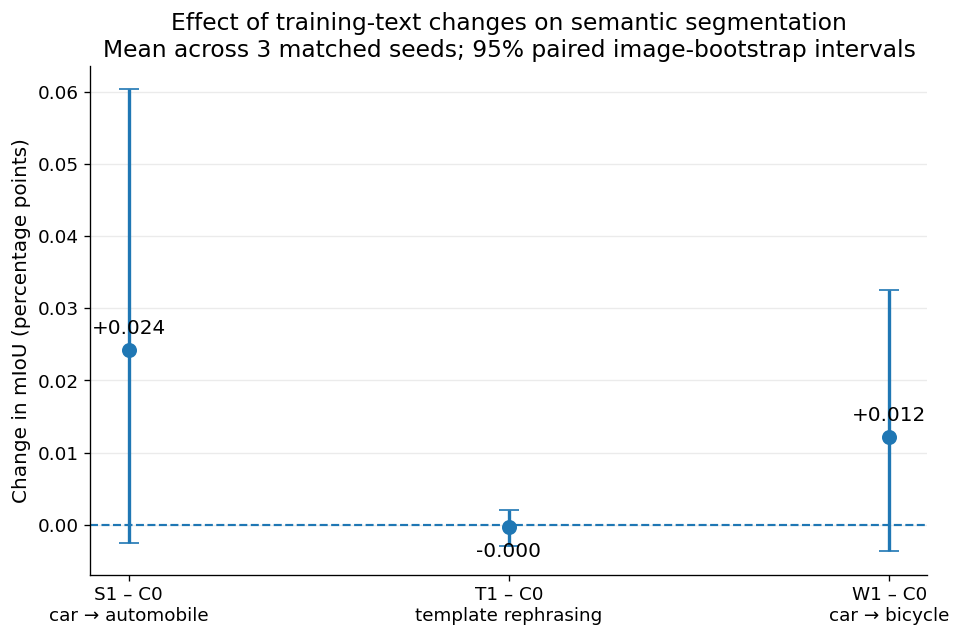

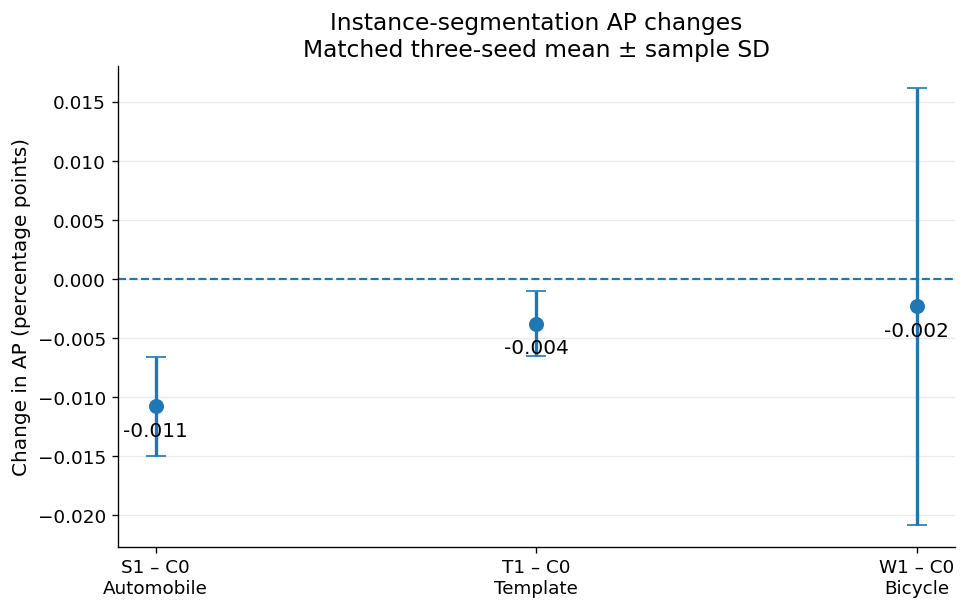

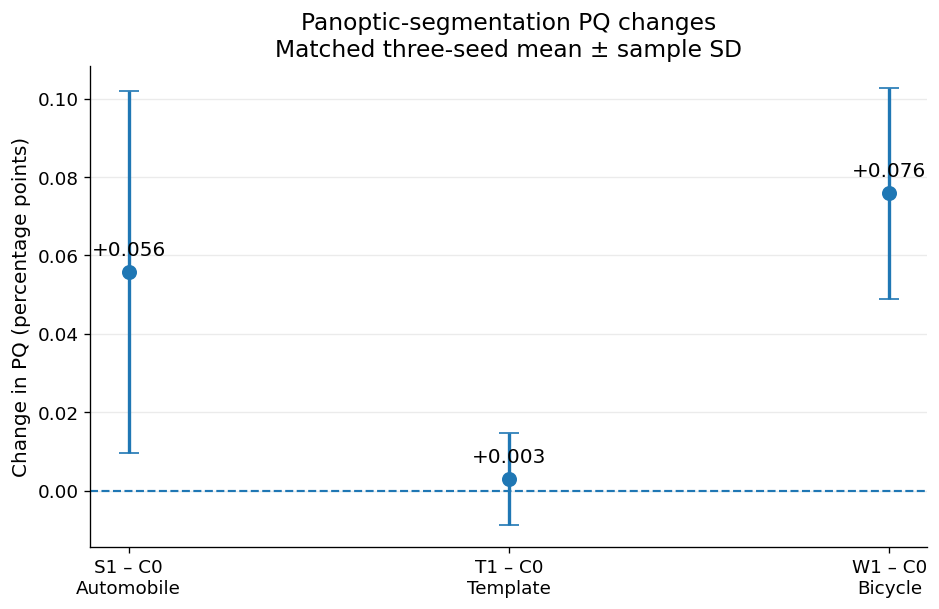

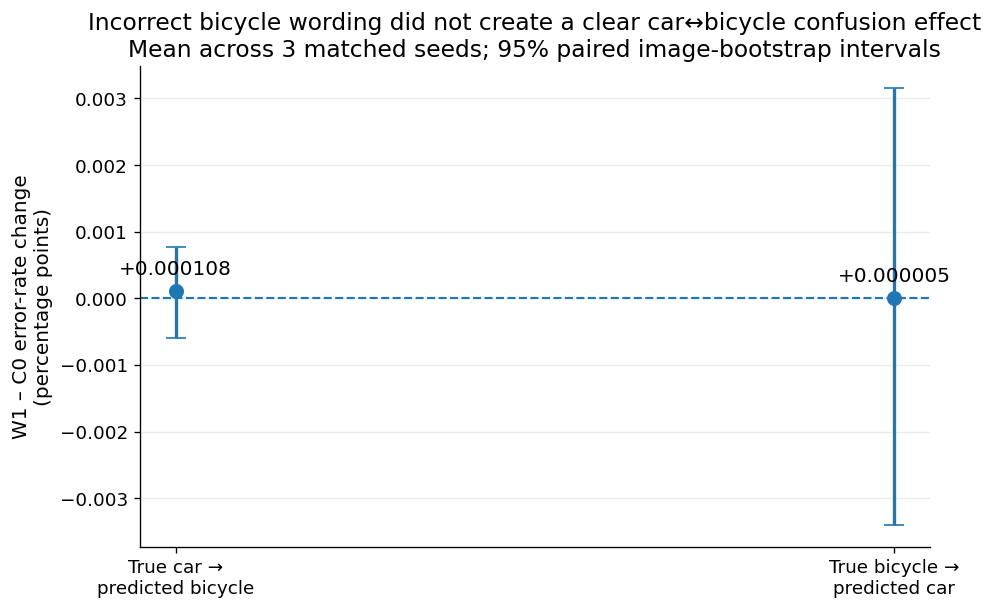


QUALITATIVE SELECTION

Representative:
index                                                         314
image_name                   lindau_000047_000019_leftImg8bit.png
ground_truth_car_pixels                                     14611
C0_per_image_mIoU                                       51.837859
S1_per_image_mIoU                                        51.87091
T1_per_image_mIoU                                       51.834303
W1_per_image_mIoU                                       51.833506
selection_change_score_pp                                0.033051

Stress test:
index                                                          399
image_name                   munster_000073_000019_leftImg8bit.png
ground_truth_car_pixels                                     263203
C0_per_image_mIoU                                         65.77109
S1_per_image_mIoU                                        59.801629
T1_per_image_mIoU                                         65.77109
W1_per_image_mIo

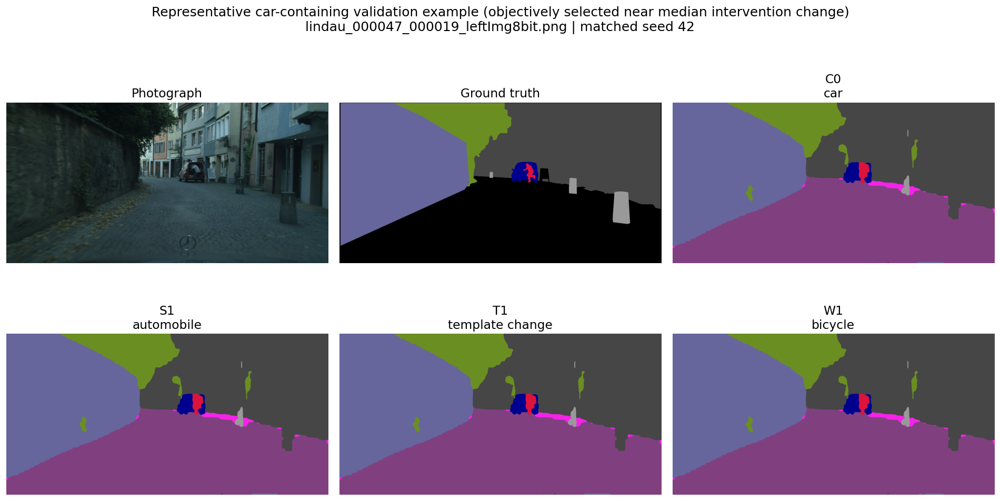

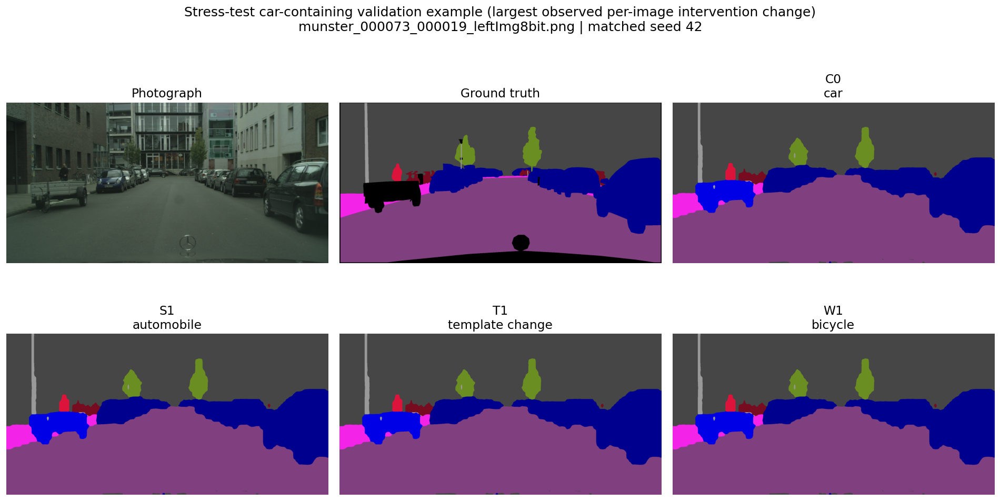


FINAL PRESENTATION ASSETS CREATED
Folder:
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/final_presentation_assets/presentation_assets_20260923_202348_414750

Files:
  README.txt
  figure_01_mIoU_bootstrap_effects.pdf
  figure_01_mIoU_bootstrap_effects.png
  figure_02_AP_effects.pdf
  figure_02_AP_effects.png
  figure_03_PQ_effects.pdf
  figure_03_PQ_effects.png
  figure_04_W1_car_bicycle_confusion.pdf
  figure_04_W1_car_bicycle_confusion.png
  figure_05_qualitative_representative.pdf
  figure_05_qualitative_representative.png
  figure_06_qualitative_stress_test.pdf
  figure_06_qualitative_stress_test.png
  qualitative_selected_images.csv
  qualitative_selection_scores.csv
  table_01_baseline_reproduction.csv
  table_02_main_corrected_results.csv
  table_02_main_corrected_results_PRESENTATION.csv
  table_03_intervention_effects_vs_C0.csv

No model loaded.
No training performed.
No inference performed.


In [ ]:
# ============================================================
# FINAL PRESENTATION / REPORT ASSETS
# Corrected OneFormer Cityscapes wording experiment
#
# Creates:
#   - Clean baseline table
#   - Clean final-results table
#   - Clean paired-effects table
#   - mIoU bootstrap figure
#   - AP/PQ paired-effect figures
#   - W1 car/bicycle diagnostic figure
#   - Representative qualitative example
#   - Stress-test qualitative example
#
# NO TRAINING
# NO INFERENCE
# NO MODEL LOADING
# Uses only verified saved results/predictions.
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
from io import BytesIO
import json
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/ONEFORMER_DATA")

VAL = (
    ROOT
    / "pilots/corrected_wording_20260920_102817_389509"
    / "validation_500"
)

SEMANTIC_SUMMARY = (
    VAL
    / "corrected_all_conditions_summary_20260920_205930_959989"
)

BOOTSTRAP = (
    VAL
    / "corrected_paired_image_bootstrap_20260920_212245_198373"
)

CONFUSION = (
    VAL
    / "corrected_car_bicycle_confusion_20260920_211609_942464"
)

assert VAL.is_dir(), "Mount Google Drive first."
assert SEMANTIC_SUMMARY.is_dir()
assert BOOTSTRAP.is_dir()
assert CONFUSION.is_dir()

# Find the verified AP/PQ reporting package already created.
ap_pq_packages = sorted(
    (VAL / "reporting").glob("PRL_AP_PQ_reporting_*")
)

assert ap_pq_packages, (
    "Could not find the AP/PQ reporting package."
)

AP_PQ_REPORT = ap_pq_packages[-1]

stamp = datetime.now(
    timezone.utc
).strftime("%Y%m%d_%H%M%S_%f")

OUT = (
    VAL
    / "final_presentation_assets"
    / f"presentation_assets_{stamp}"
)

OUT.mkdir(parents=True, exist_ok=False)

print("Output folder:")
print(OUT)


# ------------------------------------------------------------
# Appearance
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})


CONDITION_LABELS = {
    "B0": "B0\nStarting model",
    "C0": "C0\ncar",
    "S1": "S1\nautomobile",
    "T1": "T1\ntemplate change",
    "W1": "W1\nbicycle",
}

SHORT_LABELS = {
    "S1 minus C0": "S1 – C0\nAutomobile",
    "T1 minus C0": "T1 – C0\nTemplate",
    "W1 minus C0": "W1 – C0\nBicycle",
}


# ============================================================
# 1. BASELINE REPRODUCTION TABLE
# ============================================================

baseline_table = pd.DataFrame({
    "Metric": [
        "Semantic mIoU",
        "Instance AP",
        "Panoptic PQ",
    ],
    "Published Swin-L (%)": [
        83.00,
        45.60,
        67.20,
    ],
    "Reproduced (%)": [
        82.74,
        45.53,
        66.55,
    ],
})

baseline_table["Difference (pp)"] = (
    baseline_table["Reproduced (%)"]
    - baseline_table["Published Swin-L (%)"]
)

baseline_table.to_csv(
    OUT / "table_01_baseline_reproduction.csv",
    index=False,
)

print("\nTABLE 1 — BASELINE REPRODUCTION")
print(
    baseline_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}",
    )
)


# ============================================================
# 2. LOAD CORRECTED SEMANTIC RESULTS
# ============================================================

semantic = pd.read_csv(
    SEMANTIC_SUMMARY / "condition_miou_summary.csv"
)

semantic = semantic.rename(columns={
    "Condition": "condition",
    "Mean mIoU (%)": "mIoU_mean",
    "Sample SD (pp)": "mIoU_SD",
})


# ============================================================
# 3. LOAD AP/PQ CONDITION SUMMARY
# ============================================================

ap_pq_path = (
    AP_PQ_REPORT
    / "condition_AP_PQ_means_and_SD.csv"
)

assert ap_pq_path.is_file(), ap_pq_path

ap_pq = pd.read_csv(ap_pq_path)

# Expected long-format columns from your verified reporting cell:
# condition, metric, runs, mean_percent, sample_SD_percent

assert {
    "condition",
    "metric",
    "mean_percent",
    "sample_SD_percent",
}.issubset(ap_pq.columns)

def metric_frame(metric, prefix):
    current = (
        ap_pq[
            ap_pq["metric"] == metric
        ][
            [
                "condition",
                "mean_percent",
                "sample_SD_percent",
            ]
        ]
        .copy()
        .rename(columns={
            "mean_percent": f"{prefix}_mean",
            "sample_SD_percent": f"{prefix}_SD",
        })
    )
    return current


ap = metric_frame("AP_percent", "AP")
pq = metric_frame("PQ_percent", "PQ")


# ============================================================
# 4. CLEAN MAIN RESULTS TABLE
# ============================================================

main = (
    semantic[
        ["condition", "mIoU_mean", "mIoU_SD"]
    ]
    .merge(ap, on="condition", how="left")
    .merge(pq, on="condition", how="left")
)

order = ["B0", "C0", "S1", "T1", "W1"]

main["order"] = main["condition"].map({
    name: i for i, name in enumerate(order)
})

main = (
    main
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

descriptions = {
    "B0": "Starting pretrained reference",
    "C0": "a photo with a car",
    "S1": "a photo with an automobile",
    "T1": "a photograph containing a car",
    "W1": "a photo with a bicycle",
}

main.insert(
    1,
    "Training description",
    main["condition"].map(descriptions),
)

main.to_csv(
    OUT / "table_02_main_corrected_results.csv",
    index=False,
)

print("\nTABLE 2 — MAIN CORRECTED RESULTS")
print(
    main.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}",
    )
)


# A presentation-friendly formatted version.
def mean_sd(mean, sd):
    if pd.isna(sd):
        return f"{mean:.3f}"
    return f"{mean:.3f} ± {sd:.3f}"


presentation_main = pd.DataFrame({
    "Condition": main["condition"],
    "Text": main["Training description"],
    "mIoU (%)": [
        mean_sd(m, s)
        for m, s in zip(
            main["mIoU_mean"],
            main["mIoU_SD"],
        )
    ],
    "AP (%)": [
        mean_sd(m, s)
        for m, s in zip(
            main["AP_mean"],
            main["AP_SD"],
        )
    ],
    "PQ (%)": [
        mean_sd(m, s)
        for m, s in zip(
            main["PQ_mean"],
            main["PQ_SD"],
        )
    ],
})

presentation_main.to_csv(
    OUT / "table_02_main_corrected_results_PRESENTATION.csv",
    index=False,
)

print("\nPRESENTATION VERSION")
print(presentation_main.to_string(index=False))


# ============================================================
# 5. BOOTSTRAP mIoU EFFECTS
# ============================================================

bootstrap = pd.read_csv(
    BOOTSTRAP / "fixed_three_seed_mean_intervals.csv"
)

miou_boot = bootstrap[
    bootstrap["Metric"] == "mIoU"
].copy()

comparison_order = [
    "S1 minus C0",
    "T1 minus C0",
    "W1 minus C0",
]

miou_boot["order"] = miou_boot["Comparison"].map({
    name: i for i, name in enumerate(comparison_order)
})

miou_boot = (
    miou_boot
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

assert len(miou_boot) == 3


# ============================================================
# 6. LOAD PAIRED AP/PQ EFFECTS
# ============================================================

paired_ap_pq = pd.read_csv(
    AP_PQ_REPORT
    / "three_seed_AP_PQ_comparisons.csv"
)

paired_ap_pq["comparison"] = (
    paired_ap_pq["comparison"]
    .str.replace("_minus_", " minus ", regex=False)
)

ap_effects = paired_ap_pq[
    paired_ap_pq["metric"] == "AP_percent"
].copy()

pq_effects = paired_ap_pq[
    paired_ap_pq["metric"] == "PQ_percent"
].copy()


# ============================================================
# 7. CLEAN INTERVENTION-EFFECT TABLE
# ============================================================

effect_rows = []

for comparison in comparison_order:

    sem = miou_boot[
        miou_boot["Comparison"] == comparison
    ].iloc[0]

    ap_row = ap_effects[
        ap_effects["comparison"] == comparison
    ].iloc[0]

    pq_row = pq_effects[
        pq_effects["comparison"] == comparison
    ].iloc[0]

    effect_rows.append({
        "Comparison": comparison,
        "mIoU mean difference (pp)":
            sem["Mean paired difference (pp)"],
        "mIoU bootstrap 95% lower (pp)":
            sem["95% interval lower (pp)"],
        "mIoU bootstrap 95% upper (pp)":
            sem["95% interval upper (pp)"],
        "AP mean difference (pp)":
            ap_row["mean_paired_difference_pp"],
        "AP paired SD (pp)":
            ap_row["paired_difference_sample_SD_pp"],
        "PQ mean difference (pp)":
            pq_row["mean_paired_difference_pp"],
        "PQ paired SD (pp)":
            pq_row["paired_difference_sample_SD_pp"],
    })

effects = pd.DataFrame(effect_rows)

effects.to_csv(
    OUT / "table_03_intervention_effects_vs_C0.csv",
    index=False,
)

print("\nTABLE 3 — INTERVENTION EFFECTS VS C0")
print(
    effects.to_string(
        index=False,
        float_format=lambda x: f"{x:+.6f}",
    )
)


# ============================================================
# FIGURE 1
# mIoU effect + 95% image-bootstrap interval
# ============================================================

x = np.arange(3)

means = miou_boot[
    "Mean paired difference (pp)"
].to_numpy()

low = miou_boot[
    "95% interval lower (pp)"
].to_numpy()

high = miou_boot[
    "95% interval upper (pp)"
].to_numpy()

errors = np.vstack([
    means - low,
    high - means,
])

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.axhline(
    0,
    linewidth=1.3,
    linestyle="--",
)

ax.errorbar(
    x,
    means,
    yerr=errors,
    fmt="o",
    markersize=8,
    capsize=6,
    linewidth=2,
)

ax.set_xticks(x)

ax.set_xticklabels([
    "S1 – C0\ncar → automobile",
    "T1 – C0\ntemplate rephrasing",
    "W1 – C0\ncar → bicycle",
])

ax.set_ylabel("Change in mIoU (percentage points)")

ax.set_title(
    "Effect of training-text changes on semantic segmentation\n"
    "Mean across 3 matched seeds; 95% paired image-bootstrap intervals"
)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, value in enumerate(means):
    ax.annotate(
        f"{value:+.3f}",
        (i, value),
        xytext=(0, 10 if value >= 0 else -18),
        textcoords="offset points",
        ha="center",
    )

fig.savefig(
    OUT / "figure_01_mIoU_bootstrap_effects.png"
)
fig.savefig(
    OUT / "figure_01_mIoU_bootstrap_effects.pdf"
)

plt.show()


# ============================================================
# FIGURE 2A
# AP effects
# ============================================================

def ordered_effects(frame):
    temp = frame.copy()

    temp["order"] = temp["comparison"].map({
        name: i for i, name in enumerate(comparison_order)
    })

    return (
        temp.sort_values("order")
        .drop(columns="order")
        .reset_index(drop=True)
    )


ap_plot = ordered_effects(ap_effects)
pq_plot = ordered_effects(pq_effects)


fig, ax = plt.subplots(figsize=(9, 5.2))

x = np.arange(3)

means = ap_plot[
    "mean_paired_difference_pp"
].to_numpy()

sd = ap_plot[
    "paired_difference_sample_SD_pp"
].to_numpy()

ax.axhline(0, linestyle="--", linewidth=1.3)

ax.errorbar(
    x,
    means,
    yerr=sd,
    fmt="o",
    capsize=6,
    markersize=8,
    linewidth=2,
)

ax.set_xticks(x)
ax.set_xticklabels([
    "S1 – C0\nAutomobile",
    "T1 – C0\nTemplate",
    "W1 – C0\nBicycle",
])

ax.set_ylabel("Change in AP (percentage points)")
ax.set_title(
    "Instance-segmentation AP changes\n"
    "Matched three-seed mean ± sample SD"
)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, value in enumerate(means):
    ax.annotate(
        f"{value:+.3f}",
        (i, value),
        xytext=(0, 10 if value >= 0 else -18),
        textcoords="offset points",
        ha="center",
    )

fig.savefig(OUT / "figure_02_AP_effects.png")
fig.savefig(OUT / "figure_02_AP_effects.pdf")

plt.show()


# ============================================================
# FIGURE 2B
# PQ effects
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5.2))

means = pq_plot[
    "mean_paired_difference_pp"
].to_numpy()

sd = pq_plot[
    "paired_difference_sample_SD_pp"
].to_numpy()

ax.axhline(0, linestyle="--", linewidth=1.3)

ax.errorbar(
    x,
    means,
    yerr=sd,
    fmt="o",
    capsize=6,
    markersize=8,
    linewidth=2,
)

ax.set_xticks(x)
ax.set_xticklabels([
    "S1 – C0\nAutomobile",
    "T1 – C0\nTemplate",
    "W1 – C0\nBicycle",
])

ax.set_ylabel("Change in PQ (percentage points)")
ax.set_title(
    "Panoptic-segmentation PQ changes\n"
    "Matched three-seed mean ± sample SD"
)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, value in enumerate(means):
    ax.annotate(
        f"{value:+.3f}",
        (i, value),
        xytext=(0, 10 if value >= 0 else -18),
        textcoords="offset points",
        ha="center",
    )

fig.savefig(OUT / "figure_03_PQ_effects.png")
fig.savefig(OUT / "figure_03_PQ_effects.pdf")

plt.show()


# ============================================================
# FIGURE 3 / 4
# W1 car↔bicycle error diagnostic using saved bootstrap CIs
# ============================================================

error_boot = bootstrap[
    (
        (bootstrap["Comparison"] == "W1 minus C0")
        &
        (
            bootstrap["Metric"].isin([
                "Car-to-bicycle error rate",
                "Bicycle-to-car error rate",
            ])
        )
    )
].copy()

error_order = [
    "Car-to-bicycle error rate",
    "Bicycle-to-car error rate",
]

error_boot["order"] = error_boot["Metric"].map({
    name: i for i, name in enumerate(error_order)
})

error_boot = (
    error_boot
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

assert len(error_boot) == 2

means = error_boot[
    "Mean paired difference (pp)"
].to_numpy()

low = error_boot[
    "95% interval lower (pp)"
].to_numpy()

high = error_boot[
    "95% interval upper (pp)"
].to_numpy()

errors = np.vstack([
    means - low,
    high - means,
])

fig, ax = plt.subplots(figsize=(8.5, 5.2))

x2 = np.arange(2)

ax.axhline(0, linestyle="--", linewidth=1.3)

ax.errorbar(
    x2,
    means,
    yerr=errors,
    fmt="o",
    markersize=8,
    capsize=6,
    linewidth=2,
)

ax.set_xticks(x2)

ax.set_xticklabels([
    "True car →\npredicted bicycle",
    "True bicycle →\npredicted car",
])

ax.set_ylabel(
    "W1 – C0 error-rate change\n(percentage points)"
)

ax.set_title(
    "Incorrect bicycle wording did not create a clear car↔bicycle confusion effect\n"
    "Mean across 3 matched seeds; 95% paired image-bootstrap intervals"
)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, value in enumerate(means):
    ax.annotate(
        f"{value:+.6f}",
        (i, value),
        xytext=(0, 10 if value >= 0 else -18),
        textcoords="offset points",
        ha="center",
    )

fig.savefig(
    OUT / "figure_04_W1_car_bicycle_confusion.png"
)
fig.savefig(
    OUT / "figure_04_W1_car_bicycle_confusion.pdf"
)

plt.show()


# ============================================================
# QUALITATIVE EXAMPLES
#
# Objective selection:
#   - seed 42 for all conditions
#   - only validation images containing ground-truth car pixels
#   - compute per-image mIoU for C0/S1/T1/W1
#   - define change score = maximum absolute intervention-C0
#     per-image mIoU difference
#
# Representative example:
#   car image closest to median change score
#
# Stress-test example:
#   car image with largest change score
#
# This avoids manual/cherry-picked selection.
# ============================================================

PROTOCOL = json.loads(
    (VAL / "evaluation_protocol.json").read_text()
)

CLASS_NAMES = PROTOCOL["class_names"]

assert CLASS_NAMES[13] == "car"

models_seed42 = [
    "C0_seed42",
    "S1_seed42",
    "T1_seed42",
    "W1_seed42",
]


def per_image_miou(matrix):
    matrix = matrix.astype(np.float64)

    tp = np.diag(matrix)

    union = (
        matrix.sum(axis=0)
        + matrix.sum(axis=1)
        - tp
    )

    valid = union > 0

    if not valid.any():
        return np.nan

    return float(
        (100 * tp[valid] / union[valid]).mean()
    )


per_image_matrices = {}

for model_name in models_seed42:

    with np.load(
        VAL
        / "evaluations"
        / model_name
        / "confusion_matrices.npz",
        allow_pickle=False,
    ) as saved:

        per_image_matrices[model_name] = (
            saved["per_image"].copy()
        )

    assert (
        per_image_matrices[model_name].shape
        == (500, 19, 19)
    )


selection_rows = []

for index in range(500):

    control_matrix = (
        per_image_matrices["C0_seed42"][index]
    )

    # GT class pixel counts are row sums.
    car_pixels = int(
        control_matrix[13, :].sum()
    )

    if car_pixels == 0:
        continue

    scores = {
        model: per_image_miou(
            per_image_matrices[model][index]
        )
        for model in models_seed42
    }

    control = scores["C0_seed42"]

    changes = [
        abs(scores[model] - control)
        for model in (
            "S1_seed42",
            "T1_seed42",
            "W1_seed42",
        )
    ]

    selection_rows.append({
        "index": index,
        "image_name":
            PROTOCOL["manifest"][index]["image_name"],
        "ground_truth_car_pixels": car_pixels,
        "C0_per_image_mIoU": control,
        "S1_per_image_mIoU":
            scores["S1_seed42"],
        "T1_per_image_mIoU":
            scores["T1_seed42"],
        "W1_per_image_mIoU":
            scores["W1_seed42"],
        "selection_change_score_pp":
            max(changes),
    })


selection = pd.DataFrame(selection_rows)

assert len(selection) > 0

selection = selection.sort_values(
    "selection_change_score_pp"
).reset_index(drop=True)

median_value = float(
    selection[
        "selection_change_score_pp"
    ].median()
)

representative_position = (
    selection["selection_change_score_pp"]
    - median_value
).abs().idxmin()

representative = selection.loc[
    representative_position
].copy()

stress = selection.iloc[-1].copy()


selection.to_csv(
    OUT / "qualitative_selection_scores.csv",
    index=False,
)

pd.DataFrame([
    {
        "Example": "Representative",
        **representative.to_dict(),
    },
    {
        "Example": "Stress test",
        **stress.to_dict(),
    },
]).to_csv(
    OUT / "qualitative_selected_images.csv",
    index=False,
)


# ------------------------------------------------------------
# Cityscapes palette
# ------------------------------------------------------------

PALETTE = np.array([
    [128, 64, 128],   # road
    [244, 35, 232],   # sidewalk
    [70, 70, 70],     # building
    [102, 102, 156],  # wall
    [190, 153, 153],  # fence
    [153, 153, 153],  # pole
    [250, 170, 30],   # traffic light
    [220, 220, 0],    # traffic sign
    [107, 142, 35],   # vegetation
    [152, 251, 152],  # terrain
    [70, 130, 180],   # sky
    [220, 20, 60],    # person
    [255, 0, 0],      # rider
    [0, 0, 142],      # car
    [0, 0, 70],       # truck
    [0, 60, 100],     # bus
    [0, 80, 100],     # train
    [0, 0, 230],      # motorcycle
    [119, 11, 32],    # bicycle
], dtype=np.uint8)


lookup = np.full(
    256,
    255,
    dtype=np.uint8,
)

for train_id, original_id in enumerate(
    PROTOCOL["original_label_ids_in_train_id_order"]
):
    lookup[original_id] = train_id


def colour_train_ids(ids):
    result = np.zeros(
        (*ids.shape, 3),
        dtype=np.uint8,
    )

    valid = (ids >= 0) & (ids < 19)

    result[valid] = PALETTE[
        ids[valid].astype(np.int64)
    ]

    return result


# ------------------------------------------------------------
# Load raw photograph + GT from frozen validation archives
# ------------------------------------------------------------

image_archive = Path(
    PROTOCOL["image_archive"]
)

label_archive = Path(
    PROTOCOL["label_archive"]
)

assert image_archive.is_file()
assert label_archive.is_file()


def create_qualitative_panel(
    row,
    filename,
    heading,
):

    index = int(row["index"])

    item = PROTOCOL["manifest"][index]

    with zipfile.ZipFile(image_archive) as archive:

        with Image.open(
            BytesIO(
                archive.read(
                    item["image_member"]
                )
            )
        ) as source:

            photograph = np.array(
                source.convert("RGB")
            )

    with zipfile.ZipFile(label_archive) as archive:

        with Image.open(
            BytesIO(
                archive.read(
                    item["label_member"]
                )
            )
        ) as source:

            raw_gt = np.array(source)

    ground_truth = lookup[raw_gt]

    prediction_arrays = {}

    for model_name in models_seed42:

        pred_path = (
            VAL
            / "evaluations"
            / model_name
            / "predictions"
            / item["image_name"].replace(
                "_leftImg8bit.png",
                "_prediction_trainIds.png",
            )
        )

        assert pred_path.is_file(), pred_path

        prediction_arrays[model_name] = np.array(
            Image.open(pred_path)
        )

        assert (
            prediction_arrays[model_name].shape
            == ground_truth.shape
        )

    pictures = [
        photograph,
        colour_train_ids(ground_truth),
        colour_train_ids(
            prediction_arrays["C0_seed42"]
        ),
        colour_train_ids(
            prediction_arrays["S1_seed42"]
        ),
        colour_train_ids(
            prediction_arrays["T1_seed42"]
        ),
        colour_train_ids(
            prediction_arrays["W1_seed42"]
        ),
    ]

    titles = [
        "Photograph",
        "Ground truth",
        "C0\ncar",
        "S1\nautomobile",
        "T1\ntemplate change",
        "W1\nbicycle",
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(16, 9),
    )

    for ax, picture, title in zip(
        axes.flat,
        pictures,
        titles,
    ):
        ax.imshow(picture)
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(
        heading
        + "\n"
        + item["image_name"]
        + " | matched seed 42",
        fontsize=15,
    )

    fig.tight_layout()

    fig.savefig(OUT / f"{filename}.png")
    fig.savefig(OUT / f"{filename}.pdf")

    plt.show()


print("\nQUALITATIVE SELECTION")

print("\nRepresentative:")
print(
    representative.to_string()
)

print("\nStress test:")
print(
    stress.to_string()
)


create_qualitative_panel(
    representative,
    "figure_05_qualitative_representative",
    (
        "Representative car-containing validation example "
        "(objectively selected near median intervention change)"
    ),
)

create_qualitative_panel(
    stress,
    "figure_06_qualitative_stress_test",
    (
        "Stress-test car-containing validation example "
        "(largest observed per-image intervention change)"
    ),
)


# ============================================================
# 10. README for future use
# ============================================================

readme = f"""
FINAL PRESENTATION ASSETS
=========================

Experiment:
Corrected OneFormer Cityscapes class-text robustness experiment.

Generated:
{datetime.now(timezone.utc).isoformat()}

Numeric assets
--------------
table_01_baseline_reproduction.csv

table_02_main_corrected_results.csv
table_02_main_corrected_results_PRESENTATION.csv

table_03_intervention_effects_vs_C0.csv

Figures
-------
figure_01_mIoU_bootstrap_effects
    S1/T1/W1 matched effects versus C0.
    Error bars = paired 95% image-bootstrap intervals.

figure_02_AP_effects
    Matched 3-seed AP effects versus C0.
    Error bars = sample SD across paired seed differences.

figure_03_PQ_effects
    Matched 3-seed PQ effects versus C0.
    Error bars = sample SD across paired seed differences.

figure_04_W1_car_bicycle_confusion
    Direct car↔bicycle semantic confusion diagnostic.
    Error bars = paired 95% image-bootstrap intervals.

figure_05_qualitative_representative
    Car-containing image objectively selected closest
    to the median per-image intervention-change score.

figure_06_qualitative_stress_test
    Car-containing image with the largest observed
    per-image intervention-change score.

Important interpretation
------------------------
The official baseline reproduction and the corrected wording
fine-tuning experiment use different evaluation/input protocols.
Do not directly interpret 82.74 baseline mIoU and approximately
69 corrected-experiment mIoU as a training degradation comparison.

Correct wording comparisons are:
S1 versus matched C0
T1 versus matched C0
W1 versus matched C0

B0 is useful for showing the effect of additional fine-tuning,
but it does not isolate the effect of wording.

Qualitative examples use seed 42 consistently across
C0/S1/T1/W1 and are selected algorithmically rather than manually.

No model was loaded.
No training was performed.
No inference was performed.
Existing saved predictions and verified numerical results were used.
"""

(OUT / "README.txt").write_text(
    readme,
    encoding="utf-8",
)

print("\n" + "=" * 70)
print("FINAL PRESENTATION ASSETS CREATED")
print("=" * 70)

print("Folder:")
print(OUT)

print("\nFiles:")
for path in sorted(OUT.iterdir()):
    print(" ", path.name)

print("\nNo model loaded.")
print("No training performed.")
print("No inference performed.")

In [ ]:
!pip install -q --force-reinstall "transformers==5.16.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.9/842.9 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 804.6/804.6 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================================
# FINAL FIXED-REFERENCE TEXT EMBEDDING SIMILARITY ANALYSIS
# OneFormer Cityscapes corrected wording experiment
#
# PURPOSE
# -------
# Measure how similar the actual OneFormer text embeddings are for:
#
#   C0 = "a photo with a car"
#   S1 = "a photo with an automobile"
#   T1 = "a photograph containing a car"
#   W1 = "a photo with a bicycle"
#
# IMPORTANT
# ---------
# - Uses ONE fixed reference text encoder.
# - Uses the SAME common initial weights shared by all conditions.
# - Uses the same corrected causal-attention-mask mechanism.
# - Does NOT use fine-tuned encoders.
# - Does NOT train.
# - Does NOT run segmentation inference.
# - Does NOT modify experiment files.
#
# Original controlled experiments:
#   Transformers 5.16.1
#
# This post-hoc analysis:
#   Allows Transformers 5.16.1 or 5.17.0
#   and records the exact version used.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import transformers

from transformers import (
    OneFormerConfig,
    OneFormerForUniversalSegmentation,
    OneFormerProcessor,
)


# ============================================================
# 1. SOFTWARE / DEVICE INFORMATION
# ============================================================

print("=" * 70)
print("ENVIRONMENT")
print("=" * 70)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

assert transformers.__version__ in {
    "5.16.1",
    "5.17.0",
}, (
    "Unexpected Transformers version: "
    f"{transformers.__version__}"
)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )


# ============================================================
# 2. PROJECT PATHS
# ============================================================

ROOT = Path(
    "/content/drive/MyDrive/ONEFORMER_DATA"
)

CORRECTED_RUN = (
    ROOT
    / "pilots"
    / "corrected_wording_20260920_102817_389509"
)

C0_RUN = (
    CORRECTED_RUN
    / "C0_seed42"
)

ORIGINAL_SETUP = (
    ROOT
    / "pilots"
    / "two_image_optimizer_20260917_211825_497623"
)

PROCESSOR_SOURCE = (
    ROOT
    / "pilot_data"
    / "prepared_train_20260918_215631_453240"
)

VALIDATION = (
    CORRECTED_RUN
    / "validation_500"
)


# ============================================================
# 3. PATH CHECKS
# ============================================================

assert ROOT.is_dir(), (
    "ONEFORMER_DATA not found.\n"
    "Mount Google Drive first."
)

assert CORRECTED_RUN.is_dir(), (
    f"Missing corrected experiment folder:\n"
    f"{CORRECTED_RUN}"
)

assert C0_RUN.is_dir(), (
    f"Missing C0 seed42 folder:\n"
    f"{C0_RUN}"
)

assert ORIGINAL_SETUP.is_dir(), (
    f"Missing original setup folder:\n"
    f"{ORIGINAL_SETUP}"
)

assert (
    PROCESSOR_SOURCE / "processor"
).is_dir(), (
    "Saved processor folder not found:\n"
    f"{PROCESSOR_SOURCE / 'processor'}"
)

assert VALIDATION.is_dir(), (
    f"Missing validation folder:\n"
    f"{VALIDATION}"
)

print("\nProject paths verified.")


# ============================================================
# 4. SHA-256 HELPER
# ============================================================

def sha256_file(path):

    h = hashlib.sha256()

    with open(path, "rb") as handle:

        for chunk in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            h.update(chunk)

    return h.hexdigest()


# ============================================================
# 5. LOAD EXPERIMENT SETTINGS
# ============================================================

settings_path = (
    C0_RUN
    / "settings.json"
)

assert settings_path.is_file(), (
    f"Missing:\n{settings_path}"
)

settings = json.loads(
    settings_path.read_text(
        encoding="utf-8"
    )
)


# ============================================================
# 6. LOCATE COMMON INITIAL WEIGHTS
# ============================================================

assert (
    "common_initial_weights"
    in settings
), (
    "settings.json does not contain "
    "'common_initial_weights'."
)

starting_weights = Path(
    settings[
        "common_initial_weights"
    ]
)

assert starting_weights.is_file(), (
    "Common initial weights not found:\n"
    f"{starting_weights}"
)

actual_start_hash = sha256_file(
    starting_weights
)

print("\n" + "=" * 70)
print("FIXED REFERENCE CHECKPOINT")
print("=" * 70)

print(starting_weights)
print("SHA-256:")
print(actual_start_hash)


# Verify recorded hash if available.
if (
    "common_initial_weights_sha256"
    in settings
):

    expected_hash = settings[
        "common_initial_weights_sha256"
    ]

    assert (
        actual_start_hash
        == expected_hash
    ), (
        "Common initial checkpoint hash "
        "does not match settings.json."
    )

    print(
        "Checkpoint hash verification: PASS"
    )

else:

    print(
        "No saved checkpoint hash field found; "
        "current SHA-256 recorded above."
    )


# ============================================================
# 7. LOAD MODEL CONFIGURATION
# ============================================================

config_folder = (
    ORIGINAL_SETUP
    / "model_config"
)

assert config_folder.is_dir(), (
    f"Missing model config folder:\n"
    f"{config_folder}"
)

config = (
    OneFormerConfig.from_pretrained(
        str(config_folder),
        local_files_only=True,
    )
)

print("\nModel configuration loaded.")


# ============================================================
# 8. BUILD MODEL
# ============================================================

print(
    "\nBuilding OneFormer model..."
)

model = (
    OneFormerForUniversalSegmentation(
        config
    )
)


# ============================================================
# 9. STRICTLY LOAD COMMON INITIAL WEIGHTS
# ============================================================

print(
    "Loading fixed reference weights..."
)

state = torch.load(
    starting_weights,
    map_location="cpu",
    weights_only=True,
)

load_result = model.load_state_dict(
    state,
    strict=True,
)

del state

print(
    "Strict checkpoint loading: PASS"
)

print(
    "Missing keys:",
    len(load_result.missing_keys)
)

print(
    "Unexpected keys:",
    len(load_result.unexpected_keys)
)

assert (
    len(load_result.missing_keys) == 0
)

assert (
    len(load_result.unexpected_keys) == 0
)


# ============================================================
# 10. ACCESS TEXT ENCODER
# ============================================================

assert hasattr(
    model.model,
    "text_mapper"
), (
    "Model has no text_mapper."
)

assert hasattr(
    model.model.text_mapper,
    "text_encoder"
), (
    "text_mapper has no text_encoder."
)

encoder = (
    model.model
    .text_mapper
    .text_encoder
)

print(
    "\nText encoder located:"
)

print(
    "model.model.text_mapper.text_encoder"
)


# ============================================================
# 11. APPLY CORRECTED CAUSAL ATTENTION MASK
#
# This matches the correction already validated
# in your project.
# ============================================================

def causal_mask_hook(
    module,
    args,
    kwargs,
):

    query = args[0]

    if module.batch_first:

        sequence_length = (
            query.shape[1]
        )

    else:

        sequence_length = (
            query.shape[0]
        )

    causal_mask = torch.full(
        (
            sequence_length,
            sequence_length,
        ),
        float("-inf"),
        dtype=query.dtype,
        device=query.device,
    )

    causal_mask = torch.triu(
        causal_mask,
        diagonal=1,
    )

    kwargs = dict(kwargs)

    kwargs[
        "attn_mask"
    ] = causal_mask

    return args, kwargs


layers = list(
    encoder.transformer.layers
)

assert len(layers) == 6, (
    "Expected 6 text-transformer layers; "
    f"found {len(layers)}."
)

mask_handles = []

for layer in layers:

    handle = (
        layer
        .self_attn
        .register_forward_pre_hook(
            causal_mask_hook,
            with_kwargs=True,
        )
    )

    mask_handles.append(
        handle
    )

print(
    "\nCausal-mask hooks applied:",
    len(mask_handles),
)

assert len(mask_handles) == 6


# ============================================================
# 12. FREEZE / EVALUATION MODE
# ============================================================

encoder.eval()

for parameter in (
    encoder.parameters()
):

    parameter.requires_grad_(
        False
    )

encoder = encoder.to(
    device=device,
    dtype=torch.float32,
)

print(
    "Text encoder set to evaluation mode."
)

print(
    "Text encoder parameters frozen."
)


# ============================================================
# 13. RELEASE THE REST OF ONEFORMER
#
# We keep only the text encoder.
# ============================================================

del model

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 14. LOAD EXACT SAVED PROCESSOR
# ============================================================

processor_path = (
    PROCESSOR_SOURCE
    / "processor"
)

processor = (
    OneFormerProcessor
    .from_pretrained(
        str(processor_path),
        local_files_only=True,
    )
)

MAX_LENGTH = 77

print(
    "\nSaved OneFormer processor loaded."
)


# ============================================================
# 15. DEFINE EXPERIMENTAL DESCRIPTIONS
# ============================================================

condition_text = {

    "C0":
        "a photo with a car",

    "S1":
        "a photo with an automobile",

    "T1":
        "a photograph containing a car",

    "W1":
        "a photo with a bicycle",
}


condition_names = [
    "C0",
    "S1",
    "T1",
    "W1",
]


# ============================================================
# 16. CORRECT CITYSCAPES CLASS NAMES
# ============================================================

class_names = [

    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic light",
    "traffic sign",
    "vegetation",
    "terrain",
    "sky",
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "train",
    "motorcycle",
    "bicycle",
]


assert len(class_names) == 19

assert class_names[1] == "sidewalk"
assert class_names[2] == "building"
assert class_names[13] == "car"
assert class_names[18] == "bicycle"


class_text = {

    class_name:
        f"a photo with a {class_name}"

    for class_name
    in class_names
}


assert (
    class_text["car"]
    == condition_text["C0"]
)

assert (
    class_text["bicycle"]
    == condition_text["W1"]
)


# ============================================================
# 17. TEXT ENCODING FUNCTION
# ============================================================

def encode_text(
    descriptions
):

    # Same internal text preprocessing mechanism
    # used in your OneFormer experiments.

    token_array = (
        processor._preprocess_text(
            descriptions,
            max_length=MAX_LENGTH,
        )
    )

    tokens = torch.as_tensor(
        token_array,
        dtype=torch.long,
    )

    assert tokens.ndim == 2

    assert (
        tokens.shape[0]
        == len(descriptions)
    )

    assert (
        tokens.shape[1]
        == MAX_LENGTH
    )

    with torch.inference_mode():

        output = encoder(
            tokens.to(device)
        )

    # In your validated OneFormer implementation,
    # text_encoder returns one embedding vector
    # per description.

    if torch.is_tensor(output):

        embeddings = output

    else:

        raise TypeError(
            "\nUnexpected text_encoder output type:\n"
            f"{type(output)}\n\n"
            "Stop here rather than applying an "
            "unverified pooling rule."
        )

    assert embeddings.ndim == 2, (
        "Expected one embedding vector per text.\n"
        f"Received shape: "
        f"{tuple(embeddings.shape)}"
    )

    assert (
        embeddings.shape[0]
        == len(descriptions)
    )

    assert torch.isfinite(
        embeddings
    ).all().item()

    return (
        tokens.cpu(),
        embeddings
        .detach()
        .float()
        .cpu(),
    )


# ============================================================
# 18. ENCODE EXPERIMENT CONDITIONS
# ============================================================

condition_descriptions = [

    condition_text[name]

    for name
    in condition_names
]


condition_tokens, condition_embeddings = (
    encode_text(
        condition_descriptions
    )
)


# ============================================================
# 19. ENCODE ORIGINAL 19 CITYSCAPES TEMPLATES
# ============================================================

class_descriptions = [

    class_text[name]

    for name
    in class_names
]


class_tokens, class_embeddings = (
    encode_text(
        class_descriptions
    )
)


print(
    "\nText encoding completed."
)

print(
    "Condition embedding shape:",
    tuple(
        condition_embeddings.shape
    ),
)

print(
    "Class-template embedding shape:",
    tuple(
        class_embeddings.shape
    ),
)


# ============================================================
# 20. L2 NORMALIZATION
# ============================================================

condition_norm = F.normalize(
    condition_embeddings,
    p=2,
    dim=1,
)

class_norm = F.normalize(
    class_embeddings,
    p=2,
    dim=1,
)


# ============================================================
# 21. COSINE SIMILARITY MATRICES
# ============================================================

condition_cosine = (
    condition_norm
    @ condition_norm.T
)

condition_to_classes = (
    condition_norm
    @ class_norm.T
)


assert torch.isfinite(
    condition_cosine
).all()

assert torch.isfinite(
    condition_to_classes
).all()


# ============================================================
# 22. SANITY CHECKS
# ============================================================

c0_index = (
    condition_names
    .index("C0")
)

w1_index = (
    condition_names
    .index("W1")
)

car_index = (
    class_names
    .index("car")
)

bicycle_index = (
    class_names
    .index("bicycle")
)


c0_to_car = float(
    condition_to_classes[
        c0_index,
        car_index,
    ]
)

w1_to_bicycle = float(
    condition_to_classes[
        w1_index,
        bicycle_index,
    ]
)


print(
    "\nSanity check:"
)

print(
    "C0 ↔ original car template:",
    f"{c0_to_car:.8f}",
)

print(
    "W1 ↔ original bicycle template:",
    f"{w1_to_bicycle:.8f}",
)


assert abs(
    c0_to_car - 1.0
) < 1e-5, (
    "C0 should be identical to "
    "the original car template."
)

assert abs(
    w1_to_bicycle - 1.0
) < 1e-5, (
    "W1 should be identical to "
    "the original bicycle template."
)


print(
    "Sanity checks: PASS"
)


# ============================================================
# 23. PAIRWISE CONDITION COSINE MATRIX
# ============================================================

pairwise_df = pd.DataFrame(

    condition_cosine.numpy(),

    index=condition_names,

    columns=condition_names,
)


print(
    "\n"
    + "=" * 70
)

print(
    "PAIRWISE COSINE SIMILARITY"
)

print(
    "=" * 70
)

print(
    pairwise_df.to_string(
        float_format=lambda x:
            f"{x:.6f}"
    )
)


# ============================================================
# 24. SIMILARITY OF EACH INTERVENTION TO C0
# ============================================================

relative_rows = []


for condition in [
    "S1",
    "T1",
    "W1",
]:

    condition_index = (
        condition_names
        .index(condition)
    )

    cosine = float(
        condition_cosine[
            c0_index,
            condition_index,
        ]
    )

    relative_rows.append({

        "Condition":
            condition,

        "Description":
            condition_text[
                condition
            ],

        "Cosine similarity to C0":
            cosine,

        "Cosine distance from C0":
            1.0 - cosine,
    })


relative_df = pd.DataFrame(
    relative_rows
)


print(
    "\n"
    + "=" * 70
)

print(
    "SIMILARITY TO ORIGINAL CAR DESCRIPTION"
)

print(
    "=" * 70
)

print(
    relative_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}",
    )
)


# ============================================================
# 25. CONDITION → ALL 19 CLASS TEMPLATE SIMILARITIES
# ============================================================

class_similarity_df = pd.DataFrame(

    condition_to_classes.numpy(),

    index=condition_names,

    columns=class_names,
)


# ============================================================
# 26. NEAREST CITYSCAPES CLASS TEMPLATES
# ============================================================

print(
    "\n"
    + "=" * 70
)

print(
    "NEAREST ORIGINAL CITYSCAPES CLASS TEMPLATES"
)

print(
    "=" * 70
)


nearest_rows = []


for condition_index, condition in enumerate(
    condition_names
):

    similarities = (
        condition_to_classes[
            condition_index
        ]
    )

    ranking = torch.argsort(
        similarities,
        descending=True,
    )

    top5 = []

    for rank_index in ranking[:5]:

        class_index = int(
            rank_index
        )

        top5.append({

            "class":
                class_names[
                    class_index
                ],

            "similarity":
                float(
                    similarities[
                        class_index
                    ]
                ),
        })


    nearest_rows.append({

        "Condition":
            condition,

        "Description":
            condition_text[
                condition
            ],

        "Nearest class":
            top5[0]["class"],

        "Nearest similarity":
            top5[0]["similarity"],

        "Top 5":
            " | ".join(
                (
                    f"{item['class']}="
                    f"{item['similarity']:.4f}"
                )
                for item
                in top5
            ),
    })


    print(
        f"\n{condition}: "
        f"{condition_text[condition]}"
    )

    for rank, item in enumerate(
        top5,
        start=1,
    ):

        print(
            f"  {rank}. "
            f"{item['class']:<14} "
            f"{item['similarity']:.6f}"
        )


nearest_df = pd.DataFrame(
    nearest_rows
)


# ============================================================
# 27. TOKEN-LEVEL DIFFERENCES FROM C0
# ============================================================

token_rows = []


for index, condition in enumerate(
    condition_names
):

    different_token_positions = int(

        (
            condition_tokens[index]
            != condition_tokens[c0_index]
        )
        .sum()
        .item()
    )


    token_rows.append({

        "Condition":
            condition,

        "Description":
            condition_text[
                condition
            ],

        "Token positions different from C0":
            different_token_positions,
    })


token_df = pd.DataFrame(
    token_rows
)


print(
    "\n"
    + "=" * 70
)

print(
    "TOKEN-LEVEL DIFFERENCES"
)

print(
    "=" * 70
)

print(
    token_df.to_string(
        index=False
    )
)


# ============================================================
# 28. LOCATE SAVED SEMANTIC BOOTSTRAP RESULTS
# ============================================================

bootstrap_candidates = sorted(

    VALIDATION.glob(
        "corrected_paired_image_bootstrap_*/"
        "fixed_three_seed_mean_intervals.csv"
    )
)


assert bootstrap_candidates, (
    "Could not locate the existing "
    "semantic bootstrap results."
)


bootstrap_path = (
    bootstrap_candidates[-1]
)

print(
    "\nUsing semantic bootstrap table:"
)

print(
    bootstrap_path
)


bootstrap = pd.read_csv(
    bootstrap_path
)


# ============================================================
# 29. FILTER mIoU EFFECTS
# ============================================================

assert {
    "Metric",
    "Comparison",
    "Mean paired difference (pp)",
    "95% interval lower (pp)",
    "95% interval upper (pp)",
}.issubset(
    bootstrap.columns
), (
    "Unexpected bootstrap CSV columns:\n"
    f"{list(bootstrap.columns)}"
)


miou = bootstrap[
    bootstrap["Metric"]
    == "mIoU"
].copy()


comparison_lookup = {

    "S1":
        "S1 minus C0",

    "T1":
        "T1 minus C0",

    "W1":
        "W1 minus C0",
}


# ============================================================
# 30. PRESENTATION TABLE:
# EMBEDDING SIMILARITY + DOWNSTREAM EFFECT
# ============================================================

presentation_rows = []


for condition in [
    "S1",
    "T1",
    "W1",
]:

    similarity_row = relative_df[
        relative_df["Condition"]
        == condition
    ]

    assert len(
        similarity_row
    ) == 1

    similarity_row = (
        similarity_row.iloc[0]
    )


    result_row = miou[
        miou["Comparison"]
        == comparison_lookup[
            condition
        ]
    ]

    assert len(
        result_row
    ) == 1

    result_row = (
        result_row.iloc[0]
    )


    presentation_rows.append({

        "Condition":
            condition,

        "Training text":
            condition_text[
                condition
            ],

        "Cosine similarity to C0":
            float(
                similarity_row[
                    "Cosine similarity to C0"
                ]
            ),

        "Cosine distance from C0":
            float(
                similarity_row[
                    "Cosine distance from C0"
                ]
            ),

        "Δ mIoU vs C0 (pp)":
            float(
                result_row[
                    "Mean paired difference (pp)"
                ]
            ),

        "mIoU 95% CI lower":
            float(
                result_row[
                    "95% interval lower (pp)"
                ]
            ),

        "mIoU 95% CI upper":
            float(
                result_row[
                    "95% interval upper (pp)"
                ]
            ),
    })


presentation_df = pd.DataFrame(
    presentation_rows
)


print(
    "\n"
    + "=" * 70
)

print(
    "PRESENTATION TABLE: EMBEDDING SIMILARITY + SEMANTIC EFFECT"
)

print(
    "=" * 70
)

print(
    presentation_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}",
    )
)


print(
    "\nIMPORTANT:"
)

print(
    "Only three intervention comparisons exist."
)

print(
    "No correlation coefficient is calculated."
)

print(
    "The embedding/performance relationship is "
    "reported descriptively only."
)


# ============================================================
# 31. CREATE OUTPUT FOLDER
# ============================================================

stamp = datetime.now(
    timezone.utc
).strftime(
    "%Y%m%d_%H%M%S_%f"
)


OUT = (
    ROOT
    / "analysis"
    / (
        "fixed_text_embedding_similarity_"
        + stamp
    )
)


OUT.mkdir(
    parents=True,
    exist_ok=False,
)


print(
    "\nOutput folder:"
)

print(
    OUT
)


# ============================================================
# 32. SAVE CSV TABLES
# ============================================================

pairwise_df.to_csv(
    OUT
    / "pairwise_condition_cosine_similarity.csv"
)


relative_df.to_csv(
    OUT
    / "C0_relative_embedding_similarity.csv",
    index=False,
)


class_similarity_df.to_csv(
    OUT
    / "condition_to_19_class_similarity.csv"
)


nearest_df.to_csv(
    OUT
    / "nearest_cityscapes_class_templates.csv",
    index=False,
)


presentation_df.to_csv(
    OUT
    / "presentation_embedding_similarity_table.csv",
    index=False,
)


token_df.to_csv(
    OUT
    / "token_differences.csv",
    index=False,
)


# ============================================================
# 33. SAVE RAW EMBEDDINGS / TOKENS
# ============================================================

torch.save(
    {

        "condition_names":
            condition_names,

        "condition_descriptions":
            condition_descriptions,

        "condition_tokens":
            condition_tokens,

        "condition_embeddings":
            condition_embeddings,

        "class_names":
            class_names,

        "class_descriptions":
            class_descriptions,

        "class_tokens":
            class_tokens,

        "class_embeddings":
            class_embeddings,

    },

    OUT
    / "fixed_reference_embeddings.pt",
)


# ============================================================
# 34. SAVE COMPLETE METHOD / REPRODUCIBILITY RECORD
# ============================================================

method = {

    "analysis":
        (
            "Fixed-reference OneFormer "
            "text embedding similarity"
        ),

    "purpose":
        (
            "Compare C0, S1, T1, and W1 "
            "using the common initial "
            "OneFormer text encoder."
        ),

    "reference_checkpoint":
        str(
            starting_weights
        ),

    "reference_checkpoint_sha256":
        actual_start_hash,

    "fixed_reference_encoder":
        True,

    "fine_tuned_encoders_used":
        False,

    "encoder_module":
        (
            "model.model.text_mapper."
            "text_encoder"
        ),

    "causal_attention_mask":
        (
            "Upper-triangular causal "
            "attention mask applied to "
            "all six text-transformer "
            "self-attention layers."
        ),

    "causal_mask_layers":
        6,

    "encoder_mode":
        "evaluation",

    "trainable_parameters":
        0,

    "tokenization_method":
        (
            "OneFormerProcessor."
            "_preprocess_text"
        ),

    "max_sequence_length":
        MAX_LENGTH,

    "pooling_rule":
        (
            "No additional manual pooling. "
            "Used the one-vector-per-description "
            "output returned directly by "
            "OneFormer's text_encoder."
        ),

    "normalization":
        (
            "L2 normalization along "
            "embedding dimension."
        ),

    "similarity_metric":
        "cosine similarity",

    "experimental_descriptions":
        condition_text,

    "reference_class_template":
        (
            "a photo with a "
            "<Cityscapes class name>"
        ),

    "cityscapes_class_names":
        class_names,

    "torch_version":
        str(
            torch.__version__
        ),

    "transformers_version":
        transformers.__version__,

    "original_experiment_transformers_version":
        "5.16.1",

    "version_note":
        (
            "The controlled fine-tuning "
            "experiments used Transformers "
            "5.16.1. This post-hoc fixed-"
            "reference embedding analysis "
            f"used Transformers "
            f"{transformers.__version__}. "
            "The same saved common initial "
            "checkpoint, saved processor, "
            "causal-attention correction, "
            "experimental descriptions, "
            "normalization rule, and cosine "
            "similarity procedure were used."
        ),

    "downstream_comparison":
        (
            "Previously saved corrected "
            "three-seed mIoU paired "
            "differences and paired-image "
            "bootstrap intervals."
        ),

    "correlation_analysis":
        (
            "Not performed because only "
            "three intervention comparisons "
            "are available; a correlation "
            "coefficient would be weak and "
            "potentially misleading."
        ),

    "optimizer_created":
        False,

    "optimizer_updates":
        0,

    "training_performed":
        False,

    "segmentation_inference_performed":
        False,

    "experiment_files_modified":
        False,
}


(
    OUT
    / "method.json"
).write_text(
    json.dumps(
        method,
        indent=2,
    ),
    encoding="utf-8",
)


# ============================================================
# 35. SAVE HUMAN-READABLE SUMMARY
# ============================================================

summary_lines = [

    "FIXED-REFERENCE TEXT EMBEDDING SIMILARITY",
    "=" * 60,
    "",

    "Reference:",
    str(starting_weights),
    "",

    f"Reference SHA-256: {actual_start_hash}",
    "",

    f"PyTorch: {torch.__version__}",
    f"Transformers: {transformers.__version__}",
    "",

    "Experimental descriptions:",

    *[
        f"{name}: {condition_text[name]}"
        for name in condition_names
    ],

    "",

    "Method:",
    "Fixed common initial text encoder",
    "6-layer causal attention correction",
    "Evaluation mode",
    "No fine-tuned encoders",
    "No additional manual pooling",
    "L2 normalization",
    "Cosine similarity",

    "",

    "No optimizer created.",
    "No training performed.",
    "No segmentation inference performed.",
    "No experiment files modified.",
]


(
    OUT
    / "README.txt"
).write_text(
    "\n".join(
        summary_lines
    ),
    encoding="utf-8",
)


# ============================================================
# 36. REMOVE HOOKS / CLEAN MEMORY
# ============================================================

for handle in mask_handles:

    handle.remove()


del encoder

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 37. FINAL COMPLETION MESSAGE
# ============================================================

print(
    "\n"
    + "=" * 70
)

print(
    "FIXED-REFERENCE EMBEDDING SIMILARITY ANALYSIS COMPLETE"
)

print(
    "=" * 70
)


print(
    "\nDescriptions analyzed:"
)

for condition in condition_names:

    print(
        f"  {condition}: "
        f"{condition_text[condition]}"
    )


print(
    "\nReference encoder:"
)

print(
    "  Common initial experiment checkpoint"
)

print(
    "  Six-layer corrected causal mask"
)

print(
    "  Evaluation mode"
)

print(
    "  No fine-tuned encoder used"
)


print(
    "\nTransformers version used:"
)

print(
    f"  {transformers.__version__}"
)


print(
    "\nSaved files:"
)

for path in sorted(
    OUT.iterdir()
):

    print(
        " ",
        path.name
    )


print(
    "\nSaved to:"
)

print(
    OUT
)


print(
    "\nNo optimizer created."
)

print(
    "No training performed."
)

print(
    "No segmentation inference performed."
)

print(
    "No saved experiment data modified."
)

ENVIRONMENT
PyTorch: 2.11.0+cu130
Transformers: 5.17.0
Device: cuda
GPU: Tesla T4

Project paths verified.

FIXED REFERENCE CHECKPOINT
/content/drive/MyDrive/ONEFORMER_DATA/pilots/two_image_optimizer_20260917_211825_497623/common_initial_state.pt
SHA-256:
c57bf990fa9e3dbc9489dd23b3acdd57ad3123a283b85d73210a02d255d64365
Checkpoint hash verification: PASS

Model configuration loaded.

Building OneFormer model...
Loading fixed reference weights...
Strict checkpoint loading: PASS
Missing keys: 0
Unexpected keys: 0

Text encoder located:
model.model.text_mapper.text_encoder

Causal-mask hooks applied: 6
Text encoder set to evaluation mode.
Text encoder parameters frozen.

Saved OneFormer processor loaded.

Text encoding completed.
Condition embedding shape: (4, 256)
Class-template embedding shape: (19, 256)

Sanity check:
C0 ↔ original car template: 1.00000000
W1 ↔ original bicycle template: 1.00000000
Sanity checks: PASS

PAIRWISE COSINE SIMILARITY
          C0        S1        T1        W

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU:", torch.cuda.is_available())

PyTorch: 2.11.0+cu130
Transformers: 5.17.0
GPU: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

root = "/content/drive/MyDrive/ONEFORMER_DATA"

for name in os.listdir(root):
    print(name)

gtFine_trainvaltest.zip
leftImg8bit_trainvaltest.zip
results
results_backup_20260917_095020.zip
results_backup_20260917_104614.zip
checkpoint_audit
training_checks
pilots
pilot_data
recovery_archives
analysis


In [ ]:
import os

root = "/content/drive/MyDrive/ONEFORMER_DATA"

folders_to_check = [
    "pilots",
    "results",
    "analysis",
    "checkpoint_audit"
]

for folder in folders_to_check:
    path = os.path.join(root, folder)

    print("\n" + "=" * 70)
    print(folder.upper())
    print("=" * 70)

    if not os.path.exists(path):
        print("Folder not found")
        continue

    for current_root, dirs, files in os.walk(path):
        depth = current_root[len(path):].count(os.sep)

        # only show first 2 folder levels
        if depth > 2:
            dirs[:] = []
            continue

        indent = "  " * depth
        print(indent + os.path.basename(current_root) + "/")

        for f in sorted(files)[:15]:
            print(indent + "  " + f)


PILOTS
pilots/
  two_image_optimizer_20260917_211825_497623/
    C0_recovery_test_20260918_211742_254538.json
    common_initial_state.pt
    condition_text_tokens.pt
    settings.json
    model_config/
      config.json
    C0/
      history.json
      step_001.pt
      step_005.pt
    S1/
      history.json
    S1_recreated_20260918_212535_890317/
      checkpoint_verification.json
      history.json
      settings.json
      step_001.pt
      step_005.pt
  two_image_optimizer_20260918_204938_593031/
  matched_50image_20260918_220528_251046/
    C0_midpoint_diagnostic.json
    S1_midpoint_diagnostic.json
    batch_check.json
    batch_schedule.json
    installed_mask_loss_source.txt
    midpoint_diagnostic_comparison.csv
    model_restoration_20260919_114454.json
    pilot_50_train_20_holdout.json
    preparation_report.json
    restart_environment_20260919_114316.json
    settings.json
    train_class_diagnostic.json
    evaluation_B0_common_start_20260918_220810_029825/
      conf

In [ ]:
keywords = [
    "pred",
    "semantic",
    "confusion",
    "metric",
    "per_image",
    "mask"
]

print("\nCandidate files:")
print("=" * 80)

for current_root, dirs, files in os.walk(val_root):
    for f in files:
        name = f.lower()

        if any(k in name for k in keywords):
            full_path = os.path.join(current_root, f)
            print(full_path)

Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/predictions/lindau_000050_000019_prediction_trainIds.png
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/predictions/lindau_000051_000019_prediction_trainIds.png
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/predictions/lindau_000052_000019_prediction_trainIds.png
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/predictions/lindau_000053_000019_prediction_trainIds.png
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed44/predictions/lindau_000054_000019_prediction_trainIds.png
/content/drive/MyDrive/ONEFORMER_DATA/pilots/corr

In [ ]:
import os

val_root = (
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509/"
    "validation_500"
)

print("Exists:", os.path.exists(val_root))
print("Path:", val_root)

for current_root, dirs, files in os.walk(val_root):
    rel = os.path.relpath(current_root, val_root)
    depth = 0 if rel == "." else rel.count(os.sep) + 1

    indent = "  " * depth
    print(f"{indent}{os.path.basename(current_root)}/")

    for f in sorted(files):
        print(f"{indent}  {f}")

Streaming output truncated to the last 5000 lines.
        0291.npz
        0292.npz
        0293.npz
        0294.npz
        0295.npz
        0296.npz
        0297.npz
        0298.npz
        0299.npz
        0300.npz
        0301.npz
        0302.npz
        0303.npz
        0304.npz
        0305.npz
        0306.npz
        0307.npz
        0308.npz
        0309.npz
        0310.npz
        0311.npz
        0312.npz
        0313.npz
        0314.npz
        0315.npz
        0316.npz
        0317.npz
        0318.npz
        0319.npz
        0320.npz
        0321.npz
        0322.npz
        0323.npz
        0324.npz
        0325.npz
        0326.npz
        0327.npz
        0328.npz
        0329.npz
        0330.npz
        0331.npz
        0332.npz
        0333.npz
        0334.npz
        0335.npz
        0336.npz
        0337.npz
        0338.npz
        0339.npz
        0340.npz
        0341.npz
        0342.npz
        0343.npz
        0344.npz
        0345.npz
        0346.n

In [ ]:
import os
import json
from PIL import Image

val_root = (
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509/"
    "validation_500"
)

conditions = ["C0", "S1", "T1", "W1"]
seeds = [42, 43, 44]

print("FINAL VALIDATION CHECK")
print("=" * 70)

for condition in conditions:
    for seed in seeds:
        run_name = f"{condition}_seed{seed}"
        run_dir = os.path.join(val_root, run_name)
        pred_dir = os.path.join(run_dir, "predictions")

        exists = os.path.isdir(pred_dir)

        if exists:
            preds = sorted(
                f for f in os.listdir(pred_dir)
                if f.endswith("_prediction_trainIds.png")
            )

            if preds:
                sample_path = os.path.join(pred_dir, preds[0])
                sample = Image.open(sample_path)

                print(
                    f"{run_name:12s} | "
                    f"predictions = {len(preds):3d} | "
                    f"shape = {sample.size}"
                )
            else:
                print(f"{run_name:12s} | prediction folder exists but no PNGs found")

        else:
            print(f"{run_name:12s} | NO predictions folder")

FINAL VALIDATION CHECK
C0_seed42    | NO predictions folder
C0_seed43    | NO predictions folder
C0_seed44    | NO predictions folder
S1_seed42    | NO predictions folder
S1_seed43    | NO predictions folder
S1_seed44    | NO predictions folder
T1_seed42    | NO predictions folder
T1_seed43    | NO predictions folder
T1_seed44    | NO predictions folder
W1_seed42    | NO predictions folder
W1_seed43    | NO predictions folder
W1_seed44    | NO predictions folder


In [ ]:
protocol_path = os.path.join(val_root, "evaluation_protocol.json")

if os.path.exists(protocol_path):
    with open(protocol_path, "r") as f:
        protocol = json.load(f)

    print(json.dumps(protocol, indent=2))
else:
    print("Top-level evaluation_protocol.json not found.")

{
  "evaluation_name": "Corrected wording experiment: Cityscapes validation",
  "split": "val",
  "number_of_images": 500,
  "image_archive": "/content/drive/MyDrive/ONEFORMER_DATA/leftImg8bit_trainvaltest.zip",
  "label_archive": "/content/drive/MyDrive/ONEFORMER_DATA/gtFine_trainvaltest.zip",
  "input_size_width_height": [
    512,
    256
  ],
  "image_resize": "RGB bilinear, matching the development evaluator",
  "task": "semantic",
  "prediction_output_size": "Original label-map height and width",
  "postprocessing": "Same semantic postprocessing as development evaluation",
  "ground_truth_source": "gtFine_labelIds",
  "original_label_ids_in_train_id_order": [
    7,
    8,
    11,
    12,
    13,
    17,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    31,
    32,
    33
  ],
  "class_names": [
    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic light",
    "traffic sign",
    "vegetation",
    "terrain"

In [ ]:
import os

project_root = (
    "/content/drive/MyDrive/ONEFORMER_DATA/pilots/"
    "corrected_wording_20260920_102817_389509"
)

conditions = ["C0", "S1", "T1", "W1"]
seeds = [42, 43, 44]

run_names = [
    f"{condition}_seed{seed}"
    for condition in conditions
    for seed in seeds
]

print("SEARCHING FOR FINAL SEMANTIC PREDICTION FOLDERS")
print("=" * 80)

found = {}

for current_root, dirs, files in os.walk(project_root):
    if os.path.basename(current_root) == "predictions":

        normalized = current_root.replace("\\", "/")

        matched_run = None
        for run_name in run_names:
            if f"/{run_name}/" in normalized:
                matched_run = run_name
                break

        if matched_run is not None:
            pngs = [
                f for f in files
                if f.endswith("_prediction_trainIds.png")
            ]

            found.setdefault(matched_run, []).append(
                (current_root, len(pngs))
            )

for run_name in run_names:
    print("\n" + run_name)

    if run_name not in found:
        print("  NOT FOUND")
    else:
        for path, count in found[run_name]:
            print(f"  {count} prediction PNGs")
            print(f"  {path}")

SEARCHING FOR FINAL SEMANTIC PREDICTION FOLDERS

C0_seed42
  20 prediction PNGs
  /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/C0_seed42/development_evaluation_20260920_104059_554904/predictions
  500 prediction PNGs
  /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed42/predictions

C0_seed43
  20 prediction PNGs
  /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/C0_seed43/development_evaluation_matched20/predictions
  500 prediction PNGs
  /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/evaluations/C0_seed43/predictions

C0_seed44
  20 prediction PNGs
  /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/C0_seed44/development_evaluation_matched20/predictions
  500 prediction PNGs
  /content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_

In [ ]:
import os
import json
import zipfile
from io import BytesIO
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image

# ---------------------------------------------------------
# 1. Paths
# ---------------------------------------------------------

project_root = "/content/drive/MyDrive/ONEFORMER_DATA"

exp_root = os.path.join(
    project_root,
    "pilots",
    "corrected_wording_20260920_102817_389509"
)

val_root = os.path.join(
    exp_root,
    "validation_500"
)

eval_root = os.path.join(
    val_root,
    "evaluations"
)

protocol_path = os.path.join(
    val_root,
    "evaluation_protocol.json"
)

gt_zip_path = os.path.join(
    project_root,
    "gtFine_trainvaltest.zip"
)

# ---------------------------------------------------------
# 2. Load evaluation protocol
# ---------------------------------------------------------

with open(protocol_path, "r") as f:
    protocol = json.load(f)

manifest = protocol["manifest"]

print("Validation images:", len(manifest))

assert len(manifest) == 500, "Expected exactly 500 validation images."

# ---------------------------------------------------------
# 3. Cityscapes labelId -> trainId mapping
# ---------------------------------------------------------

original_label_ids = protocol["original_label_ids_in_train_id_order"]

labelid_to_trainid = {
    label_id: train_id
    for train_id, label_id in enumerate(original_label_ids)
}

IGNORE_ID = protocol.get("ignore_train_id", 255)

# Cityscapes trainId 13 = car
CAR_TRAIN_ID = 13

print("Ignore train ID:", IGNORE_ID)
print("Car train ID:", CAR_TRAIN_ID)

# ---------------------------------------------------------
# 4. Convert raw Cityscapes labelIds to trainIds
# ---------------------------------------------------------

def labelids_to_trainids(label_img):
    out = np.full(
        label_img.shape,
        IGNORE_ID,
        dtype=np.uint8
    )

    for label_id, train_id in labelid_to_trainid.items():
        out[label_img == label_id] = train_id

    return out

# ---------------------------------------------------------
# 5. Prediction filename helper
# ---------------------------------------------------------

def prediction_filename(image_name):
    return image_name.replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png"
    )

# ---------------------------------------------------------
# 6. Compare one matched pair
# ---------------------------------------------------------

def compare_pair(condition, seed, gt_zip):

    c0_dir = os.path.join(
        eval_root,
        f"C0_seed{seed}",
        "predictions"
    )

    other_dir = os.path.join(
        eval_root,
        f"{condition}_seed{seed}",
        "predictions"
    )

    total_valid = 0
    total_same = 0

    total_car = 0
    total_car_same = 0

    per_image_rows = []

    for item in manifest:

        image_name = item["image_name"]
        gt_member = item["label_member"]

        pred_name = prediction_filename(image_name)

        c0_path = os.path.join(c0_dir, pred_name)
        other_path = os.path.join(other_dir, pred_name)

        assert os.path.exists(c0_path), f"Missing: {c0_path}"
        assert os.path.exists(other_path), f"Missing: {other_path}"

        # Load predictions
        c0_pred = np.array(Image.open(c0_path))
        other_pred = np.array(Image.open(other_path))

        # Load raw Cityscapes ground truth
        gt_bytes = gt_zip.read(gt_member)
        gt_labelids = np.array(
            Image.open(BytesIO(gt_bytes))
        )

        gt_trainids = labelids_to_trainids(gt_labelids)

        assert c0_pred.shape == other_pred.shape
        assert c0_pred.shape == gt_trainids.shape

        # ------------------------------
        # Valid pixels
        # ------------------------------
        valid = gt_trainids != IGNORE_ID

        valid_count = int(valid.sum())
        same_count = int(
            ((c0_pred == other_pred) & valid).sum()
        )

        total_valid += valid_count
        total_same += same_count

        # ------------------------------
        # Ground-truth car pixels
        # ------------------------------
        car_mask = gt_trainids == CAR_TRAIN_ID

        car_count = int(car_mask.sum())
        car_same_count = int(
            ((c0_pred == other_pred) & car_mask).sum()
        )

        total_car += car_count
        total_car_same += car_same_count

        # per-image value only for diagnostics
        image_agreement = (
            100.0 * same_count / valid_count
            if valid_count > 0
            else np.nan
        )

        per_image_rows.append({
            "image_name": image_name,
            "condition": condition,
            "seed": seed,
            "valid_pixels": valid_count,
            "same_pixels": same_count,
            "agreement_percent": image_agreement,
            "car_gt_pixels": car_count,
            "car_same_pixels": car_same_count
        })

    overall_agreement = 100.0 * total_same / total_valid

    car_agreement = (
        100.0 * total_car_same / total_car
        if total_car > 0
        else np.nan
    )

    return {
        "comparison": f"{condition} vs C0",
        "condition": condition,
        "seed": seed,
        "images": len(manifest),
        "valid_pixels": total_valid,
        "same_prediction_pixels": total_same,
        "changed_prediction_pixels": total_valid - total_same,
        "agreement_percent": overall_agreement,
        "changed_percent": 100.0 - overall_agreement,
        "ground_truth_car_pixels": total_car,
        "same_prediction_on_car_pixels": total_car_same,
        "car_pixel_agreement_percent": car_agreement
    }, per_image_rows

# ---------------------------------------------------------
# 7. Run all matched comparisons
# ---------------------------------------------------------

conditions = ["S1", "T1", "W1"]
seeds = [42, 43, 44]

summary_rows = []
all_per_image_rows = []

with zipfile.ZipFile(gt_zip_path, "r") as gt_zip:

    for condition in conditions:

        for seed in seeds:

            print(f"Processing {condition} vs C0, seed {seed}...")

            summary, per_image = compare_pair(
                condition,
                seed,
                gt_zip
            )

            summary_rows.append(summary)
            all_per_image_rows.extend(per_image)

summary_df = pd.DataFrame(summary_rows)
per_image_df = pd.DataFrame(all_per_image_rows)

# ---------------------------------------------------------
# 8. Three-seed summary
# ---------------------------------------------------------

three_seed_summary = (
    summary_df
    .groupby("condition")
    .agg(
        mean_agreement_percent=("agreement_percent", "mean"),
        sd_agreement_percent=("agreement_percent", "std"),
        mean_changed_percent=("changed_percent", "mean"),
        sd_changed_percent=("changed_percent", "std"),
        mean_car_agreement_percent=("car_pixel_agreement_percent", "mean"),
        sd_car_agreement_percent=("car_pixel_agreement_percent", "std")
    )
    .reset_index()
)

# ---------------------------------------------------------
# 9. Save evidence
# ---------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(
    project_root,
    "analysis",
    f"semantic_output_stability_{timestamp}"
)

os.makedirs(out_dir, exist_ok=True)

summary_df.to_csv(
    os.path.join(out_dir, "matched_seed_semantic_agreement.csv"),
    index=False
)

three_seed_summary.to_csv(
    os.path.join(out_dir, "three_seed_semantic_agreement_summary.csv"),
    index=False
)

per_image_df.to_csv(
    os.path.join(out_dir, "per_image_semantic_agreement.csv"),
    index=False
)

method = {
    "analysis": "Semantic output stability",
    "dataset": "Cityscapes validation",
    "number_of_images": 500,
    "comparisons": [
        "S1 vs C0",
        "T1 vs C0",
        "W1 vs C0"
    ],
    "matched_seeds": [42, 43, 44],
    "valid_pixel_rule":
        "Only pixels whose ground-truth label maps to one of the 19 Cityscapes train IDs are included; ignore train ID 255 is excluded.",
    "aggregation":
        "Pixel counts pooled across all 500 images before computing agreement percentage.",
    "overall_agreement":
        "Percentage of valid pixels where C0 and the matched intervention model predict the identical train ID.",
    "car_agreement":
        "Percentage of valid ground-truth car pixels where C0 and the matched intervention model predict the identical train ID.",
    "prediction_source":
        "Saved *_prediction_trainIds.png files from validation_500/evaluations.",
    "ground_truth_source":
        "gtFine_labelIds from gtFine_trainvaltest.zip."
}

with open(
    os.path.join(out_dir, "method.json"),
    "w"
) as f:
    json.dump(method, f, indent=2)

summary_df.to_json(
    os.path.join(out_dir, "matched_seed_semantic_agreement.json"),
    orient="records",
    indent=2
)

print("\nSaved to:")
print(out_dir)

print("\nMATCHED-SEED RESULTS")
display(summary_df)

print("\nTHREE-SEED SUMMARY")
display(three_seed_summary)

Validation images: 500
Ignore train ID: 255
Car train ID: 13
Processing S1 vs C0, seed 42...
Processing S1 vs C0, seed 43...
Processing S1 vs C0, seed 44...
Processing T1 vs C0, seed 42...
Processing T1 vs C0, seed 43...
Processing T1 vs C0, seed 44...
Processing W1 vs C0, seed 42...
Processing W1 vs C0, seed 43...
Processing W1 vs C0, seed 44...

Saved to:
/content/drive/MyDrive/ONEFORMER_DATA/analysis/semantic_output_stability_20260928_215122

MATCHED-SEED RESULTS


,comparison,condition,seed,images,valid_pixels,same_prediction_pixels,changed_prediction_pixels,agreement_percent,changed_percent,ground_truth_car_pixels,same_prediction_on_car_pixels,car_pixel_agreement_percent
0,S1 vs C0,S1,42,500,917018489,916694465,324024,99.964665,0.035335,59731217,59711341,99.966724
1,S1 vs C0,S1,43,500,917018489,916773868,244621,99.973324,0.026676,59731217,59715373,99.973475
2,S1 vs C0,S1,44,500,917018489,916692518,325971,99.964453,0.035547,59731217,59712171,99.968114
3,T1 vs C0,T1,42,500,917018489,917013697,4792,99.999477,0.000523,59731217,59730704,99.999141
4,T1 vs C0,T1,43,500,917018489,916944578,73911,99.991940,0.008060,59731217,59724866,99.989367
5,T1 vs C0,T1,44,500,917018489,916982125,36364,99.996035,0.003965,59731217,59728544,99.995525
6,W1 vs C0,W1,42,500,917018489,916646993,371496,99.959489,0.040511,59731217,59709227,99.963185
7,W1 vs C0,W1,43,500,917018489,916667109,351380,99.961682,0.038318,59731217,59707865,99.960905
8,W1 vs C0,W1,44,500,917018489,916545537,472952,99.948425,0.051575,59731217,59701708,99.950597



THREE-SEED SUMMARY


,condition,mean_agreement_percent,sd_agreement_percent,mean_changed_percent,sd_changed_percent,mean_car_agreement_percent,sd_car_agreement_percent
0,S1,99.967481,0.005062,0.032519,0.005062,99.969438,0.003564
1,T1,99.995817,0.003773,0.004183,0.003773,99.994678,0.004942
2,W1,99.956532,0.007106,0.043468,0.007106,99.958229,0.006707


In [ ]:
import os
import json
import zipfile
from io import BytesIO
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image

# ---------------------------------------------------------
# 1. Paths
# ---------------------------------------------------------

project_root = "/content/drive/MyDrive/ONEFORMER_DATA"

exp_root = os.path.join(
    project_root,
    "pilots",
    "corrected_wording_20260920_102817_389509"
)

val_root = os.path.join(exp_root, "validation_500")
eval_root = os.path.join(val_root, "evaluations")

protocol_path = os.path.join(
    val_root,
    "evaluation_protocol.json"
)

gt_zip_path = os.path.join(
    project_root,
    "gtFine_trainvaltest.zip"
)

# ---------------------------------------------------------
# 2. Protocol
# ---------------------------------------------------------

with open(protocol_path, "r") as f:
    protocol = json.load(f)

manifest = protocol["manifest"]

IGNORE_ID = 255
CAR_TRAIN_ID = 13

original_label_ids = protocol["original_label_ids_in_train_id_order"]

labelid_to_trainid = {
    label_id: train_id
    for train_id, label_id in enumerate(original_label_ids)
}

# ---------------------------------------------------------
# 3. Helpers
# ---------------------------------------------------------

def labelids_to_trainids(label_img):
    out = np.full(
        label_img.shape,
        IGNORE_ID,
        dtype=np.uint8
    )

    for label_id, train_id in labelid_to_trainid.items():
        out[label_img == label_id] = train_id

    return out


def prediction_filename(image_name):
    return image_name.replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png"
    )

# ---------------------------------------------------------
# 4. Compare car-mask structure
# ---------------------------------------------------------

def compare_car_masks(condition, seed, gt_zip):

    c0_dir = os.path.join(
        eval_root,
        f"C0_seed{seed}",
        "predictions"
    )

    other_dir = os.path.join(
        eval_root,
        f"{condition}_seed{seed}",
        "predictions"
    )

    total_intersection = 0
    total_union = 0

    total_c0_car = 0
    total_other_car = 0

    per_image_rows = []

    for item in manifest:

        image_name = item["image_name"]
        gt_member = item["label_member"]

        pred_name = prediction_filename(image_name)

        c0 = np.array(
            Image.open(os.path.join(c0_dir, pred_name))
        )

        other = np.array(
            Image.open(os.path.join(other_dir, pred_name))
        )

        gt_bytes = gt_zip.read(gt_member)
        gt_labelids = np.array(
            Image.open(BytesIO(gt_bytes))
        )

        gt_trainids = labelids_to_trainids(gt_labelids)

        valid = gt_trainids != IGNORE_ID

        # Predicted car masks
        c0_car = (c0 == CAR_TRAIN_ID) & valid
        other_car = (other == CAR_TRAIN_ID) & valid

        intersection = int(
            np.logical_and(c0_car, other_car).sum()
        )

        union = int(
            np.logical_or(c0_car, other_car).sum()
        )

        c0_count = int(c0_car.sum())
        other_count = int(other_car.sum())

        total_intersection += intersection
        total_union += union

        total_c0_car += c0_count
        total_other_car += other_count

        image_iou = (
            intersection / union
            if union > 0
            else np.nan
        )

        per_image_rows.append({
            "image_name": image_name,
            "condition": condition,
            "seed": seed,
            "c0_car_pixels": c0_count,
            "other_car_pixels": other_count,
            "intersection_pixels": intersection,
            "union_pixels": union,
            "car_mask_iou": image_iou
        })

    pooled_iou = (
        total_intersection / total_union
        if total_union > 0
        else np.nan
    )

    return {
        "comparison": f"{condition} vs C0",
        "condition": condition,
        "seed": seed,
        "images": len(manifest),
        "c0_predicted_car_pixels": total_c0_car,
        "other_predicted_car_pixels": total_other_car,
        "intersection_pixels": total_intersection,
        "union_pixels": total_union,
        "pooled_car_mask_iou": pooled_iou,
        "pooled_car_mask_iou_percent": pooled_iou * 100
    }, per_image_rows

# ---------------------------------------------------------
# 5. Run all matched comparisons
# ---------------------------------------------------------

conditions = ["S1", "T1", "W1"]
seeds = [42, 43, 44]

summary_rows = []
all_per_image = []

with zipfile.ZipFile(gt_zip_path, "r") as gt_zip:

    for condition in conditions:
        for seed in seeds:

            print(
                f"Processing car-mask IoU: "
                f"{condition} vs C0, seed {seed}..."
            )

            result, per_image = compare_car_masks(
                condition,
                seed,
                gt_zip
            )

            summary_rows.append(result)
            all_per_image.extend(per_image)

summary_df = pd.DataFrame(summary_rows)
per_image_df = pd.DataFrame(all_per_image)

# ---------------------------------------------------------
# 6. Three-seed summary
# ---------------------------------------------------------

three_seed_summary = (
    summary_df
    .groupby("condition")
    .agg(
        mean_car_mask_iou_percent=(
            "pooled_car_mask_iou_percent",
            "mean"
        ),
        sd_car_mask_iou_percent=(
            "pooled_car_mask_iou_percent",
            "std"
        )
    )
    .reset_index()
)

# ---------------------------------------------------------
# 7. Save evidence
# ---------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(
    project_root,
    "analysis",
    f"structural_car_mask_stability_{timestamp}"
)

os.makedirs(out_dir, exist_ok=True)

summary_df.to_csv(
    os.path.join(
        out_dir,
        "matched_seed_car_mask_iou.csv"
    ),
    index=False
)

three_seed_summary.to_csv(
    os.path.join(
        out_dir,
        "three_seed_car_mask_iou_summary.csv"
    ),
    index=False
)

per_image_df.to_csv(
    os.path.join(
        out_dir,
        "per_image_car_mask_iou.csv"
    ),
    index=False
)

method = {
    "analysis": "Structural stability using predicted car-mask IoU",
    "dataset": "Cityscapes validation",
    "images": 500,
    "car_train_id": 13,
    "comparisons": [
        "S1 vs C0",
        "T1 vs C0",
        "W1 vs C0"
    ],
    "matched_seeds": [42, 43, 44],
    "valid_pixel_rule":
        "Ground-truth ignore pixels are excluded.",
    "metric":
        "Intersection over union between the binary predicted car mask from C0 and the matched intervention model.",
    "aggregation":
        "Intersection and union pixel counts are pooled across all 500 images before IoU is calculated."
}

with open(
    os.path.join(out_dir, "method.json"),
    "w"
) as f:
    json.dump(method, f, indent=2)

print("\nSaved to:")
print(out_dir)

print("\nMATCHED-SEED CAR-MASK IoU")
display(summary_df)

print("\nTHREE-SEED SUMMARY")
display(three_seed_summary)

Processing car-mask IoU: S1 vs C0, seed 42...
Processing car-mask IoU: S1 vs C0, seed 43...
Processing car-mask IoU: S1 vs C0, seed 44...
Processing car-mask IoU: T1 vs C0, seed 42...
Processing car-mask IoU: T1 vs C0, seed 43...
Processing car-mask IoU: T1 vs C0, seed 44...
Processing car-mask IoU: W1 vs C0, seed 42...
Processing car-mask IoU: W1 vs C0, seed 43...
Processing car-mask IoU: W1 vs C0, seed 44...

Saved to:
/content/drive/MyDrive/ONEFORMER_DATA/analysis/structural_car_mask_stability_20260928_215859

MATCHED-SEED CAR-MASK IoU


,comparison,condition,seed,images,c0_predicted_car_pixels,other_predicted_car_pixels,intersection_pixels,union_pixels,pooled_car_mask_iou,pooled_car_mask_iou_percent
0,S1 vs C0,S1,42,500,60629350,60634691,60619042,60644999,0.999572,99.957198
1,S1 vs C0,S1,43,500,60635624,60641107,60628223,60648508,0.999666,99.966553
2,S1 vs C0,S1,44,500,60600285,60603525,60588036,60615774,0.999542,99.954240
3,T1 vs C0,T1,42,500,60629350,60629258,60629076,60629532,0.999992,99.999248
4,T1 vs C0,T1,43,500,60635624,60635805,60631750,60639679,0.999869,99.986924
5,T1 vs C0,T1,44,500,60600285,60599551,60598386,60601450,0.999949,99.994944
6,W1 vs C0,W1,42,500,60629350,60631314,60615744,60644920,0.999519,99.951890
7,W1 vs C0,W1,43,500,60635624,60627336,60616876,60646084,0.999518,99.951839
8,W1 vs C0,W1,44,500,60600285,60600564,60580286,60620563,0.999336,99.933559



THREE-SEED SUMMARY


,condition,mean_car_mask_iou_percent,sd_car_mask_iou_percent
0,S1,99.959330,0.006428
1,T1,99.993705,0.006254
2,W1,99.945763,0.010569


Images: 500
Classes: 19
Ignore ID: 255

Prediction-set verification
C0_seed42: 500/500 predictions verified
C0_seed43: 500/500 predictions verified
C0_seed44: 500/500 predictions verified
S1_seed42: 500/500 predictions verified
S1_seed43: 500/500 predictions verified
S1_seed44: 500/500 predictions verified
T1_seed42: 500/500 predictions verified
T1_seed43: 500/500 predictions verified
T1_seed44: 500/500 predictions verified
W1_seed42: 500/500 predictions verified
W1_seed43: 500/500 predictions verified
W1_seed44: 500/500 predictions verified

Processing S1 vs C0, seed 42...

Processing S1 vs C0, seed 43...

Processing S1 vs C0, seed 44...

Processing T1 vs C0, seed 42...

Processing T1 vs C0, seed 43...

Processing T1 vs C0, seed 44...

Processing W1 vs C0, seed 42...

Processing W1 vs C0, seed 43...

Processing W1 vs C0, seed 44...

THREE-SEED PER-CLASS SUMMARY


,condition,class_id,class_name,mean_agreement_percent,sd_agreement_percent,mean_changed_percent,sd_changed_percent,gt_pixels
0,S1,0,road,99.995424,0.000229,0.004576,0.000229,345264442
1,S1,1,sidewalk,99.937409,0.007855,0.062591,0.007855,49568652
2,S1,2,building,99.972383,0.003931,0.027617,0.003931,201005428
3,S1,3,wall,99.826842,0.042376,0.173158,0.042376,6718315
4,S1,4,fence,99.620088,0.207879,0.379912,0.207879,7521741
5,S1,5,pole,99.868781,0.022610,0.131219,0.022610,13565658
6,S1,6,traffic light,99.915929,0.013973,0.084071,0.013973,1808393
7,S1,7,traffic sign,99.928527,0.014168,0.071473,0.014168,6098373
8,S1,8,vegetation,99.967365,0.006717,0.032635,0.006717,158868008
9,S1,9,terrain,99.870173,0.023801,0.129827,0.023801,7625026



MEAN CHANGED-PIXEL PERCENTAGE


condition,S1,T1,W1
class_name,,,
road,0.004576,0.000638,0.005751
sidewalk,0.062591,0.007269,0.101847
building,0.027617,0.003665,0.036552
wall,0.173158,0.027224,0.223593
fence,0.379912,0.032523,0.451181
pole,0.131219,0.018171,0.166828
traffic light,0.084071,0.008663,0.090633
traffic sign,0.071473,0.008953,0.083951
vegetation,0.032635,0.003694,0.040726



MOST CHANGED CLASS-CONDITION PAIRS


,condition,class_name,mean_changed_percent,sd_changed_percent
56,W1,bicycle,0.555085,0.177524
42,W1,fence,0.451181,0.185219
4,S1,fence,0.379912,0.207879
18,S1,bicycle,0.362873,0.166962
55,W1,motorcycle,0.252485,0.046310
50,W1,rider,0.242256,0.075172
41,W1,wall,0.223593,0.044538
17,S1,motorcycle,0.202765,0.010604
12,S1,rider,0.179203,0.029561
47,W1,terrain,0.177940,0.046940


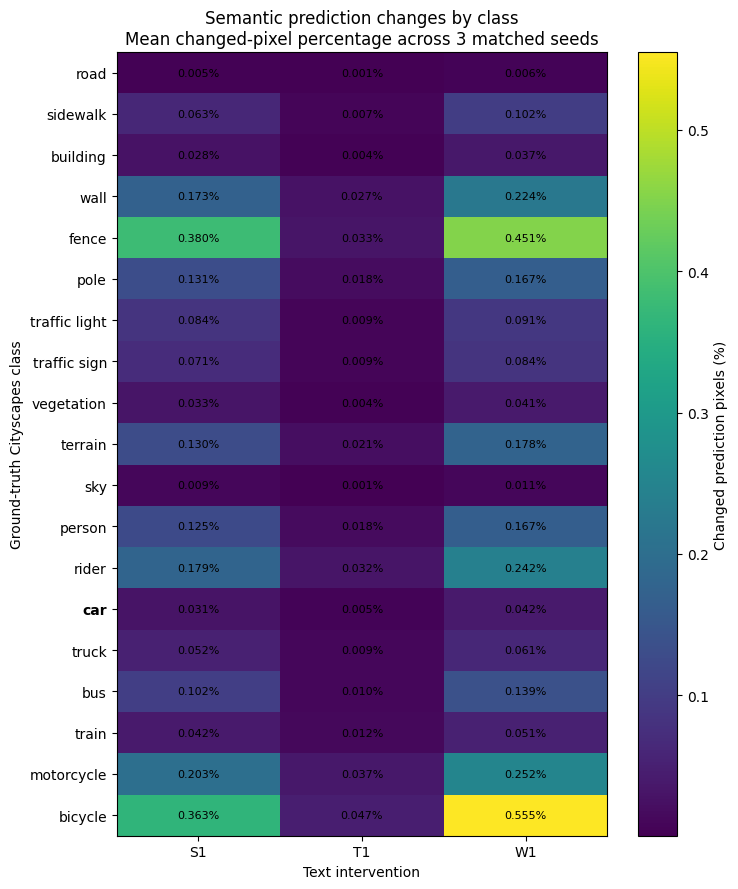


Saved analysis to:
/content/drive/MyDrive/ONEFORMER_DATA/analysis/per_class_semantic_stability_20260928_223324

Figure:
/content/drive/MyDrive/ONEFORMER_DATA/analysis/per_class_semantic_stability_20260928_223324/per_class_changed_pixel_heatmap.png


In [ ]:
import os
import json
import zipfile
from io import BytesIO
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 1. PATHS
# ============================================================

project_root = "/content/drive/MyDrive/ONEFORMER_DATA"

exp_root = os.path.join(
    project_root,
    "pilots",
    "corrected_wording_20260920_102817_389509"
)

val_root = os.path.join(exp_root, "validation_500")
eval_root = os.path.join(val_root, "evaluations")

protocol_path = os.path.join(
    val_root,
    "evaluation_protocol.json"
)

gt_zip_path = os.path.join(
    project_root,
    "gtFine_trainvaltest.zip"
)

# ============================================================
# 2. LOAD EVALUATION PROTOCOL
# ============================================================

with open(protocol_path, "r") as f:
    protocol = json.load(f)

manifest = protocol["manifest"]
class_names = protocol["class_names"]
original_label_ids = protocol["original_label_ids_in_train_id_order"]
IGNORE_ID = protocol["ignore_train_id"]

assert len(manifest) == 500
assert len(class_names) == 19
assert len(original_label_ids) == 19

print("Images:", len(manifest))
print("Classes:", len(class_names))
print("Ignore ID:", IGNORE_ID)

# ============================================================
# 3. CITYSCAPES labelId -> trainId
# ============================================================

labelid_to_trainid = {
    label_id: train_id
    for train_id, label_id in enumerate(original_label_ids)
}

def labelids_to_trainids(label_img):
    out = np.full(
        label_img.shape,
        IGNORE_ID,
        dtype=np.uint8
    )

    for label_id, train_id in labelid_to_trainid.items():
        out[label_img == label_id] = train_id

    return out


def prediction_filename(image_name):
    return image_name.replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png"
    )

# ============================================================
# 4. BASIC FILE SANITY CHECK
# ============================================================

conditions = ["C0", "S1", "T1", "W1"]
seeds = [42, 43, 44]

expected_names = {
    prediction_filename(item["image_name"])
    for item in manifest
}

print("\nPrediction-set verification")
print("=" * 70)

for condition in conditions:
    for seed in seeds:

        pred_dir = os.path.join(
            eval_root,
            f"{condition}_seed{seed}",
            "predictions"
        )

        files = {
            f for f in os.listdir(pred_dir)
            if f.endswith("_prediction_trainIds.png")
        }

        assert len(files) == 500, (
            f"{condition}_seed{seed}: expected 500 predictions, "
            f"found {len(files)}"
        )

        assert files == expected_names, (
            f"{condition}_seed{seed}: prediction filenames "
            f"do not match validation manifest"
        )

        print(
            f"{condition}_seed{seed}: "
            f"500/500 predictions verified"
        )

# ============================================================
# 5. PER-CLASS MATCHED COMPARISON
# ============================================================

def compare_per_class(condition, seed, gt_zip):

    c0_dir = os.path.join(
        eval_root,
        f"C0_seed{seed}",
        "predictions"
    )

    other_dir = os.path.join(
        eval_root,
        f"{condition}_seed{seed}",
        "predictions"
    )

    class_total = np.zeros(19, dtype=np.int64)
    class_same = np.zeros(19, dtype=np.int64)

    for item in manifest:

        image_name = item["image_name"]
        pred_name = prediction_filename(image_name)

        c0 = np.array(
            Image.open(os.path.join(c0_dir, pred_name))
        )

        other = np.array(
            Image.open(os.path.join(other_dir, pred_name))
        )

        gt_bytes = gt_zip.read(item["label_member"])

        gt_labelids = np.array(
            Image.open(BytesIO(gt_bytes))
        )

        gt_trainids = labelids_to_trainids(gt_labelids)

        assert c0.shape == other.shape == gt_trainids.shape

        # Prediction sanity check
        c0_unique = set(np.unique(c0).tolist())
        other_unique = set(np.unique(other).tolist())

        allowed = set(range(19)) | {255}

        assert c0_unique.issubset(allowed)
        assert other_unique.issubset(allowed)

        # --------------------------------------------
        # For each GT class, compare C0 vs intervention
        # --------------------------------------------
        for class_id in range(19):

            class_mask = gt_trainids == class_id

            n_class = int(class_mask.sum())

            if n_class == 0:
                continue

            n_same = int(
                ((c0 == other) & class_mask).sum()
            )

            class_total[class_id] += n_class
            class_same[class_id] += n_same

    rows = []

    for class_id, class_name in enumerate(class_names):

        total = int(class_total[class_id])
        same = int(class_same[class_id])
        changed = total - same

        agreement_pct = 100.0 * same / total
        changed_pct = 100.0 * changed / total

        rows.append({
            "condition": condition,
            "seed": seed,
            "class_id": class_id,
            "class_name": class_name,
            "gt_pixels": total,
            "same_prediction_pixels": same,
            "changed_prediction_pixels": changed,
            "agreement_percent": agreement_pct,
            "changed_percent": changed_pct
        })

    return rows

# ============================================================
# 6. RUN ALL 9 MATCHED COMPARISONS
# ============================================================

all_rows = []

with zipfile.ZipFile(gt_zip_path, "r") as gt_zip:

    for condition in ["S1", "T1", "W1"]:

        for seed in seeds:

            print(
                f"\nProcessing {condition} vs C0, "
                f"seed {seed}..."
            )

            rows = compare_per_class(
                condition,
                seed,
                gt_zip
            )

            all_rows.extend(rows)

per_seed_df = pd.DataFrame(all_rows)

# ============================================================
# 7. THREE-SEED SUMMARY
# ============================================================

summary_df = (
    per_seed_df
    .groupby(
        ["condition", "class_id", "class_name"],
        as_index=False
    )
    .agg(
        mean_agreement_percent=(
            "agreement_percent",
            "mean"
        ),
        sd_agreement_percent=(
            "agreement_percent",
            "std"
        ),
        mean_changed_percent=(
            "changed_percent",
            "mean"
        ),
        sd_changed_percent=(
            "changed_percent",
            "std"
        ),
        gt_pixels=(
            "gt_pixels",
            "first"
        )
    )
)

# ============================================================
# 8. HEATMAP TABLE
#    Changed % is easier to see than 99.99% agreement.
# ============================================================

heatmap_df = (
    summary_df
    .pivot(
        index="class_name",
        columns="condition",
        values="mean_changed_percent"
    )
    .reindex(class_names)
    [["S1", "T1", "W1"]]
)

print("\nTHREE-SEED PER-CLASS SUMMARY")
display(summary_df)

print("\nMEAN CHANGED-PIXEL PERCENTAGE")
display(heatmap_df)

# ============================================================
# 9. SHOW MOST AFFECTED CLASSES
# ============================================================

top_changed = (
    summary_df
    .sort_values(
        "mean_changed_percent",
        ascending=False
    )
    [[
        "condition",
        "class_name",
        "mean_changed_percent",
        "sd_changed_percent"
    ]]
)

print("\nMOST CHANGED CLASS-CONDITION PAIRS")
display(top_changed.head(20))

# ============================================================
# 10. SAVE RESULTS
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(
    project_root,
    "analysis",
    f"per_class_semantic_stability_{timestamp}"
)

os.makedirs(out_dir, exist_ok=True)

per_seed_df.to_csv(
    os.path.join(
        out_dir,
        "per_seed_per_class_stability.csv"
    ),
    index=False
)

summary_df.to_csv(
    os.path.join(
        out_dir,
        "three_seed_per_class_stability.csv"
    ),
    index=False
)

heatmap_df.to_csv(
    os.path.join(
        out_dir,
        "changed_pixel_heatmap_values.csv"
    )
)

# ============================================================
# 11. CREATE REPORT-QUALITY HEATMAP
# ============================================================

data = heatmap_df.values

fig, ax = plt.subplots(figsize=(7.5, 9))

im = ax.imshow(data, aspect="auto")

ax.set_xticks(np.arange(3))
ax.set_xticklabels(["S1", "T1", "W1"])

ax.set_yticks(np.arange(len(class_names)))
ax.set_yticklabels(class_names)

ax.set_xlabel("Text intervention")
ax.set_ylabel("Ground-truth Cityscapes class")

ax.set_title(
    "Semantic prediction changes by class\n"
    "Mean changed-pixel percentage across 3 matched seeds"
)

# Annotate every cell
for i in range(data.shape[0]):
    for j in range(data.shape[1]):

        value = data[i, j]

        ax.text(
            j,
            i,
            f"{value:.3f}%",
            ha="center",
            va="center",
            fontsize=8
        )

# Bold the car row
for tick in ax.get_yticklabels():
    if tick.get_text() == "car":
        tick.set_fontweight("bold")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Changed prediction pixels (%)")

plt.tight_layout()

png_path = os.path.join(
    out_dir,
    "per_class_changed_pixel_heatmap.png"
)

pdf_path = os.path.join(
    out_dir,
    "per_class_changed_pixel_heatmap.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 12. METHOD RECORD
# ============================================================

method = {
    "analysis":
        "Per-class semantic output stability",
    "dataset":
        "Cityscapes validation",
    "images":
        500,
    "classes":
        class_names,
    "comparisons": [
        "S1 vs matched C0",
        "T1 vs matched C0",
        "W1 vs matched C0"
    ],
    "matched_seeds": [
        42,
        43,
        44
    ],
    "class_definition":
        "Pixels are grouped according to ground-truth Cityscapes train ID.",
    "stability_definition":
        "Within each ground-truth class, C0 and intervention predictions are compared pixel by pixel.",
    "agreement_metric":
        "same predicted train ID / total ground-truth pixels of that class * 100",
    "changed_metric":
        "different predicted train ID / total ground-truth pixels of that class * 100",
    "aggregation":
        "Pixel counts are pooled across all 500 images for each class and seed. Three matched seed percentages are then summarized by mean and sample SD.",
    "ignore_rule":
        "Ground-truth pixels mapped to train ID 255 are excluded.",
    "visualization":
        "Heatmap shows mean changed-pixel percentage across seeds."
}

with open(
    os.path.join(out_dir, "method.json"),
    "w"
) as f:
    json.dump(method, f, indent=2)

print("\nSaved analysis to:")
print(out_dir)

print("\nFigure:")
print(png_path)

Loaded G5 rows: 4500

SELECTED IMAGES

Representative:
  munster_000046_000019_leftImg8bit.png
  W1 changed pixels: 0.027566%

Stress case:
  frankfurt_000000_009291_leftImg8bit.png
  W1 changed pixels: 1.400241%


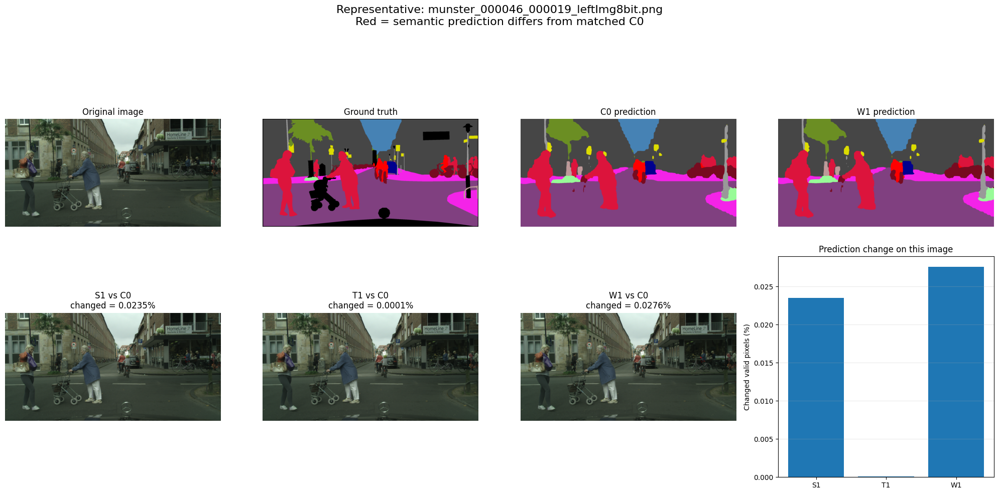

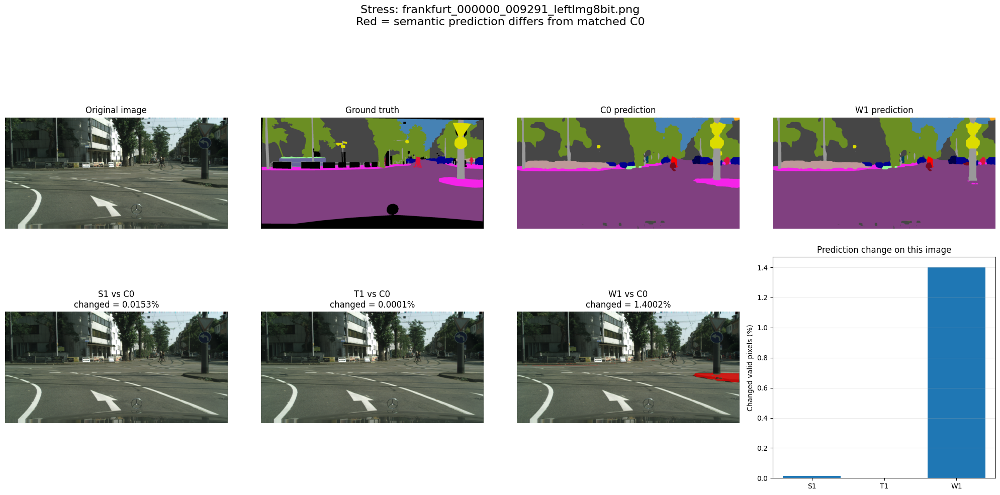


RESULTS


,selection,image_name,S1_changed_percent,T1_changed_percent,W1_changed_percent,png_path,pdf_path
0,Representative,munster_000046_000019_leftImg8bit.png,0.023477,0.000053,0.027566,/content/drive/MyDrive/ONEFORMER_DATA/analysis...,/content/drive/MyDrive/ONEFORMER_DATA/analysis...
1,Stress,frankfurt_000000_009291_leftImg8bit.png,0.015348,0.000055,1.400241,/content/drive/MyDrive/ONEFORMER_DATA/analysis...,/content/drive/MyDrive/ONEFORMER_DATA/analysis...



Saved to:
/content/drive/MyDrive/ONEFORMER_DATA/analysis/changed_pixel_visualizations_20260928_223911


In [ ]:
import os
import json
import zipfile
from io import BytesIO
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 1. PATHS
# ============================================================

project_root = "/content/drive/MyDrive/ONEFORMER_DATA"

exp_root = os.path.join(
    project_root,
    "pilots",
    "corrected_wording_20260920_102817_389509"
)

val_root = os.path.join(exp_root, "validation_500")
eval_root = os.path.join(val_root, "evaluations")

protocol_path = os.path.join(
    val_root,
    "evaluation_protocol.json"
)

# Completed G5 analysis
g5_dir = os.path.join(
    project_root,
    "analysis",
    "semantic_output_stability_20260928_215122"
)

per_image_path = os.path.join(
    g5_dir,
    "per_image_semantic_agreement.csv"
)

# ============================================================
# 2. LOAD PROTOCOL + G5 RESULTS
# ============================================================

with open(protocol_path, "r") as f:
    protocol = json.load(f)

manifest = protocol["manifest"]
manifest_by_name = {
    x["image_name"]: x
    for x in manifest
}

image_zip_path = protocol["image_archive"]
gt_zip_path = protocol["label_archive"]

original_label_ids = protocol[
    "original_label_ids_in_train_id_order"
]

IGNORE_ID = protocol["ignore_train_id"]

labelid_to_trainid = {
    label_id: train_id
    for train_id, label_id
    in enumerate(original_label_ids)
}

g5 = pd.read_csv(per_image_path)

g5["changed_percent"] = (
    100.0 - g5["agreement_percent"]
)

print("Loaded G5 rows:", len(g5))

# ============================================================
# 3. OBJECTIVE IMAGE SELECTION
# ============================================================

# Use seed 42 for qualitative consistency.
# Restrict to images containing ground-truth car pixels.
w1 = g5[
    (g5["condition"] == "W1") &
    (g5["seed"] == 42) &
    (g5["car_gt_pixels"] > 0)
].copy()

assert len(w1) > 0

median_change = w1["changed_percent"].median()

rep_idx = (
    w1["changed_percent"] - median_change
).abs().idxmin()

representative = w1.loc[rep_idx]

stress_idx = w1["changed_percent"].idxmax()
stress = w1.loc[stress_idx]

print("\nSELECTED IMAGES")
print("=" * 75)

print("\nRepresentative:")
print(" ", representative["image_name"])
print(
    "  W1 changed pixels:",
    f'{representative["changed_percent"]:.6f}%'
)

print("\nStress case:")
print(" ", stress["image_name"])
print(
    "  W1 changed pixels:",
    f'{stress["changed_percent"]:.6f}%'
)

# ============================================================
# 4. HELPERS
# ============================================================

def labelids_to_trainids(label_img):

    result = np.full(
        label_img.shape,
        IGNORE_ID,
        dtype=np.uint8
    )

    for label_id, train_id in labelid_to_trainid.items():
        result[label_img == label_id] = train_id

    return result


def prediction_filename(image_name):

    return image_name.replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png"
    )


# Standard Cityscapes train-ID palette
palette = np.array([
    [128,  64, 128],  # road
    [244,  35, 232],  # sidewalk
    [ 70,  70,  70],  # building
    [102, 102, 156],  # wall
    [190, 153, 153],  # fence
    [153, 153, 153],  # pole
    [250, 170,  30],  # traffic light
    [220, 220,   0],  # traffic sign
    [107, 142,  35],  # vegetation
    [152, 251, 152],  # terrain
    [ 70, 130, 180],  # sky
    [220,  20,  60],  # person
    [255,   0,   0],  # rider
    [  0,   0, 142],  # car
    [  0,   0,  70],  # truck
    [  0,  60, 100],  # bus
    [  0,  80, 100],  # train
    [  0,   0, 230],  # motorcycle
    [119,  11,  32],  # bicycle
], dtype=np.uint8)


def colorize_trainids(trainids):

    h, w = trainids.shape

    rgb = np.zeros(
        (h, w, 3),
        dtype=np.uint8
    )

    for class_id in range(19):
        rgb[trainids == class_id] = palette[class_id]

    return rgb


def difference_overlay(rgb, changed_mask):

    result = rgb.astype(np.float32).copy()

    highlight = np.array(
        [255, 0, 0],
        dtype=np.float32
    )

    result[changed_mask] = (
        0.30 * result[changed_mask] +
        0.70 * highlight
    )

    return result.astype(np.uint8)


# ============================================================
# 5. OUTPUT FOLDER
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(
    project_root,
    "analysis",
    f"changed_pixel_visualizations_{timestamp}"
)

os.makedirs(out_dir, exist_ok=True)

# ============================================================
# 6. CREATE ONE FIGURE
# ============================================================

def make_figure(image_name, selection_label,
                image_zip, gt_zip):

    item = manifest_by_name[image_name]

    # --------------------------------------------------------
    # Original RGB
    # --------------------------------------------------------

    rgb_bytes = image_zip.read(
        item["image_member"]
    )

    rgb = np.array(
        Image.open(BytesIO(rgb_bytes)).convert("RGB")
    )

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    gt_bytes = gt_zip.read(
        item["label_member"]
    )

    gt_labelids = np.array(
        Image.open(BytesIO(gt_bytes))
    )

    gt = labelids_to_trainids(gt_labelids)

    valid = gt != IGNORE_ID

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    pred_name = prediction_filename(image_name)

    preds = {}

    for condition in ["C0", "S1", "T1", "W1"]:

        path = os.path.join(
            eval_root,
            f"{condition}_seed42",
            "predictions",
            pred_name
        )

        preds[condition] = np.array(
            Image.open(path)
        )

        assert preds[condition].shape == gt.shape

    # --------------------------------------------------------
    # Difference masks
    # --------------------------------------------------------

    diff_masks = {}

    stats = {}

    for condition in ["S1", "T1", "W1"]:

        changed = (
            (preds["C0"] != preds[condition]) &
            valid
        )

        diff_masks[condition] = changed

        n_valid = int(valid.sum())
        n_changed = int(changed.sum())

        stats[condition] = {
            "changed_pixels": n_changed,
            "changed_percent":
                100.0 * n_changed / n_valid
        }

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(20, 10)
    )

    # Original
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title("Original image")

    # GT
    axes[0, 1].imshow(
        colorize_trainids(gt)
    )
    axes[0, 1].set_title("Ground truth")

    # C0
    axes[0, 2].imshow(
        colorize_trainids(preds["C0"])
    )
    axes[0, 2].set_title("C0 prediction")

    # W1
    axes[0, 3].imshow(
        colorize_trainids(preds["W1"])
    )
    axes[0, 3].set_title("W1 prediction")

    # Difference overlays
    for ax, condition in zip(
        axes[1, :3],
        ["S1", "T1", "W1"]
    ):

        ax.imshow(
            difference_overlay(
                rgb,
                diff_masks[condition]
            )
        )

        pct = stats[condition]["changed_percent"]

        ax.set_title(
            f"{condition} vs C0\n"
            f"changed = {pct:.4f}%"
        )

    # --------------------------------------------------------
    # Per-image comparison bar chart
    # --------------------------------------------------------

    conditions = ["S1", "T1", "W1"]

    values = [
        stats[c]["changed_percent"]
        for c in conditions
    ]

    axes[1, 3].bar(
        conditions,
        values
    )

    axes[1, 3].set_ylabel(
        "Changed valid pixels (%)"
    )

    axes[1, 3].set_title(
        "Prediction change on this image"
    )

    axes[1, 3].grid(
        axis="y",
        alpha=0.25
    )

    # Remove axes from image panels
    for ax in axes.flat[:7]:
        ax.axis("off")

    fig.suptitle(
        f"{selection_label}: {image_name}\n"
        "Red = semantic prediction differs from matched C0",
        fontsize=16
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.94]
    )

    stem = image_name.replace(
        "_leftImg8bit.png",
        ""
    )

    png_path = os.path.join(
        out_dir,
        f"{selection_label.lower()}_{stem}.png"
    )

    pdf_path = os.path.join(
        out_dir,
        f"{selection_label.lower()}_{stem}.pdf"
    )

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.show()

    return {
        "selection": selection_label,
        "image_name": image_name,
        "S1_changed_percent":
            stats["S1"]["changed_percent"],
        "T1_changed_percent":
            stats["T1"]["changed_percent"],
        "W1_changed_percent":
            stats["W1"]["changed_percent"],
        "png_path": png_path,
        "pdf_path": pdf_path
    }


# ============================================================
# 7. GENERATE REPRESENTATIVE + STRESS FIGURES
# ============================================================

records = []

with zipfile.ZipFile(
    image_zip_path,
    "r"
) as image_zip, zipfile.ZipFile(
    gt_zip_path,
    "r"
) as gt_zip:

    records.append(
        make_figure(
            representative["image_name"],
            "Representative",
            image_zip,
            gt_zip
        )
    )

    records.append(
        make_figure(
            stress["image_name"],
            "Stress",
            image_zip,
            gt_zip
        )
    )

selection_df = pd.DataFrame(records)

selection_df.to_csv(
    os.path.join(
        out_dir,
        "selected_visualization_cases.csv"
    ),
    index=False
)

# ============================================================
# 8. SAVE SELECTION METHOD
# ============================================================

method = {
    "analysis":
        "Qualitative changed-pixel visualization",
    "seed":
        42,
    "comparison_reference":
        "Matched C0 seed 42",
    "representative_selection":
        "Among W1 seed42 validation images containing ground-truth car pixels, select the image whose changed-pixel percentage is closest to the median.",
    "stress_selection":
        "Among W1 seed42 validation images containing ground-truth car pixels, select the image with the largest changed-pixel percentage.",
    "difference_definition":
        "A highlighted pixel is a valid ground-truth pixel where C0 and the intervention predict different semantic train IDs.",
    "interpretation":
        "Representative case describes typical local stability. Stress case is intentionally extreme and must not be presented as typical."
}

with open(
    os.path.join(
        out_dir,
        "method.json"
    ),
    "w"
) as f:
    json.dump(method, f, indent=2)

print("\nRESULTS")
display(selection_df)

print("\nSaved to:")
print(out_dir)

Rows: 4500
condition  seed
S1         42      500
           43      500
           44      500
T1         42      500
           43      500
           44      500
W1         42      500
           43      500
           44      500
Name: count, dtype: int64

DISTRIBUTION SUMMARY


,condition,median_%,p90_%,p95_%,p99_%,max_%
0,S1,0.021584,0.062460,0.087456,0.203036,1.408909
1,T1,0.000777,0.010991,0.020482,0.064809,0.175188
2,W1,0.027416,0.083962,0.109566,0.282622,1.400241


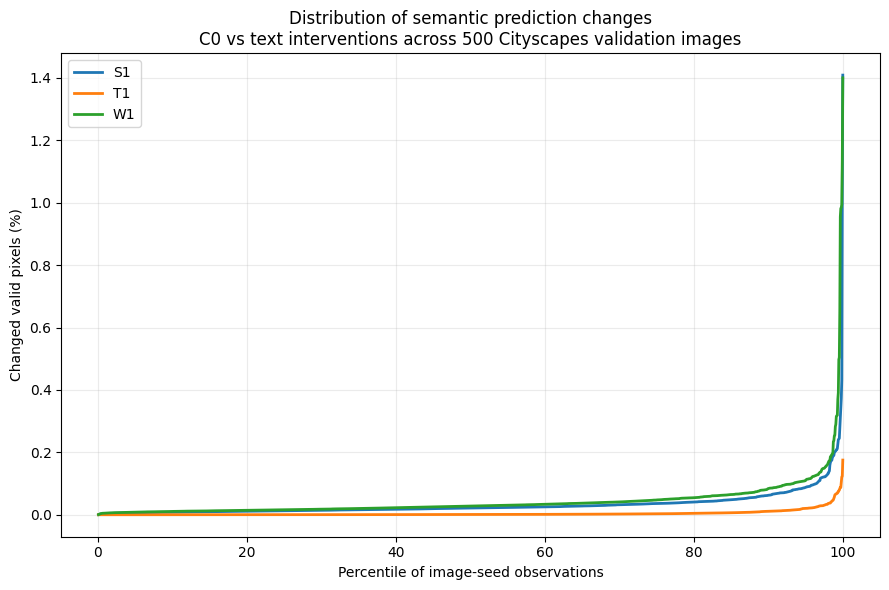


Saved to:
/content/drive/MyDrive/ONEFORMER_DATA/analysis/per_image_change_distribution_20260928_224430


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ---------------------------------------------------------
# 1. Load G5 per-image results
# ---------------------------------------------------------

project_root = "/content/drive/MyDrive/ONEFORMER_DATA"

g5_dir = os.path.join(
    project_root,
    "analysis",
    "semantic_output_stability_20260928_215122"
)

csv_path = os.path.join(
    g5_dir,
    "per_image_semantic_agreement.csv"
)

df = pd.read_csv(csv_path)

df["changed_percent"] = 100.0 - df["agreement_percent"]

print("Rows:", len(df))
print(df[["condition", "seed"]].value_counts().sort_index())

# Expected:
# 500 images × 3 seeds × 3 conditions = 4500 rows
assert len(df) == 4500

# ---------------------------------------------------------
# 2. Percentile summary
# ---------------------------------------------------------

summary_rows = []

for condition in ["S1", "T1", "W1"]:

    x = df.loc[
        df["condition"] == condition,
        "changed_percent"
    ].values

    summary_rows.append({
        "condition": condition,
        "median_%": np.median(x),
        "p90_%": np.percentile(x, 90),
        "p95_%": np.percentile(x, 95),
        "p99_%": np.percentile(x, 99),
        "max_%": np.max(x)
    })

summary_df = pd.DataFrame(summary_rows)

print("\nDISTRIBUTION SUMMARY")
display(summary_df)

# ---------------------------------------------------------
# 3. Ranked distribution curve
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

for condition in ["S1", "T1", "W1"]:

    values = np.sort(
        df.loc[
            df["condition"] == condition,
            "changed_percent"
        ].values
    )

    percentiles = (
        np.arange(1, len(values) + 1)
        / len(values)
        * 100
    )

    ax.plot(
        percentiles,
        values,
        label=condition,
        linewidth=2
    )

ax.set_xlabel("Percentile of image-seed observations")
ax.set_ylabel("Changed valid pixels (%)")

ax.set_title(
    "Distribution of semantic prediction changes\n"
    "C0 vs text interventions across 500 Cityscapes validation images"
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

# ---------------------------------------------------------
# 4. Save
# ---------------------------------------------------------

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(
    project_root,
    "analysis",
    f"per_image_change_distribution_{timestamp}"
)

os.makedirs(out_dir, exist_ok=True)

png_path = os.path.join(
    out_dir,
    "ranked_prediction_change_distribution.png"
)

pdf_path = os.path.join(
    out_dir,
    "ranked_prediction_change_distribution.pdf"
)

summary_path = os.path.join(
    out_dir,
    "prediction_change_percentiles.csv"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

summary_df.to_csv(
    summary_path,
    index=False
)

plt.show()

print("\nSaved to:")
print(out_dir)


Processing: S1
 seed 42
 seed 43
 seed 44

Processing: T1
 seed 42
 seed 43
 seed 44

Processing: W1
 seed 42
 seed 43
 seed 44

TOP PREDICTION TRANSITIONS


,condition,from_class,to_class,pixels,percent_of_changed_pixels
0,S1,wall,fence,62746,7.013736
1,S1,sidewalk,road,41201,4.605440
2,S1,building,vegetation,41158,4.600633
3,S1,fence,wall,31700,3.543420
4,S1,terrain,vegetation,26159,2.924048
5,S1,motorcycle,bicycle,24519,2.740729
6,S1,building,fence,18628,2.082234
7,S1,fence,building,17855,1.995828
8,S1,sidewalk,terrain,16004,1.788924
9,S1,building,wall,15951,1.783000



CAR <-> BICYCLE TRANSITIONS


,condition,from_class,to_class,pixels,percent_of_changed_pixels
239,S1,car,bicycle,1887,0.210928
321,S1,bicycle,car,1430,0.159845
556,T1,car,bicycle,371,0.322421
632,T1,bicycle,car,209,0.181633
873,W1,car,bicycle,3219,0.269186
956,W1,bicycle,car,2258,0.188823


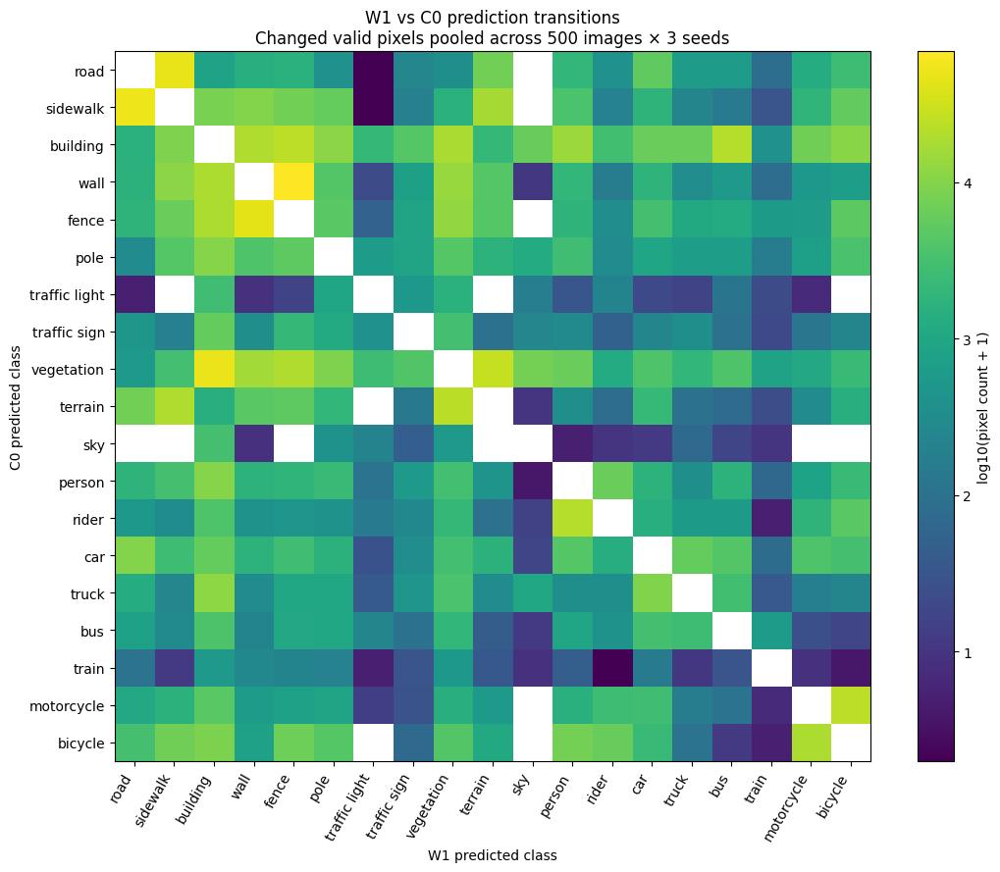


Saved to:
/content/drive/MyDrive/ONEFORMER_DATA/analysis/prediction_transition_analysis_20260928_225234


In [ ]:
import os
import json
import zipfile
from io import BytesIO
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 1. PATHS
# ============================================================

project_root = "/content/drive/MyDrive/ONEFORMER_DATA"

exp_root = os.path.join(
    project_root,
    "pilots",
    "corrected_wording_20260920_102817_389509"
)

val_root = os.path.join(exp_root, "validation_500")
eval_root = os.path.join(val_root, "evaluations")

protocol_path = os.path.join(
    val_root,
    "evaluation_protocol.json"
)

with open(protocol_path, "r") as f:
    protocol = json.load(f)

manifest = protocol["manifest"]
class_names = protocol["class_names"]
original_label_ids = protocol["original_label_ids_in_train_id_order"]
IGNORE_ID = protocol["ignore_train_id"]

gt_zip_path = protocol["label_archive"]

labelid_to_trainid = {
    label_id: train_id
    for train_id, label_id
    in enumerate(original_label_ids)
}

# ============================================================
# 2. HELPERS
# ============================================================

def labelids_to_trainids(label_img):

    out = np.full(
        label_img.shape,
        IGNORE_ID,
        dtype=np.uint8
    )

    for label_id, train_id in labelid_to_trainid.items():
        out[label_img == label_id] = train_id

    return out


def prediction_filename(image_name):

    return image_name.replace(
        "_leftImg8bit.png",
        "_prediction_trainIds.png"
    )

# ============================================================
# 3. TRANSITION COUNTS
# ============================================================

conditions = ["S1", "T1", "W1"]
seeds = [42, 43, 44]

# one 19x19 matrix per condition
matrices = {
    condition: np.zeros((19, 19), dtype=np.int64)
    for condition in conditions
}

with zipfile.ZipFile(gt_zip_path, "r") as gt_zip:

    for condition in conditions:

        print("\nProcessing:", condition)

        for seed in seeds:

            print(" seed", seed)

            c0_dir = os.path.join(
                eval_root,
                f"C0_seed{seed}",
                "predictions"
            )

            other_dir = os.path.join(
                eval_root,
                f"{condition}_seed{seed}",
                "predictions"
            )

            for item in manifest:

                pred_name = prediction_filename(
                    item["image_name"]
                )

                c0 = np.array(
                    Image.open(
                        os.path.join(
                            c0_dir,
                            pred_name
                        )
                    )
                )

                other = np.array(
                    Image.open(
                        os.path.join(
                            other_dir,
                            pred_name
                        )
                    )
                )

                gt_bytes = gt_zip.read(
                    item["label_member"]
                )

                gt = labelids_to_trainids(
                    np.array(
                        Image.open(
                            BytesIO(gt_bytes)
                        )
                    )
                )

                valid = gt != IGNORE_ID

                # Only pixels where predictions differ
                changed = (
                    valid &
                    (c0 != other) &
                    (c0 < 19) &
                    (other < 19)
                )

                source = c0[changed]
                target = other[changed]

                np.add.at(
                    matrices[condition],
                    (source, target),
                    1
                )

# ============================================================
# 4. CREATE LONG TABLE
# ============================================================

rows = []

for condition in conditions:

    matrix = matrices[condition]

    total_changed = matrix.sum()

    for src in range(19):
        for dst in range(19):

            if src == dst:
                continue

            count = int(matrix[src, dst])

            if count == 0:
                continue

            rows.append({
                "condition": condition,
                "from_class": class_names[src],
                "to_class": class_names[dst],
                "pixels": count,
                "percent_of_changed_pixels":
                    100.0 * count / total_changed
            })

transitions_df = pd.DataFrame(rows)

# ============================================================
# 5. TOP TRANSITIONS
# ============================================================

top_df = (
    transitions_df
    .sort_values(
        ["condition", "pixels"],
        ascending=[True, False]
    )
    .groupby("condition")
    .head(15)
    .reset_index(drop=True)
)

print("\nTOP PREDICTION TRANSITIONS")
display(top_df)

# ============================================================
# 6. SPECIFIC CAR/BICYCLE CHECK
# ============================================================

specific = transitions_df[
    (
        (
            (transitions_df["from_class"] == "car") &
            (transitions_df["to_class"] == "bicycle")
        )
        |
        (
            (transitions_df["from_class"] == "bicycle") &
            (transitions_df["to_class"] == "car")
        )
    )
]

print("\nCAR <-> BICYCLE TRANSITIONS")
display(specific)

# ============================================================
# 7. W1 HEATMAP
# ============================================================

w1 = matrices["W1"].astype(float)

# Turn zero values into NaN so empty cells remain visually quiet
plot_matrix = w1.copy()
plot_matrix[plot_matrix == 0] = np.nan

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(
    np.log10(plot_matrix + 1),
    aspect="auto"
)

ax.set_xticks(np.arange(19))
ax.set_xticklabels(
    class_names,
    rotation=60,
    ha="right"
)

ax.set_yticks(np.arange(19))
ax.set_yticklabels(class_names)

ax.set_xlabel("W1 predicted class")
ax.set_ylabel("C0 predicted class")

ax.set_title(
    "W1 vs C0 prediction transitions\n"
    "Changed valid pixels pooled across 500 images × 3 seeds"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("log10(pixel count + 1)")

plt.tight_layout()

# ============================================================
# 8. SAVE
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

out_dir = os.path.join(
    project_root,
    "analysis",
    f"prediction_transition_analysis_{timestamp}"
)

os.makedirs(out_dir, exist_ok=True)

transitions_df.to_csv(
    os.path.join(
        out_dir,
        "all_prediction_transitions.csv"
    ),
    index=False
)

top_df.to_csv(
    os.path.join(
        out_dir,
        "top_prediction_transitions.csv"
    ),
    index=False
)

plt.savefig(
    os.path.join(
        out_dir,
        "W1_prediction_transition_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        out_dir,
        "W1_prediction_transition_heatmap.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

print("\nSaved to:")
print(out_dir)

TARGETED CAR ↔ BICYCLE TRANSITIONS


transition,bicycle → car,car → bicycle
condition,,
S1,1430,1887
T1,209,371
W1,2258,3219


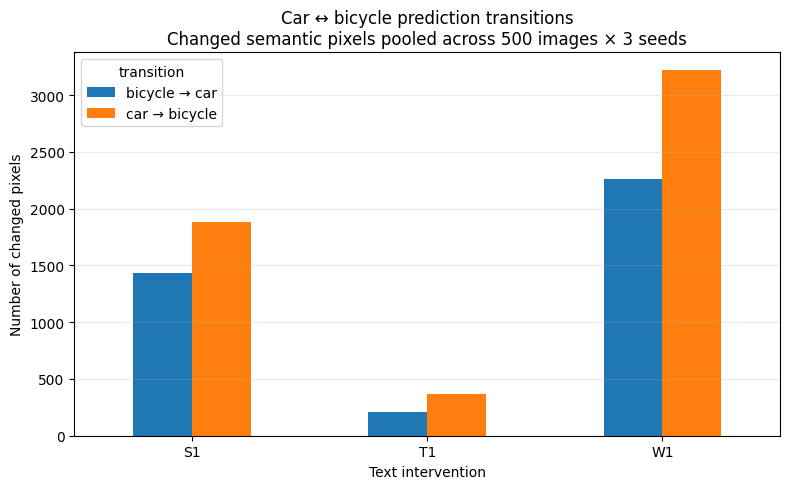


Saved:
/content/drive/MyDrive/ONEFORMER_DATA/analysis/prediction_transition_analysis_20260928_225234/car_bicycle_targeted_transitions.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

project_root = "/content/drive/MyDrive/ONEFORMER_DATA"

analysis_dir = os.path.join(
    project_root,
    "analysis",
    "prediction_transition_analysis_20260928_225234"
)

csv_path = os.path.join(
    analysis_dir,
    "all_prediction_transitions.csv"
)

df = pd.read_csv(csv_path)

# Keep only car <-> bicycle
target = df[
    (
        (df["from_class"] == "car") &
        (df["to_class"] == "bicycle")
    )
    |
    (
        (df["from_class"] == "bicycle") &
        (df["to_class"] == "car")
    )
].copy()

target["transition"] = (
    target["from_class"] +
    " → " +
    target["to_class"]
)

plot_df = (
    target
    .pivot(
        index="condition",
        columns="transition",
        values="pixels"
    )
    .reindex(["S1", "T1", "W1"])
)

print("TARGETED CAR ↔ BICYCLE TRANSITIONS")
display(plot_df)

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title(
    "Car ↔ bicycle prediction transitions\n"
    "Changed semantic pixels pooled across 500 images × 3 seeds"
)

ax.set_xlabel("Text intervention")
ax.set_ylabel("Number of changed pixels")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

png_path = os.path.join(
    analysis_dir,
    "car_bicycle_targeted_transitions.png"
)

pdf_path = os.path.join(
    analysis_dir,
    "car_bicycle_targeted_transitions.pdf"
)

plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(png_path)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls -lah "/content/drive/MyDrive"

total 16K
drwx------ 4 root root 4.0K Oct  6 18:05  .
drwx------ 5 root root 4.0K Oct  6 18:05  ..
drwx------ 2 root root 4.0K Sep 13 18:42 'Colab Notebooks'
drwx------ 2 root root 4.0K Sep 13 18:04  ONEFORMER_DATA


In [3]:
!ls -lah "/content/drive/MyDrive/ONEFORMER_DATA"

total 12G
drwx------ 9 root root 4.0K Sep 13 18:04 .
drwx------ 4 root root 4.0K Oct  6 18:05 ..
drwx------ 2 root root 4.0K Sep 23 20:53 analysis
drwx------ 2 root root 4.0K Sep 17 20:08 checkpoint_audit
-rw------- 1 root root 241M Sep 13 11:22 gtFine_trainvaltest.zip
-rw------- 1 root root  11G Sep 13 12:26 leftImg8bit_trainvaltest.zip
drwx------ 2 root root 4.0K Sep 18 21:31 pilot_data
drwx------ 2 root root 4.0K Sep 17 21:18 pilots
drwx------ 2 root root 4.0K Sep 21 22:00 recovery_archives
drwx------ 2 root root 4.0K Sep 14 17:51 results
-rw------- 1 root root 6.5K Sep 17 09:50 results_backup_20260917_095020.zip
-rw------- 1 root root 6.5K Sep 17 10:46 results_backup_20260917_104614.zip
drwx------ 2 root root 4.0K Sep 17 20:54 training_checks


In [4]:
!du -h --max-depth=1 "/content/drive/MyDrive/ONEFORMER_DATA"

20K	/content/drive/MyDrive/ONEFORMER_DATA/results
973M	/content/drive/MyDrive/ONEFORMER_DATA/checkpoint_audit
29M	/content/drive/MyDrive/ONEFORMER_DATA/training_checks
du: cannot read directory '/content/drive/MyDrive/ONEFORMER_DATA/pilots/corrected_wording_20260920_102817_389509/validation_500/ap_pq/evaluations/B0/instance': Input/output error
70G	/content/drive/MyDrive/ONEFORMER_DATA/pilots
1.5G	/content/drive/MyDrive/ONEFORMER_DATA/pilot_data
198M	/content/drive/MyDrive/ONEFORMER_DATA/recovery_archives
11M	/content/drive/MyDrive/ONEFORMER_DATA/analysis
84G	/content/drive/MyDrive/ONEFORMER_DATA


In [5]:
!find "/content/drive/MyDrive/ONEFORMER_DATA/analysis" -maxdepth 2 -type f | head -100

/content/drive/MyDrive/ONEFORMER_DATA/analysis/fixed_text_embedding_similarity_20260923_205351_635492/pairwise_condition_cosine_similarity.csv
/content/drive/MyDrive/ONEFORMER_DATA/analysis/fixed_text_embedding_similarity_20260923_205351_635492/C0_relative_embedding_similarity.csv
/content/drive/MyDrive/ONEFORMER_DATA/analysis/fixed_text_embedding_similarity_20260923_205351_635492/condition_to_19_class_similarity.csv
/content/drive/MyDrive/ONEFORMER_DATA/analysis/fixed_text_embedding_similarity_20260923_205351_635492/nearest_cityscapes_class_templates.csv
/content/drive/MyDrive/ONEFORMER_DATA/analysis/fixed_text_embedding_similarity_20260923_205351_635492/presentation_embedding_similarity_table.csv
/content/drive/MyDrive/ONEFORMER_DATA/analysis/fixed_text_embedding_similarity_20260923_205351_635492/token_differences.csv
/content/drive/MyDrive/ONEFORMER_DATA/analysis/fixed_text_embedding_similarity_20260923_205351_635492/fixed_reference_embeddings.pt
/content/drive/MyDrive/ONEFORMER_DAT

In [6]:
!find "/content/drive/MyDrive/ONEFORMER_DATA/results" -maxdepth 2 -type f | head -100

/content/drive/MyDrive/ONEFORMER_DATA/results/semantic_confusion.npy
/content/drive/MyDrive/ONEFORMER_DATA/results/semantic_class_iou.npy
/content/drive/MyDrive/ONEFORMER_DATA/results/semantic_run_details.json
/content/drive/MyDrive/ONEFORMER_DATA/results/instance_validation_results.json
/content/drive/MyDrive/ONEFORMER_DATA/results/panoptic_validation_results.json
/content/drive/MyDrive/ONEFORMER_DATA/results/panoptic_run_details.json


In [7]:
!find "/content/drive/MyDrive/ONEFORMER_DATA/training_checks" -maxdepth 2 -type f | head -100

/content/drive/MyDrive/ONEFORMER_DATA/training_checks/two_image_training_manifest.json
/content/drive/MyDrive/ONEFORMER_DATA/training_checks/two_image_training_batch.pt
/content/drive/MyDrive/ONEFORMER_DATA/training_checks/two_image_target_details.json
/content/drive/MyDrive/ONEFORMER_DATA/training_checks/two_image_loss_and_gradient_test.json
/content/drive/MyDrive/ONEFORMER_DATA/training_checks/car_automobile_intervention_test.json
/content/drive/MyDrive/ONEFORMER_DATA/training_checks/contrastive_sensitivity_20260919_232145_679994/results.json
/content/drive/MyDrive/ONEFORMER_DATA/training_checks/contrastive_sensitivity_20260919_232145_679994/method.json


In [8]:
!ls -lh "/content/drive/MyDrive/Colab Notebooks"

total 12M
-rw------- 1 root root 9.9M Oct  6 18:16 OneFormer_Cityscapes_Project.ipynb
-rw------- 1 root root 1.3M Sep 19 23:22 OneFormer_Text_Experiments.ipynb


In [9]:
!rm -rf "/content/oneformer-text-intervention"

!mkdir -p "/content/oneformer-text-intervention/notebooks"
!mkdir -p "/content/oneformer-text-intervention/analysis"
!mkdir -p "/content/oneformer-text-intervention/results"
!mkdir -p "/content/oneformer-text-intervention/checks"

In [10]:
!cp "/content/drive/MyDrive/Colab Notebooks/OneFormer_Cityscapes_Project.ipynb" \
    "/content/oneformer-text-intervention/notebooks/"

!cp "/content/drive/MyDrive/Colab Notebooks/OneFormer_Text_Experiments.ipynb" \
    "/content/oneformer-text-intervention/notebooks/"

In [11]:
!rsync -av \
    --exclude='*.pt' \
    "/content/drive/MyDrive/ONEFORMER_DATA/analysis/" \
    "/content/oneformer-text-intervention/analysis/"

sending incremental file list
./
changed_pixel_visualizations_20260928_223911/
changed_pixel_visualizations_20260928_223911/method.json
changed_pixel_visualizations_20260928_223911/representative_munster_000046_000019.pdf
changed_pixel_visualizations_20260928_223911/representative_munster_000046_000019.png
changed_pixel_visualizations_20260928_223911/selected_visualization_cases.csv
changed_pixel_visualizations_20260928_223911/stress_frankfurt_000000_009291.pdf
changed_pixel_visualizations_20260928_223911/stress_frankfurt_000000_009291.png
fixed_text_embedding_similarity_20260923_205351_635492/
fixed_text_embedding_similarity_20260923_205351_635492/C0_relative_embedding_similarity.csv
fixed_text_embedding_similarity_20260923_205351_635492/README.txt
fixed_text_embedding_similarity_20260923_205351_635492/condition_to_19_class_similarity.csv
fixed_text_embedding_similarity_20260923_205351_635492/method.json
fixed_text_embedding_similarity_20260923_205351_635492/nearest_cityscapes_class_t

In [12]:
!rsync -av \
    "/content/drive/MyDrive/ONEFORMER_DATA/results/" \
    "/content/oneformer-text-intervention/results/"

sending incremental file list
./
instance_validation_results.json
panoptic_run_details.json
panoptic_validation_results.json
semantic_class_iou.npy
semantic_confusion.npy
semantic_run_details.json

sent 15,445 bytes  received 133 bytes  2,832.36 bytes/sec
total size is 14,949  speedup is 0.96


In [13]:
!rsync -av \
    --exclude='*.pt' \
    "/content/drive/MyDrive/ONEFORMER_DATA/training_checks/" \
    "/content/oneformer-text-intervention/checks/"

sending incremental file list
./
car_automobile_intervention_test.json
two_image_loss_and_gradient_test.json
two_image_target_details.json
two_image_training_manifest.json
contrastive_sensitivity_20260919_232145_679994/
contrastive_sensitivity_20260919_232145_679994/method.json
contrastive_sensitivity_20260919_232145_679994/results.json

sent 89,332 bytes  received 145 bytes  19,883.78 bytes/sec
total size is 88,730  speedup is 0.99


In [14]:
!du -h --max-depth=1 "/content/oneformer-text-intervention"

11M	/content/oneformer-text-intervention/analysis
12M	/content/oneformer-text-intervention/notebooks
108K	/content/oneformer-text-intervention/checks
28K	/content/oneformer-text-intervention/results
22M	/content/oneformer-text-intervention


In [15]:
!find "/content/oneformer-text-intervention" -type f -size +50M -print

In [16]:
!find "/content/oneformer-text-intervention" -maxdepth 2 -type f | head -80

/content/oneformer-text-intervention/notebooks/OneFormer_Cityscapes_Project.ipynb
/content/oneformer-text-intervention/notebooks/OneFormer_Text_Experiments.ipynb
/content/oneformer-text-intervention/checks/car_automobile_intervention_test.json
/content/oneformer-text-intervention/checks/two_image_training_manifest.json
/content/oneformer-text-intervention/checks/two_image_target_details.json
/content/oneformer-text-intervention/checks/two_image_loss_and_gradient_test.json
/content/oneformer-text-intervention/results/panoptic_run_details.json
/content/oneformer-text-intervention/results/panoptic_validation_results.json
/content/oneformer-text-intervention/results/instance_validation_results.json
/content/oneformer-text-intervention/results/semantic_class_iou.npy
/content/oneformer-text-intervention/results/semantic_run_details.json
/content/oneformer-text-intervention/results/semantic_confusion.npy


In [17]:
%%writefile /content/oneformer-text-intervention/.gitignore
# Python
__pycache__/
*.pyc
*.pyo

# Jupyter
.ipynb_checkpoints/

# Model/checkpoint files
*.pt
*.pth
*.ckpt
*.safetensors

# Large datasets / experiment storage
data/
datasets/
cityscapes/
pilots/
pilot_data/
checkpoint_audit/
recovery_archives/

# Logs and caches
logs/
cache/
wandb/

# Secrets
.env
*.key
credentials.json
token.txt

# System files
.DS_Store
Thumbs.db

Writing /content/oneformer-text-intervention/.gitignore


In [18]:
%%writefile /content/oneformer-text-intervention/README.md
# OneFormer Class-Text Intervention Study

This repository contains the code, analysis, and evaluation outputs for a controlled study of class-description wording during short OneFormer fine-tuning on Cityscapes.

## Research Question

How do controlled changes to class-description text during OneFormer fine-tuning affect semantic, instance, and panoptic segmentation?

## Experimental Conditions

The car target is kept fixed while only its associated class-description text is changed:

- **C0:** `a photo with a car` — matched wording control
- **S1:** `a photo with an automobile` — synonym substitution
- **T1:** `a photograph containing a car` — template/paraphrase change
- **W1:** `a photo with a bicycle` — deliberately incorrect class word
- **B0:** pretrained starting reference without additional fine-tuning

C0, S1, T1, and W1 use the same starting checkpoint, image order, optimization settings, 50 updates, and matched seeds 42, 43, and 44.

## Repository Structure

```text
notebooks/   Colab notebooks used for the experiments
analysis/    Post-hoc embedding and prediction-stability analyses
results/     Semantic, instance, and panoptic evaluation outputs
checks/      Training-pathway and intervention diagnostics

Writing /content/oneformer-text-intervention/README.md


In [19]:
!ls -lah "/content/oneformer-text-intervention"

total 32K
drwxr-xr-x 6 root root 4.0K Oct  6 18:23 .
drwxr-xr-x 1 root root 4.0K Oct  6 18:18 ..
drwx------ 9 root root 4.0K Sep 23 20:53 analysis
drwx------ 3 root root 4.0K Sep 17 20:54 checks
-rw-r--r-- 1 root root  371 Oct  6 18:23 .gitignore
drwxr-xr-x 2 root root 4.0K Oct  6 18:18 notebooks
-rw-r--r-- 1 root root 1.3K Oct  6 18:23 README.md
drwx------ 2 root root 4.0K Sep 14 17:51 results


In [20]:
!du -sh "/content/oneformer-text-intervention"

22M	/content/oneformer-text-intervention


In [21]:
import json
from pathlib import Path

notebook_dir = Path("/content/oneformer-text-intervention/notebooks")

for notebook_path in notebook_dir.glob("*.ipynb"):
    with open(notebook_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    for cell in nb.get("cells", []):
        if cell.get("cell_type") == "code":
            cell["outputs"] = []
            cell["execution_count"] = None

    with open(notebook_path, "w", encoding="utf-8") as f:
        json.dump(nb, f, ensure_ascii=False, indent=1)

    print("Cleaned:", notebook_path.name)

Cleaned: OneFormer_Cityscapes_Project.ipynb
Cleaned: OneFormer_Text_Experiments.ipynb


In [22]:
!ls -lh "/content/oneformer-text-intervention/notebooks"

total 2.7M
-rw------- 1 root root 2.2M Oct  6 18:27 OneFormer_Cityscapes_Project.ipynb
-rw------- 1 root root 532K Oct  6 18:27 OneFormer_Text_Experiments.ipynb


In [23]:
!grep -RniE \
"token|password|secret|api[_-]?key|github_pat|hf_" \
"/content/oneformer-text-intervention" \
--exclude-dir=".git" \
--exclude="*.png" \
--exclude="*.pdf"

/content/oneformer-text-intervention/analysis/fixed_text_embedding_similarity_20260923_205351_635492/token_differences.csv:1:Condition,Description,Token positions different from C0
/content/oneformer-text-intervention/analysis/fixed_text_embedding_similarity_20260923_205351_635492/method.json:13:  "tokenization_method": "OneFormerProcessor._preprocess_text",
/content/oneformer-text-intervention/notebooks/OneFormer_Cityscapes_Project.ipynb:3236:    "# Match complete token rows using the same preprocessing method\n",
/content/oneformer-text-intervention/notebooks/OneFormer_Cityscapes_Project.ipynb:3270:    "        \"Saved and reference token lengths differ.\"\n",
/content/oneformer-text-intervention/notebooks/OneFormer_Cityscapes_Project.ipynb:3355:    "# Used for tokenization only. We do not regenerate images or masks.\n",
/content/oneformer-text-intervention/notebooks/OneFormer_Cityscapes_Project.ipynb:3392:    "        int((rows == token_row).all(dim=1).sum())\n",
/content/oneformer-